
# inD Intention Dataset Preparation

This notebook prepares recordings 07–17 for a later **STRAIGHT / LEFT / RIGHT** intention classifier.

It performs:

1. file discovery and schema validation;
2. vehicle-only filtering;
3. trajectory cleaning;
4. trajectory visualization;
5. map-location configuration;
6. maneuver-label generation;
7. pre-intersection history-window generation;
8. leakage-safe recording-based splits;
9. export of arrays and preprocessing metadata.

> This notebook does **not train the neural network yet**.


In [ ]:

# Cell 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Cell 2 — Imports and configuration

# pathlib provides a clean and platform-independent way to work with file paths.
from pathlib import Path

# Used later to save preprocessing information such as:
# feature names, label mappings, scaling values, and dataset configuration.
import json

# Provides mathematical functions if needed later.
import math

# Allows the notebook to display warnings without stopping execution.
import warnings

# NumPy is used for numerical calculations and arrays.
import numpy as np

# Pandas is used for reading and processing the inD CSV files.
import pandas as pd

# Matplotlib is used to visualize vehicle trajectories and the intersection.
import matplotlib.pyplot as plt

# StandardScaler will later normalize the model input features.
# It transforms each feature so that it has approximately:
# mean = 0 and standard deviation = 1.
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. DATASET PATHS
# ============================================================

# Folder that contains the original inD recording files, for example:
#
# 07_tracks.csv
# 07_tracksMeta.csv
# 07_recordingMeta.csv
#
# 08_tracks.csv
# 08_tracksMeta.csv
# 08_recordingMeta.csv
#
# and so on.
DATA_DIR = Path(
    "/content/drive/MyDrive/inD-dataset-v1.1/data"
)


# Store prepared model data in a separate folder.
#
# This is important because we should not mix:
# - the original inD dataset files;
# - the processed files created by this notebook.
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data"
)

# Create the output folder automatically if it does not already exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. MAP PATHS
# ============================================================

# The Lanelet2 and OpenDRIVE maps contain information about:
#
# - road geometry;
# - lane boundaries;
# - lane connections;
# - virtual intersection lanes;
# - regulatory elements;
# - stop or wait lines;
# - right-of-way information.
#
# We will later use one of these maps to derive the intersection geometry
# instead of manually assuming an intersection centre and radius.

LANELET_MAP_DIR = Path(
    "/content/drive/MyDrive/inD-dataset-v1.1/maps/lanelets"
)

OPENDRIVE_MAP_DIR = Path(
    "/content/drive/MyDrive/inD-dataset-v1.1/maps/opendrive"
)


# Select which map type will eventually be used to derive the intersection
# geometry.
#
# "lanelet2" is recommended because Lanelet2 can contain:
# - intersection areas;
# - lane connections;
# - regulatory elements;
# - right-of-way information.
MAP_SOURCE = "lanelet2"


# ============================================================
# 3. RECORDINGS USED
# ============================================================

# Use recordings 07 to 17.
#
# Python's range stops before the final number, so:
#
# range(7, 18)
#
# produces:
#
# 7, 8, 9, ..., 17
RECORDING_IDS = list(range(7, 18))


# ============================================================
# 4. ROAD-USER CLASSES
# ============================================================

# For the first intention-prediction model, keep only motor vehicles.
#
# Pedestrians and bicycles are excluded because their movement behaviour
# is different and would require a separate prediction model.
VEHICLE_CLASSES = {
    "car",
    "truck_bus",
}


# ============================================================
# 5. OBSERVATION-HISTORY DURATION
# ============================================================

# The future intention-prediction model will receive the vehicle's recent
# movement history.
#
# Example:
#
# At 25 frames per second:
#
# 3 seconds × 25 frames per second = 75 frames
#
# This means every model sample will initially contain 75 time steps.
#
# This is still an experimental design value.
# It should later be evaluated by comparing multiple history durations,
# for example:
#
# 1 second
# 2 seconds
# 3 seconds
#
# We keep 3 seconds as the initial maximum history window because it gives
# the model enough recent motion information while remaining computationally
# small.
HISTORY_SECONDS = 3.0


# ============================================================
# 6. INTERSECTION GEOMETRY
# ============================================================

# IMPORTANT:
#
# We previously used:
#
# intersection_center = (55.0, -32.0)
# entry_radius_m = 14.0
#
# Those values were manually estimated from a trajectory plot.
# They should not be treated as scientifically confirmed values.
#
# Therefore, they have been removed from this configuration cell.
#
# The intersection centre and entry boundary will be calculated later from:
#
# 1. the Lanelet2/OpenDRIVE map geometry; or
# 2. the observed lane and trajectory geometry if map parsing is unavailable.
#
# The calculated result will later be stored in LOCATION_CONFIG.

LOCATION_CONFIG = {}


# This determines whether the notebook should stop if no scientifically
# derived intersection geometry is available.
#
# True:
# The notebook must not continue to label vehicle movements until the
# intersection geometry has been calculated.
#
# False:
# The notebook could use a manual fallback, which is not recommended for
# the final research experiment.
REQUIRE_DERIVED_INTERSECTION_GEOMETRY = True


# ============================================================
# 7. MANEUVER-LABEL SETTINGS
# ============================================================

# We previously used fixed values:
#
# STRAIGHT_MAX_DEG = 25 degrees
# TURN_MIN_DEG = 45 degrees
#
# These fixed values have been removed because they were not derived from
# this dataset.
#
# Later, the notebook will calculate movement labels using:
#
# - entry lane;
# - exit lane;
# - lane connection geometry;
# - total signed heading change;
# - clustering or statistical analysis of observed trajectories.
#
# These variables remain None until the values are derived from data.
STRAIGHT_MAX_DEG = None
TURN_MIN_DEG = None


# This flag prevents the labeling function from silently using arbitrary
# thresholds.
#
# The labeling stage should raise an informative error until the thresholds
# or map-based movement labels have been calculated.
REQUIRE_DERIVED_MANEUVER_LABELS = True


# ============================================================
# 8. REPRODUCIBILITY
# ============================================================

# A random seed ensures that operations such as:
#
# - selecting example tracks;
# - sampling trajectories for visualization;
# - creating reproducible experiments;
#
# give the same result whenever the notebook is rerun.
RANDOM_SEED = 42

# Set NumPy's random seed.
np.random.seed(RANDOM_SEED)


# ============================================================
# 9. DISPLAY THE CURRENT CONFIGURATION
# ============================================================

print("Configuration loaded successfully.")
print(f"Dataset directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Recordings: {RECORDING_IDS}")
print(f"Vehicle classes: {sorted(VEHICLE_CLASSES)}")
print(f"History duration: {HISTORY_SECONDS} seconds")
print(f"Map source: {MAP_SOURCE}")

print("\nIntersection geometry:")
print("  Not manually configured.")
print("  It must be derived from the map or trajectory geometry.")

print("\nManeuver thresholds:")
print("  STRAIGHT_MAX_DEG =", STRAIGHT_MAX_DEG)
print("  TURN_MIN_DEG =", TURN_MIN_DEG)
print("  These values must be derived before label generation.")

Configuration loaded successfully.
Dataset directory: /content/drive/MyDrive/inD-dataset-v1.1/data
Output directory: /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data
Recordings: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Vehicle classes: ['car', 'truck_bus']
History duration: 3.0 seconds
Map source: lanelet2

Intersection geometry:
  Not manually configured.
  It must be derived from the map or trajectory geometry.

Maneuver thresholds:
  STRAIGHT_MAX_DEG = None
  TURN_MIN_DEG = None
  These values must be derived before label generation.


In [ ]:
# Cell 3 — Inspect and assign the correct map files

# This cell checks the Lanelet2 and OpenDRIVE folders and identifies
# which map files should be used for recordings 07–17.
#
# Important:
# - Recordings 07–10 use the normal Bendplatz map.
# - Recordings 11–17 use the Bendplatz construction-site map.
#
# We do not calculate the intersection geometry yet.
# First, we must confirm that the correct map files exist.

from pathlib import Path


# ============================================================
# 1. VERIFY THAT THE MAP FOLDERS EXIST
# ============================================================

if not LANELET_MAP_DIR.exists():
    raise FileNotFoundError(
        f"Lanelet2 folder was not found:\n{LANELET_MAP_DIR}\n\n"
        "Check the folder path in Cell 2."
    )

if not OPENDRIVE_MAP_DIR.exists():
    raise FileNotFoundError(
        f"OpenDRIVE folder was not found:\n{OPENDRIVE_MAP_DIR}\n\n"
        "Check the folder path in Cell 2."
    )

print("Lanelet2 folder found:")
print(" ", LANELET_MAP_DIR)

print("\nOpenDRIVE folder found:")
print(" ", OPENDRIVE_MAP_DIR)


# ============================================================
# 2. LIST ALL MAP FILES
# ============================================================

# Lanelet2 maps normally use the .osm extension.
lanelet_files = sorted(
    path
    for path in LANELET_MAP_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() == ".osm"
)

# OpenDRIVE maps normally use the .xodr extension.
opendrive_files = sorted(
    path
    for path in OPENDRIVE_MAP_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() == ".xodr"
)

print(f"\nNumber of Lanelet2 .osm files found: {len(lanelet_files)}")
for path in lanelet_files:
    print(" ", path)

print(f"\nNumber of OpenDRIVE .xodr files found: {len(opendrive_files)}")
for path in opendrive_files:
    print(" ", path)


# ============================================================
# 3. FIND THE LOCATION-1 BENDPLATZ MAPS
# ============================================================

# According to the dataset README:
#
# - the prefix number matches locationId;
# - location 1 is Bendplatz;
# - recordings 11–17 contain a construction site;
# - those recordings must use the construction map.
#
# We search by filename instead of hardcoding the complete filename,
# because the exact extension or internal naming may vary.

def find_matching_file(files, required_terms, excluded_terms=None):
    """
    Find files whose lowercase name contains every required term
    and none of the excluded terms.

    Example:
        required_terms = ["01", "bendplatz"]
        excluded_terms = ["construction"]
    """
    excluded_terms = excluded_terms or []

    matches = []

    for path in files:
        # Original: name = path.name.lower()
        # Change: Search in the full POSIX path string instead of just the filename.
        name = path.as_posix().lower()

        contains_required = all(
            term.lower() in name for term in required_terms
        )

        contains_excluded = any(
            term.lower() in name for term in excluded_terms
        )

        if contains_required and not contains_excluded:
            matches.append(path)

    return matches


# Normal Bendplatz map for recordings 07–10.
normal_lanelet_matches = find_matching_file(
    lanelet_files,
    required_terms=["01", "bendplatz"],
    excluded_terms=["construction"]
)

# Construction-site Bendplatz map for recordings 11–17.
construction_lanelet_matches = find_matching_file(
    lanelet_files,
    required_terms=["01", "bendplatz", "construction"]
)

# Do the same search for OpenDRIVE maps.
normal_opendrive_matches = find_matching_file(
    opendrive_files,
    required_terms=["01", "bendplatz"],
    excluded_terms=["construction"]
)

construction_opendrive_matches = find_matching_file(
    opendrive_files,
    required_terms=["01", "bendplatz", "construction"]
)


# ============================================================
# 4. CHECK THAT EACH REQUIRED MAP WAS FOUND
# ============================================================

def require_single_match(matches, description):
    """
    Require exactly one matching map file.

    If no file is found, stop with a clear error.
    If multiple files are found, stop so that the correct file can be chosen
    explicitly rather than silently selecting the wrong map.
    """
    if len(matches) == 0:
        raise FileNotFoundError(
            f"No map file was found for: {description}"
        )

    if len(matches) > 1:
        match_list = "\n".join(f"  {path}" for path in matches)
        raise RuntimeError(
            f"Multiple map files were found for: {description}\n"
            f"{match_list}\n\n"
            "Please inspect the filenames and choose the correct one."
        )

    return matches[0]


NORMAL_LANELET_MAP = require_single_match(
    normal_lanelet_matches,
    "normal Bendplatz Lanelet2 map"
)

CONSTRUCTION_LANELET_MAP = require_single_match(
    construction_lanelet_matches,
    "Bendplatz construction Lanelet2 map"
)

NORMAL_OPENDRIVE_MAP = require_single_match(
    normal_opendrive_matches,
    "normal Bendplatz OpenDRIVE map"
)

CONSTRUCTION_OPENDRIVE_MAP = require_single_match(
    construction_opendrive_matches,
    "Bendplatz construction OpenDRIVE map"
)


# ============================================================
# 5. ASSIGN THE CORRECT MAP TO EACH RECORDING
# ============================================================

# Recordings 07–10 use the normal map.
NORMAL_MAP_RECORDINGS = set(range(7, 11))

# Recordings 11–17 use the construction-site map.
CONSTRUCTION_MAP_RECORDINGS = set(range(11, 18))


# Store the map assignment for every recording.
#
# This is important because recordings 07–17 are not all represented
# by exactly the same road geometry.
RECORDING_MAP_CONFIG = {}

for recording_id in RECORDING_IDS:

    if recording_id in NORMAL_MAP_RECORDINGS:
        map_variant = "normal"
        lanelet_path = NORMAL_LANELET_MAP
        opendrive_path = NORMAL_OPENDRIVE_MAP

    elif recording_id in CONSTRUCTION_MAP_RECORDINGS:
        map_variant = "construction"
        lanelet_path = CONSTRUCTION_LANELET_MAP
        opendrive_path = CONSTRUCTION_OPENDRIVE_MAP

    else:
        raise ValueError(
            f"No map rule has been defined for recording {recording_id:02d}"
        )

    RECORDING_MAP_CONFIG[recording_id] = {
        "location_id": 1,
        "map_variant": map_variant,
        "lanelet_path": lanelet_path,
        "opendrive_path": opendrive_path,
    }


# ============================================================
# 6. DISPLAY THE FINAL MAP ASSIGNMENT
# ============================================================

print("\nSelected normal Lanelet2 map:")
print(" ", NORMAL_LANELET_MAP)

print("\nSelected construction Lanelet2 map:")
print(" ", CONSTRUCTION_LANELET_MAP)

print("\nSelected normal OpenDRIVE map:")
print(" ", NORMAL_OPENDRIVE_MAP)

print("\nSelected construction OpenDRIVE map:")
print(" ", CONSTRUCTION_OPENDRIVE_MAP)

print("\nRecording-to-map assignment:")

for recording_id in RECORDING_IDS:
    config = RECORDING_MAP_CONFIG[recording_id]

    print(
        f"Recording {recording_id:02d} "
        f"→ {config['map_variant']} map"
    )


print("\nMap inspection and assignment completed successfully.")

Lanelet2 folder found:
  /content/drive/MyDrive/inD-dataset-v1.1/maps/lanelets

OpenDRIVE folder found:
  /content/drive/MyDrive/inD-dataset-v1.1/maps/opendrive

Number of Lanelet2 .osm files found: 5
  /content/drive/MyDrive/inD-dataset-v1.1/maps/lanelets/01_bendplatz/location1.osm
  /content/drive/MyDrive/inD-dataset-v1.1/maps/lanelets/01_bendplatz_constuction/location1_construction.osm
  /content/drive/MyDrive/inD-dataset-v1.1/maps/lanelets/02_frankenburg/location2.osm
  /content/drive/MyDrive/inD-dataset-v1.1/maps/lanelets/03_heckstrasse/location3.osm
  /content/drive/MyDrive/inD-dataset-v1.1/maps/lanelets/04_aseag/location4.osm

Number of OpenDRIVE .xodr files found: 5
  /content/drive/MyDrive/inD-dataset-v1.1/maps/opendrive/01_bendplatz/bendplatz.xodr
  /content/drive/MyDrive/inD-dataset-v1.1/maps/opendrive/01_bendplatz_constuction/bendplatz_construction.xodr
  /content/drive/MyDrive/inD-dataset-v1.1/maps/opendrive/02_frankenburg/frankenburg.xodr
  /content/drive/MyDrive/inD-data

In [ ]:
# Cell 4 — Parse and inspect the Lanelet2 maps

# The Lanelet2 maps are stored as OpenStreetMap-style XML files.
#
# Their main elements are:
#
# 1. node
#    A single map point containing coordinates.
#
# 2. way
#    An ordered sequence of nodes.
#    Ways normally represent lane boundaries, stop lines, curbs, etc.
#
# 3. relation
#    A structured connection between ways and other map objects.
#    In Lanelet2, a lanelet is normally stored as a relation containing:
#       - a left boundary;
#       - a right boundary;
#       - semantic tags.
#
# This cell inspects both:
#   - the normal Bendplatz map used by recordings 07–10;
#   - the construction map used by recordings 11–17.

import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

import numpy as np
import pandas as pd


# ============================================================
# 1. HELPER FUNCTION: CONVERT XML TAGS TO A DICTIONARY
# ============================================================

def extract_osm_tags(xml_element):
    """
    Convert the <tag> children of an OSM XML element into a Python dictionary.

    Example XML:

        <tag k="type" v="lanelet"/>
        <tag k="subtype" v="road"/>

    becomes:

        {
            "type": "lanelet",
            "subtype": "road"
        }

    Parameters
    ----------
    xml_element:
        A node, way, or relation element from the parsed OSM XML file.

    Returns
    -------
    dict
        Dictionary containing the element's key-value tags.
    """

    return {
        tag.attrib.get("k"): tag.attrib.get("v")
        for tag in xml_element.findall("tag")
        if tag.attrib.get("k") is not None
    }


# ============================================================
# 2. HELPER FUNCTION: READ NODE COORDINATES
# ============================================================

def read_node_coordinates(node):
    """
    Read all available coordinate information from a Lanelet2 node.

    Lanelet2 files commonly store latitude and longitude directly in the
    node attributes:

        lat="..."
        lon="..."

    Some datasets additionally store local metric coordinates as tags,
    for example:

        local_x
        local_y

    Local x/y coordinates are especially useful because vehicle trajectories
    in the inD CSV files are expressed in metres.

    Returns
    -------
    dict
        Available coordinates for one map node.
    """

    tags = extract_osm_tags(node)

    result = {
        "node_id": int(node.attrib["id"]),
        "latitude": np.nan,
        "longitude": np.nan,
        "local_x": np.nan,
        "local_y": np.nan,
    }

    # Geographic coordinates from standard OSM node attributes.
    if "lat" in node.attrib:
        result["latitude"] = float(node.attrib["lat"])

    if "lon" in node.attrib:
        result["longitude"] = float(node.attrib["lon"])

    # Search for possible local-coordinate tag names.
    #
    # Different map exporters may use slightly different names, so several
    # reasonable alternatives are checked.
    possible_x_keys = [
        "local_x",
        "x",
        "utm_x",
        "ele_x",
    ]

    possible_y_keys = [
        "local_y",
        "y",
        "utm_y",
        "ele_y",
    ]

    for key in possible_x_keys:
        if key in tags:
            try:
                result["local_x"] = float(tags[key])
                break
            except (TypeError, ValueError):
                pass

    for key in possible_y_keys:
        if key in tags:
            try:
                result["local_y"] = float(tags[key])
                break
            except (TypeError, ValueError):
                pass

    return result


# ============================================================
# 3. MAIN FUNCTION: INSPECT ONE LANELET2 MAP
# ============================================================

def inspect_lanelet2_map(map_path, map_name):
    """
    Parse one Lanelet2 .osm map and summarize its structure.

    The function reports:

    - number of nodes;
    - number of ways;
    - number of relations;
    - number of lanelet relations;
    - number of regulatory elements;
    - coordinate ranges;
    - common way types;
    - common lanelet subtypes;
    - relation member roles;
    - available tags.

    The parsed information is also returned so later cells can reuse it
    without parsing the file again.

    Parameters
    ----------
    map_path : pathlib.Path
        Path to the Lanelet2 .osm file.

    map_name : str
        Human-readable name used in printed output.

    Returns
    -------
    dict
        Parsed XML objects and inspection summaries.
    """

    map_path = Path(map_path)

    if not map_path.exists():
        raise FileNotFoundError(
            f"Lanelet2 map does not exist:\n{map_path}"
        )

    print("\n" + "=" * 80)
    print(f"Inspecting: {map_name}")
    print("=" * 80)
    print("Map path:")
    print(" ", map_path)

    # Parse the XML document.
    tree = ET.parse(map_path)
    root = tree.getroot()

    # Read the three main OSM element types.
    nodes = root.findall("node")
    ways = root.findall("way")
    relations = root.findall("relation")

    print("\nBasic element counts:")
    print(f"  Nodes:     {len(nodes):,}")
    print(f"  Ways:      {len(ways):,}")
    print(f"  Relations: {len(relations):,}")

    if len(nodes) == 0:
        raise ValueError(
            f"The map contains no nodes: {map_path}"
        )

    if len(ways) == 0:
        warnings.warn(
            f"The map contains no ways: {map_path}"
        )

    if len(relations) == 0:
        warnings.warn(
            f"The map contains no relations: {map_path}"
        )

    # --------------------------------------------------------
    # Read node coordinates
    # --------------------------------------------------------

    node_records = [
        read_node_coordinates(node)
        for node in nodes
    ]

    node_df = pd.DataFrame(node_records)

    print("\nGeographic coordinate bounds:")

    if (
        node_df["latitude"].notna().any()
        and node_df["longitude"].notna().any()
    ):
        print(
            f"  Latitude:  "
            f"{node_df['latitude'].min():.8f} "
            f"to {node_df['latitude'].max():.8f}"
        )

        print(
            f"  Longitude: "
            f"{node_df['longitude'].min():.8f} "
            f"to {node_df['longitude'].max():.8f}"
        )
    else:
        print("  No latitude/longitude coordinates were found.")

    # Check whether directly stored local metric coordinates exist.
    has_local_coordinates = (
        node_df["local_x"].notna().any()
        and node_df["local_y"].notna().any()
    )

    print("\nLocal metric coordinate availability:")

    if has_local_coordinates:
        print("  Local x/y coordinates were found.")

        print(
            f"  Local x range: "
            f"{node_df['local_x'].min():.3f} "
            f"to {node_df['local_x'].max():.3f} metres"
        )

        print(
            f"  Local y range: "
            f"{node_df['local_y'].min():.3f} "
            f"to {node_df['local_y'].max():.3f} metres"
        )
    else:
        print("  Direct local x/y coordinates were not found.")
        print(
            "  Geographic coordinates may need to be converted into the "
            "inD local metric coordinate system in a later cell."
        )

    # Create fast lookup tables for later geometry processing.
    node_lookup = {
        int(node.attrib["id"]): node
        for node in nodes
    }

    way_lookup = {
        int(way.attrib["id"]): way
        for way in ways
    }

    relation_lookup = {
        int(relation.attrib["id"]): relation
        for relation in relations
    }

    # --------------------------------------------------------
    # Inspect way tags
    # --------------------------------------------------------

    way_type_counts = Counter()
    all_way_tag_keys = Counter()

    for way in ways:
        tags = extract_osm_tags(way)

        for key in tags:
            all_way_tag_keys[key] += 1

        # In many Lanelet2 maps, "type" describes map line semantics such as:
        # curbstone, line_thin, stop_line, virtual, etc.
        way_type = tags.get("type", "<no type tag>")
        way_type_counts[way_type] += 1

    print("\nMost common way types:")

    if way_type_counts:
        for way_type, count in way_type_counts.most_common(20):
            print(f"  {way_type}: {count}")
    else:
        print("  No way type tags were found.")

    # --------------------------------------------------------
    # Inspect relations
    # --------------------------------------------------------

    relation_type_counts = Counter()
    lanelet_subtype_counts = Counter()
    regulatory_subtype_counts = Counter()
    relation_member_role_counts = Counter()
    all_relation_tag_keys = Counter()

    lanelet_relations = []
    regulatory_relations = []
    multipolygon_relations = []

    for relation in relations:
        tags = extract_osm_tags(relation)

        for key in tags:
            all_relation_tag_keys[key] += 1

        relation_type = tags.get("type", "<no type tag>")
        relation_type_counts[relation_type] += 1

        # Count roles such as:
        # left, right, ref_line, refers, yield, right_of_way.
        for member in relation.findall("member"):
            role = member.attrib.get("role", "<no role>")
            relation_member_role_counts[role] += 1

        if relation_type == "lanelet":
            lanelet_relations.append(relation)

            lanelet_subtype = tags.get(
                "subtype",
                "<no subtype tag>"
            )

            lanelet_subtype_counts[lanelet_subtype] += 1

        elif relation_type == "regulatory_element":
            regulatory_relations.append(relation)

            regulatory_subtype = tags.get(
                "subtype",
                "<no subtype tag>"
            )

            regulatory_subtype_counts[regulatory_subtype] += 1

        elif relation_type == "multipolygon":
            multipolygon_relations.append(relation)

    print("\nRelation types:")

    if relation_type_counts:
        for relation_type, count in relation_type_counts.most_common():
            print(f"  {relation_type}: {count}")
    else:
        print("  No relation type tags were found.")

    print(f"\nLanelet relations found: {len(lanelet_relations)}")

    print("\nLanelet subtypes:")

    if lanelet_subtype_counts:
        for subtype, count in lanelet_subtype_counts.most_common():
            print(f"  {subtype}: {count}")
    else:
        print("  No lanelet subtype tags were found.")

    print(
        f"\nRegulatory-element relations found: "
        f"{len(regulatory_relations)}"
    )

    print("\nRegulatory-element subtypes:")

    if regulatory_subtype_counts:
        for subtype, count in regulatory_subtype_counts.most_common():
            print(f"  {subtype}: {count}")
    else:
        print("  No regulatory-element subtype tags were found.")

    print(
        f"\nMultipolygon relations found: "
        f"{len(multipolygon_relations)}"
    )

    print("\nMost common relation-member roles:")

    if relation_member_role_counts:
        for role, count in relation_member_role_counts.most_common(20):
            print(f"  {role}: {count}")
    else:
        print("  No relation members were found.")

    # --------------------------------------------------------
    # Display available tag names
    # --------------------------------------------------------

    print("\nAvailable way tag keys:")

    if all_way_tag_keys:
        print(" ", sorted(all_way_tag_keys.keys()))
    else:
        print("  No way tags were found.")

    print("\nAvailable relation tag keys:")

    if all_relation_tag_keys:
        print(" ", sorted(all_relation_tag_keys.keys()))
    else:
        print("  No relation tags were found.")

    # --------------------------------------------------------
    # Structural checks
    # --------------------------------------------------------

    print("\nStructural checks:")

    if len(lanelet_relations) > 0:
        print("  ✓ Lanelet relations are available.")
    else:
        print("  ✗ No lanelet relations were detected.")

    if len(regulatory_relations) > 0:
        print("  ✓ Regulatory elements are available.")
    else:
        print(
            "  ⚠ No regulatory elements were detected. "
            "Intersection geometry may still be derived from lanelets."
        )

    if len(multipolygon_relations) > 0:
        print("  ✓ Multipolygon relations are available.")
    else:
        print(
            "  ⚠ No multipolygon relations were detected. "
            "The intersection may not have a ready-made polygon."
        )

    if has_local_coordinates:
        print(
            "  ✓ Direct local coordinates may be usable with inD trajectories."
        )
    else:
        print(
            "  ⚠ Coordinate conversion or alignment will be required before "
            "comparing the map with inD trajectories."
        )

    print(f"\nFinished inspecting: {map_name}")

    # Return everything needed by later cells.
    return {
        "map_name": map_name,
        "map_path": map_path,
        "tree": tree,
        "root": root,
        "nodes": nodes,
        "ways": ways,
        "relations": relations,
        "node_df": node_df,
        "node_lookup": node_lookup,
        "way_lookup": way_lookup,
        "relation_lookup": relation_lookup,
        "lanelet_relations": lanelet_relations,
        "regulatory_relations": regulatory_relations,
        "multipolygon_relations": multipolygon_relations,
        "way_type_counts": way_type_counts,
        "relation_type_counts": relation_type_counts,
        "lanelet_subtype_counts": lanelet_subtype_counts,
        "regulatory_subtype_counts": regulatory_subtype_counts,
        "relation_member_role_counts": relation_member_role_counts,
        "has_local_coordinates": has_local_coordinates,
    }


# ============================================================
# 4. INSPECT BOTH REQUIRED BENDPLATZ MAPS
# ============================================================

NORMAL_LANELET_INSPECTION = inspect_lanelet2_map(
    map_path=NORMAL_LANELET_MAP,
    map_name="Bendplatz normal map — recordings 07–10",
)

CONSTRUCTION_LANELET_INSPECTION = inspect_lanelet2_map(
    map_path=CONSTRUCTION_LANELET_MAP,
    map_name="Bendplatz construction map — recordings 11–17",
)


# ============================================================
# 5. STORE RESULTS IN ONE DICTIONARY
# ============================================================

# Later cells can retrieve the correct parsed map using:
#
# LANELET_MAP_INSPECTIONS["normal"]
#
# or:
#
# LANELET_MAP_INSPECTIONS["construction"]

LANELET_MAP_INSPECTIONS = {
    "normal": NORMAL_LANELET_INSPECTION,
    "construction": CONSTRUCTION_LANELET_INSPECTION,
}


# ============================================================
# 6. CREATE A COMPARISON TABLE
# ============================================================

map_comparison_rows = []

for map_variant, result in LANELET_MAP_INSPECTIONS.items():

    node_df = result["node_df"]

    map_comparison_rows.append({
        "map_variant": map_variant,
        "nodes": len(result["nodes"]),
        "ways": len(result["ways"]),
        "relations": len(result["relations"]),
        "lanelets": len(result["lanelet_relations"]),
        "regulatory_elements": len(result["regulatory_relations"]),
        "multipolygons": len(result["multipolygon_relations"]),
        "has_local_coordinates": result["has_local_coordinates"],
        "minimum_latitude": (
            node_df["latitude"].min()
            if node_df["latitude"].notna().any()
            else np.nan
        ),
        "maximum_latitude": (
            node_df["latitude"].max()
            if node_df["latitude"].notna().any()
            else np.nan
        ),
        "minimum_longitude": (
            node_df["longitude"].min()
            if node_df["longitude"].notna().any()
            else np.nan
        ),
        "maximum_longitude": (
            node_df["longitude"].max()
            if node_df["longitude"].notna().any()
            else np.nan
        ),
    })

LANELET_MAP_COMPARISON = pd.DataFrame(map_comparison_rows)

print("\n" + "=" * 80)
print("NORMAL AND CONSTRUCTION MAP COMPARISON")
print("=" * 80)

display(LANELET_MAP_COMPARISON)

print("\nLanelet2 map inspection completed successfully.")
print(
    "Do not calculate the intersection centre yet. "
    "First inspect the output of this cell."
)


Inspecting: Bendplatz normal map — recordings 07–10
Map path:
  /content/drive/MyDrive/inD-dataset-v1.1/maps/lanelets/01_bendplatz/location1.osm

Basic element counts:
  Nodes:     387
  Ways:      204
  Relations: 96

Geographic coordinate bounds:
  Latitude:  50.78145917 to 50.78269279
  Longitude: 6.06996238 to 6.07214224

Local metric coordinate availability:
  Direct local x/y coordinates were not found.
  Geographic coordinates may need to be converted into the inD local metric coordinate system in a later cell.

Most common way types:
  virtual: 58
  line_thin: 52
  curbstone: 37
  wall: 33
  arrow: 8
  traffic_sign: 8
  fence: 4
  line_thick: 4

Relation types:
  lanelet: 73
  multipolygon: 15
  regulatory_element: 8

Lanelet relations found: 73

Lanelet subtypes:
  road: 73

Regulatory-element relations found: 8

Regulatory-element subtypes:
  right_of_way: 8

Multipolygon relations found: 15

Most common relation-member roles:
  outer: 164
  left: 73
  right: 73
  regulatory

,map_variant,nodes,ways,relations,lanelets,regulatory_elements,multipolygons,has_local_coordinates,minimum_latitude,maximum_latitude,minimum_longitude,maximum_longitude
0,normal,387,204,96,73,8,15,False,50.781459,50.782693,6.069962,6.072142
1,construction,388,216,104,78,8,18,False,50.781490,50.782686,6.069962,6.072142



Lanelet2 map inspection completed successfully.
Do not calculate the intersection centre yet. First inspect the output of this cell.


In [ ]:
# Cell 5 — Inspect OpenDRIVE coordinate-reference information

# The Lanelet2 maps use latitude and longitude, while the inD trajectories
# use local x/y coordinates measured in metres.
#
# Before attempting any coordinate conversion, we must inspect the
# corresponding OpenDRIVE files for official alignment information.
#
# OpenDRIVE files may contain:
#
#   <geoReference>
#       A projection definition, commonly written in PROJ format.
#
#   <offset>
#       Translation and rotation values applied to the map coordinates.
#
# If these elements exist, they may allow us to convert the Lanelet2
# geographic coordinates into the same metric coordinate system used by
# the map. We must still verify whether that metric system matches the
# coordinate system of the inD trajectories.

import xml.etree.ElementTree as ET
from pathlib import Path

import pandas as pd


# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

def remove_xml_namespace(tag):
    """
    Remove an XML namespace from a tag name.

    Example:
        "{namespace}geoReference" becomes "geoReference"

    This makes the parser work even when an OpenDRIVE file uses XML
    namespaces.
    """
    return tag.split("}", 1)[-1]


def find_elements_by_local_name(root, target_name):
    """
    Find all XML elements whose tag name matches target_name,
    while ignoring XML namespaces.
    """
    return [
        element
        for element in root.iter()
        if remove_xml_namespace(element.tag) == target_name
    ]


def clean_xml_text(element):
    """
    Safely read and clean the text stored inside an XML element.

    Returns None when the element has no meaningful text.
    """
    if element is None or element.text is None:
        return None

    text = " ".join(element.text.split())
    return text if text else None


# ============================================================
# 2. MAIN FUNCTION: INSPECT ONE OPENDRIVE MAP
# ============================================================

def inspect_opendrive_reference(map_path, map_name):
    """
    Inspect one OpenDRIVE file for coordinate-reference information.

    The function reports:

    - OpenDRIVE header attributes;
    - geographic projection information;
    - map offsets;
    - map bounds;
    - road and junction counts;
    - whether enough metadata exists for coordinate conversion.

    Parameters
    ----------
    map_path : pathlib.Path
        Path to an OpenDRIVE .xodr file.

    map_name : str
        Human-readable name used in the output.

    Returns
    -------
    dict
        Parsed coordinate-reference and structural information.
    """

    map_path = Path(map_path)

    if not map_path.exists():
        raise FileNotFoundError(
            f"OpenDRIVE map does not exist:\n{map_path}"
        )

    print("\n" + "=" * 80)
    print(f"Inspecting: {map_name}")
    print("=" * 80)
    print("Map path:")
    print(" ", map_path)

    # Parse the OpenDRIVE XML file.
    tree = ET.parse(map_path)
    root = tree.getroot()

    root_name = remove_xml_namespace(root.tag)

    print("\nRoot XML element:")
    print(" ", root_name)

    if root_name.lower() != "opendrive":
        warnings.warn(
            f"Expected an OpenDRIVE root element, but found: {root_name}"
        )

    # --------------------------------------------------------
    # Find the header
    # --------------------------------------------------------

    header_elements = find_elements_by_local_name(root, "header")

    if len(header_elements) == 0:
        raise ValueError(
            f"No OpenDRIVE <header> element was found in:\n{map_path}"
        )

    if len(header_elements) > 1:
        warnings.warn(
            f"Multiple OpenDRIVE header elements were found in {map_path}. "
            "The first one will be inspected."
        )

    header = header_elements[0]
    header_attributes = dict(header.attrib)

    print("\nHeader attributes:")

    if header_attributes:
        for key, value in header_attributes.items():
            print(f"  {key}: {value}")
    else:
        print("  No header attributes were found.")

    # OpenDRIVE commonly stores these map bounds in metric map coordinates.
    west = header_attributes.get("west")
    east = header_attributes.get("east")
    south = header_attributes.get("south")
    north = header_attributes.get("north")

    print("\nOpenDRIVE header bounds:")

    if all(value is not None for value in [west, east, south, north]):
        print(f"  West:  {west}")
        print(f"  East:  {east}")
        print(f"  South: {south}")
        print(f"  North: {north}")
    else:
        print("  Complete west/east/south/north bounds were not found.")

    # --------------------------------------------------------
    # Read geographic-reference information
    # --------------------------------------------------------

    geo_reference_elements = find_elements_by_local_name(
        header,
        "geoReference"
    )

    geo_reference_texts = [
        clean_xml_text(element)
        for element in geo_reference_elements
    ]

    geo_reference_texts = [
        text for text in geo_reference_texts
        if text is not None
    ]

    print("\nGeographic-reference information:")

    if geo_reference_texts:
        for index, text in enumerate(geo_reference_texts, start=1):
            print(f"  geoReference {index}:")
            print("   ", text)
    else:
        print("  No <geoReference> definition was found.")

    # --------------------------------------------------------
    # Read map-offset information
    # --------------------------------------------------------

    offset_elements = find_elements_by_local_name(
        header,
        "offset"
    )

    offsets = []

    for element in offset_elements:
        offset = {
            "x": element.attrib.get("x"),
            "y": element.attrib.get("y"),
            "z": element.attrib.get("z"),
            "hdg": element.attrib.get("hdg"),
        }

        offsets.append(offset)

    print("\nMap-offset information:")

    if offsets:
        for index, offset in enumerate(offsets, start=1):
            print(f"  Offset {index}:")
            print(f"    x:   {offset['x']}")
            print(f"    y:   {offset['y']}")
            print(f"    z:   {offset['z']}")
            print(f"    hdg: {offset['hdg']}")
    else:
        print("  No <offset> element was found.")

    # --------------------------------------------------------
    # Inspect structural map information
    # --------------------------------------------------------

    road_elements = find_elements_by_local_name(root, "road")
    junction_elements = find_elements_by_local_name(root, "junction")
    object_elements = find_elements_by_local_name(root, "object")
    signal_elements = find_elements_by_local_name(root, "signal")

    print("\nOpenDRIVE structure:")
    print(f"  Roads:     {len(road_elements):,}")
    print(f"  Junctions: {len(junction_elements):,}")
    print(f"  Objects:   {len(object_elements):,}")
    print(f"  Signals:   {len(signal_elements):,}")

    # --------------------------------------------------------
    # Inspect junction identifiers and names
    # --------------------------------------------------------

    junction_records = []

    for junction in junction_elements:
        junction_records.append({
            "junction_id": junction.attrib.get("id"),
            "junction_name": junction.attrib.get("name"),
            "junction_type": junction.attrib.get("type"),
        })

    junction_df = pd.DataFrame(junction_records)

    print("\nJunction information:")

    if not junction_df.empty:
        display(junction_df)
    else:
        print("  No junction elements were found.")

    # --------------------------------------------------------
    # Determine what information is available
    # --------------------------------------------------------

    has_geo_reference = len(geo_reference_texts) > 0
    has_offset = len(offsets) > 0
    has_complete_bounds = all(
        value is not None
        for value in [west, east, south, north]
    )

    print("\nCoordinate-reference checks:")

    if has_geo_reference:
        print("  ✓ A geographic projection definition is available.")
    else:
        print("  ✗ No geographic projection definition is available.")

    if has_offset:
        print("  ✓ A map offset is available.")
    else:
        print("  ⚠ No map offset is available.")

    if has_complete_bounds:
        print("  ✓ Complete OpenDRIVE map bounds are available.")
    else:
        print("  ⚠ Complete OpenDRIVE map bounds are not available.")

    if has_geo_reference:
        print(
            "\nInterpretation:\n"
            "  The OpenDRIVE map provides a geographic reference that may "
            "allow the Lanelet2 latitude/longitude coordinates to be projected "
            "into metric coordinates."
        )

        print(
            "  However, we must still verify whether those projected "
            "coordinates match the local x/y coordinates used in the inD "
            "trajectory CSV files."
        )
    else:
        print(
            "\nInterpretation:\n"
            "  The OpenDRIVE file does not provide a geographic projection. "
            "The map and trajectory coordinate systems may need to be aligned "
            "using known corresponding points or geometric registration."
        )

    print(f"\nFinished inspecting: {map_name}")

    return {
        "map_name": map_name,
        "map_path": map_path,
        "tree": tree,
        "root": root,
        "header": header,
        "header_attributes": header_attributes,
        "geo_reference_texts": geo_reference_texts,
        "offsets": offsets,
        "has_geo_reference": has_geo_reference,
        "has_offset": has_offset,
        "has_complete_bounds": has_complete_bounds,
        "roads": road_elements,
        "junctions": junction_elements,
        "junction_df": junction_df,
    }


# ============================================================
# 3. INSPECT THE NORMAL AND CONSTRUCTION OPENDRIVE MAPS
# ============================================================

NORMAL_OPENDRIVE_INSPECTION = inspect_opendrive_reference(
    map_path=NORMAL_OPENDRIVE_MAP,
    map_name="Bendplatz normal OpenDRIVE map — recordings 07–10",
)

CONSTRUCTION_OPENDRIVE_INSPECTION = inspect_opendrive_reference(
    map_path=CONSTRUCTION_OPENDRIVE_MAP,
    map_name="Bendplatz construction OpenDRIVE map — recordings 11–17",
)


# ============================================================
# 4. STORE BOTH INSPECTION RESULTS
# ============================================================

OPENDRIVE_MAP_INSPECTIONS = {
    "normal": NORMAL_OPENDRIVE_INSPECTION,
    "construction": CONSTRUCTION_OPENDRIVE_INSPECTION,
}


# ============================================================
# 5. CREATE A COMPARISON TABLE
# ============================================================

opendrive_comparison_rows = []

for map_variant, result in OPENDRIVE_MAP_INSPECTIONS.items():

    header = result["header_attributes"]

    opendrive_comparison_rows.append({
        "map_variant": map_variant,
        "roads": len(result["roads"]),
        "junctions": len(result["junctions"]),
        "has_geo_reference": result["has_geo_reference"],
        "has_offset": result["has_offset"],
        "has_complete_bounds": result["has_complete_bounds"],
        "west": header.get("west"),
        "east": header.get("east"),
        "south": header.get("south"),
        "north": header.get("north"),
        "geo_reference": (
            result["geo_reference_texts"][0]
            if result["geo_reference_texts"]
            else None
        ),
    })

OPENDRIVE_REFERENCE_COMPARISON = pd.DataFrame(
    opendrive_comparison_rows
)

print("\n" + "=" * 80)
print("NORMAL AND CONSTRUCTION OPENDRIVE REFERENCE COMPARISON")
print("=" * 80)

display(OPENDRIVE_REFERENCE_COMPARISON)


# ============================================================
# 6. FINAL STATUS MESSAGE
# ============================================================

normal_has_reference = (
    NORMAL_OPENDRIVE_INSPECTION["has_geo_reference"]
)

construction_has_reference = (
    CONSTRUCTION_OPENDRIVE_INSPECTION["has_geo_reference"]
)

print("\nOpenDRIVE coordinate-reference inspection completed.")

if normal_has_reference and construction_has_reference:
    print(
        "Both maps contain geographic-reference information. "
        "The next cell should parse the projection and convert the Lanelet2 "
        "coordinates into metric map coordinates."
    )
else:
    print(
        "At least one map does not contain geographic-reference information. "
        "The next step may require map-to-trajectory geometric alignment."
    )


Inspecting: Bendplatz normal OpenDRIVE map — recordings 07–10
Map path:
  /content/drive/MyDrive/inD-dataset-v1.1/maps/opendrive/01_bendplatz/bendplatz.xodr

Root XML element:
  OpenDRIVE

Header attributes:
  revMajor: 1
  revMinor: 4
  name: bendplatz.xodr
  version: 1
  date: 2023-02-22T13:15:23
  north: 2.6669415509166186e+01
  south: -8.7595405472026883e+01
  east: 1.0723364249400667e+02
  west: -1.2629575370854269e+00
  vendor: levelxdata@fka.de

OpenDRIVE header bounds:
  West:  -1.2629575370854269e+00
  East:  1.0723364249400667e+02
  South: -8.7595405472026883e+01
  North: 2.6669415509166186e+01

Geographic-reference information:
  geoReference 1:
    +proj=utm +zone=32 +datum=WGS84 +units=m +no_defs +type=crs

Map-offset information:
  Offset 1:
    x:   293487.1224
    y:   5629711.5816
    z:   0
    hdg: 0

OpenDRIVE structure:
  Roads:     21
  Junctions: 1
  Objects:   20
  Signals:   9

Junction information:


,junction_id,junction_name,junction_type
0,5,junction5,None



Coordinate-reference checks:
  ✓ A geographic projection definition is available.
  ✓ A map offset is available.
  ✓ Complete OpenDRIVE map bounds are available.

Interpretation:
  The OpenDRIVE map provides a geographic reference that may allow the Lanelet2 latitude/longitude coordinates to be projected into metric coordinates.
  However, we must still verify whether those projected coordinates match the local x/y coordinates used in the inD trajectory CSV files.

Finished inspecting: Bendplatz normal OpenDRIVE map — recordings 07–10

Inspecting: Bendplatz construction OpenDRIVE map — recordings 11–17
Map path:
  /content/drive/MyDrive/inD-dataset-v1.1/maps/opendrive/01_bendplatz_constuction/bendplatz_construction.xodr

Root XML element:
  OpenDRIVE

Header attributes:
  revMajor: 1
  revMinor: 4
  name: bendplatz_construction.xodr
  version: 1
  date: 2024-03-01T13:33:24
  north: 2.6669415509166186e+01
  south: -8.7442822751519969e+01
  east: 1.0721410979036385e+02
  west: -1.262957

,junction_id,junction_name,junction_type
0,5,junction5,None



Coordinate-reference checks:
  ✓ A geographic projection definition is available.
  ✓ A map offset is available.
  ✓ Complete OpenDRIVE map bounds are available.

Interpretation:
  The OpenDRIVE map provides a geographic reference that may allow the Lanelet2 latitude/longitude coordinates to be projected into metric coordinates.
  However, we must still verify whether those projected coordinates match the local x/y coordinates used in the inD trajectory CSV files.

Finished inspecting: Bendplatz construction OpenDRIVE map — recordings 11–17

NORMAL AND CONSTRUCTION OPENDRIVE REFERENCE COMPARISON


,map_variant,roads,junctions,has_geo_reference,has_offset,has_complete_bounds,west,east,south,north,geo_reference
0,normal,21,1,True,True,True,-1.2629575370854269e+00,1.0723364249400667e+02,-8.7595405472026883e+01,2.6669415509166186e+01,+proj=utm +zone=32 +datum=WGS84 +units=m +no_d...
1,construction,21,1,True,True,True,-1.2629575370854269e+00,1.0721410979036385e+02,-8.7442822751519969e+01,2.6669415509166186e+01,+proj=utm +zone=32 +datum=WGS84 +units=m +no_d...



OpenDRIVE coordinate-reference inspection completed.
Both maps contain geographic-reference information. The next cell should parse the projection and convert the Lanelet2 coordinates into metric map coordinates.


Coordinate systems:
  Source: WGS 84
  Target: WGS 84 / UTM zone 32N

Normal-map OpenDRIVE offset:
{'x': 293487.1224, 'y': 5629711.5816, 'z': 0.0, 'hdg': 0.0}

Construction-map OpenDRIVE offset:
{'x': 293487.1224, 'y': 5629711.5816, 'z': 0.0, 'hdg': 0.0}

Difference between construction and normal offsets:
{'x': 0.0, 'y': 0.0, 'z': 0.0, 'hdg': 0.0}
✓ Both maps use the same OpenDRIVE offset.

Coordinate validation: Bendplatz normal

Converted Lanelet2 bounds:
  West:  -28.960605 m
  East:  122.954043 m
  South: -99.442077 m
  North: 39.995859 m

OpenDRIVE header bounds:
  West:  -1.262958 m
  East:  107.233642 m
  South: -87.595405 m
  North: 26.669416 m

Converted minus OpenDRIVE:
  West difference:  -27.697647 m
  East difference:  15.720400 m
  South difference: -11.846671 m
  North difference: 13.326444 m

Map dimensions:
  Converted width:  151.914647 m
  OpenDRIVE width:  108.496600 m
  Width difference: 43.418047 m
  Converted height:  139.437936 m
  OpenDRIVE height:  114.264821

,map_name,converted_west,opendrive_west,west_difference_m,converted_east,opendrive_east,east_difference_m,converted_south,opendrive_south,south_difference_m,converted_north,opendrive_north,north_difference_m,converted_width_m,opendrive_width_m,width_difference_m,converted_height_m,opendrive_height_m,height_difference_m,maximum_absolute_bound_difference_m
0,Bendplatz normal,-28.960605,-1.262958,-27.697647,122.954043,107.233642,15.720400,-99.442077,-87.595405,-11.846671,39.995859,26.669416,13.326444,151.914647,108.496600,43.418047,139.437936,114.264821,25.173115,27.697647
1,Bendplatz construction,-28.960605,-1.262958,-27.697647,122.954043,107.214110,15.739933,-96.083027,-87.442823,-8.640204,39.249329,26.669416,12.579914,151.914647,108.477067,43.437580,135.332356,114.112238,21.220118,27.697647


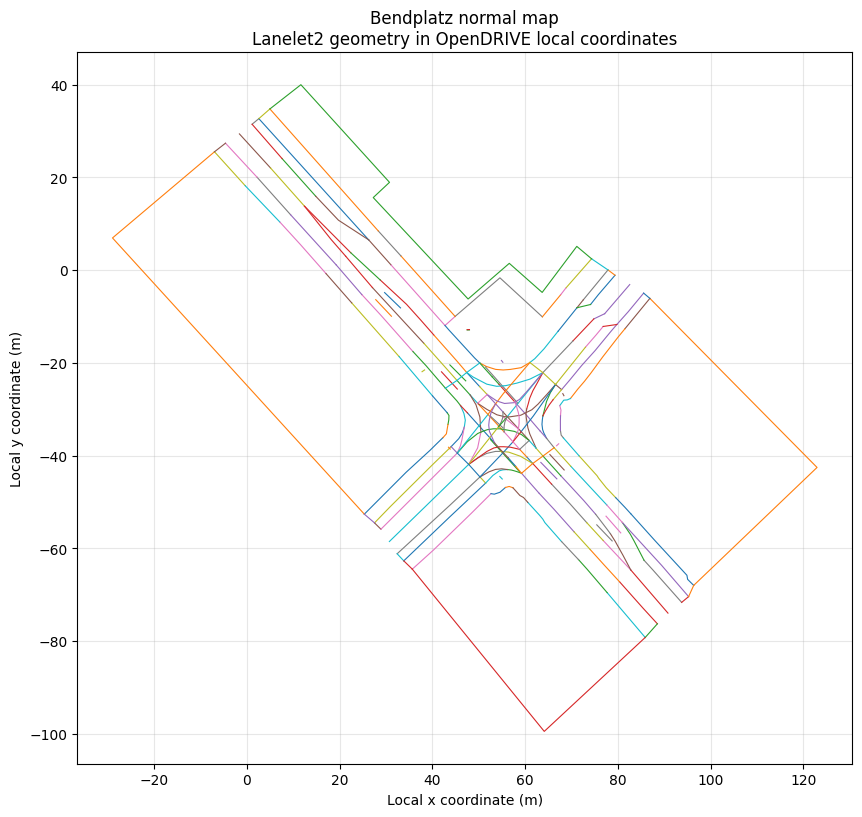

Bendplatz normal map:
  Plotted ways: 204
  Skipped ways: 0


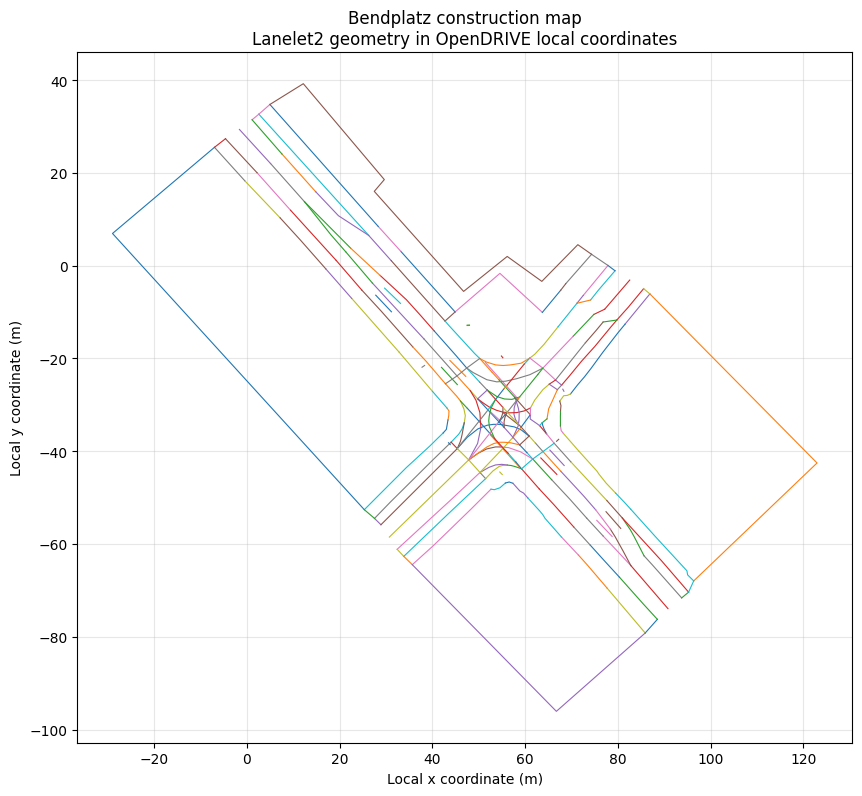

Bendplatz construction map:
  Plotted ways: 216
  Skipped ways: 0

CELL 6 COMPLETED
Lanelet2 latitude/longitude coordinates were projected to UTM Zone 32N and converted into OpenDRIVE local x/y coordinates.

Next step: load one inD recording and overlay its vehicle trajectories on the converted normal map.
Do not derive the intersection centre yet. First confirm that the trajectory coordinates and map coordinates are aligned.


In [ ]:
# Cell 6 — Convert Lanelet2 coordinates to OpenDRIVE local x/y

# Coordinate conversion pipeline:
#
#   Lanelet2 longitude/latitude (WGS84)
#                     ↓
#   UTM Zone 32N easting/northing
#                     ↓
#   subtract OpenDRIVE offset
#                     ↓
#   OpenDRIVE local x/y coordinates in metres
#
# OpenDRIVE metadata found in Cell 5:
#
#   projection:
#       +proj=utm +zone=32 +datum=WGS84 +units=m +no_defs
#
#   offset:
#       x   = 293487.1224
#       y   = 5629711.5816
#       hdg = 0
#
# Because hdg is zero, no coordinate rotation is required.

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. IMPORT PYPROJ
# ============================================================

# pyproj performs the official geographic-coordinate projection.
# It is normally already available in Google Colab. If it is not,
# the installation command below will install it automatically.

try:
    from pyproj import CRS, Transformer
except ImportError:
    print("pyproj is not installed. Installing it now...")

    !pip -q install pyproj

    from pyproj import CRS, Transformer


# ============================================================
# 2. COORDINATE REFERENCE SYSTEMS
# ============================================================

# Lanelet2 nodes are stored using WGS84 longitude and latitude.
WGS84_CRS = CRS.from_epsg(4326)

# OpenDRIVE declares:
#
#   +proj=utm +zone=32 +datum=WGS84 +units=m
#
# EPSG:32632 represents WGS84 / UTM Zone 32N.
UTM_ZONE_32N_CRS = CRS.from_epsg(32632)

# always_xy=True ensures that pyproj expects:
#
#   longitude first
#   latitude second
#
# This avoids accidental latitude/longitude reversal.
WGS84_TO_UTM32_TRANSFORMER = Transformer.from_crs(
    WGS84_CRS,
    UTM_ZONE_32N_CRS,
    always_xy=True,
)

print("Coordinate systems:")
print("  Source:", WGS84_CRS.name)
print("  Target:", UTM_ZONE_32N_CRS.name)


# ============================================================
# 3. READ THE OFFICIAL OPENDRIVE OFFSETS
# ============================================================

def read_numeric_offset(opendrive_inspection):
    """
    Read the first OpenDRIVE offset returned by Cell 5.

    Returns
    -------
    dict
        Numeric x, y, z and heading values.
    """

    offsets = opendrive_inspection.get("offsets", [])

    if len(offsets) == 0:
        raise ValueError(
            "No OpenDRIVE offset was found. "
            "Cell 5 must run successfully before Cell 6."
        )

    raw_offset = offsets[0]

    numeric_offset = {
        "x": float(raw_offset.get("x", 0.0)),
        "y": float(raw_offset.get("y", 0.0)),
        "z": float(raw_offset.get("z", 0.0)),
        "hdg": float(raw_offset.get("hdg", 0.0)),
    }

    return numeric_offset


NORMAL_OPENDRIVE_OFFSET = read_numeric_offset(
    NORMAL_OPENDRIVE_INSPECTION
)

CONSTRUCTION_OPENDRIVE_OFFSET = read_numeric_offset(
    CONSTRUCTION_OPENDRIVE_INSPECTION
)

print("\nNormal-map OpenDRIVE offset:")
print(NORMAL_OPENDRIVE_OFFSET)

print("\nConstruction-map OpenDRIVE offset:")
print(CONSTRUCTION_OPENDRIVE_OFFSET)


# Verify that both maps use the same offset.
offset_fields = ["x", "y", "z", "hdg"]

offset_differences = {
    field: (
        CONSTRUCTION_OPENDRIVE_OFFSET[field]
        - NORMAL_OPENDRIVE_OFFSET[field]
    )
    for field in offset_fields
}

print("\nDifference between construction and normal offsets:")
print(offset_differences)

if any(
    not np.isclose(
        NORMAL_OPENDRIVE_OFFSET[field],
        CONSTRUCTION_OPENDRIVE_OFFSET[field],
        atol=1e-9,
    )
    for field in offset_fields
):
    warnings.warn(
        "The normal and construction maps do not use exactly the same "
        "OpenDRIVE offset."
    )
else:
    print("✓ Both maps use the same OpenDRIVE offset.")


# ============================================================
# 4. CONVERT ONE SET OF LANELET2 NODES
# ============================================================

def convert_lanelet_nodes_to_opendrive(
    lanelet_inspection,
    opendrive_inspection,
):
    """
    Convert Lanelet2 node coordinates into OpenDRIVE local coordinates.

    Conversion
    ----------
    1. Project longitude/latitude into UTM Zone 32N.
    2. Subtract the OpenDRIVE x/y offset.
    3. Apply the offset heading if it is non-zero.

    Parameters
    ----------
    lanelet_inspection : dict
        Output generated by Cell 4.

    opendrive_inspection : dict
        Output generated by Cell 5.

    Returns
    -------
    pandas.DataFrame
        Node table containing geographic, UTM and OpenDRIVE coordinates.
    """

    node_df = lanelet_inspection["node_df"].copy()
    offset = read_numeric_offset(opendrive_inspection)

    required_columns = {
        "node_id",
        "latitude",
        "longitude",
    }

    missing_columns = required_columns.difference(node_df.columns)

    if missing_columns:
        raise ValueError(
            "The Lanelet2 node table is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    valid_coordinate_mask = (
        node_df["latitude"].notna()
        & node_df["longitude"].notna()
    )

    if not valid_coordinate_mask.all():
        missing_count = int((~valid_coordinate_mask).sum())

        warnings.warn(
            f"{missing_count} Lanelet2 nodes do not contain valid "
            "latitude/longitude coordinates."
        )

    valid_nodes = node_df.loc[valid_coordinate_mask].copy()

    # Project WGS84 longitude/latitude into UTM easting/northing.
    utm_easting, utm_northing = (
        WGS84_TO_UTM32_TRANSFORMER.transform(
            valid_nodes["longitude"].to_numpy(),
            valid_nodes["latitude"].to_numpy(),
        )
    )

    valid_nodes["utm_easting"] = np.asarray(
        utm_easting,
        dtype=float,
    )

    valid_nodes["utm_northing"] = np.asarray(
        utm_northing,
        dtype=float,
    )

    # First subtract the OpenDRIVE translation offset.
    translated_x = (
        valid_nodes["utm_easting"].to_numpy()
        - offset["x"]
    )

    translated_y = (
        valid_nodes["utm_northing"].to_numpy()
        - offset["y"]
    )

    # OpenDRIVE offset heading is defined as a rotation.
    #
    # The current maps have hdg = 0, so this produces no change.
    # The general implementation is kept for reproducibility.
    heading = offset["hdg"]

    cos_heading = math.cos(heading)
    sin_heading = math.sin(heading)

    valid_nodes["map_x"] = (
        cos_heading * translated_x
        + sin_heading * translated_y
    )

    valid_nodes["map_y"] = (
        -sin_heading * translated_x
        + cos_heading * translated_y
    )

    return valid_nodes.reset_index(drop=True)


NORMAL_LANELET_NODES_LOCAL = convert_lanelet_nodes_to_opendrive(
    lanelet_inspection=NORMAL_LANELET_INSPECTION,
    opendrive_inspection=NORMAL_OPENDRIVE_INSPECTION,
)

CONSTRUCTION_LANELET_NODES_LOCAL = (
    convert_lanelet_nodes_to_opendrive(
        lanelet_inspection=CONSTRUCTION_LANELET_INSPECTION,
        opendrive_inspection=CONSTRUCTION_OPENDRIVE_INSPECTION,
    )
)


# ============================================================
# 5. VALIDATE CONVERTED BOUNDS
# ============================================================

def validate_converted_bounds(
    converted_nodes,
    opendrive_inspection,
    map_name,
):
    """
    Compare converted Lanelet2 node bounds with OpenDRIVE header bounds.

    The two formats may not contain exactly the same geometric objects.
    Therefore, a perfect zero difference is not required.

    The purpose is to verify that:
    - coordinates are in the same metric scale;
    - coordinates occupy the same local map region;
    - no axis reversal or large projection error occurred.
    """

    header = opendrive_inspection["header_attributes"]

    required_bound_names = [
        "west",
        "east",
        "south",
        "north",
    ]

    missing_bounds = [
        name
        for name in required_bound_names
        if header.get(name) is None
    ]

    if missing_bounds:
        raise ValueError(
            f"OpenDRIVE bounds are missing for {map_name}: "
            f"{missing_bounds}"
        )

    opendrive_bounds = {
        "west": float(header["west"]),
        "east": float(header["east"]),
        "south": float(header["south"]),
        "north": float(header["north"]),
    }

    converted_bounds = {
        "west": float(converted_nodes["map_x"].min()),
        "east": float(converted_nodes["map_x"].max()),
        "south": float(converted_nodes["map_y"].min()),
        "north": float(converted_nodes["map_y"].max()),
    }

    differences = {
        bound: converted_bounds[bound] - opendrive_bounds[bound]
        for bound in required_bound_names
    }

    absolute_differences = {
        bound: abs(differences[bound])
        for bound in required_bound_names
    }

    converted_width = (
        converted_bounds["east"]
        - converted_bounds["west"]
    )

    converted_height = (
        converted_bounds["north"]
        - converted_bounds["south"]
    )

    opendrive_width = (
        opendrive_bounds["east"]
        - opendrive_bounds["west"]
    )

    opendrive_height = (
        opendrive_bounds["north"]
        - opendrive_bounds["south"]
    )

    width_error = converted_width - opendrive_width
    height_error = converted_height - opendrive_height

    result = {
        "map_name": map_name,

        "converted_west": converted_bounds["west"],
        "opendrive_west": opendrive_bounds["west"],
        "west_difference_m": differences["west"],

        "converted_east": converted_bounds["east"],
        "opendrive_east": opendrive_bounds["east"],
        "east_difference_m": differences["east"],

        "converted_south": converted_bounds["south"],
        "opendrive_south": opendrive_bounds["south"],
        "south_difference_m": differences["south"],

        "converted_north": converted_bounds["north"],
        "opendrive_north": opendrive_bounds["north"],
        "north_difference_m": differences["north"],

        "converted_width_m": converted_width,
        "opendrive_width_m": opendrive_width,
        "width_difference_m": width_error,

        "converted_height_m": converted_height,
        "opendrive_height_m": opendrive_height,
        "height_difference_m": height_error,

        "maximum_absolute_bound_difference_m": max(
            absolute_differences.values()
        ),
    }

    print("\n" + "=" * 80)
    print(f"Coordinate validation: {map_name}")
    print("=" * 80)

    print("\nConverted Lanelet2 bounds:")
    print(f"  West:  {converted_bounds['west']:.6f} m")
    print(f"  East:  {converted_bounds['east']:.6f} m")
    print(f"  South: {converted_bounds['south']:.6f} m")
    print(f"  North: {converted_bounds['north']:.6f} m")

    print("\nOpenDRIVE header bounds:")
    print(f"  West:  {opendrive_bounds['west']:.6f} m")
    print(f"  East:  {opendrive_bounds['east']:.6f} m")
    print(f"  South: {opendrive_bounds['south']:.6f} m")
    print(f"  North: {opendrive_bounds['north']:.6f} m")

    print("\nConverted minus OpenDRIVE:")
    print(f"  West difference:  {differences['west']:.6f} m")
    print(f"  East difference:  {differences['east']:.6f} m")
    print(f"  South difference: {differences['south']:.6f} m")
    print(f"  North difference: {differences['north']:.6f} m")

    print("\nMap dimensions:")
    print(
        f"  Converted width:  {converted_width:.6f} m"
    )
    print(
        f"  OpenDRIVE width:  {opendrive_width:.6f} m"
    )
    print(
        f"  Width difference: {width_error:.6f} m"
    )

    print(
        f"  Converted height:  {converted_height:.6f} m"
    )
    print(
        f"  OpenDRIVE height:  {opendrive_height:.6f} m"
    )
    print(
        f"  Height difference: {height_error:.6f} m"
    )

    max_difference = result[
        "maximum_absolute_bound_difference_m"
    ]

    print("\nValidation interpretation:")

    # This threshold is only an initial diagnostic.
    # It is not used as a scientific model parameter.
    if max_difference <= 1.0:
        print(
            "  ✓ The converted Lanelet2 bounds closely match the "
            "OpenDRIVE bounds."
        )
        print(
            "  The projection, offset and axis directions appear correct."
        )
    elif max_difference <= 5.0:
        print(
            "  ✓ The coordinate systems appear broadly aligned."
        )
        print(
            "  Small differences may occur because the Lanelet2 and "
            "OpenDRIVE maps contain different boundary objects."
        )
    else:
        print(
            "  ⚠ The converted bounds differ noticeably from the "
            "OpenDRIVE header bounds."
        )
        print(
            "  Do not assume the conversion is correct until the map "
            "plot and trajectory overlay are inspected."
        )

    return result


NORMAL_COORDINATE_VALIDATION = validate_converted_bounds(
    converted_nodes=NORMAL_LANELET_NODES_LOCAL,
    opendrive_inspection=NORMAL_OPENDRIVE_INSPECTION,
    map_name="Bendplatz normal",
)

CONSTRUCTION_COORDINATE_VALIDATION = validate_converted_bounds(
    converted_nodes=CONSTRUCTION_LANELET_NODES_LOCAL,
    opendrive_inspection=CONSTRUCTION_OPENDRIVE_INSPECTION,
    map_name="Bendplatz construction",
)


COORDINATE_VALIDATION_RESULTS = pd.DataFrame([
    NORMAL_COORDINATE_VALIDATION,
    CONSTRUCTION_COORDINATE_VALIDATION,
])

print("\n" + "=" * 80)
print("COORDINATE-CONVERSION VALIDATION SUMMARY")
print("=" * 80)

display(COORDINATE_VALIDATION_RESULTS)


# ============================================================
# 6. CREATE NODE-ID LOOKUP TABLES
# ============================================================

# These dictionaries will be used in later cells to reconstruct each
# Lanelet2 way from its referenced node IDs.

NORMAL_LOCAL_NODE_LOOKUP = (
    NORMAL_LANELET_NODES_LOCAL
    .set_index("node_id")[["map_x", "map_y"]]
    .to_dict("index")
)

CONSTRUCTION_LOCAL_NODE_LOOKUP = (
    CONSTRUCTION_LANELET_NODES_LOCAL
    .set_index("node_id")[["map_x", "map_y"]]
    .to_dict("index")
)

LANELET_LOCAL_NODE_TABLES = {
    "normal": NORMAL_LANELET_NODES_LOCAL,
    "construction": CONSTRUCTION_LANELET_NODES_LOCAL,
}

LANELET_LOCAL_NODE_LOOKUPS = {
    "normal": NORMAL_LOCAL_NODE_LOOKUP,
    "construction": CONSTRUCTION_LOCAL_NODE_LOOKUP,
}


# ============================================================
# 7. PLOT COMPLETE LANELET2 WAY GEOMETRY
# ============================================================

def plot_lanelet2_ways(
    lanelet_inspection,
    local_node_lookup,
    map_name,
):
    """
    Plot all Lanelet2 ways using converted OpenDRIVE local coordinates.

    This plot is a visual diagnostic. It checks whether the converted map:
    - has the expected road/intersection shape;
    - uses sensible x/y orientation;
    - contains no large coordinate jumps.
    """

    figure, axis = plt.subplots(figsize=(10, 10))

    plotted_way_count = 0
    skipped_way_count = 0

    for way in lanelet_inspection["ways"]:

        way_node_ids = [
            int(node_reference.attrib["ref"])
            for node_reference in way.findall("nd")
        ]

        coordinates = [
            local_node_lookup[node_id]
            for node_id in way_node_ids
            if node_id in local_node_lookup
        ]

        if len(coordinates) < 2:
            skipped_way_count += 1
            continue

        x_values = [
            coordinate["map_x"]
            for coordinate in coordinates
        ]

        y_values = [
            coordinate["map_y"]
            for coordinate in coordinates
        ]

        axis.plot(
            x_values,
            y_values,
            linewidth=0.8,
        )

        plotted_way_count += 1

    axis.set_title(
        f"{map_name}\n"
        "Lanelet2 geometry in OpenDRIVE local coordinates"
    )

    axis.set_xlabel("Local x coordinate (m)")
    axis.set_ylabel("Local y coordinate (m)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.3)

    plt.show()

    print(f"{map_name}:")
    print(f"  Plotted ways: {plotted_way_count}")
    print(f"  Skipped ways: {skipped_way_count}")


plot_lanelet2_ways(
    lanelet_inspection=NORMAL_LANELET_INSPECTION,
    local_node_lookup=NORMAL_LOCAL_NODE_LOOKUP,
    map_name="Bendplatz normal map",
)

plot_lanelet2_ways(
    lanelet_inspection=CONSTRUCTION_LANELET_INSPECTION,
    local_node_lookup=CONSTRUCTION_LOCAL_NODE_LOOKUP,
    map_name="Bendplatz construction map",
)


# ============================================================
# 8. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 6 COMPLETED")
print("=" * 80)

print(
    "Lanelet2 latitude/longitude coordinates were projected to "
    "UTM Zone 32N and converted into OpenDRIVE local x/y coordinates."
)

print(
    "\nNext step: load one inD recording and overlay its vehicle "
    "trajectories on the converted normal map."
)

print(
    "Do not derive the intersection centre yet. First confirm that "
    "the trajectory coordinates and map coordinates are aligned."
)

Selected recording: 07
Expected map variant: normal

Recording files:
  Tracks:
    /content/drive/MyDrive/inD-dataset-v1.1/data/07_tracks.csv
  Tracks metadata:
    /content/drive/MyDrive/inD-dataset-v1.1/data/07_tracksMeta.csv
  Recording metadata:
    /content/drive/MyDrive/inD-dataset-v1.1/data/07_recordingMeta.csv

Loaded table sizes:
  tracks.csv:        (201296, 17)
  tracksMeta.csv:    (212, 8)
  recordingMeta.csv: (1, 15)

tracks.csv columns:
['recordingId', 'trackId', 'frame', 'trackLifetime', 'xCenter', 'yCenter', 'heading', 'width', 'length', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration', 'lonVelocity', 'latVelocity', 'lonAcceleration', 'latAcceleration']

tracksMeta.csv columns:
['recordingId', 'trackId', 'initialFrame', 'finalFrame', 'numFrames', 'width', 'length', 'class']

Detected trajectory columns:
  Track ID: trackId
  Frame:    frame
  x:        xCenter
  y:        yCenter

Detected class column: class
Available classes:
['bicycle', 'car', 'pedestrian'

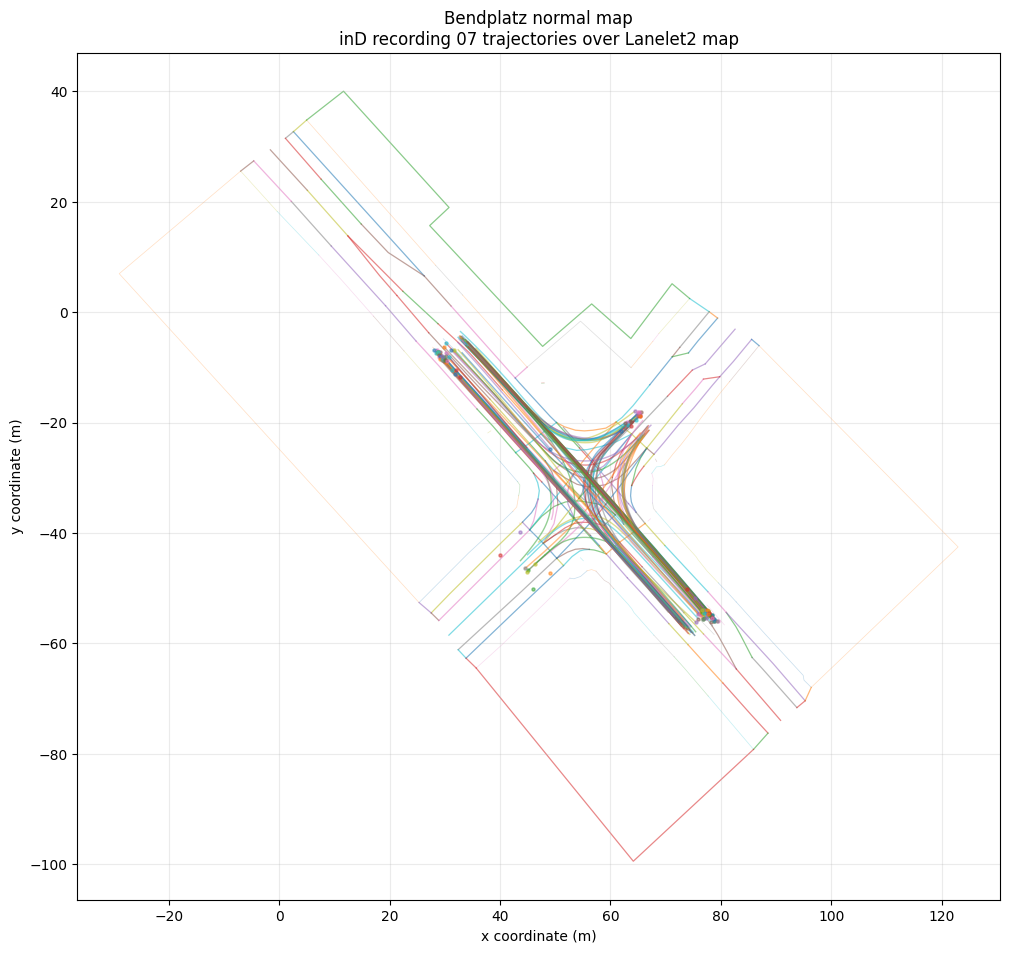


Overlay plot summary:
  Map ways plotted: 204
  Vehicle trajectories plotted: 120

MAP AND TRAJECTORY COORDINATE-BOUND COMPARISON


,source,minimum_x,maximum_x,minimum_y,maximum_y,width_m,height_m
0,converted Lanelet2 nodes,-28.960605,122.954043,-99.442077,39.995859,151.914647,139.437936
1,recording 07 trajectories,28.095830,79.428630,-58.569520,-3.523690,51.332800,55.045830



CELL 7 COMPLETED
Inspect the overlay visually before applying any coordinate transformation.

Correct alignment means that vehicle trajectories follow the road lanes and pass through the mapped intersection.

Possible outcomes:
  1. Trajectories follow the lanes correctly:
     The map and recording already share the same coordinate system.

  2. The shapes match but the trajectories are shifted:
     A translation difference remains.

  3. The shapes match but the trajectories are rotated or mirrored:
     Axis orientation or rotation must be resolved.

  4. The trajectories do not resemble the map geometry:
     Recheck the selected recording, map variant, columns and coordinate definitions.

Do not calculate the intersection centre yet. First review and validate this overlay.


In [ ]:
# Cell 7 — Overlay inD recording 07 trajectories on the converted Lanelet2 map

# Purpose
# -------
# Cell 6 converted the Lanelet2 map into local metric coordinates.
#
# This cell tests whether the inD trajectory coordinates use the same
# coordinate system by overlaying recording 07 trajectories on the map.
#
# We are NOT estimating or changing the coordinates in this cell.
# The goal is first to inspect the original alignment objectively.

from pathlib import Path
import xml.etree.ElementTree as ET
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. SELECT THE RECORDING
# ============================================================

OVERLAY_RECORDING_ID = 7
OVERLAY_RECORDING_KEY = f"{OVERLAY_RECORDING_ID:02d}"

# Recording 07 belongs to the normal Bendplatz map.
OVERLAY_MAP_VARIANT = "normal"

print(f"Selected recording: {OVERLAY_RECORDING_KEY}")
print(f"Expected map variant: {OVERLAY_MAP_VARIANT}")


# ============================================================
# 2. LOCATE THE RECORDING FILES
# ============================================================

def find_unique_file(search_root, filename):
    """
    Recursively find a file below search_root.

    The function raises an error if no match is found and warns if
    multiple matches are found.
    """
    search_root = Path(search_root)

    if not search_root.exists():
        raise FileNotFoundError(
            f"Search directory does not exist:\n{search_root}"
        )

    matches = sorted(search_root.rglob(filename))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find '{filename}' below:\n{search_root}"
        )

    if len(matches) > 1:
        warnings.warn(
            f"Multiple files named '{filename}' were found. "
            f"The first match will be used:\n{matches[0]}"
        )

    return matches[0]


# Use the dataset root already defined earlier when available.
if "DATASET_ROOT" in globals():
    IND_DATASET_ROOT = Path(DATASET_ROOT)
else:
    IND_DATASET_ROOT = Path(
        "/content/drive/MyDrive/inD-dataset-v1.1"
    )

TRACKS_FILENAME = f"{OVERLAY_RECORDING_KEY}_tracks.csv"
TRACKS_META_FILENAME = f"{OVERLAY_RECORDING_KEY}_tracksMeta.csv"
RECORDING_META_FILENAME = (
    f"{OVERLAY_RECORDING_KEY}_recordingMeta.csv"
)

TRACKS_PATH = find_unique_file(
    IND_DATASET_ROOT,
    TRACKS_FILENAME,
)

TRACKS_META_PATH = find_unique_file(
    IND_DATASET_ROOT,
    TRACKS_META_FILENAME,
)

RECORDING_META_PATH = find_unique_file(
    IND_DATASET_ROOT,
    RECORDING_META_FILENAME,
)

print("\nRecording files:")
print("  Tracks:")
print("   ", TRACKS_PATH)
print("  Tracks metadata:")
print("   ", TRACKS_META_PATH)
print("  Recording metadata:")
print("   ", RECORDING_META_PATH)


# ============================================================
# 3. LOAD THE RECORDING TABLES
# ============================================================

tracks_df = pd.read_csv(TRACKS_PATH)
tracks_meta_df = pd.read_csv(TRACKS_META_PATH)
recording_meta_df = pd.read_csv(RECORDING_META_PATH)

print("\nLoaded table sizes:")
print(f"  tracks.csv:        {tracks_df.shape}")
print(f"  tracksMeta.csv:    {tracks_meta_df.shape}")
print(f"  recordingMeta.csv: {recording_meta_df.shape}")

print("\ntracks.csv columns:")
print(list(tracks_df.columns))

print("\ntracksMeta.csv columns:")
print(list(tracks_meta_df.columns))


# ============================================================
# 4. DETECT IMPORTANT COLUMN NAMES
# ============================================================

def find_first_existing_column(dataframe, candidates, purpose):
    """
    Return the first candidate column found in dataframe.
    """
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    raise ValueError(
        f"Could not detect the {purpose} column.\n"
        f"Tried: {candidates}\n"
        f"Available columns: {list(dataframe.columns)}"
    )


TRACK_ID_COLUMN = find_first_existing_column(
    tracks_df,
    candidates=[
        "trackId",
        "track_id",
        "id",
    ],
    purpose="track ID",
)

FRAME_COLUMN = find_first_existing_column(
    tracks_df,
    candidates=[
        "frame",
        "frameId",
        "frame_id",
    ],
    purpose="frame",
)

X_COLUMN = find_first_existing_column(
    tracks_df,
    candidates=[
        "xCenter",
        "x_center",
        "x",
    ],
    purpose="x-coordinate",
)

Y_COLUMN = find_first_existing_column(
    tracks_df,
    candidates=[
        "yCenter",
        "y_center",
        "y",
    ],
    purpose="y-coordinate",
)

print("\nDetected trajectory columns:")
print(f"  Track ID: {TRACK_ID_COLUMN}")
print(f"  Frame:    {FRAME_COLUMN}")
print(f"  x:        {X_COLUMN}")
print(f"  y:        {Y_COLUMN}")


# ============================================================
# 5. DETECT AND ATTACH OBJECT CLASS
# ============================================================

META_TRACK_ID_COLUMN = find_first_existing_column(
    tracks_meta_df,
    candidates=[
        "trackId",
        "track_id",
        "id",
    ],
    purpose="metadata track ID",
)

CLASS_COLUMN = None

for candidate in [
    "class",
    "objectClass",
    "object_class",
    "agentType",
    "type",
]:
    if candidate in tracks_meta_df.columns:
        CLASS_COLUMN = candidate
        break

if CLASS_COLUMN is not None:
    class_table = tracks_meta_df[
        [META_TRACK_ID_COLUMN, CLASS_COLUMN]
    ].copy()

    # Standardize the metadata ID column before merging.
    class_table = class_table.rename(
        columns={META_TRACK_ID_COLUMN: TRACK_ID_COLUMN}
    )

    tracks_with_class_df = tracks_df.merge(
        class_table,
        on=TRACK_ID_COLUMN,
        how="left",
        validate="many_to_one",
    )

    available_classes = sorted(
        tracks_with_class_df[CLASS_COLUMN]
        .dropna()
        .astype(str)
        .unique()
    )

    print(f"\nDetected class column: {CLASS_COLUMN}")
    print("Available classes:")
    print(available_classes)

else:
    tracks_with_class_df = tracks_df.copy()

    warnings.warn(
        "No object-class column was detected in tracksMeta.csv. "
        "All recorded tracks will be considered for the overlay."
    )


# ============================================================
# 6. FILTER TO ROAD VEHICLES
# ============================================================

# The research objective concerns vehicle manoeuvres.
# Pedestrian and bicycle trajectories can make the alignment plot crowded.
#
# This list is only a visualization filter. It does not modify the dataset.

ROAD_VEHICLE_CLASS_NAMES = {
    "car",
    "truck_bus",
    "truck",
    "bus",
    "van",
    "motorcycle",
    "motorbike",
    "vehicle",
    "trailer",
    "emergency_vehicle",
}

if CLASS_COLUMN is not None:
    normalized_classes = (
        tracks_with_class_df[CLASS_COLUMN]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    road_vehicle_mask = normalized_classes.isin(
        ROAD_VEHICLE_CLASS_NAMES
    )

    road_vehicle_tracks_df = tracks_with_class_df.loc[
        road_vehicle_mask
    ].copy()

    if road_vehicle_tracks_df.empty:
        warnings.warn(
            "No tracks matched the predefined road-vehicle classes. "
            "All tracks will be used instead."
        )

        road_vehicle_tracks_df = tracks_with_class_df.copy()

else:
    road_vehicle_tracks_df = tracks_with_class_df.copy()


print("\nTrajectory selection:")
print(
    "  Total unique tracks:",
    tracks_with_class_df[TRACK_ID_COLUMN].nunique(),
)
print(
    "  Selected unique road-vehicle tracks:",
    road_vehicle_tracks_df[TRACK_ID_COLUMN].nunique(),
)
print(
    "  Selected trajectory rows:",
    len(road_vehicle_tracks_df),
)


# ============================================================
# 7. CLEAN AND SORT TRAJECTORY COORDINATES
# ============================================================

trajectory_df = road_vehicle_tracks_df.copy()

trajectory_df[X_COLUMN] = pd.to_numeric(
    trajectory_df[X_COLUMN],
    errors="coerce",
)

trajectory_df[Y_COLUMN] = pd.to_numeric(
    trajectory_df[Y_COLUMN],
    errors="coerce",
)

trajectory_df[FRAME_COLUMN] = pd.to_numeric(
    trajectory_df[FRAME_COLUMN],
    errors="coerce",
)

trajectory_df = trajectory_df.dropna(
    subset=[
        TRACK_ID_COLUMN,
        FRAME_COLUMN,
        X_COLUMN,
        Y_COLUMN,
    ]
)

trajectory_df = trajectory_df.sort_values(
    [TRACK_ID_COLUMN, FRAME_COLUMN]
).reset_index(drop=True)

print("\nTrajectory coordinate bounds:")
print(
    f"  x: {trajectory_df[X_COLUMN].min():.3f} "
    f"to {trajectory_df[X_COLUMN].max():.3f} m"
)
print(
    f"  y: {trajectory_df[Y_COLUMN].min():.3f} "
    f"to {trajectory_df[Y_COLUMN].max():.3f} m"
)


# ============================================================
# 8. SELECT TRAJECTORIES FOR A READABLE PLOT
# ============================================================

# Plotting every trajectory may create a very dark figure.
# We select evenly spaced IDs only for visualization.
#
# The complete data remain stored in trajectory_df.

MAX_TRAJECTORIES_TO_PLOT = 120

all_track_ids = np.asarray(
    sorted(trajectory_df[TRACK_ID_COLUMN].unique())
)

if len(all_track_ids) > MAX_TRAJECTORIES_TO_PLOT:
    selected_indices = np.linspace(
        0,
        len(all_track_ids) - 1,
        MAX_TRAJECTORIES_TO_PLOT,
        dtype=int,
    )

    selected_track_ids = all_track_ids[selected_indices]

else:
    selected_track_ids = all_track_ids

plot_trajectory_df = trajectory_df[
    trajectory_df[TRACK_ID_COLUMN].isin(selected_track_ids)
].copy()

print(
    "\nNumber of trajectories selected for plotting:",
    len(selected_track_ids),
)


# ============================================================
# 9. HELPER: ACCESS THE NORMAL MAP GEOMETRY
# ============================================================

if "NORMAL_LANELET_INSPECTION" not in globals():
    raise NameError(
        "NORMAL_LANELET_INSPECTION is not available. "
        "Run the Lanelet2 inspection cell first."
    )

if "NORMAL_LOCAL_NODE_LOOKUP" not in globals():
    raise NameError(
        "NORMAL_LOCAL_NODE_LOOKUP is not available. "
        "Run Cell 6 first."
    )


def get_way_node_references(way):
    """
    Read all node-reference IDs from a Lanelet2 way.

    Namespace-independent implementation.
    """
    node_ids = []

    for child in list(way):
        local_tag = child.tag.split("}", 1)[-1]

        if local_tag != "nd":
            continue

        reference = child.attrib.get("ref")

        if reference is not None:
            node_ids.append(int(reference))

    return node_ids


def extract_osm_element_tags(element):
    """
    Read all OSM <tag k='...' v='...'> entries.
    """
    tags = {}

    for child in list(element):
        local_tag = child.tag.split("}", 1)[-1]

        if local_tag != "tag":
            continue

        key = child.attrib.get("k")
        value = child.attrib.get("v")

        if key is not None:
            tags[key] = value

    return tags


# ============================================================
# 10. PLOT MAP AND TRAJECTORIES TOGETHER
# ============================================================

def plot_map_trajectory_overlay(
    lanelet_inspection,
    local_node_lookup,
    trajectory_data,
    map_name,
    recording_id,
):
    """
    Overlay inD vehicle trajectories on converted Lanelet2 geometry.
    """

    figure, axis = plt.subplots(figsize=(12, 11))

    map_way_count = 0

    # --------------------------------------------------------
    # Draw Lanelet2 geometry
    # --------------------------------------------------------

    for way in lanelet_inspection["ways"]:
        node_ids = get_way_node_references(way)

        coordinates = [
            local_node_lookup[node_id]
            for node_id in node_ids
            if node_id in local_node_lookup
        ]

        if len(coordinates) < 2:
            continue

        x_values = [
            coordinate["map_x"]
            for coordinate in coordinates
        ]

        y_values = [
            coordinate["map_y"]
            for coordinate in coordinates
        ]

        tags = extract_osm_element_tags(way)
        way_type = tags.get("type", "")
        way_subtype = tags.get("subtype", "")

        # Use stronger lines for physical road boundaries and
        # lighter lines for auxiliary map elements.
        is_road_boundary = way_type in {
            "curbstone",
            "line_thin",
            "line_thick",
            "virtual",
        }

        if is_road_boundary:
            axis.plot(
                x_values,
                y_values,
                linewidth=0.9,
                alpha=0.55,
                zorder=1,
            )
        else:
            axis.plot(
                x_values,
                y_values,
                linewidth=0.5,
                alpha=0.25,
                zorder=1,
            )

        map_way_count += 1

    # --------------------------------------------------------
    # Draw trajectories
    # --------------------------------------------------------

    trajectory_count = 0

    for track_id, track_group in trajectory_data.groupby(
        TRACK_ID_COLUMN,
        sort=False,
    ):
        track_group = track_group.sort_values(FRAME_COLUMN)

        if len(track_group) < 2:
            continue

        axis.plot(
            track_group[X_COLUMN],
            track_group[Y_COLUMN],
            linewidth=1.0,
            alpha=0.5,
            zorder=3,
        )

        # Mark the first point of each trajectory.
        axis.scatter(
            track_group[X_COLUMN].iloc[0],
            track_group[Y_COLUMN].iloc[0],
            s=5,
            alpha=0.5,
            zorder=4,
        )

        trajectory_count += 1

    axis.set_title(
        f"{map_name}\n"
        f"inD recording {recording_id} trajectories over Lanelet2 map"
    )

    axis.set_xlabel("x coordinate (m)")
    axis.set_ylabel("y coordinate (m)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.25)

    # Use the combined map and trajectory bounds.
    map_x_values = np.asarray([
        coordinate["map_x"]
        for coordinate in local_node_lookup.values()
    ])

    map_y_values = np.asarray([
        coordinate["map_y"]
        for coordinate in local_node_lookup.values()
    ])

    combined_x_min = min(
        float(map_x_values.min()),
        float(trajectory_data[X_COLUMN].min()),
    )

    combined_x_max = max(
        float(map_x_values.max()),
        float(trajectory_data[X_COLUMN].max()),
    )

    combined_y_min = min(
        float(map_y_values.min()),
        float(trajectory_data[Y_COLUMN].min()),
    )

    combined_y_max = max(
        float(map_y_values.max()),
        float(trajectory_data[Y_COLUMN].max()),
    )

    x_margin = max(
        5.0,
        0.05 * (combined_x_max - combined_x_min),
    )

    y_margin = max(
        5.0,
        0.05 * (combined_y_max - combined_y_min),
    )

    axis.set_xlim(
        combined_x_min - x_margin,
        combined_x_max + x_margin,
    )

    axis.set_ylim(
        combined_y_min - y_margin,
        combined_y_max + y_margin,
    )

    plt.show()

    print("\nOverlay plot summary:")
    print(f"  Map ways plotted: {map_way_count}")
    print(f"  Vehicle trajectories plotted: {trajectory_count}")


plot_map_trajectory_overlay(
    lanelet_inspection=NORMAL_LANELET_INSPECTION,
    local_node_lookup=NORMAL_LOCAL_NODE_LOOKUP,
    trajectory_data=plot_trajectory_df,
    map_name="Bendplatz normal map",
    recording_id=OVERLAY_RECORDING_KEY,
)


# ============================================================
# 11. NUMERICAL BOUND COMPARISON
# ============================================================

normal_map_x = np.asarray([
    coordinate["map_x"]
    for coordinate in NORMAL_LOCAL_NODE_LOOKUP.values()
])

normal_map_y = np.asarray([
    coordinate["map_y"]
    for coordinate in NORMAL_LOCAL_NODE_LOOKUP.values()
])

MAP_TRAJECTORY_BOUND_COMPARISON = pd.DataFrame([
    {
        "source": "converted Lanelet2 nodes",
        "minimum_x": float(normal_map_x.min()),
        "maximum_x": float(normal_map_x.max()),
        "minimum_y": float(normal_map_y.min()),
        "maximum_y": float(normal_map_y.max()),
        "width_m": float(
            normal_map_x.max() - normal_map_x.min()
        ),
        "height_m": float(
            normal_map_y.max() - normal_map_y.min()
        ),
    },
    {
        "source": f"recording {OVERLAY_RECORDING_KEY} trajectories",
        "minimum_x": float(trajectory_df[X_COLUMN].min()),
        "maximum_x": float(trajectory_df[X_COLUMN].max()),
        "minimum_y": float(trajectory_df[Y_COLUMN].min()),
        "maximum_y": float(trajectory_df[Y_COLUMN].max()),
        "width_m": float(
            trajectory_df[X_COLUMN].max()
            - trajectory_df[X_COLUMN].min()
        ),
        "height_m": float(
            trajectory_df[Y_COLUMN].max()
            - trajectory_df[Y_COLUMN].min()
        ),
    },
])

print("\n" + "=" * 80)
print("MAP AND TRAJECTORY COORDINATE-BOUND COMPARISON")
print("=" * 80)

display(MAP_TRAJECTORY_BOUND_COMPARISON)


# ============================================================
# 12. STORE OUTPUTS FOR LATER CELLS
# ============================================================

RECORDING_07_TRACKS = tracks_df
RECORDING_07_TRACKS_META = tracks_meta_df
RECORDING_07_META = recording_meta_df

RECORDING_07_VEHICLE_TRAJECTORIES = trajectory_df
RECORDING_07_OVERLAY_TRAJECTORIES = plot_trajectory_df

RECORDING_07_COLUMN_CONFIG = {
    "track_id": TRACK_ID_COLUMN,
    "frame": FRAME_COLUMN,
    "x": X_COLUMN,
    "y": Y_COLUMN,
    "class": CLASS_COLUMN,
}


# ============================================================
# 13. FINAL INTERPRETATION INSTRUCTIONS
# ============================================================

print("\n" + "=" * 80)
print("CELL 7 COMPLETED")
print("=" * 80)

print(
    "Inspect the overlay visually before applying any coordinate "
    "transformation."
)

print(
    "\nCorrect alignment means that vehicle trajectories follow the "
    "road lanes and pass through the mapped intersection."
)

print(
    "\nPossible outcomes:"
)

print(
    "  1. Trajectories follow the lanes correctly:\n"
    "     The map and recording already share the same coordinate system."
)

print(
    "\n  2. The shapes match but the trajectories are shifted:\n"
    "     A translation difference remains."
)

print(
    "\n  3. The shapes match but the trajectories are rotated or mirrored:\n"
    "     Axis orientation or rotation must be resolved."
)

print(
    "\n  4. The trajectories do not resemble the map geometry:\n"
    "     Recheck the selected recording, map variant, columns and "
    "coordinate definitions."
)

print(
    "\nDo not calculate the intersection centre yet. "
    "First review and validate this overlay."
)

Way lookup tables created:
  Normal ways:       204
  Construction ways: 216

ROAD-LANELET RECONSTRUCTION SUMMARY

Normal map:
  Reconstructed lanelets: 73
  Rejected lanelets: 0

Construction map:
  Reconstructed lanelets: 78
  Rejected lanelets: 0


,map_variant,reconstructed_lanelets,rejected_lanelets,mean_length_m,median_length_m,mean_width_m,minimum_observed_width_m,maximum_observed_width_m
0,normal,73,0,8.528757,8.364147,3.239581,0.0,4.755314
1,construction,78,0,7.728548,6.582272,3.250569,0.0,4.755314



Normal lanelet summary — first 10 rows:


,map_variant,lanelet_id,subtype,location,one_way,speed_limit,left_way_id,right_way_id,right_boundary_reversed,number_of_centerline_points,...,mean_width_m,minimum_width_m,maximum_width_m,heading_degrees,polygon_area_m2,number_of_regulatory_elements,start_x,start_y,end_x,end_y
0,normal,1715,road,urban,yes,50 km/h,1677,1888,True,26,...,3.407110,3.127803,3.643030,-136.477025,81.636679,1,49.055839,-43.222779,31.575351,-59.824470
1,normal,1722,road,urban,yes,50 km/h,1489,1479,False,20,...,3.661491,3.542455,3.753614,-48.740583,44.668505,0,84.220614,-63.588698,92.285239,-72.781592
2,normal,1723,road,urban,yes,50 km/h,1489,1518,False,20,...,3.400055,3.246042,3.515078,-48.635903,41.518336,0,81.574772,-65.903101,89.665829,-75.092206
3,normal,1725,road,urban,yes,50 km/h,1477,1491,False,20,...,1.127841,0.000000,2.141119,126.135459,9.859409,0,82.790925,-64.634276,77.619862,-57.552190
4,normal,1726,road,urban,yes,50 km/h,1491,1488,True,20,...,3.595388,3.533495,3.664154,119.616723,32.591134,0,84.220614,-63.588698,79.680189,-55.601533
5,normal,1731,road,urban,yes,50 km/h,1524,1536,False,20,...,3.566753,3.525371,3.608215,-47.367103,35.203695,0,-3.097016,28.384602,3.664105,21.040407
6,normal,1732,road,urban,yes,50 km/h,1524,1884,False,20,...,3.322302,3.206835,3.438442,-48.229419,32.791201,0,-0.228959,30.428011,6.358223,23.053031
7,normal,1739,road,urban,yes,50 km/h,2060,2061,False,20,...,1.832201,1.325484,2.345644,-46.204620,15.990364,0,21.866117,3.391559,27.919522,-2.921892
8,normal,1749,road,urban,yes,50 km/h,1550,1525,False,20,...,2.807179,2.737671,2.952945,-47.690381,45.745959,0,25.938177,-4.497247,37.008654,-16.659440
9,normal,1750,road,urban,yes,50 km/h,1474,1550,False,20,...,2.769319,2.345644,2.952749,-46.517086,45.973762,0,27.919522,-2.921892,39.309261,-14.931344


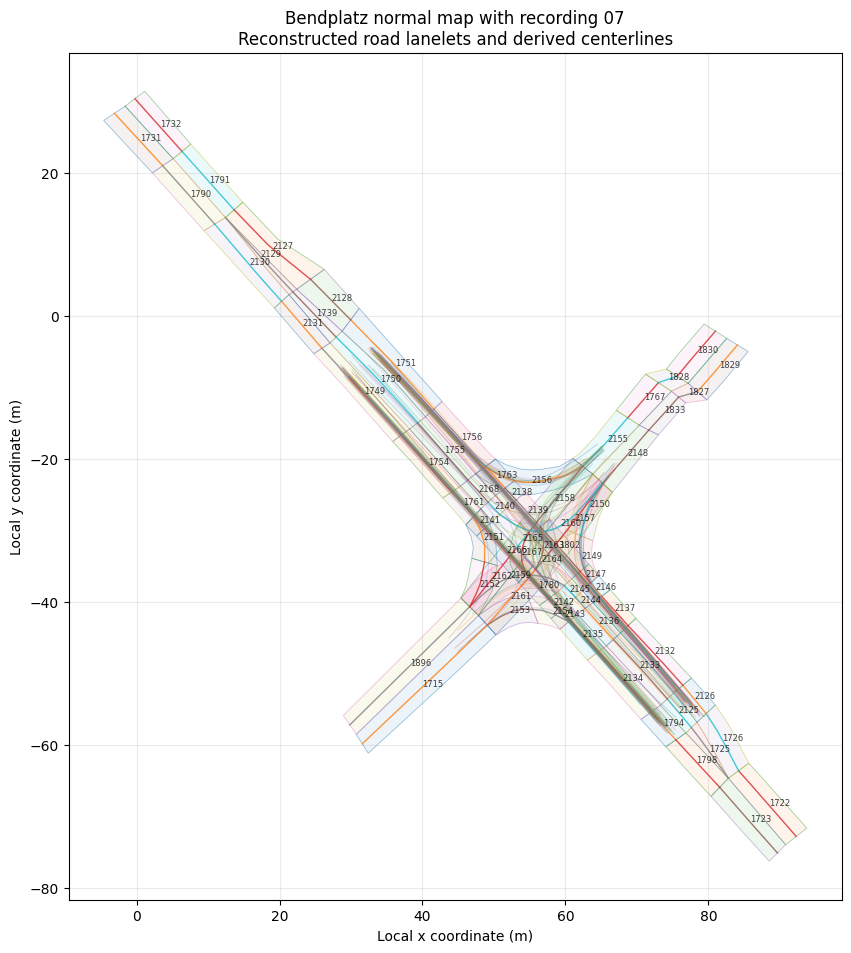


Bendplatz normal map with recording 07:
  Lanelets plotted: 73
  Vehicle trajectories plotted: 120


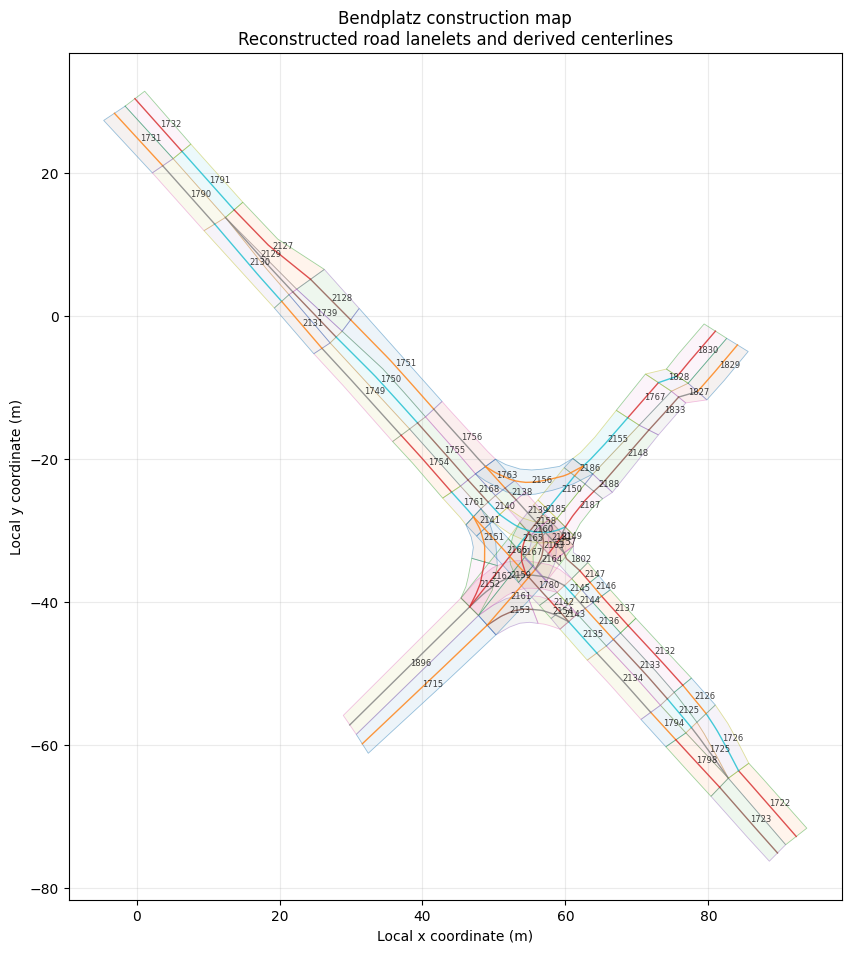


Bendplatz construction map:
  Lanelets plotted: 78

GEOMETRIC QUALITY CHECKS
Normal-map suspicious lanelets: 0
Construction-map suspicious lanelets: 0

CELL 8 COMPLETED
Road lanelets were reconstructed from their official left and right Lanelet2 boundaries.
Each lanelet now has a polygon, resampled boundaries, a geometric centerline, length, width and overall heading.

Inspect the normal-map plot carefully:
  ✓ Vehicle trajectories should remain inside or close to the reconstructed road lanelets.
  ✓ Derived centerlines should follow the middle of the drivable corridors.
  ⚠ A trajectory is not expected to follow a centerline perfectly because real drivers have lateral variation.

Do not classify incoming, outgoing or intersection lanelets yet if the reconstructed polygons or centerlines look incorrect.

After validation, the next cell should derive lanelet connectivity from shared boundary endpoints and relation geometry.


In [ ]:
# Cell 8 — Reconstruct Lanelet2 road lanelets and derive centerlines

# Purpose
# -------
# The previous map plots included every Lanelet2 way, including:
#
#   - walls
#   - fences
#   - traffic signs
#   - arrows
#   - curbstones
#   - auxiliary polygons
#
# For manoeuvre analysis, we need the actual drivable lanelets.
#
# A Lanelet2 road lanelet is normally represented by:
#
#   relation
#     ├── member role="left"  -> left boundary way
#     └── member role="right" -> right boundary way
#
# This cell:
#
#   1. reconstructs each road lanelet;
#   2. aligns the directions of its two boundaries;
#   3. resamples the boundaries by arc length;
#   4. derives a midpoint centerline;
#   5. constructs a lanelet polygon;
#   6. calculates lanelet length, width and direction;
#   7. plots polygons and centerlines;
#   8. overlays recording 07 vehicle trajectories.
#
# Important:
# The derived centerline is a geometric midpoint centerline. It is not
# assumed to be an official driving path until the trajectory overlay
# has been inspected.

import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CHECK REQUIRED OUTPUTS FROM PREVIOUS CELLS
# ============================================================

required_variables = [
    "NORMAL_LANELET_INSPECTION",
    "CONSTRUCTION_LANELET_INSPECTION",
    "NORMAL_LOCAL_NODE_LOOKUP",
    "CONSTRUCTION_LOCAL_NODE_LOOKUP",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the earlier map-inspection and coordinate-conversion "
        "cells first. Missing variables:\n"
        f"{missing_variables}"
    )


# ============================================================
# 2. XML HELPER FUNCTIONS
# ============================================================

def local_xml_tag(element):
    """
    Return an XML tag name without its namespace.
    """
    return element.tag.split("}", 1)[-1]


def get_osm_tags(element):
    """
    Extract OSM tags from an XML node, way or relation.
    """
    tags = {}

    for child in list(element):
        if local_xml_tag(child) != "tag":
            continue

        key = child.attrib.get("k")
        value = child.attrib.get("v")

        if key is not None:
            tags[key] = value

    return tags


def get_way_node_ids(way):
    """
    Extract ordered node-reference IDs from one OSM way.
    """
    node_ids = []

    for child in list(way):
        if local_xml_tag(child) != "nd":
            continue

        reference = child.attrib.get("ref")

        if reference is not None:
            node_ids.append(int(reference))

    return node_ids


def get_relation_members(relation):
    """
    Extract all members from one OSM relation.
    """
    members = []

    for child in list(relation):
        if local_xml_tag(child) != "member":
            continue

        reference = child.attrib.get("ref")

        members.append({
            "type": child.attrib.get("type"),
            "ref": int(reference) if reference is not None else None,
            "role": child.attrib.get("role"),
        })

    return members


# ============================================================
# 3. BUILD WAY LOOKUP TABLES
# ============================================================

def build_way_lookup(lanelet_inspection):
    """
    Build a dictionary:
        way ID -> XML way element
    """
    lookup = {}

    for way in lanelet_inspection["ways"]:
        way_id = way.attrib.get("id")

        if way_id is not None:
            lookup[int(way_id)] = way

    return lookup


NORMAL_WAY_LOOKUP = build_way_lookup(
    NORMAL_LANELET_INSPECTION
)

CONSTRUCTION_WAY_LOOKUP = build_way_lookup(
    CONSTRUCTION_LANELET_INSPECTION
)

print("Way lookup tables created:")
print(f"  Normal ways:       {len(NORMAL_WAY_LOOKUP)}")
print(f"  Construction ways: {len(CONSTRUCTION_WAY_LOOKUP)}")


# ============================================================
# 4. CONVERT A WAY INTO LOCAL XY COORDINATES
# ============================================================

def way_to_xy(way, node_lookup):
    """
    Convert an OSM way into an ordered N x 2 local-coordinate array.
    """
    node_ids = get_way_node_ids(way)

    coordinates = []

    for node_id in node_ids:
        coordinate = node_lookup.get(node_id)

        if coordinate is None:
            continue

        coordinates.append([
            float(coordinate["map_x"]),
            float(coordinate["map_y"]),
        ])

    if len(coordinates) == 0:
        return np.empty((0, 2), dtype=float)

    return np.asarray(coordinates, dtype=float)


# ============================================================
# 5. POLYLINE GEOMETRY FUNCTIONS
# ============================================================

def remove_consecutive_duplicate_points(points, tolerance=1e-9):
    """
    Remove consecutive duplicate or almost-duplicate points.
    """
    points = np.asarray(points, dtype=float)

    if len(points) <= 1:
        return points

    keep = [True]

    for index in range(1, len(points)):
        distance = np.linalg.norm(
            points[index] - points[index - 1]
        )

        keep.append(distance > tolerance)

    return points[np.asarray(keep, dtype=bool)]


def polyline_length(points):
    """
    Calculate total length of a polyline.
    """
    points = remove_consecutive_duplicate_points(points)

    if len(points) < 2:
        return 0.0

    segment_vectors = np.diff(points, axis=0)
    segment_lengths = np.linalg.norm(
        segment_vectors,
        axis=1,
    )

    return float(segment_lengths.sum())


def resample_polyline(points, number_of_points):
    """
    Resample a polyline at evenly spaced arc-length positions.

    Linear interpolation is performed along cumulative distance.
    """
    points = remove_consecutive_duplicate_points(points)

    if len(points) < 2:
        raise ValueError(
            "A polyline must contain at least two distinct points."
        )

    segment_vectors = np.diff(points, axis=0)
    segment_lengths = np.linalg.norm(
        segment_vectors,
        axis=1,
    )

    cumulative_distance = np.concatenate([
        [0.0],
        np.cumsum(segment_lengths),
    ])

    total_length = cumulative_distance[-1]

    if total_length <= 0:
        raise ValueError(
            "Cannot resample a zero-length polyline."
        )

    sample_distances = np.linspace(
        0.0,
        total_length,
        number_of_points,
    )

    sampled_x = np.interp(
        sample_distances,
        cumulative_distance,
        points[:, 0],
    )

    sampled_y = np.interp(
        sample_distances,
        cumulative_distance,
        points[:, 1],
    )

    return np.column_stack([
        sampled_x,
        sampled_y,
    ])


def align_boundary_directions(left_boundary, right_boundary):
    """
    Ensure the left and right boundaries run in the same direction.

    Lanelet2 boundary ways are not guaranteed to be stored using the same
    node order. We compare endpoint correspondence under two hypotheses:

        A. right boundary is already correctly oriented;
        B. right boundary must be reversed.

    The orientation with the smaller endpoint mismatch is selected.
    """
    left_boundary = np.asarray(left_boundary, dtype=float)
    right_boundary = np.asarray(right_boundary, dtype=float)

    same_direction_error = (
        np.linalg.norm(left_boundary[0] - right_boundary[0])
        + np.linalg.norm(left_boundary[-1] - right_boundary[-1])
    )

    reversed_direction_error = (
        np.linalg.norm(left_boundary[0] - right_boundary[-1])
        + np.linalg.norm(left_boundary[-1] - right_boundary[0])
    )

    was_reversed = (
        reversed_direction_error < same_direction_error
    )

    if was_reversed:
        right_boundary = right_boundary[::-1].copy()

    return left_boundary, right_boundary, was_reversed


def calculate_polyline_heading(points):
    """
    Calculate overall heading from the first centerline point
    to the last centerline point.

    Returns heading in mathematical degrees:
        0 degrees   -> positive x
        90 degrees  -> positive y
        -90 degrees -> negative y
    """
    start = points[0]
    end = points[-1]

    delta_x = end[0] - start[0]
    delta_y = end[1] - start[1]

    return float(
        np.degrees(np.arctan2(delta_y, delta_x))
    )


def calculate_polygon_area(polygon_points):
    """
    Calculate polygon area using the shoelace formula.
    """
    polygon_points = np.asarray(
        polygon_points,
        dtype=float,
    )

    if len(polygon_points) < 3:
        return 0.0

    x = polygon_points[:, 0]
    y = polygon_points[:, 1]

    return float(
        0.5
        * abs(
            np.dot(x, np.roll(y, 1))
            - np.dot(y, np.roll(x, 1))
        )
    )


# ============================================================
# 6. RECONSTRUCT ROAD LANELETS
# ============================================================

def reconstruct_road_lanelets(
    lanelet_inspection,
    way_lookup,
    node_lookup,
    map_variant,
):
    """
    Reconstruct road lanelets from Lanelet2 relations.

    Returns
    -------
    lanelet_records : list[dict]
        Full geometry and metadata for each valid lanelet.

    summary_df : pandas.DataFrame
        One summary row per reconstructed lanelet.

    rejected_df : pandas.DataFrame
        Lanelets that could not be reconstructed, including reasons.
    """

    lanelet_records = []
    summary_rows = []
    rejected_rows = []

    # Use the relation collection created by Cell 4.
    relations = lanelet_inspection["relations"]

    for relation in relations:
        relation_tags = get_osm_tags(relation)

        if relation_tags.get("type") != "lanelet":
            continue

        lanelet_id_raw = relation.attrib.get("id")

        if lanelet_id_raw is None:
            rejected_rows.append({
                "map_variant": map_variant,
                "lanelet_id": None,
                "reason": "Relation does not contain an ID.",
            })
            continue

        lanelet_id = int(lanelet_id_raw)
        members = get_relation_members(relation)

        left_members = [
            member
            for member in members
            if (
                member["type"] == "way"
                and member["role"] == "left"
            )
        ]

        right_members = [
            member
            for member in members
            if (
                member["type"] == "way"
                and member["role"] == "right"
            )
        ]

        if len(left_members) != 1 or len(right_members) != 1:
            rejected_rows.append({
                "map_variant": map_variant,
                "lanelet_id": lanelet_id,
                "reason": (
                    "Expected exactly one left and one right "
                    f"boundary; found left={len(left_members)}, "
                    f"right={len(right_members)}."
                ),
            })
            continue

        left_way_id = left_members[0]["ref"]
        right_way_id = right_members[0]["ref"]

        left_way = way_lookup.get(left_way_id)
        right_way = way_lookup.get(right_way_id)

        if left_way is None or right_way is None:
            rejected_rows.append({
                "map_variant": map_variant,
                "lanelet_id": lanelet_id,
                "reason": (
                    "A referenced boundary way was not found."
                ),
            })
            continue

        left_boundary = way_to_xy(
            left_way,
            node_lookup,
        )

        right_boundary = way_to_xy(
            right_way,
            node_lookup,
        )

        if len(left_boundary) < 2 or len(right_boundary) < 2:
            rejected_rows.append({
                "map_variant": map_variant,
                "lanelet_id": lanelet_id,
                "reason": (
                    "A boundary contains fewer than two "
                    "valid coordinate points."
                ),
            })
            continue

        left_boundary, right_boundary, right_reversed = (
            align_boundary_directions(
                left_boundary,
                right_boundary,
            )
        )

        left_length = polyline_length(left_boundary)
        right_length = polyline_length(right_boundary)

        # Select sufficient samples to represent curved lanelets.
        #
        # The target is approximately one sample per metre, subject
        # to a minimum of 20 and maximum of 250 points.
        target_length = max(left_length, right_length)

        number_of_samples = int(
            np.clip(
                math.ceil(target_length) + 1,
                20,
                250,
            )
        )

        try:
            left_resampled = resample_polyline(
                left_boundary,
                number_of_samples,
            )

            right_resampled = resample_polyline(
                right_boundary,
                number_of_samples,
            )

        except ValueError as error:
            rejected_rows.append({
                "map_variant": map_variant,
                "lanelet_id": lanelet_id,
                "reason": str(error),
            })
            continue

        centerline = (
            left_resampled + right_resampled
        ) / 2.0

        lane_widths = np.linalg.norm(
            left_resampled - right_resampled,
            axis=1,
        )

        polygon = np.vstack([
            left_boundary,
            right_boundary[::-1],
        ])

        centerline_length = polyline_length(centerline)
        centerline_heading = calculate_polyline_heading(
            centerline
        )

        polygon_area = calculate_polygon_area(polygon)

        regulatory_element_ids = [
            member["ref"]
            for member in members
            if member["role"] == "regulatory_element"
        ]

        record = {
            "map_variant": map_variant,
            "lanelet_id": lanelet_id,
            "left_way_id": left_way_id,
            "right_way_id": right_way_id,
            "tags": relation_tags,
            "members": members,
            "regulatory_element_ids": regulatory_element_ids,
            "left_boundary": left_boundary,
            "right_boundary": right_boundary,
            "left_resampled": left_resampled,
            "right_resampled": right_resampled,
            "centerline": centerline,
            "polygon": polygon,
            "right_boundary_reversed": right_reversed,
            "centerline_length_m": centerline_length,
            "mean_width_m": float(lane_widths.mean()),
            "minimum_width_m": float(lane_widths.min()),
            "maximum_width_m": float(lane_widths.max()),
            "heading_degrees": centerline_heading,
            "polygon_area_m2": polygon_area,
            "start_x": float(centerline[0, 0]),
            "start_y": float(centerline[0, 1]),
            "end_x": float(centerline[-1, 0]),
            "end_y": float(centerline[-1, 1]),
            "midpoint_x": float(
                centerline[len(centerline) // 2, 0]
            ),
            "midpoint_y": float(
                centerline[len(centerline) // 2, 1]
            ),
        }

        lanelet_records.append(record)

        summary_rows.append({
            "map_variant": map_variant,
            "lanelet_id": lanelet_id,
            "subtype": relation_tags.get("subtype"),
            "location": relation_tags.get("location"),
            "one_way": relation_tags.get("one_way"),
            "speed_limit": relation_tags.get(
                "speed_limit"
            ),
            "left_way_id": left_way_id,
            "right_way_id": right_way_id,
            "right_boundary_reversed": right_reversed,
            "number_of_centerline_points": len(centerline),
            "centerline_length_m": centerline_length,
            "mean_width_m": float(lane_widths.mean()),
            "minimum_width_m": float(lane_widths.min()),
            "maximum_width_m": float(lane_widths.max()),
            "heading_degrees": centerline_heading,
            "polygon_area_m2": polygon_area,
            "number_of_regulatory_elements": len(
                regulatory_element_ids
            ),
            "start_x": float(centerline[0, 0]),
            "start_y": float(centerline[0, 1]),
            "end_x": float(centerline[-1, 0]),
            "end_y": float(centerline[-1, 1]),
        })

    summary_df = pd.DataFrame(summary_rows)
    rejected_df = pd.DataFrame(rejected_rows)

    return lanelet_records, summary_df, rejected_df


# ============================================================
# 7. PROCESS NORMAL AND CONSTRUCTION MAPS
# ============================================================

(
    NORMAL_ROAD_LANELETS,
    NORMAL_ROAD_LANELET_SUMMARY,
    NORMAL_REJECTED_LANELETS,
) = reconstruct_road_lanelets(
    lanelet_inspection=NORMAL_LANELET_INSPECTION,
    way_lookup=NORMAL_WAY_LOOKUP,
    node_lookup=NORMAL_LOCAL_NODE_LOOKUP,
    map_variant="normal",
)

(
    CONSTRUCTION_ROAD_LANELETS,
    CONSTRUCTION_ROAD_LANELET_SUMMARY,
    CONSTRUCTION_REJECTED_LANELETS,
) = reconstruct_road_lanelets(
    lanelet_inspection=CONSTRUCTION_LANELET_INSPECTION,
    way_lookup=CONSTRUCTION_WAY_LOOKUP,
    node_lookup=CONSTRUCTION_LOCAL_NODE_LOOKUP,
    map_variant="construction",
)


print("\n" + "=" * 80)
print("ROAD-LANELET RECONSTRUCTION SUMMARY")
print("=" * 80)

print("\nNormal map:")
print(
    f"  Reconstructed lanelets: "
    f"{len(NORMAL_ROAD_LANELETS)}"
)
print(
    f"  Rejected lanelets: "
    f"{len(NORMAL_REJECTED_LANELETS)}"
)

print("\nConstruction map:")
print(
    f"  Reconstructed lanelets: "
    f"{len(CONSTRUCTION_ROAD_LANELETS)}"
)
print(
    f"  Rejected lanelets: "
    f"{len(CONSTRUCTION_REJECTED_LANELETS)}"
)


# ============================================================
# 8. DISPLAY GEOMETRIC SUMMARY
# ============================================================

LANELET_GEOMETRY_COMPARISON = pd.DataFrame([
    {
        "map_variant": "normal",
        "reconstructed_lanelets": len(
            NORMAL_ROAD_LANELETS
        ),
        "rejected_lanelets": len(
            NORMAL_REJECTED_LANELETS
        ),
        "mean_length_m": (
            NORMAL_ROAD_LANELET_SUMMARY[
                "centerline_length_m"
            ].mean()
        ),
        "median_length_m": (
            NORMAL_ROAD_LANELET_SUMMARY[
                "centerline_length_m"
            ].median()
        ),
        "mean_width_m": (
            NORMAL_ROAD_LANELET_SUMMARY[
                "mean_width_m"
            ].mean()
        ),
        "minimum_observed_width_m": (
            NORMAL_ROAD_LANELET_SUMMARY[
                "minimum_width_m"
            ].min()
        ),
        "maximum_observed_width_m": (
            NORMAL_ROAD_LANELET_SUMMARY[
                "maximum_width_m"
            ].max()
        ),
    },
    {
        "map_variant": "construction",
        "reconstructed_lanelets": len(
            CONSTRUCTION_ROAD_LANELETS
        ),
        "rejected_lanelets": len(
            CONSTRUCTION_REJECTED_LANELETS
        ),
        "mean_length_m": (
            CONSTRUCTION_ROAD_LANELET_SUMMARY[
                "centerline_length_m"
            ].mean()
        ),
        "median_length_m": (
            CONSTRUCTION_ROAD_LANELET_SUMMARY[
                "centerline_length_m"
            ].median()
        ),
        "mean_width_m": (
            CONSTRUCTION_ROAD_LANELET_SUMMARY[
                "mean_width_m"
            ].mean()
        ),
        "minimum_observed_width_m": (
            CONSTRUCTION_ROAD_LANELET_SUMMARY[
                "minimum_width_m"
            ].min()
        ),
        "maximum_observed_width_m": (
            CONSTRUCTION_ROAD_LANELET_SUMMARY[
                "maximum_width_m"
            ].max()
        ),
    },
])

display(LANELET_GEOMETRY_COMPARISON)


print("\nNormal lanelet summary — first 10 rows:")

display(
    NORMAL_ROAD_LANELET_SUMMARY.head(10)
)


if not NORMAL_REJECTED_LANELETS.empty:
    print("\nRejected normal-map lanelets:")

    display(NORMAL_REJECTED_LANELETS)


if not CONSTRUCTION_REJECTED_LANELETS.empty:
    print("\nRejected construction-map lanelets:")

    display(CONSTRUCTION_REJECTED_LANELETS)


# ============================================================
# 9. CREATE LANELET-ID LOOKUPS
# ============================================================

NORMAL_ROAD_LANELET_LOOKUP = {
    record["lanelet_id"]: record
    for record in NORMAL_ROAD_LANELETS
}

CONSTRUCTION_ROAD_LANELET_LOOKUP = {
    record["lanelet_id"]: record
    for record in CONSTRUCTION_ROAD_LANELETS
}

ROAD_LANELET_RECORDS = {
    "normal": NORMAL_ROAD_LANELETS,
    "construction": CONSTRUCTION_ROAD_LANELETS,
}

ROAD_LANELET_LOOKUPS = {
    "normal": NORMAL_ROAD_LANELET_LOOKUP,
    "construction": CONSTRUCTION_ROAD_LANELET_LOOKUP,
}

ROAD_LANELET_SUMMARIES = {
    "normal": NORMAL_ROAD_LANELET_SUMMARY,
    "construction": CONSTRUCTION_ROAD_LANELET_SUMMARY,
}


# ============================================================
# 10. PLOT LANELET POLYGONS AND CENTERLINES
# ============================================================

def plot_lanelet_geometry(
    lanelet_records,
    map_name,
    trajectory_data=None,
    trajectory_track_id_column=None,
    trajectory_frame_column=None,
    trajectory_x_column=None,
    trajectory_y_column=None,
):
    """
    Plot reconstructed lanelet polygons and centerlines.

    Vehicle trajectories are optional.
    """
    figure, axis = plt.subplots(figsize=(12, 11))

    for record in lanelet_records:
        polygon = record["polygon"]
        centerline = record["centerline"]

        closed_polygon = np.vstack([
            polygon,
            polygon[0],
        ])

        axis.fill(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            alpha=0.08,
            zorder=1,
        )

        axis.plot(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            linewidth=0.6,
            alpha=0.45,
            zorder=2,
        )

        axis.plot(
            centerline[:, 0],
            centerline[:, 1],
            linewidth=1.0,
            alpha=0.8,
            zorder=3,
        )

        midpoint_index = len(centerline) // 2

        axis.text(
            centerline[midpoint_index, 0],
            centerline[midpoint_index, 1],
            str(record["lanelet_id"]),
            fontsize=6,
            alpha=0.75,
            zorder=5,
        )

    plotted_trajectory_count = 0

    if trajectory_data is not None:
        required_trajectory_columns = [
            trajectory_track_id_column,
            trajectory_frame_column,
            trajectory_x_column,
            trajectory_y_column,
        ]

        if any(
            column is None
            for column in required_trajectory_columns
        ):
            raise ValueError(
                "All trajectory column names must be supplied "
                "when trajectory_data is provided."
            )

        for track_id, group in trajectory_data.groupby(
            trajectory_track_id_column,
            sort=False,
        ):
            group = group.sort_values(
                trajectory_frame_column
            )

            if len(group) < 2:
                continue

            axis.plot(
                group[trajectory_x_column],
                group[trajectory_y_column],
                linewidth=0.75,
                alpha=0.25,
                zorder=4,
            )

            plotted_trajectory_count += 1

    axis.set_title(
        f"{map_name}\n"
        "Reconstructed road lanelets and derived centerlines"
    )

    axis.set_xlabel("Local x coordinate (m)")
    axis.set_ylabel("Local y coordinate (m)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.25)

    plt.show()

    print(f"\n{map_name}:")
    print(f"  Lanelets plotted: {len(lanelet_records)}")

    if trajectory_data is not None:
        print(
            "  Vehicle trajectories plotted:",
            plotted_trajectory_count,
        )


# Normal map with recording 07 trajectories.
if (
    "RECORDING_07_OVERLAY_TRAJECTORIES" in globals()
    and "RECORDING_07_COLUMN_CONFIG" in globals()
):
    plot_lanelet_geometry(
        lanelet_records=NORMAL_ROAD_LANELETS,
        map_name=(
            "Bendplatz normal map with recording 07"
        ),
        trajectory_data=(
            RECORDING_07_OVERLAY_TRAJECTORIES
        ),
        trajectory_track_id_column=(
            RECORDING_07_COLUMN_CONFIG["track_id"]
        ),
        trajectory_frame_column=(
            RECORDING_07_COLUMN_CONFIG["frame"]
        ),
        trajectory_x_column=(
            RECORDING_07_COLUMN_CONFIG["x"]
        ),
        trajectory_y_column=(
            RECORDING_07_COLUMN_CONFIG["y"]
        ),
    )

else:
    warnings.warn(
        "Recording 07 trajectory variables were not found. "
        "The normal lanelets will be plotted without trajectories."
    )

    plot_lanelet_geometry(
        lanelet_records=NORMAL_ROAD_LANELETS,
        map_name="Bendplatz normal map",
    )


# Construction map without trajectories for now.
plot_lanelet_geometry(
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    map_name="Bendplatz construction map",
)


# ============================================================
# 11. BASIC GEOMETRIC QUALITY CHECKS
# ============================================================

def identify_geometry_warnings(summary_df):
    """
    Identify obviously suspicious lanelet geometry.

    These limits are diagnostic only. They do not remove data and are
    not used as final modelling thresholds.
    """
    warnings_df = summary_df[
        (summary_df["centerline_length_m"] <= 0)
        | (summary_df["mean_width_m"] <= 0)
        | (
            summary_df["minimum_width_m"]
            > summary_df["maximum_width_m"]
        )
        | (~np.isfinite(summary_df["heading_degrees"]))
    ].copy()

    return warnings_df


NORMAL_LANELET_GEOMETRY_WARNINGS = (
    identify_geometry_warnings(
        NORMAL_ROAD_LANELET_SUMMARY
    )
)

CONSTRUCTION_LANELET_GEOMETRY_WARNINGS = (
    identify_geometry_warnings(
        CONSTRUCTION_ROAD_LANELET_SUMMARY
    )
)

print("\n" + "=" * 80)
print("GEOMETRIC QUALITY CHECKS")
print("=" * 80)

print(
    "Normal-map suspicious lanelets:",
    len(NORMAL_LANELET_GEOMETRY_WARNINGS),
)

print(
    "Construction-map suspicious lanelets:",
    len(CONSTRUCTION_LANELET_GEOMETRY_WARNINGS),
)

if not NORMAL_LANELET_GEOMETRY_WARNINGS.empty:
    display(NORMAL_LANELET_GEOMETRY_WARNINGS)

if not CONSTRUCTION_LANELET_GEOMETRY_WARNINGS.empty:
    display(CONSTRUCTION_LANELET_GEOMETRY_WARNINGS)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 8 COMPLETED")
print("=" * 80)

print(
    "Road lanelets were reconstructed from their official left "
    "and right Lanelet2 boundaries."
)

print(
    "Each lanelet now has a polygon, resampled boundaries, a "
    "geometric centerline, length, width and overall heading."
)

print(
    "\nInspect the normal-map plot carefully:"
)

print(
    "  ✓ Vehicle trajectories should remain inside or close to "
    "the reconstructed road lanelets."
)

print(
    "  ✓ Derived centerlines should follow the middle of the "
    "drivable corridors."
)

print(
    "  ⚠ A trajectory is not expected to follow a centerline "
    "perfectly because real drivers have lateral variation."
)

print(
    "\nDo not classify incoming, outgoing or intersection lanelets "
    "yet if the reconstructed polygons or centerlines look incorrect."
)

print(
    "\nAfter validation, the next cell should derive lanelet "
    "connectivity from shared boundary endpoints and relation geometry."
)


DIRECTED LANELET CONNECTIVITY SUMMARY


,map_variant,lanelets,directed_edges,source_lanelets,sink_lanelets,internal_lanelets,isolated_lanelets
0,normal,73,70,9,8,54,2
1,construction,78,74,9,8,59,2



Normal-map graph summary:


,map_variant,lanelet_id,graph_role,in_degree,out_degree,predecessor_ids,successor_ids,centerline_length_m,heading_degrees,start_x,start_y,end_x,end_y
7,normal,1739,internal,1,1,[2129],[1750],8.746621,-46.204620,21.866117,3.391559,27.919522,-2.921892
8,normal,1749,internal,1,1,[2131],[1754],16.446315,-47.690381,25.938177,-4.497247,37.008654,-16.659440
9,normal,1750,internal,1,1,[1739],[1755],16.556371,-46.517086,27.919522,-2.921892,39.309261,-14.931344
10,normal,1751,internal,1,1,[2128],[1756],17.075008,-47.053420,29.951123,-0.507746,41.581405,-13.003033
11,normal,1754,internal,1,1,[1749],[1761],10.633739,-48.374085,37.008654,-16.659440,44.072004,-24.607838
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21,normal,1798,source,0,1,[],[1794],9.035422,132.717338,81.574772,-65.903101,75.445315,-59.264704
33,normal,2129,source,0,1,[],[1739],14.051579,-47.835761,12.434332,13.806424,21.866117,3.391559
59,normal,2155,source,0,1,[],[1767],9.254308,47.201343,62.431661,-20.995375,68.714405,-14.210310
60,normal,2156,source,0,1,[],[1763],14.521897,-179.855610,62.431661,-20.995375,48.817775,-21.029683



Normal-map directed edges — first 20:


...

,map_variant,edge_count,maximum_endpoint_distance_m,mean_endpoint_distance_m,median_heading_change_degrees,maximum_heading_change_degrees
0,normal,70,0.0,0.0,1.909606,165.508852
1,construction,74,0.0,0.0,1.860072,149.849559



Normal lanelets without an exact successor:


,map_variant,from_lanelet_id,nearest_start_lanelet_id,nearest_start_distance_m,heading_change_degrees
0,normal,2139,2138,2.271442,179.066018
1,normal,1780,2142,2.364670,179.854309
2,normal,2142,2154,2.635872,151.066019
3,normal,2138,2160,3.079994,63.990605
4,normal,1830,1829,8.818147,0.275762
5,normal,1829,1830,9.488881,0.275762
6,normal,1722,1726,12.228961,168.357307
7,normal,1723,1798,12.243563,178.646759
8,normal,1896,1715,23.757526,1.044765
9,normal,1715,2153,24.107750,155.499821



Construction lanelets without an exact successor:


,map_variant,from_lanelet_id,nearest_start_lanelet_id,nearest_start_distance_m,heading_change_degrees
0,construction,2139,2138,2.271442,179.066018
1,construction,1780,2142,2.364670,179.854309
2,construction,2142,2154,2.635872,151.066019
3,construction,2138,2160,3.079994,36.320681
4,construction,1830,1829,8.818147,0.275762
5,construction,1829,1830,9.488881,0.275762
6,construction,1722,1726,12.228961,168.357307
7,construction,1723,1798,12.243563,178.646759
8,construction,1896,1715,23.757526,1.044765
9,construction,1715,2153,24.107750,155.499821


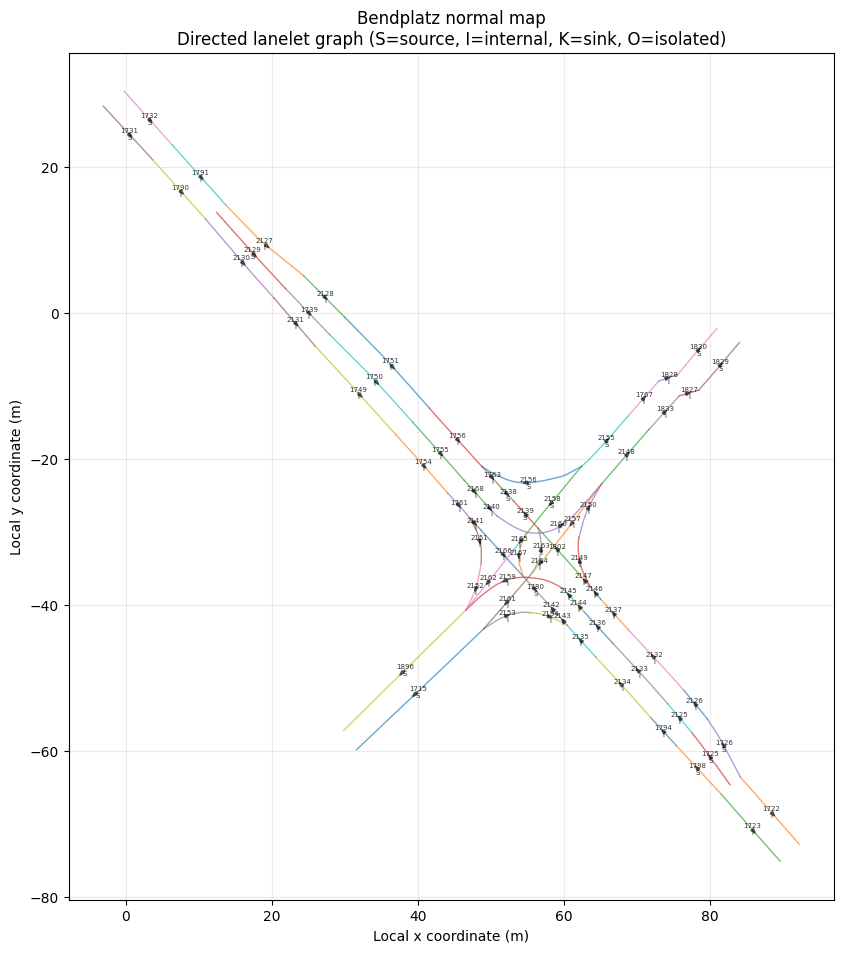

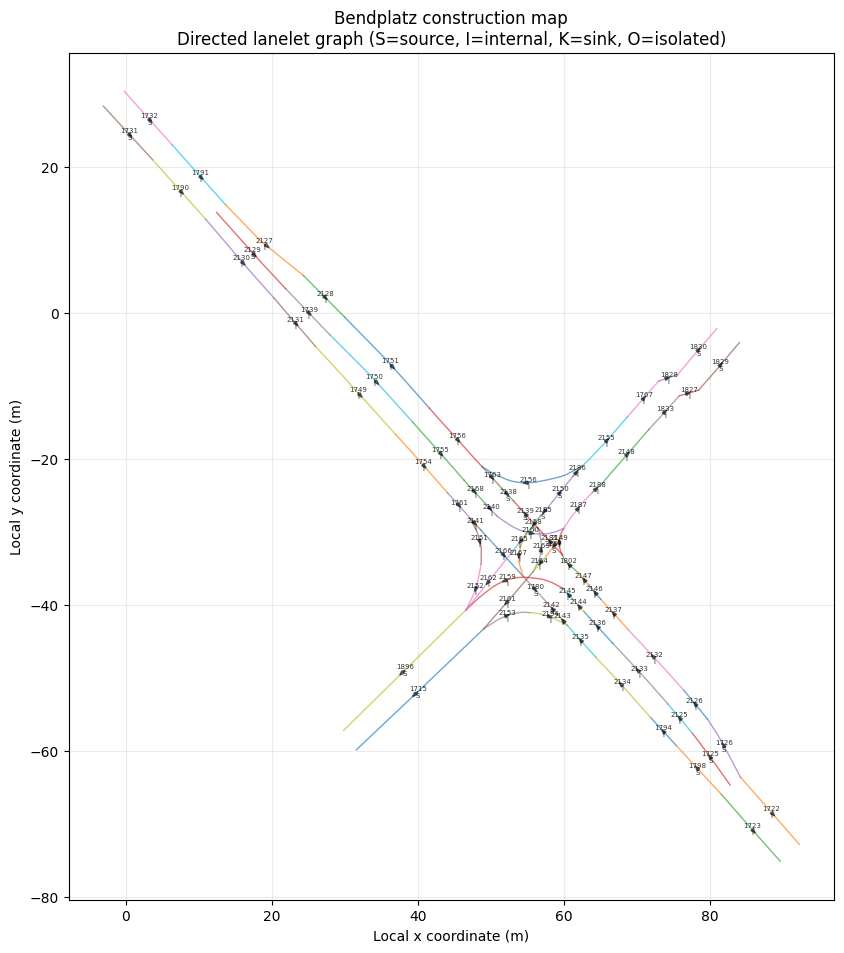


CELL 9 COMPLETED
Directed lanelet connectivity was derived from shared Lanelet2 boundary-node topology.
Geometric endpoint distances and heading changes were also calculated to validate the graph.

Inspect these outputs carefully:
  1. Directed lanelet connectivity summary.
  2. Edge geometry validation.
  3. Lanelets without exact successors.
  4. Directed graph plots.

Do not derive the intersection centre yet if many central lanelets are reported as isolated or disconnected.

After this graph is validated, the next cell should use connectivity and geometry to identify approach, departure, and intersection-connector lanelets.


In [ ]:
# Cell 9 — Derive directed Lanelet2 connectivity

# Purpose
# -------
# Cell 8 reconstructed every drivable lanelet and derived a centerline.
#
# This cell determines how lanelets connect:
#
#     predecessor lanelet
#             ↓
#       current lanelet
#             ↓
#      successor lanelet
#
# Connectivity is derived primarily from official Lanelet2 topology:
#
#   - the end nodes of one lanelet's boundaries;
#   - the start nodes of another lanelet's boundaries.
#
# A geometric endpoint check is also calculated as validation.
#
# This cell does NOT yet classify lanelets as incoming, outgoing,
# or intersection lanelets. It first builds and validates the graph.

from collections import defaultdict, deque
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "NORMAL_ROAD_LANELETS",
    "CONSTRUCTION_ROAD_LANELETS",
    "NORMAL_WAY_LOOKUP",
    "CONSTRUCTION_WAY_LOOKUP",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cell 8 before running this cell. "
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. ANGLE AND DISTANCE HELPERS
# ============================================================

def normalize_angle_degrees(angle):
    """
    Normalize an angle to the interval [-180, 180).
    """
    return (float(angle) + 180.0) % 360.0 - 180.0


def absolute_heading_difference_degrees(
    first_heading,
    second_heading,
):
    """
    Calculate the smallest absolute difference between two headings.
    """
    difference = normalize_angle_degrees(
        float(second_heading) - float(first_heading)
    )

    return abs(difference)


def euclidean_distance(first_point, second_point):
    """
    Calculate Euclidean distance between two 2D points.
    """
    first_point = np.asarray(first_point, dtype=float)
    second_point = np.asarray(second_point, dtype=float)

    return float(
        np.linalg.norm(first_point - second_point)
    )


# ============================================================
# 3. READ ORIENTED LANELET BOUNDARY NODE IDS
# ============================================================

def oriented_boundary_node_ids(record, way_lookup):
    """
    Return boundary-node IDs in the same direction as the reconstructed
    lanelet centerline.

    Cell 8 may have reversed the right-boundary geometry to align it
    with the left boundary. The node IDs must receive the same reversal.
    """

    left_way = way_lookup[record["left_way_id"]]
    right_way = way_lookup[record["right_way_id"]]

    left_node_ids = get_way_node_ids(left_way)
    right_node_ids = get_way_node_ids(right_way)

    if record["right_boundary_reversed"]:
        right_node_ids = right_node_ids[::-1]

    if len(left_node_ids) < 2 or len(right_node_ids) < 2:
        raise ValueError(
            f"Lanelet {record['lanelet_id']} has an invalid boundary."
        )

    return {
        "left_node_ids": left_node_ids,
        "right_node_ids": right_node_ids,

        "start_left_node_id": left_node_ids[0],
        "start_right_node_id": right_node_ids[0],

        "end_left_node_id": left_node_ids[-1],
        "end_right_node_id": right_node_ids[-1],
    }


# ============================================================
# 4. CREATE TOPOLOGICAL SIGNATURES
# ============================================================

def build_lanelet_endpoint_table(
    lanelet_records,
    way_lookup,
    map_variant,
):
    """
    Create one row per lanelet containing its start/end topology
    and geometric endpoint information.
    """

    rows = []
    endpoint_information = {}

    for record in lanelet_records:
        lanelet_id = record["lanelet_id"]

        boundary_nodes = oriented_boundary_node_ids(
            record,
            way_lookup,
        )

        centerline = record["centerline"]

        start_point = np.asarray(
            centerline[0],
            dtype=float,
        )

        end_point = np.asarray(
            centerline[-1],
            dtype=float,
        )

        # Boundary-node pairs are stored unordered for robust comparison.
        # Two connected lanelets can reference the same two physical
        # boundary nodes even if the order differs.
        start_node_pair = frozenset([
            boundary_nodes["start_left_node_id"],
            boundary_nodes["start_right_node_id"],
        ])

        end_node_pair = frozenset([
            boundary_nodes["end_left_node_id"],
            boundary_nodes["end_right_node_id"],
        ])

        information = {
            **boundary_nodes,
            "start_node_pair": start_node_pair,
            "end_node_pair": end_node_pair,
            "start_point": start_point,
            "end_point": end_point,
        }

        endpoint_information[lanelet_id] = information

        rows.append({
            "map_variant": map_variant,
            "lanelet_id": lanelet_id,

            "start_left_node_id":
                boundary_nodes["start_left_node_id"],

            "start_right_node_id":
                boundary_nodes["start_right_node_id"],

            "end_left_node_id":
                boundary_nodes["end_left_node_id"],

            "end_right_node_id":
                boundary_nodes["end_right_node_id"],

            "start_node_pair":
                tuple(sorted(start_node_pair)),

            "end_node_pair":
                tuple(sorted(end_node_pair)),

            "start_x": float(start_point[0]),
            "start_y": float(start_point[1]),

            "end_x": float(end_point[0]),
            "end_y": float(end_point[1]),

            "heading_degrees":
                float(record["heading_degrees"]),

            "centerline_length_m":
                float(record["centerline_length_m"]),
        })

    return (
        pd.DataFrame(rows),
        endpoint_information,
    )


(
    NORMAL_LANELET_ENDPOINTS,
    NORMAL_LANELET_ENDPOINT_LOOKUP,
) = build_lanelet_endpoint_table(
    lanelet_records=NORMAL_ROAD_LANELETS,
    way_lookup=NORMAL_WAY_LOOKUP,
    map_variant="normal",
)

(
    CONSTRUCTION_LANELET_ENDPOINTS,
    CONSTRUCTION_LANELET_ENDPOINT_LOOKUP,
) = build_lanelet_endpoint_table(
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    way_lookup=CONSTRUCTION_WAY_LOOKUP,
    map_variant="construction",
)


# ============================================================
# 5. DERIVE EXACT TOPOLOGICAL CONNECTIONS
# ============================================================

def derive_exact_topological_edges(
    lanelet_records,
    endpoint_lookup,
    map_variant,
):
    """
    Derive directed edges using shared Lanelet2 boundary-node pairs.

    Edge A -> B exists when:
        A's terminal boundary-node pair
        equals
        B's initial boundary-node pair.
    """

    start_pair_to_lanelets = defaultdict(list)

    for record in lanelet_records:
        lanelet_id = record["lanelet_id"]

        start_pair = endpoint_lookup[
            lanelet_id
        ]["start_node_pair"]

        start_pair_to_lanelets[start_pair].append(
            lanelet_id
        )

    edge_rows = []

    record_lookup = {
        record["lanelet_id"]: record
        for record in lanelet_records
    }

    for predecessor_record in lanelet_records:
        predecessor_id = predecessor_record["lanelet_id"]

        predecessor_endpoint = endpoint_lookup[
            predecessor_id
        ]

        matching_successors = start_pair_to_lanelets.get(
            predecessor_endpoint["end_node_pair"],
            [],
        )

        for successor_id in matching_successors:
            if successor_id == predecessor_id:
                continue

            successor_record = record_lookup[successor_id]
            successor_endpoint = endpoint_lookup[successor_id]

            endpoint_distance = euclidean_distance(
                predecessor_endpoint["end_point"],
                successor_endpoint["start_point"],
            )

            heading_difference = (
                absolute_heading_difference_degrees(
                    predecessor_record["heading_degrees"],
                    successor_record["heading_degrees"],
                )
            )

            edge_rows.append({
                "map_variant": map_variant,
                "from_lanelet_id": predecessor_id,
                "to_lanelet_id": successor_id,
                "connection_method":
                    "shared_boundary_node_pair",
                "endpoint_distance_m": endpoint_distance,
                "heading_change_degrees": heading_difference,
            })

    return pd.DataFrame(edge_rows)


NORMAL_EXACT_CONNECTIVITY_EDGES = (
    derive_exact_topological_edges(
        lanelet_records=NORMAL_ROAD_LANELETS,
        endpoint_lookup=NORMAL_LANELET_ENDPOINT_LOOKUP,
        map_variant="normal",
    )
)

CONSTRUCTION_EXACT_CONNECTIVITY_EDGES = (
    derive_exact_topological_edges(
        lanelet_records=CONSTRUCTION_ROAD_LANELETS,
        endpoint_lookup=CONSTRUCTION_LANELET_ENDPOINT_LOOKUP,
        map_variant="construction",
    )
)


# ============================================================
# 6. GEOMETRIC ENDPOINT DIAGNOSTIC
# ============================================================

def calculate_nearest_start_for_each_end(
    lanelet_records,
    endpoint_lookup,
    map_variant,
):
    """
    Find the geometrically closest candidate successor for every lanelet.

    This does not automatically create graph edges. It is a diagnostic
    used to identify possible topology gaps or orientation problems.
    """

    rows = []

    for source_record in lanelet_records:
        source_id = source_record["lanelet_id"]
        source_end = endpoint_lookup[source_id]["end_point"]

        candidates = []

        for target_record in lanelet_records:
            target_id = target_record["lanelet_id"]

            if target_id == source_id:
                continue

            target_start = endpoint_lookup[
                target_id
            ]["start_point"]

            distance = euclidean_distance(
                source_end,
                target_start,
            )

            heading_difference = (
                absolute_heading_difference_degrees(
                    source_record["heading_degrees"],
                    target_record["heading_degrees"],
                )
            )

            candidates.append({
                "target_id": target_id,
                "distance": distance,
                "heading_difference": heading_difference,
            })

        nearest = min(
            candidates,
            key=lambda candidate: candidate["distance"],
        )

        rows.append({
            "map_variant": map_variant,
            "from_lanelet_id": source_id,
            "nearest_start_lanelet_id":
                nearest["target_id"],
            "nearest_start_distance_m":
                nearest["distance"],
            "heading_change_degrees":
                nearest["heading_difference"],
        })

    return pd.DataFrame(rows)


NORMAL_NEAREST_ENDPOINT_DIAGNOSTIC = (
    calculate_nearest_start_for_each_end(
        lanelet_records=NORMAL_ROAD_LANELETS,
        endpoint_lookup=NORMAL_LANELET_ENDPOINT_LOOKUP,
        map_variant="normal",
    )
)

CONSTRUCTION_NEAREST_ENDPOINT_DIAGNOSTIC = (
    calculate_nearest_start_for_each_end(
        lanelet_records=CONSTRUCTION_ROAD_LANELETS,
        endpoint_lookup=CONSTRUCTION_LANELET_ENDPOINT_LOOKUP,
        map_variant="construction",
    )
)


# ============================================================
# 7. CREATE PREDECESSOR AND SUCCESSOR LOOKUPS
# ============================================================

def build_directed_graph(
    lanelet_records,
    edge_df,
):
    """
    Build predecessor and successor dictionaries.
    """

    lanelet_ids = [
        record["lanelet_id"]
        for record in lanelet_records
    ]

    successors = {
        lanelet_id: []
        for lanelet_id in lanelet_ids
    }

    predecessors = {
        lanelet_id: []
        for lanelet_id in lanelet_ids
    }

    if not edge_df.empty:
        for row in edge_df.itertuples(index=False):
            source_id = row.from_lanelet_id
            target_id = row.to_lanelet_id

            successors[source_id].append(target_id)
            predecessors[target_id].append(source_id)

    for lanelet_id in lanelet_ids:
        successors[lanelet_id] = sorted(
            set(successors[lanelet_id])
        )

        predecessors[lanelet_id] = sorted(
            set(predecessors[lanelet_id])
        )

    return predecessors, successors


(
    NORMAL_LANELET_PREDECESSORS,
    NORMAL_LANELET_SUCCESSORS,
) = build_directed_graph(
    lanelet_records=NORMAL_ROAD_LANELETS,
    edge_df=NORMAL_EXACT_CONNECTIVITY_EDGES,
)

(
    CONSTRUCTION_LANELET_PREDECESSORS,
    CONSTRUCTION_LANELET_SUCCESSORS,
) = build_directed_graph(
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    edge_df=CONSTRUCTION_EXACT_CONNECTIVITY_EDGES,
)


# ============================================================
# 8. SUMMARIZE GRAPH ROLES
# ============================================================

def summarize_lanelet_graph(
    lanelet_records,
    predecessors,
    successors,
    map_variant,
):
    """
    Summarize graph degree and preliminary topological role.

    Preliminary role definitions:
      source:    no predecessor, at least one successor
      sink:      at least one predecessor, no successor
      internal:  predecessor(s) and successor(s)
      isolated:  neither predecessor nor successor

    These are graph roles, not yet traffic roles.
    """

    rows = []

    for record in lanelet_records:
        lanelet_id = record["lanelet_id"]

        predecessor_ids = predecessors[lanelet_id]
        successor_ids = successors[lanelet_id]

        in_degree = len(predecessor_ids)
        out_degree = len(successor_ids)

        if in_degree == 0 and out_degree > 0:
            graph_role = "source"

        elif in_degree > 0 and out_degree == 0:
            graph_role = "sink"

        elif in_degree > 0 and out_degree > 0:
            graph_role = "internal"

        else:
            graph_role = "isolated"

        rows.append({
            "map_variant": map_variant,
            "lanelet_id": lanelet_id,
            "graph_role": graph_role,
            "in_degree": in_degree,
            "out_degree": out_degree,
            "predecessor_ids": predecessor_ids,
            "successor_ids": successor_ids,
            "centerline_length_m":
                record["centerline_length_m"],
            "heading_degrees":
                record["heading_degrees"],
            "start_x": record["start_x"],
            "start_y": record["start_y"],
            "end_x": record["end_x"],
            "end_y": record["end_y"],
        })

    return pd.DataFrame(rows)


NORMAL_LANELET_GRAPH_SUMMARY = summarize_lanelet_graph(
    lanelet_records=NORMAL_ROAD_LANELETS,
    predecessors=NORMAL_LANELET_PREDECESSORS,
    successors=NORMAL_LANELET_SUCCESSORS,
    map_variant="normal",
)

CONSTRUCTION_LANELET_GRAPH_SUMMARY = (
    summarize_lanelet_graph(
        lanelet_records=CONSTRUCTION_ROAD_LANELETS,
        predecessors=CONSTRUCTION_LANELET_PREDECESSORS,
        successors=CONSTRUCTION_LANELET_SUCCESSORS,
        map_variant="construction",
    )
)


# ============================================================
# 9. DISPLAY CONNECTIVITY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("DIRECTED LANELET CONNECTIVITY SUMMARY")
print("=" * 80)

connectivity_summary = pd.DataFrame([
    {
        "map_variant": "normal",
        "lanelets": len(NORMAL_ROAD_LANELETS),
        "directed_edges":
            len(NORMAL_EXACT_CONNECTIVITY_EDGES),
        "source_lanelets": int(
            (
                NORMAL_LANELET_GRAPH_SUMMARY[
                    "graph_role"
                ] == "source"
            ).sum()
        ),
        "sink_lanelets": int(
            (
                NORMAL_LANELET_GRAPH_SUMMARY[
                    "graph_role"
                ] == "sink"
            ).sum()
        ),
        "internal_lanelets": int(
            (
                NORMAL_LANELET_GRAPH_SUMMARY[
                    "graph_role"
                ] == "internal"
            ).sum()
        ),
        "isolated_lanelets": int(
            (
                NORMAL_LANELET_GRAPH_SUMMARY[
                    "graph_role"
                ] == "isolated"
            ).sum()
        ),
    },
    {
        "map_variant": "construction",
        "lanelets":
            len(CONSTRUCTION_ROAD_LANELETS),
        "directed_edges":
            len(CONSTRUCTION_EXACT_CONNECTIVITY_EDGES),
        "source_lanelets": int(
            (
                CONSTRUCTION_LANELET_GRAPH_SUMMARY[
                    "graph_role"
                ] == "source"
            ).sum()
        ),
        "sink_lanelets": int(
            (
                CONSTRUCTION_LANELET_GRAPH_SUMMARY[
                    "graph_role"
                ] == "sink"
            ).sum()
        ),
        "internal_lanelets": int(
            (
                CONSTRUCTION_LANELET_GRAPH_SUMMARY[
                    "graph_role"
                ] == "internal"
            ).sum()
        ),
        "isolated_lanelets": int(
            (
                CONSTRUCTION_LANELET_GRAPH_SUMMARY[
                    "graph_role"
                ] == "isolated"
            ).sum()
        ),
    },
])

display(connectivity_summary)


print("\nNormal-map graph summary:")

display(
    NORMAL_LANELET_GRAPH_SUMMARY.sort_values(
        [
            "graph_role",
            "lanelet_id",
        ]
    )
)


print("\nNormal-map directed edges — first 20:")

display(
    NORMAL_EXACT_CONNECTIVITY_EDGES.head(20)
)


# ============================================================
# 10. CHECK EXACT-EDGE GEOMETRIC CONSISTENCY
# ============================================================

def summarize_edge_geometry(edge_df, map_variant):
    """
    Summarize endpoint distance and heading change for graph edges.
    """

    if edge_df.empty:
        return {
            "map_variant": map_variant,
            "edge_count": 0,
            "maximum_endpoint_distance_m": np.nan,
            "mean_endpoint_distance_m": np.nan,
            "median_heading_change_degrees": np.nan,
            "maximum_heading_change_degrees": np.nan,
        }

    return {
        "map_variant": map_variant,
        "edge_count": len(edge_df),
        "maximum_endpoint_distance_m": float(
            edge_df["endpoint_distance_m"].max()
        ),
        "mean_endpoint_distance_m": float(
            edge_df["endpoint_distance_m"].mean()
        ),
        "median_heading_change_degrees": float(
            edge_df["heading_change_degrees"].median()
        ),
        "maximum_heading_change_degrees": float(
            edge_df["heading_change_degrees"].max()
        ),
    }


EDGE_GEOMETRY_VALIDATION = pd.DataFrame([
    summarize_edge_geometry(
        NORMAL_EXACT_CONNECTIVITY_EDGES,
        "normal",
    ),
    summarize_edge_geometry(
        CONSTRUCTION_EXACT_CONNECTIVITY_EDGES,
        "construction",
    ),
])

print("\n" + "=" * 80)
print("EDGE GEOMETRY VALIDATION")
print("=" * 80)

display(EDGE_GEOMETRY_VALIDATION)


# ============================================================
# 11. IDENTIFY POSSIBLE MISSING CONNECTIONS
# ============================================================

def identify_topology_gaps(
    graph_summary,
    nearest_endpoint_df,
):
    """
    Identify lanelets with no exact successor but whose endpoint is
    geometrically close to another lanelet start.

    No threshold is imposed automatically. Results are sorted by distance
    so the natural separation between connected and unconnected endpoints
    can be inspected.
    """

    no_successor_ids = set(
        graph_summary.loc[
            graph_summary["out_degree"] == 0,
            "lanelet_id",
        ]
    )

    result = nearest_endpoint_df[
        nearest_endpoint_df["from_lanelet_id"].isin(
            no_successor_ids
        )
    ].copy()

    return result.sort_values(
        "nearest_start_distance_m"
    ).reset_index(drop=True)


NORMAL_POSSIBLE_TOPOLOGY_GAPS = identify_topology_gaps(
    NORMAL_LANELET_GRAPH_SUMMARY,
    NORMAL_NEAREST_ENDPOINT_DIAGNOSTIC,
)

CONSTRUCTION_POSSIBLE_TOPOLOGY_GAPS = (
    identify_topology_gaps(
        CONSTRUCTION_LANELET_GRAPH_SUMMARY,
        CONSTRUCTION_NEAREST_ENDPOINT_DIAGNOSTIC,
    )
)


print("\nNormal lanelets without an exact successor:")
display(NORMAL_POSSIBLE_TOPOLOGY_GAPS)

print("\nConstruction lanelets without an exact successor:")
display(CONSTRUCTION_POSSIBLE_TOPOLOGY_GAPS)


# ============================================================
# 12. PLOT THE DIRECTED LANELET GRAPH
# ============================================================

def plot_directed_lanelet_graph(
    lanelet_records,
    successors,
    graph_summary,
    map_name,
):
    """
    Plot centerlines, direction arrows and graph roles.
    """

    figure, axis = plt.subplots(figsize=(12, 11))

    role_lookup = graph_summary.set_index(
        "lanelet_id"
    )["graph_role"].to_dict()

    for record in lanelet_records:
        lanelet_id = record["lanelet_id"]
        centerline = record["centerline"]
        graph_role = role_lookup[lanelet_id]

        axis.plot(
            centerline[:, 0],
            centerline[:, 1],
            linewidth=1.0,
            alpha=0.65,
            zorder=2,
        )

        # Direction arrow around the middle of the centerline.
        middle_index = max(
            0,
            min(
                len(centerline) - 2,
                len(centerline) // 2,
            ),
        )

        arrow_start = centerline[middle_index]
        arrow_end = centerline[middle_index + 1]

        arrow_vector = arrow_end - arrow_start

        axis.arrow(
            arrow_start[0],
            arrow_start[1],
            arrow_vector[0],
            arrow_vector[1],
            head_width=0.45,
            head_length=0.65,
            length_includes_head=True,
            alpha=0.6,
            zorder=3,
        )

        label_point = centerline[len(centerline) // 2]

        axis.text(
            label_point[0],
            label_point[1],
            f"{lanelet_id}\n{graph_role[0].upper()}",
            fontsize=5,
            ha="center",
            va="center",
            alpha=0.8,
            zorder=5,
        )

    axis.set_title(
        f"{map_name}\n"
        "Directed lanelet graph "
        "(S=source, I=internal, K=sink, O=isolated)"
    )

    axis.set_xlabel("Local x coordinate (m)")
    axis.set_ylabel("Local y coordinate (m)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.25)

    plt.show()


plot_directed_lanelet_graph(
    lanelet_records=NORMAL_ROAD_LANELETS,
    successors=NORMAL_LANELET_SUCCESSORS,
    graph_summary=NORMAL_LANELET_GRAPH_SUMMARY,
    map_name="Bendplatz normal map",
)

plot_directed_lanelet_graph(
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    successors=CONSTRUCTION_LANELET_SUCCESSORS,
    graph_summary=CONSTRUCTION_LANELET_GRAPH_SUMMARY,
    map_name="Bendplatz construction map",
)


# ============================================================
# 13. STORE COMBINED GRAPH OBJECTS
# ============================================================

LANELET_CONNECTIVITY_EDGES = {
    "normal": NORMAL_EXACT_CONNECTIVITY_EDGES,
    "construction": CONSTRUCTION_EXACT_CONNECTIVITY_EDGES,
}

LANELET_PREDECESSORS = {
    "normal": NORMAL_LANELET_PREDECESSORS,
    "construction": CONSTRUCTION_LANELET_PREDECESSORS,
}

LANELET_SUCCESSORS = {
    "normal": NORMAL_LANELET_SUCCESSORS,
    "construction": CONSTRUCTION_LANELET_SUCCESSORS,
}

LANELET_GRAPH_SUMMARIES = {
    "normal": NORMAL_LANELET_GRAPH_SUMMARY,
    "construction": CONSTRUCTION_LANELET_GRAPH_SUMMARY,
}


# ============================================================
# 14. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 9 COMPLETED")
print("=" * 80)

print(
    "Directed lanelet connectivity was derived from shared "
    "Lanelet2 boundary-node topology."
)

print(
    "Geometric endpoint distances and heading changes were also "
    "calculated to validate the graph."
)

print(
    "\nInspect these outputs carefully:"
)

print(
    "  1. Directed lanelet connectivity summary."
)

print(
    "  2. Edge geometry validation."
)

print(
    "  3. Lanelets without exact successors."
)

print(
    "  4. Directed graph plots."
)

print(
    "\nDo not derive the intersection centre yet if many central "
    "lanelets are reported as isolated or disconnected."
)

print(
    "\nAfter this graph is validated, the next cell should use "
    "connectivity and geometry to identify approach, departure, "
    "and intersection-connector lanelets."
)

Valid lanelet polygons:
  Normal:       73
  Construction: 78

Invalid polygons:
  Normal:       []
  Construction: []

Branch/merge seed summary:

Normal map:
  Branch lanelets: [1761, 2146, 2150, 2158, 2160, 2161, 2164]
  Merge lanelets: [1763, 1780, 1896, 2139, 2143, 2148, 2157]
  All seed lanelets: [1715, 1754, 1756, 1761, 1763, 1780, 1802, 1833, 1896, 2135, 2137, 2138, 2139, 2140, 2141, 2142, 2143, 2146, 2147, 2148, 2149, 2150, 2151, 2152, 2153, 2154, 2156, 2157, 2158, 2159, 2160, 2161, 2162, 2163, 2164, 2165, 2166, 2167]

Construction map:
  Branch lanelets: [1761, 1802, 2158, 2161, 2164, 2186]
  Merge lanelets: [1763, 1780, 1896, 2139, 2143, 2187]
  All seed lanelets: [1715, 1754, 1756, 1761, 1763, 1780, 1802, 1896, 2135, 2138, 2139, 2141, 2142, 2143, 2147, 2149, 2150, 2151, 2152, 2153, 2154, 2155, 2156, 2157, 2158, 2159, 2160, 2161, 2162, 2163, 2164, 2165, 2166, 2167, 2181, 2185, 2186, 2187, 2188]

DETECTED INTERSECTION — NORMAL MAP
Selected graph radius: 3
Intersection lanelet

,map_variant,graph_radius,intersection_lanelets,approach_lanelets,departure_lanelets,intersection_area_m2,center_x,center_y,bounding_width_m,bounding_height_m
0,normal,3,32,1,0,671.194777,60.082338,-36.643144,58.570503,65.068801
1,construction,3,30,2,1,524.858428,59.082116,-39.039108,52.054706,57.789593



Top normal-map candidates:


,map_variant,graph_radius,component_index,lanelet_count,seed_count,branch_count,merge_count,branch_merge_event_count,internal_edge_count,union_area_m2,bounding_width_m,bounding_height_m,occupancy_ratio,centroid_x,centroid_y,candidate_score,lanelet_ids
0,normal,3,0,32,21,5,4,9,33,671.194777,58.570503,65.068801,0.176115,60.082338,-36.643144,82.840854,"[1715, 1726, 1750, 1755, 1794, 1798, 1802, 182..."
1,normal,2,0,29,21,5,4,9,30,561.438128,54.825419,58.049111,0.176410,59.932199,-36.133885,82.321839,"[1715, 1755, 1794, 1802, 1827, 1829, 1833, 212..."
2,normal,1,0,25,21,5,4,9,26,466.970874,49.047339,51.761850,0.183935,58.442339,-37.659052,81.582633,"[1715, 1802, 1827, 1833, 2132, 2134, 2135, 213..."
3,normal,0,0,21,21,5,4,9,22,377.135727,46.095730,50.641238,0.161560,56.167500,-36.320903,80.680294,"[1715, 1802, 1833, 2135, 2137, 2139, 2140, 214..."
4,normal,3,1,19,13,2,2,4,19,425.110821,58.263526,72.311180,0.100902,42.210897,-26.763277,42.435580,"[1749, 1754, 1761, 1780, 1896, 2130, 2131, 213..."
5,normal,2,1,17,13,2,2,4,17,365.537330,44.584992,61.513756,0.133282,44.444405,-30.177689,42.276288,"[1749, 1754, 1761, 1780, 1896, 2131, 2141, 214..."
6,normal,1,1,15,13,2,2,4,15,336.174214,39.034504,54.764097,0.157261,45.659682,-32.063348,42.019239,"[1749, 1754, 1761, 1780, 1896, 2141, 2145, 215..."
7,normal,0,1,13,13,2,2,4,13,284.121138,34.910920,42.722882,0.190494,47.595820,-35.366381,41.886531,"[1754, 1761, 1780, 1896, 2141, 2151, 2152, 215..."
8,normal,0,2,4,4,0,1,1,3,89.737275,23.408561,14.884951,0.257544,51.125753,-20.595399,11.676916,"[1756, 1763, 2138, 2156]"
9,normal,2,2,6,4,0,1,1,5,181.122343,41.423763,33.354032,0.131091,41.668962,-11.778518,11.503708,"[1751, 1756, 1763, 2128, 2138, 2156]"



Top construction-map candidates:


,map_variant,graph_radius,component_index,lanelet_count,seed_count,branch_count,merge_count,branch_merge_event_count,internal_edge_count,union_area_m2,bounding_width_m,bounding_height_m,occupancy_ratio,centroid_x,centroid_y,candidate_score,lanelet_ids
0,construction,3,0,30,18,3,3,6,29,524.858428,52.054706,57.789593,0.174475,59.082116,-39.039108,62.543158,"[1715, 1755, 1794, 1798, 1802, 1827, 1833, 213..."
1,construction,2,0,26,18,3,3,6,25,423.185085,46.112029,50.641238,0.181222,57.392809,-38.493733,61.819620,"[1715, 1794, 1802, 1833, 2134, 2135, 2137, 213..."
2,construction,1,0,22,18,3,3,6,21,360.597272,42.555289,45.893730,0.184636,55.693550,-39.075343,61.041397,"[1715, 1802, 2134, 2135, 2139, 2140, 2142, 214..."
3,construction,0,0,18,18,3,3,6,17,276.033922,35.829223,39.057247,0.197253,52.391966,-40.027654,60.323361,"[1715, 1802, 2135, 2139, 2142, 2143, 2147, 214..."
4,construction,3,1,20,14,2,2,4,20,396.449720,58.263526,72.311180,0.094099,40.931572,-26.958417,44.141975,"[1749, 1754, 1761, 1780, 1896, 2130, 2131, 213..."
5,construction,2,1,18,14,2,2,4,18,336.876230,44.584992,61.513756,0.122831,43.128868,-30.697833,43.975388,"[1749, 1754, 1761, 1780, 1896, 2131, 2141, 214..."
6,construction,1,1,16,14,2,2,4,16,307.187583,37.434162,54.764097,0.149844,44.313459,-32.802366,43.724406,"[1749, 1754, 1761, 1780, 1896, 2141, 2145, 215..."
7,construction,0,1,14,14,2,2,4,14,255.477224,31.957128,42.722882,0.187122,46.215678,-36.634561,43.599786,"[1754, 1761, 1780, 1896, 2141, 2151, 2152, 215..."
8,construction,3,2,13,7,1,1,2,12,345.483500,70.128696,44.250060,0.111331,47.764932,-9.182042,21.930089,"[1751, 1756, 1763, 1767, 1828, 1830, 2127, 212..."
9,construction,2,2,11,7,1,1,2,10,264.617192,54.753970,34.853337,0.138662,49.678603,-13.203929,21.852245,"[1751, 1756, 1763, 1767, 1828, 2128, 2138, 215..."


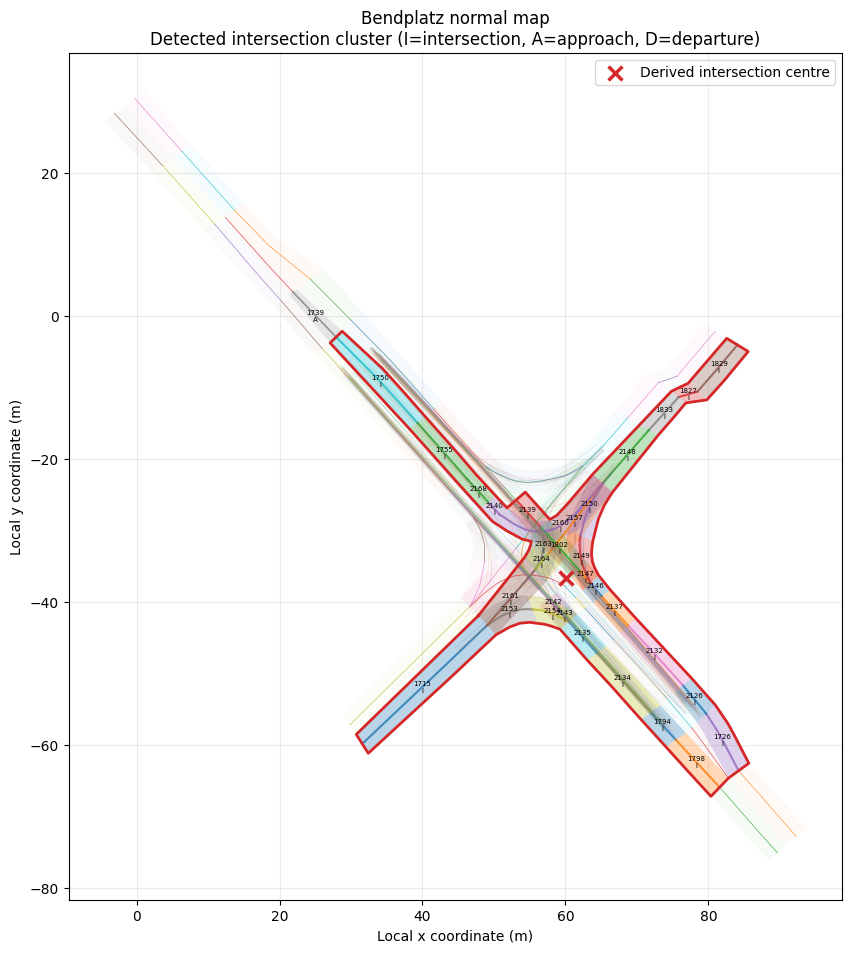

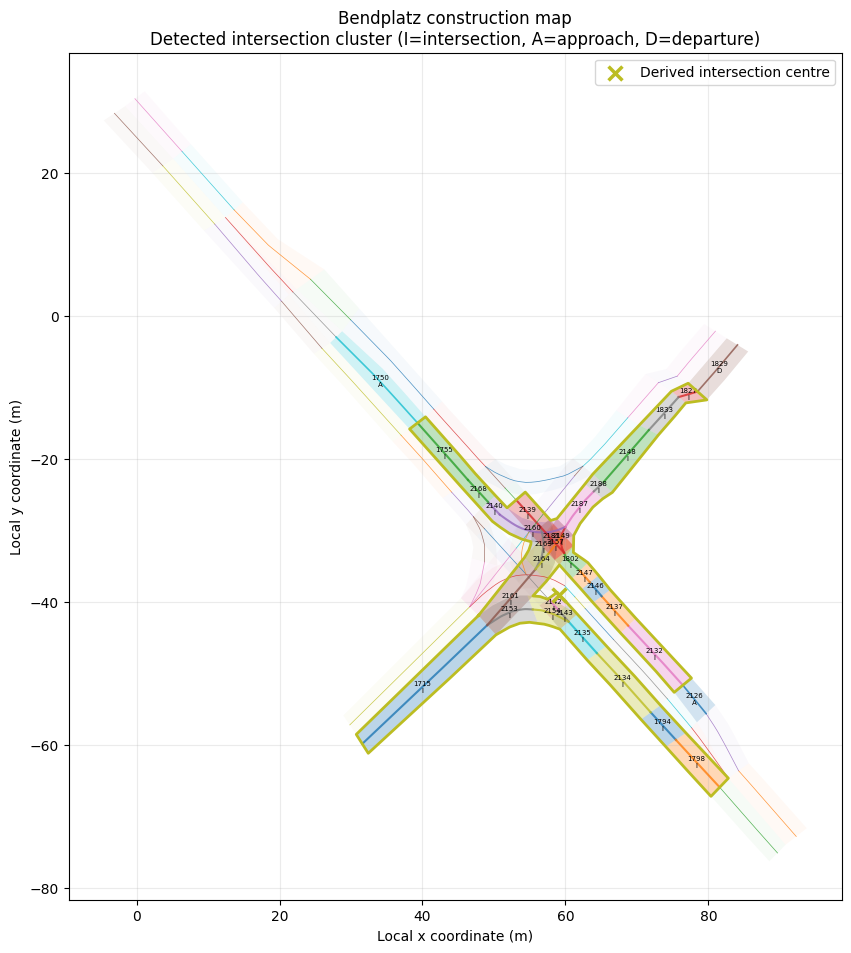


CELL 10 COMPLETED
A candidate central intersection cluster was derived from Lanelet2 connectivity and official lanelet polygons.
The intersection centre was calculated as the centroid of the union of the detected intersection-lanelet polygons.

This centre was not manually selected.

Before accepting the result, verify that:
  1. Highlighted intersection lanelets cover the central crossing area, not the long external approaches.
  2. Approach lanelets terminate immediately before the central cluster.
  3. Departure lanelets begin immediately after the central cluster.
  4. The centre marker lies inside the physical intersection.

If the cluster is correct, the next cell should enumerate directed approach-to-departure routes through the intersection.
Those routes can then be classified as LEFT, RIGHT or STRAIGHT using their entry and exit directions.


In [ ]:
# Cell 10 — Detect the central intersection lanelet cluster
#           and derive its geometric centre

# Purpose
# -------
# Cell 9 created a directed lanelet graph.
#
# This cell uses:
#
#   1. graph branching and merging;
#   2. graph connectivity;
#   3. lanelet polygon geometry;
#
# to identify the compact group of lanelets that forms the central
# intersection.
#
# No manually selected intersection centre is used.
#
# The result remains a candidate until the visual diagnostic is checked.

from collections import defaultdict, deque
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. IMPORT SHAPELY
# ============================================================

try:
    from shapely.geometry import Polygon
    from shapely.ops import unary_union
except ImportError:
    print("Shapely is not installed. Installing it now...")

    !pip -q install shapely

    from shapely.geometry import Polygon
    from shapely.ops import unary_union


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "NORMAL_ROAD_LANELETS",
    "CONSTRUCTION_ROAD_LANELETS",
    "NORMAL_LANELET_PREDECESSORS",
    "NORMAL_LANELET_SUCCESSORS",
    "CONSTRUCTION_LANELET_PREDECESSORS",
    "CONSTRUCTION_LANELET_SUCCESSORS",
    "NORMAL_LANELET_GRAPH_SUMMARY",
    "CONSTRUCTION_LANELET_GRAPH_SUMMARY",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cells 8 and 9 before running Cell 10. "
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 3. CONVERT LANELET POLYGONS TO VALID SHAPELY GEOMETRY
# ============================================================

def create_valid_polygon(polygon_points):
    """
    Create a valid Shapely polygon from a lanelet polygon array.

    buffer(0) is used only to repair minor self-intersection problems
    that can occur when left and right boundaries meet at a taper point.
    """

    polygon_points = np.asarray(
        polygon_points,
        dtype=float,
    )

    if len(polygon_points) < 3:
        return None

    polygon = Polygon(polygon_points)

    if not polygon.is_valid:
        polygon = polygon.buffer(0)

    if polygon.is_empty:
        return None

    return polygon


def build_lanelet_polygon_lookup(lanelet_records):
    """
    Create:
        lanelet ID -> valid Shapely polygon
    """

    lookup = {}
    rejected = []

    for record in lanelet_records:
        lanelet_id = record["lanelet_id"]

        polygon = create_valid_polygon(
            record["polygon"]
        )

        if polygon is None:
            rejected.append(lanelet_id)
            continue

        lookup[lanelet_id] = polygon

    return lookup, rejected


(
    NORMAL_LANELET_POLYGON_LOOKUP,
    NORMAL_INVALID_POLYGON_LANELETS,
) = build_lanelet_polygon_lookup(
    NORMAL_ROAD_LANELETS
)

(
    CONSTRUCTION_LANELET_POLYGON_LOOKUP,
    CONSTRUCTION_INVALID_POLYGON_LANELETS,
) = build_lanelet_polygon_lookup(
    CONSTRUCTION_ROAD_LANELETS
)

print("Valid lanelet polygons:")
print(
    f"  Normal:       {len(NORMAL_LANELET_POLYGON_LOOKUP)}"
)
print(
    f"  Construction: "
    f"{len(CONSTRUCTION_LANELET_POLYGON_LOOKUP)}"
)

print("\nInvalid polygons:")
print(
    f"  Normal:       {NORMAL_INVALID_POLYGON_LANELETS}"
)
print(
    f"  Construction: "
    f"{CONSTRUCTION_INVALID_POLYGON_LANELETS}"
)


# ============================================================
# 4. BUILD AN UNDIRECTED VERSION OF THE LANELET GRAPH
# ============================================================

def build_undirected_adjacency(
    lanelet_records,
    predecessors,
    successors,
):
    """
    Build an undirected adjacency graph from the directed lanelet graph.

    This is used only for finding spatially connected lanelet clusters.
    The original predecessor/successor direction remains unchanged.
    """

    adjacency = {
        record["lanelet_id"]: set()
        for record in lanelet_records
    }

    for lanelet_id in adjacency:
        for neighbour_id in predecessors[lanelet_id]:
            adjacency[lanelet_id].add(neighbour_id)
            adjacency[neighbour_id].add(lanelet_id)

        for neighbour_id in successors[lanelet_id]:
            adjacency[lanelet_id].add(neighbour_id)
            adjacency[neighbour_id].add(lanelet_id)

    return adjacency


NORMAL_UNDIRECTED_LANELET_GRAPH = (
    build_undirected_adjacency(
        NORMAL_ROAD_LANELETS,
        NORMAL_LANELET_PREDECESSORS,
        NORMAL_LANELET_SUCCESSORS,
    )
)

CONSTRUCTION_UNDIRECTED_LANELET_GRAPH = (
    build_undirected_adjacency(
        CONSTRUCTION_ROAD_LANELETS,
        CONSTRUCTION_LANELET_PREDECESSORS,
        CONSTRUCTION_LANELET_SUCCESSORS,
    )
)


# ============================================================
# 5. FIND BRANCH AND MERGE SEEDS
# ============================================================

def identify_branch_merge_seeds(graph_summary):
    """
    Find lanelets associated with route branching or merging.

    Seed definitions:
        branch lanelet:
            out_degree > 1

        merge lanelet:
            in_degree > 1

    The immediate predecessors and successors of these lanelets are also
    included because the branch may occur exactly at a lanelet endpoint.
    """

    seed_ids = set()

    branch_rows = graph_summary[
        graph_summary["out_degree"] > 1
    ]

    merge_rows = graph_summary[
        graph_summary["in_degree"] > 1
    ]

    for row in branch_rows.itertuples(index=False):
        seed_ids.add(row.lanelet_id)
        seed_ids.update(row.predecessor_ids)
        seed_ids.update(row.successor_ids)

    for row in merge_rows.itertuples(index=False):
        seed_ids.add(row.lanelet_id)
        seed_ids.update(row.predecessor_ids)
        seed_ids.update(row.successor_ids)

    return {
        "seed_ids": sorted(seed_ids),
        "branch_ids": sorted(
            branch_rows["lanelet_id"].tolist()
        ),
        "merge_ids": sorted(
            merge_rows["lanelet_id"].tolist()
        ),
    }


NORMAL_BRANCH_MERGE_SEEDS = (
    identify_branch_merge_seeds(
        NORMAL_LANELET_GRAPH_SUMMARY
    )
)

CONSTRUCTION_BRANCH_MERGE_SEEDS = (
    identify_branch_merge_seeds(
        CONSTRUCTION_LANELET_GRAPH_SUMMARY
    )
)

print("\nBranch/merge seed summary:")

print("\nNormal map:")
print(
    "  Branch lanelets:",
    NORMAL_BRANCH_MERGE_SEEDS["branch_ids"],
)
print(
    "  Merge lanelets:",
    NORMAL_BRANCH_MERGE_SEEDS["merge_ids"],
)
print(
    "  All seed lanelets:",
    NORMAL_BRANCH_MERGE_SEEDS["seed_ids"],
)

print("\nConstruction map:")
print(
    "  Branch lanelets:",
    CONSTRUCTION_BRANCH_MERGE_SEEDS["branch_ids"],
)
print(
    "  Merge lanelets:",
    CONSTRUCTION_BRANCH_MERGE_SEEDS["merge_ids"],
)
print(
    "  All seed lanelets:",
    CONSTRUCTION_BRANCH_MERGE_SEEDS["seed_ids"],
)


# ============================================================
# 6. CALCULATE GRAPH DISTANCE FROM BRANCH/MERGE SEEDS
# ============================================================

def shortest_graph_distance_from_seeds(
    adjacency,
    seed_ids,
):
    """
    Calculate the minimum number of graph edges from each lanelet
    to any branch/merge seed.
    """

    distances = {
        lanelet_id: np.inf
        for lanelet_id in adjacency
    }

    queue = deque()

    for seed_id in seed_ids:
        if seed_id not in adjacency:
            continue

        distances[seed_id] = 0
        queue.append(seed_id)

    while queue:
        current_id = queue.popleft()

        for neighbour_id in adjacency[current_id]:
            candidate_distance = (
                distances[current_id] + 1
            )

            if candidate_distance < distances[neighbour_id]:
                distances[neighbour_id] = candidate_distance
                queue.append(neighbour_id)

    return distances


NORMAL_DISTANCE_FROM_BRANCH_MERGE = (
    shortest_graph_distance_from_seeds(
        NORMAL_UNDIRECTED_LANELET_GRAPH,
        NORMAL_BRANCH_MERGE_SEEDS["seed_ids"],
    )
)

CONSTRUCTION_DISTANCE_FROM_BRANCH_MERGE = (
    shortest_graph_distance_from_seeds(
        CONSTRUCTION_UNDIRECTED_LANELET_GRAPH,
        CONSTRUCTION_BRANCH_MERGE_SEEDS["seed_ids"],
    )
)


# ============================================================
# 7. FIND CONNECTED COMPONENTS
# ============================================================

def connected_components_for_subset(
    adjacency,
    allowed_ids,
):
    """
    Find undirected connected components inside a lanelet subset.
    """

    allowed_ids = set(allowed_ids)
    unvisited = set(allowed_ids)
    components = []

    while unvisited:
        start_id = next(iter(unvisited))

        component = set()
        queue = deque([start_id])
        unvisited.remove(start_id)

        while queue:
            current_id = queue.popleft()
            component.add(current_id)

            for neighbour_id in adjacency[current_id]:
                if neighbour_id in unvisited:
                    unvisited.remove(neighbour_id)
                    queue.append(neighbour_id)

        components.append(component)

    return components


# ============================================================
# 8. MEASURE THE SPATIAL COMPACTNESS OF A COMPONENT
# ============================================================

def component_geometry_metrics(
    component_ids,
    polygon_lookup,
):
    """
    Calculate geometric statistics for one lanelet component.
    """

    polygons = [
        polygon_lookup[lanelet_id]
        for lanelet_id in component_ids
        if lanelet_id in polygon_lookup
    ]

    if not polygons:
        return None

    geometry_union = unary_union(polygons)

    minimum_x, minimum_y, maximum_x, maximum_y = (
        geometry_union.bounds
    )

    bounding_width = maximum_x - minimum_x
    bounding_height = maximum_y - minimum_y
    bounding_area = bounding_width * bounding_height

    union_area = float(geometry_union.area)

    if bounding_area > 0:
        occupancy_ratio = union_area / bounding_area
    else:
        occupancy_ratio = 0.0

    centroid = geometry_union.centroid

    return {
        "geometry_union": geometry_union,
        "lanelet_count": len(component_ids),
        "union_area_m2": union_area,
        "bounding_width_m": bounding_width,
        "bounding_height_m": bounding_height,
        "bounding_area_m2": bounding_area,
        "occupancy_ratio": occupancy_ratio,
        "centroid_x": float(centroid.x),
        "centroid_y": float(centroid.y),
    }


# ============================================================
# 9. DETECT THE CENTRAL INTERSECTION COMPONENT
# ============================================================

def detect_intersection_component(
    lanelet_records,
    graph_summary,
    predecessors,
    successors,
    adjacency,
    branch_merge_information,
    graph_distances,
    polygon_lookup,
    map_variant,
):
    """
    Detect the compact central intersection cluster.

    Candidate sets are created at graph radii 0, 1, 2 and 3 around
    branch/merge seeds.

    Each connected component is scored using:

        - number of branch/merge seeds it contains;
        - number of graph branch/merge events it contains;
        - compactness of its polygon union;
        - spatial extent;
        - lanelet count.

    The scoring does not use a manually entered intersection centre.
    """

    record_lookup = {
        record["lanelet_id"]: record
        for record in lanelet_records
    }

    graph_summary_lookup = (
        graph_summary
        .set_index("lanelet_id")
        .to_dict("index")
    )

    original_seed_ids = set(
        branch_merge_information["seed_ids"]
    )

    branch_ids = set(
        branch_merge_information["branch_ids"]
    )

    merge_ids = set(
        branch_merge_information["merge_ids"]
    )

    candidate_rows = []
    candidate_objects = []

    for graph_radius in [0, 1, 2, 3]:

        candidate_ids = {
            lanelet_id
            for lanelet_id, distance
            in graph_distances.items()
            if distance <= graph_radius
        }

        components = connected_components_for_subset(
            adjacency,
            candidate_ids,
        )

        for component_index, component_ids in enumerate(
            components
        ):
            geometry_metrics = component_geometry_metrics(
                component_ids,
                polygon_lookup,
            )

            if geometry_metrics is None:
                continue

            seed_count = len(
                component_ids.intersection(
                    original_seed_ids
                )
            )

            branch_count = len(
                component_ids.intersection(
                    branch_ids
                )
            )

            merge_count = len(
                component_ids.intersection(
                    merge_ids
                )
            )

            branch_merge_event_count = (
                branch_count + merge_count
            )

            # Graph complexity inside the component.
            internal_edge_count = 0

            for lanelet_id in component_ids:
                for successor_id in successors[lanelet_id]:
                    if successor_id in component_ids:
                        internal_edge_count += 1

            # A true intersection component should contain several
            # branch/merge-related lanelets, while remaining spatially
            # compact.
            #
            # This score ranks candidates only. It is not a behavioural
            # model parameter.
            spatial_extent = max(
                geometry_metrics["bounding_width_m"],
                geometry_metrics["bounding_height_m"],
            )

            score = (
                5.0 * branch_merge_event_count
                + 1.5 * seed_count
                + 0.25 * internal_edge_count
                + 2.0 * geometry_metrics["occupancy_ratio"]
                - 0.02 * spatial_extent
                - 0.03 * len(component_ids)
            )

            row = {
                "map_variant": map_variant,
                "graph_radius": graph_radius,
                "component_index": component_index,
                "lanelet_count": len(component_ids),
                "seed_count": seed_count,
                "branch_count": branch_count,
                "merge_count": merge_count,
                "branch_merge_event_count":
                    branch_merge_event_count,
                "internal_edge_count":
                    internal_edge_count,
                "union_area_m2":
                    geometry_metrics["union_area_m2"],
                "bounding_width_m":
                    geometry_metrics["bounding_width_m"],
                "bounding_height_m":
                    geometry_metrics["bounding_height_m"],
                "occupancy_ratio":
                    geometry_metrics["occupancy_ratio"],
                "centroid_x":
                    geometry_metrics["centroid_x"],
                "centroid_y":
                    geometry_metrics["centroid_y"],
                "candidate_score": score,
                "lanelet_ids":
                    sorted(component_ids),
            }

            candidate_rows.append(row)

            candidate_objects.append({
                **row,
                "lanelet_id_set": set(component_ids),
                "geometry_union":
                    geometry_metrics["geometry_union"],
            })

    if not candidate_objects:
        raise RuntimeError(
            f"No intersection candidate was found for "
            f"the {map_variant} map."
        )

    # Prefer candidates containing both branching and merging.
    complete_candidates = [
        candidate
        for candidate in candidate_objects
        if (
            candidate["branch_count"] > 0
            and candidate["merge_count"] > 0
        )
    ]

    if complete_candidates:
        selection_pool = complete_candidates
    else:
        warnings.warn(
            f"No {map_variant} candidate contained both branch "
            "and merge lanelets. The highest-scoring available "
            "component will be selected."
        )

        selection_pool = candidate_objects

    selected_candidate = max(
        selection_pool,
        key=lambda candidate: (
            candidate["candidate_score"],
            candidate["branch_merge_event_count"],
            candidate["seed_count"],
            -candidate["bounding_width_m"]
            -candidate["bounding_height_m"],
        ),
    )

    candidate_df = pd.DataFrame(candidate_rows).sort_values(
        [
            "candidate_score",
            "branch_merge_event_count",
            "seed_count",
        ],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    return selected_candidate, candidate_df


(
    NORMAL_INTERSECTION_CANDIDATE,
    NORMAL_INTERSECTION_CANDIDATE_TABLE,
) = detect_intersection_component(
    lanelet_records=NORMAL_ROAD_LANELETS,
    graph_summary=NORMAL_LANELET_GRAPH_SUMMARY,
    predecessors=NORMAL_LANELET_PREDECESSORS,
    successors=NORMAL_LANELET_SUCCESSORS,
    adjacency=NORMAL_UNDIRECTED_LANELET_GRAPH,
    branch_merge_information=NORMAL_BRANCH_MERGE_SEEDS,
    graph_distances=NORMAL_DISTANCE_FROM_BRANCH_MERGE,
    polygon_lookup=NORMAL_LANELET_POLYGON_LOOKUP,
    map_variant="normal",
)

(
    CONSTRUCTION_INTERSECTION_CANDIDATE,
    CONSTRUCTION_INTERSECTION_CANDIDATE_TABLE,
) = detect_intersection_component(
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    graph_summary=CONSTRUCTION_LANELET_GRAPH_SUMMARY,
    predecessors=CONSTRUCTION_LANELET_PREDECESSORS,
    successors=CONSTRUCTION_LANELET_SUCCESSORS,
    adjacency=CONSTRUCTION_UNDIRECTED_LANELET_GRAPH,
    branch_merge_information=(
        CONSTRUCTION_BRANCH_MERGE_SEEDS
    ),
    graph_distances=(
        CONSTRUCTION_DISTANCE_FROM_BRANCH_MERGE
    ),
    polygon_lookup=(
        CONSTRUCTION_LANELET_POLYGON_LOOKUP
    ),
    map_variant="construction",
)


# ============================================================
# 10. STORE INTERSECTION LANELETS AND CENTRES
# ============================================================

NORMAL_INTERSECTION_LANELET_IDS = sorted(
    NORMAL_INTERSECTION_CANDIDATE[
        "lanelet_id_set"
    ]
)

CONSTRUCTION_INTERSECTION_LANELET_IDS = sorted(
    CONSTRUCTION_INTERSECTION_CANDIDATE[
        "lanelet_id_set"
    ]
)

NORMAL_INTERSECTION_GEOMETRY = (
    NORMAL_INTERSECTION_CANDIDATE[
        "geometry_union"
    ]
)

CONSTRUCTION_INTERSECTION_GEOMETRY = (
    CONSTRUCTION_INTERSECTION_CANDIDATE[
        "geometry_union"
    ]
)

NORMAL_INTERSECTION_CENTER = (
    float(NORMAL_INTERSECTION_GEOMETRY.centroid.x),
    float(NORMAL_INTERSECTION_GEOMETRY.centroid.y),
)

CONSTRUCTION_INTERSECTION_CENTER = (
    float(CONSTRUCTION_INTERSECTION_GEOMETRY.centroid.x),
    float(CONSTRUCTION_INTERSECTION_GEOMETRY.centroid.y),
)

INTERSECTION_LANELET_IDS = {
    "normal": NORMAL_INTERSECTION_LANELET_IDS,
    "construction":
        CONSTRUCTION_INTERSECTION_LANELET_IDS,
}

INTERSECTION_GEOMETRIES = {
    "normal": NORMAL_INTERSECTION_GEOMETRY,
    "construction":
        CONSTRUCTION_INTERSECTION_GEOMETRY,
}

INTERSECTION_CENTERS = {
    "normal": NORMAL_INTERSECTION_CENTER,
    "construction":
        CONSTRUCTION_INTERSECTION_CENTER,
}


# ============================================================
# 11. IDENTIFY APPROACH AND DEPARTURE BOUNDARY LANELETS
# ============================================================

def classify_intersection_boundary_lanelets(
    intersection_ids,
    predecessors,
    successors,
):
    """
    Identify lanelets directly entering and leaving the detected
    intersection cluster.

    approach lanelet:
        outside cluster with a successor inside cluster

    departure lanelet:
        outside cluster with a predecessor inside cluster
    """

    intersection_set = set(intersection_ids)

    approach_ids = set()
    departure_ids = set()

    for lanelet_id in intersection_set:

        for predecessor_id in predecessors[lanelet_id]:
            if predecessor_id not in intersection_set:
                approach_ids.add(predecessor_id)

        for successor_id in successors[lanelet_id]:
            if successor_id not in intersection_set:
                departure_ids.add(successor_id)

    return sorted(approach_ids), sorted(departure_ids)


(
    NORMAL_APPROACH_LANELET_IDS,
    NORMAL_DEPARTURE_LANELET_IDS,
) = classify_intersection_boundary_lanelets(
    NORMAL_INTERSECTION_LANELET_IDS,
    NORMAL_LANELET_PREDECESSORS,
    NORMAL_LANELET_SUCCESSORS,
)

(
    CONSTRUCTION_APPROACH_LANELET_IDS,
    CONSTRUCTION_DEPARTURE_LANELET_IDS,
) = classify_intersection_boundary_lanelets(
    CONSTRUCTION_INTERSECTION_LANELET_IDS,
    CONSTRUCTION_LANELET_PREDECESSORS,
    CONSTRUCTION_LANELET_SUCCESSORS,
)

APPROACH_LANELET_IDS = {
    "normal": NORMAL_APPROACH_LANELET_IDS,
    "construction":
        CONSTRUCTION_APPROACH_LANELET_IDS,
}

DEPARTURE_LANELET_IDS = {
    "normal": NORMAL_DEPARTURE_LANELET_IDS,
    "construction":
        CONSTRUCTION_DEPARTURE_LANELET_IDS,
}


# ============================================================
# 12. PRINT RESULTS
# ============================================================

def print_intersection_result(
    map_variant,
    candidate,
    intersection_ids,
    approach_ids,
    departure_ids,
    centre,
):
    """
    Print one map's detected intersection result.
    """

    print("\n" + "=" * 80)
    print(
        f"DETECTED INTERSECTION — "
        f"{map_variant.upper()} MAP"
    )
    print("=" * 80)

    print(
        f"Selected graph radius: "
        f"{candidate['graph_radius']}"
    )

    print(
        f"Intersection lanelet count: "
        f"{len(intersection_ids)}"
    )

    print(
        f"Branch lanelets inside cluster: "
        f"{candidate['branch_count']}"
    )

    print(
        f"Merge lanelets inside cluster: "
        f"{candidate['merge_count']}"
    )

    print(
        f"Intersection polygon area: "
        f"{candidate['union_area_m2']:.3f} m²"
    )

    print(
        f"Bounding width: "
        f"{candidate['bounding_width_m']:.3f} m"
    )

    print(
        f"Bounding height: "
        f"{candidate['bounding_height_m']:.3f} m"
    )

    print(
        f"Derived centre: "
        f"({centre[0]:.6f}, {centre[1]:.6f})"
    )

    print("\nIntersection lanelets:")
    print(intersection_ids)

    print("\nDirect approach lanelets:")
    print(approach_ids)

    print("\nDirect departure lanelets:")
    print(departure_ids)


print_intersection_result(
    map_variant="normal",
    candidate=NORMAL_INTERSECTION_CANDIDATE,
    intersection_ids=NORMAL_INTERSECTION_LANELET_IDS,
    approach_ids=NORMAL_APPROACH_LANELET_IDS,
    departure_ids=NORMAL_DEPARTURE_LANELET_IDS,
    centre=NORMAL_INTERSECTION_CENTER,
)

print_intersection_result(
    map_variant="construction",
    candidate=CONSTRUCTION_INTERSECTION_CANDIDATE,
    intersection_ids=(
        CONSTRUCTION_INTERSECTION_LANELET_IDS
    ),
    approach_ids=(
        CONSTRUCTION_APPROACH_LANELET_IDS
    ),
    departure_ids=(
        CONSTRUCTION_DEPARTURE_LANELET_IDS
    ),
    centre=CONSTRUCTION_INTERSECTION_CENTER,
)


# ============================================================
# 13. COMPARISON TABLE
# ============================================================

INTERSECTION_DETECTION_SUMMARY = pd.DataFrame([
    {
        "map_variant": "normal",
        "graph_radius":
            NORMAL_INTERSECTION_CANDIDATE[
                "graph_radius"
            ],
        "intersection_lanelets": len(
            NORMAL_INTERSECTION_LANELET_IDS
        ),
        "approach_lanelets": len(
            NORMAL_APPROACH_LANELET_IDS
        ),
        "departure_lanelets": len(
            NORMAL_DEPARTURE_LANELET_IDS
        ),
        "intersection_area_m2":
            NORMAL_INTERSECTION_GEOMETRY.area,
        "center_x":
            NORMAL_INTERSECTION_CENTER[0],
        "center_y":
            NORMAL_INTERSECTION_CENTER[1],
        "bounding_width_m":
            NORMAL_INTERSECTION_CANDIDATE[
                "bounding_width_m"
            ],
        "bounding_height_m":
            NORMAL_INTERSECTION_CANDIDATE[
                "bounding_height_m"
            ],
    },
    {
        "map_variant": "construction",
        "graph_radius":
            CONSTRUCTION_INTERSECTION_CANDIDATE[
                "graph_radius"
            ],
        "intersection_lanelets": len(
            CONSTRUCTION_INTERSECTION_LANELET_IDS
        ),
        "approach_lanelets": len(
            CONSTRUCTION_APPROACH_LANELET_IDS
        ),
        "departure_lanelets": len(
            CONSTRUCTION_DEPARTURE_LANELET_IDS
        ),
        "intersection_area_m2":
            CONSTRUCTION_INTERSECTION_GEOMETRY.area,
        "center_x":
            CONSTRUCTION_INTERSECTION_CENTER[0],
        "center_y":
            CONSTRUCTION_INTERSECTION_CENTER[1],
        "bounding_width_m":
            CONSTRUCTION_INTERSECTION_CANDIDATE[
                "bounding_width_m"
            ],
        "bounding_height_m":
            CONSTRUCTION_INTERSECTION_CANDIDATE[
                "bounding_height_m"
            ],
    },
])

print("\n" + "=" * 80)
print("INTERSECTION DETECTION SUMMARY")
print("=" * 80)

display(INTERSECTION_DETECTION_SUMMARY)


print("\nTop normal-map candidates:")

display(
    NORMAL_INTERSECTION_CANDIDATE_TABLE.head(10)
)


print("\nTop construction-map candidates:")

display(
    CONSTRUCTION_INTERSECTION_CANDIDATE_TABLE.head(10)
)


# ============================================================
# 14. PLOT THE CLASSIFICATION
# ============================================================

def plot_intersection_detection(
    lanelet_records,
    intersection_ids,
    approach_ids,
    departure_ids,
    intersection_geometry,
    centre,
    map_name,
    trajectory_data=None,
    trajectory_config=None,
):
    """
    Plot lanelet roles and the derived intersection centre.
    """

    intersection_set = set(intersection_ids)
    approach_set = set(approach_ids)
    departure_set = set(departure_ids)

    figure, axis = plt.subplots(figsize=(12, 11))

    for record in lanelet_records:
        lanelet_id = record["lanelet_id"]
        polygon = record["polygon"]
        centerline = record["centerline"]

        closed_polygon = np.vstack([
            polygon,
            polygon[0],
        ])

        if lanelet_id in intersection_set:
            fill_alpha = 0.30
            line_width = 1.5
            role_label = "intersection"

        elif lanelet_id in approach_set:
            fill_alpha = 0.20
            line_width = 1.2
            role_label = "approach"

        elif lanelet_id in departure_set:
            fill_alpha = 0.20
            line_width = 1.2
            role_label = "departure"

        else:
            fill_alpha = 0.04
            line_width = 0.5
            role_label = "other"

        axis.fill(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            alpha=fill_alpha,
            zorder=1,
        )

        axis.plot(
            centerline[:, 0],
            centerline[:, 1],
            linewidth=line_width,
            alpha=0.8,
            zorder=2,
        )

        midpoint = centerline[
            len(centerline) // 2
        ]

        if role_label != "other":
            axis.text(
                midpoint[0],
                midpoint[1],
                f"{lanelet_id}\n{role_label[0].upper()}",
                fontsize=5,
                ha="center",
                va="center",
                zorder=5,
            )

    # Draw trajectories when supplied.
    if (
        trajectory_data is not None
        and trajectory_config is not None
    ):
        for _, group in trajectory_data.groupby(
            trajectory_config["track_id"],
            sort=False,
        ):
            group = group.sort_values(
                trajectory_config["frame"]
            )

            if len(group) < 2:
                continue

            axis.plot(
                group[trajectory_config["x"]],
                group[trajectory_config["y"]],
                linewidth=0.6,
                alpha=0.15,
                zorder=3,
            )

    # Draw the outline of the detected intersection union.
    geometry_parts = (
        list(intersection_geometry.geoms)
        if intersection_geometry.geom_type
        == "MultiPolygon"
        else [intersection_geometry]
    )

    for geometry_part in geometry_parts:
        exterior_x, exterior_y = (
            geometry_part.exterior.xy
        )

        axis.plot(
            exterior_x,
            exterior_y,
            linewidth=2.0,
            zorder=6,
        )

    axis.scatter(
        [centre[0]],
        [centre[1]],
        s=100,
        marker="x",
        linewidths=2.5,
        zorder=8,
        label="Derived intersection centre",
    )

    axis.set_title(
        f"{map_name}\n"
        "Detected intersection cluster "
        "(I=intersection, A=approach, D=departure)"
    )

    axis.set_xlabel("Local x coordinate (m)")
    axis.set_ylabel("Local y coordinate (m)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.25)
    axis.legend()

    plt.show()


plot_intersection_detection(
    lanelet_records=NORMAL_ROAD_LANELETS,
    intersection_ids=NORMAL_INTERSECTION_LANELET_IDS,
    approach_ids=NORMAL_APPROACH_LANELET_IDS,
    departure_ids=NORMAL_DEPARTURE_LANELET_IDS,
    intersection_geometry=NORMAL_INTERSECTION_GEOMETRY,
    centre=NORMAL_INTERSECTION_CENTER,
    map_name="Bendplatz normal map",
    trajectory_data=(
        RECORDING_07_OVERLAY_TRAJECTORIES
        if "RECORDING_07_OVERLAY_TRAJECTORIES"
        in globals()
        else None
    ),
    trajectory_config=(
        RECORDING_07_COLUMN_CONFIG
        if "RECORDING_07_COLUMN_CONFIG"
        in globals()
        else None
    ),
)

plot_intersection_detection(
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    intersection_ids=(
        CONSTRUCTION_INTERSECTION_LANELET_IDS
    ),
    approach_ids=(
        CONSTRUCTION_APPROACH_LANELET_IDS
    ),
    departure_ids=(
        CONSTRUCTION_DEPARTURE_LANELET_IDS
    ),
    intersection_geometry=(
        CONSTRUCTION_INTERSECTION_GEOMETRY
    ),
    centre=CONSTRUCTION_INTERSECTION_CENTER,
    map_name="Bendplatz construction map",
)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 10 COMPLETED")
print("=" * 80)

print(
    "A candidate central intersection cluster was derived from "
    "Lanelet2 connectivity and official lanelet polygons."
)

print(
    "The intersection centre was calculated as the centroid of "
    "the union of the detected intersection-lanelet polygons."
)

print(
    "\nThis centre was not manually selected."
)

print(
    "\nBefore accepting the result, verify that:"
)

print(
    "  1. Highlighted intersection lanelets cover the central "
    "crossing area, not the long external approaches."
)

print(
    "  2. Approach lanelets terminate immediately before the "
    "central cluster."
)

print(
    "  3. Departure lanelets begin immediately after the "
    "central cluster."
)

print(
    "  4. The centre marker lies inside the physical "
    "intersection."
)

print(
    "\nIf the cluster is correct, the next cell should enumerate "
    "directed approach-to-departure routes through the intersection."
)

print(
    "Those routes can then be classified as LEFT, RIGHT or "
    "STRAIGHT using their entry and exit directions."
)

Direction-validation recordings:
  Normal map: /content/drive/MyDrive/inD-dataset-v1.1/data/07_tracks.csv
  Construction map: /content/drive/MyDrive/inD-dataset-v1.1/data/11_tracks.csv

Sampled moving-vehicle observations:
  Normal recording 07: 2076
  Construction recording 11: 3035

Assignment diagnostics:
  Normal: {'input_observations': 2076, 'assigned_observations': 1429, 'ambiguous_observations': 646, 'outside_observations': 1}
  Construction: {'input_observations': 3035, 'assigned_observations': 2101, 'ambiguous_observations': 925, 'outside_observations': 9}

Statistically supported reversals:
  Normal: [1751, 1756, 1794, 2134, 2135, 2138, 2155]
  Construction: [1751, 1756, 1794, 1798, 2134, 2135, 2138, 2142, 2155]

DIRECTION-CORRECTION GRAPH COMPARISON


,map_variant,stage,lanelets,directed_edges,source_lanelets,sink_lanelets,internal_lanelets,isolated_lanelets,edges_over_90_degree_change,maximum_heading_change_degrees
0,normal,before correction,73,70,9,8,54,2,6,165.508852
1,normal,after correction,73,69,7,11,52,3,6,165.508852
2,construction,before correction,78,74,9,8,59,2,5,149.849559
3,construction,after correction,78,73,10,11,56,1,5,149.849559



Normal-map direction evidence:


,map_variant,lanelet_id,current_heading_degrees,tracks_supporting_current,tracks_supporting_reverse,uncertain_tracks,decisive_track_count,reverse_vote_fraction,binomial_p_value,direction_decision,should_reverse
13,normal,1756,-47.963981,0,62,0,62,1.000000,4.336809e-19,reverse,True
10,normal,1751,-47.053420,0,60,0,60,1.000000,1.734723e-18,reverse,True
38,normal,2134,132.274320,1,53,0,54,0.981481,6.106227e-15,reverse,True
39,normal,2135,131.920523,1,52,0,53,0.981132,1.199041e-14,reverse,True
20,normal,1794,132.459176,0,26,0,26,1.000000,2.980232e-08,reverse,True
...,...,...,...,...,...,...,...,...,...,...,...
66,normal,2162,-128.464877,0,0,0,0,NaN,NaN,insufficient_or_mixed_evidence,False
67,normal,2163,83.329303,0,0,0,0,NaN,NaN,insufficient_or_mixed_evidence,False
68,normal,2164,-129.848110,0,0,0,0,NaN,NaN,insufficient_or_mixed_evidence,False
69,normal,2165,-128.350207,0,0,0,0,NaN,NaN,insufficient_or_mixed_evidence,False



Construction-map direction evidence:


,map_variant,lanelet_id,current_heading_degrees,tracks_supporting_current,tracks_supporting_reverse,uncertain_tracks,decisive_track_count,reverse_vote_fraction,binomial_p_value,direction_decision,should_reverse
38,construction,2134,132.274320,0,84,0,84,1.0,1.033976e-25,reverse,True
39,construction,2135,131.920523,0,82,0,82,1.0,4.135903e-25,reverse,True
20,construction,1794,132.459176,0,74,0,74,1.0,1.058791e-22,reverse,True
13,construction,1756,-47.963981,0,73,0,73,1.0,2.117582e-22,reverse,True
10,construction,1751,-47.053420,0,72,0,72,1.0,4.235165e-22,reverse,True
...,...,...,...,...,...,...,...,...,...,...,...
68,construction,2164,-129.848110,0,0,2,0,NaN,NaN,insufficient_or_mixed_evidence,False
69,construction,2165,-128.350207,0,0,0,0,NaN,NaN,insufficient_or_mixed_evidence,False
71,construction,2167,-93.884306,0,0,0,0,NaN,NaN,insufficient_or_mixed_evidence,False
73,construction,2181,132.389915,0,0,0,0,NaN,NaN,insufficient_or_mixed_evidence,False


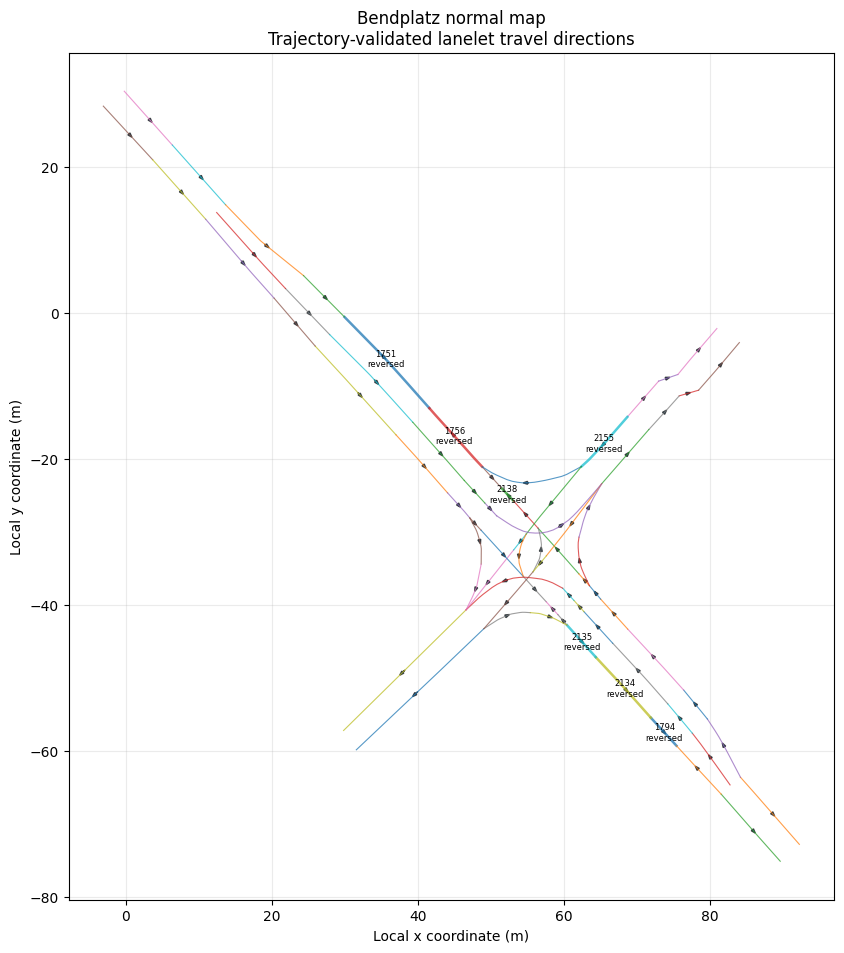

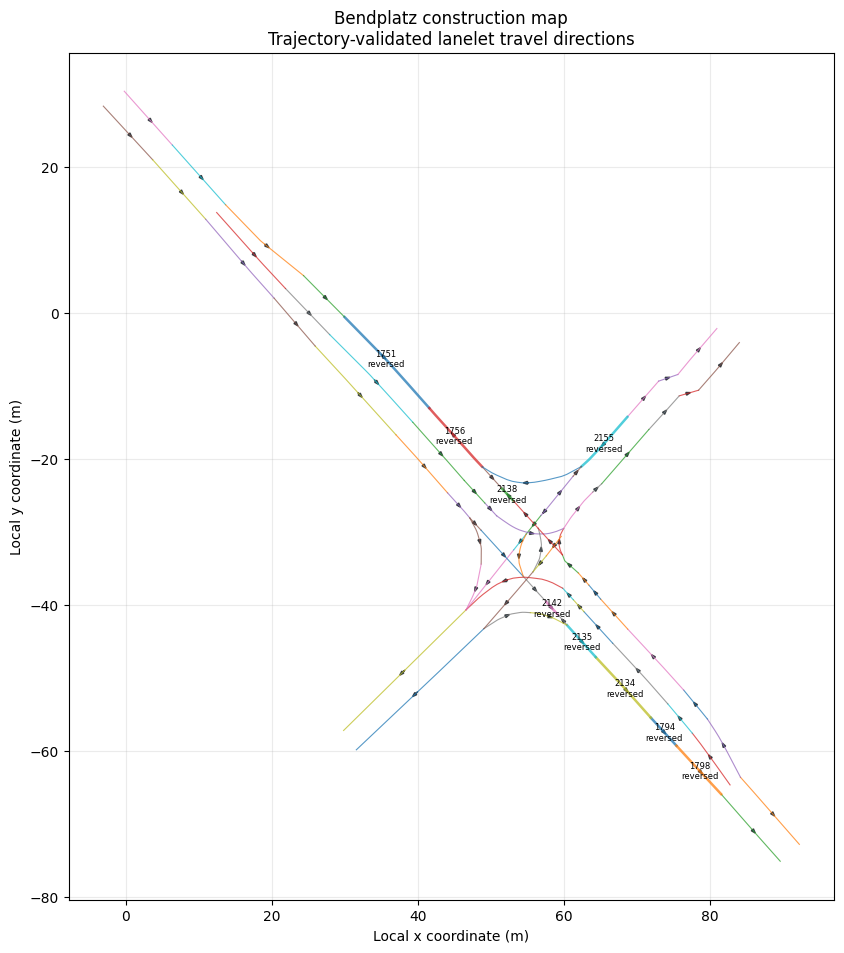


CELL 9B COMPLETED
Lanelet travel direction was evaluated using measured inD vehicle velocity.
Evidence was aggregated per independent vehicle track, and automatic reversal required a statistically significant exact binomial result.

The active lanelet records and connectivity graph now use the corrected directions.

Inspect:
  1. The list of statistically supported reversed lanelets.
  2. The before/after graph comparison.
  3. Whether edges with heading changes above 90 degrees decreased.
  4. Whether direction arrows follow the observed traffic flow.

After validating this output, rerun Cell 10B so the approach and departure classification uses the corrected directed graph.


In [ ]:
# Cell 9B — Validate and correct lanelet travel direction
#           using observed inD vehicle motion

# Purpose
# -------
# Lanelet boundary-node order does not always prove the actual direction
# in which vehicles travel.
#
# This cell uses measured inD vehicle velocity to validate direction:
#
#   trajectory point inside a lanelet
#                 ↓
#   measured vehicle velocity vector
#                 ↓
#   nearest centerline segment direction
#                 ↓
#   cosine similarity
#
# Interpretation:
#
#   cosine near +1 -> vehicle follows current centerline direction
#   cosine near -1 -> vehicle follows the opposite direction
#
# Evidence is aggregated per independent vehicle track, not per frame,
# to avoid treating many correlated frames as independent observations.
#
# Recording-to-map pairing:
#
#   recording 07 -> normal Bendplatz map
#   recording 11 -> construction Bendplatz map
#
# After corrections, this cell rebuilds the directed connectivity graph.

from pathlib import Path
from collections import defaultdict
import copy
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import Point


# ============================================================
# 1. IMPORT THE EXACT BINOMIAL TEST
# ============================================================

try:
    from scipy.stats import binomtest
except ImportError:
    print("SciPy is not installed. Installing it now...")

    !pip -q install scipy

    from scipy.stats import binomtest


# ============================================================
# 2. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "NORMAL_ROAD_LANELETS",
    "CONSTRUCTION_ROAD_LANELETS",
    "NORMAL_LANELET_POLYGON_LOOKUP",
    "CONSTRUCTION_LANELET_POLYGON_LOOKUP",
    "NORMAL_WAY_LOOKUP",
    "CONSTRUCTION_WAY_LOOKUP",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cells 7, 8 and 9 before Cell 9B. "
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 3. CONFIGURATION
# ============================================================

# Only moving vehicle observations are useful for direction inference.
MINIMUM_DIRECTION_SPEED_MPS = 1.0

# Sample observations at approximately 2 Hz.
#
# inD recordings normally use 25 Hz. The actual frame rate is read from
# recordingMeta.csv where possible.
DIRECTION_SAMPLE_RATE_HZ = 2.0

# A small polygon buffer handles tiny numeric differences between
# trajectory points and mapped lane boundaries.
POLYGON_NUMERIC_BUFFER_M = 0.10

# A track-lanelet assignment is accepted only if the median alignment is
# clearly positive or negative.
TRACK_DIRECTION_COSINE_MARGIN = 0.20

# Statistical significance level for the exact binomial test.
DIRECTION_SIGNIFICANCE_LEVEL = 0.01

# At least three independent vehicle tracks must support an automatic
# lanelet reversal.
MINIMUM_INDEPENDENT_TRACKS = 3


# ============================================================
# 4. LOCATE AND LOAD A RECORDING
# ============================================================

def locate_unique_dataset_file(root, filename):
    """
    Locate one file recursively below the dataset root.
    """
    root = Path(root)
    matches = sorted(root.rglob(filename))

    if not matches:
        raise FileNotFoundError(
            f"Could not locate {filename} below:\n{root}"
        )

    if len(matches) > 1:
        warnings.warn(
            f"Multiple copies of {filename} were found. "
            f"Using:\n{matches[0]}"
        )

    return matches[0]


if "IND_DATASET_ROOT" in globals():
    DIRECTION_DATASET_ROOT = Path(IND_DATASET_ROOT)
elif "DATASET_ROOT" in globals():
    DIRECTION_DATASET_ROOT = Path(DATASET_ROOT)
else:
    DIRECTION_DATASET_ROOT = Path(
        "/content/drive/MyDrive/inD-dataset-v1.1"
    )


def load_direction_recording(recording_id):
    """
    Load tracks, track metadata and recording metadata.
    """
    recording_key = f"{int(recording_id):02d}"

    tracks_path = locate_unique_dataset_file(
        DIRECTION_DATASET_ROOT,
        f"{recording_key}_tracks.csv",
    )

    tracks_meta_path = locate_unique_dataset_file(
        DIRECTION_DATASET_ROOT,
        f"{recording_key}_tracksMeta.csv",
    )

    recording_meta_path = locate_unique_dataset_file(
        DIRECTION_DATASET_ROOT,
        f"{recording_key}_recordingMeta.csv",
    )

    tracks = pd.read_csv(tracks_path)
    tracks_meta = pd.read_csv(tracks_meta_path)
    recording_meta = pd.read_csv(recording_meta_path)

    return {
        "recording_id": int(recording_id),
        "recording_key": recording_key,
        "tracks": tracks,
        "tracks_meta": tracks_meta,
        "recording_meta": recording_meta,
        "tracks_path": tracks_path,
        "tracks_meta_path": tracks_meta_path,
        "recording_meta_path": recording_meta_path,
    }


NORMAL_DIRECTION_RECORDING = load_direction_recording(7)
CONSTRUCTION_DIRECTION_RECORDING = load_direction_recording(11)

print("Direction-validation recordings:")
print(
    "  Normal map:",
    NORMAL_DIRECTION_RECORDING["tracks_path"],
)
print(
    "  Construction map:",
    CONSTRUCTION_DIRECTION_RECORDING["tracks_path"],
)


# ============================================================
# 5. PREPARE VEHICLE MOTION OBSERVATIONS
# ============================================================

ROAD_VEHICLE_CLASSES = {
    "car",
    "truck_bus",
    "truck",
    "bus",
    "van",
    "motorcycle",
    "motorbike",
    "vehicle",
}


def detect_column(dataframe, candidates, purpose):
    """
    Return the first available column from candidates.
    """
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    raise ValueError(
        f"Could not detect {purpose}. "
        f"Tried {candidates}. "
        f"Available columns: {list(dataframe.columns)}"
    )


def read_recording_frame_rate(recording_meta):
    """
    Read the recording frame rate where available.
    """
    for candidate in [
        "frameRate",
        "frame_rate",
        "framerate",
    ]:
        if candidate in recording_meta.columns:
            value = float(recording_meta.iloc[0][candidate])

            if np.isfinite(value) and value > 0:
                return value

    warnings.warn(
        "Frame rate was not found in recording metadata. "
        "Using the documented inD value of 25 Hz."
    )

    return 25.0


def prepare_vehicle_motion_observations(recording):
    """
    Create sampled moving-vehicle observations.
    """
    tracks = recording["tracks"].copy()
    tracks_meta = recording["tracks_meta"].copy()

    track_id_column = detect_column(
        tracks,
        ["trackId", "track_id", "id"],
        "track ID column",
    )

    frame_column = detect_column(
        tracks,
        ["frame", "frameId", "frame_id"],
        "frame column",
    )

    x_column = detect_column(
        tracks,
        ["xCenter", "x_center", "x"],
        "x-coordinate column",
    )

    y_column = detect_column(
        tracks,
        ["yCenter", "y_center", "y"],
        "y-coordinate column",
    )

    x_velocity_column = detect_column(
        tracks,
        ["xVelocity", "x_velocity", "vx"],
        "x-velocity column",
    )

    y_velocity_column = detect_column(
        tracks,
        ["yVelocity", "y_velocity", "vy"],
        "y-velocity column",
    )

    metadata_track_id_column = detect_column(
        tracks_meta,
        ["trackId", "track_id", "id"],
        "metadata track ID column",
    )

    class_column = detect_column(
        tracks_meta,
        ["class", "objectClass", "object_class", "type"],
        "object class column",
    )

    class_table = tracks_meta[
        [metadata_track_id_column, class_column]
    ].rename(
        columns={
            metadata_track_id_column: track_id_column
        }
    )

    observations = tracks.merge(
        class_table,
        on=track_id_column,
        how="left",
        validate="many_to_one",
    )

    normalized_class = (
        observations[class_column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    observations = observations[
        normalized_class.isin(ROAD_VEHICLE_CLASSES)
    ].copy()

    numeric_columns = [
        frame_column,
        x_column,
        y_column,
        x_velocity_column,
        y_velocity_column,
    ]

    for column in numeric_columns:
        observations[column] = pd.to_numeric(
            observations[column],
            errors="coerce",
        )

    observations = observations.dropna(
        subset=[
            track_id_column,
            frame_column,
            x_column,
            y_column,
            x_velocity_column,
            y_velocity_column,
        ]
    )

    observations["direction_speed_mps"] = np.hypot(
        observations[x_velocity_column],
        observations[y_velocity_column],
    )

    observations = observations[
        observations["direction_speed_mps"]
        >= MINIMUM_DIRECTION_SPEED_MPS
    ].copy()

    frame_rate = read_recording_frame_rate(
        recording["recording_meta"]
    )

    sampling_interval_frames = max(
        1,
        int(round(frame_rate / DIRECTION_SAMPLE_RATE_HZ)),
    )

    observations = observations[
        (
            observations[frame_column].astype(int)
            % sampling_interval_frames
        ) == 0
    ].copy()

    observations = observations.sort_values(
        [track_id_column, frame_column]
    ).reset_index(drop=True)

    column_config = {
        "track_id": track_id_column,
        "frame": frame_column,
        "x": x_column,
        "y": y_column,
        "vx": x_velocity_column,
        "vy": y_velocity_column,
        "class": class_column,
        "frame_rate": frame_rate,
        "sampling_interval_frames":
            sampling_interval_frames,
    }

    return observations, column_config


(
    NORMAL_DIRECTION_OBSERVATIONS,
    NORMAL_DIRECTION_COLUMN_CONFIG,
) = prepare_vehicle_motion_observations(
    NORMAL_DIRECTION_RECORDING
)

(
    CONSTRUCTION_DIRECTION_OBSERVATIONS,
    CONSTRUCTION_DIRECTION_COLUMN_CONFIG,
) = prepare_vehicle_motion_observations(
    CONSTRUCTION_DIRECTION_RECORDING
)

print("\nSampled moving-vehicle observations:")
print(
    "  Normal recording 07:",
    len(NORMAL_DIRECTION_OBSERVATIONS),
)
print(
    "  Construction recording 11:",
    len(CONSTRUCTION_DIRECTION_OBSERVATIONS),
)


# ============================================================
# 6. CENTERLINE ALIGNMENT CALCULATION
# ============================================================

def nearest_centerline_segment_alignment(
    point_xy,
    velocity_xy,
    centerline,
):
    """
    Compare vehicle velocity with the nearest centerline segment.

    Returns
    -------
    cosine_similarity : float
        +1 means same direction.
        -1 means opposite direction.

    distance_to_centerline : float
        Distance from point to nearest centerline segment.
    """
    point_xy = np.asarray(point_xy, dtype=float)
    velocity_xy = np.asarray(velocity_xy, dtype=float)
    centerline = np.asarray(centerline, dtype=float)

    segment_starts = centerline[:-1]
    segment_ends = centerline[1:]
    segment_vectors = segment_ends - segment_starts

    segment_squared_lengths = np.sum(
        segment_vectors ** 2,
        axis=1,
    )

    valid_segments = segment_squared_lengths > 1e-12

    if not valid_segments.any():
        return np.nan, np.nan

    segment_starts = segment_starts[valid_segments]
    segment_vectors = segment_vectors[valid_segments]
    segment_squared_lengths = (
        segment_squared_lengths[valid_segments]
    )

    point_offsets = point_xy - segment_starts

    projection_parameters = np.sum(
        point_offsets * segment_vectors,
        axis=1,
    ) / segment_squared_lengths

    projection_parameters = np.clip(
        projection_parameters,
        0.0,
        1.0,
    )

    projected_points = (
        segment_starts
        + projection_parameters[:, None]
        * segment_vectors
    )

    distances = np.linalg.norm(
        projected_points - point_xy,
        axis=1,
    )

    nearest_index = int(np.argmin(distances))
    nearest_segment = segment_vectors[nearest_index]

    velocity_norm = np.linalg.norm(velocity_xy)
    segment_norm = np.linalg.norm(nearest_segment)

    if velocity_norm <= 0 or segment_norm <= 0:
        return np.nan, float(distances[nearest_index])

    cosine_similarity = float(
        np.dot(velocity_xy, nearest_segment)
        / (velocity_norm * segment_norm)
    )

    cosine_similarity = float(
        np.clip(cosine_similarity, -1.0, 1.0)
    )

    return (
        cosine_similarity,
        float(distances[nearest_index]),
    )


# ============================================================
# 7. ASSIGN UNAMBIGUOUS OBSERVATIONS TO LANELETS
# ============================================================

def create_polygon_spatial_index(polygon_lookup):
    """
    Store buffered polygons and bounding boxes.
    """
    index = []

    for lanelet_id, polygon in polygon_lookup.items():
        buffered_polygon = polygon.buffer(
            POLYGON_NUMERIC_BUFFER_M
        )

        index.append({
            "lanelet_id": lanelet_id,
            "polygon": buffered_polygon,
            "bounds": buffered_polygon.bounds,
        })

    return index


def assign_motion_to_lanelets(
    observations,
    column_config,
    lanelet_records,
    polygon_lookup,
    map_variant,
):
    """
    Assign each sampled observation to a lanelet.

    Only points contained by exactly one lanelet polygon are retained.
    Points in overlapping central polygons are intentionally rejected
    because their lanelet identity is ambiguous.
    """
    record_lookup = {
        record["lanelet_id"]: record
        for record in lanelet_records
    }

    spatial_index = create_polygon_spatial_index(
        polygon_lookup
    )

    assigned_rows = []
    ambiguous_count = 0
    outside_count = 0

    for row in observations.itertuples(index=False):
        row_values = row._asdict()

        x = float(row_values[column_config["x"]])
        y = float(row_values[column_config["y"]])

        candidate_ids = []

        for item in spatial_index:
            minimum_x, minimum_y, maximum_x, maximum_y = (
                item["bounds"]
            )

            if not (
                minimum_x <= x <= maximum_x
                and minimum_y <= y <= maximum_y
            ):
                continue

            if item["polygon"].covers(Point(x, y)):
                candidate_ids.append(item["lanelet_id"])

        if len(candidate_ids) == 0:
            outside_count += 1
            continue

        if len(candidate_ids) != 1:
            ambiguous_count += 1
            continue

        lanelet_id = candidate_ids[0]
        record = record_lookup[lanelet_id]

        velocity = np.array([
            float(row_values[column_config["vx"]]),
            float(row_values[column_config["vy"]]),
        ])

        cosine_similarity, centerline_distance = (
            nearest_centerline_segment_alignment(
                point_xy=np.array([x, y]),
                velocity_xy=velocity,
                centerline=record["centerline"],
            )
        )

        if not np.isfinite(cosine_similarity):
            continue

        assigned_rows.append({
            "map_variant": map_variant,
            "recording_id":
                int(row_values.get("recordingId", -1)),
            "track_id":
                row_values[column_config["track_id"]],
            "frame":
                row_values[column_config["frame"]],
            "lanelet_id": lanelet_id,
            "x": x,
            "y": y,
            "vx": velocity[0],
            "vy": velocity[1],
            "speed_mps": float(
                np.linalg.norm(velocity)
            ),
            "direction_cosine": cosine_similarity,
            "distance_to_centerline_m":
                centerline_distance,
        })

    assignment_df = pd.DataFrame(assigned_rows)

    diagnostics = {
        "input_observations": len(observations),
        "assigned_observations": len(assignment_df),
        "ambiguous_observations": ambiguous_count,
        "outside_observations": outside_count,
    }

    return assignment_df, diagnostics


(
    NORMAL_LANELET_MOTION_ASSIGNMENTS,
    NORMAL_ASSIGNMENT_DIAGNOSTICS,
) = assign_motion_to_lanelets(
    observations=NORMAL_DIRECTION_OBSERVATIONS,
    column_config=NORMAL_DIRECTION_COLUMN_CONFIG,
    lanelet_records=NORMAL_ROAD_LANELETS,
    polygon_lookup=NORMAL_LANELET_POLYGON_LOOKUP,
    map_variant="normal",
)

(
    CONSTRUCTION_LANELET_MOTION_ASSIGNMENTS,
    CONSTRUCTION_ASSIGNMENT_DIAGNOSTICS,
) = assign_motion_to_lanelets(
    observations=CONSTRUCTION_DIRECTION_OBSERVATIONS,
    column_config=CONSTRUCTION_DIRECTION_COLUMN_CONFIG,
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    polygon_lookup=CONSTRUCTION_LANELET_POLYGON_LOOKUP,
    map_variant="construction",
)

print("\nAssignment diagnostics:")
print("  Normal:", NORMAL_ASSIGNMENT_DIAGNOSTICS)
print(
    "  Construction:",
    CONSTRUCTION_ASSIGNMENT_DIAGNOSTICS,
)


# ============================================================
# 8. AGGREGATE EVIDENCE PER INDEPENDENT TRACK
# ============================================================

def create_track_level_direction_votes(assignments):
    """
    Reduce repeated frame observations to one vote per track-lanelet pair.
    """
    if assignments.empty:
        return pd.DataFrame()

    track_votes = (
        assignments
        .groupby(
            ["map_variant", "lanelet_id", "track_id"],
            as_index=False,
        )
        .agg(
            observation_count=("direction_cosine", "size"),
            median_direction_cosine=(
                "direction_cosine",
                "median",
            ),
            mean_centerline_distance_m=(
                "distance_to_centerline_m",
                "mean",
            ),
        )
    )

    track_votes["track_direction_vote"] = np.select(
        [
            track_votes["median_direction_cosine"]
            >= TRACK_DIRECTION_COSINE_MARGIN,

            track_votes["median_direction_cosine"]
            <= -TRACK_DIRECTION_COSINE_MARGIN,
        ],
        [
            "supports_current",
            "supports_reverse",
        ],
        default="uncertain",
    )

    return track_votes


NORMAL_TRACK_DIRECTION_VOTES = (
    create_track_level_direction_votes(
        NORMAL_LANELET_MOTION_ASSIGNMENTS
    )
)

CONSTRUCTION_TRACK_DIRECTION_VOTES = (
    create_track_level_direction_votes(
        CONSTRUCTION_LANELET_MOTION_ASSIGNMENTS
    )
)


# ============================================================
# 9. EXACT STATISTICAL DIRECTION DECISION
# ============================================================

def summarize_lanelet_direction_evidence(
    track_votes,
    lanelet_records,
    map_variant,
):
    """
    Determine whether each lanelet should retain or reverse direction.

    The exact two-sided binomial test evaluates whether the split between
    current-direction and reverse-direction track votes differs from 50/50.
    """
    rows = []

    for record in lanelet_records:
        lanelet_id = record["lanelet_id"]

        lanelet_votes = track_votes[
            track_votes["lanelet_id"] == lanelet_id
        ].copy()

        positive_votes = int(
            (
                lanelet_votes["track_direction_vote"]
                == "supports_current"
            ).sum()
        )

        negative_votes = int(
            (
                lanelet_votes["track_direction_vote"]
                == "supports_reverse"
            ).sum()
        )

        uncertain_votes = int(
            (
                lanelet_votes["track_direction_vote"]
                == "uncertain"
            ).sum()
        )

        decisive_votes = positive_votes + negative_votes

        if decisive_votes > 0:
            reverse_fraction = (
                negative_votes / decisive_votes
            )

            binomial_result = binomtest(
                k=negative_votes,
                n=decisive_votes,
                p=0.5,
                alternative="two-sided",
            )

            p_value = float(binomial_result.pvalue)
        else:
            reverse_fraction = np.nan
            p_value = np.nan

        should_reverse = (
            decisive_votes >= MINIMUM_INDEPENDENT_TRACKS
            and negative_votes > positive_votes
            and p_value < DIRECTION_SIGNIFICANCE_LEVEL
        )

        if should_reverse:
            decision = "reverse"

        elif (
            decisive_votes >= MINIMUM_INDEPENDENT_TRACKS
            and positive_votes > negative_votes
            and p_value < DIRECTION_SIGNIFICANCE_LEVEL
        ):
            decision = "keep"

        else:
            decision = "insufficient_or_mixed_evidence"

        rows.append({
            "map_variant": map_variant,
            "lanelet_id": lanelet_id,
            "current_heading_degrees":
                record["heading_degrees"],
            "tracks_supporting_current":
                positive_votes,
            "tracks_supporting_reverse":
                negative_votes,
            "uncertain_tracks":
                uncertain_votes,
            "decisive_track_count":
                decisive_votes,
            "reverse_vote_fraction":
                reverse_fraction,
            "binomial_p_value":
                p_value,
            "direction_decision":
                decision,
            "should_reverse":
                should_reverse,
        })

    return pd.DataFrame(rows)


NORMAL_DIRECTION_EVIDENCE = (
    summarize_lanelet_direction_evidence(
        NORMAL_TRACK_DIRECTION_VOTES,
        NORMAL_ROAD_LANELETS,
        map_variant="normal",
    )
)

CONSTRUCTION_DIRECTION_EVIDENCE = (
    summarize_lanelet_direction_evidence(
        CONSTRUCTION_TRACK_DIRECTION_VOTES,
        CONSTRUCTION_ROAD_LANELETS,
        map_variant="construction",
    )
)


# ============================================================
# 10. REVERSE SUPPORTED LANELETS
# ============================================================

def reverse_lanelet_travel_direction(record):
    """
    Reverse travel-related geometry while preserving the polygon.

    The physical polygon does not change. Only travel direction changes.
    """
    corrected = copy.deepcopy(record)

    corrected["centerline"] = (
        np.asarray(record["centerline"])[::-1].copy()
    )

    corrected["left_resampled"] = (
        np.asarray(record["right_resampled"])[::-1].copy()
    )

    corrected["right_resampled"] = (
        np.asarray(record["left_resampled"])[::-1].copy()
    )

    corrected["left_boundary"] = (
        np.asarray(record["right_boundary"])[::-1].copy()
    )

    corrected["right_boundary"] = (
        np.asarray(record["left_boundary"])[::-1].copy()
    )

    corrected["start_x"] = float(
        corrected["centerline"][0, 0]
    )

    corrected["start_y"] = float(
        corrected["centerline"][0, 1]
    )

    corrected["end_x"] = float(
        corrected["centerline"][-1, 0]
    )

    corrected["end_y"] = float(
        corrected["centerline"][-1, 1]
    )

    corrected["heading_degrees"] = float(
        np.degrees(
            np.arctan2(
                corrected["end_y"] - corrected["start_y"],
                corrected["end_x"] - corrected["start_x"],
            )
        )
    )

    corrected["travel_direction_reversed"] = True

    return corrected


def apply_direction_corrections(
    lanelet_records,
    evidence_df,
):
    """
    Apply only statistically supported reversals.
    """
    reverse_ids = set(
        evidence_df.loc[
            evidence_df["should_reverse"],
            "lanelet_id",
        ]
    )

    corrected_records = []

    for record in lanelet_records:
        if record["lanelet_id"] in reverse_ids:
            corrected_records.append(
                reverse_lanelet_travel_direction(record)
            )
        else:
            corrected = copy.deepcopy(record)
            corrected["travel_direction_reversed"] = False
            corrected_records.append(corrected)

    return corrected_records, sorted(reverse_ids)


(
    NORMAL_CORRECTED_ROAD_LANELETS,
    NORMAL_REVERSED_LANELET_IDS,
) = apply_direction_corrections(
    NORMAL_ROAD_LANELETS,
    NORMAL_DIRECTION_EVIDENCE,
)

(
    CONSTRUCTION_CORRECTED_ROAD_LANELETS,
    CONSTRUCTION_REVERSED_LANELET_IDS,
) = apply_direction_corrections(
    CONSTRUCTION_ROAD_LANELETS,
    CONSTRUCTION_DIRECTION_EVIDENCE,
)

print("\nStatistically supported reversals:")
print("  Normal:", NORMAL_REVERSED_LANELET_IDS)
print(
    "  Construction:",
    CONSTRUCTION_REVERSED_LANELET_IDS,
)


# ============================================================
# 11. REDEFINE ORIENTED BOUNDARY-NODE HANDLING
# ============================================================

def oriented_boundary_node_ids(record, way_lookup):
    """
    Return boundary endpoint IDs in corrected travel direction.

    Cell 8 first aligned the right boundary to the left boundary.
    Cell 9B may then reverse the complete travel direction.
    """
    original_left_ids = get_way_node_ids(
        way_lookup[record["left_way_id"]]
    )

    original_right_ids = get_way_node_ids(
        way_lookup[record["right_way_id"]]
    )

    if record["right_boundary_reversed"]:
        original_right_ids = original_right_ids[::-1]

    if record.get("travel_direction_reversed", False):
        corrected_left_ids = original_right_ids[::-1]
        corrected_right_ids = original_left_ids[::-1]
    else:
        corrected_left_ids = original_left_ids
        corrected_right_ids = original_right_ids

    return {
        "left_node_ids": corrected_left_ids,
        "right_node_ids": corrected_right_ids,

        "start_left_node_id": corrected_left_ids[0],
        "start_right_node_id": corrected_right_ids[0],

        "end_left_node_id": corrected_left_ids[-1],
        "end_right_node_id": corrected_right_ids[-1],
    }


# ============================================================
# 12. REBUILD CONNECTIVITY USING CORRECTED DIRECTIONS
# ============================================================

(
    NORMAL_CORRECTED_LANELET_ENDPOINTS,
    NORMAL_CORRECTED_ENDPOINT_LOOKUP,
) = build_lanelet_endpoint_table(
    lanelet_records=NORMAL_CORRECTED_ROAD_LANELETS,
    way_lookup=NORMAL_WAY_LOOKUP,
    map_variant="normal",
)

(
    CONSTRUCTION_CORRECTED_LANELET_ENDPOINTS,
    CONSTRUCTION_CORRECTED_ENDPOINT_LOOKUP,
) = build_lanelet_endpoint_table(
    lanelet_records=CONSTRUCTION_CORRECTED_ROAD_LANELETS,
    way_lookup=CONSTRUCTION_WAY_LOOKUP,
    map_variant="construction",
)

NORMAL_CORRECTED_CONNECTIVITY_EDGES = (
    derive_exact_topological_edges(
        lanelet_records=NORMAL_CORRECTED_ROAD_LANELETS,
        endpoint_lookup=NORMAL_CORRECTED_ENDPOINT_LOOKUP,
        map_variant="normal",
    )
)

CONSTRUCTION_CORRECTED_CONNECTIVITY_EDGES = (
    derive_exact_topological_edges(
        lanelet_records=CONSTRUCTION_CORRECTED_ROAD_LANELETS,
        endpoint_lookup=(
            CONSTRUCTION_CORRECTED_ENDPOINT_LOOKUP
        ),
        map_variant="construction",
    )
)

(
    NORMAL_CORRECTED_PREDECESSORS,
    NORMAL_CORRECTED_SUCCESSORS,
) = build_directed_graph(
    lanelet_records=NORMAL_CORRECTED_ROAD_LANELETS,
    edge_df=NORMAL_CORRECTED_CONNECTIVITY_EDGES,
)

(
    CONSTRUCTION_CORRECTED_PREDECESSORS,
    CONSTRUCTION_CORRECTED_SUCCESSORS,
) = build_directed_graph(
    lanelet_records=CONSTRUCTION_CORRECTED_ROAD_LANELETS,
    edge_df=CONSTRUCTION_CORRECTED_CONNECTIVITY_EDGES,
)

NORMAL_CORRECTED_GRAPH_SUMMARY = summarize_lanelet_graph(
    lanelet_records=NORMAL_CORRECTED_ROAD_LANELETS,
    predecessors=NORMAL_CORRECTED_PREDECESSORS,
    successors=NORMAL_CORRECTED_SUCCESSORS,
    map_variant="normal",
)

CONSTRUCTION_CORRECTED_GRAPH_SUMMARY = (
    summarize_lanelet_graph(
        lanelet_records=(
            CONSTRUCTION_CORRECTED_ROAD_LANELETS
        ),
        predecessors=(
            CONSTRUCTION_CORRECTED_PREDECESSORS
        ),
        successors=(
            CONSTRUCTION_CORRECTED_SUCCESSORS
        ),
        map_variant="construction",
    )
)


# ============================================================
# 13. COMPARE GRAPH QUALITY BEFORE AND AFTER
# ============================================================

def graph_quality_row(
    map_variant,
    stage,
    lanelet_records,
    edge_df,
    graph_summary,
):
    """
    Create graph-quality summary.
    """
    large_heading_changes = (
        edge_df["heading_change_degrees"] > 90.0
    ).sum() if not edge_df.empty else 0

    return {
        "map_variant": map_variant,
        "stage": stage,
        "lanelets": len(lanelet_records),
        "directed_edges": len(edge_df),
        "source_lanelets": int(
            (graph_summary["graph_role"] == "source").sum()
        ),
        "sink_lanelets": int(
            (graph_summary["graph_role"] == "sink").sum()
        ),
        "internal_lanelets": int(
            (graph_summary["graph_role"] == "internal").sum()
        ),
        "isolated_lanelets": int(
            (graph_summary["graph_role"] == "isolated").sum()
        ),
        "edges_over_90_degree_change":
            int(large_heading_changes),
        "maximum_heading_change_degrees": (
            float(edge_df["heading_change_degrees"].max())
            if not edge_df.empty
            else np.nan
        ),
    }


DIRECTION_CORRECTION_GRAPH_COMPARISON = pd.DataFrame([
    graph_quality_row(
        "normal",
        "before correction",
        NORMAL_ROAD_LANELETS,
        NORMAL_EXACT_CONNECTIVITY_EDGES,
        NORMAL_LANELET_GRAPH_SUMMARY,
    ),
    graph_quality_row(
        "normal",
        "after correction",
        NORMAL_CORRECTED_ROAD_LANELETS,
        NORMAL_CORRECTED_CONNECTIVITY_EDGES,
        NORMAL_CORRECTED_GRAPH_SUMMARY,
    ),
    graph_quality_row(
        "construction",
        "before correction",
        CONSTRUCTION_ROAD_LANELETS,
        CONSTRUCTION_EXACT_CONNECTIVITY_EDGES,
        CONSTRUCTION_LANELET_GRAPH_SUMMARY,
    ),
    graph_quality_row(
        "construction",
        "after correction",
        CONSTRUCTION_CORRECTED_ROAD_LANELETS,
        CONSTRUCTION_CORRECTED_CONNECTIVITY_EDGES,
        CONSTRUCTION_CORRECTED_GRAPH_SUMMARY,
    ),
])

print("\n" + "=" * 80)
print("DIRECTION-CORRECTION GRAPH COMPARISON")
print("=" * 80)

display(DIRECTION_CORRECTION_GRAPH_COMPARISON)


# ============================================================
# 14. DISPLAY DIRECTION EVIDENCE
# ============================================================

print("\nNormal-map direction evidence:")
display(
    NORMAL_DIRECTION_EVIDENCE.sort_values(
        [
            "should_reverse",
            "decisive_track_count",
        ],
        ascending=[False, False],
    )
)

print("\nConstruction-map direction evidence:")
display(
    CONSTRUCTION_DIRECTION_EVIDENCE.sort_values(
        [
            "should_reverse",
            "decisive_track_count",
        ],
        ascending=[False, False],
    )
)


# ============================================================
# 15. PLOT CORRECTED DIRECTIONS
# ============================================================

def plot_corrected_lanelet_directions(
    lanelet_records,
    reversed_ids,
    map_name,
):
    """
    Plot corrected centerline directions.
    """
    reversed_set = set(reversed_ids)

    figure, axis = plt.subplots(figsize=(12, 11))

    for record in lanelet_records:
        centerline = np.asarray(
            record["centerline"],
            dtype=float,
        )

        lanelet_id = record["lanelet_id"]

        axis.plot(
            centerline[:, 0],
            centerline[:, 1],
            linewidth=(
                1.8 if lanelet_id in reversed_set else 0.8
            ),
            alpha=0.75,
        )

        middle_index = min(
            len(centerline) - 2,
            max(0, len(centerline) // 2),
        )

        start = centerline[middle_index]
        end = centerline[middle_index + 1]
        vector = end - start

        axis.arrow(
            start[0],
            start[1],
            vector[0],
            vector[1],
            head_width=0.40,
            head_length=0.60,
            length_includes_head=True,
            alpha=0.7,
        )

        if lanelet_id in reversed_set:
            midpoint = centerline[len(centerline) // 2]

            axis.text(
                midpoint[0],
                midpoint[1],
                f"{lanelet_id}\nreversed",
                fontsize=6,
                ha="center",
                va="center",
            )

    axis.set_title(
        f"{map_name}\n"
        "Trajectory-validated lanelet travel directions"
    )

    axis.set_xlabel("Local x coordinate (m)")
    axis.set_ylabel("Local y coordinate (m)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.25)

    plt.show()


plot_corrected_lanelet_directions(
    NORMAL_CORRECTED_ROAD_LANELETS,
    NORMAL_REVERSED_LANELET_IDS,
    "Bendplatz normal map",
)

plot_corrected_lanelet_directions(
    CONSTRUCTION_CORRECTED_ROAD_LANELETS,
    CONSTRUCTION_REVERSED_LANELET_IDS,
    "Bendplatz construction map",
)


# ============================================================
# 16. REPLACE ACTIVE GRAPH VARIABLES
# ============================================================

# Preserve original outputs for comparison.
ORIGINAL_NORMAL_ROAD_LANELETS = NORMAL_ROAD_LANELETS
ORIGINAL_CONSTRUCTION_ROAD_LANELETS = (
    CONSTRUCTION_ROAD_LANELETS
)

# Replace active lanelet records.
NORMAL_ROAD_LANELETS = NORMAL_CORRECTED_ROAD_LANELETS
CONSTRUCTION_ROAD_LANELETS = (
    CONSTRUCTION_CORRECTED_ROAD_LANELETS
)

NORMAL_ROAD_LANELET_LOOKUP = {
    record["lanelet_id"]: record
    for record in NORMAL_ROAD_LANELETS
}

CONSTRUCTION_ROAD_LANELET_LOOKUP = {
    record["lanelet_id"]: record
    for record in CONSTRUCTION_ROAD_LANELETS
}

# Replace active directed graph.
NORMAL_EXACT_CONNECTIVITY_EDGES = (
    NORMAL_CORRECTED_CONNECTIVITY_EDGES
)

CONSTRUCTION_EXACT_CONNECTIVITY_EDGES = (
    CONSTRUCTION_CORRECTED_CONNECTIVITY_EDGES
)

NORMAL_LANELET_PREDECESSORS = (
    NORMAL_CORRECTED_PREDECESSORS
)

NORMAL_LANELET_SUCCESSORS = (
    NORMAL_CORRECTED_SUCCESSORS
)

CONSTRUCTION_LANELET_PREDECESSORS = (
    CONSTRUCTION_CORRECTED_PREDECESSORS
)

CONSTRUCTION_LANELET_SUCCESSORS = (
    CONSTRUCTION_CORRECTED_SUCCESSORS
)

NORMAL_LANELET_GRAPH_SUMMARY = (
    NORMAL_CORRECTED_GRAPH_SUMMARY
)

CONSTRUCTION_LANELET_GRAPH_SUMMARY = (
    CONSTRUCTION_CORRECTED_GRAPH_SUMMARY
)

LANELET_CONNECTIVITY_EDGES = {
    "normal": NORMAL_EXACT_CONNECTIVITY_EDGES,
    "construction":
        CONSTRUCTION_EXACT_CONNECTIVITY_EDGES,
}

LANELET_PREDECESSORS = {
    "normal": NORMAL_LANELET_PREDECESSORS,
    "construction":
        CONSTRUCTION_LANELET_PREDECESSORS,
}

LANELET_SUCCESSORS = {
    "normal": NORMAL_LANELET_SUCCESSORS,
    "construction":
        CONSTRUCTION_LANELET_SUCCESSORS,
}


# ============================================================
# 17. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 9B COMPLETED")
print("=" * 80)

print(
    "Lanelet travel direction was evaluated using measured inD "
    "vehicle velocity."
)

print(
    "Evidence was aggregated per independent vehicle track, and "
    "automatic reversal required a statistically significant exact "
    "binomial result."
)

print(
    "\nThe active lanelet records and connectivity graph now use "
    "the corrected directions."
)

print(
    "\nInspect:"
)

print(
    "  1. The list of statistically supported reversed lanelets."
)

print(
    "  2. The before/after graph comparison."
)

print(
    "  3. Whether edges with heading changes above 90 degrees "
    "decreased."
)

print(
    "  4. Whether direction arrows follow the observed traffic flow."
)

print(
    "\nAfter validating this output, rerun Cell 10B so the approach "
    "and departure classification uses the corrected directed graph."
)


Positive-area lanelet overlaps:
  Normal: 56
  Construction: 62

Data-derived conflict expansion:
  Normal median lane width: 3.326 m
  Normal expansion distance: 1.663 m
  Construction median lane width: 3.343 m
  Construction expansion distance: 1.672 m

REFINED INTERSECTION DETECTION SUMMARY


,map_variant,positive_polygon_overlaps,conflict_area_m2,intersection_connector_lanelets,approach_lanelets,departure_lanelets,approach_arm_count,departure_arm_count,center_x,center_y,median_lane_width_m,expansion_distance_m
0,normal,56,174.616405,35,4,3,2,3,55.779854,-32.255421,3.325904,1.662952
1,construction,62,135.238537,35,5,3,3,3,53.740505,-33.401877,3.343192,1.671596



Normal intersection connector lanelets:
[1715, 1761, 1763, 1780, 1802, 1896, 2138, 2139, 2140, 2141, 2142, 2143, 2145, 2146, 2147, 2148, 2149, 2150, 2151, 2152, 2153, 2154, 2155, 2156, 2157, 2158, 2159, 2160, 2161, 2162, 2163, 2164, 2165, 2166, 2167]

Normal approach lanelets:
[1754, 2137, 2144, 2168]

Normal departure lanelets:
[1756, 1833, 2135]

Normal approach arms:


,arm_index,mean_direction_degrees,lanelet_ids,lanelet_count
0,0,-45.051324,"[2144, 2137]",2
1,1,139.257199,"[2168, 1754]",2



Normal departure arms:


,arm_index,mean_direction_degrees,lanelet_ids,lanelet_count
0,0,-62.215007,[2135],1
1,1,46.023962,[1833],1
2,2,124.929782,[1756],1



Construction intersection connector lanelets:
[1715, 1761, 1763, 1780, 1802, 1896, 2138, 2139, 2140, 2141, 2142, 2143, 2145, 2149, 2150, 2151, 2152, 2153, 2154, 2156, 2157, 2158, 2159, 2160, 2161, 2162, 2163, 2164, 2165, 2166, 2167, 2181, 2185, 2186, 2187]

Construction approach lanelets:
[1754, 2144, 2147, 2155, 2168]

Construction departure lanelets:
[1756, 2135, 2188]

Construction approach arms:


,arm_index,mean_direction_degrees,lanelet_ids,lanelet_count
0,0,-28.583027,"[2144, 2147]",2
1,1,52.823762,[2155],1
2,2,129.757989,"[2168, 1754]",2



Construction departure arms:


,arm_index,mean_direction_degrees,lanelet_ids,lanelet_count
0,0,-52.986028,[2135],1
1,1,41.121087,[2188],1
2,2,117.795718,[1756],1


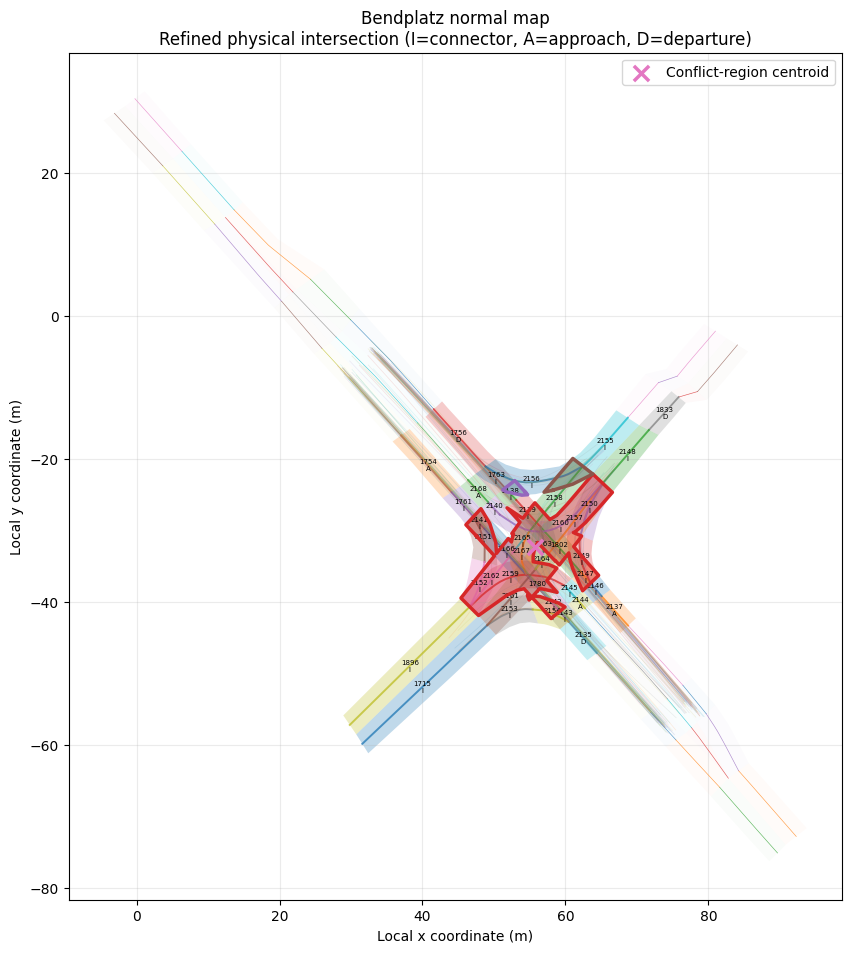

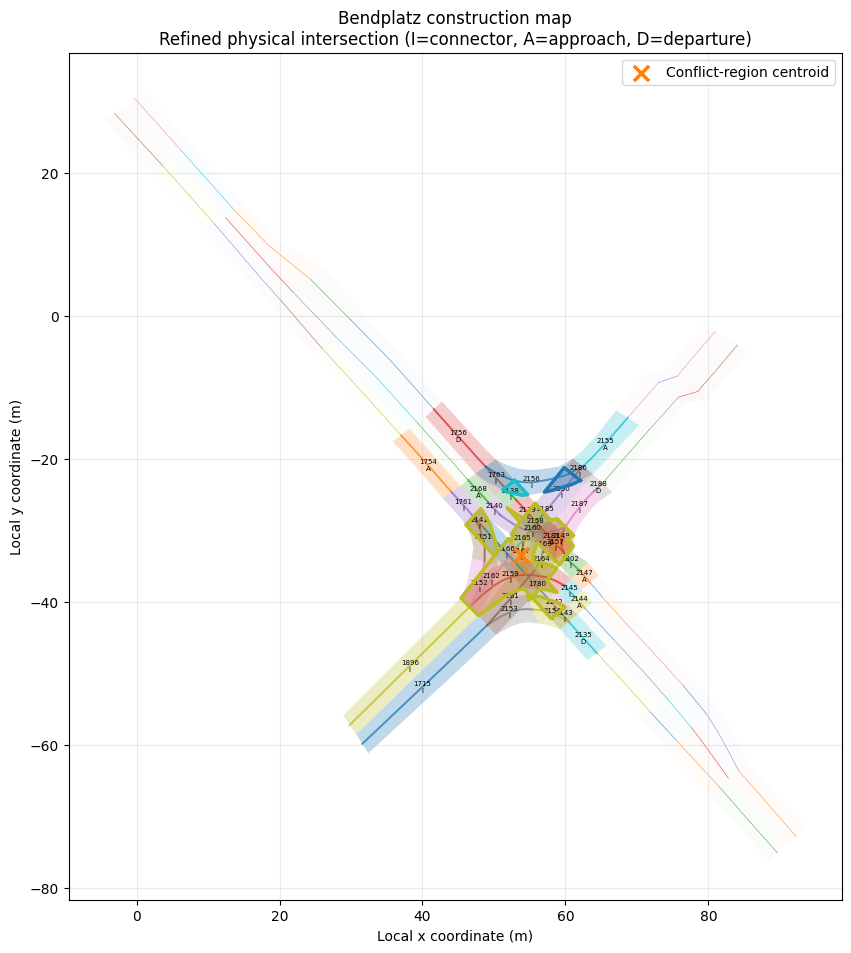


CELL 10B COMPLETED
The physical intersection was refined using positive-area overlap between lanelet polygons.
This allows geometrically crossing movement paths to be grouped even when they are disconnected in the Lanelet2 route graph.

Accept the result only when:
  1. The conflict outline remains inside the central crossing.
  2. Connector lanelets do not extend far along external roads.
  3. Approach and departure lanelets appear on several road arms.
  4. The center marker lies inside the central conflict area.

The next step, after validation, is to enumerate every directed approach-to-departure route through these connector lanelets.


In [ ]:
# Cell 10B — Refine intersection detection using geometric conflict overlaps

# Scientific idea
# ---------------
# Different movements through an intersection do not necessarily share
# Lanelet2 graph nodes. For example, a north-to-south movement and an
# east-to-west movement cross geometrically but are separate graph paths.
#
# Therefore, the physical intersection should be detected using polygon
# overlap between lanelets belonging to different movements.
#
# Pipeline:
#
#   lanelet polygons
#          ↓
#   positive-area polygon intersections
#          ↓
#   physical conflict-area union
#          ↓
#   lanelets intersecting the conflict area
#          ↓
#   limited graph expansion near the conflict area
#          ↓
#   compact intersection connector cluster
#
# This cell replaces the INTERSECTION_* outputs created by Cell 10.

from collections import defaultdict
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import Polygon
from shapely.ops import unary_union


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "NORMAL_ROAD_LANELETS",
    "CONSTRUCTION_ROAD_LANELETS",

    "NORMAL_LANELET_PREDECESSORS",
    "NORMAL_LANELET_SUCCESSORS",

    "CONSTRUCTION_LANELET_PREDECESSORS",
    "CONSTRUCTION_LANELET_SUCCESSORS",

    "NORMAL_LANELET_POLYGON_LOOKUP",
    "CONSTRUCTION_LANELET_POLYGON_LOOKUP",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cells 8, 9 and 10 before Cell 10B. "
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. BASIC GEOMETRY HELPERS
# ============================================================

def polygon_parts(geometry):
    """
    Return all polygon parts from a Polygon or MultiPolygon.
    """
    if geometry.is_empty:
        return []

    if geometry.geom_type == "Polygon":
        return [geometry]

    if geometry.geom_type == "MultiPolygon":
        return list(geometry.geoms)

    if geometry.geom_type == "GeometryCollection":
        return [
            item
            for item in geometry.geoms
            if item.geom_type in {"Polygon", "MultiPolygon"}
        ]

    return []


def calculate_lanelet_midpoint(record):
    """
    Return the middle point of a lanelet centerline.
    """
    centerline = np.asarray(
        record["centerline"],
        dtype=float,
    )

    return centerline[len(centerline) // 2]


def angular_direction_from_point(point, center):
    """
    Calculate the direction from center to point in degrees.
    """
    dx = float(point[0]) - float(center[0])
    dy = float(point[1]) - float(center[1])

    return float(
        np.degrees(np.arctan2(dy, dx))
    )


def circular_angle_difference(first, second):
    """
    Smallest absolute difference between two angles.
    """
    return abs(
        (float(first) - float(second) + 180.0)
        % 360.0
        - 180.0
    )


# ============================================================
# 3. FIND PAIRWISE LANELET OVERLAPS
# ============================================================

def calculate_lanelet_polygon_overlaps(
    lanelet_records,
    polygon_lookup,
    predecessors,
    successors,
    map_variant,
):
    """
    Calculate positive-area overlap between every lanelet pair.

    Direct predecessor-successor pairs are recorded but marked, because
    their small overlap can come from map-boundary construction rather
    than from conflicting vehicle movements.
    """

    lanelet_ids = sorted(polygon_lookup.keys())

    overlap_rows = []
    overlap_geometries = []

    successor_sets = {
        lanelet_id: set(successors[lanelet_id])
        for lanelet_id in lanelet_ids
    }

    predecessor_sets = {
        lanelet_id: set(predecessors[lanelet_id])
        for lanelet_id in lanelet_ids
    }

    for first_index in range(len(lanelet_ids)):
        first_id = lanelet_ids[first_index]
        first_polygon = polygon_lookup[first_id]

        for second_index in range(
            first_index + 1,
            len(lanelet_ids),
        ):
            second_id = lanelet_ids[second_index]
            second_polygon = polygon_lookup[second_id]

            if not first_polygon.intersects(second_polygon):
                continue

            overlap_geometry = first_polygon.intersection(
                second_polygon
            )

            overlap_area = float(overlap_geometry.area)

            # Ignore zero-area boundary contact and numerical noise.
            if overlap_area <= 1e-6:
                continue

            directly_connected = (
                second_id in successor_sets[first_id]
                or second_id in predecessor_sets[first_id]
                or first_id in successor_sets[second_id]
                or first_id in predecessor_sets[second_id]
            )

            first_area = float(first_polygon.area)
            second_area = float(second_polygon.area)

            smaller_polygon_area = min(
                first_area,
                second_area,
            )

            overlap_fraction_of_smaller = (
                overlap_area / smaller_polygon_area
                if smaller_polygon_area > 0
                else 0.0
            )

            centroid = overlap_geometry.centroid

            overlap_rows.append({
                "map_variant": map_variant,
                "first_lanelet_id": first_id,
                "second_lanelet_id": second_id,
                "directly_connected": directly_connected,
                "overlap_area_m2": overlap_area,
                "overlap_fraction_of_smaller":
                    overlap_fraction_of_smaller,
                "overlap_centroid_x": float(centroid.x),
                "overlap_centroid_y": float(centroid.y),
            })

            overlap_geometries.append({
                "first_lanelet_id": first_id,
                "second_lanelet_id": second_id,
                "directly_connected": directly_connected,
                "overlap_area_m2": overlap_area,
                "geometry": overlap_geometry,
            })

    return (
        pd.DataFrame(overlap_rows),
        overlap_geometries,
    )


(
    NORMAL_LANELET_OVERLAPS,
    NORMAL_LANELET_OVERLAP_GEOMETRIES,
) = calculate_lanelet_polygon_overlaps(
    lanelet_records=NORMAL_ROAD_LANELETS,
    polygon_lookup=NORMAL_LANELET_POLYGON_LOOKUP,
    predecessors=NORMAL_LANELET_PREDECESSORS,
    successors=NORMAL_LANELET_SUCCESSORS,
    map_variant="normal",
)

(
    CONSTRUCTION_LANELET_OVERLAPS,
    CONSTRUCTION_LANELET_OVERLAP_GEOMETRIES,
) = calculate_lanelet_polygon_overlaps(
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    polygon_lookup=CONSTRUCTION_LANELET_POLYGON_LOOKUP,
    predecessors=CONSTRUCTION_LANELET_PREDECESSORS,
    successors=CONSTRUCTION_LANELET_SUCCESSORS,
    map_variant="construction",
)


print("\nPositive-area lanelet overlaps:")
print(
    "  Normal:",
    len(NORMAL_LANELET_OVERLAPS),
)
print(
    "  Construction:",
    len(CONSTRUCTION_LANELET_OVERLAPS),
)


# ============================================================
# 4. DERIVE THE PHYSICAL CONFLICT REGION
# ============================================================

def derive_conflict_region(
    overlap_geometries,
    map_variant,
):
    """
    Derive the physical conflict region.

    Primary evidence consists of polygon overlaps between lanelets that
    are not direct predecessor-successor neighbours.

    These overlaps represent distinct movement paths occupying the same
    physical road space.
    """

    conflict_overlap_records = [
        record
        for record in overlap_geometries
        if not record["directly_connected"]
    ]

    if not conflict_overlap_records:
        warnings.warn(
            f"No non-connected lanelet overlaps were found for "
            f"the {map_variant} map. All positive overlaps will "
            "be used as fallback evidence."
        )

        conflict_overlap_records = overlap_geometries

    if not conflict_overlap_records:
        raise RuntimeError(
            f"No positive-area lanelet overlaps were found for "
            f"the {map_variant} map."
        )

    conflict_overlap_geometries = [
        record["geometry"]
        for record in conflict_overlap_records
    ]

    conflict_region = unary_union(
        conflict_overlap_geometries
    )

    involved_lanelet_ids = set()

    for record in conflict_overlap_records:
        involved_lanelet_ids.add(
            record["first_lanelet_id"]
        )
        involved_lanelet_ids.add(
            record["second_lanelet_id"]
        )

    return {
        "map_variant": map_variant,
        "geometry": conflict_region,
        "overlap_records": conflict_overlap_records,
        "involved_lanelet_ids":
            sorted(involved_lanelet_ids),
        "area_m2": float(conflict_region.area),
        "centroid": (
            float(conflict_region.centroid.x),
            float(conflict_region.centroid.y),
        ),
        "bounds": conflict_region.bounds,
    }


NORMAL_CONFLICT_REGION_RESULT = derive_conflict_region(
    NORMAL_LANELET_OVERLAP_GEOMETRIES,
    map_variant="normal",
)

CONSTRUCTION_CONFLICT_REGION_RESULT = (
    derive_conflict_region(
        CONSTRUCTION_LANELET_OVERLAP_GEOMETRIES,
        map_variant="construction",
    )
)


# ============================================================
# 5. DERIVE A DATA-BASED SPATIAL EXPANSION DISTANCE
# ============================================================

def derive_conflict_expansion_distance(lanelet_records):
    """
    Derive a small spatial expansion distance from lane width.

    Half the median lane width is used so that connector lanelets that
    reach the edge of the conflict region are included without extending
    far along external approaches.
    """

    valid_widths = [
        float(record["mean_width_m"])
        for record in lanelet_records
        if (
            np.isfinite(record["mean_width_m"])
            and record["mean_width_m"] > 0
        )
    ]

    if not valid_widths:
        raise ValueError(
            "No valid lanelet widths are available."
        )

    median_width = float(np.median(valid_widths))
    expansion_distance = median_width / 2.0

    return median_width, expansion_distance


(
    NORMAL_MEDIAN_LANE_WIDTH,
    NORMAL_CONFLICT_EXPANSION_DISTANCE,
) = derive_conflict_expansion_distance(
    NORMAL_ROAD_LANELETS
)

(
    CONSTRUCTION_MEDIAN_LANE_WIDTH,
    CONSTRUCTION_CONFLICT_EXPANSION_DISTANCE,
) = derive_conflict_expansion_distance(
    CONSTRUCTION_ROAD_LANELETS
)

print("\nData-derived conflict expansion:")
print(
    f"  Normal median lane width: "
    f"{NORMAL_MEDIAN_LANE_WIDTH:.3f} m"
)
print(
    f"  Normal expansion distance: "
    f"{NORMAL_CONFLICT_EXPANSION_DISTANCE:.3f} m"
)

print(
    f"  Construction median lane width: "
    f"{CONSTRUCTION_MEDIAN_LANE_WIDTH:.3f} m"
)
print(
    f"  Construction expansion distance: "
    f"{CONSTRUCTION_CONFLICT_EXPANSION_DISTANCE:.3f} m"
)


# ============================================================
# 6. IDENTIFY COMPACT INTERSECTION CONNECTOR LANELETS
# ============================================================

def identify_intersection_connector_lanelets(
    lanelet_records,
    polygon_lookup,
    conflict_region_result,
    predecessors,
    successors,
    expansion_distance,
    map_variant,
):
    """
    Identify compact intersection connector lanelets.

    Initial connector:
        polygon has positive-area intersection with the conflict region.

    Limited graph expansion:
        include one directly connected predecessor or successor only when
        it intersects the conflict region expanded by half the median
        lane width.

    This prevents unrestricted expansion along approach roads.
    """

    record_lookup = {
        record["lanelet_id"]: record
        for record in lanelet_records
    }

    conflict_geometry = conflict_region_result["geometry"]

    expanded_conflict_geometry = conflict_geometry.buffer(
        expansion_distance
    )

    initial_connector_ids = set()

    for lanelet_id, polygon in polygon_lookup.items():
        overlap_area = float(
            polygon.intersection(
                conflict_geometry
            ).area
        )

        if overlap_area > 1e-6:
            initial_connector_ids.add(lanelet_id)

    connector_ids = set(initial_connector_ids)

    # Only one graph-neighbour expansion pass is performed.
    neighbour_candidates = set()

    for lanelet_id in initial_connector_ids:
        neighbour_candidates.update(
            predecessors[lanelet_id]
        )
        neighbour_candidates.update(
            successors[lanelet_id]
        )

    for candidate_id in neighbour_candidates:
        if candidate_id in connector_ids:
            continue

        candidate_polygon = polygon_lookup.get(
            candidate_id
        )

        if candidate_polygon is None:
            continue

        expanded_overlap_area = float(
            candidate_polygon.intersection(
                expanded_conflict_geometry
            ).area
        )

        if expanded_overlap_area > 1e-6:
            connector_ids.add(candidate_id)

    connector_polygons = [
        polygon_lookup[lanelet_id]
        for lanelet_id in connector_ids
    ]

    connector_geometry = unary_union(
        connector_polygons
    )

    approach_ids = set()
    departure_ids = set()

    for connector_id in connector_ids:
        for predecessor_id in predecessors[connector_id]:
            if predecessor_id not in connector_ids:
                approach_ids.add(predecessor_id)

        for successor_id in successors[connector_id]:
            if successor_id not in connector_ids:
                departure_ids.add(successor_id)

    return {
        "map_variant": map_variant,
        "initial_connector_ids":
            sorted(initial_connector_ids),
        "connector_ids":
            sorted(connector_ids),
        "approach_ids":
            sorted(approach_ids),
        "departure_ids":
            sorted(departure_ids),
        "conflict_geometry":
            conflict_geometry,
        "expanded_conflict_geometry":
            expanded_conflict_geometry,
        "connector_geometry":
            connector_geometry,
        "conflict_center": (
            float(conflict_geometry.centroid.x),
            float(conflict_geometry.centroid.y),
        ),
        "connector_center": (
            float(connector_geometry.centroid.x),
            float(connector_geometry.centroid.y),
        ),
    }


NORMAL_REFINED_INTERSECTION = (
    identify_intersection_connector_lanelets(
        lanelet_records=NORMAL_ROAD_LANELETS,
        polygon_lookup=NORMAL_LANELET_POLYGON_LOOKUP,
        conflict_region_result=NORMAL_CONFLICT_REGION_RESULT,
        predecessors=NORMAL_LANELET_PREDECESSORS,
        successors=NORMAL_LANELET_SUCCESSORS,
        expansion_distance=(
            NORMAL_CONFLICT_EXPANSION_DISTANCE
        ),
        map_variant="normal",
    )
)

CONSTRUCTION_REFINED_INTERSECTION = (
    identify_intersection_connector_lanelets(
        lanelet_records=CONSTRUCTION_ROAD_LANELETS,
        polygon_lookup=(
            CONSTRUCTION_LANELET_POLYGON_LOOKUP
        ),
        conflict_region_result=(
            CONSTRUCTION_CONFLICT_REGION_RESULT
        ),
        predecessors=(
            CONSTRUCTION_LANELET_PREDECESSORS
        ),
        successors=(
            CONSTRUCTION_LANELET_SUCCESSORS
        ),
        expansion_distance=(
            CONSTRUCTION_CONFLICT_EXPANSION_DISTANCE
        ),
        map_variant="construction",
    )
)


# ============================================================
# 7. COUNT DISTINCT INTERSECTION ARMS
# ============================================================

def cluster_boundary_lanelet_directions(
    boundary_ids,
    lanelet_records,
    center,
    angular_merge_threshold_degrees=35.0,
):
    """
    Group boundary lanelets into spatial road arms.

    The angle is measured from the intersection center toward the
    midpoint of each approach/departure lanelet.

    The 35-degree value is only used to merge lanelets lying on the same
    physical road arm; the individual angles are retained for inspection.
    """

    record_lookup = {
        record["lanelet_id"]: record
        for record in lanelet_records
    }

    direction_rows = []

    for lanelet_id in boundary_ids:
        record = record_lookup[lanelet_id]
        midpoint = calculate_lanelet_midpoint(record)

        direction_angle = angular_direction_from_point(
            midpoint,
            center,
        )

        direction_rows.append({
            "lanelet_id": lanelet_id,
            "direction_angle_degrees":
                direction_angle,
            "midpoint_x": float(midpoint[0]),
            "midpoint_y": float(midpoint[1]),
        })

    direction_rows = sorted(
        direction_rows,
        key=lambda row:
            row["direction_angle_degrees"],
    )

    clusters = []

    for row in direction_rows:
        assigned = False

        for cluster in clusters:
            cluster_angles = [
                member["direction_angle_degrees"]
                for member in cluster
            ]

            # Circular mean.
            radians = np.radians(cluster_angles)

            mean_angle = np.degrees(
                np.arctan2(
                    np.mean(np.sin(radians)),
                    np.mean(np.cos(radians)),
                )
            )

            if circular_angle_difference(
                row["direction_angle_degrees"],
                mean_angle,
            ) <= angular_merge_threshold_degrees:
                cluster.append(row)
                assigned = True
                break

        if not assigned:
            clusters.append([row])

    cluster_rows = []

    for cluster_index, cluster in enumerate(clusters):
        angles = [
            member["direction_angle_degrees"]
            for member in cluster
        ]

        radians = np.radians(angles)

        mean_angle = float(
            np.degrees(
                np.arctan2(
                    np.mean(np.sin(radians)),
                    np.mean(np.cos(radians)),
                )
            )
        )

        cluster_rows.append({
            "arm_index": cluster_index,
            "mean_direction_degrees": mean_angle,
            "lanelet_ids": [
                member["lanelet_id"]
                for member in cluster
            ],
            "lanelet_count": len(cluster),
        })

    return (
        pd.DataFrame(direction_rows),
        pd.DataFrame(cluster_rows),
    )


(
    NORMAL_APPROACH_DIRECTION_TABLE,
    NORMAL_APPROACH_ARM_TABLE,
) = cluster_boundary_lanelet_directions(
    boundary_ids=(
        NORMAL_REFINED_INTERSECTION["approach_ids"]
    ),
    lanelet_records=NORMAL_ROAD_LANELETS,
    center=(
        NORMAL_REFINED_INTERSECTION["conflict_center"]
    ),
)

(
    NORMAL_DEPARTURE_DIRECTION_TABLE,
    NORMAL_DEPARTURE_ARM_TABLE,
) = cluster_boundary_lanelet_directions(
    boundary_ids=(
        NORMAL_REFINED_INTERSECTION["departure_ids"]
    ),
    lanelet_records=NORMAL_ROAD_LANELETS,
    center=(
        NORMAL_REFINED_INTERSECTION["conflict_center"]
    ),
)

(
    CONSTRUCTION_APPROACH_DIRECTION_TABLE,
    CONSTRUCTION_APPROACH_ARM_TABLE,
) = cluster_boundary_lanelet_directions(
    boundary_ids=(
        CONSTRUCTION_REFINED_INTERSECTION[
            "approach_ids"
        ]
    ),
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    center=(
        CONSTRUCTION_REFINED_INTERSECTION[
            "conflict_center"
        ]
    ),
)

(
    CONSTRUCTION_DEPARTURE_DIRECTION_TABLE,
    CONSTRUCTION_DEPARTURE_ARM_TABLE,
) = cluster_boundary_lanelet_directions(
    boundary_ids=(
        CONSTRUCTION_REFINED_INTERSECTION[
            "departure_ids"
        ]
    ),
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    center=(
        CONSTRUCTION_REFINED_INTERSECTION[
            "conflict_center"
        ]
    ),
)


# ============================================================
# 8. REPLACE THE OLD CELL-10 INTERSECTION OUTPUTS
# ============================================================

NORMAL_INTERSECTION_LANELET_IDS = (
    NORMAL_REFINED_INTERSECTION["connector_ids"]
)

CONSTRUCTION_INTERSECTION_LANELET_IDS = (
    CONSTRUCTION_REFINED_INTERSECTION[
        "connector_ids"
    ]
)

NORMAL_APPROACH_LANELET_IDS = (
    NORMAL_REFINED_INTERSECTION["approach_ids"]
)

NORMAL_DEPARTURE_LANELET_IDS = (
    NORMAL_REFINED_INTERSECTION["departure_ids"]
)

CONSTRUCTION_APPROACH_LANELET_IDS = (
    CONSTRUCTION_REFINED_INTERSECTION[
        "approach_ids"
    ]
)

CONSTRUCTION_DEPARTURE_LANELET_IDS = (
    CONSTRUCTION_REFINED_INTERSECTION[
        "departure_ids"
    ]
)

# Use the physical conflict-region centroid as the scientific
# intersection centre.
NORMAL_INTERSECTION_CENTER = (
    NORMAL_REFINED_INTERSECTION["conflict_center"]
)

CONSTRUCTION_INTERSECTION_CENTER = (
    CONSTRUCTION_REFINED_INTERSECTION[
        "conflict_center"
    ]
)

NORMAL_INTERSECTION_GEOMETRY = (
    NORMAL_REFINED_INTERSECTION[
        "connector_geometry"
    ]
)

CONSTRUCTION_INTERSECTION_GEOMETRY = (
    CONSTRUCTION_REFINED_INTERSECTION[
        "connector_geometry"
    ]
)

NORMAL_CONFLICT_GEOMETRY = (
    NORMAL_REFINED_INTERSECTION[
        "conflict_geometry"
    ]
)

CONSTRUCTION_CONFLICT_GEOMETRY = (
    CONSTRUCTION_REFINED_INTERSECTION[
        "conflict_geometry"
    ]
)

INTERSECTION_LANELET_IDS = {
    "normal": NORMAL_INTERSECTION_LANELET_IDS,
    "construction":
        CONSTRUCTION_INTERSECTION_LANELET_IDS,
}

APPROACH_LANELET_IDS = {
    "normal": NORMAL_APPROACH_LANELET_IDS,
    "construction":
        CONSTRUCTION_APPROACH_LANELET_IDS,
}

DEPARTURE_LANELET_IDS = {
    "normal": NORMAL_DEPARTURE_LANELET_IDS,
    "construction":
        CONSTRUCTION_DEPARTURE_LANELET_IDS,
}

INTERSECTION_CENTERS = {
    "normal": NORMAL_INTERSECTION_CENTER,
    "construction":
        CONSTRUCTION_INTERSECTION_CENTER,
}


# ============================================================
# 9. DISPLAY REFINED RESULTS
# ============================================================

REFINED_INTERSECTION_SUMMARY = pd.DataFrame([
    {
        "map_variant": "normal",
        "positive_polygon_overlaps":
            len(NORMAL_LANELET_OVERLAPS),
        "conflict_area_m2":
            NORMAL_CONFLICT_GEOMETRY.area,
        "intersection_connector_lanelets":
            len(NORMAL_INTERSECTION_LANELET_IDS),
        "approach_lanelets":
            len(NORMAL_APPROACH_LANELET_IDS),
        "departure_lanelets":
            len(NORMAL_DEPARTURE_LANELET_IDS),
        "approach_arm_count":
            len(NORMAL_APPROACH_ARM_TABLE),
        "departure_arm_count":
            len(NORMAL_DEPARTURE_ARM_TABLE),
        "center_x":
            NORMAL_INTERSECTION_CENTER[0],
        "center_y":
            NORMAL_INTERSECTION_CENTER[1],
        "median_lane_width_m":
            NORMAL_MEDIAN_LANE_WIDTH,
        "expansion_distance_m":
            NORMAL_CONFLICT_EXPANSION_DISTANCE,
    },
    {
        "map_variant": "construction",
        "positive_polygon_overlaps":
            len(CONSTRUCTION_LANELET_OVERLAPS),
        "conflict_area_m2":
            CONSTRUCTION_CONFLICT_GEOMETRY.area,
        "intersection_connector_lanelets":
            len(CONSTRUCTION_INTERSECTION_LANELET_IDS),
        "approach_lanelets":
            len(CONSTRUCTION_APPROACH_LANELET_IDS),
        "departure_lanelets":
            len(CONSTRUCTION_DEPARTURE_LANELET_IDS),
        "approach_arm_count":
            len(CONSTRUCTION_APPROACH_ARM_TABLE),
        "departure_arm_count":
            len(CONSTRUCTION_DEPARTURE_ARM_TABLE),
        "center_x":
            CONSTRUCTION_INTERSECTION_CENTER[0],
        "center_y":
            CONSTRUCTION_INTERSECTION_CENTER[1],
        "median_lane_width_m":
            CONSTRUCTION_MEDIAN_LANE_WIDTH,
        "expansion_distance_m":
            CONSTRUCTION_CONFLICT_EXPANSION_DISTANCE,
    },
])

print("\n" + "=" * 80)
print("REFINED INTERSECTION DETECTION SUMMARY")
print("=" * 80)

display(REFINED_INTERSECTION_SUMMARY)


print("\nNormal intersection connector lanelets:")
print(NORMAL_INTERSECTION_LANELET_IDS)

print("\nNormal approach lanelets:")
print(NORMAL_APPROACH_LANELET_IDS)

print("\nNormal departure lanelets:")
print(NORMAL_DEPARTURE_LANELET_IDS)

print("\nNormal approach arms:")
display(NORMAL_APPROACH_ARM_TABLE)

print("\nNormal departure arms:")
display(NORMAL_DEPARTURE_ARM_TABLE)


print("\nConstruction intersection connector lanelets:")
print(CONSTRUCTION_INTERSECTION_LANELET_IDS)

print("\nConstruction approach lanelets:")
print(CONSTRUCTION_APPROACH_LANELET_IDS)

print("\nConstruction departure lanelets:")
print(CONSTRUCTION_DEPARTURE_LANELET_IDS)

print("\nConstruction approach arms:")
display(CONSTRUCTION_APPROACH_ARM_TABLE)

print("\nConstruction departure arms:")
display(CONSTRUCTION_DEPARTURE_ARM_TABLE)


# ============================================================
# 10. PLOT REFINED INTERSECTION
# ============================================================

def plot_refined_intersection(
    lanelet_records,
    refined_result,
    map_name,
    trajectory_data=None,
    trajectory_config=None,
):
    """
    Plot:
        - all lanelet centerlines;
        - compact connector lanelets;
        - approach and departure lanelets;
        - physical conflict-region outline;
        - derived conflict-region center.
    """

    connector_ids = set(
        refined_result["connector_ids"]
    )

    approach_ids = set(
        refined_result["approach_ids"]
    )

    departure_ids = set(
        refined_result["departure_ids"]
    )

    conflict_geometry = (
        refined_result["conflict_geometry"]
    )

    center = refined_result["conflict_center"]

    figure, axis = plt.subplots(figsize=(12, 11))

    for record in lanelet_records:
        lanelet_id = record["lanelet_id"]
        polygon = np.asarray(
            record["polygon"],
            dtype=float,
        )

        centerline = np.asarray(
            record["centerline"],
            dtype=float,
        )

        closed_polygon = np.vstack([
            polygon,
            polygon[0],
        ])

        if lanelet_id in connector_ids:
            alpha = 0.28
            linewidth = 1.4
            role_code = "I"

        elif lanelet_id in approach_ids:
            alpha = 0.24
            linewidth = 1.3
            role_code = "A"

        elif lanelet_id in departure_ids:
            alpha = 0.24
            linewidth = 1.3
            role_code = "D"

        else:
            alpha = 0.025
            linewidth = 0.45
            role_code = None

        axis.fill(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            alpha=alpha,
            zorder=1,
        )

        axis.plot(
            centerline[:, 0],
            centerline[:, 1],
            linewidth=linewidth,
            alpha=0.75,
            zorder=2,
        )

        if role_code is not None:
            midpoint = centerline[
                len(centerline) // 2
            ]

            axis.text(
                midpoint[0],
                midpoint[1],
                f"{lanelet_id}\n{role_code}",
                fontsize=5,
                ha="center",
                va="center",
                zorder=6,
            )

    if (
        trajectory_data is not None
        and trajectory_config is not None
    ):
        for _, group in trajectory_data.groupby(
            trajectory_config["track_id"],
            sort=False,
        ):
            group = group.sort_values(
                trajectory_config["frame"]
            )

            if len(group) < 2:
                continue

            axis.plot(
                group[trajectory_config["x"]],
                group[trajectory_config["y"]],
                linewidth=0.55,
                alpha=0.12,
                zorder=3,
            )

    for part in polygon_parts(conflict_geometry):
        if part.geom_type == "MultiPolygon":
            subparts = list(part.geoms)
        else:
            subparts = [part]

        for subpart in subparts:
            x_values, y_values = subpart.exterior.xy

            axis.plot(
                x_values,
                y_values,
                linewidth=2.5,
                zorder=7,
            )

            axis.fill(
                x_values,
                y_values,
                alpha=0.22,
                zorder=4,
            )

    axis.scatter(
        [center[0]],
        [center[1]],
        marker="x",
        s=120,
        linewidths=2.5,
        zorder=9,
        label="Conflict-region centroid",
    )

    axis.set_title(
        f"{map_name}\n"
        "Refined physical intersection "
        "(I=connector, A=approach, D=departure)"
    )

    axis.set_xlabel("Local x coordinate (m)")
    axis.set_ylabel("Local y coordinate (m)")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.25)
    axis.legend()

    plt.show()


plot_refined_intersection(
    lanelet_records=NORMAL_ROAD_LANELETS,
    refined_result=NORMAL_REFINED_INTERSECTION,
    map_name="Bendplatz normal map",
    trajectory_data=(
        RECORDING_07_OVERLAY_TRAJECTORIES
        if "RECORDING_07_OVERLAY_TRAJECTORIES"
        in globals()
        else None
    ),
    trajectory_config=(
        RECORDING_07_COLUMN_CONFIG
        if "RECORDING_07_COLUMN_CONFIG"
        in globals()
        else None
    ),
)

plot_refined_intersection(
    lanelet_records=CONSTRUCTION_ROAD_LANELETS,
    refined_result=(
        CONSTRUCTION_REFINED_INTERSECTION
    ),
    map_name="Bendplatz construction map",
)


# ============================================================
# 11. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("CELL 10B COMPLETED")
print("=" * 80)

print(
    "The physical intersection was refined using positive-area "
    "overlap between lanelet polygons."
)

print(
    "This allows geometrically crossing movement paths to be grouped "
    "even when they are disconnected in the Lanelet2 route graph."
)

print(
    "\nAccept the result only when:"
)

print(
    "  1. The conflict outline remains inside the central crossing."
)

print(
    "  2. Connector lanelets do not extend far along external roads."
)

print(
    "  3. Approach and departure lanelets appear on several road arms."
)

print(
    "  4. The center marker lies inside the central conflict area."
)

print(
    "\nThe next step, after validation, is to enumerate every directed "
    "approach-to-departure route through these connector lanelets."
)

Passage-extraction recordings:
  Normal: /content/drive/MyDrive/inD-dataset-v1.1/data/07_tracks.csv
  Construction: /content/drive/MyDrive/inD-dataset-v1.1/data/11_tracks.csv

Prepared road-vehicle trajectories:
  Normal recording rows: 159929
  Construction recording rows: 148813

COMPLETE PASSAGE EXTRACTION SUMMARY


,map_variant,recording_id,road_vehicle_tracks,complete_passages,rejected_candidate_passages,selected_physical_arms,conflict_region_buffer_m
0,normal,7,150,98,44,6,1.662952
1,construction,11,214,163,44,6,1.671596



Normal-map physical arms:


,raw_cluster_label,mean_radial_angle_degrees,endpoint_count,arm_id,entry_passage_count,exit_passage_count
0,3,-122.380728,3,ARM_1,2,1
1,5,-59.509304,43,ARM_2,1,42
2,0,-42.734886,51,ARM_3,51,0
3,2,54.751691,5,ARM_4,4,1
4,1,125.872111,54,ARM_5,0,54
5,4,143.866876,40,ARM_6,40,0



Normal arm-count evaluation:


...

,cluster_count,silhouette_score
0,6,0.893601
1,5,0.880817
2,4,0.869234
3,3,0.852637
4,2,0.795384



Normal-map observed arm transitions:


,entry_arm_id,exit_arm_id,passage_count,median_conflict_duration_seconds,median_entry_heading_degrees,median_exit_heading_degrees
0,ARM_1,ARM_2,1,1.76,17.592039,-40.888228
1,ARM_1,ARM_5,1,17.60,42.458102,128.289228
2,ARM_2,ARM_5,1,1.68,133.805374,129.281509
3,ARM_3,ARM_4,1,4.92,130.005937,46.364920
4,ARM_3,ARM_5,50,1.74,131.089223,132.176043
5,ARM_4,ARM_2,2,13.28,-135.924836,-50.180472
6,ARM_4,ARM_5,2,7.08,-140.000670,142.867408
7,ARM_6,ARM_1,1,3.24,-46.763419,-129.740884
8,ARM_6,ARM_2,39,1.80,-47.861174,-48.110135



Construction-map observed arm transitions:


,entry_arm_id,exit_arm_id,passage_count,median_conflict_duration_seconds,median_entry_heading_degrees,median_exit_heading_degrees
0,ARM_1,ARM_2,1,10.68,44.223636,-48.673086
1,ARM_1,ARM_4,1,6.40,43.991067,50.869651
2,ARM_3,ARM_1,1,2.60,139.149234,-143.961719
3,ARM_3,ARM_4,5,2.80,131.882357,44.420635
4,ARM_3,ARM_5,66,1.40,130.730619,131.162316
5,ARM_4,ARM_1,1,14.56,-135.356204,-132.624002
6,ARM_4,ARM_2,18,10.32,-137.282684,-48.963573
7,ARM_4,ARM_5,4,6.00,-138.405954,140.540187
8,ARM_5,ARM_4,2,3.64,-45.816935,40.218694
9,ARM_6,ARM_1,1,3.20,-49.546054,-130.240368


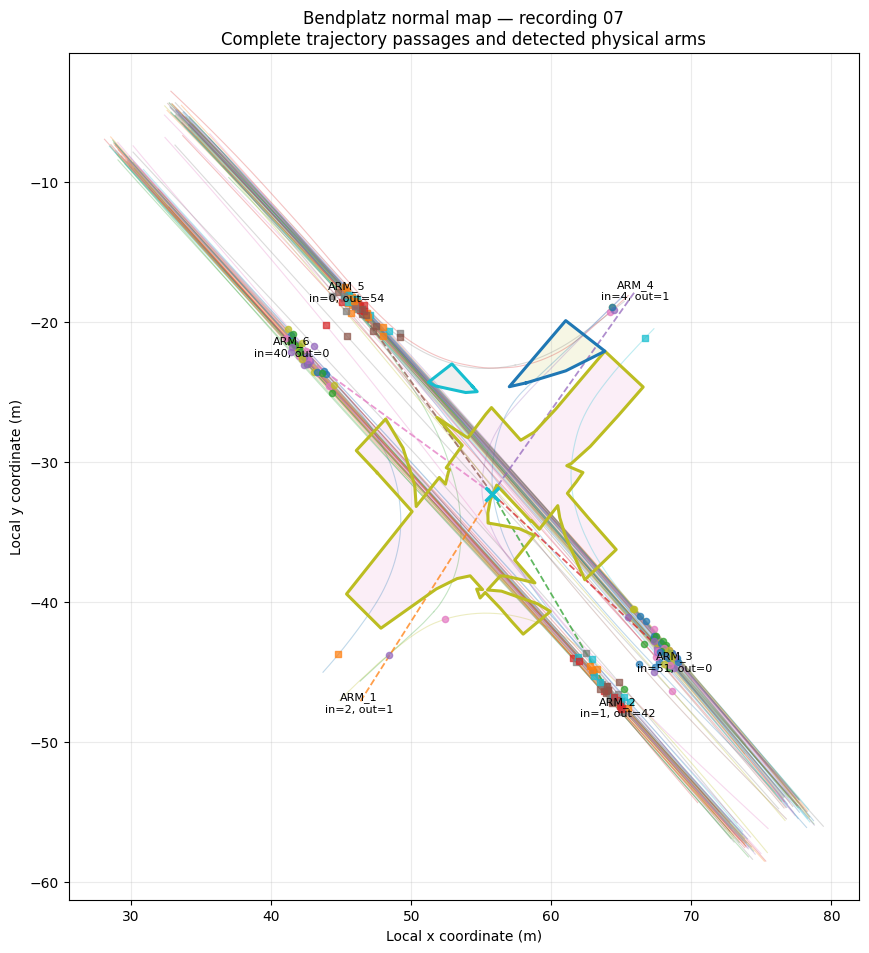

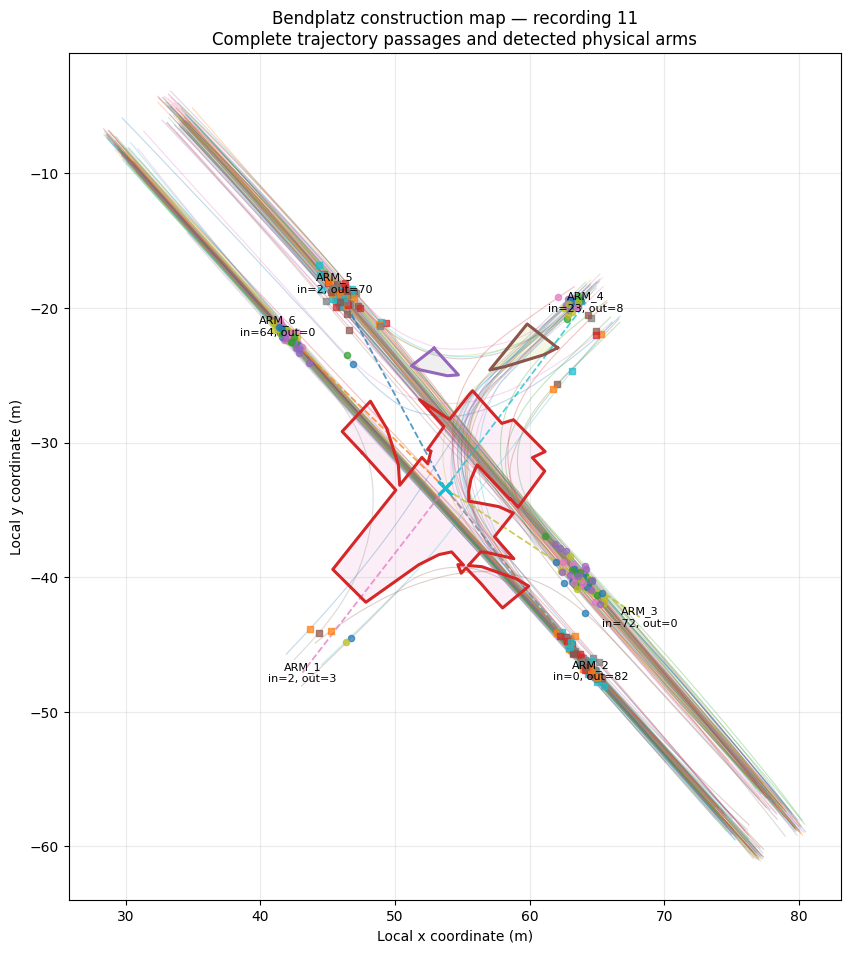


CELL 11 COMPLETED
Complete road-vehicle passages through the physical conflict region were extracted.
Tracks beginning or ending inside the intersection, tracks with insufficient context, and discontinuous passages were rejected.
Entry and exit headings were calculated from measured velocity over robust trajectory windows.
Physical road arms were identified from entry and exit position directions using data-driven silhouette analysis.

Validate the following before generating manoeuvre labels:
  1. The selected arm count should match the visible road geometry.
  2. Each arm ray should point along a physical road corridor.
  3. Entry circles should appear before the central region.
  4. Exit squares should appear after the central region.
  5. Complete trajectories should cross the conflict region once.

After validation, the next cell will calculate signed heading change and assign LEFT, RIGHT and STRAIGHT labels.


In [ ]:
# Cell 11 — Extract complete intersection passages
#           and identify trajectory-based entry and exit arms

# Purpose
# -------
# This cell uses measured vehicle trajectories to identify complete
# passages through the physical conflict region.
#
# For each road vehicle:
#
#   trajectory before conflict region
#                ↓
#   first conflict-region entry
#                ↓
#   last conflict-region exit
#                ↓
#   trajectory after conflict region
#
# The cell calculates:
#
#   - robust entry position;
#   - robust exit position;
#   - entry heading from measured velocity;
#   - exit heading from measured velocity;
#   - entry and exit radial directions relative to the intersection;
#   - trajectory-based physical road-arm assignments.
#
# Road arms are clustered automatically using direction vectors and
# silhouette analysis. The number of arms is not manually fixed.
#
# This cell does NOT yet assign LEFT, RIGHT or STRAIGHT labels.
# That classification will be performed only after the extracted
# passages and arm assignments are validated.

from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import Point

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "NORMAL_CONFLICT_GEOMETRY",
    "CONSTRUCTION_CONFLICT_GEOMETRY",
    "NORMAL_INTERSECTION_CENTER",
    "CONSTRUCTION_INTERSECTION_CENTER",
    "NORMAL_MEDIAN_LANE_WIDTH",
    "CONSTRUCTION_MEDIAN_LANE_WIDTH",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cell 10B before Cell 11. "
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

# A small expansion is used so vehicle centres near the edge of the
# physical overlap area are still recognised as passing through it.
#
# This value is derived independently for each map as half of the
# median lane width.
NORMAL_PASSAGE_REGION_BUFFER_M = (
    NORMAL_MEDIAN_LANE_WIDTH / 2.0
)

CONSTRUCTION_PASSAGE_REGION_BUFFER_M = (
    CONSTRUCTION_MEDIAN_LANE_WIDTH / 2.0
)

# Heading is estimated from measured velocity over a short time window.
HEADING_WINDOW_SECONDS = 1.0

# At least this much observed time must exist both before entry and after
# exit. This rejects tracks beginning or ending inside the intersection.
MINIMUM_CONTEXT_SECONDS = 0.5

# Ignore almost-stationary observations when estimating heading.
MINIMUM_HEADING_SPEED_MPS = 1.0

# Candidate physical-arm counts considered by the data-driven clustering.
MINIMUM_ARM_CLUSTERS = 2
MAXIMUM_ARM_CLUSTERS = 6

# Random state ensures reproducibility.
CLUSTER_RANDOM_STATE = 42


# ============================================================
# 3. LOAD A RECORDING FOR PASSAGE EXTRACTION
# ============================================================

def find_dataset_file(dataset_root, filename):
    """
    Recursively locate a unique dataset file.
    """
    dataset_root = Path(dataset_root)
    matches = sorted(dataset_root.rglob(filename))

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} below:\n{dataset_root}"
        )

    if len(matches) > 1:
        warnings.warn(
            f"Multiple files named {filename} were found. "
            f"Using:\n{matches[0]}"
        )

    return matches[0]


if "DIRECTION_DATASET_ROOT" in globals():
    PASSAGE_DATASET_ROOT = Path(DIRECTION_DATASET_ROOT)
elif "IND_DATASET_ROOT" in globals():
    PASSAGE_DATASET_ROOT = Path(IND_DATASET_ROOT)
elif "DATASET_ROOT" in globals():
    PASSAGE_DATASET_ROOT = Path(DATASET_ROOT)
else:
    PASSAGE_DATASET_ROOT = Path(
        "/content/drive/MyDrive/inD-dataset-v1.1"
    )


def load_passage_recording(recording_id):
    """
    Load tracks, track metadata and recording metadata.
    """
    recording_key = f"{int(recording_id):02d}"

    tracks_path = find_dataset_file(
        PASSAGE_DATASET_ROOT,
        f"{recording_key}_tracks.csv",
    )

    tracks_meta_path = find_dataset_file(
        PASSAGE_DATASET_ROOT,
        f"{recording_key}_tracksMeta.csv",
    )

    recording_meta_path = find_dataset_file(
        PASSAGE_DATASET_ROOT,
        f"{recording_key}_recordingMeta.csv",
    )

    return {
        "recording_id": int(recording_id),
        "recording_key": recording_key,
        "tracks": pd.read_csv(tracks_path),
        "tracks_meta": pd.read_csv(tracks_meta_path),
        "recording_meta": pd.read_csv(recording_meta_path),
        "tracks_path": tracks_path,
        "tracks_meta_path": tracks_meta_path,
        "recording_meta_path": recording_meta_path,
    }


# Recording 07 represents the normal map.
# Recording 11 represents the construction map.
NORMAL_PASSAGE_RECORDING = load_passage_recording(7)
CONSTRUCTION_PASSAGE_RECORDING = load_passage_recording(11)

print("Passage-extraction recordings:")
print(
    "  Normal:",
    NORMAL_PASSAGE_RECORDING["tracks_path"],
)
print(
    "  Construction:",
    CONSTRUCTION_PASSAGE_RECORDING["tracks_path"],
)


# ============================================================
# 4. DETECT DATASET COLUMNS
# ============================================================

def first_available_column(dataframe, candidates, purpose):
    """
    Return the first candidate column that exists.
    """
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    raise ValueError(
        f"Could not identify {purpose}.\n"
        f"Tried: {candidates}\n"
        f"Available columns: {list(dataframe.columns)}"
    )


def read_frame_rate(recording_meta):
    """
    Read frame rate from recording metadata.
    """
    for candidate in [
        "frameRate",
        "frame_rate",
        "framerate",
    ]:
        if candidate in recording_meta.columns:
            frame_rate = float(
                recording_meta.iloc[0][candidate]
            )

            if np.isfinite(frame_rate) and frame_rate > 0:
                return frame_rate

    warnings.warn(
        "Frame rate was not found in recording metadata. "
        "Using 25 Hz."
    )

    return 25.0


ROAD_VEHICLE_CLASSES = {
    "car",
    "truck_bus",
    "truck",
    "bus",
    "van",
    "motorcycle",
    "motorbike",
    "vehicle",
}


def prepare_passage_tracks(recording):
    """
    Prepare complete road-vehicle trajectory observations.
    """
    tracks = recording["tracks"].copy()
    metadata = recording["tracks_meta"].copy()

    track_id_column = first_available_column(
        tracks,
        ["trackId", "track_id", "id"],
        "track ID column",
    )

    frame_column = first_available_column(
        tracks,
        ["frame", "frameId", "frame_id"],
        "frame column",
    )

    x_column = first_available_column(
        tracks,
        ["xCenter", "x_center", "x"],
        "x coordinate",
    )

    y_column = first_available_column(
        tracks,
        ["yCenter", "y_center", "y"],
        "y coordinate",
    )

    vx_column = first_available_column(
        tracks,
        ["xVelocity", "x_velocity", "vx"],
        "x velocity",
    )

    vy_column = first_available_column(
        tracks,
        ["yVelocity", "y_velocity", "vy"],
        "y velocity",
    )

    metadata_track_id_column = first_available_column(
        metadata,
        ["trackId", "track_id", "id"],
        "metadata track ID",
    )

    class_column = first_available_column(
        metadata,
        ["class", "objectClass", "object_class", "type"],
        "object class",
    )

    class_table = metadata[
        [metadata_track_id_column, class_column]
    ].rename(
        columns={
            metadata_track_id_column: track_id_column
        }
    )

    prepared = tracks.merge(
        class_table,
        on=track_id_column,
        how="left",
        validate="many_to_one",
    )

    normalized_class = (
        prepared[class_column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    prepared = prepared[
        normalized_class.isin(ROAD_VEHICLE_CLASSES)
    ].copy()

    numeric_columns = [
        frame_column,
        x_column,
        y_column,
        vx_column,
        vy_column,
    ]

    for column in numeric_columns:
        prepared[column] = pd.to_numeric(
            prepared[column],
            errors="coerce",
        )

    prepared = prepared.dropna(
        subset=[
            track_id_column,
            frame_column,
            x_column,
            y_column,
            vx_column,
            vy_column,
        ]
    )

    prepared["speed_mps"] = np.hypot(
        prepared[vx_column],
        prepared[vy_column],
    )

    prepared = prepared.sort_values(
        [track_id_column, frame_column]
    ).reset_index(drop=True)

    frame_rate = read_frame_rate(
        recording["recording_meta"]
    )

    config = {
        "recording_id": recording["recording_id"],
        "recording_key": recording["recording_key"],
        "track_id": track_id_column,
        "frame": frame_column,
        "x": x_column,
        "y": y_column,
        "vx": vx_column,
        "vy": vy_column,
        "class": class_column,
        "frame_rate": frame_rate,
    }

    return prepared, config


(
    NORMAL_PASSAGE_TRACKS,
    NORMAL_PASSAGE_COLUMN_CONFIG,
) = prepare_passage_tracks(
    NORMAL_PASSAGE_RECORDING
)

(
    CONSTRUCTION_PASSAGE_TRACKS,
    CONSTRUCTION_PASSAGE_COLUMN_CONFIG,
) = prepare_passage_tracks(
    CONSTRUCTION_PASSAGE_RECORDING
)

print("\nPrepared road-vehicle trajectories:")
print(
    "  Normal recording rows:",
    len(NORMAL_PASSAGE_TRACKS),
)
print(
    "  Construction recording rows:",
    len(CONSTRUCTION_PASSAGE_TRACKS),
)


# ============================================================
# 5. ANGLE AND VECTOR HELPERS
# ============================================================

def vector_heading_degrees(vector):
    """
    Convert a two-dimensional vector to heading in degrees.
    """
    vector = np.asarray(vector, dtype=float)

    if np.linalg.norm(vector) <= 1e-12:
        return np.nan

    return float(
        np.degrees(
            np.arctan2(vector[1], vector[0])
        )
    )


def radial_angle_degrees(point, center):
    """
    Direction from the intersection centre to a point.
    """
    point = np.asarray(point, dtype=float)
    center = np.asarray(center, dtype=float)

    return vector_heading_degrees(point - center)


def circular_mean_degrees(angles):
    """
    Calculate the circular mean of angles in degrees.
    """
    angles = np.asarray(angles, dtype=float)

    if len(angles) == 0:
        return np.nan

    radians = np.radians(angles)

    return float(
        np.degrees(
            np.arctan2(
                np.mean(np.sin(radians)),
                np.mean(np.cos(radians)),
            )
        )
    )


def normalized_angle_degrees(angle):
    """
    Normalize angle to [-180, 180).
    """
    return (float(angle) + 180.0) % 360.0 - 180.0


# ============================================================
# 6. ROBUST HEADING FROM A TRAJECTORY WINDOW
# ============================================================

def robust_velocity_heading(
    trajectory_window,
    vx_column,
    vy_column,
):
    """
    Estimate heading from the median measured velocity vector.

    Stationary observations are excluded.
    """
    moving = trajectory_window[
        np.hypot(
            trajectory_window[vx_column],
            trajectory_window[vy_column],
        ) >= MINIMUM_HEADING_SPEED_MPS
    ]

    if moving.empty:
        return {
            "heading_degrees": np.nan,
            "median_vx": np.nan,
            "median_vy": np.nan,
            "observation_count": 0,
        }

    median_vx = float(
        moving[vx_column].median()
    )

    median_vy = float(
        moving[vy_column].median()
    )

    heading = vector_heading_degrees(
        [median_vx, median_vy]
    )

    return {
        "heading_degrees": heading,
        "median_vx": median_vx,
        "median_vy": median_vy,
        "observation_count": len(moving),
    }


# ============================================================
# 7. EXTRACT COMPLETE CONFLICT-REGION PASSAGES
# ============================================================

def extract_complete_passages(
    trajectory_data,
    column_config,
    conflict_geometry,
    intersection_center,
    region_buffer_m,
    map_variant,
):
    """
    Extract complete vehicle passages through the conflict region.

    A complete passage must contain:
        - observations before first entry;
        - observations inside the region;
        - observations after final exit;
        - sufficient temporal context on both sides.
    """

    track_id_column = column_config["track_id"]
    frame_column = column_config["frame"]
    x_column = column_config["x"]
    y_column = column_config["y"]
    vx_column = column_config["vx"]
    vy_column = column_config["vy"]

    frame_rate = float(column_config["frame_rate"])

    heading_window_frames = max(
        1,
        int(round(
            HEADING_WINDOW_SECONDS * frame_rate
        )),
    )

    minimum_context_frames = max(
        1,
        int(round(
            MINIMUM_CONTEXT_SECONDS * frame_rate
        )),
    )

    passage_region = conflict_geometry.buffer(
        region_buffer_m
    )

    passage_rows = []
    rejected_rows = []
    passage_tracks = {}

    for track_id, track in trajectory_data.groupby(
        track_id_column,
        sort=False,
    ):
        track = track.sort_values(
            frame_column
        ).reset_index(drop=True)

        inside_mask = np.asarray([
            passage_region.covers(
                Point(
                    float(x),
                    float(y),
                )
            )
            for x, y in zip(
                track[x_column],
                track[y_column],
            )
        ])

        inside_indices = np.flatnonzero(
            inside_mask
        )

        if len(inside_indices) == 0:
            continue

        first_inside_index = int(
            inside_indices[0]
        )

        last_inside_index = int(
            inside_indices[-1]
        )

        pre_context_count = first_inside_index
        post_context_count = (
            len(track) - last_inside_index - 1
        )

        rejection_reasons = []

        if pre_context_count < minimum_context_frames:
            rejection_reasons.append(
                "insufficient_pre_entry_context"
            )

        if post_context_count < minimum_context_frames:
            rejection_reasons.append(
                "insufficient_post_exit_context"
            )

        # Reject tracks that leave and then re-enter repeatedly.
        # A small number of isolated boundary transitions is acceptable,
        # but the track must represent one continuous passage.
        inside_segment = inside_mask[
            first_inside_index:last_inside_index + 1
        ]

        internal_outside_count = int(
            (~inside_segment).sum()
        )

        if internal_outside_count > minimum_context_frames:
            rejection_reasons.append(
                "discontinuous_conflict_region_passage"
            )

        if rejection_reasons:
            rejected_rows.append({
                "map_variant": map_variant,
                "recording_id":
                    column_config["recording_id"],
                "track_id": track_id,
                "first_inside_frame": (
                    track.loc[
                        first_inside_index,
                        frame_column,
                    ]
                ),
                "last_inside_frame": (
                    track.loc[
                        last_inside_index,
                        frame_column,
                    ]
                ),
                "pre_context_frames":
                    pre_context_count,
                "post_context_frames":
                    post_context_count,
                "rejection_reason":
                    "; ".join(rejection_reasons),
            })

            continue

        entry_window_start = max(
            0,
            first_inside_index
            - heading_window_frames,
        )

        exit_window_end = min(
            len(track),
            last_inside_index
            + 1
            + heading_window_frames,
        )

        entry_window = track.iloc[
            entry_window_start:first_inside_index
        ]

        exit_window = track.iloc[
            last_inside_index + 1:exit_window_end
        ]

        entry_heading_result = robust_velocity_heading(
            entry_window,
            vx_column,
            vy_column,
        )

        exit_heading_result = robust_velocity_heading(
            exit_window,
            vx_column,
            vy_column,
        )

        if (
            not np.isfinite(
                entry_heading_result[
                    "heading_degrees"
                ]
            )
            or not np.isfinite(
                exit_heading_result[
                    "heading_degrees"
                ]
            )
        ):
            rejected_rows.append({
                "map_variant": map_variant,
                "recording_id":
                    column_config["recording_id"],
                "track_id": track_id,
                "first_inside_frame": (
                    track.loc[
                        first_inside_index,
                        frame_column,
                    ]
                ),
                "last_inside_frame": (
                    track.loc[
                        last_inside_index,
                        frame_column,
                    ]
                ),
                "pre_context_frames":
                    pre_context_count,
                "post_context_frames":
                    post_context_count,
                "rejection_reason":
                    "insufficient_moving_heading_observations",
            })

            continue

        # Use the median pre-entry and post-exit positions.
        entry_position = np.array([
            float(entry_window[x_column].median()),
            float(entry_window[y_column].median()),
        ])

        exit_position = np.array([
            float(exit_window[x_column].median()),
            float(exit_window[y_column].median()),
        ])

        entry_radial_angle = radial_angle_degrees(
            entry_position,
            intersection_center,
        )

        exit_radial_angle = radial_angle_degrees(
            exit_position,
            intersection_center,
        )

        duration_frames = (
            track.loc[
                last_inside_index,
                frame_column,
            ]
            - track.loc[
                first_inside_index,
                frame_column,
            ]
        )

        duration_seconds = (
            float(duration_frames) / frame_rate
        )

        passage_id = (
            f"{column_config['recording_key']}_"
            f"{track_id}"
        )

        passage_rows.append({
            "map_variant": map_variant,
            "recording_id":
                column_config["recording_id"],
            "passage_id": passage_id,
            "track_id": track_id,

            "first_inside_frame": int(
                track.loc[
                    first_inside_index,
                    frame_column,
                ]
            ),

            "last_inside_frame": int(
                track.loc[
                    last_inside_index,
                    frame_column,
                ]
            ),

            "conflict_duration_seconds":
                duration_seconds,

            "entry_x": entry_position[0],
            "entry_y": entry_position[1],

            "exit_x": exit_position[0],
            "exit_y": exit_position[1],

            "entry_heading_degrees":
                entry_heading_result[
                    "heading_degrees"
                ],

            "exit_heading_degrees":
                exit_heading_result[
                    "heading_degrees"
                ],

            "entry_radial_angle_degrees":
                entry_radial_angle,

            "exit_radial_angle_degrees":
                exit_radial_angle,

            "entry_heading_observations":
                entry_heading_result[
                    "observation_count"
                ],

            "exit_heading_observations":
                exit_heading_result[
                    "observation_count"
                ],

            "pre_context_seconds":
                pre_context_count / frame_rate,

            "post_context_seconds":
                post_context_count / frame_rate,
        })

        passage_tracks[passage_id] = {
            "full_track": track,
            "first_inside_index":
                first_inside_index,
            "last_inside_index":
                last_inside_index,
            "entry_window_start":
                entry_window_start,
            "exit_window_end":
                exit_window_end,
        }

    return {
        "passages": pd.DataFrame(
            passage_rows
        ),
        "rejected": pd.DataFrame(
            rejected_rows
        ),
        "passage_tracks": passage_tracks,
        "passage_region": passage_region,
        "heading_window_frames":
            heading_window_frames,
        "minimum_context_frames":
            minimum_context_frames,
    }


NORMAL_PASSAGE_EXTRACTION = extract_complete_passages(
    trajectory_data=NORMAL_PASSAGE_TRACKS,
    column_config=NORMAL_PASSAGE_COLUMN_CONFIG,
    conflict_geometry=NORMAL_CONFLICT_GEOMETRY,
    intersection_center=NORMAL_INTERSECTION_CENTER,
    region_buffer_m=(
        NORMAL_PASSAGE_REGION_BUFFER_M
    ),
    map_variant="normal",
)

CONSTRUCTION_PASSAGE_EXTRACTION = (
    extract_complete_passages(
        trajectory_data=(
            CONSTRUCTION_PASSAGE_TRACKS
        ),
        column_config=(
            CONSTRUCTION_PASSAGE_COLUMN_CONFIG
        ),
        conflict_geometry=(
            CONSTRUCTION_CONFLICT_GEOMETRY
        ),
        intersection_center=(
            CONSTRUCTION_INTERSECTION_CENTER
        ),
        region_buffer_m=(
            CONSTRUCTION_PASSAGE_REGION_BUFFER_M
        ),
        map_variant="construction",
    )
)

NORMAL_COMPLETE_PASSAGES = (
    NORMAL_PASSAGE_EXTRACTION["passages"]
)

CONSTRUCTION_COMPLETE_PASSAGES = (
    CONSTRUCTION_PASSAGE_EXTRACTION[
        "passages"
    ]
)

NORMAL_REJECTED_PASSAGES = (
    NORMAL_PASSAGE_EXTRACTION["rejected"]
)

CONSTRUCTION_REJECTED_PASSAGES = (
    CONSTRUCTION_PASSAGE_EXTRACTION[
        "rejected"
    ]
)


# ============================================================
# 8. AUTOMATIC ROAD-ARM CLUSTERING
# ============================================================

def angles_to_unit_vectors(angles_degrees):
    """
    Convert circular angles into two-dimensional unit vectors.
    """
    angles_radians = np.radians(
        np.asarray(angles_degrees, dtype=float)
    )

    return np.column_stack([
        np.cos(angles_radians),
        np.sin(angles_radians),
    ])


def select_arm_cluster_count(
    angle_values,
    minimum_clusters=MINIMUM_ARM_CLUSTERS,
    maximum_clusters=MAXIMUM_ARM_CLUSTERS,
):
    """
    Select the number of spatial road arms using silhouette analysis.

    Entry and exit radial directions are combined before clustering,
    because they refer to the same physical road arms.
    """
    angle_values = np.asarray(
        angle_values,
        dtype=float,
    )

    vectors = angles_to_unit_vectors(
        angle_values
    )

    unique_vector_count = len(
        np.unique(
            np.round(vectors, decimals=6),
            axis=0,
        )
    )

    maximum_valid_clusters = min(
        maximum_clusters,
        unique_vector_count,
        len(vectors) - 1,
    )

    if maximum_valid_clusters < minimum_clusters:
        raise ValueError(
            "Not enough distinct passage endpoints to "
            "identify road-arm clusters."
        )

    evaluation_rows = []
    fitted_models = {}

    for cluster_count in range(
        minimum_clusters,
        maximum_valid_clusters + 1,
    ):
        model = KMeans(
            n_clusters=cluster_count,
            random_state=CLUSTER_RANDOM_STATE,
            n_init=50,
        )

        labels = model.fit_predict(
            vectors
        )

        score = silhouette_score(
            vectors,
            labels,
        )

        evaluation_rows.append({
            "cluster_count": cluster_count,
            "silhouette_score": score,
        })

        fitted_models[cluster_count] = model

    evaluation_df = pd.DataFrame(
        evaluation_rows
    ).sort_values(
        [
            "silhouette_score",
            "cluster_count",
        ],
        ascending=[False, True],
    ).reset_index(drop=True)

    selected_cluster_count = int(
        evaluation_df.iloc[0][
            "cluster_count"
        ]
    )

    return {
        "selected_cluster_count":
            selected_cluster_count,
        "evaluation_table":
            evaluation_df,
        "model":
            fitted_models[
                selected_cluster_count
            ],
    }


def assign_physical_arms(
    passages,
    map_variant,
):
    """
    Cluster all entry and exit radial directions into physical road arms.
    """
    if passages.empty:
        raise ValueError(
            f"No complete passages are available for "
            f"the {map_variant} map."
        )

    entry_angles = passages[
        "entry_radial_angle_degrees"
    ].to_numpy()

    exit_angles = passages[
        "exit_radial_angle_degrees"
    ].to_numpy()

    combined_angles = np.concatenate([
        entry_angles,
        exit_angles,
    ])

    cluster_selection = (
        select_arm_cluster_count(
            combined_angles
        )
    )

    model = cluster_selection["model"]

    entry_vectors = angles_to_unit_vectors(
        entry_angles
    )

    exit_vectors = angles_to_unit_vectors(
        exit_angles
    )

    entry_raw_labels = model.predict(
        entry_vectors
    )

    exit_raw_labels = model.predict(
        exit_vectors
    )

    # Calculate each cluster's circular mean direction.
    combined_raw_labels = model.predict(
        angles_to_unit_vectors(
            combined_angles
        )
    )

    arm_rows = []

    for raw_label in sorted(
        np.unique(combined_raw_labels)
    ):
        cluster_angles = combined_angles[
            combined_raw_labels == raw_label
        ]

        mean_angle = circular_mean_degrees(
            cluster_angles
        )

        arm_rows.append({
            "raw_cluster_label":
                int(raw_label),
            "mean_radial_angle_degrees":
                mean_angle,
            "endpoint_count":
                len(cluster_angles),
        })

    # Assign stable arm IDs by circular direction.
    arm_table = pd.DataFrame(
        arm_rows
    ).sort_values(
        "mean_radial_angle_degrees"
    ).reset_index(drop=True)

    arm_table["arm_id"] = [
        f"ARM_{index + 1}"
        for index in range(len(arm_table))
    ]

    raw_to_arm_id = dict(
        zip(
            arm_table["raw_cluster_label"],
            arm_table["arm_id"],
        )
    )

    result = passages.copy()

    result["entry_arm_id"] = [
        raw_to_arm_id[int(label)]
        for label in entry_raw_labels
    ]

    result["exit_arm_id"] = [
        raw_to_arm_id[int(label)]
        for label in exit_raw_labels
    ]

    # Add passage counts per arm.
    entry_counts = (
        result["entry_arm_id"]
        .value_counts()
        .to_dict()
    )

    exit_counts = (
        result["exit_arm_id"]
        .value_counts()
        .to_dict()
    )

    arm_table["entry_passage_count"] = (
        arm_table["arm_id"]
        .map(entry_counts)
        .fillna(0)
        .astype(int)
    )

    arm_table["exit_passage_count"] = (
        arm_table["arm_id"]
        .map(exit_counts)
        .fillna(0)
        .astype(int)
    )

    return {
        "passages": result,
        "arm_table": arm_table,
        "cluster_evaluation":
            cluster_selection[
                "evaluation_table"
            ],
        "selected_arm_count":
            cluster_selection[
                "selected_cluster_count"
            ],
    }


NORMAL_ARM_ASSIGNMENT = assign_physical_arms(
    NORMAL_COMPLETE_PASSAGES,
    map_variant="normal",
)

CONSTRUCTION_ARM_ASSIGNMENT = (
    assign_physical_arms(
        CONSTRUCTION_COMPLETE_PASSAGES,
        map_variant="construction",
    )
)

NORMAL_COMPLETE_PASSAGES = (
    NORMAL_ARM_ASSIGNMENT["passages"]
)

CONSTRUCTION_COMPLETE_PASSAGES = (
    CONSTRUCTION_ARM_ASSIGNMENT[
        "passages"
    ]
)

NORMAL_TRAJECTORY_ARM_TABLE = (
    NORMAL_ARM_ASSIGNMENT["arm_table"]
)

CONSTRUCTION_TRAJECTORY_ARM_TABLE = (
    CONSTRUCTION_ARM_ASSIGNMENT[
        "arm_table"
    ]
)


# ============================================================
# 9. PASSAGE AND ARM SUMMARY
# ============================================================

PASSAGE_EXTRACTION_SUMMARY = pd.DataFrame([
    {
        "map_variant": "normal",
        "recording_id": 7,
        "road_vehicle_tracks": (
            NORMAL_PASSAGE_TRACKS[
                NORMAL_PASSAGE_COLUMN_CONFIG[
                    "track_id"
                ]
            ].nunique()
        ),
        "complete_passages":
            len(NORMAL_COMPLETE_PASSAGES),
        "rejected_candidate_passages":
            len(NORMAL_REJECTED_PASSAGES),
        "selected_physical_arms":
            NORMAL_ARM_ASSIGNMENT[
                "selected_arm_count"
            ],
        "conflict_region_buffer_m":
            NORMAL_PASSAGE_REGION_BUFFER_M,
    },
    {
        "map_variant": "construction",
        "recording_id": 11,
        "road_vehicle_tracks": (
            CONSTRUCTION_PASSAGE_TRACKS[
                CONSTRUCTION_PASSAGE_COLUMN_CONFIG[
                    "track_id"
                ]
            ].nunique()
        ),
        "complete_passages":
            len(CONSTRUCTION_COMPLETE_PASSAGES),
        "rejected_candidate_passages":
            len(CONSTRUCTION_REJECTED_PASSAGES),
        "selected_physical_arms":
            CONSTRUCTION_ARM_ASSIGNMENT[
                "selected_arm_count"
            ],
        "conflict_region_buffer_m":
            CONSTRUCTION_PASSAGE_REGION_BUFFER_M,
    },
])

print("\n" + "=" * 80)
print("COMPLETE PASSAGE EXTRACTION SUMMARY")
print("=" * 80)

display(PASSAGE_EXTRACTION_SUMMARY)


print("\nNormal-map physical arms:")
display(NORMAL_TRAJECTORY_ARM_TABLE)

print("\nNormal arm-count evaluation:")
display(
    NORMAL_ARM_ASSIGNMENT[
        "cluster_evaluation"
    ]
)


print("\nConstruction-map physical arms:")
display(CONSTRUCTION_TRAJECTORY_ARM_TABLE)

print("\nConstruction arm-count evaluation:")
display(
    CONSTRUCTION_ARM_ASSIGNMENT[
        "cluster_evaluation"
    ]
)


# ============================================================
# 10. ENTRY-TO-EXIT MOVEMENT COUNTS
# ============================================================

def create_arm_transition_table(passages):
    """
    Count observed transitions between entry and exit arms.
    """
    if passages.empty:
        return pd.DataFrame()

    return (
        passages
        .groupby(
            [
                "entry_arm_id",
                "exit_arm_id",
            ],
            as_index=False,
        )
        .agg(
            passage_count=(
                "passage_id",
                "count",
            ),
            median_conflict_duration_seconds=(
                "conflict_duration_seconds",
                "median",
            ),
            median_entry_heading_degrees=(
                "entry_heading_degrees",
                circular_mean_degrees,
            ),
            median_exit_heading_degrees=(
                "exit_heading_degrees",
                circular_mean_degrees,
            ),
        )
        .sort_values(
            [
                "entry_arm_id",
                "exit_arm_id",
            ]
        )
        .reset_index(drop=True)
    )


NORMAL_ARM_TRANSITIONS = (
    create_arm_transition_table(
        NORMAL_COMPLETE_PASSAGES
    )
)

CONSTRUCTION_ARM_TRANSITIONS = (
    create_arm_transition_table(
        CONSTRUCTION_COMPLETE_PASSAGES
    )
)

print("\nNormal-map observed arm transitions:")
display(NORMAL_ARM_TRANSITIONS)

print("\nConstruction-map observed arm transitions:")
display(CONSTRUCTION_ARM_TRANSITIONS)


# ============================================================
# 11. VISUALISE COMPLETE PASSAGES AND ARM ASSIGNMENTS
# ============================================================

def geometry_polygon_parts(geometry):
    """
    Return polygon parts for plotting.
    """
    if geometry.is_empty:
        return []

    if geometry.geom_type == "Polygon":
        return [geometry]

    if geometry.geom_type == "MultiPolygon":
        return list(geometry.geoms)

    if geometry.geom_type == "GeometryCollection":
        parts = []

        for item in geometry.geoms:
            parts.extend(
                geometry_polygon_parts(item)
            )

        return parts

    return []


def plot_passage_arm_assignments(
    passage_result,
    arm_assignment,
    column_config,
    conflict_geometry,
    intersection_center,
    map_name,
):
    """
    Plot complete passages with entry and exit arm labels.
    """
    passages = arm_assignment["passages"]
    arm_table = arm_assignment["arm_table"]

    track_id_column = column_config[
        "track_id"
    ]

    x_column = column_config["x"]
    y_column = column_config["y"]

    figure, axis = plt.subplots(
        figsize=(12, 11)
    )

    # Plot accepted complete trajectories.
    for passage in passages.itertuples(
        index=False
    ):
        passage_track = passage_result[
            "passage_tracks"
        ][passage.passage_id]["full_track"]

        axis.plot(
            passage_track[x_column],
            passage_track[y_column],
            linewidth=0.8,
            alpha=0.28,
            zorder=2,
        )

        axis.scatter(
            [passage.entry_x],
            [passage.entry_y],
            marker="o",
            s=20,
            alpha=0.7,
            zorder=5,
        )

        axis.scatter(
            [passage.exit_x],
            [passage.exit_y],
            marker="s",
            s=20,
            alpha=0.7,
            zorder=5,
        )

    # Draw conflict-region boundary.
    for polygon_part in geometry_polygon_parts(
        conflict_geometry
    ):
        exterior_x, exterior_y = (
            polygon_part.exterior.xy
        )

        axis.plot(
            exterior_x,
            exterior_y,
            linewidth=2.2,
            zorder=6,
        )

        axis.fill(
            exterior_x,
            exterior_y,
            alpha=0.12,
            zorder=1,
        )

    # Draw intersection centre.
    axis.scatter(
        [intersection_center[0]],
        [intersection_center[1]],
        marker="x",
        s=100,
        linewidths=2.5,
        zorder=8,
    )

    # Draw arm-direction rays.
    all_positions = np.vstack([
        passages[
            ["entry_x", "entry_y"]
        ].to_numpy(),
        passages[
            ["exit_x", "exit_y"]
        ].to_numpy(),
    ])

    if len(all_positions) > 0:
        maximum_radius = float(
            np.percentile(
                np.linalg.norm(
                    all_positions
                    - np.asarray(
                        intersection_center
                    ),
                    axis=1,
                ),
                90,
            )
        )
    else:
        maximum_radius = 25.0

    for arm in arm_table.itertuples(
        index=False
    ):
        angle_radians = np.radians(
            arm.mean_radial_angle_degrees
        )

        ray_end = np.array([
            intersection_center[0]
            + maximum_radius
            * np.cos(angle_radians),

            intersection_center[1]
            + maximum_radius
            * np.sin(angle_radians),
        ])

        axis.plot(
            [
                intersection_center[0],
                ray_end[0],
            ],
            [
                intersection_center[1],
                ray_end[1],
            ],
            linestyle="--",
            linewidth=1.3,
            alpha=0.75,
            zorder=4,
        )

        axis.text(
            ray_end[0],
            ray_end[1],
            (
                f"{arm.arm_id}\n"
                f"in={arm.entry_passage_count}, "
                f"out={arm.exit_passage_count}"
            ),
            fontsize=8,
            ha="center",
            va="center",
            zorder=9,
        )

    axis.set_title(
        f"{map_name}\n"
        "Complete trajectory passages and detected physical arms"
    )

    axis.set_xlabel("Local x coordinate (m)")
    axis.set_ylabel("Local y coordinate (m)")
    axis.set_aspect(
        "equal",
        adjustable="box",
    )
    axis.grid(True, alpha=0.25)

    plt.show()


plot_passage_arm_assignments(
    passage_result=NORMAL_PASSAGE_EXTRACTION,
    arm_assignment=NORMAL_ARM_ASSIGNMENT,
    column_config=NORMAL_PASSAGE_COLUMN_CONFIG,
    conflict_geometry=NORMAL_CONFLICT_GEOMETRY,
    intersection_center=NORMAL_INTERSECTION_CENTER,
    map_name="Bendplatz normal map — recording 07",
)

plot_passage_arm_assignments(
    passage_result=(
        CONSTRUCTION_PASSAGE_EXTRACTION
    ),
    arm_assignment=(
        CONSTRUCTION_ARM_ASSIGNMENT
    ),
    column_config=(
        CONSTRUCTION_PASSAGE_COLUMN_CONFIG
    ),
    conflict_geometry=(
        CONSTRUCTION_CONFLICT_GEOMETRY
    ),
    intersection_center=(
        CONSTRUCTION_INTERSECTION_CENTER
    ),
    map_name=(
        "Bendplatz construction map — recording 11"
    ),
)


# ============================================================
# 12. STORE OUTPUTS FOR LATER CELLS
# ============================================================

COMPLETE_PASSAGES = {
    "normal": NORMAL_COMPLETE_PASSAGES,
    "construction":
        CONSTRUCTION_COMPLETE_PASSAGES,
}

REJECTED_PASSAGES = {
    "normal": NORMAL_REJECTED_PASSAGES,
    "construction":
        CONSTRUCTION_REJECTED_PASSAGES,
}

TRAJECTORY_ARM_TABLES = {
    "normal": NORMAL_TRAJECTORY_ARM_TABLE,
    "construction":
        CONSTRUCTION_TRAJECTORY_ARM_TABLE,
}

ARM_TRANSITION_TABLES = {
    "normal": NORMAL_ARM_TRANSITIONS,
    "construction":
        CONSTRUCTION_ARM_TRANSITIONS,
}

PASSAGE_EXTRACTION_RESULTS = {
    "normal": NORMAL_PASSAGE_EXTRACTION,
    "construction":
        CONSTRUCTION_PASSAGE_EXTRACTION,
}


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 11 COMPLETED")
print("=" * 80)

print(
    "Complete road-vehicle passages through the physical conflict "
    "region were extracted."
)

print(
    "Tracks beginning or ending inside the intersection, tracks with "
    "insufficient context, and discontinuous passages were rejected."
)

print(
    "Entry and exit headings were calculated from measured velocity "
    "over robust trajectory windows."
)

print(
    "Physical road arms were identified from entry and exit position "
    "directions using data-driven silhouette analysis."
)

print(
    "\nValidate the following before generating manoeuvre labels:"
)

print(
    "  1. The selected arm count should match the visible road geometry."
)

print(
    "  2. Each arm ray should point along a physical road corridor."
)

print(
    "  3. Entry circles should appear before the central region."
)

print(
    "  4. Exit squares should appear after the central region."
)

print(
    "  5. Complete trajectories should cross the conflict region once."
)

print(
    "\nAfter validation, the next cell will calculate signed heading "
    "change and assign LEFT, RIGHT and STRAIGHT labels."
)


NORMAL MAP — CIRCULAR ANGULAR GAPS


,gap_after_sorted_index,from_original_arm_id,to_original_arm_id,from_angle_degrees,to_angle_degrees,gap_degrees,selected_as_physical_boundary
0,5,ARM_3,ARM_4,-42.734886,54.751691,97.486577,True
1,2,ARM_6,ARM_1,143.866876,-122.380728,93.752396,True
2,0,ARM_4,ARM_5,54.751691,125.872111,71.120420,True
3,3,ARM_1,ARM_2,-122.380728,-59.509304,62.871425,True
4,1,ARM_5,ARM_6,125.872111,143.866876,17.994765,False
5,4,ARM_2,ARM_3,-59.509304,-42.734886,16.774418,False



Normal original-to-physical mapping:
{'ARM_4': 'ROAD_ARM_1', 'ARM_5': 'ROAD_ARM_2', 'ARM_6': 'ROAD_ARM_2', 'ARM_1': 'ROAD_ARM_3', 'ARM_2': 'ROAD_ARM_4', 'ARM_3': 'ROAD_ARM_4'}

Normal physical-road-arm table:


,mean_radial_angle_degrees,original_arm_ids,original_cluster_count,endpoint_count,physical_arm_id,entry_passage_count,exit_passage_count
0,54.751691,[ARM_4],1,5,ROAD_ARM_1,4,1
1,133.518584,"[ARM_5, ARM_6]",2,94,ROAD_ARM_2,40,54
2,-122.380728,[ARM_1],1,3,ROAD_ARM_3,2,1
3,-50.403185,"[ARM_2, ARM_3]",2,94,ROAD_ARM_4,52,42



CONSTRUCTION MAP — CIRCULAR ANGULAR GAPS


...

,map_variant,original_endpoint_clusters,physical_road_arms,input_complete_passages,accepted_different_arm_passages,suspicious_same_arm_passages,observed_physical_transitions
0,normal,6,4,98,98,0,8
1,construction,6,4,163,163,0,11



Normal physical-arm transitions:


,entry_physical_arm_id,exit_physical_arm_id,passage_count,median_conflict_duration_seconds,mean_entry_heading_degrees,mean_exit_heading_degrees
0,ROAD_ARM_1,ROAD_ARM_2,2,7.08,-140.000670,142.867408
1,ROAD_ARM_1,ROAD_ARM_4,2,13.28,-135.924836,-50.180472
2,ROAD_ARM_2,ROAD_ARM_3,1,3.24,-46.763419,-129.740884
3,ROAD_ARM_2,ROAD_ARM_4,39,1.80,-47.861174,-48.110135
4,ROAD_ARM_3,ROAD_ARM_2,1,17.60,42.458102,128.289228
5,ROAD_ARM_3,ROAD_ARM_4,1,1.76,17.592039,-40.888228
6,ROAD_ARM_4,ROAD_ARM_1,1,4.92,130.005937,46.364920
7,ROAD_ARM_4,ROAD_ARM_2,51,1.72,131.142466,132.119306



Construction physical-arm transitions:


,entry_physical_arm_id,exit_physical_arm_id,passage_count,median_conflict_duration_seconds,mean_entry_heading_degrees,mean_exit_heading_degrees
0,ROAD_ARM_1,ROAD_ARM_2,4,6.00,-138.405954,140.540187
1,ROAD_ARM_1,ROAD_ARM_3,1,14.56,-135.356204,-132.624002
2,ROAD_ARM_1,ROAD_ARM_4,18,10.32,-137.282684,-48.963573
3,ROAD_ARM_2,ROAD_ARM_1,2,3.64,-45.816935,40.218694
4,ROAD_ARM_2,ROAD_ARM_3,1,3.20,-49.546054,-130.240368
5,ROAD_ARM_2,ROAD_ARM_4,63,1.72,-48.012484,-48.035131
6,ROAD_ARM_3,ROAD_ARM_1,1,6.40,43.991067,50.869651
7,ROAD_ARM_3,ROAD_ARM_4,1,10.68,44.223636,-48.673086
8,ROAD_ARM_4,ROAD_ARM_1,5,2.80,131.882357,44.420635
9,ROAD_ARM_4,ROAD_ARM_2,66,1.40,130.730619,131.162316


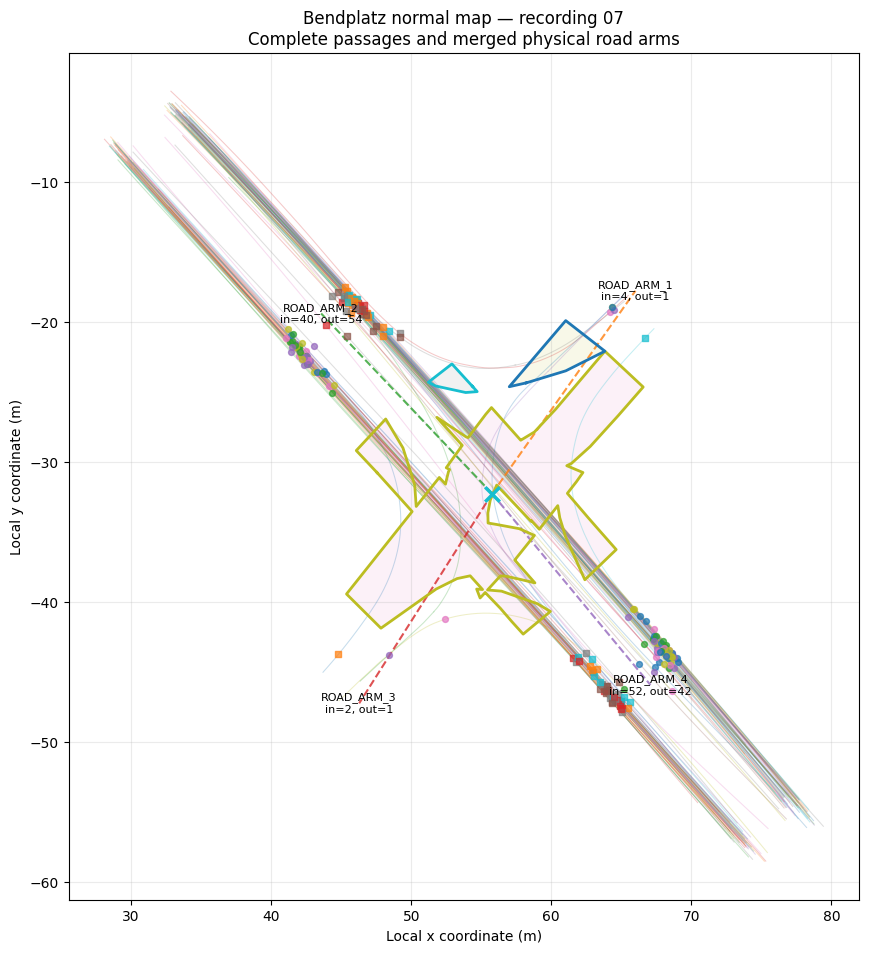

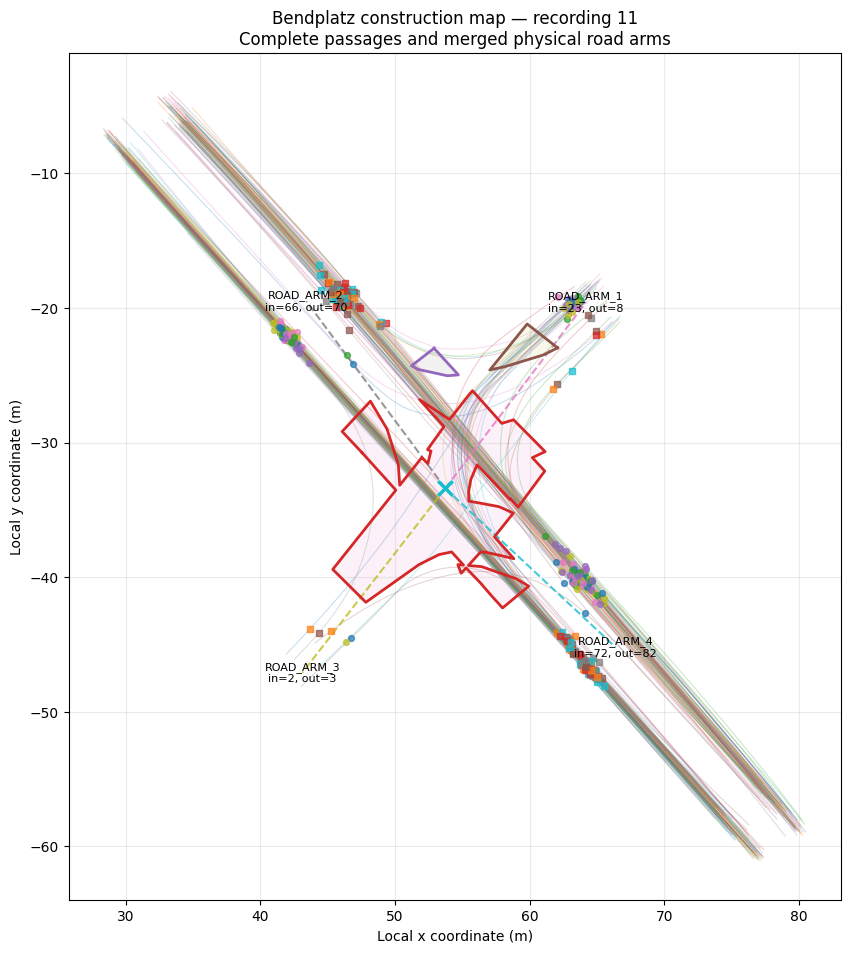


CELL 11B COMPLETED
Lane-position endpoint clusters were merged into four physical road arms using the largest gaps in their circular directions.
No manual angular merge threshold was used.

Passages whose entry and exit belong to the same physical arm were retained separately as suspicious cases.

Validate that:
  1. Exactly four arm rays follow the four physical road corridors.
  2. Incoming and outgoing lanes on the same road now share one physical arm ID.
  3. Most complete trajectories connect two different road arms.
  4. Suspicious same-arm passages are rare and can be inspected individually.

After this validation, the next cell can calculate signed heading change and derive LEFT, RIGHT and STRAIGHT manoeuvre labels.


In [ ]:
# Cell 11B — Merge lane-position clusters into physical road arms

# Purpose
# -------
# Cell 11 clustered trajectory endpoints by radial direction.
# It detected six clusters because incoming and outgoing lanes on the
# same physical road are laterally separated.
#
# This cell converts those lane-position clusters into physical road arms.
#
# Scientific procedure:
#
#   1. Sort endpoint-cluster directions around the full circle.
#   2. Calculate every circular angular gap.
#   3. For a four-arm intersection, use the four largest gaps as the
#      natural boundaries between physical roads.
#   4. Merge clusters located between the same pair of boundaries.
#   5. Reassign every trajectory passage to the new physical arm IDs.
#
# No manually selected angular merge threshold is used.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "NORMAL_COMPLETE_PASSAGES",
    "CONSTRUCTION_COMPLETE_PASSAGES",
    "NORMAL_TRAJECTORY_ARM_TABLE",
    "CONSTRUCTION_TRAJECTORY_ARM_TABLE",
    "NORMAL_PASSAGE_EXTRACTION",
    "CONSTRUCTION_PASSAGE_EXTRACTION",
    "NORMAL_PASSAGE_COLUMN_CONFIG",
    "CONSTRUCTION_PASSAGE_COLUMN_CONFIG",
    "NORMAL_CONFLICT_GEOMETRY",
    "CONSTRUCTION_CONFLICT_GEOMETRY",
    "NORMAL_INTERSECTION_CENTER",
    "CONSTRUCTION_INTERSECTION_CENTER",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cell 11 before Cell 11B. "
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

# Bendplatz is represented as a four-arm intersection.
#
# This is not a fitted manoeuvre threshold. It is a structural property
# visible in the official map geometry.
EXPECTED_PHYSICAL_ARM_COUNT = 4


# ============================================================
# 3. CIRCULAR-ANGLE HELPERS
# ============================================================

def normalize_angle_360(angle_degrees):
    """
    Normalize an angle to [0, 360).
    """
    return float(angle_degrees) % 360.0


def normalize_angle_signed(angle_degrees):
    """
    Normalize an angle to [-180, 180).
    """
    return (
        float(angle_degrees) + 180.0
    ) % 360.0 - 180.0


def circular_mean_degrees_safe(angles_degrees, weights=None):
    """
    Calculate a weighted circular mean in degrees.
    """
    angles = np.asarray(
        angles_degrees,
        dtype=float,
    )

    if len(angles) == 0:
        return np.nan

    radians = np.radians(angles)

    if weights is None:
        weights = np.ones(
            len(angles),
            dtype=float,
        )
    else:
        weights = np.asarray(
            weights,
            dtype=float,
        )

    if weights.sum() <= 0:
        weights = np.ones(
            len(angles),
            dtype=float,
        )

    mean_sine = np.average(
        np.sin(radians),
        weights=weights,
    )

    mean_cosine = np.average(
        np.cos(radians),
        weights=weights,
    )

    return normalize_angle_signed(
        np.degrees(
            np.arctan2(
                mean_sine,
                mean_cosine,
            )
        )
    )


# ============================================================
# 4. CALCULATE CIRCULAR GAPS
# ============================================================

def calculate_circular_gap_table(
    arm_table,
    angle_column="mean_radial_angle_degrees",
):
    """
    Calculate angular gaps between adjacent endpoint clusters.

    The final row represents the wrap-around gap between the last cluster
    and the first cluster plus 360 degrees.
    """
    sorted_table = arm_table.copy()

    sorted_table["angle_360"] = (
        sorted_table[angle_column]
        .map(normalize_angle_360)
    )

    sorted_table = sorted_table.sort_values(
        "angle_360"
    ).reset_index(drop=True)

    gap_rows = []
    number_of_clusters = len(sorted_table)

    for index in range(number_of_clusters):
        next_index = (
            index + 1
        ) % number_of_clusters

        current_angle = float(
            sorted_table.loc[
                index,
                "angle_360",
            ]
        )

        next_angle = float(
            sorted_table.loc[
                next_index,
                "angle_360",
            ]
        )

        if next_index == 0:
            next_angle += 360.0

        gap_rows.append({
            "gap_after_sorted_index": index,
            "from_original_arm_id": (
                sorted_table.loc[
                    index,
                    "arm_id",
                ]
            ),
            "to_original_arm_id": (
                sorted_table.loc[
                    next_index,
                    "arm_id",
                ]
            ),
            "from_angle_degrees":
                normalize_angle_signed(
                    current_angle
                ),
            "to_angle_degrees":
                normalize_angle_signed(
                    next_angle
                ),
            "gap_degrees":
                next_angle - current_angle,
        })

    return sorted_table, pd.DataFrame(
        gap_rows
    )


# ============================================================
# 5. MERGE CLUSTERS USING THE LARGEST CIRCULAR GAPS
# ============================================================

def merge_endpoint_clusters_into_physical_arms(
    passages,
    arm_table,
    map_variant,
    physical_arm_count=EXPECTED_PHYSICAL_ARM_COUNT,
):
    """
    Merge Cell-11 endpoint clusters into physical road arms.

    The largest circular gaps are treated as boundaries between roads.
    Endpoint clusters between two selected boundaries belong to the same
    physical road arm.
    """
    if len(arm_table) < physical_arm_count:
        raise ValueError(
            f"The {map_variant} map has only "
            f"{len(arm_table)} endpoint clusters, which is fewer "
            f"than the expected {physical_arm_count} physical arms."
        )

    sorted_arms, gap_table = (
        calculate_circular_gap_table(
            arm_table
        )
    )

    # Select the largest circular gaps as physical-road boundaries.
    boundary_gap_rows = (
        gap_table
        .nlargest(
            physical_arm_count,
            "gap_degrees",
        )
        .copy()
    )

    boundary_after_indices = set(
        boundary_gap_rows[
            "gap_after_sorted_index"
        ].astype(int)
    )

    number_of_clusters = len(
        sorted_arms
    )

    # Start immediately after one selected boundary.
    first_boundary_index = min(
        boundary_after_indices
    )

    start_index = (
        first_boundary_index + 1
    ) % number_of_clusters

    physical_groups = []
    current_group = []

    for step in range(number_of_clusters):
        current_index = (
            start_index + step
        ) % number_of_clusters

        current_group.append(
            current_index
        )

        if current_index in boundary_after_indices:
            physical_groups.append(
                current_group
            )
            current_group = []

    if current_group:
        # Circular completion safeguard.
        if physical_groups:
            physical_groups[0] = (
                current_group
                + physical_groups[0]
            )
        else:
            physical_groups.append(
                current_group
            )

    if len(physical_groups) != physical_arm_count:
        raise RuntimeError(
            f"Expected {physical_arm_count} physical groups for "
            f"{map_variant}, but created {len(physical_groups)}."
        )

    physical_arm_rows = []
    original_to_physical = {}

    for temporary_group_index, sorted_indices in enumerate(
        physical_groups
    ):
        group_table = sorted_arms.loc[
            sorted_indices
        ].copy()

        group_angles = group_table[
            "mean_radial_angle_degrees"
        ].to_numpy()

        group_weights = group_table[
            "endpoint_count"
        ].to_numpy()

        mean_direction = (
            circular_mean_degrees_safe(
                group_angles,
                weights=group_weights,
            )
        )

        physical_arm_rows.append({
            "temporary_group_index":
                temporary_group_index,
            "mean_radial_angle_degrees":
                mean_direction,
            "original_arm_ids":
                sorted(
                    group_table[
                        "arm_id"
                    ].tolist()
                ),
            "original_cluster_count":
                len(group_table),
            "endpoint_count":
                int(
                    group_table[
                        "endpoint_count"
                    ].sum()
                ),
        })

    physical_arm_table = pd.DataFrame(
        physical_arm_rows
    )

    # Assign stable names by circular position.
    physical_arm_table["sorting_angle_360"] = (
        physical_arm_table[
            "mean_radial_angle_degrees"
        ].map(normalize_angle_360)
    )

    physical_arm_table = (
        physical_arm_table
        .sort_values(
            "sorting_angle_360"
        )
        .reset_index(drop=True)
    )

    physical_arm_table["physical_arm_id"] = [
        f"ROAD_ARM_{index + 1}"
        for index in range(
            len(physical_arm_table)
        )
    ]

    for row in physical_arm_table.itertuples(
        index=False
    ):
        for original_arm_id in row.original_arm_ids:
            original_to_physical[
                original_arm_id
            ] = row.physical_arm_id

    reassigned_passages = passages.copy()

    reassigned_passages[
        "original_entry_arm_id"
    ] = reassigned_passages[
        "entry_arm_id"
    ]

    reassigned_passages[
        "original_exit_arm_id"
    ] = reassigned_passages[
        "exit_arm_id"
    ]

    reassigned_passages[
        "entry_physical_arm_id"
    ] = reassigned_passages[
        "entry_arm_id"
    ].map(original_to_physical)

    reassigned_passages[
        "exit_physical_arm_id"
    ] = reassigned_passages[
        "exit_arm_id"
    ].map(original_to_physical)

    if (
        reassigned_passages[
            "entry_physical_arm_id"
        ].isna().any()
        or reassigned_passages[
            "exit_physical_arm_id"
        ].isna().any()
    ):
        raise RuntimeError(
            "At least one passage endpoint could not be mapped "
            "to a physical road arm."
        )

    # A vehicle normally should not enter and exit through the same
    # physical road arm. Keep these cases for diagnosis, but do not use
    # them as accepted manoeuvre labels yet.
    reassigned_passages[
        "same_physical_arm"
    ] = (
        reassigned_passages[
            "entry_physical_arm_id"
        ]
        == reassigned_passages[
            "exit_physical_arm_id"
        ]
    )

    accepted_passages = reassigned_passages[
        ~reassigned_passages[
            "same_physical_arm"
        ]
    ].copy()

    suspicious_passages = reassigned_passages[
        reassigned_passages[
            "same_physical_arm"
        ]
    ].copy()

    entry_counts = (
        accepted_passages[
            "entry_physical_arm_id"
        ]
        .value_counts()
        .to_dict()
    )

    exit_counts = (
        accepted_passages[
            "exit_physical_arm_id"
        ]
        .value_counts()
        .to_dict()
    )

    physical_arm_table[
        "entry_passage_count"
    ] = (
        physical_arm_table[
            "physical_arm_id"
        ]
        .map(entry_counts)
        .fillna(0)
        .astype(int)
    )

    physical_arm_table[
        "exit_passage_count"
    ] = (
        physical_arm_table[
            "physical_arm_id"
        ]
        .map(exit_counts)
        .fillna(0)
        .astype(int)
    )

    physical_arm_table = (
        physical_arm_table.drop(
            columns=[
                "temporary_group_index",
                "sorting_angle_360",
            ]
        )
    )

    gap_table[
        "selected_as_physical_boundary"
    ] = gap_table[
        "gap_after_sorted_index"
    ].isin(
        boundary_after_indices
    )

    return {
        "map_variant": map_variant,
        "all_reassigned_passages":
            reassigned_passages,
        "accepted_passages":
            accepted_passages,
        "suspicious_same_arm_passages":
            suspicious_passages,
        "physical_arm_table":
            physical_arm_table,
        "circular_gap_table":
            gap_table.sort_values(
                "gap_degrees",
                ascending=False,
            ).reset_index(drop=True),
        "original_to_physical_mapping":
            original_to_physical,
    }


NORMAL_PHYSICAL_ARM_MERGE = (
    merge_endpoint_clusters_into_physical_arms(
        passages=NORMAL_COMPLETE_PASSAGES,
        arm_table=NORMAL_TRAJECTORY_ARM_TABLE,
        map_variant="normal",
    )
)

CONSTRUCTION_PHYSICAL_ARM_MERGE = (
    merge_endpoint_clusters_into_physical_arms(
        passages=CONSTRUCTION_COMPLETE_PASSAGES,
        arm_table=CONSTRUCTION_TRAJECTORY_ARM_TABLE,
        map_variant="construction",
    )
)


# ============================================================
# 6. STORE REASSIGNED PASSAGES
# ============================================================

NORMAL_PHYSICAL_ARM_PASSAGES = (
    NORMAL_PHYSICAL_ARM_MERGE[
        "accepted_passages"
    ]
)

CONSTRUCTION_PHYSICAL_ARM_PASSAGES = (
    CONSTRUCTION_PHYSICAL_ARM_MERGE[
        "accepted_passages"
    ]
)

NORMAL_SUSPICIOUS_SAME_ARM_PASSAGES = (
    NORMAL_PHYSICAL_ARM_MERGE[
        "suspicious_same_arm_passages"
    ]
)

CONSTRUCTION_SUSPICIOUS_SAME_ARM_PASSAGES = (
    CONSTRUCTION_PHYSICAL_ARM_MERGE[
        "suspicious_same_arm_passages"
    ]
)

NORMAL_PHYSICAL_ARM_TABLE = (
    NORMAL_PHYSICAL_ARM_MERGE[
        "physical_arm_table"
    ]
)

CONSTRUCTION_PHYSICAL_ARM_TABLE = (
    CONSTRUCTION_PHYSICAL_ARM_MERGE[
        "physical_arm_table"
    ]
)


# ============================================================
# 7. CREATE PHYSICAL-ARM TRANSITION TABLES
# ============================================================

def create_physical_arm_transition_table(
    passages,
):
    """
    Count accepted entry-to-exit transitions between physical road arms.
    """
    if passages.empty:
        return pd.DataFrame()

    return (
        passages
        .groupby(
            [
                "entry_physical_arm_id",
                "exit_physical_arm_id",
            ],
            as_index=False,
        )
        .agg(
            passage_count=(
                "passage_id",
                "count",
            ),
            median_conflict_duration_seconds=(
                "conflict_duration_seconds",
                "median",
            ),
            mean_entry_heading_degrees=(
                "entry_heading_degrees",
                circular_mean_degrees_safe,
            ),
            mean_exit_heading_degrees=(
                "exit_heading_degrees",
                circular_mean_degrees_safe,
            ),
        )
        .sort_values(
            [
                "entry_physical_arm_id",
                "exit_physical_arm_id",
            ]
        )
        .reset_index(drop=True)
    )


NORMAL_PHYSICAL_ARM_TRANSITIONS = (
    create_physical_arm_transition_table(
        NORMAL_PHYSICAL_ARM_PASSAGES
    )
)

CONSTRUCTION_PHYSICAL_ARM_TRANSITIONS = (
    create_physical_arm_transition_table(
        CONSTRUCTION_PHYSICAL_ARM_PASSAGES
    )
)


# ============================================================
# 8. DISPLAY MERGING EVIDENCE
# ============================================================

print("\n" + "=" * 80)
print("NORMAL MAP — CIRCULAR ANGULAR GAPS")
print("=" * 80)

display(
    NORMAL_PHYSICAL_ARM_MERGE[
        "circular_gap_table"
    ]
)

print("\nNormal original-to-physical mapping:")
print(
    NORMAL_PHYSICAL_ARM_MERGE[
        "original_to_physical_mapping"
    ]
)

print("\nNormal physical-road-arm table:")
display(NORMAL_PHYSICAL_ARM_TABLE)


print("\n" + "=" * 80)
print("CONSTRUCTION MAP — CIRCULAR ANGULAR GAPS")
print("=" * 80)

display(
    CONSTRUCTION_PHYSICAL_ARM_MERGE[
        "circular_gap_table"
    ]
)

print("\nConstruction original-to-physical mapping:")
print(
    CONSTRUCTION_PHYSICAL_ARM_MERGE[
        "original_to_physical_mapping"
    ]
)

print("\nConstruction physical-road-arm table:")
display(CONSTRUCTION_PHYSICAL_ARM_TABLE)


# ============================================================
# 9. SUMMARY TABLE
# ============================================================

PHYSICAL_ARM_MERGE_SUMMARY = pd.DataFrame([
    {
        "map_variant": "normal",
        "original_endpoint_clusters":
            len(NORMAL_TRAJECTORY_ARM_TABLE),
        "physical_road_arms":
            len(NORMAL_PHYSICAL_ARM_TABLE),
        "input_complete_passages":
            len(NORMAL_COMPLETE_PASSAGES),
        "accepted_different_arm_passages":
            len(NORMAL_PHYSICAL_ARM_PASSAGES),
        "suspicious_same_arm_passages":
            len(
                NORMAL_SUSPICIOUS_SAME_ARM_PASSAGES
            ),
        "observed_physical_transitions":
            len(NORMAL_PHYSICAL_ARM_TRANSITIONS),
    },
    {
        "map_variant": "construction",
        "original_endpoint_clusters":
            len(CONSTRUCTION_TRAJECTORY_ARM_TABLE),
        "physical_road_arms":
            len(CONSTRUCTION_PHYSICAL_ARM_TABLE),
        "input_complete_passages":
            len(CONSTRUCTION_COMPLETE_PASSAGES),
        "accepted_different_arm_passages":
            len(
                CONSTRUCTION_PHYSICAL_ARM_PASSAGES
            ),
        "suspicious_same_arm_passages":
            len(
                CONSTRUCTION_SUSPICIOUS_SAME_ARM_PASSAGES
            ),
        "observed_physical_transitions":
            len(
                CONSTRUCTION_PHYSICAL_ARM_TRANSITIONS
            ),
    },
])

print("\n" + "=" * 80)
print("PHYSICAL ROAD-ARM MERGE SUMMARY")
print("=" * 80)

display(PHYSICAL_ARM_MERGE_SUMMARY)


print("\nNormal physical-arm transitions:")
display(NORMAL_PHYSICAL_ARM_TRANSITIONS)

print("\nConstruction physical-arm transitions:")
display(CONSTRUCTION_PHYSICAL_ARM_TRANSITIONS)


# ============================================================
# 10. PLOT FOUR PHYSICAL ROAD ARMS
# ============================================================

def get_polygon_parts_for_plotting(
    geometry,
):
    """
    Return polygon parts from a Shapely geometry.
    """
    if geometry.is_empty:
        return []

    if geometry.geom_type == "Polygon":
        return [geometry]

    if geometry.geom_type == "MultiPolygon":
        return list(geometry.geoms)

    if geometry.geom_type == "GeometryCollection":
        parts = []

        for component in geometry.geoms:
            parts.extend(
                get_polygon_parts_for_plotting(
                    component
                )
            )

        return parts

    return []


def plot_physical_road_arms(
    accepted_passages,
    suspicious_passages,
    passage_extraction,
    column_config,
    physical_arm_table,
    conflict_geometry,
    intersection_center,
    map_name,
):
    """
    Plot accepted complete passages and the merged physical road arms.
    """
    x_column = column_config["x"]
    y_column = column_config["y"]

    figure, axis = plt.subplots(
        figsize=(12, 11)
    )

    # Accepted passages.
    for passage in accepted_passages.itertuples(
        index=False
    ):
        track_information = (
            passage_extraction[
                "passage_tracks"
            ][passage.passage_id]
        )

        track = track_information[
            "full_track"
        ]

        axis.plot(
            track[x_column],
            track[y_column],
            linewidth=0.75,
            alpha=0.25,
            zorder=2,
        )

        axis.scatter(
            passage.entry_x,
            passage.entry_y,
            marker="o",
            s=18,
            alpha=0.7,
            zorder=5,
        )

        axis.scatter(
            passage.exit_x,
            passage.exit_y,
            marker="s",
            s=18,
            alpha=0.7,
            zorder=5,
        )

    # Suspicious same-arm passages.
    for passage in suspicious_passages.itertuples(
        index=False
    ):
        track_information = (
            passage_extraction[
                "passage_tracks"
            ][passage.passage_id]
        )

        track = track_information[
            "full_track"
        ]

        axis.plot(
            track[x_column],
            track[y_column],
            linestyle=":",
            linewidth=1.3,
            alpha=0.75,
            zorder=3,
        )

    # Conflict-region geometry.
    for polygon_part in get_polygon_parts_for_plotting(
        conflict_geometry
    ):
        exterior_x, exterior_y = (
            polygon_part.exterior.xy
        )

        axis.plot(
            exterior_x,
            exterior_y,
            linewidth=2.0,
            zorder=6,
        )

        axis.fill(
            exterior_x,
            exterior_y,
            alpha=0.10,
            zorder=1,
        )

    axis.scatter(
        intersection_center[0],
        intersection_center[1],
        marker="x",
        s=110,
        linewidths=2.5,
        zorder=8,
    )

    endpoint_positions = np.vstack([
        accepted_passages[
            ["entry_x", "entry_y"]
        ].to_numpy(),
        accepted_passages[
            ["exit_x", "exit_y"]
        ].to_numpy(),
    ])

    if len(endpoint_positions) > 0:
        endpoint_radii = np.linalg.norm(
            endpoint_positions
            - np.asarray(
                intersection_center
            ),
            axis=1,
        )

        ray_length = float(
            np.percentile(
                endpoint_radii,
                90,
            )
        )
    else:
        ray_length = 25.0

    for arm in physical_arm_table.itertuples(
        index=False
    ):
        angle_radians = np.radians(
            arm.mean_radial_angle_degrees
        )

        ray_endpoint = np.array([
            intersection_center[0]
            + ray_length
            * np.cos(angle_radians),

            intersection_center[1]
            + ray_length
            * np.sin(angle_radians),
        ])

        axis.plot(
            [
                intersection_center[0],
                ray_endpoint[0],
            ],
            [
                intersection_center[1],
                ray_endpoint[1],
            ],
            linestyle="--",
            linewidth=1.5,
            alpha=0.8,
            zorder=4,
        )

        axis.text(
            ray_endpoint[0],
            ray_endpoint[1],
            (
                f"{arm.physical_arm_id}\n"
                f"in={arm.entry_passage_count}, "
                f"out={arm.exit_passage_count}"
            ),
            fontsize=8,
            ha="center",
            va="center",
            zorder=9,
        )

    axis.set_title(
        f"{map_name}\n"
        "Complete passages and merged physical road arms"
    )

    axis.set_xlabel("Local x coordinate (m)")
    axis.set_ylabel("Local y coordinate (m)")
    axis.set_aspect(
        "equal",
        adjustable="box",
    )
    axis.grid(True, alpha=0.25)

    plt.show()


plot_physical_road_arms(
    accepted_passages=NORMAL_PHYSICAL_ARM_PASSAGES,
    suspicious_passages=(
        NORMAL_SUSPICIOUS_SAME_ARM_PASSAGES
    ),
    passage_extraction=NORMAL_PASSAGE_EXTRACTION,
    column_config=NORMAL_PASSAGE_COLUMN_CONFIG,
    physical_arm_table=NORMAL_PHYSICAL_ARM_TABLE,
    conflict_geometry=NORMAL_CONFLICT_GEOMETRY,
    intersection_center=NORMAL_INTERSECTION_CENTER,
    map_name="Bendplatz normal map — recording 07",
)

plot_physical_road_arms(
    accepted_passages=(
        CONSTRUCTION_PHYSICAL_ARM_PASSAGES
    ),
    suspicious_passages=(
        CONSTRUCTION_SUSPICIOUS_SAME_ARM_PASSAGES
    ),
    passage_extraction=(
        CONSTRUCTION_PASSAGE_EXTRACTION
    ),
    column_config=(
        CONSTRUCTION_PASSAGE_COLUMN_CONFIG
    ),
    physical_arm_table=(
        CONSTRUCTION_PHYSICAL_ARM_TABLE
    ),
    conflict_geometry=(
        CONSTRUCTION_CONFLICT_GEOMETRY
    ),
    intersection_center=(
        CONSTRUCTION_INTERSECTION_CENTER
    ),
    map_name=(
        "Bendplatz construction map — recording 11"
    ),
)


# ============================================================
# 11. STORE STANDARD OUTPUTS
# ============================================================

PHYSICAL_ARM_PASSAGES = {
    "normal": NORMAL_PHYSICAL_ARM_PASSAGES,
    "construction":
        CONSTRUCTION_PHYSICAL_ARM_PASSAGES,
}

SUSPICIOUS_SAME_ARM_PASSAGES = {
    "normal":
        NORMAL_SUSPICIOUS_SAME_ARM_PASSAGES,
    "construction":
        CONSTRUCTION_SUSPICIOUS_SAME_ARM_PASSAGES,
}

PHYSICAL_ARM_TABLES = {
    "normal": NORMAL_PHYSICAL_ARM_TABLE,
    "construction":
        CONSTRUCTION_PHYSICAL_ARM_TABLE,
}

PHYSICAL_ARM_TRANSITION_TABLES = {
    "normal": NORMAL_PHYSICAL_ARM_TRANSITIONS,
    "construction":
        CONSTRUCTION_PHYSICAL_ARM_TRANSITIONS,
}


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 11B COMPLETED")
print("=" * 80)

print(
    "Lane-position endpoint clusters were merged into four physical "
    "road arms using the largest gaps in their circular directions."
)

print(
    "No manual angular merge threshold was used."
)

print(
    "\nPassages whose entry and exit belong to the same physical arm "
    "were retained separately as suspicious cases."
)

print(
    "\nValidate that:"
)

print(
    "  1. Exactly four arm rays follow the four physical road corridors."
)

print(
    "  2. Incoming and outgoing lanes on the same road now share one "
    "physical arm ID."
)

print(
    "  3. Most complete trajectories connect two different road arms."
)

print(
    "  4. Suspicious same-arm passages are rare and can be inspected "
    "individually."
)

print(
    "\nAfter this validation, the next cell can calculate signed heading "
    "change and derive LEFT, RIGHT and STRAIGHT manoeuvre labels."
)

Normal-map cyclic arm order:


,cyclic_index,physical_arm_id,mean_radial_angle_degrees,entry_passage_count,exit_passage_count
0,0,ROAD_ARM_1,54.751691,4,1
1,1,ROAD_ARM_2,133.518584,40,54
2,2,ROAD_ARM_3,-122.380728,2,1
3,3,ROAD_ARM_4,-50.403185,52,42



Construction-map cyclic arm order:


,cyclic_index,physical_arm_id,mean_radial_angle_degrees,entry_passage_count,exit_passage_count
0,0,ROAD_ARM_1,52.892800,23,8
1,1,ROAD_ARM_2,126.604751,66,70
2,2,ROAD_ARM_3,-127.786022,2,3
3,3,ROAD_ARM_4,-43.027763,72,82



MANOEUVRE CLASS DISTRIBUTION


...

,entry_physical_arm_id,exit_physical_arm_id,passage_count,dominant_manoeuvre_label,dominant_label_fraction,label_counts,mean_signed_turn_angle_degrees,median_absolute_deviation_degrees,minimum_signed_turn_angle_degrees,maximum_signed_turn_angle_degrees,median_conflict_duration_seconds
0,ROAD_ARM_1,ROAD_ARM_2,2,RIGHT,1.0,{'RIGHT': 2},-77.131922,3.041190,-80.173111,-74.090732,7.08
1,ROAD_ARM_1,ROAD_ARM_4,2,LEFT,1.0,{'LEFT': 2},85.744364,1.179579,84.564785,86.923942,13.28
2,ROAD_ARM_2,ROAD_ARM_3,1,RIGHT,1.0,{'RIGHT': 1},-82.977465,0.000000,-82.977465,-82.977465,3.24
3,ROAD_ARM_2,ROAD_ARM_4,39,STRAIGHT,1.0,{'STRAIGHT': 39},-0.248956,0.404735,-2.106739,1.422192,1.80
4,ROAD_ARM_3,ROAD_ARM_2,1,LEFT,1.0,{'LEFT': 1},85.831127,0.000000,85.831127,85.831127,17.60
5,ROAD_ARM_3,ROAD_ARM_4,1,RIGHT,1.0,{'RIGHT': 1},-58.480267,0.000000,-58.480267,-58.480267,1.76
6,ROAD_ARM_4,ROAD_ARM_1,1,RIGHT,1.0,{'RIGHT': 1},-83.641017,0.000000,-83.641017,-83.641017,4.92
7,ROAD_ARM_4,ROAD_ARM_2,51,STRAIGHT,1.0,{'STRAIGHT': 51},0.976979,0.627862,-4.523865,3.458937,1.72



Construction-map transition label summary:


,entry_physical_arm_id,exit_physical_arm_id,passage_count,dominant_manoeuvre_label,dominant_label_fraction,label_counts,mean_signed_turn_angle_degrees,median_absolute_deviation_degrees,minimum_signed_turn_angle_degrees,maximum_signed_turn_angle_degrees,median_conflict_duration_seconds
0,ROAD_ARM_1,ROAD_ARM_2,4,RIGHT,1.0,{'RIGHT': 4},-81.053667,0.653921,-82.238746,-79.941620,6.00
1,ROAD_ARM_1,ROAD_ARM_3,1,STRAIGHT,1.0,{'STRAIGHT': 1},2.732202,0.000000,2.732202,2.732202,14.56
2,ROAD_ARM_1,ROAD_ARM_4,18,LEFT,1.0,{'LEFT': 18},88.319997,1.308221,82.652904,96.016395,10.32
3,ROAD_ARM_2,ROAD_ARM_1,2,LEFT,1.0,{'LEFT': 2},86.035629,2.409381,83.626248,88.445010,3.64
4,ROAD_ARM_2,ROAD_ARM_3,1,RIGHT,1.0,{'RIGHT': 1},-80.694314,0.000000,-80.694314,-80.694314,3.20
5,ROAD_ARM_2,ROAD_ARM_4,63,STRAIGHT,1.0,{'STRAIGHT': 63},-0.022640,0.371244,-2.958856,2.480669,1.72
6,ROAD_ARM_3,ROAD_ARM_1,1,STRAIGHT,1.0,{'STRAIGHT': 1},6.878585,0.000000,6.878585,6.878585,6.40
7,ROAD_ARM_3,ROAD_ARM_4,1,RIGHT,1.0,{'RIGHT': 1},-92.896722,0.000000,-92.896722,-92.896722,10.68
8,ROAD_ARM_4,ROAD_ARM_1,5,RIGHT,1.0,{'RIGHT': 5},-87.463800,2.542921,-92.043936,-81.838569,2.80
9,ROAD_ARM_4,ROAD_ARM_2,66,STRAIGHT,1.0,{'STRAIGHT': 66},0.431648,0.781970,-2.043600,5.647372,1.40



Final combined labelled-passage table:


,map_variant,recording_id,passage_id,track_id,first_inside_frame,last_inside_frame,conflict_duration_seconds,entry_x,entry_y,exit_x,...,manoeuvre_label,manoeuvre_label_reason,is_three_class_label,transition_passage_count,dominant_manoeuvre_label,dominant_label_fraction,transition_mean_turn_angle_degrees,transition_angle_mad_degrees,matches_transition_dominant_label,deviation_from_transition_mean_degrees
0,normal,7,07_8,8,51,92,1.64,67.40418,-44.613500,45.75413,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,51,STRAIGHT,1.0,0.976979,0.627862,True,2.660826
1,normal,7,07_11,11,308,349,1.64,41.95417,-21.716690,64.89979,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,39,STRAIGHT,1.0,-0.248956,0.404735,True,0.823576
2,normal,7,07_12,12,310,359,1.96,67.54313,-43.257860,46.45979,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,51,STRAIGHT,1.0,0.976979,0.627862,True,1.264952
3,normal,7,07_13,13,365,408,1.72,42.45236,-22.091890,64.74888,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,39,STRAIGHT,1.0,-0.248956,0.404735,True,0.733864
4,normal,7,07_14,14,474,527,2.12,67.52178,-42.901630,47.05379,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,51,STRAIGHT,1.0,0.976979,0.627862,True,0.141165
5,normal,7,07_15,15,515,564,1.96,67.83475,-42.949730,46.82179,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,51,STRAIGHT,1.0,0.976979,0.627862,True,0.026775
6,normal,7,07_22,22,832,873,1.64,41.97515,-21.926320,64.94984,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,39,STRAIGHT,1.0,-0.248956,0.404735,True,1.671149
7,normal,7,07_26,26,1302,1346,1.76,68.26990,-43.446850,46.16106,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,51,STRAIGHT,1.0,0.976979,0.627862,True,0.627862
8,normal,7,07_28,28,1846,1890,1.76,52.38109,-41.239520,62.46344,...,RIGHT,Exit arm is adjacent and measured heading chan...,True,1,RIGHT,1.0,-58.480267,0.000000,True,0.000000
9,normal,7,07_32,32,2264,2302,1.52,68.54444,-44.202980,45.22550,...,STRAIGHT,Exit arm is topologically opposite the entry arm.,True,51,STRAIGHT,1.0,0.976979,0.627862,True,0.575981


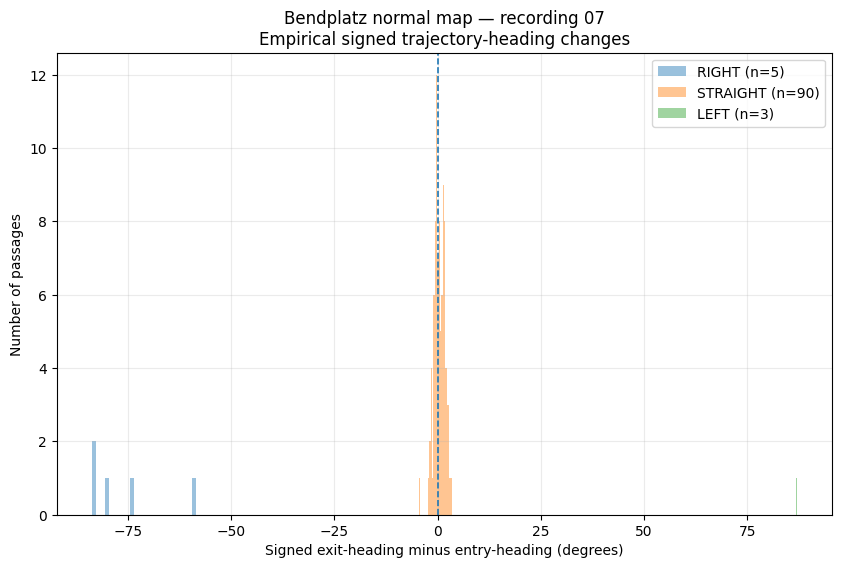

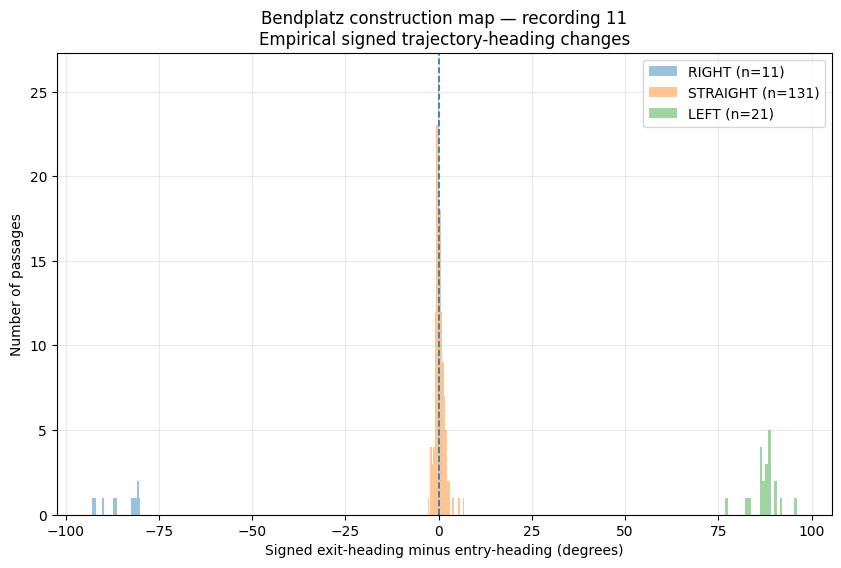

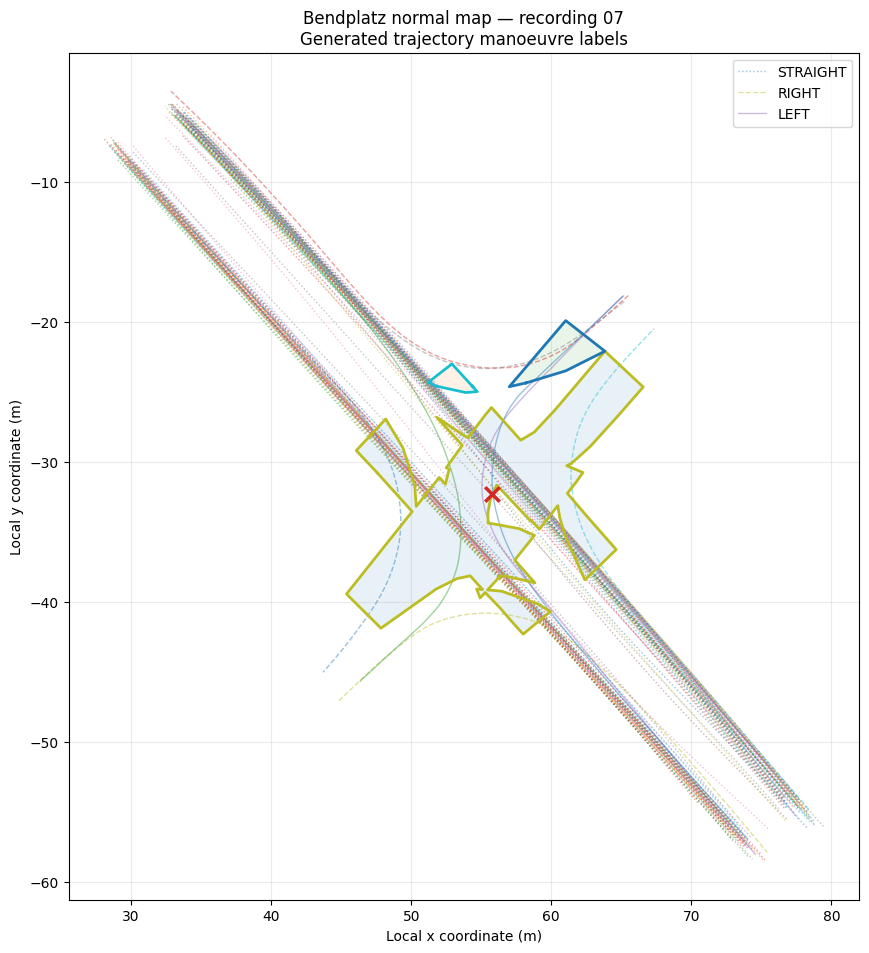

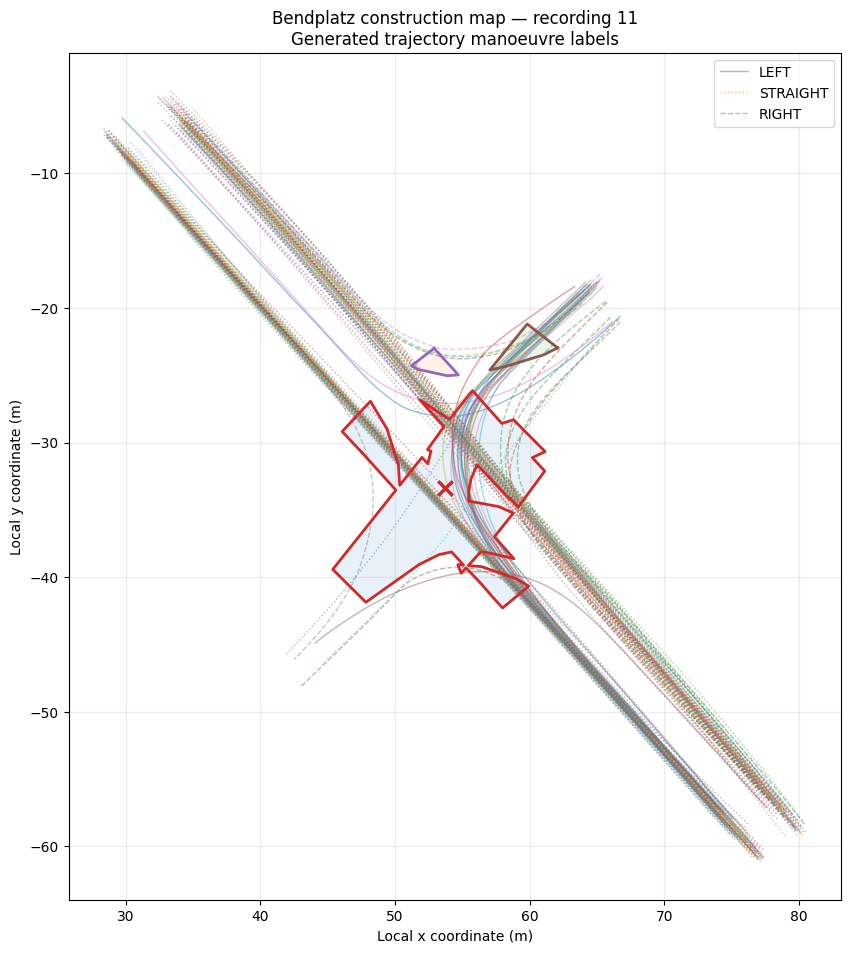


Exported label files:
  /content/ind_manoeuvre_labels/recording_07_manoeuvre_labels.csv
  /content/ind_manoeuvre_labels/recording_11_manoeuvre_labels.csv
  /content/ind_manoeuvre_labels/combined_manoeuvre_labels.csv

CELL 12 COMPLETED
LEFT, RIGHT and STRAIGHT labels were generated from four-arm intersection topology and measured vehicle heading changes.

No manually selected straight-versus-turn angle threshold was used.

Classification rules:
  STRAIGHT: exit arm is opposite the entry arm.
  LEFT: exit arm is adjacent and signed heading change is positive.
  RIGHT: exit arm is adjacent and signed heading change is negative.
  UTURN_LIKE: entry and exit belong to the same physical arm.

Before using the labels for model training, validate:
  1. LEFT, RIGHT and STRAIGHT trajectories look correct in the plots.
  2. Each arm transition has one dominant manoeuvre label.
  3. Transition-inconsistent passages are absent or individually explainable.
  4. The signed-angle distributions form s

In [ ]:
# Cell 12 — Generate LEFT, RIGHT and STRAIGHT manoeuvre labels

# Purpose
# -------
# Cell 11B produced:
#
#   - four ordered physical road arms;
#   - accepted complete vehicle passages;
#   - robust entry and exit headings.
#
# This cell assigns manoeuvre labels without manually choosing
# heading-angle thresholds.
#
# Classification logic
# --------------------
#
# For a four-arm intersection:
#
#   - the arm opposite the entry arm represents STRAIGHT;
#   - either adjacent arm represents a turn;
#   - the sign of measured heading change distinguishes LEFT and RIGHT.
#
# Signed heading change:
#
#   signed_turn_angle
#       = normalize(exit_heading - entry_heading)
#
# In the local Cartesian coordinate system:
#
#   positive angle -> counter-clockwise turn -> LEFT
#   negative angle -> clockwise turn         -> RIGHT
#
# Same-arm transitions are classified as UTURN-like and excluded from
# the final three-class dataset.
#
# The cell also validates labels using transition-level angle statistics,
# plots the empirical angle distributions and exports labelled CSV files.

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CHECK REQUIRED VARIABLES
# ============================================================

required_variables = [
    "NORMAL_PHYSICAL_ARM_PASSAGES",
    "CONSTRUCTION_PHYSICAL_ARM_PASSAGES",
    "NORMAL_PHYSICAL_ARM_TABLE",
    "CONSTRUCTION_PHYSICAL_ARM_TABLE",
    "NORMAL_PASSAGE_EXTRACTION",
    "CONSTRUCTION_PASSAGE_EXTRACTION",
    "NORMAL_PASSAGE_COLUMN_CONFIG",
    "CONSTRUCTION_PASSAGE_COLUMN_CONFIG",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cell 11B before Cell 12. "
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. ANGLE HELPERS
# ============================================================

def normalize_signed_angle_degrees(angle_degrees):
    """
    Normalize an angle to [-180, 180).
    """
    return (
        float(angle_degrees) + 180.0
    ) % 360.0 - 180.0


def circular_mean_degrees(angles_degrees):
    """
    Calculate the circular mean of angles in degrees.
    """
    angles = np.asarray(
        angles_degrees,
        dtype=float,
    )

    angles = angles[
        np.isfinite(angles)
    ]

    if len(angles) == 0:
        return np.nan

    radians = np.radians(angles)

    return normalize_signed_angle_degrees(
        np.degrees(
            np.arctan2(
                np.mean(np.sin(radians)),
                np.mean(np.cos(radians)),
            )
        )
    )


def circular_absolute_deviation_degrees(
    angles_degrees,
    center_degrees,
):
    """
    Calculate absolute circular deviation from a central angle.
    """
    angles = np.asarray(
        angles_degrees,
        dtype=float,
    )

    return np.abs([
        normalize_signed_angle_degrees(
            angle - center_degrees
        )
        for angle in angles
    ])


# ============================================================
# 3. CREATE CYCLIC PHYSICAL-ARM ORDER
# ============================================================

def create_cyclic_arm_order(physical_arm_table):
    """
    Create the circular arm order from physical-arm direction.

    Cell 11B named the arms according to circular radial direction.
    This function recalculates the order explicitly rather than relying
    only on the arm-name numbering.
    """
    arm_order = physical_arm_table.copy()

    arm_order["angle_360"] = (
        arm_order[
            "mean_radial_angle_degrees"
        ] % 360.0
    )

    arm_order = arm_order.sort_values(
        "angle_360"
    ).reset_index(drop=True)

    arm_order["cyclic_index"] = np.arange(
        len(arm_order),
        dtype=int,
    )

    return arm_order


NORMAL_CYCLIC_ARM_ORDER = create_cyclic_arm_order(
    NORMAL_PHYSICAL_ARM_TABLE
)

CONSTRUCTION_CYCLIC_ARM_ORDER = (
    create_cyclic_arm_order(
        CONSTRUCTION_PHYSICAL_ARM_TABLE
    )
)

print("Normal-map cyclic arm order:")
display(
    NORMAL_CYCLIC_ARM_ORDER[
        [
            "cyclic_index",
            "physical_arm_id",
            "mean_radial_angle_degrees",
            "entry_passage_count",
            "exit_passage_count",
        ]
    ]
)

print("\nConstruction-map cyclic arm order:")
display(
    CONSTRUCTION_CYCLIC_ARM_ORDER[
        [
            "cyclic_index",
            "physical_arm_id",
            "mean_radial_angle_degrees",
            "entry_passage_count",
            "exit_passage_count",
        ]
    ]
)


# ============================================================
# 4. ASSIGN TOPOLOGY-BASED MANOEUVRE LABELS
# ============================================================

def label_passage_manoeuvres(
    passages,
    cyclic_arm_order,
    map_variant,
):
    """
    Assign LEFT, RIGHT, STRAIGHT or UTURN-like labels.

    STRAIGHT is defined topologically:
        exit arm is opposite the entry arm.

    LEFT/RIGHT are defined from measured signed heading change:
        positive -> LEFT
        negative -> RIGHT
    """
    if len(cyclic_arm_order) != 4:
        raise ValueError(
            f"The {map_variant} map must contain exactly four "
            f"physical arms. Found {len(cyclic_arm_order)}."
        )

    arm_to_index = dict(
        zip(
            cyclic_arm_order[
                "physical_arm_id"
            ],
            cyclic_arm_order[
                "cyclic_index"
            ],
        )
    )

    labelled = passages.copy()

    labelled["entry_arm_cyclic_index"] = (
        labelled[
            "entry_physical_arm_id"
        ].map(arm_to_index)
    )

    labelled["exit_arm_cyclic_index"] = (
        labelled[
            "exit_physical_arm_id"
        ].map(arm_to_index)
    )

    if (
        labelled[
            "entry_arm_cyclic_index"
        ].isna().any()
        or labelled[
            "exit_arm_cyclic_index"
        ].isna().any()
    ):
        raise RuntimeError(
            f"Some {map_variant} passages could not be mapped "
            "to the cyclic physical-arm order."
        )

    labelled[
        "entry_arm_cyclic_index"
    ] = labelled[
        "entry_arm_cyclic_index"
    ].astype(int)

    labelled[
        "exit_arm_cyclic_index"
    ] = labelled[
        "exit_arm_cyclic_index"
    ].astype(int)

    # Cyclic arm displacement:
    #
    #   0 -> same arm
    #   1 or 3 -> adjacent arm
    #   2 -> opposite arm
    labelled["cyclic_arm_displacement"] = (
        labelled["exit_arm_cyclic_index"]
        - labelled["entry_arm_cyclic_index"]
    ) % 4

    labelled["signed_turn_angle_degrees"] = [
        normalize_signed_angle_degrees(
            exit_heading - entry_heading
        )
        for entry_heading, exit_heading
        in zip(
            labelled[
                "entry_heading_degrees"
            ],
            labelled[
                "exit_heading_degrees"
            ],
        )
    ]

    labelled[
        "absolute_turn_angle_degrees"
    ] = np.abs(
        labelled[
            "signed_turn_angle_degrees"
        ]
    )

    manoeuvre_labels = []
    label_reasons = []

    for row in labelled.itertuples(
        index=False
    ):
        displacement = (
            row.cyclic_arm_displacement
        )

        signed_angle = (
            row.signed_turn_angle_degrees
        )

        if displacement == 0:
            manoeuvre = "UTURN_LIKE"
            reason = (
                "Entry and exit belong to the same "
                "physical road arm."
            )

        elif displacement == 2:
            manoeuvre = "STRAIGHT"
            reason = (
                "Exit arm is topologically opposite "
                "the entry arm."
            )

        elif signed_angle > 0:
            manoeuvre = "LEFT"
            reason = (
                "Exit arm is adjacent and measured heading "
                "change is counter-clockwise."
            )

        elif signed_angle < 0:
            manoeuvre = "RIGHT"
            reason = (
                "Exit arm is adjacent and measured heading "
                "change is clockwise."
            )

        else:
            manoeuvre = "AMBIGUOUS"
            reason = (
                "Adjacent-arm passage has zero or undefined "
                "signed heading change."
            )

        manoeuvre_labels.append(
            manoeuvre
        )

        label_reasons.append(
            reason
        )

    labelled["manoeuvre_label"] = (
        manoeuvre_labels
    )

    labelled["manoeuvre_label_reason"] = (
        label_reasons
    )

    labelled["is_three_class_label"] = (
        labelled[
            "manoeuvre_label"
        ].isin(
            [
                "LEFT",
                "RIGHT",
                "STRAIGHT",
            ]
        )
    )

    return labelled


NORMAL_LABELLED_PASSAGES_ALL = (
    label_passage_manoeuvres(
        passages=NORMAL_PHYSICAL_ARM_PASSAGES,
        cyclic_arm_order=NORMAL_CYCLIC_ARM_ORDER,
        map_variant="normal",
    )
)

CONSTRUCTION_LABELLED_PASSAGES_ALL = (
    label_passage_manoeuvres(
        passages=(
            CONSTRUCTION_PHYSICAL_ARM_PASSAGES
        ),
        cyclic_arm_order=(
            CONSTRUCTION_CYCLIC_ARM_ORDER
        ),
        map_variant="construction",
    )
)


# ============================================================
# 5. RETAIN THE FINAL THREE CLASSES
# ============================================================

NORMAL_LABELLED_PASSAGES = (
    NORMAL_LABELLED_PASSAGES_ALL[
        NORMAL_LABELLED_PASSAGES_ALL[
            "is_three_class_label"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

CONSTRUCTION_LABELLED_PASSAGES = (
    CONSTRUCTION_LABELLED_PASSAGES_ALL[
        CONSTRUCTION_LABELLED_PASSAGES_ALL[
            "is_three_class_label"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

EXCLUDED_NORMAL_LABELLED_PASSAGES = (
    NORMAL_LABELLED_PASSAGES_ALL[
        ~NORMAL_LABELLED_PASSAGES_ALL[
            "is_three_class_label"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

EXCLUDED_CONSTRUCTION_LABELLED_PASSAGES = (
    CONSTRUCTION_LABELLED_PASSAGES_ALL[
        ~CONSTRUCTION_LABELLED_PASSAGES_ALL[
            "is_three_class_label"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 6. CREATE TRANSITION-LEVEL VALIDATION STATISTICS
# ============================================================

def create_transition_label_summary(
    labelled_passages,
):
    """
    Summarize each observed arm-to-arm movement.

    A physical arm transition should normally have one consistent
    manoeuvre class and a compact signed-angle distribution.
    """
    if labelled_passages.empty:
        return pd.DataFrame()

    summary_rows = []

    grouped = labelled_passages.groupby(
        [
            "entry_physical_arm_id",
            "exit_physical_arm_id",
        ],
        sort=True,
    )

    for (
        entry_arm,
        exit_arm,
    ), group in grouped:

        mean_angle = circular_mean_degrees(
            group[
                "signed_turn_angle_degrees"
            ]
        )

        absolute_deviations = (
            circular_absolute_deviation_degrees(
                group[
                    "signed_turn_angle_degrees"
                ],
                mean_angle,
            )
        )

        label_counts = (
            group[
                "manoeuvre_label"
            ]
            .value_counts()
            .to_dict()
        )

        dominant_label = (
            group[
                "manoeuvre_label"
            ]
            .value_counts()
            .index[0]
        )

        dominant_label_fraction = (
            group[
                "manoeuvre_label"
            ]
            .value_counts()
            .iloc[0]
            / len(group)
        )

        summary_rows.append({
            "entry_physical_arm_id":
                entry_arm,
            "exit_physical_arm_id":
                exit_arm,
            "passage_count":
                len(group),
            "dominant_manoeuvre_label":
                dominant_label,
            "dominant_label_fraction":
                dominant_label_fraction,
            "label_counts":
                label_counts,
            "mean_signed_turn_angle_degrees":
                mean_angle,
            "median_absolute_deviation_degrees":
                float(
                    np.median(
                        absolute_deviations
                    )
                ),
            "minimum_signed_turn_angle_degrees":
                float(
                    group[
                        "signed_turn_angle_degrees"
                    ].min()
                ),
            "maximum_signed_turn_angle_degrees":
                float(
                    group[
                        "signed_turn_angle_degrees"
                    ].max()
                ),
            "median_conflict_duration_seconds":
                float(
                    group[
                        "conflict_duration_seconds"
                    ].median()
                ),
        })

    return (
        pd.DataFrame(summary_rows)
        .sort_values(
            [
                "entry_physical_arm_id",
                "exit_physical_arm_id",
            ]
        )
        .reset_index(drop=True)
    )


NORMAL_TRANSITION_LABEL_SUMMARY = (
    create_transition_label_summary(
        NORMAL_LABELLED_PASSAGES_ALL
    )
)

CONSTRUCTION_TRANSITION_LABEL_SUMMARY = (
    create_transition_label_summary(
        CONSTRUCTION_LABELLED_PASSAGES_ALL
    )
)


# ============================================================
# 7. MARK TRANSITION-LEVEL CONSISTENCY
# ============================================================

def attach_transition_consistency(
    labelled_passages,
    transition_summary,
):
    """
    Add transition-level dominant-label information to every passage.
    """
    validation_columns = transition_summary[
        [
            "entry_physical_arm_id",
            "exit_physical_arm_id",
            "passage_count",
            "dominant_manoeuvre_label",
            "dominant_label_fraction",
            "mean_signed_turn_angle_degrees",
            "median_absolute_deviation_degrees",
        ]
    ].rename(
        columns={
            "passage_count":
                "transition_passage_count",
            "mean_signed_turn_angle_degrees":
                "transition_mean_turn_angle_degrees",
            "median_absolute_deviation_degrees":
                "transition_angle_mad_degrees",
        }
    )

    result = labelled_passages.merge(
        validation_columns,
        on=[
            "entry_physical_arm_id",
            "exit_physical_arm_id",
        ],
        how="left",
        validate="many_to_one",
    )

    result[
        "matches_transition_dominant_label"
    ] = (
        result[
            "manoeuvre_label"
        ]
        == result[
            "dominant_manoeuvre_label"
        ]
    )

    result[
        "deviation_from_transition_mean_degrees"
    ] = [
        abs(
            normalize_signed_angle_degrees(
                angle - transition_mean
            )
        )
        for angle, transition_mean
        in zip(
            result[
                "signed_turn_angle_degrees"
            ],
            result[
                "transition_mean_turn_angle_degrees"
            ],
        )
    ]

    return result


NORMAL_LABELLED_PASSAGES_ALL = (
    attach_transition_consistency(
        NORMAL_LABELLED_PASSAGES_ALL,
        NORMAL_TRANSITION_LABEL_SUMMARY,
    )
)

CONSTRUCTION_LABELLED_PASSAGES_ALL = (
    attach_transition_consistency(
        CONSTRUCTION_LABELLED_PASSAGES_ALL,
        CONSTRUCTION_TRANSITION_LABEL_SUMMARY,
    )
)

NORMAL_LABELLED_PASSAGES = (
    NORMAL_LABELLED_PASSAGES_ALL[
        NORMAL_LABELLED_PASSAGES_ALL[
            "is_three_class_label"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

CONSTRUCTION_LABELLED_PASSAGES = (
    CONSTRUCTION_LABELLED_PASSAGES_ALL[
        CONSTRUCTION_LABELLED_PASSAGES_ALL[
            "is_three_class_label"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 8. CLASS DISTRIBUTION
# ============================================================

def create_class_distribution(
    labelled_passages,
    map_variant,
):
    """
    Count labels and calculate proportions.
    """
    counts = (
        labelled_passages[
            "manoeuvre_label"
        ]
        .value_counts()
        .rename_axis(
            "manoeuvre_label"
        )
        .reset_index(
            name="passage_count"
        )
    )

    counts["map_variant"] = (
        map_variant
    )

    counts["class_proportion"] = (
        counts["passage_count"]
        / counts["passage_count"].sum()
    )

    return counts[
        [
            "map_variant",
            "manoeuvre_label",
            "passage_count",
            "class_proportion",
        ]
    ]


NORMAL_MANOEUVRE_CLASS_DISTRIBUTION = (
    create_class_distribution(
        NORMAL_LABELLED_PASSAGES,
        "normal",
    )
)

CONSTRUCTION_MANOEUVRE_CLASS_DISTRIBUTION = (
    create_class_distribution(
        CONSTRUCTION_LABELLED_PASSAGES,
        "construction",
    )
)

COMBINED_MANOEUVRE_CLASS_DISTRIBUTION = (
    pd.concat(
        [
            NORMAL_MANOEUVRE_CLASS_DISTRIBUTION,
            CONSTRUCTION_MANOEUVRE_CLASS_DISTRIBUTION,
        ],
        ignore_index=True,
    )
)

print("\n" + "=" * 80)
print("MANOEUVRE CLASS DISTRIBUTION")
print("=" * 80)

display(
    COMBINED_MANOEUVRE_CLASS_DISTRIBUTION
)


# ============================================================
# 9. LABEL QUALITY SUMMARY
# ============================================================

def create_label_quality_row(
    all_passages,
    final_passages,
    excluded_passages,
    map_variant,
):
    """
    Summarize generated-label quality.
    """
    return {
        "map_variant": map_variant,
        "input_passages":
            len(all_passages),
        "final_three_class_passages":
            len(final_passages),
        "excluded_passages":
            len(excluded_passages),
        "left_labels": int(
            (
                final_passages[
                    "manoeuvre_label"
                ] == "LEFT"
            ).sum()
        ),
        "right_labels": int(
            (
                final_passages[
                    "manoeuvre_label"
                ] == "RIGHT"
            ).sum()
        ),
        "straight_labels": int(
            (
                final_passages[
                    "manoeuvre_label"
                ] == "STRAIGHT"
            ).sum()
        ),
        "transition_consistent_passages": int(
            final_passages[
                "matches_transition_dominant_label"
            ].sum()
        ),
        "transition_inconsistent_passages": int(
            (
                ~final_passages[
                    "matches_transition_dominant_label"
                ]
            ).sum()
        ),
    }


LABEL_GENERATION_SUMMARY = pd.DataFrame([
    create_label_quality_row(
        all_passages=
            NORMAL_LABELLED_PASSAGES_ALL,
        final_passages=
            NORMAL_LABELLED_PASSAGES,
        excluded_passages=
            EXCLUDED_NORMAL_LABELLED_PASSAGES,
        map_variant="normal",
    ),
    create_label_quality_row(
        all_passages=
            CONSTRUCTION_LABELLED_PASSAGES_ALL,
        final_passages=
            CONSTRUCTION_LABELLED_PASSAGES,
        excluded_passages=
            EXCLUDED_CONSTRUCTION_LABELLED_PASSAGES,
        map_variant="construction",
    ),
])

print("\n" + "=" * 80)
print("LABEL GENERATION SUMMARY")
print("=" * 80)

display(LABEL_GENERATION_SUMMARY)


print("\nNormal-map transition label summary:")
display(NORMAL_TRANSITION_LABEL_SUMMARY)

print("\nConstruction-map transition label summary:")
display(CONSTRUCTION_TRANSITION_LABEL_SUMMARY)


# ============================================================
# 10. COMBINE NORMAL AND CONSTRUCTION LABELS
# ============================================================

FINAL_LABELLED_PASSAGES = pd.concat(
    [
        NORMAL_LABELLED_PASSAGES,
        CONSTRUCTION_LABELLED_PASSAGES,
    ],
    ignore_index=True,
)

FINAL_LABELLED_PASSAGES = (
    FINAL_LABELLED_PASSAGES.sort_values(
        [
            "recording_id",
            "track_id",
        ]
    )
    .reset_index(drop=True)
)

print("\nFinal combined labelled-passage table:")
display(
    FINAL_LABELLED_PASSAGES.head(20)
)


# ============================================================
# 11. PLOT THE EMPIRICAL TURN-ANGLE DISTRIBUTION
# ============================================================

def plot_turn_angle_distribution(
    labelled_passages,
    map_name,
):
    """
    Plot the measured signed heading-change distribution.
    """
    figure, axis = plt.subplots(
        figsize=(10, 6)
    )

    labels_in_order = [
        "RIGHT",
        "STRAIGHT",
        "LEFT",
    ]

    for label in labels_in_order:
        values = labelled_passages.loc[
            labelled_passages[
                "manoeuvre_label"
            ] == label,
            "signed_turn_angle_degrees",
        ]

        if len(values) == 0:
            continue

        axis.hist(
            values,
            bins=25,
            alpha=0.45,
            label=(
                f"{label} "
                f"(n={len(values)})"
            ),
        )

    axis.axvline(
        0.0,
        linestyle="--",
        linewidth=1.2,
    )

    axis.set_title(
        f"{map_name}\n"
        "Empirical signed trajectory-heading changes"
    )

    axis.set_xlabel(
        "Signed exit-heading minus entry-heading (degrees)"
    )

    axis.set_ylabel(
        "Number of passages"
    )

    axis.legend()
    axis.grid(True, alpha=0.25)

    plt.show()


plot_turn_angle_distribution(
    NORMAL_LABELLED_PASSAGES,
    "Bendplatz normal map — recording 07",
)

plot_turn_angle_distribution(
    CONSTRUCTION_LABELLED_PASSAGES,
    "Bendplatz construction map — recording 11",
)


# ============================================================
# 12. PLOT TRAJECTORIES BY MANOEUVRE CLASS
# ============================================================

def plot_labelled_trajectories(
    labelled_passages,
    passage_extraction,
    column_config,
    conflict_geometry,
    intersection_center,
    map_name,
):
    """
    Plot complete trajectories by generated manoeuvre label.
    """
    x_column = column_config["x"]
    y_column = column_config["y"]

    figure, axis = plt.subplots(
        figsize=(12, 11)
    )

    line_styles = {
        "LEFT": "-",
        "RIGHT": "--",
        "STRAIGHT": ":",
    }

    label_seen = set()

    for passage in labelled_passages.itertuples(
        index=False
    ):
        track_information = (
            passage_extraction[
                "passage_tracks"
            ][passage.passage_id]
        )

        track = track_information[
            "full_track"
        ]

        plot_label = (
            passage.manoeuvre_label
            if passage.manoeuvre_label
            not in label_seen
            else None
        )

        axis.plot(
            track[x_column],
            track[y_column],
            linestyle=line_styles[
                passage.manoeuvre_label
            ],
            linewidth=1.0,
            alpha=0.45,
            label=plot_label,
            zorder=2,
        )

        label_seen.add(
            passage.manoeuvre_label
        )

    # Draw conflict geometry.
    if conflict_geometry.geom_type == "Polygon":
        geometry_parts = [
            conflict_geometry
        ]
    elif (
        conflict_geometry.geom_type
        == "MultiPolygon"
    ):
        geometry_parts = list(
            conflict_geometry.geoms
        )
    else:
        geometry_parts = [
            geometry
            for geometry in conflict_geometry.geoms
            if geometry.geom_type == "Polygon"
        ]

    for polygon_part in geometry_parts:
        exterior_x, exterior_y = (
            polygon_part.exterior.xy
        )

        axis.plot(
            exterior_x,
            exterior_y,
            linewidth=2.0,
            zorder=6,
        )

        axis.fill(
            exterior_x,
            exterior_y,
            alpha=0.10,
            zorder=1,
        )

    axis.scatter(
        intersection_center[0],
        intersection_center[1],
        marker="x",
        s=110,
        linewidths=2.5,
        zorder=8,
    )

    axis.set_title(
        f"{map_name}\n"
        "Generated trajectory manoeuvre labels"
    )

    axis.set_xlabel(
        "Local x coordinate (m)"
    )

    axis.set_ylabel(
        "Local y coordinate (m)"
    )

    axis.set_aspect(
        "equal",
        adjustable="box",
    )

    axis.grid(True, alpha=0.25)
    axis.legend()

    plt.show()


plot_labelled_trajectories(
    labelled_passages=
        NORMAL_LABELLED_PASSAGES,
    passage_extraction=
        NORMAL_PASSAGE_EXTRACTION,
    column_config=
        NORMAL_PASSAGE_COLUMN_CONFIG,
    conflict_geometry=
        NORMAL_CONFLICT_GEOMETRY,
    intersection_center=
        NORMAL_INTERSECTION_CENTER,
    map_name=(
        "Bendplatz normal map — recording 07"
    ),
)

plot_labelled_trajectories(
    labelled_passages=
        CONSTRUCTION_LABELLED_PASSAGES,
    passage_extraction=
        CONSTRUCTION_PASSAGE_EXTRACTION,
    column_config=
        CONSTRUCTION_PASSAGE_COLUMN_CONFIG,
    conflict_geometry=
        CONSTRUCTION_CONFLICT_GEOMETRY,
    intersection_center=
        CONSTRUCTION_INTERSECTION_CENTER,
    map_name=(
        "Bendplatz construction map — recording 11"
    ),
)


# ============================================================
# 13. EXPORT LABELLED TABLES
# ============================================================

MANOEUVRE_LABEL_OUTPUT_DIRECTORY = Path(
    "/content/ind_manoeuvre_labels"
)

MANOEUVRE_LABEL_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

NORMAL_LABEL_OUTPUT_PATH = (
    MANOEUVRE_LABEL_OUTPUT_DIRECTORY
    / "recording_07_manoeuvre_labels.csv"
)

CONSTRUCTION_LABEL_OUTPUT_PATH = (
    MANOEUVRE_LABEL_OUTPUT_DIRECTORY
    / "recording_11_manoeuvre_labels.csv"
)

COMBINED_LABEL_OUTPUT_PATH = (
    MANOEUVRE_LABEL_OUTPUT_DIRECTORY
    / "combined_manoeuvre_labels.csv"
)

NORMAL_LABELLED_PASSAGES.to_csv(
    NORMAL_LABEL_OUTPUT_PATH,
    index=False,
)

CONSTRUCTION_LABELLED_PASSAGES.to_csv(
    CONSTRUCTION_LABEL_OUTPUT_PATH,
    index=False,
)

FINAL_LABELLED_PASSAGES.to_csv(
    COMBINED_LABEL_OUTPUT_PATH,
    index=False,
)

print("\nExported label files:")
print(" ", NORMAL_LABEL_OUTPUT_PATH)
print(" ", CONSTRUCTION_LABEL_OUTPUT_PATH)
print(" ", COMBINED_LABEL_OUTPUT_PATH)


# ============================================================
# 14. STORE STANDARD NOTEBOOK OUTPUTS
# ============================================================

LABELLED_PASSAGES = {
    "normal": NORMAL_LABELLED_PASSAGES,
    "construction":
        CONSTRUCTION_LABELLED_PASSAGES,
}

ALL_CLASSIFIED_PASSAGES = {
    "normal":
        NORMAL_LABELLED_PASSAGES_ALL,
    "construction":
        CONSTRUCTION_LABELLED_PASSAGES_ALL,
}

TRANSITION_LABEL_SUMMARIES = {
    "normal":
        NORMAL_TRANSITION_LABEL_SUMMARY,
    "construction":
        CONSTRUCTION_TRANSITION_LABEL_SUMMARY,
}

MANOEUVRE_CLASS_DISTRIBUTIONS = {
    "normal":
        NORMAL_MANOEUVRE_CLASS_DISTRIBUTION,
    "construction":
        CONSTRUCTION_MANOEUVRE_CLASS_DISTRIBUTION,
}


# ============================================================
# 15. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 12 COMPLETED")
print("=" * 80)

print(
    "LEFT, RIGHT and STRAIGHT labels were generated from four-arm "
    "intersection topology and measured vehicle heading changes."
)

print(
    "\nNo manually selected straight-versus-turn angle threshold "
    "was used."
)

print(
    "\nClassification rules:"
)

print(
    "  STRAIGHT: exit arm is opposite the entry arm."
)

print(
    "  LEFT: exit arm is adjacent and signed heading change is positive."
)

print(
    "  RIGHT: exit arm is adjacent and signed heading change is negative."
)

print(
    "  UTURN_LIKE: entry and exit belong to the same physical arm."
)

print(
    "\nBefore using the labels for model training, validate:"
)

print(
    "  1. LEFT, RIGHT and STRAIGHT trajectories look correct in the plots."
)

print(
    "  2. Each arm transition has one dominant manoeuvre label."
)

print(
    "  3. Transition-inconsistent passages are absent or individually "
    "explainable."
)

print(
    "  4. The signed-angle distributions form sensible groups around "
    "negative-turn, near-zero and positive-turn motion."
)

print(
    "\nThe next stage is to repeat this label-generation pipeline for "
    "all recordings 07–17 and build the complete supervised-learning "
    "dataset."
)


Fixed normal-map road-arm reference:


,physical_arm_id,reference_radial_angle_degrees,reference_unit_x,reference_unit_y,map_variant,angle_360,fixed_cyclic_index
0,ROAD_ARM_1,54.751691,0.577121,0.816659,normal,54.751691,0
1,ROAD_ARM_2,133.518584,-0.688590,0.725151,normal,133.518584,1
2,ROAD_ARM_3,-122.380728,-0.535543,-0.844508,normal,237.619272,2
3,ROAD_ARM_4,-50.403185,0.637381,-0.770549,normal,309.596815,3



Fixed construction-map road-arm reference:


,physical_arm_id,reference_radial_angle_degrees,reference_unit_x,reference_unit_y,map_variant,angle_360,fixed_cyclic_index
0,ROAD_ARM_1,52.892800,0.603308,0.797508,construction,52.892800,0
1,ROAD_ARM_2,126.604751,-0.596291,0.802768,construction,126.604751,1
2,ROAD_ARM_3,-127.786022,-0.612714,-0.790305,construction,232.213978,2
3,ROAD_ARM_4,-43.027763,0.731023,-0.682353,construction,316.972237,3



Data-derived fixed-arm assignment limits:


...

,recording_id,map_variant,manoeuvre_label,passage_count,recording_class_proportion
0,7,normal,LEFT,3,0.031250
1,7,normal,RIGHT,4,0.041667
2,7,normal,STRAIGHT,89,0.927083
3,8,normal,LEFT,8,0.046784
4,8,normal,RIGHT,7,0.040936
5,8,normal,STRAIGHT,156,0.912281
6,9,normal,LEFT,6,0.053571
7,9,normal,RIGHT,2,0.017857
8,9,normal,STRAIGHT,104,0.928571
9,10,normal,LEFT,4,0.033058



OVERALL MANOEUVRE CLASS COUNTS


,manoeuvre_label,passage_count,class_proportion
0,STRAIGHT,1271,0.810587
1,LEFT,247,0.157526
2,RIGHT,50,0.031888



DATASET QUALITY SUMMARY


,successful_recordings,failed_recordings,total_labels,unique_tracks,duplicate_recording_track_pairs,missing_manoeuvre_labels,transition_inconsistent_labels,normal_map_labels,construction_map_labels
0,11,0,1568,1568,0,0,0,500,1068


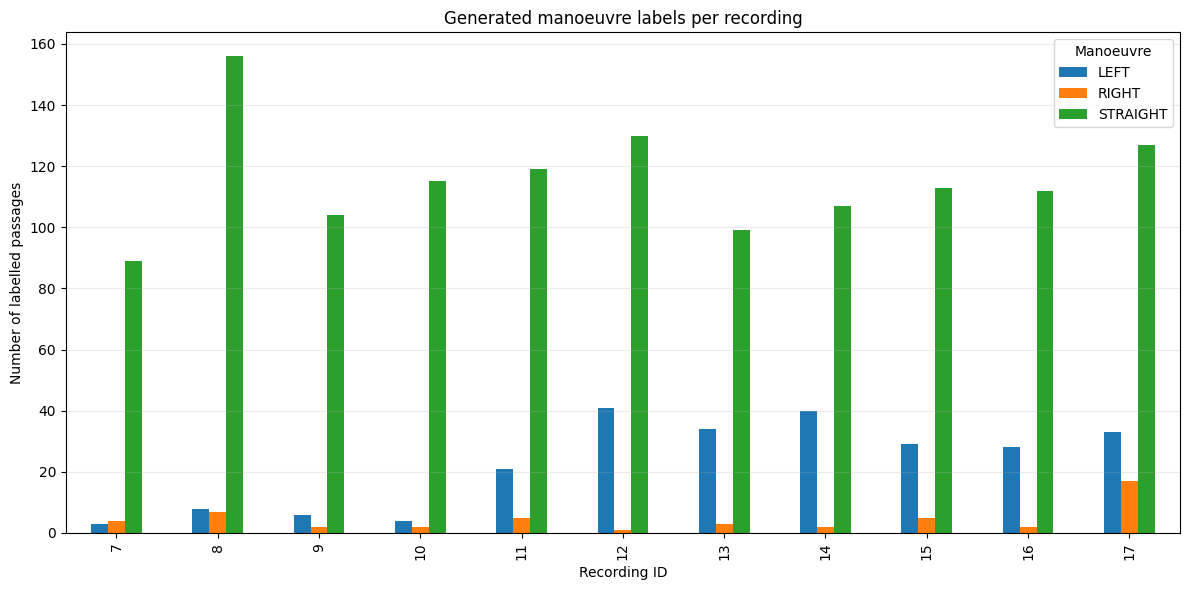

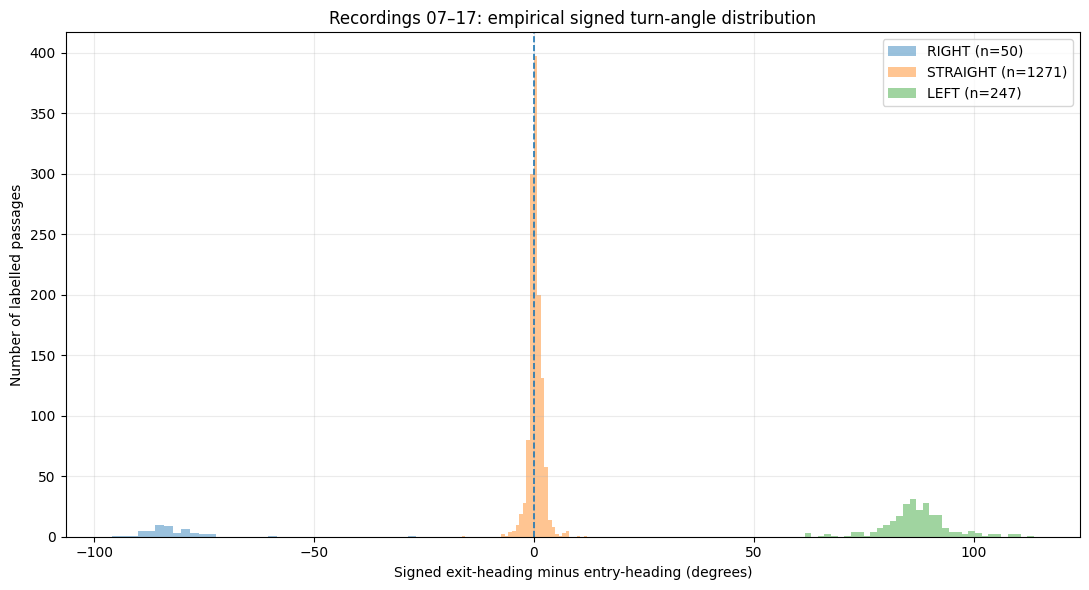


CELL 13 COMPLETED
Recordings 07–17 were processed using fixed, map-specific physical road-arm references.

Recordings 07–10 used the normal Bendplatz geometry and arm reference.
Recordings 11–17 used the construction Bendplatz geometry and arm reference.

Physical arms were not independently rediscovered or renamed for each recording.

Endpoint-assignment quality limits were derived from the validated reference recordings rather than manually selected.

Complete labelled dataset:
  /content/ind_manoeuvre_dataset_07_17/ind_bendplatz_manoeuvre_labels_07_17.csv

Batch summary:
  /content/ind_manoeuvre_dataset_07_17/batch_processing_summary.csv

Rejection diagnostics:
  /content/ind_manoeuvre_dataset_07_17/all_passage_extraction_rejections.csv
  /content/ind_manoeuvre_dataset_07_17/all_fixed_arm_assignment_rejections.csv
  /content/ind_manoeuvre_dataset_07_17/all_manoeuvre_class_exclusions.csv

Before model training, verify:
  1. All eleven recordings have processing_status='success'.
  2

In [ ]:
# Cell 13 — Batch-process recordings 07–17 and build the complete
#           labelled manoeuvre dataset

# Purpose
# -------
# Cells 11–12 validated the complete pipeline on:
#
#   recording 07 -> normal Bendplatz map
#   recording 11 -> construction Bendplatz map
#
# This cell applies the validated procedure to all recordings:
#
#   07, 08, 09, 10 -> normal map
#   11, 12, 13, 14, 15, 16, 17 -> construction map
#
# Important scientific decision
# -----------------------------
# Physical road arms are NOT rediscovered independently for every
# recording.
#
# Instead:
#
#   - recordings 07–10 use the fixed normal-map arm directions;
#   - recordings 11–17 use the fixed construction-map arm directions.
#
# This keeps ROAD_ARM IDs geometrically consistent across recordings.
#
# Pipeline for each recording:
#
#   load trajectories
#          ↓
#   retain road vehicles
#          ↓
#   extract complete conflict-region passages
#          ↓
#   assign entry/exit endpoints to fixed physical arms
#          ↓
#   reject same-arm or geometrically uncertain cases
#          ↓
#   derive LEFT / RIGHT / STRAIGHT
#          ↓
#   validate transition consistency
#          ↓
#   export per-recording and combined CSV files

from pathlib import Path
import traceback
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CHECK REQUIRED VARIABLES AND FUNCTIONS
# ============================================================

required_variables = [
    # Fixed map geometry
    "NORMAL_CONFLICT_GEOMETRY",
    "CONSTRUCTION_CONFLICT_GEOMETRY",
    "NORMAL_INTERSECTION_CENTER",
    "CONSTRUCTION_INTERSECTION_CENTER",
    "NORMAL_MEDIAN_LANE_WIDTH",
    "CONSTRUCTION_MEDIAN_LANE_WIDTH",

    # Fixed physical arm references
    "NORMAL_PHYSICAL_ARM_TABLE",
    "CONSTRUCTION_PHYSICAL_ARM_TABLE",

    # Functions created in previous cells
    "load_passage_recording",
    "prepare_passage_tracks",
    "extract_complete_passages",
    "normalize_signed_angle_degrees",
    "create_cyclic_arm_order",
    "label_passage_manoeuvres",
    "create_transition_label_summary",
    "attach_transition_consistency",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cells 11, 11B and 12 before Cell 13.\n"
        f"Missing variables or functions: {missing_variables}"
    )


# ============================================================
# 2. BATCH CONFIGURATION
# ============================================================

BATCH_RECORDING_IDS = list(range(7, 18))

NORMAL_RECORDING_IDS = {
    7, 8, 9, 10
}

CONSTRUCTION_RECORDING_IDS = {
    11, 12, 13, 14, 15, 16, 17
}

BATCH_OUTPUT_DIRECTORY = Path(
    "/content/ind_manoeuvre_dataset_07_17"
)

PER_RECORDING_OUTPUT_DIRECTORY = (
    BATCH_OUTPUT_DIRECTORY
    / "per_recording"
)

DIAGNOSTIC_OUTPUT_DIRECTORY = (
    BATCH_OUTPUT_DIRECTORY
    / "diagnostics"
)

BATCH_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

PER_RECORDING_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

DIAGNOSTIC_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 3. CREATE FIXED MAP-SPECIFIC ARM REFERENCES
# ============================================================

def build_fixed_arm_reference(
    physical_arm_table,
    map_variant,
):
    """
    Create a fixed road-arm reference from the validated arm table.

    Each arm is represented by its radial direction from the physical
    intersection centre.

    Returns
    -------
    pandas.DataFrame
        Fixed arm IDs, angles and unit direction vectors.
    """

    reference = physical_arm_table[
        [
            "physical_arm_id",
            "mean_radial_angle_degrees",
        ]
    ].copy()

    reference = reference.rename(
        columns={
            "mean_radial_angle_degrees":
                "reference_radial_angle_degrees"
        }
    )

    reference[
        "reference_radial_angle_degrees"
    ] = pd.to_numeric(
        reference[
            "reference_radial_angle_degrees"
        ],
        errors="raise",
    )

    angle_radians = np.radians(
        reference[
            "reference_radial_angle_degrees"
        ].to_numpy()
    )

    reference["reference_unit_x"] = np.cos(
        angle_radians
    )

    reference["reference_unit_y"] = np.sin(
        angle_radians
    )

    reference["map_variant"] = map_variant

    reference["angle_360"] = (
        reference[
            "reference_radial_angle_degrees"
        ] % 360.0
    )

    reference = reference.sort_values(
        "angle_360"
    ).reset_index(drop=True)

    reference["fixed_cyclic_index"] = np.arange(
        len(reference),
        dtype=int,
    )

    if len(reference) != 4:
        raise ValueError(
            f"The {map_variant} reference must contain exactly "
            f"four physical arms. Found {len(reference)}."
        )

    return reference


NORMAL_FIXED_ARM_REFERENCE = (
    build_fixed_arm_reference(
        NORMAL_PHYSICAL_ARM_TABLE,
        map_variant="normal",
    )
)

CONSTRUCTION_FIXED_ARM_REFERENCE = (
    build_fixed_arm_reference(
        CONSTRUCTION_PHYSICAL_ARM_TABLE,
        map_variant="construction",
    )
)

FIXED_ARM_REFERENCES = {
    "normal": NORMAL_FIXED_ARM_REFERENCE,
    "construction":
        CONSTRUCTION_FIXED_ARM_REFERENCE,
}


print("\nFixed normal-map road-arm reference:")
display(NORMAL_FIXED_ARM_REFERENCE)

print("\nFixed construction-map road-arm reference:")
display(CONSTRUCTION_FIXED_ARM_REFERENCE)


# ============================================================
# 4. MAP CONFIGURATION LOOKUP
# ============================================================

def get_recording_map_configuration(
    recording_id,
):
    """
    Return all map-specific resources for one recording.
    """

    recording_id = int(recording_id)

    if recording_id in NORMAL_RECORDING_IDS:
        return {
            "map_variant": "normal",
            "conflict_geometry":
                NORMAL_CONFLICT_GEOMETRY,
            "intersection_center":
                NORMAL_INTERSECTION_CENTER,
            "median_lane_width_m":
                NORMAL_MEDIAN_LANE_WIDTH,
            "passage_region_buffer_m":
                NORMAL_MEDIAN_LANE_WIDTH / 2.0,
            "fixed_arm_reference":
                NORMAL_FIXED_ARM_REFERENCE,
        }

    if recording_id in CONSTRUCTION_RECORDING_IDS:
        return {
            "map_variant": "construction",
            "conflict_geometry":
                CONSTRUCTION_CONFLICT_GEOMETRY,
            "intersection_center":
                CONSTRUCTION_INTERSECTION_CENTER,
            "median_lane_width_m":
                CONSTRUCTION_MEDIAN_LANE_WIDTH,
            "passage_region_buffer_m":
                CONSTRUCTION_MEDIAN_LANE_WIDTH / 2.0,
            "fixed_arm_reference":
                CONSTRUCTION_FIXED_ARM_REFERENCE,
        }

    raise ValueError(
        f"Recording {recording_id:02d} is not included in "
        "the configured Bendplatz recording groups."
    )


# ============================================================
# 5. FIXED-ARM ASSIGNMENT
# ============================================================

def angular_difference_degrees(
    first_angle,
    second_angle,
):
    """
    Return the smallest absolute difference between two angles.
    """

    return abs(
        normalize_signed_angle_degrees(
            float(first_angle)
            - float(second_angle)
        )
    )


def calculate_reference_arm_boundaries(
    fixed_arm_reference,
):
    """
    Derive each arm's circular Voronoi boundaries.

    Each boundary lies halfway between two neighbouring fixed arm
    directions.

    These boundaries are diagnostics. Endpoint assignment itself uses
    the nearest fixed arm direction.
    """

    reference = fixed_arm_reference.sort_values(
        "angle_360"
    ).reset_index(drop=True)

    rows = []
    arm_count = len(reference)

    for index in range(arm_count):
        previous_index = (
            index - 1
        ) % arm_count

        next_index = (
            index + 1
        ) % arm_count

        current_angle = float(
            reference.loc[
                index,
                "angle_360",
            ]
        )

        previous_angle = float(
            reference.loc[
                previous_index,
                "angle_360",
            ]
        )

        next_angle = float(
            reference.loc[
                next_index,
                "angle_360",
            ]
        )

        if previous_index > index:
            previous_angle -= 360.0

        if next_index < index:
            next_angle += 360.0

        lower_boundary = (
            previous_angle + current_angle
        ) / 2.0

        upper_boundary = (
            current_angle + next_angle
        ) / 2.0

        rows.append({
            "physical_arm_id":
                reference.loc[
                    index,
                    "physical_arm_id",
                ],
            "reference_angle_degrees":
                normalize_signed_angle_degrees(
                    current_angle
                ),
            "lower_boundary_degrees":
                normalize_signed_angle_degrees(
                    lower_boundary
                ),
            "upper_boundary_degrees":
                normalize_signed_angle_degrees(
                    upper_boundary
                ),
            "half_width_to_nearest_boundary_degrees":
                min(
                    current_angle
                    - lower_boundary,
                    upper_boundary
                    - current_angle,
                ),
        })

    return pd.DataFrame(rows)


NORMAL_FIXED_ARM_BOUNDARIES = (
    calculate_reference_arm_boundaries(
        NORMAL_FIXED_ARM_REFERENCE
    )
)

CONSTRUCTION_FIXED_ARM_BOUNDARIES = (
    calculate_reference_arm_boundaries(
        CONSTRUCTION_FIXED_ARM_REFERENCE
    )
)


def assign_angle_to_fixed_arm(
    angle_degrees,
    fixed_arm_reference,
):
    """
    Assign one radial direction to its nearest fixed physical arm.

    Returns the best and second-best angular distances. Their difference
    is used as an assignment-confidence diagnostic.
    """

    candidate_rows = []

    for reference_row in (
        fixed_arm_reference.itertuples(
            index=False
        )
    ):
        difference = angular_difference_degrees(
            angle_degrees,
            reference_row
            .reference_radial_angle_degrees,
        )

        candidate_rows.append({
            "physical_arm_id":
                reference_row.physical_arm_id,
            "reference_angle_degrees":
                reference_row
                .reference_radial_angle_degrees,
            "angular_difference_degrees":
                difference,
        })

    candidates = (
        pd.DataFrame(candidate_rows)
        .sort_values(
            "angular_difference_degrees"
        )
        .reset_index(drop=True)
    )

    best = candidates.iloc[0]
    second_best = candidates.iloc[1]

    return {
        "physical_arm_id":
            best["physical_arm_id"],
        "reference_angle_degrees":
            float(
                best[
                    "reference_angle_degrees"
                ]
            ),
        "angular_error_degrees":
            float(
                best[
                    "angular_difference_degrees"
                ]
            ),
        "second_best_arm_id":
            second_best[
                "physical_arm_id"
            ],
        "second_best_angular_error_degrees":
            float(
                second_best[
                    "angular_difference_degrees"
                ]
            ),
        "assignment_margin_degrees":
            float(
                second_best[
                    "angular_difference_degrees"
                ]
                - best[
                    "angular_difference_degrees"
                ]
            ),
    }


def assign_passages_to_fixed_arms(
    passages,
    fixed_arm_reference,
    map_variant,
):
    """
    Assign every passage entry and exit endpoint to fixed road arms.
    """

    if passages.empty:
        return passages.copy()

    assigned = passages.copy()

    entry_assignments = [
        assign_angle_to_fixed_arm(
            angle,
            fixed_arm_reference,
        )
        for angle in assigned[
            "entry_radial_angle_degrees"
        ]
    ]

    exit_assignments = [
        assign_angle_to_fixed_arm(
            angle,
            fixed_arm_reference,
        )
        for angle in assigned[
            "exit_radial_angle_degrees"
        ]
    ]

    assigned[
        "entry_physical_arm_id"
    ] = [
        result["physical_arm_id"]
        for result in entry_assignments
    ]

    assigned[
        "exit_physical_arm_id"
    ] = [
        result["physical_arm_id"]
        for result in exit_assignments
    ]

    assigned[
        "entry_reference_angle_degrees"
    ] = [
        result["reference_angle_degrees"]
        for result in entry_assignments
    ]

    assigned[
        "exit_reference_angle_degrees"
    ] = [
        result["reference_angle_degrees"]
        for result in exit_assignments
    ]

    assigned[
        "entry_arm_angular_error_degrees"
    ] = [
        result["angular_error_degrees"]
        for result in entry_assignments
    ]

    assigned[
        "exit_arm_angular_error_degrees"
    ] = [
        result["angular_error_degrees"]
        for result in exit_assignments
    ]

    assigned[
        "entry_arm_assignment_margin_degrees"
    ] = [
        result["assignment_margin_degrees"]
        for result in entry_assignments
    ]

    assigned[
        "exit_arm_assignment_margin_degrees"
    ] = [
        result["assignment_margin_degrees"]
        for result in exit_assignments
    ]

    assigned[
        "entry_second_best_arm_id"
    ] = [
        result["second_best_arm_id"]
        for result in entry_assignments
    ]

    assigned[
        "exit_second_best_arm_id"
    ] = [
        result["second_best_arm_id"]
        for result in exit_assignments
    ]

    assigned["map_variant"] = map_variant

    assigned["same_physical_arm"] = (
        assigned[
            "entry_physical_arm_id"
        ]
        == assigned[
            "exit_physical_arm_id"
        ]
    )

    return assigned


# ============================================================
# 6. DERIVE DATA-SUPPORTED ARM-ASSIGNMENT QUALITY LIMITS
# ============================================================

def derive_reference_assignment_limits(
    reference_passages,
    fixed_arm_reference,
    map_variant,
):
    """
    Derive endpoint-assignment quality limits from the validated reference
    recording.

    The limit is based on the observed fixed-arm assignment errors in the
    validated reference data, rather than an arbitrary angle threshold.

    A Tukey upper fence is used:

        Q3 + 1.5 × IQR

    Entry and exit errors are pooled.
    """

    assigned_reference = (
        assign_passages_to_fixed_arms(
            reference_passages,
            fixed_arm_reference,
            map_variant,
        )
    )

    errors = np.concatenate([
        assigned_reference[
            "entry_arm_angular_error_degrees"
        ].to_numpy(),
        assigned_reference[
            "exit_arm_angular_error_degrees"
        ].to_numpy(),
    ])

    margins = np.concatenate([
        assigned_reference[
            "entry_arm_assignment_margin_degrees"
        ].to_numpy(),
        assigned_reference[
            "exit_arm_assignment_margin_degrees"
        ].to_numpy(),
    ])

    error_q1 = float(
        np.percentile(errors, 25)
    )

    error_q3 = float(
        np.percentile(errors, 75)
    )

    error_iqr = error_q3 - error_q1

    maximum_accepted_error = (
        error_q3 + 1.5 * error_iqr
    )

    margin_q1 = float(
        np.percentile(margins, 25)
    )

    margin_q3 = float(
        np.percentile(margins, 75)
    )

    margin_iqr = margin_q3 - margin_q1

    minimum_accepted_margin = max(
        0.0,
        margin_q1 - 1.5 * margin_iqr,
    )

    return {
        "map_variant": map_variant,
        "reference_passage_count":
            len(reference_passages),
        "error_q1_degrees": error_q1,
        "error_q3_degrees": error_q3,
        "error_iqr_degrees": error_iqr,
        "maximum_accepted_error_degrees":
            maximum_accepted_error,
        "margin_q1_degrees": margin_q1,
        "margin_q3_degrees": margin_q3,
        "margin_iqr_degrees": margin_iqr,
        "minimum_accepted_margin_degrees":
            minimum_accepted_margin,
    }


NORMAL_ARM_ASSIGNMENT_LIMITS = (
    derive_reference_assignment_limits(
        reference_passages=
            NORMAL_PHYSICAL_ARM_PASSAGES,
        fixed_arm_reference=
            NORMAL_FIXED_ARM_REFERENCE,
        map_variant="normal",
    )
)

CONSTRUCTION_ARM_ASSIGNMENT_LIMITS = (
    derive_reference_assignment_limits(
        reference_passages=
            CONSTRUCTION_PHYSICAL_ARM_PASSAGES,
        fixed_arm_reference=
            CONSTRUCTION_FIXED_ARM_REFERENCE,
        map_variant="construction",
    )
)

ARM_ASSIGNMENT_LIMITS = {
    "normal": NORMAL_ARM_ASSIGNMENT_LIMITS,
    "construction":
        CONSTRUCTION_ARM_ASSIGNMENT_LIMITS,
}

print("\nData-derived fixed-arm assignment limits:")

display(
    pd.DataFrame([
        NORMAL_ARM_ASSIGNMENT_LIMITS,
        CONSTRUCTION_ARM_ASSIGNMENT_LIMITS,
    ])
)


# ============================================================
# 7. FILTER ASSIGNMENT-QUALITY FAILURES
# ============================================================

def separate_arm_assignment_quality(
    assigned_passages,
    assignment_limits,
):
    """
    Separate accepted and rejected fixed-arm assignments.

    Rejection conditions:
        - same entry and exit physical arm;
        - excessive angular error relative to reference recordings;
        - insufficient separation from the second-best arm.
    """

    if assigned_passages.empty:
        return (
            assigned_passages.copy(),
            assigned_passages.copy(),
        )

    maximum_error = assignment_limits[
        "maximum_accepted_error_degrees"
    ]

    minimum_margin = assignment_limits[
        "minimum_accepted_margin_degrees"
    ]

    evaluated = assigned_passages.copy()

    rejection_reason_lists = []

    for row in evaluated.itertuples(
        index=False
    ):
        reasons = []

        if row.same_physical_arm:
            reasons.append(
                "same_entry_and_exit_physical_arm"
            )

        if (
            row.entry_arm_angular_error_degrees
            > maximum_error
        ):
            reasons.append(
                "entry_endpoint_exceeds_reference_error"
            )

        if (
            row.exit_arm_angular_error_degrees
            > maximum_error
        ):
            reasons.append(
                "exit_endpoint_exceeds_reference_error"
            )

        if (
            row.entry_arm_assignment_margin_degrees
            < minimum_margin
        ):
            reasons.append(
                "entry_arm_assignment_is_ambiguous"
            )

        if (
            row.exit_arm_assignment_margin_degrees
            < minimum_margin
        ):
            reasons.append(
                "exit_arm_assignment_is_ambiguous"
            )

        rejection_reason_lists.append(
            reasons
        )

    evaluated[
        "arm_assignment_rejection_reasons"
    ] = [
        "; ".join(reasons)
        for reasons in rejection_reason_lists
    ]

    evaluated[
        "arm_assignment_accepted"
    ] = [
        len(reasons) == 0
        for reasons in rejection_reason_lists
    ]

    accepted = evaluated[
        evaluated[
            "arm_assignment_accepted"
        ]
    ].copy()

    rejected = evaluated[
        ~evaluated[
            "arm_assignment_accepted"
        ]
    ].copy()

    return (
        accepted.reset_index(drop=True),
        rejected.reset_index(drop=True),
    )


# ============================================================
# 8. BUILD CELL-12-COMPATIBLE CYCLIC ARM TABLE
# ============================================================

def fixed_reference_to_physical_arm_table(
    fixed_arm_reference,
):
    """
    Convert a fixed arm reference into the schema expected by
    create_cyclic_arm_order().
    """

    return (
        fixed_arm_reference[
            [
                "physical_arm_id",
                "reference_radial_angle_degrees",
            ]
        ]
        .rename(
            columns={
                "reference_radial_angle_degrees":
                    "mean_radial_angle_degrees"
            }
        )
        .copy()
    )


NORMAL_BATCH_PHYSICAL_ARM_TABLE = (
    fixed_reference_to_physical_arm_table(
        NORMAL_FIXED_ARM_REFERENCE
    )
)

CONSTRUCTION_BATCH_PHYSICAL_ARM_TABLE = (
    fixed_reference_to_physical_arm_table(
        CONSTRUCTION_FIXED_ARM_REFERENCE
    )
)

NORMAL_BATCH_CYCLIC_ARM_ORDER = (
    create_cyclic_arm_order(
        NORMAL_BATCH_PHYSICAL_ARM_TABLE
    )
)

CONSTRUCTION_BATCH_CYCLIC_ARM_ORDER = (
    create_cyclic_arm_order(
        CONSTRUCTION_BATCH_PHYSICAL_ARM_TABLE
    )
)


# ============================================================
# 9. PROCESS ONE RECORDING
# ============================================================

def process_one_batch_recording(
    recording_id,
):
    """
    Execute the complete validated labelling pipeline for one recording.
    """

    recording_id = int(recording_id)
    recording_key = f"{recording_id:02d}"

    map_config = (
        get_recording_map_configuration(
            recording_id
        )
    )

    map_variant = map_config[
        "map_variant"
    ]

    fixed_arm_reference = map_config[
        "fixed_arm_reference"
    ]

    assignment_limits = (
        ARM_ASSIGNMENT_LIMITS[
            map_variant
        ]
    )

    if map_variant == "normal":
        cyclic_arm_order = (
            NORMAL_BATCH_CYCLIC_ARM_ORDER
        )
    else:
        cyclic_arm_order = (
            CONSTRUCTION_BATCH_CYCLIC_ARM_ORDER
        )

    print("\n" + "=" * 80)
    print(
        f"PROCESSING RECORDING {recording_key} "
        f"— {map_variant.upper()} MAP"
    )
    print("=" * 80)

    # --------------------------------------------------------
    # Load and prepare data
    # --------------------------------------------------------

    recording = load_passage_recording(
        recording_id
    )

    trajectory_data, column_config = (
        prepare_passage_tracks(
            recording
        )
    )

    road_vehicle_track_count = int(
        trajectory_data[
            column_config["track_id"]
        ].nunique()
    )

    # --------------------------------------------------------
    # Extract complete conflict-region passages
    # --------------------------------------------------------

    passage_extraction = (
        extract_complete_passages(
            trajectory_data=trajectory_data,
            column_config=column_config,
            conflict_geometry=map_config[
                "conflict_geometry"
            ],
            intersection_center=map_config[
                "intersection_center"
            ],
            region_buffer_m=map_config[
                "passage_region_buffer_m"
            ],
            map_variant=map_variant,
        )
    )

    complete_passages = (
        passage_extraction[
            "passages"
        ].copy()
    )

    extraction_rejections = (
        passage_extraction[
            "rejected"
        ].copy()
    )

    # --------------------------------------------------------
    # Assign endpoints to fixed road arms
    # --------------------------------------------------------

    assigned_passages = (
        assign_passages_to_fixed_arms(
            passages=complete_passages,
            fixed_arm_reference=
                fixed_arm_reference,
            map_variant=map_variant,
        )
    )

    (
        arm_accepted_passages,
        arm_rejected_passages,
    ) = separate_arm_assignment_quality(
        assigned_passages=
            assigned_passages,
        assignment_limits=
            assignment_limits,
    )

    # --------------------------------------------------------
    # Generate LEFT / RIGHT / STRAIGHT
    # --------------------------------------------------------

    labelled_all = (
        label_passage_manoeuvres(
            passages=
                arm_accepted_passages,
            cyclic_arm_order=
                cyclic_arm_order,
            map_variant=
                map_variant,
        )
    )

    manoeuvre_exclusions = (
        labelled_all[
            ~labelled_all[
                "is_three_class_label"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )

    labelled_three_class = (
        labelled_all[
            labelled_all[
                "is_three_class_label"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Validate transition consistency within this recording
    # --------------------------------------------------------

    transition_summary = (
        create_transition_label_summary(
            labelled_all
        )
    )

    if not transition_summary.empty:
        labelled_all = (
            attach_transition_consistency(
                labelled_all,
                transition_summary,
            )
        )

        labelled_three_class = (
            labelled_all[
                labelled_all[
                    "is_three_class_label"
                ]
            ]
            .copy()
            .reset_index(drop=True)
        )

    # --------------------------------------------------------
    # Add batch provenance
    # --------------------------------------------------------

    for dataframe in [
        labelled_all,
        labelled_three_class,
        manoeuvre_exclusions,
        extraction_rejections,
        arm_rejected_passages,
    ]:
        if not dataframe.empty:
            dataframe[
                "batch_recording_key"
            ] = recording_key

    # --------------------------------------------------------
    # Save per-recording files
    # --------------------------------------------------------

    labelled_output_path = (
        PER_RECORDING_OUTPUT_DIRECTORY
        / (
            f"recording_{recording_key}"
            "_manoeuvre_labels.csv"
        )
    )

    extraction_rejection_path = (
        DIAGNOSTIC_OUTPUT_DIRECTORY
        / (
            f"recording_{recording_key}"
            "_passage_extraction_rejections.csv"
        )
    )

    arm_rejection_path = (
        DIAGNOSTIC_OUTPUT_DIRECTORY
        / (
            f"recording_{recording_key}"
            "_arm_assignment_rejections.csv"
        )
    )

    transition_summary_path = (
        DIAGNOSTIC_OUTPUT_DIRECTORY
        / (
            f"recording_{recording_key}"
            "_transition_summary.csv"
        )
    )

    labelled_three_class.to_csv(
        labelled_output_path,
        index=False,
    )

    extraction_rejections.to_csv(
        extraction_rejection_path,
        index=False,
    )

    arm_rejected_passages.to_csv(
        arm_rejection_path,
        index=False,
    )

    transition_summary.to_csv(
        transition_summary_path,
        index=False,
    )

    # --------------------------------------------------------
    # Create processing summary
    # --------------------------------------------------------

    class_counts = (
        labelled_three_class[
            "manoeuvre_label"
        ]
        .value_counts()
        .to_dict()
    )

    if (
        "matches_transition_dominant_label"
        in labelled_three_class.columns
    ):
        inconsistent_count = int(
            (
                ~labelled_three_class[
                    "matches_transition_dominant_label"
                ]
            ).sum()
        )
    else:
        inconsistent_count = 0

    summary = {
        "recording_id":
            recording_id,
        "recording_key":
            recording_key,
        "map_variant":
            map_variant,
        "road_vehicle_tracks":
            road_vehicle_track_count,
        "complete_passage_candidates":
            len(complete_passages),
        "passage_extraction_rejections":
            len(extraction_rejections),
        "fixed_arm_assignment_accepted":
            len(arm_accepted_passages),
        "fixed_arm_assignment_rejected":
            len(arm_rejected_passages),
        "three_class_labels":
            len(labelled_three_class),
        "left_labels":
            int(
                class_counts.get(
                    "LEFT",
                    0,
                )
            ),
        "right_labels":
            int(
                class_counts.get(
                    "RIGHT",
                    0,
                )
            ),
        "straight_labels":
            int(
                class_counts.get(
                    "STRAIGHT",
                    0,
                )
            ),
        "non_three_class_exclusions":
            len(manoeuvre_exclusions),
        "transition_inconsistent_labels":
            inconsistent_count,
        "labelled_output_path":
            str(labelled_output_path),
        "processing_status":
            "success",
        "error_message":
            None,
    }

    print(
        f"Road-vehicle tracks: "
        f"{road_vehicle_track_count}"
    )

    print(
        f"Complete passage candidates: "
        f"{len(complete_passages)}"
    )

    print(
        f"Accepted fixed-arm assignments: "
        f"{len(arm_accepted_passages)}"
    )

    print(
        f"Final labels: "
        f"{len(labelled_three_class)}"
    )

    print(
        "Class counts:",
        class_counts,
    )

    return {
        "summary": summary,
        "recording": recording,
        "column_config": column_config,
        "passage_extraction":
            passage_extraction,
        "complete_passages":
            complete_passages,
        "assigned_passages":
            assigned_passages,
        "arm_accepted_passages":
            arm_accepted_passages,
        "arm_rejected_passages":
            arm_rejected_passages,
        "labelled_all":
            labelled_all,
        "labelled_three_class":
            labelled_three_class,
        "manoeuvre_exclusions":
            manoeuvre_exclusions,
        "extraction_rejections":
            extraction_rejections,
        "transition_summary":
            transition_summary,
    }


# ============================================================
# 10. RUN THE BATCH
# ============================================================

BATCH_RECORDING_RESULTS = {}
batch_summary_rows = []
batch_error_rows = []

for recording_id in BATCH_RECORDING_IDS:

    try:
        result = process_one_batch_recording(
            recording_id
        )

        BATCH_RECORDING_RESULTS[
            recording_id
        ] = result

        batch_summary_rows.append(
            result["summary"]
        )

    except Exception as error:
        recording_key = (
            f"{int(recording_id):02d}"
        )

        error_traceback = (
            traceback.format_exc()
        )

        print("\n" + "!" * 80)
        print(
            f"ERROR PROCESSING RECORDING "
            f"{recording_key}"
        )
        print("!" * 80)
        print(str(error))

        error_row = {
            "recording_id":
                int(recording_id),
            "recording_key":
                recording_key,
            "map_variant": (
                "normal"
                if recording_id
                in NORMAL_RECORDING_IDS
                else "construction"
            ),
            "road_vehicle_tracks":
                np.nan,
            "complete_passage_candidates":
                np.nan,
            "passage_extraction_rejections":
                np.nan,
            "fixed_arm_assignment_accepted":
                np.nan,
            "fixed_arm_assignment_rejected":
                np.nan,
            "three_class_labels":
                np.nan,
            "left_labels":
                np.nan,
            "right_labels":
                np.nan,
            "straight_labels":
                np.nan,
            "non_three_class_exclusions":
                np.nan,
            "transition_inconsistent_labels":
                np.nan,
            "labelled_output_path":
                None,
            "processing_status":
                "failed",
            "error_message":
                str(error),
        }

        batch_summary_rows.append(
            error_row
        )

        batch_error_rows.append({
            "recording_id":
                int(recording_id),
            "recording_key":
                recording_key,
            "error_message":
                str(error),
            "traceback":
                error_traceback,
        })


BATCH_PROCESSING_SUMMARY = pd.DataFrame(
    batch_summary_rows
).sort_values(
    "recording_id"
).reset_index(drop=True)

BATCH_PROCESSING_ERRORS = pd.DataFrame(
    batch_error_rows
)


# ============================================================
# 11. COMBINE ALL SUCCESSFUL LABEL TABLES
# ============================================================

successful_label_tables = [
    result[
        "labelled_three_class"
    ]
    for result in (
        BATCH_RECORDING_RESULTS.values()
    )
    if not result[
        "labelled_three_class"
    ].empty
]

if successful_label_tables:
    COMPLETE_LABELLED_MANOEUVRE_DATASET = (
        pd.concat(
            successful_label_tables,
            ignore_index=True,
        )
        .sort_values(
            [
                "recording_id",
                "track_id",
            ]
        )
        .reset_index(drop=True)
    )
else:
    COMPLETE_LABELLED_MANOEUVRE_DATASET = (
        pd.DataFrame()
    )


# ============================================================
# 12. COMBINE ALL REJECTION TABLES
# ============================================================

extraction_rejection_tables = [
    result[
        "extraction_rejections"
    ]
    for result in (
        BATCH_RECORDING_RESULTS.values()
    )
    if not result[
        "extraction_rejections"
    ].empty
]

arm_rejection_tables = [
    result[
        "arm_rejected_passages"
    ]
    for result in (
        BATCH_RECORDING_RESULTS.values()
    )
    if not result[
        "arm_rejected_passages"
    ].empty
]

manoeuvre_exclusion_tables = [
    result[
        "manoeuvre_exclusions"
    ]
    for result in (
        BATCH_RECORDING_RESULTS.values()
    )
    if not result[
        "manoeuvre_exclusions"
    ].empty
]

ALL_PASSAGE_EXTRACTION_REJECTIONS = (
    pd.concat(
        extraction_rejection_tables,
        ignore_index=True,
    )
    if extraction_rejection_tables
    else pd.DataFrame()
)

ALL_FIXED_ARM_ASSIGNMENT_REJECTIONS = (
    pd.concat(
        arm_rejection_tables,
        ignore_index=True,
    )
    if arm_rejection_tables
    else pd.DataFrame()
)

ALL_MANOEUVRE_CLASS_EXCLUSIONS = (
    pd.concat(
        manoeuvre_exclusion_tables,
        ignore_index=True,
    )
    if manoeuvre_exclusion_tables
    else pd.DataFrame()
)


# ============================================================
# 13. CREATE DATASET-LEVEL CLASS SUMMARIES
# ============================================================

def create_batch_class_summary(
    labelled_dataset,
):
    """
    Summarize manoeuvre labels per recording and map variant.
    """

    if labelled_dataset.empty:
        return pd.DataFrame(), pd.DataFrame()

    per_recording = (
        labelled_dataset
        .groupby(
            [
                "recording_id",
                "map_variant",
                "manoeuvre_label",
            ],
            as_index=False,
        )
        .agg(
            passage_count=(
                "passage_id",
                "count",
            )
        )
    )

    recording_totals = (
        per_recording
        .groupby(
            "recording_id"
        )[
            "passage_count"
        ]
        .transform("sum")
    )

    per_recording[
        "recording_class_proportion"
    ] = (
        per_recording[
            "passage_count"
        ]
        / recording_totals
    )

    overall = (
        labelled_dataset
        .groupby(
            [
                "map_variant",
                "manoeuvre_label",
            ],
            as_index=False,
        )
        .agg(
            passage_count=(
                "passage_id",
                "count",
            ),
            recording_count=(
                "recording_id",
                "nunique",
            ),
        )
    )

    map_totals = (
        overall
        .groupby(
            "map_variant"
        )[
            "passage_count"
        ]
        .transform("sum")
    )

    overall[
        "map_class_proportion"
    ] = (
        overall[
            "passage_count"
        ]
        / map_totals
    )

    return per_recording, overall


(
    BATCH_CLASS_COUNTS_PER_RECORDING,
    BATCH_CLASS_COUNTS_BY_MAP,
) = create_batch_class_summary(
    COMPLETE_LABELLED_MANOEUVRE_DATASET
)


if not COMPLETE_LABELLED_MANOEUVRE_DATASET.empty:
    OVERALL_MANOEUVRE_CLASS_COUNTS = (
        COMPLETE_LABELLED_MANOEUVRE_DATASET[
            "manoeuvre_label"
        ]
        .value_counts()
        .rename_axis(
            "manoeuvre_label"
        )
        .reset_index(
            name="passage_count"
        )
    )

    OVERALL_MANOEUVRE_CLASS_COUNTS[
        "class_proportion"
    ] = (
        OVERALL_MANOEUVRE_CLASS_COUNTS[
            "passage_count"
        ]
        / OVERALL_MANOEUVRE_CLASS_COUNTS[
            "passage_count"
        ].sum()
    )
else:
    OVERALL_MANOEUVRE_CLASS_COUNTS = (
        pd.DataFrame()
    )


# ============================================================
# 14. DATASET QUALITY CHECKS
# ============================================================

def calculate_dataset_quality_summary(
    labelled_dataset,
    processing_summary,
):
    """
    Produce dataset-level quality indicators.
    """

    successful_recordings = int(
        (
            processing_summary[
                "processing_status"
            ] == "success"
        ).sum()
    )

    failed_recordings = int(
        (
            processing_summary[
                "processing_status"
            ] == "failed"
        ).sum()
    )

    if labelled_dataset.empty:
        return pd.DataFrame([{
            "successful_recordings":
                successful_recordings,
            "failed_recordings":
                failed_recordings,
            "total_labels": 0,
            "unique_tracks": 0,
            "duplicate_recording_track_pairs": 0,
            "missing_manoeuvre_labels": 0,
            "transition_inconsistent_labels": 0,
        }])

    duplicate_count = int(
        labelled_dataset.duplicated(
            subset=[
                "recording_id",
                "track_id",
            ],
            keep=False,
        ).sum()
    )

    missing_label_count = int(
        labelled_dataset[
            "manoeuvre_label"
        ].isna().sum()
    )

    if (
        "matches_transition_dominant_label"
        in labelled_dataset.columns
    ):
        inconsistent_count = int(
            (
                ~labelled_dataset[
                    "matches_transition_dominant_label"
                ].fillna(False)
            ).sum()
        )
    else:
        inconsistent_count = 0

    return pd.DataFrame([{
        "successful_recordings":
            successful_recordings,
        "failed_recordings":
            failed_recordings,
        "total_labels":
            len(labelled_dataset),
        "unique_tracks":
            labelled_dataset[
                [
                    "recording_id",
                    "track_id",
                ]
            ]
            .drop_duplicates()
            .shape[0],
        "duplicate_recording_track_pairs":
            duplicate_count,
        "missing_manoeuvre_labels":
            missing_label_count,
        "transition_inconsistent_labels":
            inconsistent_count,
        "normal_map_labels": int(
            (
                labelled_dataset[
                    "map_variant"
                ] == "normal"
            ).sum()
        ),
        "construction_map_labels": int(
            (
                labelled_dataset[
                    "map_variant"
                ] == "construction"
            ).sum()
        ),
    }])


BATCH_DATASET_QUALITY_SUMMARY = (
    calculate_dataset_quality_summary(
        COMPLETE_LABELLED_MANOEUVRE_DATASET,
        BATCH_PROCESSING_SUMMARY,
    )
)


# ============================================================
# 15. EXPORT COMPLETE DATASET AND DIAGNOSTICS
# ============================================================

COMPLETE_DATASET_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "ind_bendplatz_manoeuvre_labels_07_17.csv"
)

BATCH_SUMMARY_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "batch_processing_summary.csv"
)

PER_RECORDING_CLASS_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "class_counts_per_recording.csv"
)

MAP_CLASS_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "class_counts_by_map_variant.csv"
)

OVERALL_CLASS_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "overall_class_counts.csv"
)

DATASET_QUALITY_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "dataset_quality_summary.csv"
)

EXTRACTION_REJECTIONS_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "all_passage_extraction_rejections.csv"
)

ARM_REJECTIONS_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "all_fixed_arm_assignment_rejections.csv"
)

MANOEUVRE_EXCLUSIONS_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "all_manoeuvre_class_exclusions.csv"
)

BATCH_ERRORS_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "batch_processing_errors.csv"
)

NORMAL_ARM_REFERENCE_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "normal_fixed_arm_reference.csv"
)

CONSTRUCTION_ARM_REFERENCE_OUTPUT_PATH = (
    BATCH_OUTPUT_DIRECTORY
    / "construction_fixed_arm_reference.csv"
)


COMPLETE_LABELLED_MANOEUVRE_DATASET.to_csv(
    COMPLETE_DATASET_OUTPUT_PATH,
    index=False,
)

BATCH_PROCESSING_SUMMARY.to_csv(
    BATCH_SUMMARY_OUTPUT_PATH,
    index=False,
)

BATCH_CLASS_COUNTS_PER_RECORDING.to_csv(
    PER_RECORDING_CLASS_OUTPUT_PATH,
    index=False,
)

BATCH_CLASS_COUNTS_BY_MAP.to_csv(
    MAP_CLASS_OUTPUT_PATH,
    index=False,
)

OVERALL_MANOEUVRE_CLASS_COUNTS.to_csv(
    OVERALL_CLASS_OUTPUT_PATH,
    index=False,
)

BATCH_DATASET_QUALITY_SUMMARY.to_csv(
    DATASET_QUALITY_OUTPUT_PATH,
    index=False,
)

ALL_PASSAGE_EXTRACTION_REJECTIONS.to_csv(
    EXTRACTION_REJECTIONS_OUTPUT_PATH,
    index=False,
)

ALL_FIXED_ARM_ASSIGNMENT_REJECTIONS.to_csv(
    ARM_REJECTIONS_OUTPUT_PATH,
    index=False,
)

ALL_MANOEUVRE_CLASS_EXCLUSIONS.to_csv(
    MANOEUVRE_EXCLUSIONS_OUTPUT_PATH,
    index=False,
)

BATCH_PROCESSING_ERRORS.to_csv(
    BATCH_ERRORS_OUTPUT_PATH,
    index=False,
)

NORMAL_FIXED_ARM_REFERENCE.to_csv(
    NORMAL_ARM_REFERENCE_OUTPUT_PATH,
    index=False,
)

CONSTRUCTION_FIXED_ARM_REFERENCE.to_csv(
    CONSTRUCTION_ARM_REFERENCE_OUTPUT_PATH,
    index=False,
)


# ============================================================
# 16. DISPLAY FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("BATCH PROCESSING SUMMARY — RECORDINGS 07–17")
print("=" * 80)

display(BATCH_PROCESSING_SUMMARY)


print("\n" + "=" * 80)
print("CLASS COUNTS PER RECORDING")
print("=" * 80)

display(BATCH_CLASS_COUNTS_PER_RECORDING)


print("\n" + "=" * 80)
print("OVERALL MANOEUVRE CLASS COUNTS")
print("=" * 80)

display(OVERALL_MANOEUVRE_CLASS_COUNTS)


print("\n" + "=" * 80)
print("DATASET QUALITY SUMMARY")
print("=" * 80)

display(BATCH_DATASET_QUALITY_SUMMARY)


# ============================================================
# 17. PLOT CLASS COUNTS PER RECORDING
# ============================================================

if not BATCH_CLASS_COUNTS_PER_RECORDING.empty:

    class_count_pivot = (
        BATCH_CLASS_COUNTS_PER_RECORDING
        .pivot_table(
            index="recording_id",
            columns="manoeuvre_label",
            values="passage_count",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(
            columns=[
                "LEFT",
                "RIGHT",
                "STRAIGHT",
            ],
            fill_value=0,
        )
    )

    figure, axis = plt.subplots(
        figsize=(12, 6)
    )

    class_count_pivot.plot(
        kind="bar",
        ax=axis,
    )

    axis.set_title(
        "Generated manoeuvre labels per recording"
    )

    axis.set_xlabel(
        "Recording ID"
    )

    axis.set_ylabel(
        "Number of labelled passages"
    )

    axis.grid(
        True,
        axis="y",
        alpha=0.25,
    )

    axis.legend(
        title="Manoeuvre"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. PLOT COMBINED TURN-ANGLE DISTRIBUTION
# ============================================================

if not COMPLETE_LABELLED_MANOEUVRE_DATASET.empty:

    figure, axis = plt.subplots(
        figsize=(11, 6)
    )

    for manoeuvre_label in [
        "RIGHT",
        "STRAIGHT",
        "LEFT",
    ]:
        values = (
            COMPLETE_LABELLED_MANOEUVRE_DATASET
            .loc[
                COMPLETE_LABELLED_MANOEUVRE_DATASET[
                    "manoeuvre_label"
                ] == manoeuvre_label,
                "signed_turn_angle_degrees",
            ]
        )

        if len(values) == 0:
            continue

        axis.hist(
            values,
            bins=35,
            alpha=0.45,
            label=(
                f"{manoeuvre_label} "
                f"(n={len(values)})"
            ),
        )

    axis.axvline(
        0.0,
        linestyle="--",
        linewidth=1.2,
    )

    axis.set_title(
        "Recordings 07–17: empirical signed turn-angle distribution"
    )

    axis.set_xlabel(
        "Signed exit-heading minus entry-heading (degrees)"
    )

    axis.set_ylabel(
        "Number of labelled passages"
    )

    axis.grid(
        True,
        alpha=0.25,
    )

    axis.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. STORE STANDARD OUTPUTS
# ============================================================

BATCH_LABELLED_DATASET = (
    COMPLETE_LABELLED_MANOEUVRE_DATASET
)

BATCH_LABELLED_RECORDINGS = {
    recording_id:
        result[
            "labelled_three_class"
        ]
    for recording_id, result
    in BATCH_RECORDING_RESULTS.items()
}

BATCH_TRANSITION_SUMMARIES = {
    recording_id:
        result[
            "transition_summary"
        ]
    for recording_id, result
    in BATCH_RECORDING_RESULTS.items()
}

BATCH_REJECTION_DATA = {
    "passage_extraction":
        ALL_PASSAGE_EXTRACTION_REJECTIONS,
    "fixed_arm_assignment":
        ALL_FIXED_ARM_ASSIGNMENT_REJECTIONS,
    "manoeuvre_class":
        ALL_MANOEUVRE_CLASS_EXCLUSIONS,
    "processing_errors":
        BATCH_PROCESSING_ERRORS,
}


# ============================================================
# 20. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 13 COMPLETED")
print("=" * 80)

print(
    "Recordings 07–17 were processed using fixed, map-specific "
    "physical road-arm references."
)

print(
    "\nRecordings 07–10 used the normal Bendplatz geometry and arm "
    "reference."
)

print(
    "Recordings 11–17 used the construction Bendplatz geometry and "
    "arm reference."
)

print(
    "\nPhysical arms were not independently rediscovered or renamed "
    "for each recording."
)

print(
    "\nEndpoint-assignment quality limits were derived from the "
    "validated reference recordings rather than manually selected."
)

print(
    "\nComplete labelled dataset:"
)
print(
    " ",
    COMPLETE_DATASET_OUTPUT_PATH,
)

print(
    "\nBatch summary:"
)
print(
    " ",
    BATCH_SUMMARY_OUTPUT_PATH,
)

print(
    "\nRejection diagnostics:"
)
print(
    " ",
    EXTRACTION_REJECTIONS_OUTPUT_PATH,
)
print(
    " ",
    ARM_REJECTIONS_OUTPUT_PATH,
)
print(
    " ",
    MANOEUVRE_EXCLUSIONS_OUTPUT_PATH,
)

print(
    "\nBefore model training, verify:"
)

print(
    "  1. All eleven recordings have processing_status='success'."
)

print(
    "  2. No recording has an unexpectedly high fixed-arm rejection "
    "rate."
)

print(
    "  3. Transition-inconsistent labels are zero or individually "
    "explainable."
)

print(
    "  4. LEFT and RIGHT classes are sufficiently represented after "
    "combining all recordings."
)

print(
    "  5. No duplicate recordingId-trackId pairs exist."
)

print(
    "\nThe next stage is feature-window construction: extract a fixed "
    "observation period before conflict-region entry for every labelled "
    "vehicle, without using future trajectory information as model input."
)

Lead-time experiment configuration:
  History duration: 2.0 seconds
  Prediction lead times: [0.5, 1.0, 1.5, 2.0, 3.0]
  Output directory: /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment

BUILDING DATASET FOR 0.5-SECOND LEAD TIME
Accepted sequences: 491/1568 (31.3%)
Class counts: {'LEFT': 106, 'RIGHT': 38, 'STRAIGHT': 347}
Represented recordings: 11

BUILDING DATASET FOR 1.0-SECOND LEAD TIME
Accepted sequences: 254/1568 (16.2%)
Class counts: {'LEFT': 96, 'RIGHT': 34, 'STRAIGHT': 124}
Represented recordings: 11

BUILDING DATASET FOR 1.5-SECOND LEAD TIME
Accepted sequences: 143/1568 (9.1%)
Class counts: {'LEFT': 70, 'RIGHT': 23, 'STRAIGHT': 50}
Represented recordings: 10

BUILDING DATASET FOR 2.0-SECOND LEAD TIME
Accepted sequences: 94/1568 (6.0%)
Class counts: {'LEFT': 55, 'RIGHT': 7, 'STRAIGHT': 32}
Represented recordings: 10

BUILDING DATASET FOR 3.0-SECOND LEAD TIME
Accepted sequences: 49/1568 (3.1%)
Class counts: {'LEFT': 29, 'RIGHT': 2, 'STRAIGH

,lead_time_seconds,history_seconds,input_labelled_passages,accepted_sequences,rejected_sequences,retention_proportion,sequence_length,feature_count,represented_recordings,left_sequences,right_sequences,straight_sequences,represented_class_count
0,0.5,2.0,1568,491,1077,0.313138,50,17,11,106,38,347,3
1,1.0,2.0,1568,254,1314,0.161990,50,17,11,96,34,124,3
2,1.5,2.0,1568,143,1425,0.091199,50,17,10,70,23,50,3
3,2.0,2.0,1568,94,1474,0.059949,50,17,10,55,7,32,3
4,3.0,2.0,1568,49,1519,0.031250,50,17,10,29,2,18,3



CLASS DISTRIBUTION BY LEAD TIME


,lead_time_seconds,manoeuvre_label,sequence_count,class_proportion
0,0.5,LEFT,106,0.215886
1,0.5,RIGHT,38,0.077393
2,0.5,STRAIGHT,347,0.706721
3,1.0,LEFT,96,0.377953
4,1.0,RIGHT,34,0.133858
5,1.0,STRAIGHT,124,0.488189
6,1.5,LEFT,70,0.489510
7,1.5,RIGHT,23,0.160839
8,1.5,STRAIGHT,50,0.349650
9,2.0,LEFT,55,0.585106



REJECTION SUMMARY BY LEAD TIME


,lead_time_seconds,rejection_reason,rejection_count
0,0.5,insufficient_pre_prediction_history,1071
1,0.5,no_observations_in_required_window,6
2,1.0,insufficient_pre_prediction_history,1234
3,1.0,no_observations_in_required_window,80
4,1.5,insufficient_pre_prediction_history,1231
5,1.5,no_observations_in_required_window,194
6,2.0,insufficient_pre_prediction_history,864
7,2.0,no_observations_in_required_window,610
8,3.0,no_observations_in_required_window,1324
9,3.0,insufficient_pre_prediction_history,195



QUALITY CHECKS


,lead_time_seconds,check,passed,details
0,0.5,All model features are finite,True,No NaN or infinite values
1,0.5,At least one sequence was created,True,491 accepted sequences
2,0.5,Every accepted sequence has fixed length,True,50 observations
3,0.5,Every prediction occurs before conflict entry,True,prediction_frame < first_inside_frame
4,0.5,Every sequence ends at its prediction moment,True,window_end_time_before_prediction_s = 0
5,0.5,No duplicate recording-track pairs,True,0
6,0.5,No future or target fields are model features,True,[]
7,0.5,No observations occur after prediction,True,time_relative_to_prediction_seconds <= 0
8,0.5,Requested prediction lead time is satisfied,True,actual_lead_time >= requested_lead_time
9,0.5,"Sequence, label and metadata counts match",True,"X=491, y=491, metadata=491"


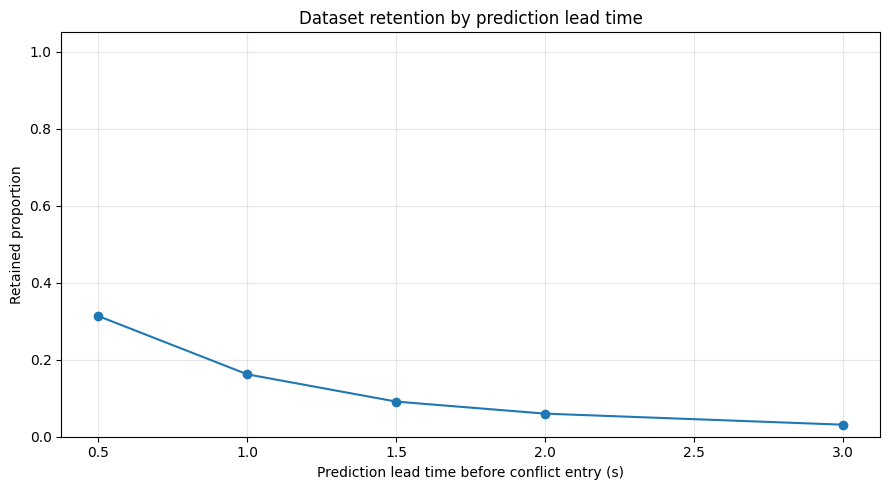

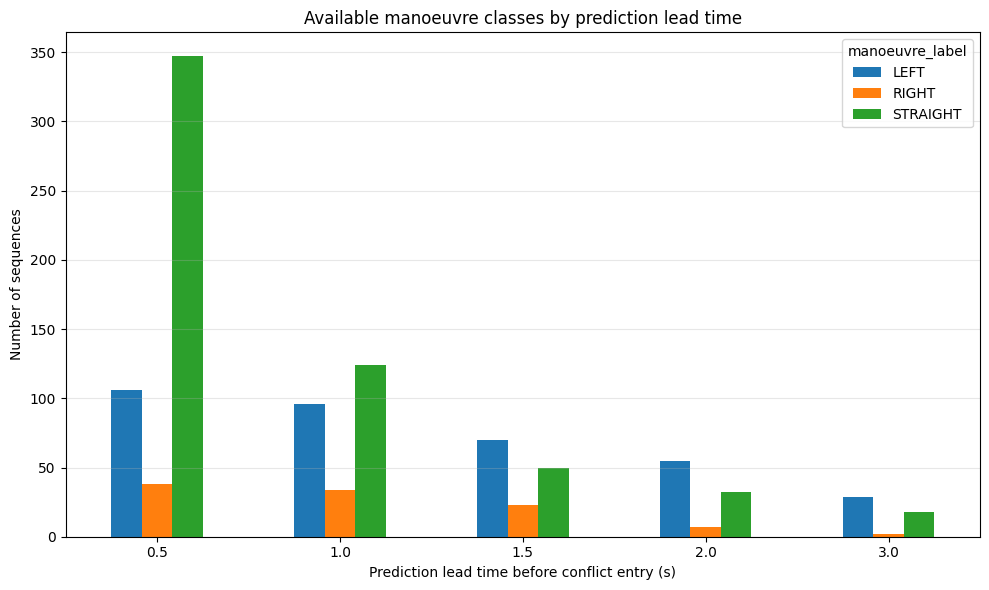


UPDATED CELL 14 COMPLETED
Separate datasets were created for the following prediction lead times:
  0.5 seconds: X=(491, 50, 17), y=(491,)
  1.0 seconds: X=(254, 50, 17), y=(254,)
  1.5 seconds: X=(143, 50, 17), y=(143,)
  2.0 seconds: X=(94, 50, 17), y=(94,)
  3.0 seconds: X=(49, 50, 17), y=(49,)

Model features:
  00: time_relative_to_prediction_seconds
  01: x_relative_to_intersection_m
  02: y_relative_to_intersection_m
  03: distance_to_intersection_center_m
  04: distance_to_conflict_region_m
  05: x_velocity_mps
  06: y_velocity_mps
  07: speed_mps
  08: x_acceleration_mps2
  09: y_acceleration_mps2
  10: acceleration_magnitude_mps2
  11: longitudinal_velocity_mps
  12: lateral_velocity_mps
  13: longitudinal_acceleration_mps2
  14: lateral_acceleration_mps2
  15: heading_sin
  16: heading_cos

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment

Important:
  - Do not run the old Cells 14B, 15, 16, 17 or 18.
  - Those cells w

In [ ]:
# Cell 14 — Build pre-intersection datasets at multiple prediction lead times

# Purpose
# -------
# Build several intention-prediction datasets using:
#
#     history duration = 2.0 seconds
#
# but different prediction lead times:
#
#     0.5, 1.0, 1.5, 2.0 and 3.0 seconds before conflict entry
#
# Example for a 2-second lead time:
#
#     observation history         prediction       conflict entry
#     <------ 2 seconds ------>         |                  |
#     ------------------------------->  |  2 seconds gap   |
#
# Important:
# - No frame at or after conflict entry is used.
# - No frame after the prediction moment is used.
# - Exit arm, exit heading and turn angle are not model features.
# - The actual conflict-entry frame is used only offline to locate the
#   prediction moment. It is not included in the model input.

from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from shapely.geometry import Point


# ============================================================
# 1. CHECK REQUIRED OUTPUTS FROM CELL 13
# ============================================================

required_variables = [
    "COMPLETE_LABELLED_MANOEUVRE_DATASET",
    "BATCH_RECORDING_RESULTS",
    "NORMAL_CONFLICT_GEOMETRY",
    "CONSTRUCTION_CONFLICT_GEOMETRY",
    "NORMAL_INTERSECTION_CENTER",
    "CONSTRUCTION_INTERSECTION_CENTER",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cell 13 before this updated Cell 14.\n"
        f"Missing variables: {missing_variables}"
    )

if COMPLETE_LABELLED_MANOEUVRE_DATASET.empty:
    raise ValueError(
        "The complete labelled manoeuvre dataset is empty."
    )


# ============================================================
# 2. EXPERIMENT CONFIGURATION
# ============================================================

# The amount of past movement shown to the model.
HISTORY_SECONDS = 2.0

# How early before conflict-region entry the prediction is made.
PREDICTION_LEAD_TIMES_SECONDS = [
    0.5,
    1.0,
    1.5,
    2.0,
    3.0,
]

# A complete consecutive history is required in this first controlled
# experiment. Missing-history support will be added later using masks.
REQUIRE_COMPLETE_WINDOW = True

CLASS_TO_INDEX = {
    "LEFT": 0,
    "RIGHT": 1,
    "STRAIGHT": 2,
}

INDEX_TO_CLASS = {
    class_index: class_name
    for class_name, class_index in CLASS_TO_INDEX.items()
}

EXPECTED_CLASS_NAMES = [
    "LEFT",
    "RIGHT",
    "STRAIGHT",
]

# Save to the prepared-data folder in Google Drive when OUTPUT_DIR from
# Cell 2 is available. Otherwise, use the Colab runtime as a fallback.
if "OUTPUT_DIR" in globals():
    LEAD_TIME_OUTPUT_DIRECTORY = (
        Path(OUTPUT_DIR)
        / "lead_time_experiment"
    )
else:
    LEAD_TIME_OUTPUT_DIRECTORY = Path(
        "/content/ind_intention_lead_time_experiment"
    )

LEAD_TIME_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

print("Lead-time experiment configuration:")
print(f"  History duration: {HISTORY_SECONDS:.1f} seconds")
print(
    "  Prediction lead times:",
    PREDICTION_LEAD_TIMES_SECONDS,
)
print("  Output directory:", LEAD_TIME_OUTPUT_DIRECTORY)


# ============================================================
# 3. MAP-SPECIFIC CONFIGURATION
# ============================================================

def get_window_map_configuration(map_variant):
    """
    Return the conflict geometry and intersection centre for one map.
    """

    if map_variant == "normal":
        return {
            "conflict_geometry":
                NORMAL_CONFLICT_GEOMETRY,

            "intersection_center":
                np.asarray(
                    NORMAL_INTERSECTION_CENTER,
                    dtype=float,
                ),
        }

    if map_variant == "construction":
        return {
            "conflict_geometry":
                CONSTRUCTION_CONFLICT_GEOMETRY,

            "intersection_center":
                np.asarray(
                    CONSTRUCTION_INTERSECTION_CENTER,
                    dtype=float,
                ),
        }

    raise ValueError(
        f"Unknown map variant: {map_variant}"
    )


# ============================================================
# 4. COLUMN-DETECTION HELPERS
# ============================================================

def find_optional_column(
    dataframe,
    candidates,
):
    """
    Return the first available candidate column or None.
    """

    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    return None


def detect_window_columns(
    trajectory_dataframe,
    existing_config,
):
    """
    Detect the trajectory columns needed for feature construction.
    """

    return {
        "track_id":
            existing_config["track_id"],

        "frame":
            existing_config["frame"],

        "x":
            existing_config["x"],

        "y":
            existing_config["y"],

        "vx":
            existing_config["vx"],

        "vy":
            existing_config["vy"],

        "heading":
            find_optional_column(
                trajectory_dataframe,
                [
                    "heading",
                    "headingDegrees",
                    "heading_degrees",
                ],
            ),

        "x_acceleration":
            find_optional_column(
                trajectory_dataframe,
                [
                    "xAcceleration",
                    "x_acceleration",
                    "ax",
                ],
            ),

        "y_acceleration":
            find_optional_column(
                trajectory_dataframe,
                [
                    "yAcceleration",
                    "y_acceleration",
                    "ay",
                ],
            ),

        "longitudinal_velocity":
            find_optional_column(
                trajectory_dataframe,
                [
                    "lonVelocity",
                    "longitudinalVelocity",
                    "longitudinal_velocity",
                ],
            ),

        "lateral_velocity":
            find_optional_column(
                trajectory_dataframe,
                [
                    "latVelocity",
                    "lateralVelocity",
                    "lateral_velocity",
                ],
            ),

        "longitudinal_acceleration":
            find_optional_column(
                trajectory_dataframe,
                [
                    "lonAcceleration",
                    "longitudinalAcceleration",
                    "longitudinal_acceleration",
                ],
            ),

        "lateral_acceleration":
            find_optional_column(
                trajectory_dataframe,
                [
                    "latAcceleration",
                    "lateralAcceleration",
                    "lateral_acceleration",
                ],
            ),

        "frame_rate":
            float(existing_config["frame_rate"]),
    }


# ============================================================
# 5. ANGLE HELPER
# ============================================================

def velocity_heading_degrees(
    velocity_x,
    velocity_y,
):
    """
    Calculate heading from the current velocity vector.
    """

    if (
        not np.isfinite(velocity_x)
        or not np.isfinite(velocity_y)
    ):
        return np.nan

    speed = np.hypot(
        velocity_x,
        velocity_y,
    )

    if speed <= 1e-9:
        return np.nan

    return float(
        np.degrees(
            np.arctan2(
                velocity_y,
                velocity_x,
            )
        )
    )


# ============================================================
# 6. CREATE FEATURES FOR ONE OBSERVATION
# ============================================================

def create_observation_feature_row(
    trajectory_row,
    column_config,
    conflict_geometry,
    intersection_center,
    prediction_frame,
    frame_rate,
    sequence_step,
):
    """
    Create model features for one frame.

    The time feature is relative to the prediction moment:

        negative value = earlier observation
        zero           = prediction moment

    The model is not told the future conflict-entry frame.
    """

    frame = int(
        trajectory_row[
            column_config["frame"]
        ]
    )

    x_position = float(
        trajectory_row[
            column_config["x"]
        ]
    )

    y_position = float(
        trajectory_row[
            column_config["y"]
        ]
    )

    velocity_x = float(
        trajectory_row[
            column_config["vx"]
        ]
    )

    velocity_y = float(
        trajectory_row[
            column_config["vy"]
        ]
    )

    speed = float(
        np.hypot(
            velocity_x,
            velocity_y,
        )
    )

    current_point = Point(
        x_position,
        y_position,
    )

    distance_to_conflict_region = float(
        current_point.distance(
            conflict_geometry
        )
    )

    relative_position = (
        np.asarray(
            [
                x_position,
                y_position,
            ],
            dtype=float,
        )
        - intersection_center
    )

    distance_to_intersection_center = float(
        np.linalg.norm(
            relative_position
        )
    )

    radial_angle_degrees = float(
        np.degrees(
            np.arctan2(
                relative_position[1],
                relative_position[0],
            )
        )
    )

    # Time relative to the prediction moment—not time to future entry.
    time_relative_to_prediction_seconds = (
        frame - int(prediction_frame)
    ) / frame_rate

    heading_column = column_config[
        "heading"
    ]

    if heading_column is not None:
        heading_degrees = float(
            trajectory_row[
                heading_column
            ]
        )
    else:
        heading_degrees = (
            velocity_heading_degrees(
                velocity_x,
                velocity_y,
            )
        )

    if np.isfinite(heading_degrees):
        heading_radians = np.radians(
            heading_degrees
        )

        heading_sin = float(
            np.sin(
                heading_radians
            )
        )

        heading_cos = float(
            np.cos(
                heading_radians
            )
        )
    else:
        heading_sin = np.nan
        heading_cos = np.nan

    def optional_numeric_value(
        configuration_key,
    ):
        source_column = column_config[
            configuration_key
        ]

        if source_column is None:
            return np.nan

        return float(
            trajectory_row[
                source_column
            ]
        )

    x_acceleration = optional_numeric_value(
        "x_acceleration"
    )

    y_acceleration = optional_numeric_value(
        "y_acceleration"
    )

    longitudinal_velocity = optional_numeric_value(
        "longitudinal_velocity"
    )

    lateral_velocity = optional_numeric_value(
        "lateral_velocity"
    )

    longitudinal_acceleration = optional_numeric_value(
        "longitudinal_acceleration"
    )

    lateral_acceleration = optional_numeric_value(
        "lateral_acceleration"
    )

    if (
        np.isfinite(x_acceleration)
        and np.isfinite(y_acceleration)
    ):
        acceleration_magnitude = float(
            np.hypot(
                x_acceleration,
                y_acceleration,
            )
        )
    else:
        acceleration_magnitude = np.nan

    return {
        # Diagnostic columns—not all of these are model features.
        "sequence_step":
            int(sequence_step),

        "frame":
            frame,

        "time_relative_to_prediction_seconds":
            float(
                time_relative_to_prediction_seconds
            ),

        "x_position_m":
            x_position,

        "y_position_m":
            y_position,

        "radial_angle_degrees":
            radial_angle_degrees,

        "heading_degrees":
            heading_degrees,

        # Model features.
        "x_relative_to_intersection_m":
            float(
                relative_position[0]
            ),

        "y_relative_to_intersection_m":
            float(
                relative_position[1]
            ),

        "distance_to_intersection_center_m":
            distance_to_intersection_center,

        "distance_to_conflict_region_m":
            distance_to_conflict_region,

        "x_velocity_mps":
            velocity_x,

        "y_velocity_mps":
            velocity_y,

        "speed_mps":
            speed,

        "x_acceleration_mps2":
            x_acceleration,

        "y_acceleration_mps2":
            y_acceleration,

        "acceleration_magnitude_mps2":
            acceleration_magnitude,

        "longitudinal_velocity_mps":
            longitudinal_velocity,

        "lateral_velocity_mps":
            lateral_velocity,

        "longitudinal_acceleration_mps2":
            longitudinal_acceleration,

        "lateral_acceleration_mps2":
            lateral_acceleration,

        "heading_sin":
            heading_sin,

        "heading_cos":
            heading_cos,
    }


# ============================================================
# 7. MODEL FEATURE LIST
# ============================================================

# The first feature now describes time relative to the current prediction
# moment. It no longer depends on the future entry time.

SEQUENCE_FEATURE_COLUMNS = [
    "time_relative_to_prediction_seconds",

    "x_relative_to_intersection_m",
    "y_relative_to_intersection_m",

    "distance_to_intersection_center_m",
    "distance_to_conflict_region_m",

    "x_velocity_mps",
    "y_velocity_mps",
    "speed_mps",

    "x_acceleration_mps2",
    "y_acceleration_mps2",
    "acceleration_magnitude_mps2",

    "longitudinal_velocity_mps",
    "lateral_velocity_mps",

    "longitudinal_acceleration_mps2",
    "lateral_acceleration_mps2",

    "heading_sin",
    "heading_cos",
]

FORBIDDEN_MODEL_FEATURE_NAMES = {
    "manoeuvre_label",
    "class_index",
    "track_id",
    "passage_id",
    "recording_id",
    "first_inside_frame",
    "last_inside_frame",
    "exit_x",
    "exit_y",
    "exit_heading_degrees",
    "exit_physical_arm_id",
    "exit_arm_cyclic_index",
    "signed_turn_angle_degrees",
    "conflict_duration_seconds",
}

forbidden_features_present = sorted(
    set(
        SEQUENCE_FEATURE_COLUMNS
    ).intersection(
        FORBIDDEN_MODEL_FEATURE_NAMES
    )
)

if forbidden_features_present:
    raise RuntimeError(
        "Forbidden future or target features were found:\n"
        f"{forbidden_features_present}"
    )


# ============================================================
# 8. CONSTRUCT ONE WINDOW FOR ONE LEAD TIME
# ============================================================

def construct_one_lead_time_window(
    labelled_passage,
    batch_recording_result,
    requested_lead_time_seconds,
):
    """
    Construct one fixed two-second history ending before the requested
    conflict-entry lead time.
    """

    recording_id = int(
        labelled_passage[
            "recording_id"
        ]
    )

    track_id = labelled_passage[
        "track_id"
    ]

    passage_id = labelled_passage[
        "passage_id"
    ]

    map_variant = labelled_passage[
        "map_variant"
    ]

    manoeuvre_label = labelled_passage[
        "manoeuvre_label"
    ]

    first_inside_frame = int(
        labelled_passage[
            "first_inside_frame"
        ]
    )

    if manoeuvre_label not in CLASS_TO_INDEX:
        return {
            "accepted": False,
            "reason": "unknown_manoeuvre_label",
        }

    passage_extraction = batch_recording_result.get(
        "passage_extraction"
    )

    if passage_extraction is None:
        return {
            "accepted": False,
            "reason": "passage_extraction_not_found",
        }

    passage_track_information = (
        passage_extraction[
            "passage_tracks"
        ].get(
            passage_id
        )
    )

    if passage_track_information is None:
        return {
            "accepted": False,
            "reason": "passage_track_not_found",
        }

    full_track = (
        passage_track_information[
            "full_track"
        ]
        .copy()
    )

    column_config = detect_window_columns(
        trajectory_dataframe=full_track,
        existing_config=(
            batch_recording_result[
                "column_config"
            ]
        ),
    )

    frame_column = column_config[
        "frame"
    ]

    frame_rate = float(
        column_config["frame_rate"]
    )

    full_track = (
        full_track
        .sort_values(
            frame_column
        )
        .reset_index(drop=True)
    )

    required_observation_count = int(
        round(
            HISTORY_SECONDS
            * frame_rate
        )
    )

    if required_observation_count <= 1:
        return {
            "accepted": False,
            "reason": "invalid_history_length",
        }

    # Use ceil so that the actual lead time is never shorter than the
    # requested lead time.
    required_lead_frames = int(
        math.ceil(
            requested_lead_time_seconds
            * frame_rate
            - 1e-9
        )
    )

    required_lead_frames = max(
        1,
        required_lead_frames,
    )

    prediction_frame = (
        first_inside_frame
        - required_lead_frames
    )

    window_end_frame = prediction_frame

    window_start_frame = (
        window_end_frame
        - required_observation_count
        + 1
    )

    observation_window = full_track[
        (
            full_track[
                frame_column
            ].astype(int)
            >= window_start_frame
        )
        & (
            full_track[
                frame_column
            ].astype(int)
            <= window_end_frame
        )
    ].copy()

    if len(observation_window) == 0:
        return {
            "accepted": False,
            "reason": "no_observations_in_required_window",
            "required_observations":
                required_observation_count,
        }

    observation_window = (
        observation_window
        .sort_values(
            frame_column
        )
        .reset_index(drop=True)
    )

    available_observations = len(
        observation_window
    )

    if (
        REQUIRE_COMPLETE_WINDOW
        and available_observations
        != required_observation_count
    ):
        return {
            "accepted": False,
            "reason": "insufficient_pre_prediction_history",
            "available_observations":
                available_observations,
            "required_observations":
                required_observation_count,
            "window_start_frame":
                window_start_frame,
            "window_end_frame":
                window_end_frame,
        }

    observed_frames = (
        observation_window[
            frame_column
        ]
        .astype(int)
        .to_numpy()
    )

    expected_frames = np.arange(
        window_start_frame,
        window_end_frame + 1,
        dtype=int,
    )

    if not np.array_equal(
        observed_frames,
        expected_frames,
    ):
        return {
            "accepted": False,
            "reason": "non_consecutive_or_missing_frames",
            "first_observed_frame":
                int(observed_frames[0]),
            "last_observed_frame":
                int(observed_frames[-1]),
            "expected_start_frame":
                int(window_start_frame),
            "expected_end_frame":
                int(window_end_frame),
        }

    if observed_frames[-1] != prediction_frame:
        return {
            "accepted": False,
            "reason": "prediction_frame_not_observed",
        }

    if observed_frames[-1] >= first_inside_frame:
        return {
            "accepted": False,
            "reason": "entry_or_future_frame_detected",
        }

    map_configuration = (
        get_window_map_configuration(
            map_variant
        )
    )

    feature_rows = []

    for sequence_step, (
        _,
        trajectory_row,
    ) in enumerate(
        observation_window.iterrows()
    ):
        feature_row = (
            create_observation_feature_row(
                trajectory_row=
                    trajectory_row,

                column_config=
                    column_config,

                conflict_geometry=(
                    map_configuration[
                        "conflict_geometry"
                    ]
                ),

                intersection_center=(
                    map_configuration[
                        "intersection_center"
                    ]
                ),

                prediction_frame=
                    prediction_frame,

                frame_rate=
                    frame_rate,

                sequence_step=
                    sequence_step,
            )
        )

        feature_rows.append(
            feature_row
        )

    feature_table = pd.DataFrame(
        feature_rows
    )

    # --------------------------------------------------------
    # TEMPORAL-INTEGRITY CHECKS
    # --------------------------------------------------------

    if (
        feature_table[
            "frame"
        ] > prediction_frame
    ).any():
        return {
            "accepted": False,
            "reason": "post_prediction_frame_detected",
        }

    if (
        feature_table[
            "frame"
        ] >= first_inside_frame
    ).any():
        return {
            "accepted": False,
            "reason": "entry_or_future_frame_detected",
        }

    time_values = feature_table[
        "time_relative_to_prediction_seconds"
    ].to_numpy(
        dtype=float
    )

    if np.any(
        time_values > 1e-9
    ):
        return {
            "accepted": False,
            "reason": "positive_prediction_relative_time",
        }

    if not np.isclose(
        time_values[-1],
        0.0,
        atol=1e-9,
    ):
        return {
            "accepted": False,
            "reason": "window_does_not_end_at_prediction_time",
        }

    missing_feature_columns = [
        feature_name
        for feature_name
        in SEQUENCE_FEATURE_COLUMNS
        if feature_table[
            feature_name
        ].isna().any()
    ]

    if missing_feature_columns:
        return {
            "accepted": False,
            "reason": "missing_feature_values",
            "missing_feature_columns":
                "; ".join(
                    missing_feature_columns
                ),
        }

    sequence_matrix = (
        feature_table[
            SEQUENCE_FEATURE_COLUMNS
        ]
        .to_numpy(
            dtype=np.float32
        )
    )

    if not np.isfinite(
        sequence_matrix
    ).all():
        return {
            "accepted": False,
            "reason": "non_finite_model_features",
        }

    actual_lead_time_seconds = (
        first_inside_frame
        - prediction_frame
    ) / frame_rate

    metadata = {
        "recording_id":
            recording_id,

        "map_variant":
            map_variant,

        "passage_id":
            passage_id,

        "track_id":
            track_id,

        "manoeuvre_label":
            manoeuvre_label,

        "class_index":
            CLASS_TO_INDEX[
                manoeuvre_label
            ],

        # Metadata only—not a model feature.
        "entry_physical_arm_id":
            labelled_passage.get(
                "entry_physical_arm_id"
            ),

        "first_inside_frame":
            first_inside_frame,

        "prediction_frame":
            int(
                prediction_frame
            ),

        "window_start_frame":
            int(
                window_start_frame
            ),

        "window_end_frame":
            int(
                window_end_frame
            ),

        "requested_lead_time_seconds":
            float(
                requested_lead_time_seconds
            ),

        "actual_lead_time_seconds":
            float(
                actual_lead_time_seconds
            ),

        "history_seconds":
            float(
                HISTORY_SECONDS
            ),

        "frame_rate_hz":
            float(
                frame_rate
            ),

        "sequence_length":
            int(
                required_observation_count
            ),

        "window_start_time_before_prediction_s":
            float(
                time_values[0]
            ),

        "window_end_time_before_prediction_s":
            float(
                time_values[-1]
            ),

        "window_start_time_before_entry_s":
            float(
                (
                    window_start_frame
                    - first_inside_frame
                )
                / frame_rate
            ),

        "window_end_time_before_entry_s":
            float(
                (
                    window_end_frame
                    - first_inside_frame
                )
                / frame_rate
            ),
    }

    # Add identifiers and labels to the long table only.
    # They are not part of sequence_matrix.
    feature_table.insert(
        0,
        "recording_id",
        recording_id,
    )

    feature_table.insert(
        1,
        "map_variant",
        map_variant,
    )

    feature_table.insert(
        2,
        "passage_id",
        passage_id,
    )

    feature_table.insert(
        3,
        "track_id",
        track_id,
    )

    feature_table.insert(
        4,
        "requested_lead_time_seconds",
        float(
            requested_lead_time_seconds
        ),
    )

    feature_table[
        "manoeuvre_label"
    ] = manoeuvre_label

    feature_table[
        "class_index"
    ] = CLASS_TO_INDEX[
        manoeuvre_label
    ]

    return {
        "accepted": True,
        "feature_table":
            feature_table,
        "sequence_matrix":
            sequence_matrix,
        "metadata":
            metadata,
    }


# ============================================================
# 9. PROCESS ALL LEAD TIMES
# ============================================================

labelled_dataset = (
    COMPLETE_LABELLED_MANOEUVRE_DATASET
    .sort_values(
        [
            "recording_id",
            "track_id",
        ]
    )
    .reset_index(drop=True)
)

LEAD_TIME_DATASETS = {}

dataset_summary_rows = []
class_distribution_rows = []
rejection_summary_tables = []
quality_check_rows = []

for lead_time_seconds in (
    PREDICTION_LEAD_TIMES_SECONDS
):

    print("\n" + "=" * 80)
    print(
        f"BUILDING DATASET FOR "
        f"{lead_time_seconds:.1f}-SECOND LEAD TIME"
    )
    print("=" * 80)

    accepted_feature_tables = []
    accepted_sequence_matrices = []
    accepted_metadata_rows = []
    rejected_rows = []

    for labelled_passage in (
        labelled_dataset.to_dict(
            orient="records"
        )
    ):
        recording_id = int(
            labelled_passage[
                "recording_id"
            ]
        )

        recording_result = (
            BATCH_RECORDING_RESULTS.get(
                recording_id
            )
        )

        base_rejection_information = {
            "recording_id":
                recording_id,

            "map_variant":
                labelled_passage.get(
                    "map_variant"
                ),

            "passage_id":
                labelled_passage.get(
                    "passage_id"
                ),

            "track_id":
                labelled_passage.get(
                    "track_id"
                ),

            "manoeuvre_label":
                labelled_passage.get(
                    "manoeuvre_label"
                ),

            "requested_lead_time_seconds":
                float(
                    lead_time_seconds
                ),
        }

        if recording_result is None:
            rejected_rows.append({
                **base_rejection_information,
                "rejection_reason":
                    "batch_recording_result_not_found",
            })

            continue

        try:
            window_result = (
                construct_one_lead_time_window(
                    labelled_passage=
                        labelled_passage,

                    batch_recording_result=
                        recording_result,

                    requested_lead_time_seconds=
                        lead_time_seconds,
                )
            )

        except Exception as error:
            rejected_rows.append({
                **base_rejection_information,
                "rejection_reason":
                    "window_construction_exception",
                "error_message":
                    str(error),
            })

            continue

        if not window_result.get(
            "accepted",
            False,
        ):
            rejection_row = {
                **base_rejection_information,

                "rejection_reason":
                    window_result.get(
                        "reason",
                        "unknown_rejection_reason",
                    ),
            }

            for key, value in (
                window_result.items()
            ):
                if key not in {
                    "accepted",
                    "reason",
                }:
                    rejection_row[key] = value

            rejected_rows.append(
                rejection_row
            )

            continue

        accepted_feature_tables.append(
            window_result[
                "feature_table"
            ]
        )

        accepted_sequence_matrices.append(
            window_result[
                "sequence_matrix"
            ]
        )

        accepted_metadata_rows.append(
            window_result[
                "metadata"
            ]
        )

    if accepted_sequence_matrices:
        X_lead_time = np.stack(
            accepted_sequence_matrices,
            axis=0,
        ).astype(
            np.float32
        )

        lead_time_long_table = pd.concat(
            accepted_feature_tables,
            ignore_index=True,
        )

        lead_time_metadata = pd.DataFrame(
            accepted_metadata_rows
        )

    else:
        # Keep an empty dataset instead of stopping the whole experiment.
        X_lead_time = np.empty(
            (
                0,
                0,
                len(
                    SEQUENCE_FEATURE_COLUMNS
                ),
            ),
            dtype=np.float32,
        )

        lead_time_long_table = pd.DataFrame()

        lead_time_metadata = pd.DataFrame()

    lead_time_rejections = pd.DataFrame(
        rejected_rows
    )

    if not lead_time_metadata.empty:
        y_lead_time = (
            lead_time_metadata[
                "class_index"
            ]
            .to_numpy(
                dtype=np.int64
            )
        )

        recording_groups = (
            lead_time_metadata[
                "recording_id"
            ]
            .to_numpy(
                dtype=np.int64
            )
        )

        track_ids = (
            lead_time_metadata[
                "track_id"
            ]
            .to_numpy()
        )

        passage_ids = (
            lead_time_metadata[
                "passage_id"
            ]
            .astype(str)
            .to_numpy()
        )

    else:
        y_lead_time = np.empty(
            0,
            dtype=np.int64,
        )

        recording_groups = np.empty(
            0,
            dtype=np.int64,
        )

        track_ids = np.empty(
            0,
            dtype=object,
        )

        passage_ids = np.empty(
            0,
            dtype=object,
        )

    accepted_count = len(
        y_lead_time
    )

    rejected_count = len(
        lead_time_rejections
    )

    input_count = len(
        labelled_dataset
    )

    retention_proportion = (
        accepted_count / input_count
        if input_count > 0
        else np.nan
    )

    class_counts = {
        class_name: int(
            (
                lead_time_metadata[
                    "manoeuvre_label"
                ] == class_name
            ).sum()
        )
        if not lead_time_metadata.empty
        else 0
        for class_name in EXPECTED_CLASS_NAMES
    }

    represented_recordings = (
        int(
            lead_time_metadata[
                "recording_id"
            ].nunique()
        )
        if not lead_time_metadata.empty
        else 0
    )

    sequence_length = (
        int(
            X_lead_time.shape[1]
        )
        if accepted_count > 0
        else 0
    )

    # --------------------------------------------------------
    # DATASET-INTEGRITY CHECKS
    # --------------------------------------------------------

    if accepted_count > 0:
        duplicate_recording_track_pairs = int(
            lead_time_metadata.duplicated(
                subset=[
                    "recording_id",
                    "track_id",
                ]
            ).sum()
        )

        sequence_count_matches = bool(
            len(X_lead_time)
            == len(y_lead_time)
            == len(lead_time_metadata)
        )

        finite_features = bool(
            np.isfinite(
                X_lead_time
            ).all()
        )

        predictions_before_entry = bool(
            (
                lead_time_metadata[
                    "prediction_frame"
                ]
                < lead_time_metadata[
                    "first_inside_frame"
                ]
            ).all()
        )

        requested_lead_time_satisfied = bool(
            (
                lead_time_metadata[
                    "actual_lead_time_seconds"
                ]
                + 1e-9
                >= lead_time_metadata[
                    "requested_lead_time_seconds"
                ]
            ).all()
        )

        windows_end_at_prediction_time = bool(
            np.isclose(
                lead_time_metadata[
                    "window_end_time_before_prediction_s"
                ].to_numpy(
                    dtype=float
                ),
                0.0,
                atol=1e-9,
            ).all()
        )

        complete_fixed_length = bool(
            lead_time_metadata[
                "sequence_length"
            ].nunique()
            == 1
            and sequence_length
            == int(
                lead_time_metadata[
                    "sequence_length"
                ].iloc[0]
            )
        )

        all_observations_not_after_prediction = bool(
            (
                lead_time_long_table[
                    "time_relative_to_prediction_seconds"
                ]
                <= 1e-9
            ).all()
        )

    else:
        duplicate_recording_track_pairs = 0
        sequence_count_matches = False
        finite_features = False
        predictions_before_entry = False
        requested_lead_time_satisfied = False
        windows_end_at_prediction_time = False
        complete_fixed_length = False
        all_observations_not_after_prediction = False

    lead_quality_checks = [
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "At least one sequence was created",
            "passed":
                accepted_count > 0,
            "details":
                f"{accepted_count} accepted sequences",
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "Sequence, label and metadata counts match",
            "passed":
                sequence_count_matches,
            "details":
                (
                    f"X={len(X_lead_time)}, "
                    f"y={len(y_lead_time)}, "
                    f"metadata={len(lead_time_metadata)}"
                ),
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "No duplicate recording-track pairs",
            "passed":
                duplicate_recording_track_pairs == 0,
            "details":
                str(
                    duplicate_recording_track_pairs
                ),
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "All model features are finite",
            "passed":
                finite_features,
            "details":
                (
                    "No NaN or infinite values"
                    if finite_features
                    else "Invalid or empty feature array"
                ),
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "Every prediction occurs before conflict entry",
            "passed":
                predictions_before_entry,
            "details":
                "prediction_frame < first_inside_frame",
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "Requested prediction lead time is satisfied",
            "passed":
                requested_lead_time_satisfied,
            "details":
                (
                    "actual_lead_time >= "
                    "requested_lead_time"
                ),
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "Every sequence ends at its prediction moment",
            "passed":
                windows_end_at_prediction_time,
            "details":
                (
                    "window_end_time_before_prediction_s "
                    "= 0"
                ),
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "No observations occur after prediction",
            "passed":
                all_observations_not_after_prediction,
            "details":
                (
                    "time_relative_to_prediction_seconds "
                    "<= 0"
                ),
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "Every accepted sequence has fixed length",
            "passed":
                complete_fixed_length,
            "details":
                f"{sequence_length} observations",
        },
        {
            "lead_time_seconds":
                lead_time_seconds,
            "check":
                "No future or target fields are model features",
            "passed":
                len(
                    forbidden_features_present
                ) == 0,
            "details":
                str(
                    forbidden_features_present
                ),
        },
    ]

    quality_check_rows.extend(
        lead_quality_checks
    )

    integrity_check_names = {
        "Sequence, label and metadata counts match",
        "No duplicate recording-track pairs",
        "All model features are finite",
        "Every prediction occurs before conflict entry",
        "Requested prediction lead time is satisfied",
        "Every sequence ends at its prediction moment",
        "No observations occur after prediction",
        "Every accepted sequence has fixed length",
        "No future or target fields are model features",
    }

    failed_integrity_checks = [
        check
        for check in lead_quality_checks
        if (
            check["check"]
            in integrity_check_names
            and not check["passed"]
        )
    ]

    if (
        accepted_count > 0
        and failed_integrity_checks
    ):
        raise RuntimeError(
            "Lead-time dataset integrity checks failed:\n"
            f"{failed_integrity_checks}"
        )

    # --------------------------------------------------------
    # SUMMARY TABLES
    # --------------------------------------------------------

    dataset_summary_rows.append({
        "lead_time_seconds":
            float(
                lead_time_seconds
            ),

        "history_seconds":
            float(
                HISTORY_SECONDS
            ),

        "input_labelled_passages":
            input_count,

        "accepted_sequences":
            accepted_count,

        "rejected_sequences":
            rejected_count,

        "retention_proportion":
            retention_proportion,

        "sequence_length":
            sequence_length,

        "feature_count":
            len(
                SEQUENCE_FEATURE_COLUMNS
            ),

        "represented_recordings":
            represented_recordings,

        "left_sequences":
            class_counts["LEFT"],

        "right_sequences":
            class_counts["RIGHT"],

        "straight_sequences":
            class_counts["STRAIGHT"],

        "represented_class_count":
            int(
                sum(
                    count > 0
                    for count
                    in class_counts.values()
                )
            ),
    })

    for class_name in (
        EXPECTED_CLASS_NAMES
    ):
        class_count = class_counts[
            class_name
        ]

        class_distribution_rows.append({
            "lead_time_seconds":
                float(
                    lead_time_seconds
                ),

            "manoeuvre_label":
                class_name,

            "sequence_count":
                class_count,

            "class_proportion":
                (
                    class_count
                    / accepted_count
                    if accepted_count > 0
                    else np.nan
                ),
        })

    if not lead_time_rejections.empty:
        rejection_summary = (
            lead_time_rejections[
                "rejection_reason"
            ]
            .value_counts()
            .rename_axis(
                "rejection_reason"
            )
            .reset_index(
                name="rejection_count"
            )
        )

        rejection_summary.insert(
            0,
            "lead_time_seconds",
            float(
                lead_time_seconds
            ),
        )

        rejection_summary_tables.append(
            rejection_summary
        )

    # --------------------------------------------------------
    # STORE DATASET IN MEMORY
    # --------------------------------------------------------

    LEAD_TIME_DATASETS[
        float(
            lead_time_seconds
        )
    ] = {
        "X":
            X_lead_time,

        "y":
            y_lead_time,

        "recording_groups":
            recording_groups,

        "track_ids":
            track_ids,

        "passage_ids":
            passage_ids,

        "metadata":
            lead_time_metadata,

        "long_table":
            lead_time_long_table,

        "rejections":
            lead_time_rejections,

        "feature_names":
            list(
                SEQUENCE_FEATURE_COLUMNS
            ),

        "history_seconds":
            float(
                HISTORY_SECONDS
            ),

        "requested_lead_time_seconds":
            float(
                lead_time_seconds
            ),
    }

    # --------------------------------------------------------
    # EXPORT THIS LEAD-TIME DATASET
    # --------------------------------------------------------

    lead_time_tag = (
        f"{lead_time_seconds:.1f}"
        .replace(
            ".",
            "p",
        )
    )

    lead_output_directory = (
        LEAD_TIME_OUTPUT_DIRECTORY
        / f"lead_{lead_time_tag}s"
    )

    lead_output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    np.savez_compressed(
        lead_output_directory
        / "intention_dataset.npz",

        X=
            X_lead_time,

        y=
            y_lead_time,

        recording_groups=
            recording_groups,

        track_ids=
            track_ids,

        passage_ids=
            passage_ids,

        feature_names=
            np.asarray(
                SEQUENCE_FEATURE_COLUMNS
            ),

        history_seconds=
            np.asarray(
                HISTORY_SECONDS
            ),

        requested_lead_time_seconds=
            np.asarray(
                lead_time_seconds
            ),
    )

    lead_time_metadata.to_csv(
        lead_output_directory
        / "sequence_metadata.csv",
        index=False,
    )

    lead_time_rejections.to_csv(
        lead_output_directory
        / "rejected_windows.csv",
        index=False,
    )

    if not lead_time_long_table.empty:
        lead_time_long_table.to_csv(
            lead_output_directory
            / "observation_windows_long.csv",
            index=False,
        )

    lead_configuration = {
        "history_seconds":
            float(
                HISTORY_SECONDS
            ),

        "requested_lead_time_seconds":
            float(
                lead_time_seconds
            ),

        "accepted_sequence_count":
            int(
                accepted_count
            ),

        "rejected_sequence_count":
            int(
                rejected_count
            ),

        "feature_names":
            list(
                SEQUENCE_FEATURE_COLUMNS
            ),

        "class_to_index":
            CLASS_TO_INDEX,

        "temporal_definition": {
            "prediction_frame":
                (
                    "first_inside_frame minus the "
                    "requested lead-time frame count"
                ),

            "window_end":
                "prediction_frame",

            "window_start":
                (
                    "prediction_frame minus "
                    "sequence_length plus one"
                ),

            "time_feature":
                (
                    "time relative to the prediction "
                    "moment; final value is zero"
                ),
        },

        "leakage_controls": {
            "conflict_entry_frame_used_as_model_feature":
                False,

            "entry_or_post_entry_frames_included":
                False,

            "post_prediction_frames_included":
                False,

            "exit_information_used":
                False,

            "target_label_used_as_feature":
                False,

            "future_padding_used":
                False,
        },
    }

    with open(
        lead_output_directory
        / "dataset_configuration.json",
        "w",
        encoding="utf-8",
    ) as configuration_file:
        json.dump(
            lead_configuration,
            configuration_file,
            indent=2,
        )

    print(
        f"Accepted sequences: "
        f"{accepted_count}/{input_count} "
        f"({retention_proportion:.1%})"
    )

    print(
        "Class counts:",
        class_counts,
    )

    print(
        "Represented recordings:",
        represented_recordings,
    )


# ============================================================
# 10. COMBINE EXPERIMENT SUMMARIES
# ============================================================

LEAD_TIME_DATASET_SUMMARY = (
    pd.DataFrame(
        dataset_summary_rows
    )
    .sort_values(
        "lead_time_seconds"
    )
    .reset_index(drop=True)
)

LEAD_TIME_CLASS_DISTRIBUTION = (
    pd.DataFrame(
        class_distribution_rows
    )
    .sort_values(
        [
            "lead_time_seconds",
            "manoeuvre_label",
        ]
    )
    .reset_index(drop=True)
)

LEAD_TIME_REJECTION_SUMMARY = (
    pd.concat(
        rejection_summary_tables,
        ignore_index=True,
    )
    if rejection_summary_tables
    else pd.DataFrame(
        columns=[
            "lead_time_seconds",
            "rejection_reason",
            "rejection_count",
        ]
    )
)

LEAD_TIME_QUALITY_CHECKS = (
    pd.DataFrame(
        quality_check_rows
    )
    .sort_values(
        [
            "lead_time_seconds",
            "check",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("LEAD-TIME DATASET SUMMARY")
print("=" * 80)

display(
    LEAD_TIME_DATASET_SUMMARY
)

print("\n" + "=" * 80)
print("CLASS DISTRIBUTION BY LEAD TIME")
print("=" * 80)

display(
    LEAD_TIME_CLASS_DISTRIBUTION
)

print("\n" + "=" * 80)
print("REJECTION SUMMARY BY LEAD TIME")
print("=" * 80)

display(
    LEAD_TIME_REJECTION_SUMMARY
)

print("\n" + "=" * 80)
print("QUALITY CHECKS")
print("=" * 80)

display(
    LEAD_TIME_QUALITY_CHECKS
)


# ============================================================
# 12. PLOT RETENTION AGAINST LEAD TIME
# ============================================================

figure, axis = plt.subplots(
    figsize=(9, 5)
)

axis.plot(
    LEAD_TIME_DATASET_SUMMARY[
        "lead_time_seconds"
    ],
    LEAD_TIME_DATASET_SUMMARY[
        "retention_proportion"
    ],
    marker="o",
)

axis.set_title(
    "Dataset retention by prediction lead time"
)

axis.set_xlabel(
    "Prediction lead time before conflict entry (s)"
)

axis.set_ylabel(
    "Retained proportion"
)

axis.set_ylim(
    0.0,
    1.05,
)

axis.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. PLOT CLASS COUNTS AGAINST LEAD TIME
# ============================================================

class_count_pivot = (
    LEAD_TIME_CLASS_DISTRIBUTION
    .pivot(
        index="lead_time_seconds",
        columns="manoeuvre_label",
        values="sequence_count",
    )
    .fillna(0)
)

class_count_pivot = (
    class_count_pivot.reindex(
        columns=EXPECTED_CLASS_NAMES,
        fill_value=0,
    )
)

figure, axis = plt.subplots(
    figsize=(10, 6)
)

class_count_pivot.plot(
    kind="bar",
    ax=axis,
)

axis.set_title(
    "Available manoeuvre classes by prediction lead time"
)

axis.set_xlabel(
    "Prediction lead time before conflict entry (s)"
)

axis.set_ylabel(
    "Number of sequences"
)

axis.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. EXPORT COMBINED SUMMARIES
# ============================================================

LEAD_TIME_DATASET_SUMMARY.to_csv(
    LEAD_TIME_OUTPUT_DIRECTORY
    / "lead_time_dataset_summary.csv",
    index=False,
)

LEAD_TIME_CLASS_DISTRIBUTION.to_csv(
    LEAD_TIME_OUTPUT_DIRECTORY
    / "lead_time_class_distribution.csv",
    index=False,
)

LEAD_TIME_REJECTION_SUMMARY.to_csv(
    LEAD_TIME_OUTPUT_DIRECTORY
    / "lead_time_rejection_summary.csv",
    index=False,
)

LEAD_TIME_QUALITY_CHECKS.to_csv(
    LEAD_TIME_OUTPUT_DIRECTORY
    / "lead_time_quality_checks.csv",
    index=False,
)

experiment_configuration = {
    "history_seconds":
        HISTORY_SECONDS,

    "prediction_lead_times_seconds":
        PREDICTION_LEAD_TIMES_SECONDS,

    "feature_names":
        SEQUENCE_FEATURE_COLUMNS,

    "class_to_index":
        CLASS_TO_INDEX,

    "dataset_policy": (
        "A separate dataset is created for each prediction lead "
        "time. Lead time must be treated as an experimental "
        "condition, not selected using the final test performance."
    ),
}

with open(
    LEAD_TIME_OUTPUT_DIRECTORY
    / "lead_time_experiment_configuration.json",
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        experiment_configuration,
        configuration_file,
        indent=2,
    )


# ============================================================
# 15. STANDARD VARIABLES FOR THE NEXT UPDATED CELL
# ============================================================

FINAL_LEAD_TIME_DATASETS = (
    LEAD_TIME_DATASETS
)

FINAL_LEAD_TIME_DATASET_SUMMARY = (
    LEAD_TIME_DATASET_SUMMARY
)

FINAL_LEAD_TIME_CLASS_DISTRIBUTION = (
    LEAD_TIME_CLASS_DISTRIBUTION
)

FINAL_LEAD_TIME_FEATURE_NAMES = list(
    SEQUENCE_FEATURE_COLUMNS
)


# ============================================================
# 16. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("UPDATED CELL 14 COMPLETED")
print("=" * 80)

print(
    "Separate datasets were created for the following "
    "prediction lead times:"
)

for lead_time_seconds in (
    PREDICTION_LEAD_TIMES_SECONDS
):
    dataset = LEAD_TIME_DATASETS[
        float(
            lead_time_seconds
        )
    ]

    print(
        f"  {lead_time_seconds:.1f} seconds: "
        f"X={dataset['X'].shape}, "
        f"y={dataset['y'].shape}"
    )

print("\nModel features:")

for feature_index, feature_name in enumerate(
    SEQUENCE_FEATURE_COLUMNS
):
    print(
        f"  {feature_index:02d}: "
        f"{feature_name}"
    )

print("\nOutput directory:")
print(" ", LEAD_TIME_OUTPUT_DIRECTORY)

print("\nImportant:")
print(
    "  - Do not run the old Cells 14B, 15, 16, 17 or 18."
)
print(
    "  - Those cells were designed for one near-entry dataset."
)
print(
    "  - The next updated cell must create recording-grouped "
    "evaluation for every lead time."
)
print(
    "  - Do not select the best lead time using test accuracy."
)

In [ ]:
# Cell 15 — Prepare a fair common cohort for lead-time comparison

# Purpose
# -------
# The number and type of vehicles change as the prediction lead time
# increases. A fair comparison should use the same vehicles at every
# lead time being compared.
#
# Primary comparison:
#     0.5 seconds before conflict entry
#     1.0 seconds before conflict entry
#
# Exploratory only:
#     1.5 seconds
#
# Dataset-availability results only:
#     2.0 and 3.0 seconds

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CHECK REQUIRED OUTPUTS
# ============================================================

required_variables = [
    "FINAL_LEAD_TIME_DATASETS",
    "FINAL_LEAD_TIME_DATASET_SUMMARY",
    "FINAL_LEAD_TIME_FEATURE_NAMES",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the updated Cell 14 first.\n"
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. DEFINE HOW EACH LEAD TIME WILL BE USED
# ============================================================

PRIMARY_COMPARISON_LEAD_TIMES = [
    0.5,
    1.0,
]

EXPLORATORY_LEAD_TIMES = [
    1.5,
]

AVAILABILITY_ONLY_LEAD_TIMES = [
    2.0,
    3.0,
]

expected_lead_times = (
    PRIMARY_COMPARISON_LEAD_TIMES
    + EXPLORATORY_LEAD_TIMES
    + AVAILABILITY_ONLY_LEAD_TIMES
)

missing_lead_times = [
    lead_time
    for lead_time in expected_lead_times
    if float(lead_time)
    not in FINAL_LEAD_TIME_DATASETS
]

if missing_lead_times:
    raise KeyError(
        "The following lead-time datasets were not found:\n"
        f"{missing_lead_times}"
    )


# ============================================================
# 3. CREATE A UNIQUE VEHICLE-PASSAGE KEY
# ============================================================

def add_comparison_key(metadata):
    """
    Add a unique recording-passage identifier.

    Track IDs can repeat between recordings, so recording_id must
    be part of the key.
    """

    result = (
        metadata
        .copy()
        .reset_index(drop=True)
    )

    result["_source_index"] = np.arange(
        len(result),
        dtype=int,
    )

    result["comparison_key"] = (
        result["recording_id"]
        .astype(int)
        .astype(str)
        + "::"
        + result["passage_id"]
        .astype(str)
    )

    duplicate_count = int(
        result[
            "comparison_key"
        ].duplicated().sum()
    )

    if duplicate_count > 0:
        raise RuntimeError(
            f"Found {duplicate_count} duplicate comparison keys."
        )

    return result


# ============================================================
# 4. DISPLAY PER-RECORDING CLASS COUNTS FOR EVERY LEAD TIME
# ============================================================

per_recording_tables = []

for lead_time_seconds in sorted(
    FINAL_LEAD_TIME_DATASETS
):
    dataset = FINAL_LEAD_TIME_DATASETS[
        lead_time_seconds
    ]

    metadata = dataset[
        "metadata"
    ].copy()

    if metadata.empty:
        continue

    recording_class_counts = (
        metadata
        .groupby(
            [
                "recording_id",
                "map_variant",
                "manoeuvre_label",
            ]
        )
        .size()
        .unstack(
            fill_value=0
        )
        .reset_index()
    )

    for class_name in [
        "LEFT",
        "RIGHT",
        "STRAIGHT",
    ]:
        if class_name not in (
            recording_class_counts.columns
        ):
            recording_class_counts[
                class_name
            ] = 0

    recording_class_counts.insert(
        0,
        "lead_time_seconds",
        float(
            lead_time_seconds
        ),
    )

    per_recording_tables.append(
        recording_class_counts[
            [
                "lead_time_seconds",
                "recording_id",
                "map_variant",
                "LEFT",
                "RIGHT",
                "STRAIGHT",
            ]
        ]
    )

LEAD_TIME_RECORDING_CLASS_COUNTS = (
    pd.concat(
        per_recording_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "lead_time_seconds",
            "recording_id",
        ]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("CLASS COUNTS PER RECORDING AND LEAD TIME")
print("=" * 80)

display(
    LEAD_TIME_RECORDING_CLASS_COUNTS
)


# ============================================================
# 5. FIND VEHICLES AVAILABLE AT BOTH PRIMARY LEAD TIMES
# ============================================================

primary_key_sets = []

primary_metadata_with_keys = {}

for lead_time_seconds in (
    PRIMARY_COMPARISON_LEAD_TIMES
):
    dataset = FINAL_LEAD_TIME_DATASETS[
        float(
            lead_time_seconds
        )
    ]

    metadata = add_comparison_key(
        dataset[
            "metadata"
        ]
    )

    primary_metadata_with_keys[
        float(
            lead_time_seconds
        )
    ] = metadata

    primary_key_sets.append(
        set(
            metadata[
                "comparison_key"
            ].tolist()
        )
    )

PRIMARY_COMMON_COHORT_KEYS = set.intersection(
    *primary_key_sets
)

if not PRIMARY_COMMON_COHORT_KEYS:
    raise RuntimeError(
        "No common passages were found between the primary lead times."
    )

print("\nCommon primary cohort:")
print(
    f"  {len(PRIMARY_COMMON_COHORT_KEYS)} vehicles are available "
    "at both 0.5-second and 1.0-second lead times."
)


# ============================================================
# 6. BUILD MATCHED DATASETS
# ============================================================

PRIMARY_COMMON_COHORT_DATASETS = {}

reference_keys = None
reference_labels = None

for lead_time_seconds in (
    PRIMARY_COMPARISON_LEAD_TIMES
):
    lead_time_seconds = float(
        lead_time_seconds
    )

    original_dataset = (
        FINAL_LEAD_TIME_DATASETS[
            lead_time_seconds
        ]
    )

    metadata = (
        primary_metadata_with_keys[
            lead_time_seconds
        ]
    )

    selected_metadata = (
        metadata[
            metadata[
                "comparison_key"
            ].isin(
                PRIMARY_COMMON_COHORT_KEYS
            )
        ]
        .sort_values(
            "comparison_key"
        )
        .reset_index(drop=True)
    )

    source_indices = (
        selected_metadata[
            "_source_index"
        ]
        .to_numpy(
            dtype=int
        )
    )

    X_common = (
        original_dataset[
            "X"
        ][
            source_indices
        ]
        .copy()
    )

    y_common = (
        original_dataset[
            "y"
        ][
            source_indices
        ]
        .copy()
    )

    groups_common = (
        original_dataset[
            "recording_groups"
        ][
            source_indices
        ]
        .copy()
    )

    comparison_keys = (
        selected_metadata[
            "comparison_key"
        ]
        .astype(str)
        .to_numpy()
    )

    selected_metadata = (
        selected_metadata
        .drop(
            columns=[
                "_source_index",
            ]
        )
    )

    if reference_keys is None:
        reference_keys = (
            comparison_keys.copy()
        )

        reference_labels = (
            y_common.copy()
        )

    else:
        if not np.array_equal(
            reference_keys,
            comparison_keys,
        ):
            raise RuntimeError(
                "The common vehicles are not in identical order "
                "across lead times."
            )

        if not np.array_equal(
            reference_labels,
            y_common,
        ):
            raise RuntimeError(
                "Labels differ for the same vehicles across lead times."
            )

    if not (
        len(X_common)
        == len(y_common)
        == len(groups_common)
        == len(selected_metadata)
    ):
        raise RuntimeError(
            f"Common-cohort array counts do not match for "
            f"{lead_time_seconds:.1f} seconds."
        )

    if not np.isfinite(
        X_common
    ).all():
        raise RuntimeError(
            f"The {lead_time_seconds:.1f}-second common dataset "
            "contains invalid feature values."
        )

    PRIMARY_COMMON_COHORT_DATASETS[
        lead_time_seconds
    ] = {
        "X":
            X_common,

        "y":
            y_common,

        "recording_groups":
            groups_common,

        "metadata":
            selected_metadata,

        "comparison_keys":
            comparison_keys,

        "feature_names":
            list(
                FINAL_LEAD_TIME_FEATURE_NAMES
            ),

        "lead_time_seconds":
            lead_time_seconds,

        "history_seconds":
            float(
                HISTORY_SECONDS
            ),
    }


# ============================================================
# 7. SUMMARIZE THE COMMON COHORT
# ============================================================

common_summary_rows = []

for lead_time_seconds in (
    PRIMARY_COMPARISON_LEAD_TIMES
):
    lead_time_seconds = float(
        lead_time_seconds
    )

    dataset = (
        PRIMARY_COMMON_COHORT_DATASETS[
            lead_time_seconds
        ]
    )

    metadata = dataset[
        "metadata"
    ]

    class_counts = (
        metadata[
            "manoeuvre_label"
        ]
        .value_counts()
        .to_dict()
    )

    common_summary_rows.append({
        "lead_time_seconds":
            lead_time_seconds,

        "sequence_count":
            len(
                dataset[
                    "y"
                ]
            ),

        "sequence_length":
            dataset[
                "X"
            ].shape[1],

        "feature_count":
            dataset[
                "X"
            ].shape[2],

        "recording_count":
            metadata[
                "recording_id"
            ].nunique(),

        "left_count":
            int(
                class_counts.get(
                    "LEFT",
                    0,
                )
            ),

        "right_count":
            int(
                class_counts.get(
                    "RIGHT",
                    0,
                )
            ),

        "straight_count":
            int(
                class_counts.get(
                    "STRAIGHT",
                    0,
                )
            ),
    })

PRIMARY_COMMON_COHORT_SUMMARY = pd.DataFrame(
    common_summary_rows
)

print("\n" + "=" * 80)
print("PRIMARY COMMON-COHORT SUMMARY")
print("=" * 80)

display(
    PRIMARY_COMMON_COHORT_SUMMARY
)


# ============================================================
# 8. COMMON-COHORT COUNTS PER RECORDING
# ============================================================

reference_metadata = (
    PRIMARY_COMMON_COHORT_DATASETS[
        float(
            PRIMARY_COMPARISON_LEAD_TIMES[0]
        )
    ]["metadata"]
)

PRIMARY_COMMON_COHORT_RECORDING_COUNTS = (
    reference_metadata
    .groupby(
        [
            "recording_id",
            "map_variant",
            "manoeuvre_label",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

for class_name in [
    "LEFT",
    "RIGHT",
    "STRAIGHT",
]:
    if class_name not in (
        PRIMARY_COMMON_COHORT_RECORDING_COUNTS.columns
    ):
        PRIMARY_COMMON_COHORT_RECORDING_COUNTS[
            class_name
        ] = 0

PRIMARY_COMMON_COHORT_RECORDING_COUNTS = (
    PRIMARY_COMMON_COHORT_RECORDING_COUNTS[
        [
            "recording_id",
            "map_variant",
            "LEFT",
            "RIGHT",
            "STRAIGHT",
        ]
    ]
    .sort_values(
        "recording_id"
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("COMMON-COHORT CLASS COUNTS PER RECORDING")
print("=" * 80)

display(
    PRIMARY_COMMON_COHORT_RECORDING_COUNTS
)


# ============================================================
# 9. QUALITY CHECKS
# ============================================================

COMMON_COHORT_QUALITY_CHECKS = pd.DataFrame([
    {
        "check":
            "Common cohort is not empty",

        "passed":
            len(
                PRIMARY_COMMON_COHORT_KEYS
            ) > 0,

        "details":
            (
                f"{len(PRIMARY_COMMON_COHORT_KEYS)} "
                "common vehicles"
            ),
    },
    {
        "check":
            "All primary lead times use the same vehicles",

        "passed":
            all(
                np.array_equal(
                    reference_keys,
                    PRIMARY_COMMON_COHORT_DATASETS[
                        float(
                            lead_time_seconds
                        )
                    ][
                        "comparison_keys"
                    ],
                )
                for lead_time_seconds
                in PRIMARY_COMPARISON_LEAD_TIMES
            ),

        "details":
            "Identical ordered recording-passage keys",
    },
    {
        "check":
            "All primary lead times use the same labels",

        "passed":
            all(
                np.array_equal(
                    reference_labels,
                    PRIMARY_COMMON_COHORT_DATASETS[
                        float(
                            lead_time_seconds
                        )
                    ][
                        "y"
                    ],
                )
                for lead_time_seconds
                in PRIMARY_COMPARISON_LEAD_TIMES
            ),

        "details":
            "Identical target labels",
    },
    {
        "check":
            "All three manoeuvre classes are represented",

        "passed":
            set(
                np.unique(
                    reference_labels
                ).tolist()
            )
            == set(
                CLASS_TO_INDEX.values()
            ),

        "details":
            str(
                sorted(
                    np.unique(
                        reference_labels
                    ).tolist()
                )
            ),
    },
    {
        "check":
            "All common feature arrays are finite",

        "passed":
            all(
                np.isfinite(
                    dataset[
                        "X"
                    ]
                ).all()
                for dataset
                in PRIMARY_COMMON_COHORT_DATASETS.values()
            ),

        "details":
            "No NaN or infinite values",
    },
])

print("\n" + "=" * 80)
print("COMMON-COHORT QUALITY CHECKS")
print("=" * 80)

display(
    COMMON_COHORT_QUALITY_CHECKS
)

if not COMMON_COHORT_QUALITY_CHECKS[
    "passed"
].all():
    raise RuntimeError(
        "One or more common-cohort quality checks failed."
    )


# ============================================================
# 10. EXPORT DIAGNOSTICS
# ============================================================

COMMON_COHORT_OUTPUT_DIRECTORY = (
    Path(
        LEAD_TIME_OUTPUT_DIRECTORY
    )
    / "primary_common_cohort"
)

COMMON_COHORT_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

LEAD_TIME_RECORDING_CLASS_COUNTS.to_csv(
    COMMON_COHORT_OUTPUT_DIRECTORY
    / "all_lead_time_recording_class_counts.csv",
    index=False,
)

PRIMARY_COMMON_COHORT_SUMMARY.to_csv(
    COMMON_COHORT_OUTPUT_DIRECTORY
    / "primary_common_cohort_summary.csv",
    index=False,
)

PRIMARY_COMMON_COHORT_RECORDING_COUNTS.to_csv(
    COMMON_COHORT_OUTPUT_DIRECTORY
    / "primary_common_cohort_recording_counts.csv",
    index=False,
)

COMMON_COHORT_QUALITY_CHECKS.to_csv(
    COMMON_COHORT_OUTPUT_DIRECTORY
    / "primary_common_cohort_quality_checks.csv",
    index=False,
)

for lead_time_seconds, dataset in (
    PRIMARY_COMMON_COHORT_DATASETS.items()
):
    lead_tag = (
        f"{lead_time_seconds:.1f}"
        .replace(
            ".",
            "p",
        )
    )

    np.savez_compressed(
        COMMON_COHORT_OUTPUT_DIRECTORY
        / f"common_cohort_lead_{lead_tag}s.npz",

        X=
            dataset[
                "X"
            ],

        y=
            dataset[
                "y"
            ],

        recording_groups=
            dataset[
                "recording_groups"
            ],

        comparison_keys=
            dataset[
                "comparison_keys"
            ],

        feature_names=
            np.asarray(
                dataset[
                    "feature_names"
                ]
            ),
    )

    dataset[
        "metadata"
    ].to_csv(
        COMMON_COHORT_OUTPUT_DIRECTORY
        / f"common_cohort_metadata_lead_{lead_tag}s.csv",
        index=False,
    )


# ============================================================
# 11. STANDARD VARIABLES FOR THE NEXT CELL
# ============================================================

FINAL_PRIMARY_COMMON_COHORT_DATASETS = (
    PRIMARY_COMMON_COHORT_DATASETS
)

FINAL_PRIMARY_COMMON_COHORT_SUMMARY = (
    PRIMARY_COMMON_COHORT_SUMMARY
)

FINAL_PRIMARY_COMMON_COHORT_RECORDING_COUNTS = (
    PRIMARY_COMMON_COHORT_RECORDING_COUNTS
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 15 COMPLETED")
print("=" * 80)

print(
    "A fair common cohort was created for lead times:",
    PRIMARY_COMPARISON_LEAD_TIMES,
)

print(
    "Common vehicle count:",
    len(
        PRIMARY_COMMON_COHORT_KEYS
    ),
)

print("\nExploratory lead time:")
print(" ", EXPLORATORY_LEAD_TIMES)

print("\nAvailability-only lead times:")
print(" ", AVAILABILITY_ONLY_LEAD_TIMES)

print("\nOutput directory:")
print(" ", COMMON_COHORT_OUTPUT_DIRECTORY)

print("\nNext step:")
print(
    "Use recording-grouped cross-validation to train majority-class "
    "and weighted logistic-regression baselines separately at the "
    "0.5-second and 1.0-second lead times."
)

print(
    "Do not train the GRU until those corrected baseline results "
    "have been examined."
)


CLASS COUNTS PER RECORDING AND LEAD TIME


manoeuvre_label,lead_time_seconds,recording_id,map_variant,LEFT,RIGHT,STRAIGHT
0,0.5,7,normal,0,3,12
1,0.5,8,normal,0,1,21
2,0.5,9,normal,0,0,9
3,0.5,10,normal,1,1,4
4,0.5,11,construction,4,4,36
5,0.5,12,construction,15,1,63
6,0.5,13,construction,19,3,34
7,0.5,14,construction,20,2,56
8,0.5,15,construction,17,5,21
9,0.5,16,construction,12,1,38



Common primary cohort:
  254 vehicles are available at both 0.5-second and 1.0-second lead times.

PRIMARY COMMON-COHORT SUMMARY


,lead_time_seconds,sequence_count,sequence_length,feature_count,recording_count,left_count,right_count,straight_count
0,0.5,254,50,17,11,96,34,124
1,1.0,254,50,17,11,96,34,124



COMMON-COHORT CLASS COUNTS PER RECORDING


manoeuvre_label,recording_id,map_variant,LEFT,RIGHT,STRAIGHT
0,7,normal,0,2,6
1,8,normal,0,1,7
2,9,normal,0,0,5
3,10,normal,1,1,1
4,11,construction,4,2,4
5,12,construction,15,1,34
6,13,construction,17,3,6
7,14,construction,19,2,14
8,15,construction,13,5,7
9,16,construction,11,1,14



COMMON-COHORT QUALITY CHECKS


,check,passed,details
0,Common cohort is not empty,True,254 common vehicles
1,All primary lead times use the same vehicles,True,Identical ordered recording-passage keys
2,All primary lead times use the same labels,True,Identical target labels
3,All three manoeuvre classes are represented,True,"[0, 1, 2]"
4,All common feature arrays are finite,True,No NaN or infinite values



CELL 15 COMPLETED
A fair common cohort was created for lead times: [0.5, 1.0]
Common vehicle count: 254

Exploratory lead time:
  [1.5]

Availability-only lead times:
  [2.0, 3.0]

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort

Next step:
Use recording-grouped cross-validation to train majority-class and weighted logistic-regression baselines separately at the 0.5-second and 1.0-second lead times.
Do not train the GRU until those corrected baseline results have been examined.



GROUPED CROSS-VALIDATION — 0.5-SECOND LEAD TIME
Completed 11 recording-grouped folds.

GROUPED CROSS-VALIDATION — 1.0-SECOND LEAD TIME
Completed 11 recording-grouped folds.

GROUPED OUT-OF-FOLD BASELINE METRICS


,model,lead_time_seconds,sequence_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss
0,majority_class,0.5,254,0.488189,0.333333,0.162730,0.333333,0.218695,0.320293,NaN
1,weighted_logistic_regression,0.5,254,0.952756,0.955922,0.956652,0.955922,0.956273,0.952729,0.169272
2,majority_class,1.0,254,0.488189,0.333333,0.162730,0.333333,0.218695,0.320293,NaN
3,weighted_logistic_regression,1.0,254,0.901575,0.887808,0.880673,0.887808,0.883757,0.901697,0.354083



GROUPED OUT-OF-FOLD PER-CLASS METRICS


,model,lead_time_seconds,class_index,manoeuvre_label,precision,recall,f1,support
0,majority_class,0.5,0,LEFT,0.000000,0.000000,0.000000,96
1,majority_class,0.5,1,RIGHT,0.000000,0.000000,0.000000,34
2,majority_class,0.5,2,STRAIGHT,0.488189,1.000000,0.656085,124
3,weighted_logistic_regression,0.5,0,LEFT,0.947368,0.937500,0.942408,96
4,weighted_logistic_regression,0.5,1,RIGHT,0.970588,0.970588,0.970588,34
5,weighted_logistic_regression,0.5,2,STRAIGHT,0.952000,0.959677,0.955823,124
6,majority_class,1.0,0,LEFT,0.000000,0.000000,0.000000,96
7,majority_class,1.0,1,RIGHT,0.000000,0.000000,0.000000,34
8,majority_class,1.0,2,STRAIGHT,0.488189,1.000000,0.656085,124
9,weighted_logistic_regression,1.0,0,LEFT,0.923077,0.875000,0.898396,96



PER-RECORDING FOLD DIAGNOSTICS


,lead_time_seconds,fold_number,held_out_recording,training_recording_count,training_sequence_count,test_sequence_count,train_left_count,train_right_count,train_straight_count,test_left_count,test_right_count,test_straight_count,left_class_weight,right_class_weight,straight_class_weight,majority_test_accuracy,logistic_test_accuracy
0,0.5,1,7,10,246,8,96,32,118,0,2,6,0.854167,2.562500,0.694915,0.750000,1.000000
1,0.5,2,8,10,246,8,96,33,117,0,1,7,0.854167,2.484848,0.700855,0.875000,1.000000
2,0.5,3,9,10,249,5,96,34,119,0,0,5,0.864583,2.441176,0.697479,1.000000,1.000000
3,0.5,4,10,10,251,3,95,33,123,1,1,1,0.880702,2.535354,0.680217,0.333333,0.666667
4,0.5,5,11,10,244,10,92,32,120,4,2,4,0.884058,2.541667,0.677778,0.400000,1.000000
5,0.5,6,12,10,204,50,81,33,90,15,1,34,0.839506,2.060606,0.755556,0.680000,0.900000
6,0.5,7,13,10,228,26,79,31,118,17,3,6,0.962025,2.451613,0.644068,0.230769,0.923077
7,0.5,8,14,10,219,35,77,32,110,19,2,14,0.948052,2.281250,0.663636,0.400000,1.000000
8,0.5,9,15,10,229,25,83,29,117,13,5,7,0.919679,2.632184,0.652422,0.280000,0.960000
9,0.5,10,16,10,228,26,85,33,110,11,1,14,0.894118,2.303030,0.690909,0.538462,1.000000



GROUPED-EVALUATION QUALITY CHECKS


,lead_time_seconds,check,passed,details
0,0.5,All eleven recordings were held out once,True,11 folds
1,0.5,Every vehicle received one out-of-fold prediction,True,254/254 vehicles
2,0.5,Logistic probabilities are finite,True,No NaN or infinite probabilities
3,0.5,Probability rows sum to one,True,Tolerance = 1e-6
4,1.0,All eleven recordings were held out once,True,11 folds
5,1.0,Every vehicle received one out-of-fold prediction,True,254/254 vehicles
6,1.0,Logistic probabilities are finite,True,No NaN or infinite probabilities
7,1.0,Probability rows sum to one,True,Tolerance = 1e-6


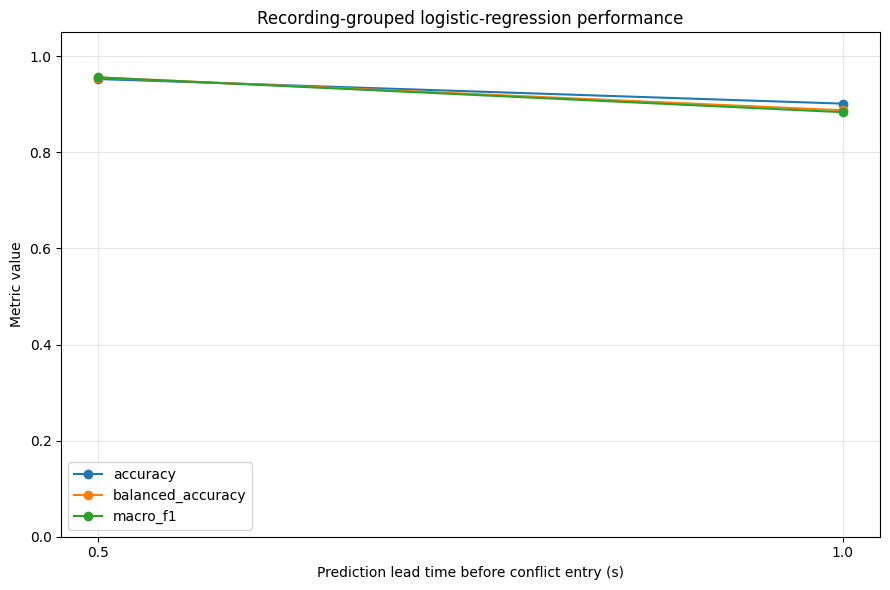

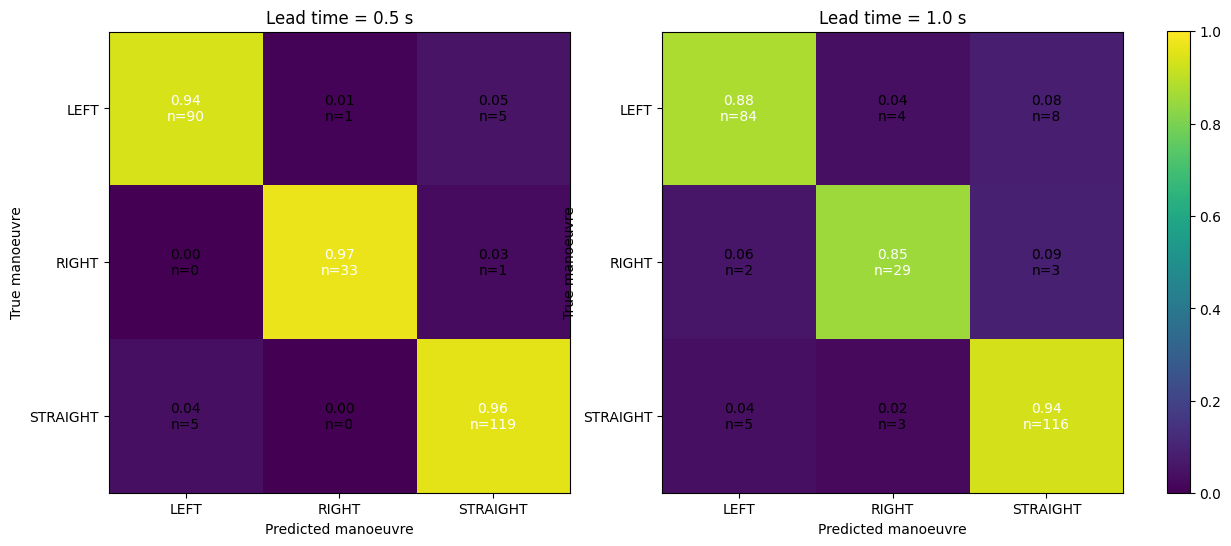


PAIRED VEHICLE-LEVEL LEAD-TIME COMPARISON


,comparison,vehicle_count
0,Correct at both lead times,229
1,Correct only at 0.5 seconds,13
2,Correct only at 1.0 seconds,0
3,Incorrect at both lead times,12



CELL 16 COMPLETED
Recording-grouped cross-validation was completed for:
  0.5 seconds
  1.0 seconds

Every recording was held out once, and every vehicle received exactly one out-of-fold prediction.

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/recording_grouped_baselines

Next step:
Inspect macro F1, balanced accuracy, LEFT recall, RIGHT recall and the confusion matrices.
Then run feature-ablation experiments to determine whether the model is learning genuine motion intention or mainly recognizing map position and approach lane.
Do not train the GRU until the feature-ablation results have been examined.


In [ ]:
# Cell 16 — Recording-grouped cross-validation baselines

# Purpose
# -------
# Compare intention prediction at:
#
#     0.5 seconds before conflict entry
#     1.0 seconds before conflict entry
#
# using exactly the same 254 vehicles.
#
# Leave-One-Recording-Out procedure:
#
#     1. Hold out one complete recording.
#     2. Fit the scaler using the remaining recordings only.
#     3. Calculate class weights from the remaining recordings only.
#     4. Train weighted logistic regression.
#     5. Predict the held-out recording.
#     6. Repeat until every recording has been held out once.
#
# The final metrics are calculated from all out-of-fold predictions.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    log_loss,
)


# ============================================================
# 1. CHECK REQUIRED OUTPUTS
# ============================================================

required_variables = [
    "FINAL_PRIMARY_COMMON_COHORT_DATASETS",
    "FINAL_PRIMARY_COMMON_COHORT_SUMMARY",
    "FINAL_LEAD_TIME_FEATURE_NAMES",
    "COMMON_COHORT_OUTPUT_DIRECTORY",
    "CLASS_TO_INDEX",
    "INDEX_TO_CLASS",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the updated Cells 14 and 15 first.\n"
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

EVALUATED_LEAD_TIMES = [
    0.5,
    1.0,
]

class_indices = sorted(
    int(class_index)
    for class_index in INDEX_TO_CLASS
)

class_names = [
    INDEX_TO_CLASS[
        class_index
    ]
    for class_index in class_indices
]

class_index_to_position = {
    class_index: position
    for position, class_index
    in enumerate(class_indices)
}

source_feature_names = list(
    FINAL_LEAD_TIME_FEATURE_NAMES
)

GROUPED_BASELINE_OUTPUT_DIRECTORY = (
    Path(
        COMMON_COHORT_OUTPUT_DIRECTORY
    )
    / "recording_grouped_baselines"
)

GROUPED_BASELINE_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 3. SEQUENCE-SUMMARY FEATURES
# ============================================================

# The logistic-regression baseline cannot directly process a
# three-dimensional sequence. Each feature is summarized using these
# eight statistics.

SUMMARY_STATISTICS = [
    "first",
    "last",
    "mean",
    "standard_deviation",
    "minimum",
    "maximum",
    "change",
    "slope",
]


def calculate_sequence_slopes(
    sequence_tensor,
):
    """
    Calculate one temporal slope for each feature in each sequence.
    """

    timestep_count = (
        sequence_tensor.shape[1]
    )

    time_values = np.arange(
        timestep_count,
        dtype=np.float64,
    )

    centered_time = (
        time_values
        - time_values.mean()
    )

    denominator = np.sum(
        centered_time ** 2
    )

    if denominator <= 0:
        raise ValueError(
            "At least two timesteps are required."
        )

    centered_sequences = (
        sequence_tensor.astype(
            np.float64
        )
        - sequence_tensor.mean(
            axis=1,
            keepdims=True,
            dtype=np.float64,
        )
    )

    slopes = np.sum(
        centered_sequences
        * centered_time.reshape(
            1,
            -1,
            1,
        ),
        axis=1,
    ) / denominator

    return slopes.astype(
        np.float32
    )


def create_sequence_summary_features(
    sequence_tensor,
    feature_names,
):
    """
    Convert sequences into fixed-size feature vectors.
    """

    first_values = (
        sequence_tensor[
            :,
            0,
            :,
        ]
    )

    last_values = (
        sequence_tensor[
            :,
            -1,
            :,
        ]
    )

    mean_values = (
        sequence_tensor.mean(
            axis=1
        )
    )

    standard_deviation_values = (
        sequence_tensor.std(
            axis=1
        )
    )

    minimum_values = (
        sequence_tensor.min(
            axis=1
        )
    )

    maximum_values = (
        sequence_tensor.max(
            axis=1
        )
    )

    change_values = (
        last_values
        - first_values
    )

    slope_values = (
        calculate_sequence_slopes(
            sequence_tensor
        )
    )

    summary_matrix = np.concatenate(
        [
            first_values,
            last_values,
            mean_values,
            standard_deviation_values,
            minimum_values,
            maximum_values,
            change_values,
            slope_values,
        ],
        axis=1,
    ).astype(
        np.float32
    )

    summary_feature_names = [
        f"{statistic_name}__{feature_name}"
        for statistic_name
        in SUMMARY_STATISTICS
        for feature_name
        in feature_names
    ]

    if summary_matrix.shape[1] != len(
        summary_feature_names
    ):
        raise RuntimeError(
            "Summary matrix and feature-name counts differ."
        )

    return (
        summary_matrix,
        summary_feature_names,
    )


# ============================================================
# 4. METRIC HELPERS
# ============================================================

def calculate_overall_metrics(
    model_name,
    lead_time_seconds,
    true_labels,
    predicted_labels,
    predicted_probabilities=None,
):
    """
    Calculate metrics from all out-of-fold predictions.
    """

    result = {
        "model":
            model_name,

        "lead_time_seconds":
            float(
                lead_time_seconds
            ),

        "sequence_count":
            len(
                true_labels
            ),

        "accuracy":
            float(
                accuracy_score(
                    true_labels,
                    predicted_labels,
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    true_labels,
                    predicted_labels,
                )
            ),

        "macro_precision":
            float(
                precision_score(
                    true_labels,
                    predicted_labels,
                    labels=class_indices,
                    average="macro",
                    zero_division=0,
                )
            ),

        "macro_recall":
            float(
                recall_score(
                    true_labels,
                    predicted_labels,
                    labels=class_indices,
                    average="macro",
                    zero_division=0,
                )
            ),

        "macro_f1":
            float(
                f1_score(
                    true_labels,
                    predicted_labels,
                    labels=class_indices,
                    average="macro",
                    zero_division=0,
                )
            ),

        "weighted_f1":
            float(
                f1_score(
                    true_labels,
                    predicted_labels,
                    labels=class_indices,
                    average="weighted",
                    zero_division=0,
                )
            ),
    }

    if predicted_probabilities is not None:
        result["log_loss"] = float(
            log_loss(
                true_labels,
                predicted_probabilities,
                labels=class_indices,
            )
        )
    else:
        result["log_loss"] = np.nan

    return result


def calculate_per_class_metrics(
    model_name,
    lead_time_seconds,
    true_labels,
    predicted_labels,
):
    """
    Calculate precision, recall and F1 separately for every class.
    """

    (
        precision_values,
        recall_values,
        f1_values,
        support_values,
    ) = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=class_indices,
        zero_division=0,
    )

    return pd.DataFrame([
        {
            "model":
                model_name,

            "lead_time_seconds":
                float(
                    lead_time_seconds
                ),

            "class_index":
                int(
                    class_index
                ),

            "manoeuvre_label":
                INDEX_TO_CLASS[
                    class_index
                ],

            "precision":
                float(
                    precision_values[
                        class_position
                    ]
                ),

            "recall":
                float(
                    recall_values[
                        class_position
                    ]
                ),

            "f1":
                float(
                    f1_values[
                        class_position
                    ]
                ),

            "support":
                int(
                    support_values[
                        class_position
                    ]
                ),
        }
        for class_position, class_index
        in enumerate(class_indices)
    ])


# ============================================================
# 5. RUN LEAVE-ONE-RECORDING-OUT CROSS-VALIDATION
# ============================================================

overall_metric_rows = []
per_class_metric_tables = []
fold_diagnostic_rows = []
quality_check_rows = []

GROUPED_OUT_OF_FOLD_RESULTS = {}

reference_comparison_keys = None
reference_true_labels = None

for lead_time_seconds in (
    EVALUATED_LEAD_TIMES
):
    lead_time_seconds = float(
        lead_time_seconds
    )

    print("\n" + "=" * 80)
    print(
        f"GROUPED CROSS-VALIDATION — "
        f"{lead_time_seconds:.1f}-SECOND LEAD TIME"
    )
    print("=" * 80)

    dataset = (
        FINAL_PRIMARY_COMMON_COHORT_DATASETS[
            lead_time_seconds
        ]
    )

    X_sequence = np.asarray(
        dataset[
            "X"
        ],
        dtype=np.float32,
    ).copy()

    y = np.asarray(
        dataset[
            "y"
        ],
        dtype=np.int64,
    ).copy()

    groups = np.asarray(
        dataset[
            "recording_groups"
        ],
        dtype=np.int64,
    ).copy()

    metadata = (
        dataset[
            "metadata"
        ]
        .copy()
        .reset_index(drop=True)
    )

    comparison_keys = np.asarray(
        dataset[
            "comparison_keys"
        ]
    ).astype(str)

    if not (
        len(X_sequence)
        == len(y)
        == len(groups)
        == len(metadata)
        == len(comparison_keys)
    ):
        raise RuntimeError(
            f"Input counts do not match for "
            f"{lead_time_seconds:.1f} seconds."
        )

    if not np.isfinite(
        X_sequence
    ).all():
        raise RuntimeError(
            "Sequence tensor contains invalid values."
        )

    if reference_comparison_keys is None:
        reference_comparison_keys = (
            comparison_keys.copy()
        )

        reference_true_labels = (
            y.copy()
        )

    else:
        if not np.array_equal(
            reference_comparison_keys,
            comparison_keys,
        ):
            raise RuntimeError(
                "Vehicle ordering differs between lead times."
            )

        if not np.array_equal(
            reference_true_labels,
            y,
        ):
            raise RuntimeError(
                "True labels differ between lead times."
            )

    sequence_count = len(
        y
    )

    class_count = len(
        class_indices
    )

    majority_oof_predictions = np.full(
        sequence_count,
        fill_value=-1,
        dtype=np.int64,
    )

    logistic_oof_predictions = np.full(
        sequence_count,
        fill_value=-1,
        dtype=np.int64,
    )

    logistic_oof_probabilities = np.full(
        (
            sequence_count,
            class_count,
        ),
        fill_value=np.nan,
        dtype=np.float64,
    )

    fold_assignments = np.full(
        sequence_count,
        fill_value=-1,
        dtype=np.int64,
    )

    logo = LeaveOneGroupOut()

    fold_number = 0
    summary_feature_names = None

    for train_indices, test_indices in logo.split(
        X_sequence,
        y,
        groups,
    ):
        fold_number += 1

        training_groups = sorted(
            np.unique(
                groups[
                    train_indices
                ]
            ).astype(int).tolist()
        )

        held_out_groups = sorted(
            np.unique(
                groups[
                    test_indices
                ]
            ).astype(int).tolist()
        )

        if len(
            held_out_groups
        ) != 1:
            raise RuntimeError(
                "LeaveOneGroupOut should hold out exactly one recording."
            )

        held_out_recording = int(
            held_out_groups[0]
        )

        if set(
            training_groups
        ).intersection(
            held_out_groups
        ):
            raise RuntimeError(
                "A recording appears in both training and test data."
            )

        X_train_raw = (
            X_sequence[
                train_indices
            ]
        )

        X_test_raw = (
            X_sequence[
                test_indices
            ]
        )

        y_train = (
            y[
                train_indices
            ]
        )

        y_test = (
            y[
                test_indices
            ]
        )

        training_classes = sorted(
            np.unique(
                y_train
            ).tolist()
        )

        if training_classes != class_indices:
            raise RuntimeError(
                f"Training fold for recording {held_out_recording} "
                f"does not contain all classes: {training_classes}"
            )

        # ----------------------------------------------------
        # FIT SCALER USING TRAINING RECORDINGS ONLY
        # ----------------------------------------------------

        feature_count = (
            X_train_raw.shape[2]
        )

        train_flat = (
            X_train_raw.reshape(
                -1,
                feature_count,
            )
        )

        test_flat = (
            X_test_raw.reshape(
                -1,
                feature_count,
            )
        )

        fold_scaler = StandardScaler()

        fold_scaler.fit(
            train_flat
        )

        X_train_scaled = (
            fold_scaler
            .transform(
                train_flat
            )
            .reshape(
                X_train_raw.shape
            )
            .astype(
                np.float32
            )
        )

        X_test_scaled = (
            fold_scaler
            .transform(
                test_flat
            )
            .reshape(
                X_test_raw.shape
            )
            .astype(
                np.float32
            )
        )

        # ----------------------------------------------------
        # CREATE SUMMARY FEATURES
        # ----------------------------------------------------

        (
            X_train_summary,
            current_summary_feature_names,
        ) = create_sequence_summary_features(
            X_train_scaled,
            source_feature_names,
        )

        (
            X_test_summary,
            test_summary_feature_names,
        ) = create_sequence_summary_features(
            X_test_scaled,
            source_feature_names,
        )

        if (
            current_summary_feature_names
            != test_summary_feature_names
        ):
            raise RuntimeError(
                "Training and test summary-feature orders differ."
            )

        if summary_feature_names is None:
            summary_feature_names = list(
                current_summary_feature_names
            )

        elif summary_feature_names != (
            current_summary_feature_names
        ):
            raise RuntimeError(
                "Summary-feature ordering differs between folds."
            )

        # ----------------------------------------------------
        # MAJORITY-CLASS BASELINE
        # ----------------------------------------------------

        training_class_counts = {
            class_index: int(
                np.sum(
                    y_train
                    == class_index
                )
            )
            for class_index in class_indices
        }

        majority_class_index = max(
            training_class_counts,
            key=training_class_counts.get,
        )

        majority_fold_predictions = np.full(
            len(
                test_indices
            ),
            fill_value=majority_class_index,
            dtype=np.int64,
        )

        majority_oof_predictions[
            test_indices
        ] = majority_fold_predictions

        # ----------------------------------------------------
        # TRAINING-FOLD CLASS WEIGHTS
        # ----------------------------------------------------

        class_weight_values = compute_class_weight(
            class_weight="balanced",
            classes=np.asarray(
                class_indices,
                dtype=np.int64,
            ),
            y=y_train,
        )

        fold_class_weights = {
            int(class_index):
                float(
                    class_weight
                )
            for class_index, class_weight
            in zip(
                class_indices,
                class_weight_values,
            )
        }

        # ----------------------------------------------------
        # WEIGHTED LOGISTIC REGRESSION
        # ----------------------------------------------------

        fold_model = LogisticRegression(
            class_weight=
                fold_class_weights,

            C=1.0,

            solver="lbfgs",

            max_iter=5000,

            random_state=42,
        )

        fold_model.fit(
            X_train_summary,
            y_train,
        )

        logistic_fold_predictions = (
            fold_model.predict(
                X_test_summary
            )
        )

        fold_probability_output = (
            fold_model.predict_proba(
                X_test_summary
            )
        )

        aligned_fold_probabilities = np.zeros(
            (
                len(
                    test_indices
                ),
                class_count,
            ),
            dtype=np.float64,
        )

        for model_class_position, (
            model_class_index
        ) in enumerate(
            fold_model.classes_
        ):
            output_position = (
                class_index_to_position[
                    int(
                        model_class_index
                    )
                ]
            )

            aligned_fold_probabilities[
                :,
                output_position,
            ] = (
                fold_probability_output[
                    :,
                    model_class_position,
                ]
            )

        logistic_oof_predictions[
            test_indices
        ] = logistic_fold_predictions

        logistic_oof_probabilities[
            test_indices
        ] = aligned_fold_probabilities

        fold_assignments[
            test_indices
        ] = fold_number

        # ----------------------------------------------------
        # FOLD DIAGNOSTICS
        # ----------------------------------------------------

        fold_diagnostic_rows.append({
            "lead_time_seconds":
                lead_time_seconds,

            "fold_number":
                fold_number,

            "held_out_recording":
                held_out_recording,

            "training_recording_count":
                len(
                    training_groups
                ),

            "training_sequence_count":
                len(
                    train_indices
                ),

            "test_sequence_count":
                len(
                    test_indices
                ),

            "train_left_count":
                training_class_counts[
                    CLASS_TO_INDEX[
                        "LEFT"
                    ]
                ],

            "train_right_count":
                training_class_counts[
                    CLASS_TO_INDEX[
                        "RIGHT"
                    ]
                ],

            "train_straight_count":
                training_class_counts[
                    CLASS_TO_INDEX[
                        "STRAIGHT"
                    ]
                ],

            "test_left_count":
                int(
                    np.sum(
                        y_test
                        == CLASS_TO_INDEX[
                            "LEFT"
                        ]
                    )
                ),

            "test_right_count":
                int(
                    np.sum(
                        y_test
                        == CLASS_TO_INDEX[
                            "RIGHT"
                        ]
                    )
                ),

            "test_straight_count":
                int(
                    np.sum(
                        y_test
                        == CLASS_TO_INDEX[
                            "STRAIGHT"
                        ]
                    )
                ),

            "left_class_weight":
                fold_class_weights[
                    CLASS_TO_INDEX[
                        "LEFT"
                    ]
                ],

            "right_class_weight":
                fold_class_weights[
                    CLASS_TO_INDEX[
                        "RIGHT"
                    ]
                ],

            "straight_class_weight":
                fold_class_weights[
                    CLASS_TO_INDEX[
                        "STRAIGHT"
                    ]
                ],

            # Accuracy is safe to show per recording.
            # Per-fold macro F1 is not reported because some held-out
            # recordings do not contain every class.
            "majority_test_accuracy":
                float(
                    accuracy_score(
                        y_test,
                        majority_fold_predictions,
                    )
                ),

            "logistic_test_accuracy":
                float(
                    accuracy_score(
                        y_test,
                        logistic_fold_predictions,
                    )
                ),
        })

    # --------------------------------------------------------
    # VERIFY COMPLETE OUT-OF-FOLD COVERAGE
    # --------------------------------------------------------

    predictions_complete = bool(
        np.all(
            majority_oof_predictions
            >= 0
        )
        and np.all(
            logistic_oof_predictions
            >= 0
        )
    )

    fold_coverage_complete = bool(
        np.all(
            fold_assignments
            >= 1
        )
    )

    probabilities_finite = bool(
        np.isfinite(
            logistic_oof_probabilities
        ).all()
    )

    probability_rows_sum_to_one = bool(
        np.allclose(
            logistic_oof_probabilities.sum(
                axis=1
            ),
            1.0,
            atol=1e-6,
        )
    )

    quality_check_rows.extend([
        {
            "lead_time_seconds":
                lead_time_seconds,

            "check":
                "Every vehicle received one out-of-fold prediction",

            "passed":
                predictions_complete
                and fold_coverage_complete,

            "details":
                (
                    f"{np.sum(fold_assignments >= 1)}/"
                    f"{sequence_count} vehicles"
                ),
        },
        {
            "lead_time_seconds":
                lead_time_seconds,

            "check":
                "Logistic probabilities are finite",

            "passed":
                probabilities_finite,

            "details":
                "No NaN or infinite probabilities",
        },
        {
            "lead_time_seconds":
                lead_time_seconds,

            "check":
                "Probability rows sum to one",

            "passed":
                probability_rows_sum_to_one,

            "details":
                "Tolerance = 1e-6",
        },
        {
            "lead_time_seconds":
                lead_time_seconds,

            "check":
                "All eleven recordings were held out once",

            "passed":
                len(
                    np.unique(
                        groups
                    )
                )
                == fold_number,

            "details":
                f"{fold_number} folds",
        },
    ])

    if not (
        predictions_complete
        and fold_coverage_complete
        and probabilities_finite
        and probability_rows_sum_to_one
    ):
        raise RuntimeError(
            f"Grouped evaluation failed for "
            f"{lead_time_seconds:.1f} seconds."
        )

    # --------------------------------------------------------
    # CALCULATE AGGREGATE METRICS
    # --------------------------------------------------------

    overall_metric_rows.append(
        calculate_overall_metrics(
            model_name=
                "majority_class",

            lead_time_seconds=
                lead_time_seconds,

            true_labels=
                y,

            predicted_labels=
                majority_oof_predictions,
        )
    )

    overall_metric_rows.append(
        calculate_overall_metrics(
            model_name=
                "weighted_logistic_regression",

            lead_time_seconds=
                lead_time_seconds,

            true_labels=
                y,

            predicted_labels=
                logistic_oof_predictions,

            predicted_probabilities=
                logistic_oof_probabilities,
        )
    )

    per_class_metric_tables.append(
        calculate_per_class_metrics(
            model_name=
                "majority_class",

            lead_time_seconds=
                lead_time_seconds,

            true_labels=
                y,

            predicted_labels=
                majority_oof_predictions,
        )
    )

    per_class_metric_tables.append(
        calculate_per_class_metrics(
            model_name=
                "weighted_logistic_regression",

            lead_time_seconds=
                lead_time_seconds,

            true_labels=
                y,

            predicted_labels=
                logistic_oof_predictions,
        )
    )

    logistic_confusion = confusion_matrix(
        y,
        logistic_oof_predictions,
        labels=class_indices,
    )

    majority_confusion = confusion_matrix(
        y,
        majority_oof_predictions,
        labels=class_indices,
    )

    output_metadata = (
        metadata.copy()
    )

    output_metadata[
        "fold_number"
    ] = fold_assignments

    output_metadata[
        "majority_prediction"
    ] = majority_oof_predictions

    output_metadata[
        "majority_prediction_name"
    ] = [
        INDEX_TO_CLASS[
            int(
                prediction
            )
        ]
        for prediction
        in majority_oof_predictions
    ]

    output_metadata[
        "logistic_prediction"
    ] = logistic_oof_predictions

    output_metadata[
        "logistic_prediction_name"
    ] = [
        INDEX_TO_CLASS[
            int(
                prediction
            )
        ]
        for prediction
        in logistic_oof_predictions
    ]

    for class_position, class_index in enumerate(
        class_indices
    ):
        class_name = INDEX_TO_CLASS[
            class_index
        ]

        output_metadata[
            f"probability_{class_name.lower()}"
        ] = (
            logistic_oof_probabilities[
                :,
                class_position,
            ]
        )

    GROUPED_OUT_OF_FOLD_RESULTS[
        lead_time_seconds
    ] = {
        "true_labels":
            y,

        "comparison_keys":
            comparison_keys,

        "recording_groups":
            groups,

        "fold_assignments":
            fold_assignments,

        "majority_predictions":
            majority_oof_predictions,

        "logistic_predictions":
            logistic_oof_predictions,

        "logistic_probabilities":
            logistic_oof_probabilities,

        "majority_confusion_matrix":
            majority_confusion,

        "logistic_confusion_matrix":
            logistic_confusion,

        "metadata_with_predictions":
            output_metadata,

        "summary_feature_names":
            list(
                summary_feature_names
            ),
    }

    lead_tag = (
        f"{lead_time_seconds:.1f}"
        .replace(
            ".",
            "p",
        )
    )

    output_metadata.to_csv(
        GROUPED_BASELINE_OUTPUT_DIRECTORY
        / f"oof_predictions_lead_{lead_tag}s.csv",
        index=False,
    )

    np.save(
        GROUPED_BASELINE_OUTPUT_DIRECTORY
        / f"logistic_confusion_lead_{lead_tag}s.npy",
        logistic_confusion,
    )

    print(
        f"Completed {fold_number} recording-grouped folds."
    )


# ============================================================
# 6. COMBINE METRICS
# ============================================================

GROUPED_BASELINE_METRICS = (
    pd.DataFrame(
        overall_metric_rows
    )
    .sort_values(
        [
            "lead_time_seconds",
            "model",
        ]
    )
    .reset_index(drop=True)
)

GROUPED_BASELINE_PER_CLASS_METRICS = (
    pd.concat(
        per_class_metric_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "lead_time_seconds",
            "model",
            "class_index",
        ]
    )
    .reset_index(drop=True)
)

GROUPED_BASELINE_FOLD_DIAGNOSTICS = (
    pd.DataFrame(
        fold_diagnostic_rows
    )
    .sort_values(
        [
            "lead_time_seconds",
            "held_out_recording",
        ]
    )
    .reset_index(drop=True)
)

GROUPED_BASELINE_QUALITY_CHECKS = (
    pd.DataFrame(
        quality_check_rows
    )
    .sort_values(
        [
            "lead_time_seconds",
            "check",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("GROUPED OUT-OF-FOLD BASELINE METRICS")
print("=" * 80)

display(
    GROUPED_BASELINE_METRICS
)

print("\n" + "=" * 80)
print("GROUPED OUT-OF-FOLD PER-CLASS METRICS")
print("=" * 80)

display(
    GROUPED_BASELINE_PER_CLASS_METRICS
)

print("\n" + "=" * 80)
print("PER-RECORDING FOLD DIAGNOSTICS")
print("=" * 80)

display(
    GROUPED_BASELINE_FOLD_DIAGNOSTICS
)

print("\n" + "=" * 80)
print("GROUPED-EVALUATION QUALITY CHECKS")
print("=" * 80)

display(
    GROUPED_BASELINE_QUALITY_CHECKS
)

if not GROUPED_BASELINE_QUALITY_CHECKS[
    "passed"
].all():
    raise RuntimeError(
        "One or more grouped-evaluation quality checks failed."
    )


# ============================================================
# 8. PLOT METRICS AGAINST LEAD TIME
# ============================================================

logistic_metric_table = (
    GROUPED_BASELINE_METRICS[
        GROUPED_BASELINE_METRICS[
            "model"
        ]
        == "weighted_logistic_regression"
    ]
    .set_index(
        "lead_time_seconds"
    )
)

figure, axis = plt.subplots(
    figsize=(9, 6)
)

for metric_name in [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
]:
    axis.plot(
        logistic_metric_table.index,
        logistic_metric_table[
            metric_name
        ],
        marker="o",
        label=metric_name,
    )

axis.set_title(
    "Recording-grouped logistic-regression performance"
)

axis.set_xlabel(
    "Prediction lead time before conflict entry (s)"
)

axis.set_ylabel(
    "Metric value"
)

axis.set_ylim(
    0.0,
    1.05,
)

axis.set_xticks(
    EVALUATED_LEAD_TIMES
)

axis.grid(
    True,
    alpha=0.3,
)

axis.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 9. PLOT LOGISTIC CONFUSION MATRICES
# ============================================================

figure, axes = plt.subplots(
    1,
    len(
        EVALUATED_LEAD_TIMES
    ),
    figsize=(
        7 * len(
            EVALUATED_LEAD_TIMES
        ),
        6,
    ),
)

if len(
    EVALUATED_LEAD_TIMES
) == 1:
    axes = [
        axes
    ]

for axis, lead_time_seconds in zip(
    axes,
    EVALUATED_LEAD_TIMES,
):
    confusion = (
        GROUPED_OUT_OF_FOLD_RESULTS[
            float(
                lead_time_seconds
            )
        ][
            "logistic_confusion_matrix"
        ]
    )

    row_totals = confusion.sum(
        axis=1,
        keepdims=True,
    )

    normalized_confusion = np.divide(
        confusion,
        row_totals,
        out=np.zeros_like(
            confusion,
            dtype=np.float64,
        ),
        where=row_totals != 0,
    )

    image = axis.imshow(
        normalized_confusion,
        vmin=0.0,
        vmax=1.0,
    )

    axis.set(
        xticks=np.arange(
            len(
                class_names
            )
        ),
        yticks=np.arange(
            len(
                class_names
            )
        ),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted manoeuvre",
        ylabel="True manoeuvre",
        title=(
            f"Lead time = "
            f"{lead_time_seconds:.1f} s"
        ),
    )

    for row_index in range(
        normalized_confusion.shape[0]
    ):
        for column_index in range(
            normalized_confusion.shape[1]
        ):
            axis.text(
                column_index,
                row_index,
                (
                    f"{normalized_confusion[row_index, column_index]:.2f}\n"
                    f"n={confusion[row_index, column_index]}"
                ),
                ha="center",
                va="center",
                color=(
                    "white"
                    if normalized_confusion[
                        row_index,
                        column_index
                    ] > 0.5
                    else "black"
                ),
            )

figure.colorbar(
    image,
    ax=axes,
    fraction=0.025,
    pad=0.04,
)

plt.show()


# ============================================================
# 10. PAIRED LEAD-TIME COMPARISON
# ============================================================

half_second_predictions = (
    GROUPED_OUT_OF_FOLD_RESULTS[
        0.5
    ][
        "logistic_predictions"
    ]
)

one_second_predictions = (
    GROUPED_OUT_OF_FOLD_RESULTS[
        1.0
    ][
        "logistic_predictions"
    ]
)

true_labels = (
    GROUPED_OUT_OF_FOLD_RESULTS[
        0.5
    ][
        "true_labels"
    ]
)

half_second_correct = (
    half_second_predictions
    == true_labels
)

one_second_correct = (
    one_second_predictions
    == true_labels
)

PAIRED_LEAD_TIME_COMPARISON = pd.DataFrame([
    {
        "comparison":
            "Correct at both lead times",

        "vehicle_count":
            int(
                np.sum(
                    half_second_correct
                    & one_second_correct
                )
            ),
    },
    {
        "comparison":
            "Correct only at 0.5 seconds",

        "vehicle_count":
            int(
                np.sum(
                    half_second_correct
                    & ~one_second_correct
                )
            ),
    },
    {
        "comparison":
            "Correct only at 1.0 seconds",

        "vehicle_count":
            int(
                np.sum(
                    ~half_second_correct
                    & one_second_correct
                )
            ),
    },
    {
        "comparison":
            "Incorrect at both lead times",

        "vehicle_count":
            int(
                np.sum(
                    ~half_second_correct
                    & ~one_second_correct
                )
            ),
    },
])

print("\n" + "=" * 80)
print("PAIRED VEHICLE-LEVEL LEAD-TIME COMPARISON")
print("=" * 80)

display(
    PAIRED_LEAD_TIME_COMPARISON
)


# ============================================================
# 11. EXPORT RESULTS
# ============================================================

GROUPED_BASELINE_METRICS.to_csv(
    GROUPED_BASELINE_OUTPUT_DIRECTORY
    / "grouped_baseline_metrics.csv",
    index=False,
)

GROUPED_BASELINE_PER_CLASS_METRICS.to_csv(
    GROUPED_BASELINE_OUTPUT_DIRECTORY
    / "grouped_baseline_per_class_metrics.csv",
    index=False,
)

GROUPED_BASELINE_FOLD_DIAGNOSTICS.to_csv(
    GROUPED_BASELINE_OUTPUT_DIRECTORY
    / "grouped_fold_diagnostics.csv",
    index=False,
)

GROUPED_BASELINE_QUALITY_CHECKS.to_csv(
    GROUPED_BASELINE_OUTPUT_DIRECTORY
    / "grouped_evaluation_quality_checks.csv",
    index=False,
)

PAIRED_LEAD_TIME_COMPARISON.to_csv(
    GROUPED_BASELINE_OUTPUT_DIRECTORY
    / "paired_lead_time_comparison.csv",
    index=False,
)


# ============================================================
# 12. STANDARD VARIABLES FOR THE NEXT CELL
# ============================================================

FINAL_GROUPED_BASELINE_METRICS = (
    GROUPED_BASELINE_METRICS
)

FINAL_GROUPED_BASELINE_PER_CLASS_METRICS = (
    GROUPED_BASELINE_PER_CLASS_METRICS
)

FINAL_GROUPED_BASELINE_FOLD_DIAGNOSTICS = (
    GROUPED_BASELINE_FOLD_DIAGNOSTICS
)

FINAL_GROUPED_OUT_OF_FOLD_RESULTS = (
    GROUPED_OUT_OF_FOLD_RESULTS
)


# ============================================================
# 13. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 16 COMPLETED")
print("=" * 80)

print(
    "Recording-grouped cross-validation was completed for:"
)

for lead_time_seconds in (
    EVALUATED_LEAD_TIMES
):
    print(
        f"  {lead_time_seconds:.1f} seconds"
    )

print(
    "\nEvery recording was held out once, and every vehicle "
    "received exactly one out-of-fold prediction."
)

print("\nOutput directory:")
print(" ", GROUPED_BASELINE_OUTPUT_DIRECTORY)

print("\nNext step:")
print(
    "Inspect macro F1, balanced accuracy, LEFT recall, RIGHT recall "
    "and the confusion matrices."
)

print(
    "Then run feature-ablation experiments to determine whether "
    "the model is learning genuine motion intention or mainly "
    "recognizing map position and approach lane."
)

print(
    "Do not train the GRU until the feature-ablation results "
    "have been examined."
)

Feature-ablation groups:
  all_features: 17 source features, 136 summary features
  position_geometry_only: 4 source features, 32 summary features
  global_direction_only: 4 source features, 32 summary features
  position_plus_global_direction: 8 source features, 64 summary features
  body_motion_only: 6 source features, 48 summary features
  all_motion_without_position: 12 source features, 96 summary features
Running lead=0.5s, group=all_features
Running lead=0.5s, group=position_geometry_only
Running lead=0.5s, group=global_direction_only
Running lead=0.5s, group=position_plus_global_direction
Running lead=0.5s, group=body_motion_only
Running lead=0.5s, group=all_motion_without_position
Running lead=1.0s, group=all_features
Running lead=1.0s, group=position_geometry_only
Running lead=1.0s, group=global_direction_only
Running lead=1.0s, group=position_plus_global_direction
Running lead=1.0s, group=body_motion_only
Running lead=1.0s, group=all_motion_without_position

FEATURE-ABLATION 

,feature_group,lead_time_seconds,sequence_count,source_feature_count,summary_feature_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss,macro_f1_difference_from_all_features
0,body_motion_only,0.5,254,6,48,0.968504,0.976927,0.967675,0.976927,0.971961,0.968570,0.124599,0.015688
1,all_motion_without_position,0.5,254,12,96,0.956693,0.959394,0.959394,0.959394,0.959394,0.956693,0.162496,0.003121
2,all_features,0.5,254,17,136,0.952756,0.955922,0.956652,0.955922,0.956273,0.952729,0.169272,0.000000
3,position_plus_global_direction,0.5,254,8,64,0.862205,0.834816,0.814904,0.834816,0.823594,0.864133,0.461038,-0.132679
4,position_geometry_only,0.5,254,4,32,0.834646,0.831014,0.788262,0.831014,0.802743,0.838012,0.534032,-0.153531
5,global_direction_only,0.5,254,4,32,0.814961,0.794658,0.765948,0.794658,0.775514,0.818140,0.666526,-0.180759
6,body_motion_only,1.0,254,6,48,0.913386,0.903773,0.900772,0.903773,0.902030,0.913289,0.278166,0.018274
7,all_features,1.0,254,17,136,0.901575,0.887808,0.880673,0.887808,0.883757,0.901697,0.354083,0.000000
8,all_motion_without_position,1.0,254,12,96,0.881890,0.867252,0.857519,0.867252,0.862155,0.882257,0.369965,-0.021602
9,position_plus_global_direction,1.0,254,8,64,0.858268,0.853475,0.808649,0.853475,0.823173,0.863708,0.487881,-0.060584



FEATURE-ABLATION PER-CLASS METRICS


,feature_group,lead_time_seconds,class_index,manoeuvre_label,precision,recall,f1,support
0,all_features,0.5,0,LEFT,0.947368,0.937500,0.942408,96
1,all_features,0.5,1,RIGHT,0.970588,0.970588,0.970588,34
2,all_features,0.5,2,STRAIGHT,0.952000,0.959677,0.955823,124
3,all_motion_without_position,0.5,0,LEFT,0.947917,0.947917,0.947917,96
4,all_motion_without_position,0.5,1,RIGHT,0.970588,0.970588,0.970588,34
5,all_motion_without_position,0.5,2,STRAIGHT,0.959677,0.959677,0.959677,124
6,body_motion_only,0.5,0,LEFT,0.940000,0.979167,0.959184,96
7,body_motion_only,0.5,1,RIGHT,0.971429,1.000000,0.985507,34
8,body_motion_only,0.5,2,STRAIGHT,0.991597,0.951613,0.971193,124
9,global_direction_only,0.5,0,LEFT,0.811321,0.895833,0.851485,96



FEATURE-ABLATION QUALITY CHECKS


,lead_time_seconds,feature_group,all_predictions_complete,probabilities_finite,probabilities_sum_to_one,fold_count
0,0.5,all_features,True,True,True,11
1,0.5,position_geometry_only,True,True,True,11
2,0.5,global_direction_only,True,True,True,11
3,0.5,position_plus_global_direction,True,True,True,11
4,0.5,body_motion_only,True,True,True,11
5,0.5,all_motion_without_position,True,True,True,11
6,1.0,all_features,True,True,True,11
7,1.0,position_geometry_only,True,True,True,11
8,1.0,global_direction_only,True,True,True,11
9,1.0,position_plus_global_direction,True,True,True,11


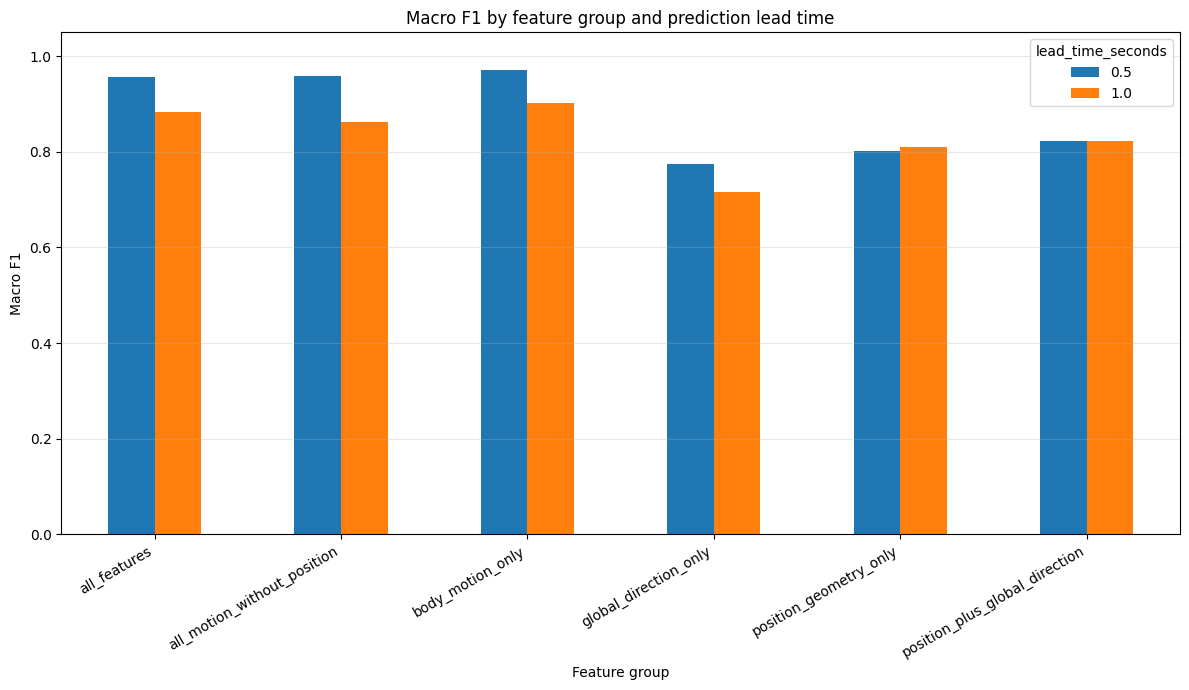

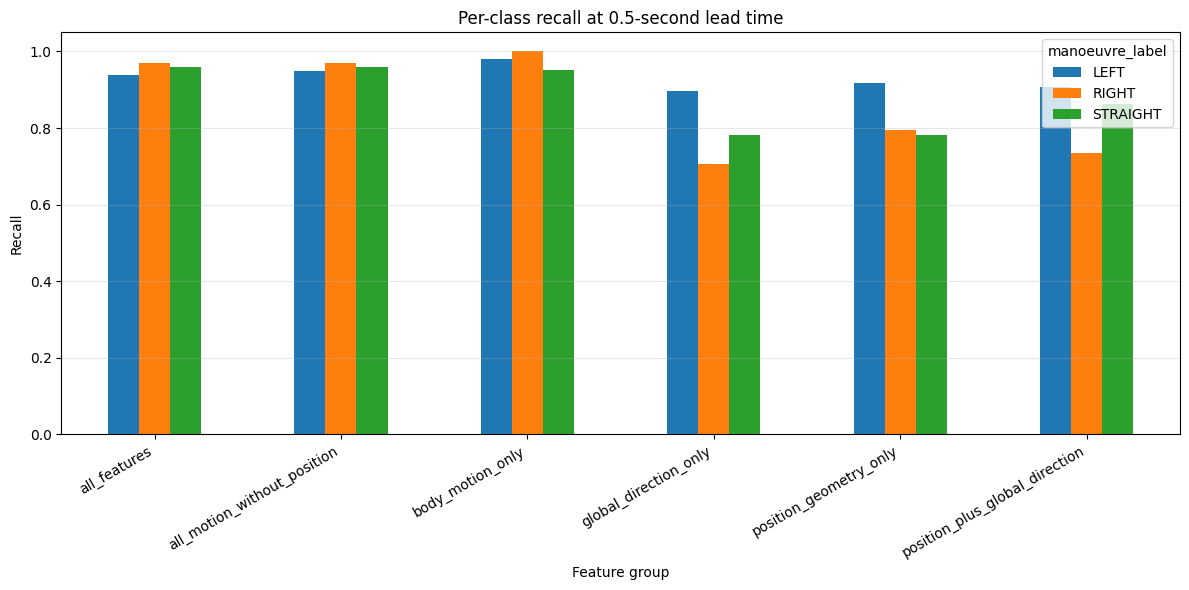

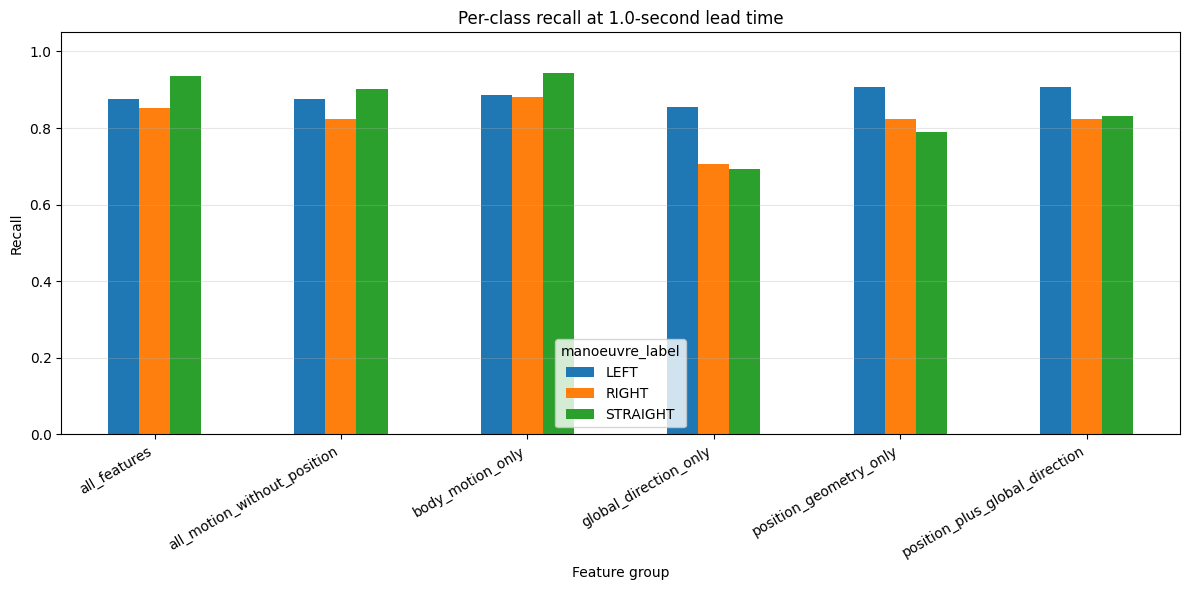


CELL 17 COMPLETED
Feature-ablation experiments were completed using recording-grouped cross-validation.

Interpretation guide:
  - If position_geometry_only is close to all_features, the model mainly recognizes map location.
  - If position_plus_global_direction is close to all_features, the model mainly recognizes the approach lane.
  - If body_motion_only remains strong, genuine motion behaviour contains useful intention information.
  - If all_motion_without_position is much weaker, global position is a major source of performance.

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/feature_ablation

Next step:
Inspect the overall macro F1 and per-class recall for every feature group before deciding whether to redesign the features or train a GRU.


In [ ]:
# Cell 17 — Feature-ablation experiment

# Purpose
# -------
# Determine what information is responsible for the high performance.
#
# Questions:
#
# 1. Can position alone predict the manoeuvre?
# 2. Can global direction alone predict it?
# 3. Can vehicle-relative motion predict it without map position?
# 4. What happens when all position features are removed?
#
# The same:
# - 254 vehicles;
# - recording-grouped folds;
# - training-only scaling;
# - training-only class weights;
#
# are used for every feature group.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    log_loss,
)


# ============================================================
# 1. CHECK REQUIRED OUTPUTS AND FUNCTIONS
# ============================================================

required_variables = [
    "FINAL_PRIMARY_COMMON_COHORT_DATASETS",
    "FINAL_LEAD_TIME_FEATURE_NAMES",
    "COMMON_COHORT_OUTPUT_DIRECTORY",
    "CLASS_TO_INDEX",
    "INDEX_TO_CLASS",
]

required_functions = [
    "create_sequence_summary_features",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

missing_functions = [
    function_name
    for function_name in required_functions
    if function_name not in globals()
]

if missing_variables or missing_functions:
    raise NameError(
        "Run the updated Cells 14, 15 and 16 first.\n"
        f"Missing variables: {missing_variables}\n"
        f"Missing functions: {missing_functions}"
    )


# ============================================================
# 2. EXPERIMENT CONFIGURATION
# ============================================================

EVALUATED_LEAD_TIMES = [
    0.5,
    1.0,
]

class_indices = sorted(
    int(class_index)
    for class_index in INDEX_TO_CLASS
)

class_index_to_position = {
    class_index: position
    for position, class_index
    in enumerate(class_indices)
}

all_feature_names = list(
    FINAL_LEAD_TIME_FEATURE_NAMES
)


# ============================================================
# 3. FEATURE GROUPS
# ============================================================

FEATURE_ABLATION_GROUPS = {
    # Original model.
    "all_features":
        list(
            all_feature_names
        ),

    # Tests whether map position alone reveals the manoeuvre.
    "position_geometry_only": [
        "x_relative_to_intersection_m",
        "y_relative_to_intersection_m",
        "distance_to_intersection_center_m",
        "distance_to_conflict_region_m",
    ],

    # Tests whether global movement direction reveals the approach road.
    "global_direction_only": [
        "x_velocity_mps",
        "y_velocity_mps",
        "heading_sin",
        "heading_cos",
    ],

    # A strong map and approach-lane baseline.
    "position_plus_global_direction": [
        "x_relative_to_intersection_m",
        "y_relative_to_intersection_m",
        "distance_to_intersection_center_m",
        "distance_to_conflict_region_m",
        "x_velocity_mps",
        "y_velocity_mps",
        "heading_sin",
        "heading_cos",
    ],

    # Vehicle-relative motion without global x/y position or heading.
    # This is the most important group for testing genuine behaviour.
    "body_motion_only": [
        "speed_mps",
        "acceleration_magnitude_mps2",
        "longitudinal_velocity_mps",
        "lateral_velocity_mps",
        "longitudinal_acceleration_mps2",
        "lateral_acceleration_mps2",
    ],

    # All motion information, but no position or distance features.
    # Global direction remains, so this can still reveal the approach arm.
    "all_motion_without_position": [
        "x_velocity_mps",
        "y_velocity_mps",
        "speed_mps",
        "x_acceleration_mps2",
        "y_acceleration_mps2",
        "acceleration_magnitude_mps2",
        "longitudinal_velocity_mps",
        "lateral_velocity_mps",
        "longitudinal_acceleration_mps2",
        "lateral_acceleration_mps2",
        "heading_sin",
        "heading_cos",
    ],
}


# ============================================================
# 4. VALIDATE FEATURE GROUPS
# ============================================================

for group_name, group_features in (
    FEATURE_ABLATION_GROUPS.items()
):
    missing_group_features = [
        feature_name
        for feature_name in group_features
        if feature_name not in all_feature_names
    ]

    if missing_group_features:
        raise KeyError(
            f"Feature group '{group_name}' contains unknown features:\n"
            f"{missing_group_features}"
        )

    if len(
        set(
            group_features
        )
    ) != len(
        group_features
    ):
        raise ValueError(
            f"Feature group '{group_name}' contains duplicates."
        )

print("Feature-ablation groups:")

for group_name, group_features in (
    FEATURE_ABLATION_GROUPS.items()
):
    print(
        f"  {group_name}: "
        f"{len(group_features)} source features, "
        f"{len(group_features) * 8} summary features"
    )


# ============================================================
# 5. METRIC HELPERS
# ============================================================

def calculate_ablation_overall_metrics(
    feature_group,
    lead_time_seconds,
    true_labels,
    predicted_labels,
    predicted_probabilities,
    source_feature_count,
):
    return {
        "feature_group":
            feature_group,

        "lead_time_seconds":
            float(
                lead_time_seconds
            ),

        "sequence_count":
            len(
                true_labels
            ),

        "source_feature_count":
            int(
                source_feature_count
            ),

        "summary_feature_count":
            int(
                source_feature_count
                * 8
            ),

        "accuracy":
            float(
                accuracy_score(
                    true_labels,
                    predicted_labels,
                )
            ),

        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    true_labels,
                    predicted_labels,
                )
            ),

        "macro_precision":
            float(
                precision_score(
                    true_labels,
                    predicted_labels,
                    labels=class_indices,
                    average="macro",
                    zero_division=0,
                )
            ),

        "macro_recall":
            float(
                recall_score(
                    true_labels,
                    predicted_labels,
                    labels=class_indices,
                    average="macro",
                    zero_division=0,
                )
            ),

        "macro_f1":
            float(
                f1_score(
                    true_labels,
                    predicted_labels,
                    labels=class_indices,
                    average="macro",
                    zero_division=0,
                )
            ),

        "weighted_f1":
            float(
                f1_score(
                    true_labels,
                    predicted_labels,
                    labels=class_indices,
                    average="weighted",
                    zero_division=0,
                )
            ),

        "log_loss":
            float(
                log_loss(
                    true_labels,
                    predicted_probabilities,
                    labels=class_indices,
                )
            ),
    }


def calculate_ablation_per_class_metrics(
    feature_group,
    lead_time_seconds,
    true_labels,
    predicted_labels,
):
    (
        precision_values,
        recall_values,
        f1_values,
        support_values,
    ) = precision_recall_fscore_support(
        true_labels,
        predicted_labels,
        labels=class_indices,
        zero_division=0,
    )

    return pd.DataFrame([
        {
            "feature_group":
                feature_group,

            "lead_time_seconds":
                float(
                    lead_time_seconds
                ),

            "class_index":
                int(
                    class_index
                ),

            "manoeuvre_label":
                INDEX_TO_CLASS[
                    class_index
                ],

            "precision":
                float(
                    precision_values[
                        class_position
                    ]
                ),

            "recall":
                float(
                    recall_values[
                        class_position
                    ]
                ),

            "f1":
                float(
                    f1_values[
                        class_position
                    ]
                ),

            "support":
                int(
                    support_values[
                        class_position
                    ]
                ),
        }
        for class_position, class_index
        in enumerate(class_indices)
    ])


# ============================================================
# 6. RUN RECORDING-GROUPED FEATURE ABLATION
# ============================================================

overall_metric_rows = []
per_class_metric_tables = []
fold_diagnostic_rows = []
out_of_fold_rows = []
quality_check_rows = []

ABLATION_OUT_OF_FOLD_RESULTS = {}

for lead_time_seconds in (
    EVALUATED_LEAD_TIMES
):
    lead_time_seconds = float(
        lead_time_seconds
    )

    dataset = (
        FINAL_PRIMARY_COMMON_COHORT_DATASETS[
            lead_time_seconds
        ]
    )

    X_complete = np.asarray(
        dataset[
            "X"
        ],
        dtype=np.float32,
    )

    y = np.asarray(
        dataset[
            "y"
        ],
        dtype=np.int64,
    )

    groups = np.asarray(
        dataset[
            "recording_groups"
        ],
        dtype=np.int64,
    )

    comparison_keys = np.asarray(
        dataset[
            "comparison_keys"
        ]
    ).astype(str)

    for feature_group, selected_features in (
        FEATURE_ABLATION_GROUPS.items()
    ):
        print(
            f"Running lead={lead_time_seconds:.1f}s, "
            f"group={feature_group}"
        )

        selected_feature_indices = [
            all_feature_names.index(
                feature_name
            )
            for feature_name in selected_features
        ]

        X_selected = (
            X_complete[
                :,
                :,
                selected_feature_indices,
            ]
            .copy()
        )

        sequence_count = len(
            y
        )

        class_count = len(
            class_indices
        )

        oof_predictions = np.full(
            sequence_count,
            fill_value=-1,
            dtype=np.int64,
        )

        oof_probabilities = np.full(
            (
                sequence_count,
                class_count,
            ),
            fill_value=np.nan,
            dtype=np.float64,
        )

        fold_assignments = np.full(
            sequence_count,
            fill_value=-1,
            dtype=np.int64,
        )

        logo = LeaveOneGroupOut()

        fold_number = 0

        for train_indices, test_indices in logo.split(
            X_selected,
            y,
            groups,
        ):
            fold_number += 1

            X_train_raw = (
                X_selected[
                    train_indices
                ]
            )

            X_test_raw = (
                X_selected[
                    test_indices
                ]
            )

            y_train = (
                y[
                    train_indices
                ]
            )

            y_test = (
                y[
                    test_indices
                ]
            )

            held_out_recording = int(
                np.unique(
                    groups[
                        test_indices
                    ]
                )[0]
            )

            training_classes = sorted(
                np.unique(
                    y_train
                ).tolist()
            )

            if training_classes != class_indices:
                raise RuntimeError(
                    f"Training fold is missing a class. "
                    f"Lead={lead_time_seconds}, "
                    f"group={feature_group}, "
                    f"recording={held_out_recording}, "
                    f"classes={training_classes}"
                )

            # -----------------------------------------------
            # TRAINING-ONLY SCALING
            # -----------------------------------------------

            selected_feature_count = (
                X_train_raw.shape[2]
            )

            train_flat = (
                X_train_raw.reshape(
                    -1,
                    selected_feature_count,
                )
            )

            test_flat = (
                X_test_raw.reshape(
                    -1,
                    selected_feature_count,
                )
            )

            scaler = StandardScaler()

            scaler.fit(
                train_flat
            )

            X_train_scaled = (
                scaler.transform(
                    train_flat
                )
                .reshape(
                    X_train_raw.shape
                )
                .astype(
                    np.float32
                )
            )

            X_test_scaled = (
                scaler.transform(
                    test_flat
                )
                .reshape(
                    X_test_raw.shape
                )
                .astype(
                    np.float32
                )
            )

            # -----------------------------------------------
            # SEQUENCE SUMMARIES
            # -----------------------------------------------

            (
                X_train_summary,
                train_summary_names,
            ) = create_sequence_summary_features(
                X_train_scaled,
                selected_features,
            )

            (
                X_test_summary,
                test_summary_names,
            ) = create_sequence_summary_features(
                X_test_scaled,
                selected_features,
            )

            if (
                train_summary_names
                != test_summary_names
            ):
                raise RuntimeError(
                    "Training/test summary names differ."
                )

            # -----------------------------------------------
            # TRAINING-ONLY CLASS WEIGHTS
            # -----------------------------------------------

            class_weight_values = compute_class_weight(
                class_weight="balanced",
                classes=np.asarray(
                    class_indices,
                    dtype=np.int64,
                ),
                y=y_train,
            )

            class_weights = {
                int(class_index):
                    float(
                        class_weight
                    )
                for class_index, class_weight
                in zip(
                    class_indices,
                    class_weight_values,
                )
            }

            # -----------------------------------------------
            # LOGISTIC REGRESSION
            # -----------------------------------------------

            model = LogisticRegression(
                class_weight=
                    class_weights,

                C=1.0,

                solver="lbfgs",

                max_iter=5000,

                random_state=42,
            )

            model.fit(
                X_train_summary,
                y_train,
            )

            fold_predictions = (
                model.predict(
                    X_test_summary
                )
            )

            model_probability_output = (
                model.predict_proba(
                    X_test_summary
                )
            )

            aligned_probabilities = np.zeros(
                (
                    len(
                        test_indices
                    ),
                    class_count,
                ),
                dtype=np.float64,
            )

            for model_class_position, (
                model_class_index
            ) in enumerate(
                model.classes_
            ):
                output_position = (
                    class_index_to_position[
                        int(
                            model_class_index
                        )
                    ]
                )

                aligned_probabilities[
                    :,
                    output_position,
                ] = (
                    model_probability_output[
                        :,
                        model_class_position,
                    ]
                )

            oof_predictions[
                test_indices
            ] = fold_predictions

            oof_probabilities[
                test_indices
            ] = aligned_probabilities

            fold_assignments[
                test_indices
            ] = fold_number

            fold_diagnostic_rows.append({
                "lead_time_seconds":
                    lead_time_seconds,

                "feature_group":
                    feature_group,

                "fold_number":
                    fold_number,

                "held_out_recording":
                    held_out_recording,

                "test_sequence_count":
                    len(
                        test_indices
                    ),

                "test_accuracy":
                    float(
                        accuracy_score(
                            y_test,
                            fold_predictions,
                        )
                    ),
            })

        predictions_complete = bool(
            np.all(
                oof_predictions
                >= 0
            )
        )

        probabilities_finite = bool(
            np.isfinite(
                oof_probabilities
            ).all()
        )

        probabilities_valid = bool(
            np.allclose(
                oof_probabilities.sum(
                    axis=1
                ),
                1.0,
                atol=1e-6,
            )
        )

        if not (
            predictions_complete
            and probabilities_finite
            and probabilities_valid
        ):
            raise RuntimeError(
                f"Invalid out-of-fold results for "
                f"{feature_group}, lead={lead_time_seconds}"
            )

        overall_metric_rows.append(
            calculate_ablation_overall_metrics(
                feature_group=
                    feature_group,

                lead_time_seconds=
                    lead_time_seconds,

                true_labels=
                    y,

                predicted_labels=
                    oof_predictions,

                predicted_probabilities=
                    oof_probabilities,

                source_feature_count=
                    len(
                        selected_features
                    ),
            )
        )

        per_class_metric_tables.append(
            calculate_ablation_per_class_metrics(
                feature_group=
                    feature_group,

                lead_time_seconds=
                    lead_time_seconds,

                true_labels=
                    y,

                predicted_labels=
                    oof_predictions,
            )
        )

        ABLATION_OUT_OF_FOLD_RESULTS[
            (
                lead_time_seconds,
                feature_group,
            )
        ] = {
            "true_labels":
                y.copy(),

            "predictions":
                oof_predictions.copy(),

            "probabilities":
                oof_probabilities.copy(),

            "comparison_keys":
                comparison_keys.copy(),

            "fold_assignments":
                fold_assignments.copy(),

            "selected_features":
                list(
                    selected_features
                ),
        }

        for sample_index in range(
            sequence_count
        ):
            result_row = {
                "lead_time_seconds":
                    lead_time_seconds,

                "feature_group":
                    feature_group,

                "comparison_key":
                    comparison_keys[
                        sample_index
                    ],

                "recording_id":
                    int(
                        groups[
                            sample_index
                        ]
                    ),

                "true_class_index":
                    int(
                        y[
                            sample_index
                        ]
                    ),

                "true_manoeuvre":
                    INDEX_TO_CLASS[
                        int(
                            y[
                                sample_index
                            ]
                        )
                    ],

                "predicted_class_index":
                    int(
                        oof_predictions[
                            sample_index
                        ]
                    ),

                "predicted_manoeuvre":
                    INDEX_TO_CLASS[
                        int(
                            oof_predictions[
                                sample_index
                            ]
                        )
                    ],

                "correct":
                    bool(
                        oof_predictions[
                            sample_index
                        ]
                        == y[
                            sample_index
                        ]
                    ),
            }

            for class_position, class_index in enumerate(
                class_indices
            ):
                class_name = INDEX_TO_CLASS[
                    class_index
                ]

                result_row[
                    f"probability_{class_name.lower()}"
                ] = float(
                    oof_probabilities[
                        sample_index,
                        class_position,
                    ]
                )

            out_of_fold_rows.append(
                result_row
            )

        quality_check_rows.append({
            "lead_time_seconds":
                lead_time_seconds,

            "feature_group":
                feature_group,

            "all_predictions_complete":
                predictions_complete,

            "probabilities_finite":
                probabilities_finite,

            "probabilities_sum_to_one":
                probabilities_valid,

            "fold_count":
                fold_number,
        })


# ============================================================
# 7. COMBINE RESULTS
# ============================================================

FEATURE_ABLATION_METRICS = (
    pd.DataFrame(
        overall_metric_rows
    )
    .sort_values(
        [
            "lead_time_seconds",
            "macro_f1",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

FEATURE_ABLATION_PER_CLASS_METRICS = (
    pd.concat(
        per_class_metric_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "lead_time_seconds",
            "feature_group",
            "class_index",
        ]
    )
    .reset_index(drop=True)
)

FEATURE_ABLATION_FOLD_DIAGNOSTICS = (
    pd.DataFrame(
        fold_diagnostic_rows
    )
)

FEATURE_ABLATION_OUT_OF_FOLD_TABLE = (
    pd.DataFrame(
        out_of_fold_rows
    )
)

FEATURE_ABLATION_QUALITY_CHECKS = (
    pd.DataFrame(
        quality_check_rows
    )
)


# ============================================================
# 8. CALCULATE PERFORMANCE CHANGE FROM ALL FEATURES
# ============================================================

all_feature_macro_f1 = (
    FEATURE_ABLATION_METRICS[
        FEATURE_ABLATION_METRICS[
            "feature_group"
        ] == "all_features"
    ]
    .set_index(
        "lead_time_seconds"
    )[
        "macro_f1"
    ]
    .to_dict()
)

FEATURE_ABLATION_METRICS[
    "macro_f1_difference_from_all_features"
] = [
    (
        row.macro_f1
        - all_feature_macro_f1[
            row.lead_time_seconds
        ]
    )
    for row in (
        FEATURE_ABLATION_METRICS.itertuples()
    )
]


# ============================================================
# 9. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FEATURE-ABLATION OVERALL METRICS")
print("=" * 80)

display(
    FEATURE_ABLATION_METRICS
)

print("\n" + "=" * 80)
print("FEATURE-ABLATION PER-CLASS METRICS")
print("=" * 80)

display(
    FEATURE_ABLATION_PER_CLASS_METRICS
)

print("\n" + "=" * 80)
print("FEATURE-ABLATION QUALITY CHECKS")
print("=" * 80)

display(
    FEATURE_ABLATION_QUALITY_CHECKS
)

quality_columns = [
    "all_predictions_complete",
    "probabilities_finite",
    "probabilities_sum_to_one",
]

if not FEATURE_ABLATION_QUALITY_CHECKS[
    quality_columns
].all().all():
    raise RuntimeError(
        "One or more ablation quality checks failed."
    )


# ============================================================
# 10. PLOT MACRO F1
# ============================================================

macro_f1_plot_table = (
    FEATURE_ABLATION_METRICS
    .pivot(
        index="feature_group",
        columns="lead_time_seconds",
        values="macro_f1",
    )
)

figure, axis = plt.subplots(
    figsize=(12, 7)
)

macro_f1_plot_table.plot(
    kind="bar",
    ax=axis,
)

axis.set_title(
    "Macro F1 by feature group and prediction lead time"
)

axis.set_xlabel(
    "Feature group"
)

axis.set_ylabel(
    "Macro F1"
)

axis.set_ylim(
    0.0,
    1.05,
)

axis.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=30,
    ha="right",
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. PLOT PER-CLASS RECALL
# ============================================================

logistic_recall_table = (
    FEATURE_ABLATION_PER_CLASS_METRICS
    .pivot_table(
        index=[
            "feature_group",
            "lead_time_seconds",
        ],
        columns="manoeuvre_label",
        values="recall",
    )
    .reset_index()
)

for lead_time_seconds in (
    EVALUATED_LEAD_TIMES
):
    lead_recall_table = (
        logistic_recall_table[
            logistic_recall_table[
                "lead_time_seconds"
            ] == lead_time_seconds
        ]
        .set_index(
            "feature_group"
        )[
            [
                "LEFT",
                "RIGHT",
                "STRAIGHT",
            ]
        ]
    )

    figure, axis = plt.subplots(
        figsize=(12, 6)
    )

    lead_recall_table.plot(
        kind="bar",
        ax=axis,
    )

    axis.set_title(
        f"Per-class recall at "
        f"{lead_time_seconds:.1f}-second lead time"
    )

    axis.set_xlabel(
        "Feature group"
    )

    axis.set_ylabel(
        "Recall"
    )

    axis.set_ylim(
        0.0,
        1.05,
    )

    axis.grid(
        True,
        axis="y",
        alpha=0.3,
    )

    plt.xticks(
        rotation=30,
        ha="right",
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 12. EXPORT RESULTS
# ============================================================

FEATURE_ABLATION_OUTPUT_DIRECTORY = (
    Path(
        COMMON_COHORT_OUTPUT_DIRECTORY
    )
    / "feature_ablation"
)

FEATURE_ABLATION_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FEATURE_ABLATION_METRICS.to_csv(
    FEATURE_ABLATION_OUTPUT_DIRECTORY
    / "feature_ablation_metrics.csv",
    index=False,
)

FEATURE_ABLATION_PER_CLASS_METRICS.to_csv(
    FEATURE_ABLATION_OUTPUT_DIRECTORY
    / "feature_ablation_per_class_metrics.csv",
    index=False,
)

FEATURE_ABLATION_FOLD_DIAGNOSTICS.to_csv(
    FEATURE_ABLATION_OUTPUT_DIRECTORY
    / "feature_ablation_fold_diagnostics.csv",
    index=False,
)

FEATURE_ABLATION_OUT_OF_FOLD_TABLE.to_csv(
    FEATURE_ABLATION_OUTPUT_DIRECTORY
    / "feature_ablation_oof_predictions.csv",
    index=False,
)

FEATURE_ABLATION_QUALITY_CHECKS.to_csv(
    FEATURE_ABLATION_OUTPUT_DIRECTORY
    / "feature_ablation_quality_checks.csv",
    index=False,
)


# ============================================================
# 13. STANDARD VARIABLES FOR THE NEXT CELL
# ============================================================

FINAL_FEATURE_ABLATION_METRICS = (
    FEATURE_ABLATION_METRICS
)

FINAL_FEATURE_ABLATION_PER_CLASS_METRICS = (
    FEATURE_ABLATION_PER_CLASS_METRICS
)

FINAL_FEATURE_ABLATION_OUT_OF_FOLD_RESULTS = (
    ABLATION_OUT_OF_FOLD_RESULTS
)


# ============================================================
# 14. FINAL STATUS
# ============================================================

print("\n" + "=" * 80)
print("CELL 17 COMPLETED")
print("=" * 80)

print(
    "Feature-ablation experiments were completed using "
    "recording-grouped cross-validation."
)

print("\nInterpretation guide:")

print(
    "  - If position_geometry_only is close to all_features, "
    "the model mainly recognizes map location."
)

print(
    "  - If position_plus_global_direction is close to all_features, "
    "the model mainly recognizes the approach lane."
)

print(
    "  - If body_motion_only remains strong, genuine motion behaviour "
    "contains useful intention information."
)

print(
    "  - If all_motion_without_position is much weaker, global position "
    "is a major source of performance."
)

print("\nOutput directory:")
print(" ", FEATURE_ABLATION_OUTPUT_DIRECTORY)

print("\nNext step:")
print(
    "Inspect the overall macro F1 and per-class recall for every "
    "feature group before deciding whether to redesign the features "
    "or train a GRU."
)

Running causal-motion audit for lead=0.5s
Running causal-motion audit for lead=1.0s

CAUSAL MOTION — OVERALL METRICS


,lead_time_seconds,feature_group,sequence_count,source_feature_count,valid_motion_timestep_count,summary_feature_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss
0,0.5,causal_position_derived_motion,254,6,48,48,0.854331,0.824735,0.805850,0.824735,0.814087,0.856581,0.491474
1,1.0,causal_position_derived_motion,254,6,48,48,0.811024,0.799145,0.763904,0.799145,0.776100,0.815553,0.543296



CAUSAL MOTION — PER-CLASS METRICS


,lead_time_seconds,feature_group,class_index,manoeuvre_label,precision,recall,f1,support
0,0.5,causal_position_derived_motion,0,LEFT,0.843750,0.843750,0.843750,96
1,0.5,causal_position_derived_motion,1,RIGHT,0.641026,0.735294,0.684932,34
2,0.5,causal_position_derived_motion,2,STRAIGHT,0.932773,0.895161,0.913580,124
3,1.0,causal_position_derived_motion,0,LEFT,0.846154,0.802083,0.823529,96
4,1.0,causal_position_derived_motion,1,RIGHT,0.565217,0.764706,0.650000,34
5,1.0,causal_position_derived_motion,2,STRAIGHT,0.880342,0.830645,0.854772,124



PUBLISHED inD KINEMATICS VS POSITION-DERIVED MOTION


,lead_time_seconds,published_kinematics_macro_f1,published_kinematics_balanced_accuracy,causal_motion_macro_f1,causal_motion_balanced_accuracy,causal_minus_published_macro_f1
0,0.5,0.971961,0.976927,0.814087,0.824735,-0.157874
1,1.0,0.902030,0.903773,0.776100,0.799145,-0.125930



QUALITY CHECKS


,lead_time_seconds,sequence_count,causal_sequence_shape,all_features_finite,class_set_complete,recording_count,fold_count,all_predictions_complete,probabilities_finite,probabilities_sum_to_one
0,0.5,254,"(254, 48, 6)",True,True,11,11,True,True,True
1,1.0,254,"(254, 48, 6)",True,True,11,11,True,True,True


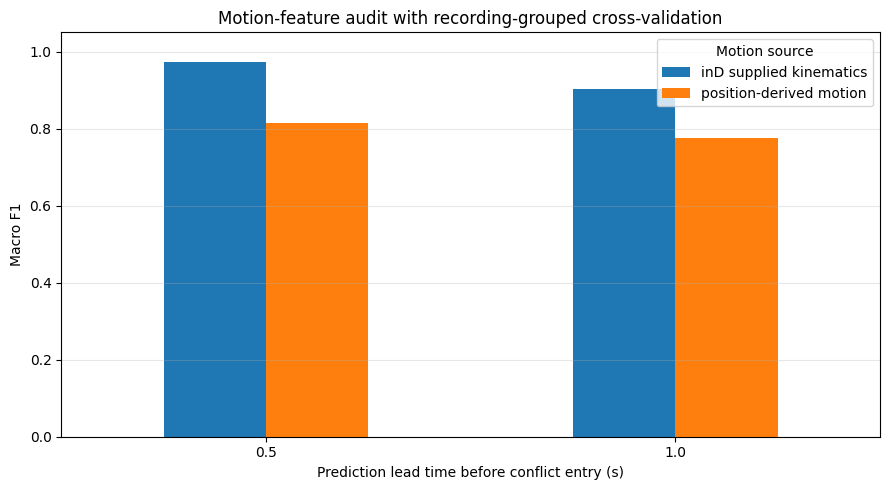


CELL 18 COMPLETED
Position-derived motion was evaluated without using the published inD velocity or acceleration fields.
Do not train the GRU yet. First inspect the 1.0-second macro F1, LEFT/RIGHT/STRAIGHT recalls, comparison table, and quality checks.

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/causal_motion_audit


In [ ]:
# Cell 18 — Causal, position-derived motion-feature audit
#
# Run this cell after the UPDATED Cells 14, 15, 16 and 17.
# Do not run the old Cell 18 from the original notebook.
#
# Purpose
# -------
# Cell 17 showed that body-motion features perform unusually well.
# However, the velocity and acceleration fields supplied by inD were
# produced during full-trajectory post-processing.
#
# This cell therefore:
#   1. uses only the observed x/y positions inside each input window;
#   2. calculates velocity with backward differences;
#   3. calculates acceleration with backward differences;
#   4. expresses motion in an approach-relative coordinate system;
#   5. excludes absolute x/y map position from the model;
#   6. repeats Leave-One-Recording-Out evaluation;
#   7. compares the result with Cell 17's body_motion_only result.
#
# Important limitation
# --------------------
# The published x/y positions themselves are already smoothed by inD.
# This audit removes direct use of inD's precomputed kinematic fields,
# but it cannot recreate raw, unsmoothed detector measurements.

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    log_loss,
)


# ============================================================
# 1. CHECK REQUIRED OUTPUTS
# ============================================================

required_variables = [
    "FINAL_PRIMARY_COMMON_COHORT_DATASETS",
    "FINAL_FEATURE_ABLATION_METRICS",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the UPDATED Cells 14, 15, 16 and 17 before Cell 18.\n"
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

CAUSAL_AUDIT_LEAD_TIMES = [0.5, 1.0]
EXPECTED_CLASS_INDICES = np.array([0, 1, 2], dtype=np.int64)

DEFAULT_INDEX_TO_CLASS = {
    0: "LEFT",
    1: "RIGHT",
    2: "STRAIGHT",
}

class_name_lookup = dict(
    globals().get(
        "INDEX_TO_CLASS",
        DEFAULT_INDEX_TO_CLASS,
    )
)

CAUSAL_MOTION_FEATURE_NAMES = [
    "position_derived_speed_mps",
    "position_derived_acceleration_magnitude_mps2",
    "approach_longitudinal_velocity_mps",
    "approach_lateral_velocity_mps",
    "approach_longitudinal_acceleration_mps2",
    "approach_lateral_acceleration_mps2",
]

base_output_directory = Path(
    globals().get(
        "PRIMARY_COMMON_COHORT_OUTPUT_DIRECTORY",
        (
            "/content/drive/MyDrive/inD-dataset-v1.1/"
            "prepared_intention_data/lead_time_experiment/"
            "primary_common_cohort"
        ),
    )
)

CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY = (
    base_output_directory
    / "causal_motion_audit"
)

CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 3. ROBUSTLY READ THE COMMON-COHORT DATASETS
# ============================================================

def resolve_lead_time_dataset(dataset_collection, lead_time):
    """Find a lead-time dataset even if its dictionary key is text."""

    if lead_time in dataset_collection:
        return dataset_collection[lead_time]

    for key, value in dataset_collection.items():
        try:
            if np.isclose(float(key), float(lead_time)):
                return value
        except (TypeError, ValueError):
            continue

    raise KeyError(
        f"No common-cohort dataset was found for lead={lead_time}s. "
        f"Available keys: {list(dataset_collection.keys())}"
    )


def first_present(mapping, candidate_names):
    """Return the first non-None value found under candidate keys."""

    for candidate_name in candidate_names:
        if (
            candidate_name in mapping
            and mapping[candidate_name] is not None
        ):
            return mapping[candidate_name]

    return None


def unpack_common_cohort_dataset(dataset, lead_time):
    """
    Extract X, y, recording groups, metadata and feature names.

    The candidate-key checks make this cell tolerant of the naming
    variations used in the preceding updated cells.
    """

    if not isinstance(dataset, dict):
        raise TypeError(
            f"The lead={lead_time}s dataset must be a dictionary. "
            f"Received {type(dataset).__name__}."
        )

    X = first_present(
        dataset,
        [
            "X",
            "sequences",
            "sequence_array",
            "sequence_tensor",
            "X_sequences",
            "intention_X",
        ],
    )

    if X is None:
        for value in dataset.values():
            candidate = np.asarray(value) if isinstance(
                value,
                np.ndarray,
            ) else None

            if (
                candidate is not None
                and candidate.ndim == 3
            ):
                X = candidate
                break

    if X is None:
        raise KeyError(
            f"Could not locate the 3-D sequence array for "
            f"lead={lead_time}s. Dataset keys: {list(dataset.keys())}"
        )

    X = np.asarray(X, dtype=np.float64)

    metadata = first_present(
        dataset,
        [
            "metadata",
            "sequence_metadata",
            "cohort_metadata",
        ],
    )

    if metadata is None:
        for value in dataset.values():
            if (
                isinstance(value, pd.DataFrame)
                and len(value) == len(X)
                and "recording_id" in value.columns
            ):
                metadata = value
                break

    metadata = (
        metadata.copy().reset_index(drop=True)
        if isinstance(metadata, pd.DataFrame)
        else None
    )

    y = first_present(
        dataset,
        [
            "y",
            "labels",
            "class_indices",
            "target_array",
            "intention_y",
        ],
    )

    groups = first_present(
        dataset,
        [
            "groups",
            "recording_groups",
            "recording_ids",
            "group_array",
        ],
    )

    if y is None and metadata is not None:
        if "class_index" in metadata.columns:
            y = metadata["class_index"].to_numpy()
        elif "manoeuvre_label" in metadata.columns:
            class_to_index = globals().get(
                "CLASS_TO_INDEX",
                {
                    "LEFT": 0,
                    "RIGHT": 1,
                    "STRAIGHT": 2,
                },
            )

            y = (
                metadata["manoeuvre_label"]
                .map(class_to_index)
                .to_numpy()
            )

    if groups is None and metadata is not None:
        groups = metadata["recording_id"].to_numpy()

    if y is None or groups is None:
        one_dimensional_arrays = [
            np.asarray(value)
            for value in dataset.values()
            if (
                isinstance(value, np.ndarray)
                and value.ndim == 1
                and len(value) == len(X)
            )
        ]

        if y is None:
            for candidate in one_dimensional_arrays:
                try:
                    candidate_integer = candidate.astype(np.int64)
                except (TypeError, ValueError):
                    continue

                if set(np.unique(candidate_integer)).issubset(
                    {0, 1, 2}
                ):
                    y = candidate_integer
                    break

        if groups is None:
            for candidate in one_dimensional_arrays:
                try:
                    candidate_integer = candidate.astype(np.int64)
                except (TypeError, ValueError):
                    continue

                unique_values = set(np.unique(candidate_integer))

                if (
                    unique_values
                    and min(unique_values) >= 7
                    and max(unique_values) <= 17
                ):
                    groups = candidate_integer
                    break

    if y is None or groups is None:
        raise KeyError(
            f"Could not locate labels and recording groups for "
            f"lead={lead_time}s. Dataset keys: {list(dataset.keys())}"
        )

    y = np.asarray(y, dtype=np.int64)
    groups = np.asarray(groups, dtype=np.int64)

    feature_names = first_present(
        dataset,
        [
            "feature_names",
            "sequence_feature_names",
            "features",
        ],
    )

    if feature_names is None:
        for global_name in [
            "FINAL_LEAD_TIME_FEATURE_NAMES",
            "LEAD_TIME_FEATURE_NAMES",
            "SEQUENCE_FEATURE_COLUMNS",
            "FINAL_INTENTION_FEATURE_NAMES",
        ]:
            candidate = globals().get(global_name)

            if (
                candidate is not None
                and len(candidate) == X.shape[2]
            ):
                feature_names = candidate
                break

    if feature_names is None:
        warnings.warn(
            "Feature names were not found. Because the current dataset "
            "has the expected 17-feature layout, columns 1 and 2 will "
            "be treated as relative x and y position.",
            RuntimeWarning,
        )
        feature_names = [
            f"feature_{feature_index}"
            for feature_index in range(X.shape[2])
        ]

        if X.shape[2] >= 3:
            feature_names[1] = "x_relative_to_intersection_m"
            feature_names[2] = "y_relative_to_intersection_m"

    feature_names = list(feature_names)

    if not (
        len(X)
        == len(y)
        == len(groups)
    ):
        raise ValueError(
            f"Sequence, label and group counts disagree for "
            f"lead={lead_time}s."
        )

    if X.ndim != 3:
        raise ValueError(
            f"Expected a 3-D sequence array, received {X.shape}."
        )

    if len(feature_names) != X.shape[2]:
        raise ValueError(
            f"Received {len(feature_names)} feature names for "
            f"{X.shape[2]} sequence features."
        )

    if not np.isfinite(X).all():
        raise ValueError(
            f"The lead={lead_time}s sequence array contains "
            "NaN or infinite values."
        )

    if set(np.unique(y)) != set(EXPECTED_CLASS_INDICES):
        raise ValueError(
            f"All three classes are required at lead={lead_time}s. "
            f"Found classes: {sorted(np.unique(y).tolist())}"
        )

    if metadata is None:
        metadata = pd.DataFrame({
            "recording_id": groups,
            "class_index": y,
        })

    return X, y, groups, metadata, feature_names


# ============================================================
# 4. CONSTRUCT POSITION-DERIVED, APPROACH-RELATIVE MOTION
# ============================================================

def find_feature_index(feature_names, candidates):
    """Find a feature index using exact or partial name matching."""

    for candidate in candidates:
        if candidate in feature_names:
            return feature_names.index(candidate)

    lower_names = [
        str(feature_name).lower()
        for feature_name in feature_names
    ]

    for candidate in candidates:
        candidate_lower = candidate.lower()

        for feature_index, feature_name in enumerate(lower_names):
            if candidate_lower in feature_name:
                return feature_index

    return None


def infer_frame_interval_seconds(X, feature_names):
    """Infer frame spacing from the time feature, or use inD's 25 Hz."""

    time_index = find_feature_index(
        feature_names,
        [
            "time_relative_to_prediction_seconds",
            "relative_time_seconds",
        ],
    )

    if time_index is not None:
        differences = np.diff(
            X[:, :, time_index],
            axis=1,
        )

        positive_differences = np.abs(
            differences[
                np.isfinite(differences)
                & (np.abs(differences) > 1e-9)
            ]
        )

        if positive_differences.size:
            inferred_interval = float(
                np.median(positive_differences)
            )

            if 0.001 <= inferred_interval <= 1.0:
                return inferred_interval

    return 1.0 / 25.0


def construct_causal_motion_sequences(X, feature_names):
    """
    Derive six motion features using only positions up to each frame.

    The first two position frames are used as differentiation warm-up.
    Therefore, a 50-frame position window produces 48 valid motion
    timesteps without zero-padding or future-frame padding.
    """

    x_index = find_feature_index(
        feature_names,
        ["x_relative_to_intersection_m"],
    )

    y_index = find_feature_index(
        feature_names,
        ["y_relative_to_intersection_m"],
    )

    if x_index is None or y_index is None:
        raise KeyError(
            "Could not find x_relative_to_intersection_m and "
            "y_relative_to_intersection_m in the feature names."
        )

    positions = X[:, :, [x_index, y_index]]

    if positions.shape[1] < 12:
        raise ValueError(
            "At least 12 position frames are required for the "
            "causal motion audit."
        )

    frame_interval_seconds = infer_frame_interval_seconds(
        X,
        feature_names,
    )

    # Backward velocity:
    # velocity at frame t uses position[t] and position[t - 1].
    velocity = (
        positions[:, 1:, :]
        - positions[:, :-1, :]
    ) / frame_interval_seconds

    # Backward acceleration:
    # acceleration at frame t uses velocity[t] and velocity[t - 1].
    acceleration = (
        velocity[:, 1:, :]
        - velocity[:, :-1, :]
    ) / frame_interval_seconds

    # Align velocity and acceleration at original frames 2 ... T-1.
    aligned_velocity = velocity[:, 1:, :]

    # Estimate one fixed approach direction from the earliest 0.4 s
    # of the observed history. This removes global compass direction.
    approach_end_index = min(
        10,
        positions.shape[1] - 1,
    )

    approach_vector = (
        positions[:, approach_end_index, :]
        - positions[:, 0, :]
    )

    approach_norm = np.linalg.norm(
        approach_vector,
        axis=1,
    )

    fallback_vector = (
        positions[:, -1, :]
        - positions[:, 0, :]
    )

    fallback_mask = approach_norm < 1e-6
    approach_vector[fallback_mask] = (
        fallback_vector[fallback_mask]
    )

    approach_norm = np.linalg.norm(
        approach_vector,
        axis=1,
    )

    if np.any(approach_norm < 1e-6):
        raise ValueError(
            "At least one sequence has no measurable movement, so an "
            "approach-relative coordinate frame cannot be constructed."
        )

    approach_unit = (
        approach_vector
        / approach_norm[:, None]
    )

    lateral_unit = np.column_stack([
        -approach_unit[:, 1],
        approach_unit[:, 0],
    ])

    longitudinal_velocity = np.einsum(
        "ntd,nd->nt",
        aligned_velocity,
        approach_unit,
    )

    lateral_velocity = np.einsum(
        "ntd,nd->nt",
        aligned_velocity,
        lateral_unit,
    )

    longitudinal_acceleration = np.einsum(
        "ntd,nd->nt",
        acceleration,
        approach_unit,
    )

    lateral_acceleration = np.einsum(
        "ntd,nd->nt",
        acceleration,
        lateral_unit,
    )

    speed = np.linalg.norm(
        aligned_velocity,
        axis=2,
    )

    acceleration_magnitude = np.linalg.norm(
        acceleration,
        axis=2,
    )

    causal_motion_X = np.stack(
        [
            speed,
            acceleration_magnitude,
            longitudinal_velocity,
            lateral_velocity,
            longitudinal_acceleration,
            lateral_acceleration,
        ],
        axis=2,
    ).astype(np.float32)

    if not np.isfinite(causal_motion_X).all():
        raise ValueError(
            "The derived causal-motion sequences contain NaN or "
            "infinite values."
        )

    return causal_motion_X, frame_interval_seconds


# ============================================================
# 5. SEQUENCE SUMMARY FEATURES
# ============================================================

def create_causal_sequence_summaries(sequence_tensor):
    """
    Create the same eight summary types used in Cells 16 and 17.
    """

    sequence_tensor = np.asarray(
        sequence_tensor,
        dtype=np.float64,
    )

    timestep_axis = np.arange(
        sequence_tensor.shape[1],
        dtype=np.float64,
    )

    centered_time = (
        timestep_axis
        - timestep_axis.mean()
    )

    slope_denominator = np.sum(
        centered_time ** 2
    )

    slope = np.einsum(
        "ntf,t->nf",
        sequence_tensor,
        centered_time,
    ) / slope_denominator

    return np.concatenate(
        [
            sequence_tensor[:, 0, :],
            sequence_tensor[:, -1, :],
            sequence_tensor.mean(axis=1),
            sequence_tensor.std(axis=1),
            sequence_tensor.min(axis=1),
            sequence_tensor.max(axis=1),
            (
                sequence_tensor[:, -1, :]
                - sequence_tensor[:, 0, :]
            ),
            slope,
        ],
        axis=1,
    )


# ============================================================
# 6. RECORDING-GROUPED LOGISTIC BASELINE
# ============================================================

def calculate_training_class_weights(y_train):
    """Calculate balanced class weights using training labels only."""

    sample_count = len(y_train)
    class_count = len(EXPECTED_CLASS_INDICES)
    weights = {}

    for class_index in EXPECTED_CLASS_INDICES:
        current_count = int(
            np.sum(y_train == class_index)
        )

        if current_count == 0:
            raise ValueError(
                f"A training fold contains no examples of "
                f"class {class_index}."
            )

        weights[int(class_index)] = (
            sample_count
            / (class_count * current_count)
        )

    return weights


def evaluate_causal_motion_with_logo(
    X_causal,
    y,
    groups,
    lead_time,
):
    """
    Evaluate one lead time using Leave-One-Recording-Out CV.

    Every scaler and every class weight is fitted from the training
    recordings of its fold only.
    """

    logo = LeaveOneGroupOut()
    sequence_count = len(X_causal)

    oof_prediction = np.full(
        sequence_count,
        -1,
        dtype=np.int64,
    )

    oof_probability = np.full(
        (
            sequence_count,
            len(EXPECTED_CLASS_INDICES),
        ),
        np.nan,
        dtype=np.float64,
    )

    fold_rows = []

    for fold_number, (
        train_indices,
        held_out_indices,
    ) in enumerate(
        logo.split(
            X_causal,
            y,
            groups,
        ),
        start=1,
    ):
        held_out_recording = int(
            np.unique(
                groups[held_out_indices]
            )[0]
        )

        X_train_raw = X_causal[train_indices]
        X_held_out_raw = X_causal[held_out_indices]
        y_train = y[train_indices]
        y_held_out = y[held_out_indices]

        # Training-only frame-level scaling.
        training_frames = X_train_raw.reshape(
            -1,
            X_train_raw.shape[2],
        )

        training_mean = training_frames.mean(
            axis=0,
            dtype=np.float64,
        )

        training_standard_deviation = training_frames.std(
            axis=0,
            dtype=np.float64,
        )

        safe_standard_deviation = (
            training_standard_deviation.copy()
        )

        safe_standard_deviation[
            safe_standard_deviation < 1e-8
        ] = 1.0

        X_train_scaled = (
            X_train_raw
            - training_mean
        ) / safe_standard_deviation

        X_held_out_scaled = (
            X_held_out_raw
            - training_mean
        ) / safe_standard_deviation

        X_train_summary = (
            create_causal_sequence_summaries(
                X_train_scaled
            )
        )

        X_held_out_summary = (
            create_causal_sequence_summaries(
                X_held_out_scaled
            )
        )

        training_class_weights = (
            calculate_training_class_weights(
                y_train
            )
        )

        model = LogisticRegression(
            C=1.0,
            class_weight=training_class_weights,
            solver="lbfgs",
            max_iter=4000,
            random_state=42,
        )

        model.fit(
            X_train_summary,
            y_train,
        )

        held_out_prediction = model.predict(
            X_held_out_summary
        )

        model_probability = model.predict_proba(
            X_held_out_summary
        )

        aligned_probability = np.zeros(
            (
                len(held_out_indices),
                len(EXPECTED_CLASS_INDICES),
            ),
            dtype=np.float64,
        )

        for model_column, class_index in enumerate(
            model.classes_
        ):
            aligned_probability[
                :,
                int(class_index),
            ] = model_probability[
                :,
                model_column,
            ]

        oof_prediction[
            held_out_indices
        ] = held_out_prediction

        oof_probability[
            held_out_indices
        ] = aligned_probability

        fold_rows.append({
            "lead_time_seconds": float(lead_time),
            "fold_number": int(fold_number),
            "held_out_recording_id":
                held_out_recording,
            "training_sequence_count":
                int(len(train_indices)),
            "held_out_sequence_count":
                int(len(held_out_indices)),
            "held_out_accuracy":
                float(
                    accuracy_score(
                        y_held_out,
                        held_out_prediction,
                    )
                ),
            "held_out_macro_f1":
                float(
                    f1_score(
                        y_held_out,
                        held_out_prediction,
                        labels=EXPECTED_CLASS_INDICES,
                        average="macro",
                        zero_division=0,
                    )
                ),
        })

    if np.any(oof_prediction < 0):
        raise RuntimeError(
            "Some vehicles did not receive an out-of-fold prediction."
        )

    if not np.isfinite(oof_probability).all():
        raise RuntimeError(
            "Some out-of-fold probabilities are not finite."
        )

    if not np.allclose(
        oof_probability.sum(axis=1),
        1.0,
        atol=1e-6,
    ):
        raise RuntimeError(
            "Some out-of-fold probabilities do not sum to one."
        )

    overall_row = {
        "lead_time_seconds": float(lead_time),
        "feature_group":
            "causal_position_derived_motion",
        "sequence_count": int(sequence_count),
        "source_feature_count":
            int(X_causal.shape[2]),
        "valid_motion_timestep_count":
            int(X_causal.shape[1]),
        "summary_feature_count":
            int(X_causal.shape[2] * 8),
        "accuracy":
            float(
                accuracy_score(
                    y,
                    oof_prediction,
                )
            ),
        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    y,
                    oof_prediction,
                )
            ),
        "macro_precision":
            float(
                precision_score(
                    y,
                    oof_prediction,
                    labels=EXPECTED_CLASS_INDICES,
                    average="macro",
                    zero_division=0,
                )
            ),
        "macro_recall":
            float(
                recall_score(
                    y,
                    oof_prediction,
                    labels=EXPECTED_CLASS_INDICES,
                    average="macro",
                    zero_division=0,
                )
            ),
        "macro_f1":
            float(
                f1_score(
                    y,
                    oof_prediction,
                    labels=EXPECTED_CLASS_INDICES,
                    average="macro",
                    zero_division=0,
                )
            ),
        "weighted_f1":
            float(
                f1_score(
                    y,
                    oof_prediction,
                    labels=EXPECTED_CLASS_INDICES,
                    average="weighted",
                    zero_division=0,
                )
            ),
        "log_loss":
            float(
                log_loss(
                    y,
                    oof_probability,
                    labels=EXPECTED_CLASS_INDICES,
                )
            ),
    }

    (
        per_class_precision,
        per_class_recall,
        per_class_f1,
        per_class_support,
    ) = precision_recall_fscore_support(
        y,
        oof_prediction,
        labels=EXPECTED_CLASS_INDICES,
        zero_division=0,
    )

    per_class_rows = []

    for class_position, class_index in enumerate(
        EXPECTED_CLASS_INDICES
    ):
        per_class_rows.append({
            "lead_time_seconds": float(lead_time),
            "feature_group":
                "causal_position_derived_motion",
            "class_index": int(class_index),
            "manoeuvre_label":
                class_name_lookup.get(
                    int(class_index),
                    str(class_index),
                ),
            "precision":
                float(
                    per_class_precision[
                        class_position
                    ]
                ),
            "recall":
                float(
                    per_class_recall[
                        class_position
                    ]
                ),
            "f1":
                float(
                    per_class_f1[
                        class_position
                    ]
                ),
            "support":
                int(
                    per_class_support[
                        class_position
                    ]
                ),
        })

    return {
        "overall_row": overall_row,
        "per_class_rows": per_class_rows,
        "fold_rows": fold_rows,
        "oof_prediction": oof_prediction,
        "oof_probability": oof_probability,
    }


# ============================================================
# 7. BUILD AND EVALUATE BOTH LEAD TIMES
# ============================================================

causal_dataset_results = {}
overall_rows = []
per_class_rows = []
fold_rows = []
oof_tables = []
quality_rows = []

for lead_time in CAUSAL_AUDIT_LEAD_TIMES:
    print(
        f"Running causal-motion audit for "
        f"lead={lead_time:.1f}s"
    )

    lead_dataset = resolve_lead_time_dataset(
        FINAL_PRIMARY_COMMON_COHORT_DATASETS,
        lead_time,
    )

    (
        original_X,
        y,
        groups,
        metadata,
        original_feature_names,
    ) = unpack_common_cohort_dataset(
        lead_dataset,
        lead_time,
    )

    causal_X, frame_interval_seconds = (
        construct_causal_motion_sequences(
            original_X,
            original_feature_names,
        )
    )

    evaluation = evaluate_causal_motion_with_logo(
        causal_X,
        y,
        groups,
        lead_time,
    )

    causal_dataset_results[float(lead_time)] = {
        "X": causal_X,
        "y": y.copy(),
        "groups": groups.copy(),
        "metadata": metadata.copy(),
        "feature_names":
            list(CAUSAL_MOTION_FEATURE_NAMES),
        "frame_interval_seconds":
            float(frame_interval_seconds),
    }

    overall_rows.append(
        evaluation["overall_row"]
    )

    per_class_rows.extend(
        evaluation["per_class_rows"]
    )

    fold_rows.extend(
        evaluation["fold_rows"]
    )

    oof_table = metadata.copy()
    oof_table["lead_time_seconds"] = float(
        lead_time
    )
    oof_table["true_class_index"] = y
    oof_table["predicted_class_index"] = (
        evaluation["oof_prediction"]
    )

    for class_index in EXPECTED_CLASS_INDICES:
        class_name = class_name_lookup.get(
            int(class_index),
            str(class_index),
        ).lower()

        oof_table[
            f"probability_{class_name}"
        ] = evaluation[
            "oof_probability"
        ][
            :,
            int(class_index),
        ]

    oof_tables.append(oof_table)

    quality_rows.append({
        "lead_time_seconds": float(lead_time),
        "sequence_count": int(len(causal_X)),
        "causal_sequence_shape":
            str(tuple(causal_X.shape)),
        "all_features_finite":
            bool(np.isfinite(causal_X).all()),
        "class_set_complete":
            bool(
                set(np.unique(y))
                == set(EXPECTED_CLASS_INDICES)
            ),
        "recording_count":
            int(len(np.unique(groups))),
        "fold_count":
            int(
                sum(
                    row["lead_time_seconds"]
                    == float(lead_time)
                    for row in fold_rows
                )
            ),
        "all_predictions_complete":
            bool(
                np.all(
                    evaluation[
                        "oof_prediction"
                    ] >= 0
                )
            ),
        "probabilities_finite":
            bool(
                np.isfinite(
                    evaluation[
                        "oof_probability"
                    ]
                ).all()
            ),
        "probabilities_sum_to_one":
            bool(
                np.allclose(
                    evaluation[
                        "oof_probability"
                    ].sum(axis=1),
                    1.0,
                    atol=1e-6,
                )
            ),
    })


FINAL_CAUSAL_MOTION_DATASETS = (
    causal_dataset_results
)

FINAL_CAUSAL_MOTION_METRICS = pd.DataFrame(
    overall_rows
).sort_values(
    "lead_time_seconds"
).reset_index(drop=True)

FINAL_CAUSAL_MOTION_PER_CLASS_METRICS = (
    pd.DataFrame(
        per_class_rows
    ).sort_values(
        [
            "lead_time_seconds",
            "class_index",
        ]
    ).reset_index(drop=True)
)

FINAL_CAUSAL_MOTION_FOLD_METRICS = (
    pd.DataFrame(
        fold_rows
    ).sort_values(
        [
            "lead_time_seconds",
            "held_out_recording_id",
        ]
    ).reset_index(drop=True)
)

FINAL_CAUSAL_MOTION_OOF_PREDICTIONS = (
    pd.concat(
        oof_tables,
        ignore_index=True,
    )
)

FINAL_CAUSAL_MOTION_QUALITY_CHECKS = (
    pd.DataFrame(
        quality_rows
    ).sort_values(
        "lead_time_seconds"
    ).reset_index(drop=True)
)


# ============================================================
# 8. COMPARE WITH CELL 17'S BODY-MOTION RESULT
# ============================================================

current_body_motion = (
    FINAL_FEATURE_ABLATION_METRICS[
        FINAL_FEATURE_ABLATION_METRICS[
            "feature_group"
        ].eq("body_motion_only")
        & FINAL_FEATURE_ABLATION_METRICS[
            "lead_time_seconds"
        ].isin(CAUSAL_AUDIT_LEAD_TIMES)
    ][
        [
            "lead_time_seconds",
            "macro_f1",
            "balanced_accuracy",
        ]
    ]
    .rename(
        columns={
            "macro_f1":
                "published_kinematics_macro_f1",
            "balanced_accuracy":
                "published_kinematics_balanced_accuracy",
        }
    )
)

FINAL_CAUSAL_MOTION_COMPARISON = (
    current_body_motion.merge(
        FINAL_CAUSAL_MOTION_METRICS[
            [
                "lead_time_seconds",
                "macro_f1",
                "balanced_accuracy",
            ]
        ].rename(
            columns={
                "macro_f1":
                    "causal_motion_macro_f1",
                "balanced_accuracy":
                    "causal_motion_balanced_accuracy",
            }
        ),
        on="lead_time_seconds",
        how="outer",
        validate="one_to_one",
    )
    .sort_values(
        "lead_time_seconds"
    )
    .reset_index(drop=True)
)

FINAL_CAUSAL_MOTION_COMPARISON[
    "causal_minus_published_macro_f1"
] = (
    FINAL_CAUSAL_MOTION_COMPARISON[
        "causal_motion_macro_f1"
    ]
    - FINAL_CAUSAL_MOTION_COMPARISON[
        "published_kinematics_macro_f1"
    ]
)


# ============================================================
# 9. DISPLAY AND EXPORT
# ============================================================

print("\n" + "=" * 80)
print("CAUSAL MOTION — OVERALL METRICS")
print("=" * 80)
display(FINAL_CAUSAL_MOTION_METRICS)

print("\n" + "=" * 80)
print("CAUSAL MOTION — PER-CLASS METRICS")
print("=" * 80)
display(FINAL_CAUSAL_MOTION_PER_CLASS_METRICS)

print("\n" + "=" * 80)
print("PUBLISHED inD KINEMATICS VS POSITION-DERIVED MOTION")
print("=" * 80)
display(FINAL_CAUSAL_MOTION_COMPARISON)

print("\n" + "=" * 80)
print("QUALITY CHECKS")
print("=" * 80)
display(FINAL_CAUSAL_MOTION_QUALITY_CHECKS)


plot_table = (
    FINAL_CAUSAL_MOTION_COMPARISON[
        [
            "lead_time_seconds",
            "published_kinematics_macro_f1",
            "causal_motion_macro_f1",
        ]
    ]
    .set_index(
        "lead_time_seconds"
    )
    .rename(
        columns={
            "published_kinematics_macro_f1":
                "inD supplied kinematics",
            "causal_motion_macro_f1":
                "position-derived motion",
        }
    )
)

axis = plot_table.plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0.0, 1.05),
    rot=0,
)

axis.set_title(
    "Motion-feature audit with recording-grouped cross-validation"
)
axis.set_xlabel(
    "Prediction lead time before conflict entry (s)"
)
axis.set_ylabel("Macro F1")
axis.grid(
    axis="y",
    alpha=0.3,
)
axis.legend(
    title="Motion source"
)

plt.tight_layout()
plt.show()


FINAL_CAUSAL_MOTION_METRICS.to_csv(
    CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY
    / "causal_motion_overall_metrics.csv",
    index=False,
)

FINAL_CAUSAL_MOTION_PER_CLASS_METRICS.to_csv(
    CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY
    / "causal_motion_per_class_metrics.csv",
    index=False,
)

FINAL_CAUSAL_MOTION_FOLD_METRICS.to_csv(
    CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY
    / "causal_motion_fold_metrics.csv",
    index=False,
)

FINAL_CAUSAL_MOTION_OOF_PREDICTIONS.to_csv(
    CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY
    / "causal_motion_oof_predictions.csv",
    index=False,
)

FINAL_CAUSAL_MOTION_COMPARISON.to_csv(
    CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY
    / "causal_vs_published_motion_comparison.csv",
    index=False,
)

FINAL_CAUSAL_MOTION_QUALITY_CHECKS.to_csv(
    CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY
    / "causal_motion_quality_checks.csv",
    index=False,
)


print("\n" + "=" * 80)
print("CELL 18 COMPLETED")
print("=" * 80)
print(
    "Position-derived motion was evaluated without using the "
    "published inD velocity or acceleration fields."
)
print(
    "Do not train the GRU yet. First inspect the 1.0-second "
    "macro F1, LEFT/RIGHT/STRAIGHT recalls, comparison table, "
    "and quality checks."
)
print("\nOutput directory:")
print(
    f"  {CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY}"
)


In [ ]:
# Cell 19 — Prepare causal-motion sequences for GRU training
#
# Run this after the UPDATED Cell 18.
#
# Recording-grouped split:
#   Training:   recordings 07–14
#   Validation: recordings 15–16
#   Test:       recording 17
#
# Important:
#   - The scaler is fitted using training recordings only.
#   - Class weights are calculated using training labels only.
#   - Test recording 17 must not be used to choose the GRU architecture.

from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. CHECK REQUIRED CELL 18 OUTPUT
# ============================================================

required_variables = [
    "FINAL_CAUSAL_MOTION_DATASETS",
    "FINAL_CAUSAL_MOTION_METRICS",
    "CAUSAL_MOTION_FEATURE_NAMES",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the UPDATED Cell 18 before Cell 19.\n"
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

GRU_LEAD_TIMES = [0.5, 1.0]

PRIMARY_GRU_LEAD_TIME_SECONDS = 1.0
SECONDARY_GRU_LEAD_TIME_SECONDS = 0.5

TRAIN_RECORDING_IDS = list(range(7, 15))
VALIDATION_RECORDING_IDS = [15, 16]
TEST_RECORDING_IDS = [17]

EXPECTED_CLASS_INDICES = np.array(
    [0, 1, 2],
    dtype=np.int64,
)

INDEX_TO_CLASS_FOR_GRU = dict(
    globals().get(
        "INDEX_TO_CLASS",
        {
            0: "LEFT",
            1: "RIGHT",
            2: "STRAIGHT",
        },
    )
)

if "CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY" in globals():
    GRU_PREPARATION_OUTPUT_DIRECTORY = (
        Path(CAUSAL_MOTION_AUDIT_OUTPUT_DIRECTORY).parent
        / "gru_preparation"
    )
else:
    GRU_PREPARATION_OUTPUT_DIRECTORY = Path(
        "/content/drive/MyDrive/inD-dataset-v1.1/"
        "prepared_intention_data/lead_time_experiment/"
        "primary_common_cohort/gru_preparation"
    )

GRU_PREPARATION_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 3. HELPERS
# ============================================================

def resolve_causal_dataset(lead_time):
    """Find a causal dataset using a numeric or text dictionary key."""

    if lead_time in FINAL_CAUSAL_MOTION_DATASETS:
        return FINAL_CAUSAL_MOTION_DATASETS[lead_time]

    for key, dataset in FINAL_CAUSAL_MOTION_DATASETS.items():
        try:
            if np.isclose(float(key), float(lead_time)):
                return dataset
        except (TypeError, ValueError):
            continue

    raise KeyError(
        f"No causal dataset was found for lead={lead_time}s. "
        f"Available keys: "
        f"{list(FINAL_CAUSAL_MOTION_DATASETS.keys())}"
    )


def calculate_balanced_class_weights(y_train):
    """Calculate class weights using training labels only."""

    class_weights = {}
    sample_count = len(y_train)
    class_count = len(EXPECTED_CLASS_INDICES)

    for class_index in EXPECTED_CLASS_INDICES:
        current_count = int(
            np.sum(y_train == class_index)
        )

        if current_count == 0:
            raise ValueError(
                f"The training data contains no examples of "
                f"class {class_index}."
            )

        class_weights[int(class_index)] = float(
            sample_count
            / (class_count * current_count)
        )

    return class_weights


def check_all_classes(y, split_name, lead_time):
    """Require LEFT, RIGHT and STRAIGHT in every split."""

    available_classes = set(
        np.unique(y).astype(int).tolist()
    )

    expected_classes = set(
        EXPECTED_CLASS_INDICES.tolist()
    )

    if available_classes != expected_classes:
        raise ValueError(
            f"The {split_name} split at lead={lead_time}s "
            f"does not contain every class. "
            f"Found: {sorted(available_classes)}"
        )


# ============================================================
# 4. PREPARE EACH LEAD TIME
# ============================================================

prepared_datasets = {}
split_summary_rows = []
quality_check_rows = []

for lead_time in GRU_LEAD_TIMES:

    print(
        f"Preparing GRU data for lead={lead_time:.1f}s"
    )

    dataset = resolve_causal_dataset(
        lead_time
    )

    X = np.asarray(
        dataset["X"],
        dtype=np.float32,
    )

    y = np.asarray(
        dataset["y"],
        dtype=np.int64,
    )

    groups = np.asarray(
        dataset["groups"],
        dtype=np.int64,
    )

    metadata = (
        dataset["metadata"]
        .copy()
        .reset_index(drop=True)
    )

    feature_names = list(
        dataset["feature_names"]
    )

    if X.ndim != 3:
        raise ValueError(
            f"Expected X to have shape "
            f"(sequences, timesteps, features), "
            f"received {X.shape}."
        )

    if not (
        len(X)
        == len(y)
        == len(groups)
        == len(metadata)
    ):
        raise ValueError(
            f"X, y, groups and metadata lengths disagree "
            f"at lead={lead_time}s."
        )

    if not np.isfinite(X).all():
        raise ValueError(
            f"Non-finite causal features found at "
            f"lead={lead_time}s."
        )

    # --------------------------------------------------------
    # Recording-grouped masks
    # --------------------------------------------------------

    train_mask = np.isin(
        groups,
        TRAIN_RECORDING_IDS,
    )

    validation_mask = np.isin(
        groups,
        VALIDATION_RECORDING_IDS,
    )

    test_mask = np.isin(
        groups,
        TEST_RECORDING_IDS,
    )

    if not np.all(
        train_mask
        | validation_mask
        | test_mask
    ):
        unknown_recordings = sorted(
            np.unique(
                groups[
                    ~(
                        train_mask
                        | validation_mask
                        | test_mask
                    )
                ]
            ).astype(int).tolist()
        )

        raise ValueError(
            f"Some recordings were not assigned to a split: "
            f"{unknown_recordings}"
        )

    X_train_raw = X[train_mask].copy()
    y_train = y[train_mask].copy()

    X_validation_raw = X[validation_mask].copy()
    y_validation = y[validation_mask].copy()

    X_test_raw = X[test_mask].copy()
    y_test = y[test_mask].copy()

    train_groups = groups[train_mask].copy()
    validation_groups = groups[validation_mask].copy()
    test_groups = groups[test_mask].copy()

    train_metadata = (
        metadata.loc[train_mask]
        .copy()
        .reset_index(drop=True)
    )

    validation_metadata = (
        metadata.loc[validation_mask]
        .copy()
        .reset_index(drop=True)
    )

    test_metadata = (
        metadata.loc[test_mask]
        .copy()
        .reset_index(drop=True)
    )

    check_all_classes(
        y_train,
        "training",
        lead_time,
    )

    check_all_classes(
        y_validation,
        "validation",
        lead_time,
    )

    check_all_classes(
        y_test,
        "test",
        lead_time,
    )

    # --------------------------------------------------------
    # Training-only feature scaling
    # --------------------------------------------------------

    training_frames = X_train_raw.reshape(
        -1,
        X_train_raw.shape[-1],
    )

    training_feature_mean = (
        training_frames.mean(
            axis=0,
            dtype=np.float64,
        )
    )

    training_feature_standard_deviation = (
        training_frames.std(
            axis=0,
            dtype=np.float64,
        )
    )

    safe_training_standard_deviation = (
        training_feature_standard_deviation.copy()
    )

    zero_variance_mask = (
        safe_training_standard_deviation
        < 1e-8
    )

    safe_training_standard_deviation[
        zero_variance_mask
    ] = 1.0

    X_train_scaled = (
        (
            X_train_raw
            - training_feature_mean
        )
        / safe_training_standard_deviation
    ).astype(np.float32)

    X_validation_scaled = (
        (
            X_validation_raw
            - training_feature_mean
        )
        / safe_training_standard_deviation
    ).astype(np.float32)

    X_test_scaled = (
        (
            X_test_raw
            - training_feature_mean
        )
        / safe_training_standard_deviation
    ).astype(np.float32)

    training_class_weights = (
        calculate_balanced_class_weights(
            y_train
        )
    )

    # --------------------------------------------------------
    # Save prepared data in memory
    # --------------------------------------------------------

    prepared_datasets[float(lead_time)] = {
        "lead_time_seconds":
            float(lead_time),

        "feature_names":
            feature_names,

        "X_train_raw":
            X_train_raw,
        "X_train":
            X_train_scaled,
        "y_train":
            y_train,
        "train_groups":
            train_groups,
        "train_metadata":
            train_metadata,

        "X_validation_raw":
            X_validation_raw,
        "X_validation":
            X_validation_scaled,
        "y_validation":
            y_validation,
        "validation_groups":
            validation_groups,
        "validation_metadata":
            validation_metadata,

        "X_test_raw":
            X_test_raw,
        "X_test":
            X_test_scaled,
        "y_test":
            y_test,
        "test_groups":
            test_groups,
        "test_metadata":
            test_metadata,

        "training_feature_mean":
            training_feature_mean,
        "training_feature_standard_deviation":
            safe_training_standard_deviation,
        "zero_variance_feature_mask":
            zero_variance_mask,

        "training_class_weights":
            training_class_weights,
    }

    # --------------------------------------------------------
    # Split and class summaries
    # --------------------------------------------------------

    for (
        split_name,
        split_y,
        split_groups,
    ) in [
        (
            "train",
            y_train,
            train_groups,
        ),
        (
            "validation",
            y_validation,
            validation_groups,
        ),
        (
            "test",
            y_test,
            test_groups,
        ),
    ]:
        for class_index in EXPECTED_CLASS_INDICES:
            split_summary_rows.append({
                "lead_time_seconds":
                    float(lead_time),
                "split":
                    split_name,
                "sequence_count":
                    int(len(split_y)),
                "recording_ids":
                    ",".join(
                        str(recording_id)
                        for recording_id
                        in sorted(
                            np.unique(
                                split_groups
                            ).astype(int).tolist()
                        )
                    ),
                "class_index":
                    int(class_index),
                "manoeuvre_label":
                    INDEX_TO_CLASS_FOR_GRU.get(
                        int(class_index),
                        str(class_index),
                    ),
                "class_count":
                    int(
                        np.sum(
                            split_y
                            == class_index
                        )
                    ),
            })

    train_recording_set = set(
        np.unique(train_groups).tolist()
    )

    validation_recording_set = set(
        np.unique(validation_groups).tolist()
    )

    test_recording_set = set(
        np.unique(test_groups).tolist()
    )

    quality_check_rows.append({
        "lead_time_seconds":
            float(lead_time),
        "original_shape":
            str(tuple(X.shape)),
        "training_shape":
            str(tuple(X_train_scaled.shape)),
        "validation_shape":
            str(tuple(X_validation_scaled.shape)),
        "test_shape":
            str(tuple(X_test_scaled.shape)),
        "all_sequences_assigned":
            bool(
                len(X_train_scaled)
                + len(X_validation_scaled)
                + len(X_test_scaled)
                == len(X)
            ),
        "recording_sets_disjoint":
            bool(
                train_recording_set.isdisjoint(
                    validation_recording_set
                )
                and train_recording_set.isdisjoint(
                    test_recording_set
                )
                and validation_recording_set.isdisjoint(
                    test_recording_set
                )
            ),
        "all_splits_have_every_class":
            bool(
                set(np.unique(y_train))
                == set(EXPECTED_CLASS_INDICES)
                and set(np.unique(y_validation))
                == set(EXPECTED_CLASS_INDICES)
                and set(np.unique(y_test))
                == set(EXPECTED_CLASS_INDICES)
            ),
        "scaled_arrays_finite":
            bool(
                np.isfinite(
                    X_train_scaled
                ).all()
                and np.isfinite(
                    X_validation_scaled
                ).all()
                and np.isfinite(
                    X_test_scaled
                ).all()
            ),
        "scaler_fitted_on_training_only":
            True,
        "class_weights_from_training_only":
            True,
        "zero_variance_feature_count":
            int(
                zero_variance_mask.sum()
            ),
    })

    # --------------------------------------------------------
    # Export each prepared lead-time dataset
    # --------------------------------------------------------

    lead_output_directory = (
        GRU_PREPARATION_OUTPUT_DIRECTORY
        / f"lead_{lead_time:.1f}s"
    )

    lead_output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    np.savez_compressed(
        lead_output_directory
        / "gru_prepared_arrays.npz",

        X_train=X_train_scaled,
        y_train=y_train,
        train_groups=train_groups,

        X_validation=X_validation_scaled,
        y_validation=y_validation,
        validation_groups=validation_groups,

        X_test=X_test_scaled,
        y_test=y_test,
        test_groups=test_groups,

        training_feature_mean=
            training_feature_mean,

        training_feature_standard_deviation=
            safe_training_standard_deviation,
    )

    scaler_table = pd.DataFrame({
        "feature_name":
            feature_names,
        "training_mean":
            training_feature_mean,
        "training_standard_deviation":
            safe_training_standard_deviation,
        "zero_variance":
            zero_variance_mask,
    })

    scaler_table.to_csv(
        lead_output_directory
        / "training_only_scaler.csv",
        index=False,
    )

    split_metadata = pd.concat(
        [
            train_metadata.assign(
                split="train"
            ),
            validation_metadata.assign(
                split="validation"
            ),
            test_metadata.assign(
                split="test"
            ),
        ],
        ignore_index=True,
    )

    split_metadata.to_csv(
        lead_output_directory
        / "recording_grouped_split_metadata.csv",
        index=False,
    )


# ============================================================
# 5. FINAL OUTPUT VARIABLES
# ============================================================

FINAL_GRU_PREPARED_DATASETS = (
    prepared_datasets
)

FINAL_PRIMARY_GRU_DATASET = (
    FINAL_GRU_PREPARED_DATASETS[
        PRIMARY_GRU_LEAD_TIME_SECONDS
    ]
)

FINAL_SECONDARY_GRU_DATASET = (
    FINAL_GRU_PREPARED_DATASETS[
        SECONDARY_GRU_LEAD_TIME_SECONDS
    ]
)

FINAL_GRU_SPLIT_SUMMARY = (
    pd.DataFrame(
        split_summary_rows
    )
    .sort_values(
        [
            "lead_time_seconds",
            "split",
            "class_index",
        ]
    )
    .reset_index(drop=True)
)

FINAL_GRU_PREPARATION_QUALITY_CHECKS = (
    pd.DataFrame(
        quality_check_rows
    )
    .sort_values(
        "lead_time_seconds"
    )
    .reset_index(drop=True)
)


# ============================================================
# 6. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("GRU RECORDING-GROUPED SPLIT SUMMARY")
print("=" * 80)
display(FINAL_GRU_SPLIT_SUMMARY)

print("\n" + "=" * 80)
print("GRU PREPARATION QUALITY CHECKS")
print("=" * 80)
display(
    FINAL_GRU_PREPARATION_QUALITY_CHECKS
)

print("\nTraining class weights:")

for lead_time in GRU_LEAD_TIMES:
    print(
        f"  Lead {lead_time:.1f}s:",
        FINAL_GRU_PREPARED_DATASETS[
            float(lead_time)
        ]["training_class_weights"],
    )

FINAL_GRU_SPLIT_SUMMARY.to_csv(
    GRU_PREPARATION_OUTPUT_DIRECTORY
    / "gru_split_summary.csv",
    index=False,
)

FINAL_GRU_PREPARATION_QUALITY_CHECKS.to_csv(
    GRU_PREPARATION_OUTPUT_DIRECTORY
    / "gru_preparation_quality_checks.csv",
    index=False,
)


print("\n" + "=" * 80)
print("CELL 19 COMPLETED")
print("=" * 80)

print(
    "Causal-motion sequences were separated by recording "
    "and scaled using training recordings only."
)

print(
    f"Primary GRU horizon: "
    f"{PRIMARY_GRU_LEAD_TIME_SECONDS:.1f} seconds"
)

print(
    f"Secondary comparison horizon: "
    f"{SECONDARY_GRU_LEAD_TIME_SECONDS:.1f} seconds"
)

print(
    "Do not inspect test-model performance while selecting "
    "the GRU architecture."
)

print("\nNext step:")
print(
    "Train a small class-weighted GRU using training data, "
    "select it using validation macro F1, and evaluate the "
    "test recording once after the architecture is locked."
)

print("\nOutput directory:")
print(
    f"  {GRU_PREPARATION_OUTPUT_DIRECTORY}"
)

Preparing GRU data for lead=0.5s
Preparing GRU data for lead=1.0s

GRU RECORDING-GROUPED SPLIT SUMMARY


,lead_time_seconds,split,sequence_count,recording_ids,class_index,manoeuvre_label,class_count
0,0.5,test,58,17,0,LEFT,16
1,0.5,test,58,17,1,RIGHT,16
2,0.5,test,58,17,2,STRAIGHT,26
3,0.5,train,145,"7,8,9,10,11,12,13,14",0,LEFT,56
4,0.5,train,145,"7,8,9,10,11,12,13,14",1,RIGHT,12
5,0.5,train,145,"7,8,9,10,11,12,13,14",2,STRAIGHT,77
6,0.5,validation,51,"15,16",0,LEFT,24
7,0.5,validation,51,"15,16",1,RIGHT,6
8,0.5,validation,51,"15,16",2,STRAIGHT,21
9,1.0,test,58,17,0,LEFT,16



GRU PREPARATION QUALITY CHECKS


,lead_time_seconds,original_shape,training_shape,validation_shape,test_shape,all_sequences_assigned,recording_sets_disjoint,all_splits_have_every_class,scaled_arrays_finite,scaler_fitted_on_training_only,class_weights_from_training_only,zero_variance_feature_count
0,0.5,"(254, 48, 6)","(145, 48, 6)","(51, 48, 6)","(58, 48, 6)",True,True,True,True,True,True,0
1,1.0,"(254, 48, 6)","(145, 48, 6)","(51, 48, 6)","(58, 48, 6)",True,True,True,True,True,True,0



Training class weights:
  Lead 0.5s: {0: 0.8630952380952381, 1: 4.027777777777778, 2: 0.6277056277056277}
  Lead 1.0s: {0: 0.8630952380952381, 1: 4.027777777777778, 2: 0.6277056277056277}

CELL 19 COMPLETED
Causal-motion sequences were separated by recording and scaled using training recordings only.
Primary GRU horizon: 1.0 seconds
Secondary comparison horizon: 0.5 seconds
Do not inspect test-model performance while selecting the GRU architecture.

Next step:
Train a small class-weighted GRU using training data, select it using validation macro F1, and evaluate the test recording once after the architecture is locked.

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation


Primary GRU dataset:
  Training shape: (145, 48, 6)
  Validation shape: (51, 48, 6)
  Feature names: ['position_derived_speed_mps', 'position_derived_acceleration_magnitude_mps2', 'approach_longitudinal_velocity_mps', 'approach_lateral_velocity_mps', 'approach_longitudinal_acceleration_mps2', 'approach_lateral_acceleration_mps2']
  Training class weights: {0: 0.8630952380952381, 1: 4.027777777777778, 2: 0.6277056277056277}

Test recording 17 has not been loaded for architecture selection.

TRAINING CANDIDATE: gru_16
Best epoch: 29
Validation macro F1: 0.7772
Validation balanced accuracy: 0.8512

TRAINING CANDIDATE: gru_32
Best epoch: 22
Validation macro F1: 0.8291
Validation balanced accuracy: 0.8929

VALIDATION-ONLY ARCHITECTURE SELECTION


,candidate_name,gru_units,dropout_rate,parameter_count,epochs_trained,best_epoch,validation_accuracy,validation_balanced_accuracy,validation_macro_f1,validation_log_loss
0,gru_32,32,0.2,3939,40,22,0.862745,0.892857,0.829138,0.560828
1,gru_16,16,0.1,1203,47,29,0.803922,0.851190,0.777208,0.658831



Locked winning architecture: gru_32

Architecture is now locked. Loading test recording 17 for one final evaluation.

FINAL PRIMARY MODEL — OVERALL METRICS


,lead_time_seconds,model_name,split,sequence_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss
0,1.0,selected_gru_32,test,58,0.896552,0.891026,0.890370,0.891026,0.889311,0.898253,0.424631
1,1.0,weighted_logistic,test,58,0.793103,0.766026,0.790476,0.766026,0.774603,0.788834,0.754160
2,1.0,selected_gru_32,validation,51,0.862745,0.892857,0.820707,0.892857,0.829138,0.870538,0.560828
3,1.0,weighted_logistic,validation,51,0.745098,0.682540,0.674882,0.682540,0.664493,0.767101,0.887853



FINAL PRIMARY MODEL — PER-CLASS METRICS


,lead_time_seconds,model_name,split,class_index,manoeuvre_label,precision,recall,f1,support
0,1.0,selected_gru_32,test,0,LEFT,0.933333,0.875000,0.903226,16
1,1.0,selected_gru_32,test,1,RIGHT,0.777778,0.875000,0.823529,16
2,1.0,selected_gru_32,test,2,STRAIGHT,0.960000,0.923077,0.941176,26
3,1.0,weighted_logistic,test,0,LEFT,0.857143,0.750000,0.800000,16
4,1.0,weighted_logistic,test,1,RIGHT,0.714286,0.625000,0.666667,16
5,1.0,weighted_logistic,test,2,STRAIGHT,0.800000,0.923077,0.857143,26
6,1.0,selected_gru_32,validation,0,LEFT,0.916667,0.916667,0.916667,24
7,1.0,selected_gru_32,validation,1,RIGHT,0.545455,1.000000,0.705882,6
8,1.0,selected_gru_32,validation,2,STRAIGHT,1.000000,0.761905,0.864865,21
9,1.0,weighted_logistic,validation,0,LEFT,0.869565,0.833333,0.851064,24



QUALITY CHECKS


,lead_time_seconds,selected_candidate,training_sequence_count,validation_sequence_count,test_sequence_count,input_shape,candidate_count,selected_using_validation_only,test_loaded_after_selection,class_weights_training_only,causal_features_only,all_probabilities_finite,gru_probabilities_sum_to_one,logistic_probabilities_sum_to_one
0,1.0,gru_32,145,51,58,"(48, 6)",2,True,True,True,True,True,True,True


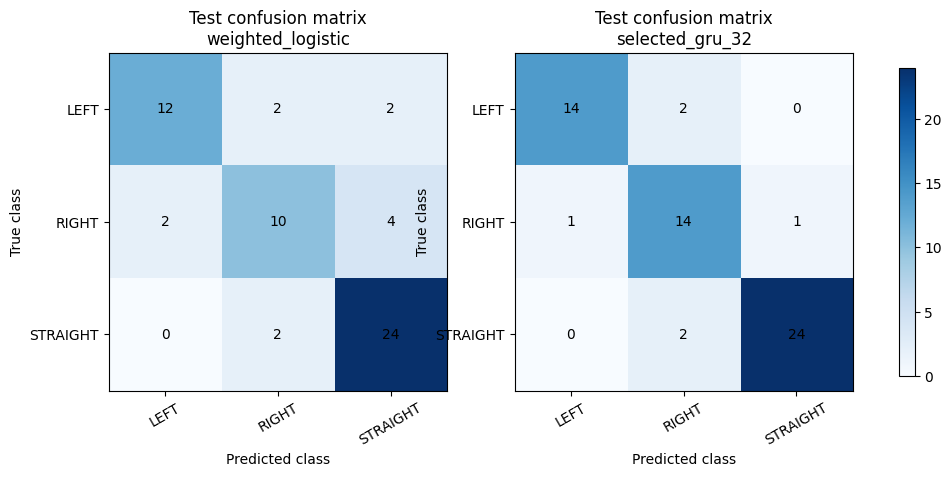

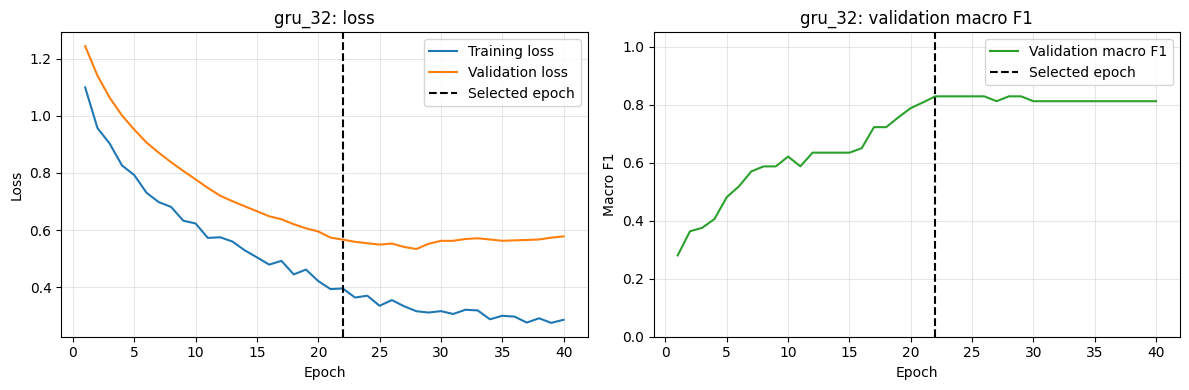


CELL 20 COMPLETED
Selected GRU: gru_32
The architecture was selected using validation macro F1 before test recording 17 was loaded.
The locked GRU and fixed weighted-logistic baseline were each evaluated once on recording 17.

Saved model:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/primary_1.0s_gru/selected_primary_causal_gru.keras

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/primary_1.0s_gru

Next step:
Inspect validation/test macro F1, RIGHT recall, confusion matrices, and the quality checks before deciding whether the GRU should be retained or the logistic baseline should remain the preferred model.


In [ ]:
# Cell 20 — Train and evaluate the primary 1.0-second causal-motion GRU
#
# Run this cell after the UPDATED Cell 19.
#
# Scientific workflow
# -------------------
# 1. Train two deliberately small GRU candidates using recordings 07–14.
# 2. Use recordings 15–16 and validation macro F1 to select the winner.
# 3. Keep recording 17 unused until the winning architecture is locked.
# 4. Evaluate the locked GRU and a fixed logistic baseline on recording 17.
#
# Primary prediction lead time: 1.0 second before conflict entry.
# Input: 48 timesteps × 6 causal, approach-relative motion features.

from pathlib import Path
import json
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    log_loss,
)


# ============================================================
# 1. CHECK CELL 19 OUTPUT
# ============================================================

required_variables = [
    "FINAL_GRU_PREPARED_DATASETS",
    "FINAL_PRIMARY_GRU_DATASET",
    "PRIMARY_GRU_LEAD_TIME_SECONDS",
    "GRU_PREPARATION_OUTPUT_DIRECTORY",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the UPDATED Cell 19 before Cell 20.\n"
        f"Missing variables: {missing_variables}"
    )

if not np.isclose(
    float(PRIMARY_GRU_LEAD_TIME_SECONDS),
    1.0,
):
    raise ValueError(
        "Cell 20 expects the primary lead time to be 1.0 second."
    )


# ============================================================
# 2. IMPORT TENSORFLOW
# ============================================================

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras import regularizers
except ImportError as error:
    raise ImportError(
        "TensorFlow is not available. In Google Colab, select "
        "'Runtime > Restart session', rerun Cells 14–19, and then "
        "run Cell 20 again."
    ) from error


# ============================================================
# 3. REPRODUCIBILITY AND TRAINING CONFIGURATION
# ============================================================

RANDOM_SEED = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    warnings.warn(
        "Full TensorFlow operation determinism could not be enabled. "
        "The random seed is still fixed.",
        RuntimeWarning,
    )

PRIMARY_LEAD_TIME_SECONDS = 1.0
CLASS_INDICES = np.array([0, 1, 2], dtype=np.int64)

INDEX_TO_CLASS_GRU = dict(
    globals().get(
        "INDEX_TO_CLASS",
        {
            0: "LEFT",
            1: "RIGHT",
            2: "STRAIGHT",
        },
    )
)

MAXIMUM_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 18
MINIMUM_MACRO_F1_IMPROVEMENT = 1e-4
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
L2_REGULARIZATION = 1e-4

# Only two small candidates are compared. This limits validation
# overfitting on the small 51-sequence validation set.
GRU_CANDIDATE_CONFIGURATIONS = [
    {
        "candidate_name": "gru_16",
        "gru_units": 16,
        "dropout_rate": 0.10,
    },
    {
        "candidate_name": "gru_32",
        "gru_units": 32,
        "dropout_rate": 0.20,
    },
]

PRIMARY_GRU_OUTPUT_DIRECTORY = (
    Path(GRU_PREPARATION_OUTPUT_DIRECTORY)
    / "primary_1.0s_gru"
)

PRIMARY_GRU_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 4. LOAD TRAINING AND VALIDATION DATA ONLY
# ============================================================

primary_dataset = FINAL_PRIMARY_GRU_DATASET

X_train = np.asarray(
    primary_dataset["X_train"],
    dtype=np.float32,
)

y_train = np.asarray(
    primary_dataset["y_train"],
    dtype=np.int64,
)

X_validation = np.asarray(
    primary_dataset["X_validation"],
    dtype=np.float32,
)

y_validation = np.asarray(
    primary_dataset["y_validation"],
    dtype=np.int64,
)

training_class_weights = {
    int(class_index): float(class_weight)
    for class_index, class_weight
    in primary_dataset[
        "training_class_weights"
    ].items()
}

feature_names = list(
    primary_dataset["feature_names"]
)

if X_train.ndim != 3 or X_validation.ndim != 3:
    raise ValueError(
        "Training and validation arrays must have shape "
        "(sequences, timesteps, features)."
    )

if X_train.shape[1:] != X_validation.shape[1:]:
    raise ValueError(
        "Training and validation sequence shapes do not match."
    )

if X_train.shape[2] != len(feature_names):
    raise ValueError(
        "The number of causal feature names does not match X."
    )

if not (
    np.isfinite(X_train).all()
    and np.isfinite(X_validation).all()
):
    raise ValueError(
        "Training or validation sequences contain NaN or infinity."
    )

if set(np.unique(y_train)) != set(CLASS_INDICES):
    raise ValueError(
        "Training data does not contain all three classes."
    )

if set(np.unique(y_validation)) != set(CLASS_INDICES):
    raise ValueError(
        "Validation data does not contain all three classes."
    )

print("Primary GRU dataset:")
print("  Training shape:", X_train.shape)
print("  Validation shape:", X_validation.shape)
print("  Feature names:", feature_names)
print("  Training class weights:", training_class_weights)
print(
    "\nTest recording 17 has not been loaded for "
    "architecture selection."
)


# ============================================================
# 5. METRIC HELPERS
# ============================================================

def calculate_classification_metrics(
    y_true,
    predicted_class,
    predicted_probability,
):
    """Calculate overall and per-class classification metrics."""

    overall_metrics = {
        "sequence_count":
            int(len(y_true)),
        "accuracy":
            float(
                accuracy_score(
                    y_true,
                    predicted_class,
                )
            ),
        "balanced_accuracy":
            float(
                balanced_accuracy_score(
                    y_true,
                    predicted_class,
                )
            ),
        "macro_precision":
            float(
                precision_score(
                    y_true,
                    predicted_class,
                    labels=CLASS_INDICES,
                    average="macro",
                    zero_division=0,
                )
            ),
        "macro_recall":
            float(
                recall_score(
                    y_true,
                    predicted_class,
                    labels=CLASS_INDICES,
                    average="macro",
                    zero_division=0,
                )
            ),
        "macro_f1":
            float(
                f1_score(
                    y_true,
                    predicted_class,
                    labels=CLASS_INDICES,
                    average="macro",
                    zero_division=0,
                )
            ),
        "weighted_f1":
            float(
                f1_score(
                    y_true,
                    predicted_class,
                    labels=CLASS_INDICES,
                    average="weighted",
                    zero_division=0,
                )
            ),
        "log_loss":
            float(
                log_loss(
                    y_true,
                    predicted_probability,
                    labels=CLASS_INDICES,
                )
            ),
    }

    (
        class_precision,
        class_recall,
        class_f1,
        class_support,
    ) = precision_recall_fscore_support(
        y_true,
        predicted_class,
        labels=CLASS_INDICES,
        zero_division=0,
    )

    per_class_rows = []

    for position, class_index in enumerate(
        CLASS_INDICES
    ):
        per_class_rows.append({
            "class_index":
                int(class_index),
            "manoeuvre_label":
                INDEX_TO_CLASS_GRU.get(
                    int(class_index),
                    str(class_index),
                ),
            "precision":
                float(class_precision[position]),
            "recall":
                float(class_recall[position]),
            "f1":
                float(class_f1[position]),
            "support":
                int(class_support[position]),
        })

    return overall_metrics, per_class_rows


def create_sequence_summary_features(sequence_tensor):
    """
    Create the fixed logistic-regression baseline summaries.

    Summary types:
      first, final, mean, standard deviation, minimum, maximum,
      total change and temporal slope.
    """

    sequence_tensor = np.asarray(
        sequence_tensor,
        dtype=np.float64,
    )

    timestep_axis = np.arange(
        sequence_tensor.shape[1],
        dtype=np.float64,
    )

    centered_time = (
        timestep_axis
        - timestep_axis.mean()
    )

    slope_denominator = np.sum(
        centered_time ** 2
    )

    temporal_slope = np.einsum(
        "ntf,t->nf",
        sequence_tensor,
        centered_time,
    ) / slope_denominator

    return np.concatenate(
        [
            sequence_tensor[:, 0, :],
            sequence_tensor[:, -1, :],
            sequence_tensor.mean(axis=1),
            sequence_tensor.std(axis=1),
            sequence_tensor.min(axis=1),
            sequence_tensor.max(axis=1),
            (
                sequence_tensor[:, -1, :]
                - sequence_tensor[:, 0, :]
            ),
            temporal_slope,
        ],
        axis=1,
    )


# ============================================================
# 6. VALIDATION-MACRO-F1 EARLY STOPPING
# ============================================================

class ValidationMacroF1EarlyStopping(
    keras.callbacks.Callback
):
    """
    Stop training based only on validation macro F1.

    The callback restores the weights from the epoch with the best
    validation macro F1.
    """

    def __init__(
        self,
        validation_X,
        validation_y,
        patience,
        minimum_improvement,
    ):
        super().__init__()

        self.validation_X = validation_X
        self.validation_y = validation_y
        self.patience = int(patience)
        self.minimum_improvement = float(
            minimum_improvement
        )

        self.best_macro_f1 = -np.inf
        self.best_epoch = 0
        self.best_weights = None
        self.wait = 0

        self.validation_macro_f1_history = []
        self.validation_accuracy_history = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}

        validation_probability = self.model.predict(
            self.validation_X,
            verbose=0,
        )

        validation_prediction = np.argmax(
            validation_probability,
            axis=1,
        )

        validation_macro_f1 = float(
            f1_score(
                self.validation_y,
                validation_prediction,
                labels=CLASS_INDICES,
                average="macro",
                zero_division=0,
            )
        )

        validation_accuracy = float(
            accuracy_score(
                self.validation_y,
                validation_prediction,
            )
        )

        self.validation_macro_f1_history.append(
            validation_macro_f1
        )

        self.validation_accuracy_history.append(
            validation_accuracy
        )

        logs["val_macro_f1"] = validation_macro_f1

        improved = (
            validation_macro_f1
            > self.best_macro_f1
            + self.minimum_improvement
        )

        if improved:
            self.best_macro_f1 = (
                validation_macro_f1
            )
            self.best_epoch = int(epoch + 1)
            self.best_weights = (
                self.model.get_weights()
            )
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(
                self.best_weights
            )


# ============================================================
# 7. SMALL GRU BUILDER
# ============================================================

def build_small_gru(
    input_shape,
    gru_units,
    dropout_rate,
):
    """Build one intentionally small regularized GRU."""

    model = keras.Sequential(
        [
            keras.Input(
                shape=input_shape,
                name="causal_motion_sequence",
            ),
            layers.GRU(
                int(gru_units),
                kernel_regularizer=
                    regularizers.l2(
                        L2_REGULARIZATION
                    ),
                recurrent_regularizer=
                    regularizers.l2(
                        L2_REGULARIZATION
                    ),
                name="gru_encoder",
            ),
            layers.Dropout(
                float(dropout_rate),
                name="gru_dropout",
            ),
            layers.Dense(
                len(CLASS_INDICES),
                activation="softmax",
                name="manoeuvre_probability",
            ),
        ],
        name=f"causal_gru_{int(gru_units)}",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=LEARNING_RATE,
            clipnorm=1.0,
        ),
        loss="sparse_categorical_crossentropy",
        metrics=[
            "accuracy",
        ],
    )

    return model


# ============================================================
# 8. TRAIN CANDIDATES — VALIDATION ONLY
# ============================================================

candidate_rows = []
candidate_per_class_rows = []
candidate_model_weights = {}
candidate_histories = {}

for configuration in GRU_CANDIDATE_CONFIGURATIONS:

    candidate_name = configuration[
        "candidate_name"
    ]

    print("\n" + "=" * 80)
    print(
        f"TRAINING CANDIDATE: {candidate_name}"
    )
    print("=" * 80)

    # Reset the same seed before every candidate so the comparison
    # does not intentionally favor one model through seed selection.
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_SEED)

    model = build_small_gru(
        input_shape=X_train.shape[1:],
        gru_units=configuration[
            "gru_units"
        ],
        dropout_rate=configuration[
            "dropout_rate"
        ],
    )

    macro_f1_callback = (
        ValidationMacroF1EarlyStopping(
            validation_X=X_validation,
            validation_y=y_validation,
            patience=EARLY_STOPPING_PATIENCE,
            minimum_improvement=
                MINIMUM_MACRO_F1_IMPROVEMENT,
        )
    )

    reduce_learning_rate = (
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-5,
            verbose=0,
        )
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(
            X_validation,
            y_validation,
        ),
        epochs=MAXIMUM_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=training_class_weights,
        callbacks=[
            macro_f1_callback,
            reduce_learning_rate,
        ],
        shuffle=True,
        verbose=0,
    )

    validation_probability = model.predict(
        X_validation,
        verbose=0,
    )

    validation_prediction = np.argmax(
        validation_probability,
        axis=1,
    )

    (
        validation_overall_metrics,
        validation_per_class,
    ) = calculate_classification_metrics(
        y_validation,
        validation_prediction,
        validation_probability,
    )

    candidate_row = {
        "candidate_name":
            candidate_name,
        "gru_units":
            int(
                configuration[
                    "gru_units"
                ]
            ),
        "dropout_rate":
            float(
                configuration[
                    "dropout_rate"
                ]
            ),
        "parameter_count":
            int(model.count_params()),
        "epochs_trained":
            int(
                len(
                    macro_f1_callback
                    .validation_macro_f1_history
                )
            ),
        "best_epoch":
            int(
                macro_f1_callback.best_epoch
            ),
        "validation_accuracy":
            validation_overall_metrics[
                "accuracy"
            ],
        "validation_balanced_accuracy":
            validation_overall_metrics[
                "balanced_accuracy"
            ],
        "validation_macro_f1":
            validation_overall_metrics[
                "macro_f1"
            ],
        "validation_log_loss":
            validation_overall_metrics[
                "log_loss"
            ],
    }

    candidate_rows.append(candidate_row)

    for per_class_row in validation_per_class:
        candidate_per_class_rows.append({
            "candidate_name":
                candidate_name,
            "split":
                "validation",
            **per_class_row,
        })

    candidate_model_weights[
        candidate_name
    ] = model.get_weights()

    candidate_history_table = pd.DataFrame({
        "epoch":
            np.arange(
                1,
                len(
                    macro_f1_callback
                    .validation_macro_f1_history
                ) + 1,
            ),
        "training_loss":
            history.history["loss"],
        "validation_loss":
            history.history["val_loss"],
        "training_accuracy":
            history.history["accuracy"],
        "validation_accuracy":
            history.history["val_accuracy"],
        "validation_macro_f1":
            macro_f1_callback
            .validation_macro_f1_history,
    })

    candidate_histories[
        candidate_name
    ] = candidate_history_table

    print(
        f"Best epoch: "
        f"{candidate_row['best_epoch']}"
    )
    print(
        f"Validation macro F1: "
        f"{candidate_row['validation_macro_f1']:.4f}"
    )
    print(
        f"Validation balanced accuracy: "
        f"{candidate_row['validation_balanced_accuracy']:.4f}"
    )


# ============================================================
# 9. LOCK THE WINNING ARCHITECTURE
# ============================================================

FINAL_GRU_CANDIDATE_VALIDATION_RESULTS = (
    pd.DataFrame(candidate_rows)
    .sort_values(
        [
            "validation_macro_f1",
            "validation_log_loss",
            "parameter_count",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

FINAL_GRU_CANDIDATE_PER_CLASS_RESULTS = (
    pd.DataFrame(
        candidate_per_class_rows
    )
    .sort_values(
        [
            "candidate_name",
            "class_index",
        ]
    )
    .reset_index(drop=True)
)

SELECTED_GRU_CANDIDATE_NAME = str(
    FINAL_GRU_CANDIDATE_VALIDATION_RESULTS
    .iloc[0][
        "candidate_name"
    ]
)

SELECTED_GRU_CONFIGURATION = next(
    configuration.copy()
    for configuration
    in GRU_CANDIDATE_CONFIGURATIONS
    if configuration["candidate_name"]
    == SELECTED_GRU_CANDIDATE_NAME
)

FINAL_SELECTED_GRU_TRAINING_HISTORY = (
    candidate_histories[
        SELECTED_GRU_CANDIDATE_NAME
    ].copy()
)

# Rebuild the selected architecture cleanly and load the weights
# restored from its best validation-macro-F1 epoch.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_SEED)

FINAL_SELECTED_GRU_MODEL = build_small_gru(
    input_shape=X_train.shape[1:],
    gru_units=SELECTED_GRU_CONFIGURATION[
        "gru_units"
    ],
    dropout_rate=SELECTED_GRU_CONFIGURATION[
        "dropout_rate"
    ],
)

FINAL_SELECTED_GRU_MODEL.set_weights(
    candidate_model_weights[
        SELECTED_GRU_CANDIDATE_NAME
    ]
)

print("\n" + "=" * 80)
print("VALIDATION-ONLY ARCHITECTURE SELECTION")
print("=" * 80)
display(
    FINAL_GRU_CANDIDATE_VALIDATION_RESULTS
)

print(
    "\nLocked winning architecture:",
    SELECTED_GRU_CANDIDATE_NAME,
)


# ============================================================
# 10. FIXED LOGISTIC BASELINE
# ============================================================

X_train_summary = (
    create_sequence_summary_features(
        X_train
    )
)

X_validation_summary = (
    create_sequence_summary_features(
        X_validation
    )
)

FINAL_PRIMARY_LOGISTIC_BASELINE = (
    LogisticRegression(
        C=1.0,
        class_weight=
            training_class_weights,
        solver="lbfgs",
        max_iter=4000,
        random_state=RANDOM_SEED,
    )
)

FINAL_PRIMARY_LOGISTIC_BASELINE.fit(
    X_train_summary,
    y_train,
)

logistic_validation_probability = (
    FINAL_PRIMARY_LOGISTIC_BASELINE
    .predict_proba(
        X_validation_summary
    )
)

logistic_validation_prediction = np.argmax(
    logistic_validation_probability,
    axis=1,
)


# ============================================================
# 11. ARCHITECTURE IS LOCKED — LOAD TEST RECORDING ONCE
# ============================================================

print(
    "\nArchitecture is now locked. "
    "Loading test recording 17 for one final evaluation."
)

X_test = np.asarray(
    primary_dataset["X_test"],
    dtype=np.float32,
)

y_test = np.asarray(
    primary_dataset["y_test"],
    dtype=np.int64,
)

test_metadata = (
    primary_dataset["test_metadata"]
    .copy()
    .reset_index(drop=True)
)

if X_test.shape[1:] != X_train.shape[1:]:
    raise ValueError(
        "Test sequence shape does not match training sequence shape."
    )

if not np.isfinite(X_test).all():
    raise ValueError(
        "Test data contains NaN or infinite values."
    )

gru_validation_probability = (
    FINAL_SELECTED_GRU_MODEL.predict(
        X_validation,
        verbose=0,
    )
)

gru_validation_prediction = np.argmax(
    gru_validation_probability,
    axis=1,
)

gru_test_probability = (
    FINAL_SELECTED_GRU_MODEL.predict(
        X_test,
        verbose=0,
    )
)

gru_test_prediction = np.argmax(
    gru_test_probability,
    axis=1,
)

X_test_summary = (
    create_sequence_summary_features(
        X_test
    )
)

logistic_test_probability = (
    FINAL_PRIMARY_LOGISTIC_BASELINE
    .predict_proba(
        X_test_summary
    )
)

logistic_test_prediction = np.argmax(
    logistic_test_probability,
    axis=1,
)


# ============================================================
# 12. FINAL VALIDATION AND TEST METRICS
# ============================================================

model_evaluation_items = [
    (
        "weighted_logistic",
        "validation",
        y_validation,
        logistic_validation_prediction,
        logistic_validation_probability,
    ),
    (
        f"selected_{SELECTED_GRU_CANDIDATE_NAME}",
        "validation",
        y_validation,
        gru_validation_prediction,
        gru_validation_probability,
    ),
    (
        "weighted_logistic",
        "test",
        y_test,
        logistic_test_prediction,
        logistic_test_probability,
    ),
    (
        f"selected_{SELECTED_GRU_CANDIDATE_NAME}",
        "test",
        y_test,
        gru_test_prediction,
        gru_test_probability,
    ),
]

final_overall_rows = []
final_per_class_rows = []
confusion_matrices = {}

for (
    model_name,
    split_name,
    y_true,
    predicted_class,
    predicted_probability,
) in model_evaluation_items:

    overall_metrics, per_class_metrics = (
        calculate_classification_metrics(
            y_true,
            predicted_class,
            predicted_probability,
        )
    )

    final_overall_rows.append({
        "lead_time_seconds":
            PRIMARY_LEAD_TIME_SECONDS,
        "model_name":
            model_name,
        "split":
            split_name,
        **overall_metrics,
    })

    for per_class_row in per_class_metrics:
        final_per_class_rows.append({
            "lead_time_seconds":
                PRIMARY_LEAD_TIME_SECONDS,
            "model_name":
                model_name,
            "split":
                split_name,
            **per_class_row,
        })

    confusion_matrices[
        (
            model_name,
            split_name,
        )
    ] = confusion_matrix(
        y_true,
        predicted_class,
        labels=CLASS_INDICES,
    )

FINAL_PRIMARY_MODEL_OVERALL_METRICS = (
    pd.DataFrame(
        final_overall_rows
    )
    .sort_values(
        [
            "split",
            "model_name",
        ]
    )
    .reset_index(drop=True)
)

FINAL_PRIMARY_MODEL_PER_CLASS_METRICS = (
    pd.DataFrame(
        final_per_class_rows
    )
    .sort_values(
        [
            "split",
            "model_name",
            "class_index",
        ]
    )
    .reset_index(drop=True)
)

FINAL_PRIMARY_MODEL_CONFUSION_MATRICES = (
    confusion_matrices
)


# ============================================================
# 13. FINAL PREDICTION TABLE
# ============================================================

FINAL_PRIMARY_TEST_PREDICTIONS = (
    test_metadata.copy()
)

FINAL_PRIMARY_TEST_PREDICTIONS[
    "true_class_index"
] = y_test

FINAL_PRIMARY_TEST_PREDICTIONS[
    "logistic_predicted_class_index"
] = logistic_test_prediction

FINAL_PRIMARY_TEST_PREDICTIONS[
    "gru_predicted_class_index"
] = gru_test_prediction

FINAL_PRIMARY_TEST_PREDICTIONS[
    "logistic_correct"
] = (
    logistic_test_prediction
    == y_test
)

FINAL_PRIMARY_TEST_PREDICTIONS[
    "gru_correct"
] = (
    gru_test_prediction
    == y_test
)

for class_index in CLASS_INDICES:
    class_name = INDEX_TO_CLASS_GRU.get(
        int(class_index),
        str(class_index),
    ).lower()

    FINAL_PRIMARY_TEST_PREDICTIONS[
        f"logistic_probability_{class_name}"
    ] = logistic_test_probability[
        :,
        int(class_index),
    ]

    FINAL_PRIMARY_TEST_PREDICTIONS[
        f"gru_probability_{class_name}"
    ] = gru_test_probability[
        :,
        int(class_index),
    ]


# ============================================================
# 14. QUALITY CHECKS
# ============================================================

FINAL_PRIMARY_GRU_QUALITY_CHECKS = pd.DataFrame(
    [
        {
            "lead_time_seconds":
                PRIMARY_LEAD_TIME_SECONDS,
            "selected_candidate":
                SELECTED_GRU_CANDIDATE_NAME,
            "training_sequence_count":
                int(len(X_train)),
            "validation_sequence_count":
                int(len(X_validation)),
            "test_sequence_count":
                int(len(X_test)),
            "input_shape":
                str(tuple(X_train.shape[1:])),
            "candidate_count":
                int(
                    len(
                        GRU_CANDIDATE_CONFIGURATIONS
                    )
                ),
            "selected_using_validation_only":
                True,
            "test_loaded_after_selection":
                True,
            "class_weights_training_only":
                True,
            "causal_features_only":
                bool(
                    feature_names
                    == list(
                        primary_dataset[
                            "feature_names"
                        ]
                    )
                ),
            "all_probabilities_finite":
                bool(
                    np.isfinite(
                        gru_test_probability
                    ).all()
                    and np.isfinite(
                        logistic_test_probability
                    ).all()
                ),
            "gru_probabilities_sum_to_one":
                bool(
                    np.allclose(
                        gru_test_probability.sum(
                            axis=1
                        ),
                        1.0,
                        atol=1e-6,
                    )
                ),
            "logistic_probabilities_sum_to_one":
                bool(
                    np.allclose(
                        logistic_test_probability.sum(
                            axis=1
                        ),
                        1.0,
                        atol=1e-6,
                    )
                ),
        }
    ]
)


# ============================================================
# 15. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("FINAL PRIMARY MODEL — OVERALL METRICS")
print("=" * 80)
display(
    FINAL_PRIMARY_MODEL_OVERALL_METRICS
)

print("\n" + "=" * 80)
print("FINAL PRIMARY MODEL — PER-CLASS METRICS")
print("=" * 80)
display(
    FINAL_PRIMARY_MODEL_PER_CLASS_METRICS
)

print("\n" + "=" * 80)
print("QUALITY CHECKS")
print("=" * 80)
display(
    FINAL_PRIMARY_GRU_QUALITY_CHECKS
)


selected_gru_model_name = (
    f"selected_{SELECTED_GRU_CANDIDATE_NAME}"
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

for axis, model_name in zip(
    axes,
    [
        "weighted_logistic",
        selected_gru_model_name,
    ],
):
    matrix = FINAL_PRIMARY_MODEL_CONFUSION_MATRICES[
        (
            model_name,
            "test",
        )
    ]

    image = axis.imshow(
        matrix,
        cmap="Blues",
    )

    axis.set_title(
        f"Test confusion matrix\n{model_name}"
    )
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
    axis.set_xticks(
        range(len(CLASS_INDICES))
    )
    axis.set_yticks(
        range(len(CLASS_INDICES))
    )
    axis.set_xticklabels(
        [
            INDEX_TO_CLASS_GRU[
                int(class_index)
            ]
            for class_index in CLASS_INDICES
        ],
        rotation=30,
    )
    axis.set_yticklabels(
        [
            INDEX_TO_CLASS_GRU[
                int(class_index)
            ]
            for class_index in CLASS_INDICES
        ]
    )

    for row_index in range(matrix.shape[0]):
        for column_index in range(
            matrix.shape[1]
        ):
            axis.text(
                column_index,
                row_index,
                int(
                    matrix[
                        row_index,
                        column_index,
                    ]
                ),
                ha="center",
                va="center",
            )

figure.colorbar(
    image,
    ax=axes.ravel().tolist(),
    shrink=0.8,
)
plt.show()


history_table = (
    FINAL_SELECTED_GRU_TRAINING_HISTORY
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

axes[0].plot(
    history_table["epoch"],
    history_table["training_loss"],
    label="Training loss",
)

axes[0].plot(
    history_table["epoch"],
    history_table["validation_loss"],
    label="Validation loss",
)

axes[0].axvline(
    int(
        FINAL_GRU_CANDIDATE_VALIDATION_RESULTS
        .iloc[0]["best_epoch"]
    ),
    color="black",
    linestyle="--",
    label="Selected epoch",
)

axes[0].set_title(
    f"{SELECTED_GRU_CANDIDATE_NAME}: loss"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_table["epoch"],
    history_table[
        "validation_macro_f1"
    ],
    color="tab:green",
    label="Validation macro F1",
)

axes[1].axvline(
    int(
        FINAL_GRU_CANDIDATE_VALIDATION_RESULTS
        .iloc[0]["best_epoch"]
    ),
    color="black",
    linestyle="--",
    label="Selected epoch",
)

axes[1].set_title(
    f"{SELECTED_GRU_CANDIDATE_NAME}: validation macro F1"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 16. EXPORT MODEL AND RESULTS
# ============================================================

selected_model_path = (
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "selected_primary_causal_gru.keras"
)

FINAL_SELECTED_GRU_MODEL.save(
    selected_model_path
)

FINAL_GRU_CANDIDATE_VALIDATION_RESULTS.to_csv(
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "gru_candidate_validation_results.csv",
    index=False,
)

FINAL_GRU_CANDIDATE_PER_CLASS_RESULTS.to_csv(
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "gru_candidate_validation_per_class.csv",
    index=False,
)

FINAL_SELECTED_GRU_TRAINING_HISTORY.to_csv(
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "selected_gru_training_history.csv",
    index=False,
)

FINAL_PRIMARY_MODEL_OVERALL_METRICS.to_csv(
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "primary_model_overall_metrics.csv",
    index=False,
)

FINAL_PRIMARY_MODEL_PER_CLASS_METRICS.to_csv(
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "primary_model_per_class_metrics.csv",
    index=False,
)

FINAL_PRIMARY_TEST_PREDICTIONS.to_csv(
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "primary_test_predictions.csv",
    index=False,
)

FINAL_PRIMARY_GRU_QUALITY_CHECKS.to_csv(
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "primary_gru_quality_checks.csv",
    index=False,
)

model_manifest = {
    "model_file":
        selected_model_path.name,
    "selected_candidate":
        SELECTED_GRU_CANDIDATE_NAME,
    "selected_configuration":
        SELECTED_GRU_CONFIGURATION,
    "primary_lead_time_seconds":
        PRIMARY_LEAD_TIME_SECONDS,
    "observation_timestep_count":
        int(X_train.shape[1]),
    "feature_count":
        int(X_train.shape[2]),
    "feature_names":
        feature_names,
    "class_mapping":
        {
            str(class_index):
                INDEX_TO_CLASS_GRU[
                    int(class_index)
                ]
            for class_index in CLASS_INDICES
        },
    "training_recording_ids":
        [
            7, 8, 9, 10,
            11, 12, 13, 14,
        ],
    "validation_recording_ids":
        [15, 16],
    "test_recording_ids":
        [17],
    "random_seed":
        RANDOM_SEED,
    "selection_metric":
        "validation_macro_f1",
    "test_evaluation_policy":
        "evaluated_once_after_architecture_selection",
}

with open(
    PRIMARY_GRU_OUTPUT_DIRECTORY
    / "primary_gru_manifest.json",
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        model_manifest,
        manifest_file,
        indent=2,
    )


# ============================================================
# 17. COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("CELL 20 COMPLETED")
print("=" * 80)

print(
    "Selected GRU:",
    SELECTED_GRU_CANDIDATE_NAME,
)

print(
    "The architecture was selected using validation macro F1 "
    "before test recording 17 was loaded."
)

print(
    "The locked GRU and fixed weighted-logistic baseline were "
    "each evaluated once on recording 17."
)

print("\nSaved model:")
print(f"  {selected_model_path}")

print("\nOutput directory:")
print(
    f"  {PRIMARY_GRU_OUTPUT_DIRECTORY}"
)

print("\nNext step:")
print(
    "Inspect validation/test macro F1, RIGHT recall, confusion "
    "matrices, and the quality checks before deciding whether "
    "the GRU should be retained or the logistic baseline should "
    "remain the preferred model."
)


Secondary 0.5-second dataset:
  Training shape: (145, 48, 6)
  Validation shape: (51, 48, 6)
  Reused architecture: {'candidate_name': 'gru_32', 'gru_units': 32, 'dropout_rate': 0.2}
  Training class weights: {0: 0.8630952380952381, 1: 4.027777777777778, 2: 0.6277056277056277}

No new architecture search will be performed.
Test recording 17 has not been loaded yet.



Fixed secondary GRU training completed.
  Best validation epoch: 44

The secondary architecture was fixed before training. Loading test recording 17 for one evaluation.

SECONDARY 0.5-SECOND MODEL — OVERALL METRICS


,lead_time_seconds,model_name,split,sequence_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss
0,0.5,selected_gru_32,test,58,0.931034,0.916667,0.934524,0.916667,0.923765,0.930524,0.245352
1,0.5,weighted_logistic,test,58,0.879310,0.862179,0.865722,0.862179,0.859101,0.876762,0.512007
2,0.5,selected_gru_32,validation,51,0.901961,0.924603,0.856852,0.924603,0.878723,0.905257,0.484789
3,0.5,weighted_logistic,validation,51,0.784314,0.755952,0.721045,0.755952,0.721678,0.802749,1.006782



SECONDARY 0.5-SECOND MODEL — PER-CLASS METRICS


,lead_time_seconds,model_name,split,class_index,manoeuvre_label,precision,recall,f1,support
0,0.5,selected_gru_32,test,0,LEFT,0.875000,0.875000,0.875000,16
1,0.5,selected_gru_32,test,1,RIGHT,1.000000,0.875000,0.933333,16
2,0.5,selected_gru_32,test,2,STRAIGHT,0.928571,1.000000,0.962963,26
3,0.5,weighted_logistic,test,0,LEFT,0.789474,0.937500,0.857143,16
4,0.5,weighted_logistic,test,1,RIGHT,0.846154,0.687500,0.758621,16
5,0.5,weighted_logistic,test,2,STRAIGHT,0.961538,0.961538,0.961538,26
6,0.5,selected_gru_32,validation,0,LEFT,0.956522,0.916667,0.936170,24
7,0.5,selected_gru_32,validation,1,RIGHT,0.666667,1.000000,0.800000,6
8,0.5,selected_gru_32,validation,2,STRAIGHT,0.947368,0.857143,0.900000,21
9,0.5,weighted_logistic,validation,0,LEFT,0.904762,0.791667,0.844444,24


...

,lead_time_seconds,model_name,split,sequence_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,log_loss
0,1.0,selected_gru_32,test,58,0.896552,0.891026,0.890370,0.891026,0.889311,0.898253,0.424631
1,1.0,weighted_logistic,test,58,0.793103,0.766026,0.790476,0.766026,0.774603,0.788834,0.754160
2,0.5,selected_gru_32,test,58,0.931034,0.916667,0.934524,0.916667,0.923765,0.930524,0.245352
3,0.5,weighted_logistic,test,58,0.879310,0.862179,0.865722,0.862179,0.859101,0.876762,0.512007
4,1.0,selected_gru_32,validation,51,0.862745,0.892857,0.820707,0.892857,0.829138,0.870538,0.560828
5,1.0,weighted_logistic,validation,51,0.745098,0.682540,0.674882,0.682540,0.664493,0.767101,0.887853
6,0.5,selected_gru_32,validation,51,0.901961,0.924603,0.856852,0.924603,0.878723,0.905257,0.484789
7,0.5,weighted_logistic,validation,51,0.784314,0.755952,0.721045,0.755952,0.721678,0.802749,1.006782



PAIRED TEST-VEHICLE GRU COMPARISON


,comparison,vehicle_count
0,correct_at_both_horizons,49
1,correct_only_at_1.0s,3
2,correct_only_at_0.5s,5
3,wrong_at_both_horizons,1



QUALITY CHECKS


,lead_time_seconds,architecture_name,gru_units,dropout_rate,best_validation_epoch,training_sequence_count,validation_sequence_count,test_sequence_count,input_shape,architecture_reused_without_search,validation_used_for_early_stopping_only,test_loaded_after_training,training_only_scaling_reused,training_only_class_weights_reused,causal_features_only,gru_probabilities_finite,gru_probabilities_sum_to_one,logistic_probabilities_finite,logistic_probabilities_sum_to_one,primary_secondary_test_labels_aligned
0,0.5,gru_32,32,0.2,44,145,51,58,"(48, 6)",True,True,True,True,True,True,True,True,True,True,True


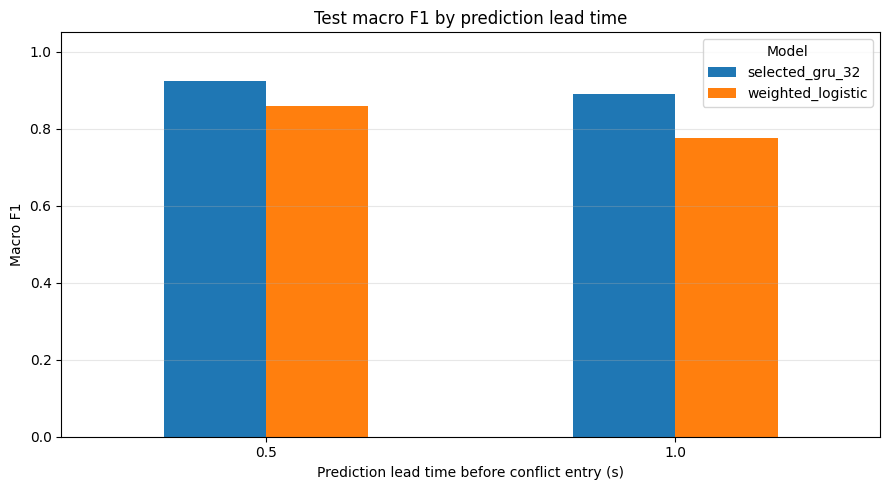

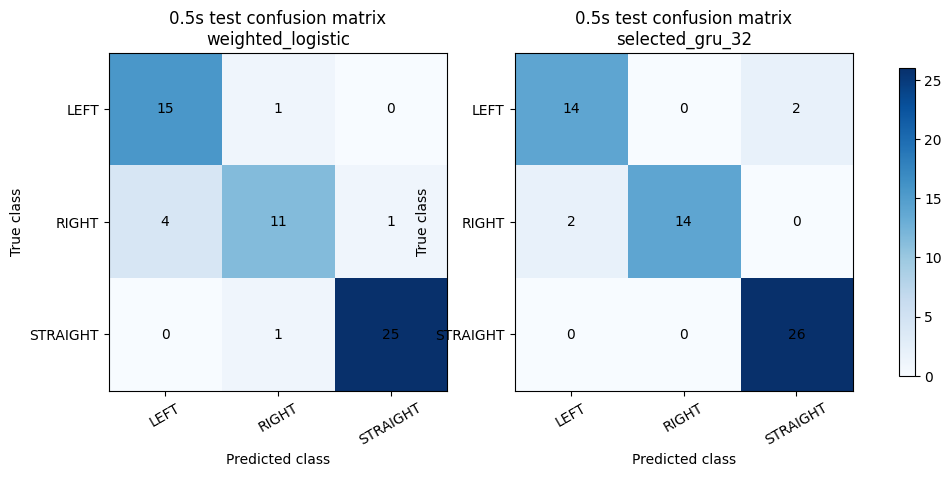

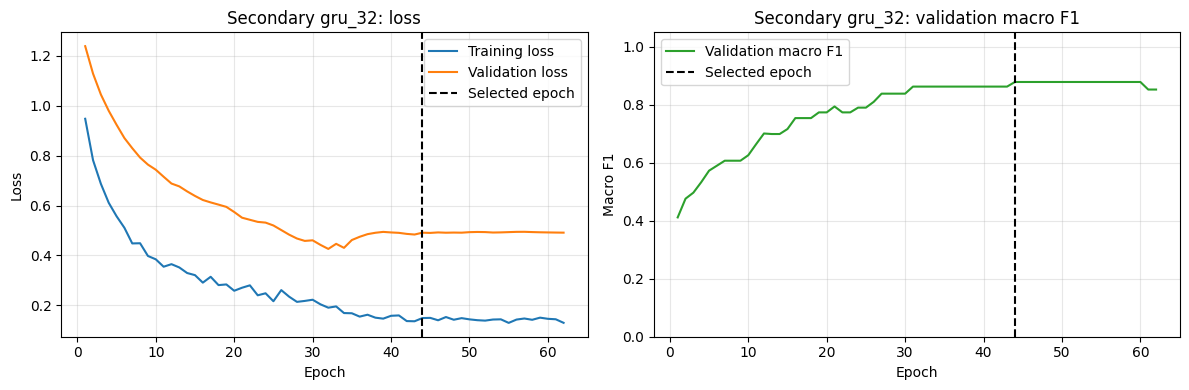


CELL 21 COMPLETED
The fixed gru_32 architecture was trained at the secondary 0.5-second lead time without another architecture search.
The primary and secondary horizons now have directly comparable validation and test results.

Saved secondary model:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/secondary_0.5s_gru/selected_secondary_causal_gru.keras

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/secondary_0.5s_gru

Next step:
Audit probability calibration on validation data and define a validation-selected confidence threshold that returns UNKNOWN for uncertain predictions before SUMO integration.


In [ ]:
# Cell 21 — Train the fixed secondary 0.5-second causal-motion GRU
#
# Run this cell after the UPDATED Cell 20.
#
# Purpose
# -------
# Cell 20 selected and locked the 32-unit GRU architecture using the
# primary 1.0-second validation data.
#
# This cell reuses that exact architecture at the secondary 0.5-second
# lead time. It does NOT conduct another architecture search.
#
# Workflow
# --------
# 1. Train on recordings 07–14.
# 2. Use recordings 15–16 only for early stopping.
# 3. Load test recording 17 only after training has stopped.
# 4. Evaluate the fixed GRU and weighted-logistic baseline once.
# 5. Compare the predefined 0.5-second and 1.0-second horizons.

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
)


# ============================================================
# 1. CHECK REQUIRED CELL 20 OUTPUTS
# ============================================================

required_variables = [
    "FINAL_SECONDARY_GRU_DATASET",
    "SELECTED_GRU_CANDIDATE_NAME",
    "SELECTED_GRU_CONFIGURATION",
    "FINAL_PRIMARY_MODEL_OVERALL_METRICS",
    "FINAL_PRIMARY_MODEL_PER_CLASS_METRICS",
    "FINAL_PRIMARY_TEST_PREDICTIONS",
    "GRU_PREPARATION_OUTPUT_DIRECTORY",
    "RANDOM_SEED",
    "MAXIMUM_EPOCHS",
    "EARLY_STOPPING_PATIENCE",
    "MINIMUM_MACRO_F1_IMPROVEMENT",
    "BATCH_SIZE",
    "CLASS_INDICES",
    "INDEX_TO_CLASS_GRU",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

required_functions = [
    "build_small_gru",
    "ValidationMacroF1EarlyStopping",
    "calculate_classification_metrics",
    "create_sequence_summary_features",
]

missing_functions = [
    function_name
    for function_name in required_functions
    if (
        function_name not in globals()
        or not callable(
            globals()[function_name]
        )
    )
]

if missing_variables or missing_functions:
    raise NameError(
        "Run the UPDATED Cells 19 and 20 before Cell 21.\n"
        f"Missing variables: {missing_variables}\n"
        f"Missing functions: {missing_functions}"
    )

if SELECTED_GRU_CANDIDATE_NAME != "gru_32":
    raise ValueError(
        "Cell 21 expects Cell 20 to have locked gru_32. "
        f"Received {SELECTED_GRU_CANDIDATE_NAME!r}."
    )

if int(
    SELECTED_GRU_CONFIGURATION[
        "gru_units"
    ]
) != 32:
    raise ValueError(
        "The locked GRU configuration does not contain 32 units."
    )

if not np.isclose(
    float(
        SELECTED_GRU_CONFIGURATION[
            "dropout_rate"
        ]
    ),
    0.20,
):
    raise ValueError(
        "The locked GRU configuration does not use dropout 0.20."
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

SECONDARY_LEAD_TIME_SECONDS = 0.5

SECONDARY_GRU_OUTPUT_DIRECTORY = (
    Path(GRU_PREPARATION_OUTPUT_DIRECTORY)
    / "secondary_0.5s_gru"
)

SECONDARY_GRU_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 3. LOAD TRAINING AND VALIDATION DATA ONLY
# ============================================================

secondary_dataset = (
    FINAL_SECONDARY_GRU_DATASET
)

if not np.isclose(
    float(
        secondary_dataset[
            "lead_time_seconds"
        ]
    ),
    SECONDARY_LEAD_TIME_SECONDS,
):
    raise ValueError(
        "FINAL_SECONDARY_GRU_DATASET is not the 0.5-second dataset."
    )

X_secondary_train = np.asarray(
    secondary_dataset["X_train"],
    dtype=np.float32,
)

y_secondary_train = np.asarray(
    secondary_dataset["y_train"],
    dtype=np.int64,
)

X_secondary_validation = np.asarray(
    secondary_dataset["X_validation"],
    dtype=np.float32,
)

y_secondary_validation = np.asarray(
    secondary_dataset["y_validation"],
    dtype=np.int64,
)

secondary_class_weights = {
    int(class_index): float(class_weight)
    for class_index, class_weight
    in secondary_dataset[
        "training_class_weights"
    ].items()
}

secondary_feature_names = list(
    secondary_dataset["feature_names"]
)

if (
    X_secondary_train.ndim != 3
    or X_secondary_validation.ndim != 3
):
    raise ValueError(
        "Secondary training and validation arrays must be 3-D."
    )

if (
    X_secondary_train.shape[1:]
    != X_secondary_validation.shape[1:]
):
    raise ValueError(
        "Secondary training and validation input shapes differ."
    )

if not (
    np.isfinite(
        X_secondary_train
    ).all()
    and np.isfinite(
        X_secondary_validation
    ).all()
):
    raise ValueError(
        "Secondary training or validation data contains "
        "NaN or infinity."
    )

if (
    set(
        np.unique(
            y_secondary_train
        )
    )
    != set(CLASS_INDICES)
):
    raise ValueError(
        "Secondary training data does not contain all classes."
    )

if (
    set(
        np.unique(
            y_secondary_validation
        )
    )
    != set(CLASS_INDICES)
):
    raise ValueError(
        "Secondary validation data does not contain all classes."
    )

print("Secondary 0.5-second dataset:")
print(
    "  Training shape:",
    X_secondary_train.shape,
)
print(
    "  Validation shape:",
    X_secondary_validation.shape,
)
print(
    "  Reused architecture:",
    SELECTED_GRU_CONFIGURATION,
)
print(
    "  Training class weights:",
    secondary_class_weights,
)
print(
    "\nNo new architecture search will be performed."
)
print(
    "Test recording 17 has not been loaded yet."
)


# ============================================================
# 4. TRAIN THE FIXED GRU_32 ARCHITECTURE
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(
    RANDOM_SEED
)

FINAL_SECONDARY_GRU_MODEL = (
    build_small_gru(
        input_shape=
            X_secondary_train.shape[1:],
        gru_units=
            SELECTED_GRU_CONFIGURATION[
                "gru_units"
            ],
        dropout_rate=
            SELECTED_GRU_CONFIGURATION[
                "dropout_rate"
            ],
    )
)

secondary_macro_f1_callback = (
    ValidationMacroF1EarlyStopping(
        validation_X=
            X_secondary_validation,
        validation_y=
            y_secondary_validation,
        patience=
            EARLY_STOPPING_PATIENCE,
        minimum_improvement=
            MINIMUM_MACRO_F1_IMPROVEMENT,
    )
)

secondary_reduce_learning_rate = (
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-5,
        verbose=0,
    )
)

secondary_training_history = (
    FINAL_SECONDARY_GRU_MODEL.fit(
        X_secondary_train,
        y_secondary_train,
        validation_data=(
            X_secondary_validation,
            y_secondary_validation,
        ),
        epochs=MAXIMUM_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=
            secondary_class_weights,
        callbacks=[
            secondary_macro_f1_callback,
            secondary_reduce_learning_rate,
        ],
        shuffle=True,
        verbose=0,
    )
)

FINAL_SECONDARY_GRU_TRAINING_HISTORY = (
    pd.DataFrame(
        {
            "epoch":
                np.arange(
                    1,
                    len(
                        secondary_macro_f1_callback
                        .validation_macro_f1_history
                    ) + 1,
                ),
            "training_loss":
                secondary_training_history
                .history["loss"],
            "validation_loss":
                secondary_training_history
                .history["val_loss"],
            "training_accuracy":
                secondary_training_history
                .history["accuracy"],
            "validation_accuracy":
                secondary_training_history
                .history["val_accuracy"],
            "validation_macro_f1":
                secondary_macro_f1_callback
                .validation_macro_f1_history,
        }
    )
)

SECONDARY_GRU_BEST_EPOCH = int(
    secondary_macro_f1_callback.best_epoch
)

print("\nFixed secondary GRU training completed.")
print(
    "  Best validation epoch:",
    SECONDARY_GRU_BEST_EPOCH,
)


# ============================================================
# 5. VALIDATION PREDICTIONS
# ============================================================

secondary_gru_validation_probability = (
    FINAL_SECONDARY_GRU_MODEL.predict(
        X_secondary_validation,
        verbose=0,
    )
)

secondary_gru_validation_prediction = (
    np.argmax(
        secondary_gru_validation_probability,
        axis=1,
    )
)

# Fixed logistic baseline using the exact causal input and split.
X_secondary_train_summary = (
    create_sequence_summary_features(
        X_secondary_train
    )
)

X_secondary_validation_summary = (
    create_sequence_summary_features(
        X_secondary_validation
    )
)

FINAL_SECONDARY_LOGISTIC_BASELINE = (
    LogisticRegression(
        C=1.0,
        class_weight=
            secondary_class_weights,
        solver="lbfgs",
        max_iter=4000,
        random_state=RANDOM_SEED,
    )
)

FINAL_SECONDARY_LOGISTIC_BASELINE.fit(
    X_secondary_train_summary,
    y_secondary_train,
)

secondary_logistic_validation_probability = (
    FINAL_SECONDARY_LOGISTIC_BASELINE
    .predict_proba(
        X_secondary_validation_summary
    )
)

secondary_logistic_validation_prediction = (
    np.argmax(
        secondary_logistic_validation_probability,
        axis=1,
    )
)


# ============================================================
# 6. FIXED TRAINING IS COMPLETE — LOAD TEST RECORDING ONCE
# ============================================================

print(
    "\nThe secondary architecture was fixed before training. "
    "Loading test recording 17 for one evaluation."
)

X_secondary_test = np.asarray(
    secondary_dataset["X_test"],
    dtype=np.float32,
)

y_secondary_test = np.asarray(
    secondary_dataset["y_test"],
    dtype=np.int64,
)

secondary_test_metadata = (
    secondary_dataset["test_metadata"]
    .copy()
    .reset_index(drop=True)
)

if (
    X_secondary_test.shape[1:]
    != X_secondary_train.shape[1:]
):
    raise ValueError(
        "Secondary test input shape differs from training."
    )

if not np.isfinite(
    X_secondary_test
).all():
    raise ValueError(
        "Secondary test data contains NaN or infinity."
    )

secondary_gru_test_probability = (
    FINAL_SECONDARY_GRU_MODEL.predict(
        X_secondary_test,
        verbose=0,
    )
)

secondary_gru_test_prediction = np.argmax(
    secondary_gru_test_probability,
    axis=1,
)

X_secondary_test_summary = (
    create_sequence_summary_features(
        X_secondary_test
    )
)

secondary_logistic_test_probability = (
    FINAL_SECONDARY_LOGISTIC_BASELINE
    .predict_proba(
        X_secondary_test_summary
    )
)

secondary_logistic_test_prediction = (
    np.argmax(
        secondary_logistic_test_probability,
        axis=1,
    )
)


# ============================================================
# 7. SECONDARY VALIDATION AND TEST METRICS
# ============================================================

secondary_evaluation_items = [
    (
        "weighted_logistic",
        "validation",
        y_secondary_validation,
        secondary_logistic_validation_prediction,
        secondary_logistic_validation_probability,
    ),
    (
        "selected_gru_32",
        "validation",
        y_secondary_validation,
        secondary_gru_validation_prediction,
        secondary_gru_validation_probability,
    ),
    (
        "weighted_logistic",
        "test",
        y_secondary_test,
        secondary_logistic_test_prediction,
        secondary_logistic_test_probability,
    ),
    (
        "selected_gru_32",
        "test",
        y_secondary_test,
        secondary_gru_test_prediction,
        secondary_gru_test_probability,
    ),
]

secondary_overall_rows = []
secondary_per_class_rows = []
secondary_confusion_matrices = {}

for (
    model_name,
    split_name,
    y_true,
    predicted_class,
    predicted_probability,
) in secondary_evaluation_items:

    (
        overall_metrics,
        per_class_metrics,
    ) = calculate_classification_metrics(
        y_true,
        predicted_class,
        predicted_probability,
    )

    secondary_overall_rows.append({
        "lead_time_seconds":
            SECONDARY_LEAD_TIME_SECONDS,
        "model_name":
            model_name,
        "split":
            split_name,
        **overall_metrics,
    })

    for per_class_row in per_class_metrics:
        secondary_per_class_rows.append({
            "lead_time_seconds":
                SECONDARY_LEAD_TIME_SECONDS,
            "model_name":
                model_name,
            "split":
                split_name,
            **per_class_row,
        })

    secondary_confusion_matrices[
        (
            model_name,
            split_name,
        )
    ] = confusion_matrix(
        y_true,
        predicted_class,
        labels=CLASS_INDICES,
    )

FINAL_SECONDARY_MODEL_OVERALL_METRICS = (
    pd.DataFrame(
        secondary_overall_rows
    )
    .sort_values(
        [
            "split",
            "model_name",
        ]
    )
    .reset_index(drop=True)
)

FINAL_SECONDARY_MODEL_PER_CLASS_METRICS = (
    pd.DataFrame(
        secondary_per_class_rows
    )
    .sort_values(
        [
            "split",
            "model_name",
            "class_index",
        ]
    )
    .reset_index(drop=True)
)

FINAL_SECONDARY_MODEL_CONFUSION_MATRICES = (
    secondary_confusion_matrices
)


# ============================================================
# 8. COMBINE PRIMARY AND SECONDARY RESULTS
# ============================================================

FINAL_ALL_LEAD_TIME_MODEL_METRICS = (
    pd.concat(
        [
            FINAL_PRIMARY_MODEL_OVERALL_METRICS.copy(),
            FINAL_SECONDARY_MODEL_OVERALL_METRICS.copy(),
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "split",
            "lead_time_seconds",
            "model_name",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

FINAL_ALL_LEAD_TIME_PER_CLASS_METRICS = (
    pd.concat(
        [
            FINAL_PRIMARY_MODEL_PER_CLASS_METRICS.copy(),
            FINAL_SECONDARY_MODEL_PER_CLASS_METRICS.copy(),
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "split",
            "lead_time_seconds",
            "model_name",
            "class_index",
        ],
        ascending=[
            True,
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


# ============================================================
# 9. TEST PREDICTIONS AND PAIRED HORIZON COMPARISON
# ============================================================

FINAL_SECONDARY_TEST_PREDICTIONS = (
    secondary_test_metadata.copy()
)

FINAL_SECONDARY_TEST_PREDICTIONS[
    "true_class_index"
] = y_secondary_test

FINAL_SECONDARY_TEST_PREDICTIONS[
    "logistic_predicted_class_index"
] = secondary_logistic_test_prediction

FINAL_SECONDARY_TEST_PREDICTIONS[
    "gru_predicted_class_index"
] = secondary_gru_test_prediction

FINAL_SECONDARY_TEST_PREDICTIONS[
    "logistic_correct"
] = (
    secondary_logistic_test_prediction
    == y_secondary_test
)

FINAL_SECONDARY_TEST_PREDICTIONS[
    "gru_correct"
] = (
    secondary_gru_test_prediction
    == y_secondary_test
)

for class_index in CLASS_INDICES:
    class_name = INDEX_TO_CLASS_GRU.get(
        int(class_index),
        str(class_index),
    ).lower()

    FINAL_SECONDARY_TEST_PREDICTIONS[
        f"logistic_probability_{class_name}"
    ] = secondary_logistic_test_probability[
        :,
        int(class_index),
    ]

    FINAL_SECONDARY_TEST_PREDICTIONS[
        f"gru_probability_{class_name}"
    ] = secondary_gru_test_probability[
        :,
        int(class_index),
    ]


primary_test_true = (
    FINAL_PRIMARY_TEST_PREDICTIONS[
        "true_class_index"
    ].to_numpy(
        dtype=np.int64
    )
)

primary_test_gru_correct = (
    FINAL_PRIMARY_TEST_PREDICTIONS[
        "gru_correct"
    ].to_numpy(
        dtype=bool
    )
)

if not np.array_equal(
    primary_test_true,
    y_secondary_test,
):
    raise ValueError(
        "Primary and secondary test labels are not aligned. "
        "The common-cohort paired comparison cannot be made."
    )

secondary_test_gru_correct = (
    secondary_gru_test_prediction
    == y_secondary_test
)

FINAL_PAIRED_GRU_HORIZON_COMPARISON = (
    pd.DataFrame(
        [
            {
                "comparison":
                    "correct_at_both_horizons",
                "vehicle_count":
                    int(
                        np.sum(
                            primary_test_gru_correct
                            & secondary_test_gru_correct
                        )
                    ),
            },
            {
                "comparison":
                    "correct_only_at_1.0s",
                "vehicle_count":
                    int(
                        np.sum(
                            primary_test_gru_correct
                            & ~secondary_test_gru_correct
                        )
                    ),
            },
            {
                "comparison":
                    "correct_only_at_0.5s",
                "vehicle_count":
                    int(
                        np.sum(
                            ~primary_test_gru_correct
                            & secondary_test_gru_correct
                        )
                    ),
            },
            {
                "comparison":
                    "wrong_at_both_horizons",
                "vehicle_count":
                    int(
                        np.sum(
                            ~primary_test_gru_correct
                            & ~secondary_test_gru_correct
                        )
                    ),
            },
        ]
    )
)


# ============================================================
# 10. QUALITY CHECKS
# ============================================================

FINAL_SECONDARY_GRU_QUALITY_CHECKS = (
    pd.DataFrame(
        [
            {
                "lead_time_seconds":
                    SECONDARY_LEAD_TIME_SECONDS,
                "architecture_name":
                    SELECTED_GRU_CANDIDATE_NAME,
                "gru_units":
                    int(
                        SELECTED_GRU_CONFIGURATION[
                            "gru_units"
                        ]
                    ),
                "dropout_rate":
                    float(
                        SELECTED_GRU_CONFIGURATION[
                            "dropout_rate"
                        ]
                    ),
                "best_validation_epoch":
                    SECONDARY_GRU_BEST_EPOCH,
                "training_sequence_count":
                    int(
                        len(
                            X_secondary_train
                        )
                    ),
                "validation_sequence_count":
                    int(
                        len(
                            X_secondary_validation
                        )
                    ),
                "test_sequence_count":
                    int(
                        len(
                            X_secondary_test
                        )
                    ),
                "input_shape":
                    str(
                        tuple(
                            X_secondary_train
                            .shape[1:]
                        )
                    ),
                "architecture_reused_without_search":
                    True,
                "validation_used_for_early_stopping_only":
                    True,
                "test_loaded_after_training":
                    True,
                "training_only_scaling_reused":
                    True,
                "training_only_class_weights_reused":
                    True,
                "causal_features_only":
                    bool(
                        secondary_feature_names
                        == list(
                            secondary_dataset[
                                "feature_names"
                            ]
                        )
                    ),
                "gru_probabilities_finite":
                    bool(
                        np.isfinite(
                            secondary_gru_test_probability
                        ).all()
                    ),
                "gru_probabilities_sum_to_one":
                    bool(
                        np.allclose(
                            secondary_gru_test_probability
                            .sum(axis=1),
                            1.0,
                            atol=1e-6,
                        )
                    ),
                "logistic_probabilities_finite":
                    bool(
                        np.isfinite(
                            secondary_logistic_test_probability
                        ).all()
                    ),
                "logistic_probabilities_sum_to_one":
                    bool(
                        np.allclose(
                            secondary_logistic_test_probability
                            .sum(axis=1),
                            1.0,
                            atol=1e-6,
                        )
                    ),
                "primary_secondary_test_labels_aligned":
                    True,
            }
        ]
    )
)


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("SECONDARY 0.5-SECOND MODEL — OVERALL METRICS")
print("=" * 80)
display(
    FINAL_SECONDARY_MODEL_OVERALL_METRICS
)

print("\n" + "=" * 80)
print("SECONDARY 0.5-SECOND MODEL — PER-CLASS METRICS")
print("=" * 80)
display(
    FINAL_SECONDARY_MODEL_PER_CLASS_METRICS
)

print("\n" + "=" * 80)
print("PRIMARY AND SECONDARY LEAD-TIME COMPARISON")
print("=" * 80)
display(
    FINAL_ALL_LEAD_TIME_MODEL_METRICS
)

print("\n" + "=" * 80)
print("PAIRED TEST-VEHICLE GRU COMPARISON")
print("=" * 80)
display(
    FINAL_PAIRED_GRU_HORIZON_COMPARISON
)

print("\n" + "=" * 80)
print("QUALITY CHECKS")
print("=" * 80)
display(
    FINAL_SECONDARY_GRU_QUALITY_CHECKS
)


# Test macro-F1 comparison plot.
test_comparison_plot = (
    FINAL_ALL_LEAD_TIME_MODEL_METRICS[
        FINAL_ALL_LEAD_TIME_MODEL_METRICS[
            "split"
        ].eq("test")
    ][
        [
            "lead_time_seconds",
            "model_name",
            "macro_f1",
        ]
    ]
    .pivot(
        index="lead_time_seconds",
        columns="model_name",
        values="macro_f1",
    )
    .sort_index()
)

axis = test_comparison_plot.plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0.0, 1.05),
    rot=0,
)

axis.set_title(
    "Test macro F1 by prediction lead time"
)
axis.set_xlabel(
    "Prediction lead time before conflict entry (s)"
)
axis.set_ylabel("Macro F1")
axis.grid(
    axis="y",
    alpha=0.3,
)
axis.legend(
    title="Model"
)

plt.tight_layout()
plt.show()


# Secondary test confusion matrices.
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

for axis, model_name in zip(
    axes,
    [
        "weighted_logistic",
        "selected_gru_32",
    ],
):
    matrix = (
        FINAL_SECONDARY_MODEL_CONFUSION_MATRICES[
            (
                model_name,
                "test",
            )
        ]
    )

    image = axis.imshow(
        matrix,
        cmap="Blues",
    )

    axis.set_title(
        f"0.5s test confusion matrix\n"
        f"{model_name}"
    )
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
    axis.set_xticks(
        range(len(CLASS_INDICES))
    )
    axis.set_yticks(
        range(len(CLASS_INDICES))
    )
    axis.set_xticklabels(
        [
            INDEX_TO_CLASS_GRU[
                int(class_index)
            ]
            for class_index in CLASS_INDICES
        ],
        rotation=30,
    )
    axis.set_yticklabels(
        [
            INDEX_TO_CLASS_GRU[
                int(class_index)
            ]
            for class_index in CLASS_INDICES
        ]
    )

    for row_index in range(
        matrix.shape[0]
    ):
        for column_index in range(
            matrix.shape[1]
        ):
            axis.text(
                column_index,
                row_index,
                int(
                    matrix[
                        row_index,
                        column_index,
                    ]
                ),
                ha="center",
                va="center",
            )

figure.colorbar(
    image,
    ax=axes.ravel().tolist(),
    shrink=0.8,
)
plt.show()


# Secondary training history.
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

axes[0].plot(
    FINAL_SECONDARY_GRU_TRAINING_HISTORY[
        "epoch"
    ],
    FINAL_SECONDARY_GRU_TRAINING_HISTORY[
        "training_loss"
    ],
    label="Training loss",
)

axes[0].plot(
    FINAL_SECONDARY_GRU_TRAINING_HISTORY[
        "epoch"
    ],
    FINAL_SECONDARY_GRU_TRAINING_HISTORY[
        "validation_loss"
    ],
    label="Validation loss",
)

axes[0].axvline(
    SECONDARY_GRU_BEST_EPOCH,
    color="black",
    linestyle="--",
    label="Selected epoch",
)

axes[0].set_title(
    "Secondary gru_32: loss"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    FINAL_SECONDARY_GRU_TRAINING_HISTORY[
        "epoch"
    ],
    FINAL_SECONDARY_GRU_TRAINING_HISTORY[
        "validation_macro_f1"
    ],
    color="tab:green",
    label="Validation macro F1",
)

axes[1].axvline(
    SECONDARY_GRU_BEST_EPOCH,
    color="black",
    linestyle="--",
    label="Selected epoch",
)

axes[1].set_title(
    "Secondary gru_32: validation macro F1"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 12. EXPORT MODEL AND RESULTS
# ============================================================

secondary_model_path = (
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "selected_secondary_causal_gru.keras"
)

FINAL_SECONDARY_GRU_MODEL.save(
    secondary_model_path
)

FINAL_SECONDARY_GRU_TRAINING_HISTORY.to_csv(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "secondary_gru_training_history.csv",
    index=False,
)

FINAL_SECONDARY_MODEL_OVERALL_METRICS.to_csv(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "secondary_model_overall_metrics.csv",
    index=False,
)

FINAL_SECONDARY_MODEL_PER_CLASS_METRICS.to_csv(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "secondary_model_per_class_metrics.csv",
    index=False,
)

FINAL_SECONDARY_TEST_PREDICTIONS.to_csv(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "secondary_test_predictions.csv",
    index=False,
)

FINAL_ALL_LEAD_TIME_MODEL_METRICS.to_csv(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "all_lead_time_model_metrics.csv",
    index=False,
)

FINAL_ALL_LEAD_TIME_PER_CLASS_METRICS.to_csv(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "all_lead_time_per_class_metrics.csv",
    index=False,
)

FINAL_PAIRED_GRU_HORIZON_COMPARISON.to_csv(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "paired_gru_horizon_comparison.csv",
    index=False,
)

FINAL_SECONDARY_GRU_QUALITY_CHECKS.to_csv(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "secondary_gru_quality_checks.csv",
    index=False,
)

secondary_manifest = {
    "model_file":
        secondary_model_path.name,
    "architecture_source":
        "locked_by_primary_1.0s_validation",
    "architecture_name":
        SELECTED_GRU_CANDIDATE_NAME,
    "architecture_configuration":
        SELECTED_GRU_CONFIGURATION,
    "secondary_lead_time_seconds":
        SECONDARY_LEAD_TIME_SECONDS,
    "observation_timestep_count":
        int(
            X_secondary_train.shape[1]
        ),
    "feature_count":
        int(
            X_secondary_train.shape[2]
        ),
    "feature_names":
        secondary_feature_names,
    "best_validation_epoch":
        SECONDARY_GRU_BEST_EPOCH,
    "training_recording_ids":
        [
            7, 8, 9, 10,
            11, 12, 13, 14,
        ],
    "validation_recording_ids":
        [15, 16],
    "test_recording_ids":
        [17],
    "random_seed":
        int(RANDOM_SEED),
    "architecture_search_performed":
        False,
    "test_evaluation_policy":
        "evaluated_once_after_fixed_architecture_training",
}

with open(
    SECONDARY_GRU_OUTPUT_DIRECTORY
    / "secondary_gru_manifest.json",
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        secondary_manifest,
        manifest_file,
        indent=2,
    )


# ============================================================
# 13. COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("CELL 21 COMPLETED")
print("=" * 80)

print(
    "The fixed gru_32 architecture was trained at the "
    "secondary 0.5-second lead time without another "
    "architecture search."
)

print(
    "The primary and secondary horizons now have directly "
    "comparable validation and test results."
)

print("\nSaved secondary model:")
print(
    f"  {secondary_model_path}"
)

print("\nOutput directory:")
print(
    f"  {SECONDARY_GRU_OUTPUT_DIRECTORY}"
)

print("\nNext step:")
print(
    "Audit probability calibration on validation data and "
    "define a validation-selected confidence threshold that "
    "returns UNKNOWN for uncertain predictions before SUMO "
    "integration."
)


Validation data loaded for calibration.
  Primary 1.0-second sequences: 51
  Secondary 0.5-second sequences: 51

Recording 17 has not been used to fit calibration or select UNKNOWN thresholds.

CALIBRATION POLICY LOCKED USING VALIDATION DATA ONLY
Primary 1.0 s: temperature = 1.159479, UNKNOWN threshold = 0.937405
Secondary 0.5 s: temperature = 1.489195, UNKNOWN threshold = 0.608585

Only now will the locked policy be applied to the already-created recording-17 probability outputs.

SELECTED VALIDATION-ONLY CALIBRATION POLICY


,lead_time_seconds,temperature,threshold,coverage,unknown_rate,accepted_accuracy,correct_rejected,error_rejected,youden_j
0,1.0,1.159479,0.937405,0.117647,0.882353,1.000000,38.0,7.0,0.136364
1,0.5,1.489195,0.608585,0.843137,0.156863,0.930233,6.0,2.0,0.269565



CALIBRATION METRICS — LOWER NLL, BRIER AND ECE ARE BETTER


,lead_time_seconds,split,probability_state,sequence_count,accuracy,mean_confidence,signed_confidence_gap,negative_log_likelihood,multiclass_brier_score,expected_calibration_error
0,1.0,validation,raw,51,0.862745,0.819728,-0.043017,0.560828,0.291807,0.150204
1,1.0,validation,temperature_scaled,51,0.862745,0.787504,-0.075241,0.554784,0.296216,0.129730
2,0.5,validation,raw,51,0.901961,0.898212,-0.003749,0.484789,0.210490,0.102021
3,0.5,validation,temperature_scaled,51,0.901961,0.835677,-0.066284,0.441956,0.221735,0.137775
4,1.0,test,raw,58,0.896552,0.816959,-0.079593,0.424631,0.201642,0.115376
5,1.0,test,temperature_scaled,58,0.896552,0.784453,-0.112099,0.438003,0.213453,0.117026
6,0.5,test,raw,58,0.931034,0.938811,0.007777,0.245352,0.104023,0.054940
7,0.5,test,temperature_scaled,58,0.931034,0.882368,-0.048666,0.253867,0.108611,0.093630



UNKNOWN POLICY METRICS


,lead_time_seconds,split,threshold,sequence_count,accepted_count,unknown_count,coverage,unknown_rate,raw_accuracy_before_unknown,accepted_accuracy,accepted_macro_f1,errors_accepted,errors_rejected,raw_error_detection_rate,correct_predictions_rejected,unsafe_accepted_error_rate
0,1.0,validation,0.937405,51,6,45,0.117647,0.882353,0.862745,1.000000,0.666667,0,7,1.000000,38,0.000000
1,0.5,validation,0.608585,51,43,8,0.843137,0.156863,0.901961,0.930233,0.915229,3,2,0.400000,6,0.058824
2,1.0,test,0.937405,58,8,50,0.137931,0.862069,0.896552,0.875000,0.822222,1,5,0.833333,45,0.017241
3,0.5,test,0.608585,58,54,4,0.931034,0.068966,0.931034,0.962963,0.958896,2,2,0.500000,2,0.034483



PER-CLASS COVERAGE AND CORRECT-ACTION RECALL


,lead_time_seconds,split,class_index,manoeuvre_label,support,accepted_count,unknown_count,class_coverage,correct_and_accepted_count,correct_action_recall
0,1.0,validation,0,LEFT,24,0,24,0.000000,0,0.000000
1,1.0,validation,1,RIGHT,6,3,3,0.500000,3,0.500000
2,1.0,validation,2,STRAIGHT,21,3,18,0.142857,3,0.142857
3,0.5,validation,0,LEFT,24,19,5,0.791667,18,0.750000
4,0.5,validation,1,RIGHT,6,6,0,1.000000,6,1.000000
5,0.5,validation,2,STRAIGHT,21,18,3,0.857143,16,0.761905
6,1.0,test,0,LEFT,16,2,14,0.125000,1,0.062500
7,1.0,test,1,RIGHT,16,2,14,0.125000,2,0.125000
8,1.0,test,2,STRAIGHT,26,4,22,0.153846,4,0.153846
9,0.5,test,0,LEFT,16,15,1,0.937500,14,0.875000



QUALITY CHECKS


,check,passed,details
0,Validation labels aligned across horizons,True,51 sequences
1,Test labels aligned across horizons,True,58 sequences
2,Validation metadata aligned,True,"['recording_id', 'track_id']"
3,Test metadata aligned,True,"['recording_id', 'track_id']"
4,Primary temperature finite and positive,True,1.15947948
5,Secondary temperature finite and positive,True,1.48919499
6,Primary validation NLL did not worsen,True,0.560828 -> 0.554784
7,Secondary validation NLL did not worsen,True,0.484789 -> 0.441956
8,Primary calibrated probabilities valid,True,finite and rows sum to one
9,Secondary calibrated probabilities valid,True,finite and rows sum to one


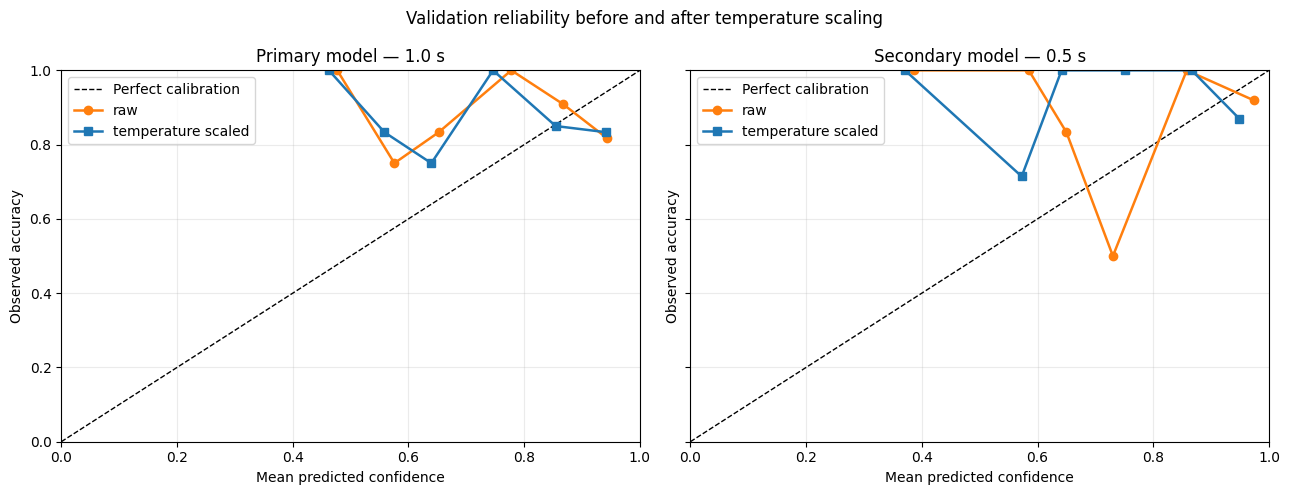

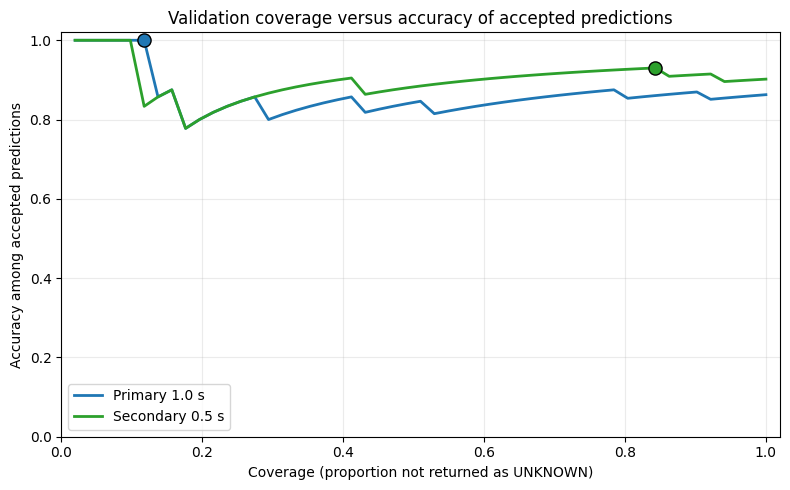


CELL 22 COMPLETED
Both locked GRU models were calibrated using validation recordings 15–16 only.
The UNKNOWN thresholds were selected with validation-only Youden J statistics; no guessed confidence threshold was used.
Recording 17 was not used to fit temperatures or select thresholds. Its existing probabilities were transformed only after the policy was locked.

Saved policy:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/calibrated_two_stage_policy/calibration_and_unknown_policy.json

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/calibrated_two_stage_policy

How to use the result:
  1. At 1.0 s, use the primary model for an early intention.
  2. At 0.5 s, use the secondary model as later confirmation.
  3. If confidence is below the corresponding threshold, return UNKNOWN.
  4. In SUMO/LDM, UNKNOWN must increase

In [ ]:
# Cell 22 — Calibrate GRU confidence and add a safe UNKNOWN output
#
# Run this cell after Cell 21, in the same Colab runtime.
#
# Purpose
# -------
# The GRU's largest softmax probability is not automatically a trustworthy
# confidence value. This cell therefore:
#
# 1. Calibrates the locked 1.0-second and 0.5-second GRU probabilities.
# 2. Uses validation recordings 15–16 only to fit temperature scaling.
# 3. Uses validation recordings 15–16 only to select an UNKNOWN threshold.
# 4. Locks both temperatures and thresholds before touching test outputs.
# 5. Applies the locked policy to the already-created recording-17 outputs.
#
# No model is retrained, no architecture is searched, and recording 17 is not
# used to choose a temperature or confidence threshold.

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
)


# ============================================================
# 1. CHECK REQUIRED CELL 20 AND CELL 21 OUTPUTS
# ============================================================

required_variables = [
    "CLASS_INDICES",
    "INDEX_TO_CLASS_GRU",
    "GRU_PREPARATION_OUTPUT_DIRECTORY",
    "FINAL_PRIMARY_GRU_DATASET",
    "FINAL_SECONDARY_GRU_DATASET",
    "FINAL_PRIMARY_TEST_PREDICTIONS",
    "FINAL_SECONDARY_TEST_PREDICTIONS",
    "gru_validation_probability",
    "gru_test_probability",
    "secondary_gru_validation_probability",
    "secondary_gru_test_probability",
    "y_validation",
    "y_test",
    "y_secondary_validation",
    "y_secondary_test",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cells 19, 20 and 21 before Cell 22.\n"
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. FIXED CONFIGURATION
# ============================================================

PRIMARY_CALIBRATION_LEAD_TIME_SECONDS = 1.0
SECONDARY_CALIBRATION_LEAD_TIME_SECONDS = 0.5

UNKNOWN_CLASS_INDEX = -1
UNKNOWN_CLASS_LABEL = "UNKNOWN"

# Ten equal-width bins are used only for the conventional ECE and reliability
# diagram diagnostics. They do not select the safety threshold.
CALIBRATION_BIN_COUNT = 10
PROBABILITY_EPSILON = 1e-12

# These broad limits are numerical guards for the one-parameter optimizer.
# A temperature of 1.0 means "no calibration".
MINIMUM_TEMPERATURE = 0.05
MAXIMUM_TEMPERATURE = 20.0

CALIBRATION_OUTPUT_DIRECTORY = (
    Path(GRU_PREPARATION_OUTPUT_DIRECTORY)
    / "calibrated_two_stage_policy"
)

CALIBRATION_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

class_indices = np.asarray(
    CLASS_INDICES,
    dtype=np.int64,
)

class_labels = [
    str(
        INDEX_TO_CLASS_GRU.get(
            int(class_index),
            class_index,
        )
    )
    for class_index in class_indices
]

class_index_to_label = {
    int(class_index): class_label
    for class_index, class_label
    in zip(class_indices, class_labels)
}


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def validate_probability_matrix(
    probability_matrix,
    expected_sample_count,
    matrix_name,
):
    probability_matrix = np.asarray(
        probability_matrix,
        dtype=np.float64,
    )

    expected_shape = (
        int(expected_sample_count),
        int(len(class_indices)),
    )

    if probability_matrix.shape != expected_shape:
        raise ValueError(
            f"{matrix_name} has shape {probability_matrix.shape}; "
            f"expected {expected_shape}."
        )

    if not np.isfinite(probability_matrix).all():
        raise ValueError(
            f"{matrix_name} contains NaN or infinite values."
        )

    if (
        (probability_matrix < 0.0).any()
        or (probability_matrix > 1.0).any()
    ):
        raise ValueError(
            f"{matrix_name} contains values outside [0, 1]."
        )

    row_sums = probability_matrix.sum(axis=1)

    if not np.allclose(
        row_sums,
        1.0,
        atol=1e-5,
    ):
        raise ValueError(
            f"Rows in {matrix_name} do not sum to one."
        )

    # Normalize only to remove tiny floating-point deviations.
    probability_matrix = (
        probability_matrix
        / row_sums[:, None]
    )

    return probability_matrix


def apply_temperature_scaling(
    probability_matrix,
    temperature,
):
    """Apply softmax(log(probability) / temperature)."""

    temperature = float(temperature)

    if (
        not np.isfinite(temperature)
        or temperature <= 0.0
    ):
        raise ValueError(
            "Temperature must be finite and greater than zero."
        )

    clipped_probability = np.clip(
        np.asarray(
            probability_matrix,
            dtype=np.float64,
        ),
        PROBABILITY_EPSILON,
        1.0,
    )

    scaled_log_probability = (
        np.log(clipped_probability)
        / temperature
    )

    scaled_log_probability = (
        scaled_log_probability
        - scaled_log_probability.max(
            axis=1,
            keepdims=True,
        )
    )

    scaled_exponential = np.exp(
        scaled_log_probability
    )

    calibrated_probability = (
        scaled_exponential
        / scaled_exponential.sum(
            axis=1,
            keepdims=True,
        )
    )

    return calibrated_probability


def fit_temperature_on_validation(
    validation_probability,
    validation_true_class,
):
    """Fit one positive temperature by minimizing validation NLL."""

    validation_true_class = np.asarray(
        validation_true_class,
        dtype=np.int64,
    )

    def objective(log_temperature):
        temperature = float(
            np.exp(log_temperature)
        )

        calibrated_probability = (
            apply_temperature_scaling(
                validation_probability,
                temperature,
            )
        )

        return float(
            log_loss(
                validation_true_class,
                calibrated_probability,
                labels=class_indices,
            )
        )

    optimization_result = minimize_scalar(
        objective,
        bounds=(
            float(np.log(MINIMUM_TEMPERATURE)),
            float(np.log(MAXIMUM_TEMPERATURE)),
        ),
        method="bounded",
        options={
            "xatol": 1e-8,
        },
    )

    if not optimization_result.success:
        raise RuntimeError(
            "Temperature optimization did not converge: "
            f"{optimization_result.message}"
        )

    selected_temperature = float(
        np.exp(optimization_result.x)
    )

    calibrated_probability = (
        apply_temperature_scaling(
            validation_probability,
            selected_temperature,
        )
    )

    raw_nll = float(
        log_loss(
            validation_true_class,
            validation_probability,
            labels=class_indices,
        )
    )

    calibrated_nll = float(
        log_loss(
            validation_true_class,
            calibrated_probability,
            labels=class_indices,
        )
    )

    return {
        "temperature": selected_temperature,
        "raw_validation_nll": raw_nll,
        "calibrated_validation_nll": calibrated_nll,
        "optimizer_success": bool(
            optimization_result.success
        ),
        "optimizer_function_evaluations": int(
            optimization_result.nfev
        ),
        "temperature_at_numerical_boundary": bool(
            np.isclose(
                selected_temperature,
                MINIMUM_TEMPERATURE,
                rtol=0.0,
                atol=1e-4,
            )
            or np.isclose(
                selected_temperature,
                MAXIMUM_TEMPERATURE,
                rtol=0.0,
                atol=1e-4,
            )
        ),
    }


def multiclass_brier_score(
    true_class,
    probability_matrix,
):
    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    one_hot_true = np.eye(
        len(class_indices),
        dtype=np.float64,
    )[true_class]

    return float(
        np.mean(
            np.sum(
                (
                    np.asarray(
                        probability_matrix,
                        dtype=np.float64,
                    )
                    - one_hot_true
                )
                ** 2,
                axis=1,
            )
        )
    )


def create_reliability_table(
    true_class,
    probability_matrix,
    lead_time_seconds,
    split_name,
    probability_state,
):
    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    predicted_class = np.argmax(
        probability_matrix,
        axis=1,
    )

    confidence = np.max(
        probability_matrix,
        axis=1,
    )

    correctness = (
        predicted_class == true_class
    )

    bin_edges = np.linspace(
        0.0,
        1.0,
        CALIBRATION_BIN_COUNT + 1,
    )

    reliability_rows = []

    for bin_index in range(
        CALIBRATION_BIN_COUNT
    ):
        lower_bound = float(
            bin_edges[bin_index]
        )

        upper_bound = float(
            bin_edges[bin_index + 1]
        )

        if (
            bin_index
            == CALIBRATION_BIN_COUNT - 1
        ):
            in_bin = (
                (confidence >= lower_bound)
                & (confidence <= upper_bound)
            )
        else:
            in_bin = (
                (confidence >= lower_bound)
                & (confidence < upper_bound)
            )

        sample_count = int(
            np.sum(in_bin)
        )

        if sample_count > 0:
            mean_confidence = float(
                np.mean(confidence[in_bin])
            )

            empirical_accuracy = float(
                np.mean(correctness[in_bin])
            )

            absolute_gap = float(
                abs(
                    empirical_accuracy
                    - mean_confidence
                )
            )
        else:
            mean_confidence = np.nan
            empirical_accuracy = np.nan
            absolute_gap = np.nan

        reliability_rows.append(
            {
                "lead_time_seconds":
                    float(lead_time_seconds),
                "split":
                    str(split_name),
                "probability_state":
                    str(probability_state),
                "bin_index":
                    int(bin_index),
                "lower_bound":
                    lower_bound,
                "upper_bound":
                    upper_bound,
                "sample_count":
                    sample_count,
                "sample_proportion":
                    float(
                        sample_count
                        / len(true_class)
                    ),
                "mean_confidence":
                    mean_confidence,
                "empirical_accuracy":
                    empirical_accuracy,
                "absolute_calibration_gap":
                    absolute_gap,
            }
        )

    return pd.DataFrame(
        reliability_rows
    )


def expected_calibration_error(
    reliability_table,
):
    nonempty_rows = reliability_table[
        reliability_table["sample_count"] > 0
    ]

    return float(
        np.sum(
            nonempty_rows[
                "sample_proportion"
            ].to_numpy(
                dtype=np.float64
            )
            * nonempty_rows[
                "absolute_calibration_gap"
            ].to_numpy(
                dtype=np.float64
            )
        )
    )


def calculate_calibration_metrics(
    true_class,
    probability_matrix,
    lead_time_seconds,
    split_name,
    probability_state,
):
    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    predicted_class = np.argmax(
        probability_matrix,
        axis=1,
    )

    confidence = np.max(
        probability_matrix,
        axis=1,
    )

    reliability_table = (
        create_reliability_table(
            true_class,
            probability_matrix,
            lead_time_seconds,
            split_name,
            probability_state,
        )
    )

    accuracy = float(
        accuracy_score(
            true_class,
            predicted_class,
        )
    )

    mean_confidence = float(
        np.mean(confidence)
    )

    metric_row = {
        "lead_time_seconds":
            float(lead_time_seconds),
        "split":
            str(split_name),
        "probability_state":
            str(probability_state),
        "sequence_count":
            int(len(true_class)),
        "accuracy":
            accuracy,
        "mean_confidence":
            mean_confidence,
        "signed_confidence_gap":
            float(mean_confidence - accuracy),
        "negative_log_likelihood":
            float(
                log_loss(
                    true_class,
                    probability_matrix,
                    labels=class_indices,
                )
            ),
        "multiclass_brier_score":
            multiclass_brier_score(
                true_class,
                probability_matrix,
            ),
        "expected_calibration_error":
            expected_calibration_error(
                reliability_table
            ),
    }

    return metric_row, reliability_table


def select_unknown_threshold_on_validation(
    validation_true_class,
    calibrated_validation_probability,
    lead_time_seconds,
):
    """
    Select a confidence threshold with Youden's J statistic.

    Confidence is treated as a validation score for distinguishing:
      positive = the model's class prediction is correct
      negative = the model's class prediction is incorrect

    J = sensitivity_to_correct_predictions
        + specificity_to_errors
        - 1

    This is data-derived. No guessed threshold such as 0.70 is inserted.
    """

    validation_true_class = np.asarray(
        validation_true_class,
        dtype=np.int64,
    )

    predicted_class = np.argmax(
        calibrated_validation_probability,
        axis=1,
    )

    confidence = np.max(
        calibrated_validation_probability,
        axis=1,
    )

    correctness = (
        predicted_class
        == validation_true_class
    )

    correct_count = int(
        np.sum(correctness)
    )

    error_count = int(
        np.sum(~correctness)
    )

    if correct_count == 0:
        raise ValueError(
            "The validation model has no correct predictions; "
            "an UNKNOWN threshold cannot be selected safely."
        )

    if error_count == 0:
        raise ValueError(
            "The validation model has no errors. Youden's J cannot "
            "estimate how confidence separates correct and incorrect "
            "predictions. Use a larger calibration set."
        )

    candidate_thresholds = np.unique(
        np.concatenate(
            [
                np.array([0.0]),
                confidence,
            ]
        )
    )

    threshold_rows = []

    for threshold in candidate_thresholds:
        accepted = (
            confidence >= threshold
        )

        rejected = ~accepted

        accepted_count = int(
            np.sum(accepted)
        )

        correct_accepted = int(
            np.sum(
                correctness & accepted
            )
        )

        error_accepted = int(
            np.sum(
                (~correctness) & accepted
            )
        )

        correct_rejected = int(
            np.sum(
                correctness & rejected
            )
        )

        error_rejected = int(
            np.sum(
                (~correctness) & rejected
            )
        )

        sensitivity_to_correct = float(
            correct_accepted
            / correct_count
        )

        specificity_to_errors = float(
            error_rejected
            / error_count
        )

        youden_j = float(
            sensitivity_to_correct
            + specificity_to_errors
            - 1.0
        )

        if accepted_count > 0:
            accepted_accuracy = float(
                correct_accepted
                / accepted_count
            )

            accepted_macro_f1 = float(
                f1_score(
                    validation_true_class[
                        accepted
                    ],
                    predicted_class[
                        accepted
                    ],
                    labels=class_indices,
                    average="macro",
                    zero_division=0,
                )
            )
        else:
            accepted_accuracy = np.nan
            accepted_macro_f1 = np.nan

        threshold_rows.append(
            {
                "lead_time_seconds":
                    float(lead_time_seconds),
                "threshold":
                    float(threshold),
                "accepted_count":
                    accepted_count,
                "unknown_count":
                    int(np.sum(rejected)),
                "coverage":
                    float(
                        accepted_count
                        / len(correctness)
                    ),
                "unknown_rate":
                    float(
                        np.mean(rejected)
                    ),
                "accepted_accuracy":
                    accepted_accuracy,
                "accepted_macro_f1":
                    accepted_macro_f1,
                "correct_accepted":
                    correct_accepted,
                "error_accepted":
                    error_accepted,
                "correct_rejected":
                    correct_rejected,
                "error_rejected":
                    error_rejected,
                "sensitivity_to_correct":
                    sensitivity_to_correct,
                "specificity_to_errors":
                    specificity_to_errors,
                "youden_j":
                    youden_j,
            }
        )

    threshold_table = pd.DataFrame(
        threshold_rows
    )

    # Predeclared tie-breaking:
    # 1. largest Youden J;
    # 2. retain more usable predictions (higher coverage);
    # 3. if still tied, use the lower threshold.
    ranked_thresholds = (
        threshold_table
        .sort_values(
            [
                "youden_j",
                "coverage",
                "threshold",
            ],
            ascending=[
                False,
                False,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    selected_row = (
        ranked_thresholds
        .iloc[0]
        .to_dict()
    )

    selected_threshold = float(
        selected_row["threshold"]
    )

    threshold_table[
        "selected"
    ] = np.isclose(
        threshold_table["threshold"],
        selected_threshold,
        rtol=0.0,
        atol=1e-12,
    )

    return (
        selected_threshold,
        selected_row,
        threshold_table,
    )


def apply_unknown_rule(
    calibrated_probability,
    confidence_threshold,
):
    predicted_class = np.argmax(
        calibrated_probability,
        axis=1,
    ).astype(
        np.int64
    )

    confidence = np.max(
        calibrated_probability,
        axis=1,
    )

    accepted = (
        confidence
        >= float(confidence_threshold)
    )

    output_class = np.where(
        accepted,
        predicted_class,
        UNKNOWN_CLASS_INDEX,
    ).astype(
        np.int64
    )

    output_label = np.array(
        [
            (
                class_index_to_label[
                    int(class_index)
                ]
                if int(class_index)
                != UNKNOWN_CLASS_INDEX
                else UNKNOWN_CLASS_LABEL
            )
            for class_index in output_class
        ],
        dtype=object,
    )

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "accepted": accepted,
        "output_class": output_class,
        "output_label": output_label,
    }


def calculate_selective_metrics(
    true_class,
    calibrated_probability,
    confidence_threshold,
    lead_time_seconds,
    split_name,
):
    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    output = apply_unknown_rule(
        calibrated_probability,
        confidence_threshold,
    )

    predicted_class = output[
        "predicted_class"
    ]

    accepted = output["accepted"]
    rejected = ~accepted

    correctness = (
        predicted_class == true_class
    )

    accepted_count = int(
        np.sum(accepted)
    )

    if accepted_count > 0:
        accepted_accuracy = float(
            accuracy_score(
                true_class[accepted],
                predicted_class[accepted],
            )
        )

        accepted_macro_f1 = float(
            f1_score(
                true_class[accepted],
                predicted_class[accepted],
                labels=class_indices,
                average="macro",
                zero_division=0,
            )
        )
    else:
        accepted_accuracy = np.nan
        accepted_macro_f1 = np.nan

    total_raw_errors = int(
        np.sum(~correctness)
    )

    errors_rejected = int(
        np.sum(
            (~correctness) & rejected
        )
    )

    metric_row = {
        "lead_time_seconds":
            float(lead_time_seconds),
        "split":
            str(split_name),
        "threshold":
            float(confidence_threshold),
        "sequence_count":
            int(len(true_class)),
        "accepted_count":
            accepted_count,
        "unknown_count":
            int(np.sum(rejected)),
        "coverage":
            float(np.mean(accepted)),
        "unknown_rate":
            float(np.mean(rejected)),
        "raw_accuracy_before_unknown":
            float(np.mean(correctness)),
        "accepted_accuracy":
            accepted_accuracy,
        "accepted_macro_f1":
            accepted_macro_f1,
        "errors_accepted":
            int(
                np.sum(
                    (~correctness) & accepted
                )
            ),
        "errors_rejected":
            errors_rejected,
        "raw_error_detection_rate":
            (
                float(
                    errors_rejected
                    / total_raw_errors
                )
                if total_raw_errors > 0
                else np.nan
            ),
        "correct_predictions_rejected":
            int(
                np.sum(
                    correctness & rejected
                )
            ),
        "unsafe_accepted_error_rate":
            float(
                np.mean(
                    (~correctness) & accepted
                )
            ),
    }

    return metric_row, output


def create_per_class_selective_metrics(
    true_class,
    selective_output,
    lead_time_seconds,
    split_name,
):
    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    predicted_class = selective_output[
        "predicted_class"
    ]

    accepted = selective_output[
        "accepted"
    ]

    rows = []

    for class_index in class_indices:
        class_mask = (
            true_class == int(class_index)
        )

        support = int(
            np.sum(class_mask)
        )

        accepted_for_class = (
            class_mask & accepted
        )

        correct_and_accepted = (
            accepted_for_class
            & (
                predicted_class
                == int(class_index)
            )
        )

        rows.append(
            {
                "lead_time_seconds":
                    float(lead_time_seconds),
                "split":
                    str(split_name),
                "class_index":
                    int(class_index),
                "manoeuvre_label":
                    class_index_to_label[
                        int(class_index)
                    ],
                "support":
                    support,
                "accepted_count":
                    int(
                        np.sum(
                            accepted_for_class
                        )
                    ),
                "unknown_count":
                    int(
                        np.sum(
                            class_mask
                            & (~accepted)
                        )
                    ),
                "class_coverage":
                    (
                        float(
                            np.sum(
                                accepted_for_class
                            )
                            / support
                        )
                        if support > 0
                        else np.nan
                    ),
                "correct_and_accepted_count":
                    int(
                        np.sum(
                            correct_and_accepted
                        )
                    ),
                "correct_action_recall":
                    (
                        float(
                            np.sum(
                                correct_and_accepted
                            )
                            / support
                        )
                        if support > 0
                        else np.nan
                    ),
            }
        )

    return pd.DataFrame(rows)


def create_unknown_confusion_table(
    true_class,
    selective_output,
    lead_time_seconds,
    split_name,
):
    true_labels = [
        class_index_to_label[
            int(class_index)
        ]
        for class_index in true_class
    ]

    predicted_labels = (
        selective_output[
            "output_label"
        ]
    )

    table = pd.crosstab(
        pd.Categorical(
            true_labels,
            categories=class_labels,
            ordered=True,
        ),
        pd.Categorical(
            predicted_labels,
            categories=(
                class_labels
                + [UNKNOWN_CLASS_LABEL]
            ),
            ordered=True,
        ),
        rownames=["true_label"],
        colnames=["system_output"],
        dropna=False,
    )

    try:
        stacked_table = table.stack(
            future_stack=True
        )
    except TypeError:
        # Compatibility with older pandas versions used by some
        # Google Colab runtimes.
        stacked_table = table.stack(
            dropna=False
        )

    long_table = (
        stacked_table
        .rename("count")
        .reset_index()
    )

    long_table.insert(
        0,
        "split",
        str(split_name),
    )

    long_table.insert(
        0,
        "lead_time_seconds",
        float(lead_time_seconds),
    )

    return long_table


def check_metadata_alignment(
    first_metadata,
    second_metadata,
    split_name,
):
    first_metadata = (
        first_metadata
        .copy()
        .reset_index(drop=True)
    )

    second_metadata = (
        second_metadata
        .copy()
        .reset_index(drop=True)
    )

    if len(first_metadata) != len(second_metadata):
        raise ValueError(
            f"Primary and secondary {split_name} metadata lengths differ."
        )

    identity_candidates = [
        "recording_id",
        "track_id",
        "vehicle_id",
        "sequence_id",
        "recordingId",
        "trackId",
        "vehicleId",
    ]

    shared_identity_columns = [
        column_name
        for column_name in identity_candidates
        if (
            column_name
            in first_metadata.columns
            and column_name
            in second_metadata.columns
        )
    ]

    if shared_identity_columns:
        aligned = bool(
            first_metadata[
                shared_identity_columns
            ]
            .astype(str)
            .equals(
                second_metadata[
                    shared_identity_columns
                ]
                .astype(str)
            )
        )

        if not aligned:
            raise ValueError(
                f"Primary and secondary {split_name} vehicle ordering "
                f"differs in {shared_identity_columns}."
            )

    else:
        aligned = True

    return aligned, shared_identity_columns


def create_prediction_table(
    metadata,
    true_class,
    raw_probability,
    calibrated_probability,
    temperature,
    confidence_threshold,
    lead_time_seconds,
    split_name,
):
    metadata = (
        metadata
        .copy()
        .reset_index(drop=True)
    )

    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    if len(metadata) != len(true_class):
        raise ValueError(
            f"{split_name} metadata length does not match labels."
        )

    selective_output = apply_unknown_rule(
        calibrated_probability,
        confidence_threshold,
    )

    raw_prediction = np.argmax(
        raw_probability,
        axis=1,
    )

    raw_confidence = np.max(
        raw_probability,
        axis=1,
    )

    table = metadata.copy()

    table[
        "lead_time_seconds"
    ] = float(lead_time_seconds)

    table["split"] = str(
        split_name
    )

    table[
        "true_class_index"
    ] = true_class

    table[
        "true_manoeuvre_label"
    ] = [
        class_index_to_label[
            int(class_index)
        ]
        for class_index in true_class
    ]

    table[
        "raw_predicted_class_index"
    ] = raw_prediction

    table[
        "raw_max_probability"
    ] = raw_confidence

    table[
        "calibration_temperature"
    ] = float(temperature)

    table[
        "calibrated_predicted_class_index"
    ] = selective_output[
        "predicted_class"
    ]

    table[
        "calibrated_max_probability"
    ] = selective_output[
        "confidence"
    ]

    table[
        "unknown_threshold"
    ] = float(confidence_threshold)

    table[
        "accepted"
    ] = selective_output[
        "accepted"
    ]

    table[
        "system_output_class_index"
    ] = selective_output[
        "output_class"
    ]

    table[
        "system_output_label"
    ] = selective_output[
        "output_label"
    ]

    table[
        "accepted_prediction_correct"
    ] = (
        selective_output[
            "accepted"
        ]
        & (
            selective_output[
                "predicted_class"
            ]
            == true_class
        )
    )

    for class_index, class_label in zip(
        class_indices,
        class_labels,
    ):
        safe_class_label = (
            str(class_label)
            .strip()
            .lower()
            .replace(" ", "_")
        )

        table[
            f"raw_probability_{safe_class_label}"
        ] = raw_probability[
            :,
            int(class_index),
        ]

        table[
            f"calibrated_probability_{safe_class_label}"
        ] = calibrated_probability[
            :,
            int(class_index),
        ]

    return table


def display_dataframe(
    dataframe,
):
    try:
        display(dataframe)
    except NameError:
        print(
            dataframe.to_string(
                index=False
            )
        )


# ============================================================
# 4. LOAD VALIDATION OUTPUTS ONLY
# ============================================================

primary_validation_true = np.asarray(
    y_validation,
    dtype=np.int64,
)

secondary_validation_true = np.asarray(
    y_secondary_validation,
    dtype=np.int64,
)

primary_validation_raw_probability = (
    validate_probability_matrix(
        gru_validation_probability,
        len(primary_validation_true),
        "primary validation probabilities",
    )
)

secondary_validation_raw_probability = (
    validate_probability_matrix(
        secondary_gru_validation_probability,
        len(secondary_validation_true),
        "secondary validation probabilities",
    )
)

if not np.array_equal(
    primary_validation_true,
    secondary_validation_true,
):
    raise ValueError(
        "Primary and secondary validation labels are not aligned."
    )

primary_validation_metadata = (
    FINAL_PRIMARY_GRU_DATASET[
        "validation_metadata"
    ]
    .copy()
    .reset_index(drop=True)
)

secondary_validation_metadata = (
    FINAL_SECONDARY_GRU_DATASET[
        "validation_metadata"
    ]
    .copy()
    .reset_index(drop=True)
)

(
    validation_metadata_aligned,
    validation_alignment_columns,
) = check_metadata_alignment(
    primary_validation_metadata,
    secondary_validation_metadata,
    "validation",
)

print(
    "Validation data loaded for calibration."
)

print(
    "  Primary 1.0-second sequences:",
    len(primary_validation_true),
)

print(
    "  Secondary 0.5-second sequences:",
    len(secondary_validation_true),
)

print(
    "\nRecording 17 has not been used to fit calibration "
    "or select UNKNOWN thresholds."
)


# ============================================================
# 5. FIT TEMPERATURES USING VALIDATION DATA ONLY
# ============================================================

primary_temperature_result = (
    fit_temperature_on_validation(
        primary_validation_raw_probability,
        primary_validation_true,
    )
)

secondary_temperature_result = (
    fit_temperature_on_validation(
        secondary_validation_raw_probability,
        secondary_validation_true,
    )
)

FINAL_PRIMARY_TEMPERATURE = float(
    primary_temperature_result[
        "temperature"
    ]
)

FINAL_SECONDARY_TEMPERATURE = float(
    secondary_temperature_result[
        "temperature"
    ]
)

FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY = (
    apply_temperature_scaling(
        primary_validation_raw_probability,
        FINAL_PRIMARY_TEMPERATURE,
    )
)

FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY = (
    apply_temperature_scaling(
        secondary_validation_raw_probability,
        FINAL_SECONDARY_TEMPERATURE,
    )
)


# ============================================================
# 6. SELECT UNKNOWN THRESHOLDS ON VALIDATION DATA ONLY
# ============================================================

(
    FINAL_PRIMARY_UNKNOWN_THRESHOLD,
    primary_selected_threshold_row,
    FINAL_PRIMARY_THRESHOLD_CANDIDATES,
) = select_unknown_threshold_on_validation(
    primary_validation_true,
    FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
    PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
)

(
    FINAL_SECONDARY_UNKNOWN_THRESHOLD,
    secondary_selected_threshold_row,
    FINAL_SECONDARY_THRESHOLD_CANDIDATES,
) = select_unknown_threshold_on_validation(
    secondary_validation_true,
    FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
    SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
)

FINAL_SELECTED_UNKNOWN_THRESHOLDS = pd.DataFrame(
    [
        {
            **primary_selected_threshold_row,
            "temperature":
                FINAL_PRIMARY_TEMPERATURE,
            "threshold_selection_split":
                "recordings_15_16_validation",
            "selection_method":
                "maximum_youden_j",
        },
        {
            **secondary_selected_threshold_row,
            "temperature":
                FINAL_SECONDARY_TEMPERATURE,
            "threshold_selection_split":
                "recordings_15_16_validation",
            "selection_method":
                "maximum_youden_j",
        },
    ]
).sort_values(
    "lead_time_seconds",
    ascending=False,
).reset_index(
    drop=True
)


# ============================================================
# 7. LOCK THE CALIBRATION POLICY BEFORE TEST APPLICATION
# ============================================================

FINAL_CALIBRATION_POLICY = {
    "policy_name":
        "two_stage_gru_temperature_and_unknown",
    "policy_version":
        1,
    "class_index_to_label":
        {
            str(class_index):
                class_label
            for class_index, class_label
            in class_index_to_label.items()
        },
    "unknown_class_index":
        int(UNKNOWN_CLASS_INDEX),
    "unknown_class_label":
        UNKNOWN_CLASS_LABEL,
    "calibration_method":
        "temperature_scaling",
    "temperature_objective":
        "minimum_validation_negative_log_likelihood",
    "unknown_threshold_method":
        "maximum_youden_j_for_correct_vs_incorrect_validation_predictions",
    "threshold_tie_breaking":
        [
            "higher_validation_coverage",
            "lower_threshold",
        ],
    "selection_data":
        {
            "training_recordings":
                [
                    7, 8, 9, 10,
                    11, 12, 13, 14,
                ],
            "validation_recordings":
                [15, 16],
            "test_recordings":
                [17],
            "test_used_for_temperature":
                False,
            "test_used_for_threshold":
                False,
        },
    "primary_1.0s":
        {
            "role":
                "early_primary_prediction",
            "lead_time_seconds":
                PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
            "temperature":
                FINAL_PRIMARY_TEMPERATURE,
            "unknown_threshold":
                float(
                    FINAL_PRIMARY_UNKNOWN_THRESHOLD
                ),
        },
    "secondary_0.5s":
        {
            "role":
                "later_confirmation_prediction",
            "lead_time_seconds":
                SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
            "temperature":
                FINAL_SECONDARY_TEMPERATURE,
            "unknown_threshold":
                float(
                    FINAL_SECONDARY_UNKNOWN_THRESHOLD
                ),
        },
    "runtime_safety_guidance":
        {
            "low_confidence_output":
                "UNKNOWN",
            "unknown_action":
                "do_not_assume_manoeuvre; increase uncertainty and use conservative negotiation",
            "accepted_horizon_disagreement":
                "treat as uncertainty; do not convert disagreement into a confident manoeuvre",
        },
}

FINAL_CALIBRATION_POLICY_LOCKED = True

print("\n" + "=" * 80)
print("CALIBRATION POLICY LOCKED USING VALIDATION DATA ONLY")
print("=" * 80)

print(
    f"Primary 1.0 s: temperature = "
    f"{FINAL_PRIMARY_TEMPERATURE:.6f}, "
    f"UNKNOWN threshold = "
    f"{FINAL_PRIMARY_UNKNOWN_THRESHOLD:.6f}"
)

print(
    f"Secondary 0.5 s: temperature = "
    f"{FINAL_SECONDARY_TEMPERATURE:.6f}, "
    f"UNKNOWN threshold = "
    f"{FINAL_SECONDARY_UNKNOWN_THRESHOLD:.6f}"
)

print(
    "\nOnly now will the locked policy be applied to the "
    "already-created recording-17 probability outputs."
)


# ============================================================
# 8. APPLY THE LOCKED POLICY TO EXISTING TEST OUTPUTS
# ============================================================

if not FINAL_CALIBRATION_POLICY_LOCKED:
    raise RuntimeError(
        "Calibration policy must be locked before test application."
    )

primary_test_true = np.asarray(
    y_test,
    dtype=np.int64,
)

secondary_test_true = np.asarray(
    y_secondary_test,
    dtype=np.int64,
)

primary_test_raw_probability = (
    validate_probability_matrix(
        gru_test_probability,
        len(primary_test_true),
        "primary test probabilities",
    )
)

secondary_test_raw_probability = (
    validate_probability_matrix(
        secondary_gru_test_probability,
        len(secondary_test_true),
        "secondary test probabilities",
    )
)

if not np.array_equal(
    primary_test_true,
    secondary_test_true,
):
    raise ValueError(
        "Primary and secondary test labels are not aligned."
    )

primary_test_metadata = (
    FINAL_PRIMARY_GRU_DATASET[
        "test_metadata"
    ]
    .copy()
    .reset_index(drop=True)
)

secondary_test_metadata = (
    FINAL_SECONDARY_GRU_DATASET[
        "test_metadata"
    ]
    .copy()
    .reset_index(drop=True)
)

(
    test_metadata_aligned,
    test_alignment_columns,
) = check_metadata_alignment(
    primary_test_metadata,
    secondary_test_metadata,
    "test",
)

FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY = (
    apply_temperature_scaling(
        primary_test_raw_probability,
        FINAL_PRIMARY_TEMPERATURE,
    )
)

FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY = (
    apply_temperature_scaling(
        secondary_test_raw_probability,
        FINAL_SECONDARY_TEMPERATURE,
    )
)


# ============================================================
# 9. CALIBRATION METRICS AND RELIABILITY TABLES
# ============================================================

calibration_evaluation_items = [
    (
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "validation",
        "raw",
        primary_validation_true,
        primary_validation_raw_probability,
    ),
    (
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "validation",
        "temperature_scaled",
        primary_validation_true,
        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
    ),
    (
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "validation",
        "raw",
        secondary_validation_true,
        secondary_validation_raw_probability,
    ),
    (
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "validation",
        "temperature_scaled",
        secondary_validation_true,
        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
    ),
    (
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "test",
        "raw",
        primary_test_true,
        primary_test_raw_probability,
    ),
    (
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "test",
        "temperature_scaled",
        primary_test_true,
        FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY,
    ),
    (
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "test",
        "raw",
        secondary_test_true,
        secondary_test_raw_probability,
    ),
    (
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "test",
        "temperature_scaled",
        secondary_test_true,
        FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY,
    ),
]

calibration_metric_rows = []
reliability_tables = []

for (
    lead_time_seconds,
    split_name,
    probability_state,
    true_class,
    probability_matrix,
) in calibration_evaluation_items:
    (
        calibration_metric_row,
        reliability_table,
    ) = calculate_calibration_metrics(
        true_class,
        probability_matrix,
        lead_time_seconds,
        split_name,
        probability_state,
    )

    calibration_metric_rows.append(
        calibration_metric_row
    )

    reliability_tables.append(
        reliability_table
    )

FINAL_CALIBRATION_METRICS = (
    pd.DataFrame(
        calibration_metric_rows
    )
    .sort_values(
        [
            "split",
            "lead_time_seconds",
            "probability_state",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

FINAL_RELIABILITY_TABLE = (
    pd.concat(
        reliability_tables,
        ignore_index=True,
    )
)


# ============================================================
# 10. UNKNOWN/SELECTIVE-PREDICTION METRICS
# ============================================================

selective_evaluation_items = [
    (
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "validation",
        primary_validation_true,
        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
        FINAL_PRIMARY_UNKNOWN_THRESHOLD,
    ),
    (
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "validation",
        secondary_validation_true,
        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
        FINAL_SECONDARY_UNKNOWN_THRESHOLD,
    ),
    (
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "test",
        primary_test_true,
        FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY,
        FINAL_PRIMARY_UNKNOWN_THRESHOLD,
    ),
    (
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "test",
        secondary_test_true,
        FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY,
        FINAL_SECONDARY_UNKNOWN_THRESHOLD,
    ),
]

selective_metric_rows = []
per_class_selective_tables = []
unknown_confusion_tables = []
selective_output_lookup = {}

for (
    lead_time_seconds,
    split_name,
    true_class,
    calibrated_probability,
    confidence_threshold,
) in selective_evaluation_items:
    (
        selective_metric_row,
        selective_output,
    ) = calculate_selective_metrics(
        true_class,
        calibrated_probability,
        confidence_threshold,
        lead_time_seconds,
        split_name,
    )

    selective_metric_rows.append(
        selective_metric_row
    )

    per_class_selective_tables.append(
        create_per_class_selective_metrics(
            true_class,
            selective_output,
            lead_time_seconds,
            split_name,
        )
    )

    unknown_confusion_tables.append(
        create_unknown_confusion_table(
            true_class,
            selective_output,
            lead_time_seconds,
            split_name,
        )
    )

    selective_output_lookup[
        (
            float(lead_time_seconds),
            str(split_name),
        )
    ] = selective_output

FINAL_SELECTIVE_PREDICTION_METRICS = (
    pd.DataFrame(
        selective_metric_rows
    )
    .sort_values(
        [
            "split",
            "lead_time_seconds",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

FINAL_PER_CLASS_SELECTIVE_METRICS = (
    pd.concat(
        per_class_selective_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "split",
            "lead_time_seconds",
            "class_index",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

FINAL_UNKNOWN_CONFUSION_TABLE = (
    pd.concat(
        unknown_confusion_tables,
        ignore_index=True,
    )
)


# ============================================================
# 11. FINAL PER-SEQUENCE OUTPUT TABLES
# ============================================================

FINAL_PRIMARY_VALIDATION_CALIBRATED_PREDICTIONS = (
    create_prediction_table(
        primary_validation_metadata,
        primary_validation_true,
        primary_validation_raw_probability,
        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
        FINAL_PRIMARY_TEMPERATURE,
        FINAL_PRIMARY_UNKNOWN_THRESHOLD,
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "validation",
    )
)

FINAL_SECONDARY_VALIDATION_CALIBRATED_PREDICTIONS = (
    create_prediction_table(
        secondary_validation_metadata,
        secondary_validation_true,
        secondary_validation_raw_probability,
        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
        FINAL_SECONDARY_TEMPERATURE,
        FINAL_SECONDARY_UNKNOWN_THRESHOLD,
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "validation",
    )
)

FINAL_PRIMARY_TEST_CALIBRATED_PREDICTIONS = (
    create_prediction_table(
        primary_test_metadata,
        primary_test_true,
        primary_test_raw_probability,
        FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY,
        FINAL_PRIMARY_TEMPERATURE,
        FINAL_PRIMARY_UNKNOWN_THRESHOLD,
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "test",
    )
)

FINAL_SECONDARY_TEST_CALIBRATED_PREDICTIONS = (
    create_prediction_table(
        secondary_test_metadata,
        secondary_test_true,
        secondary_test_raw_probability,
        FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY,
        FINAL_SECONDARY_TEMPERATURE,
        FINAL_SECONDARY_UNKNOWN_THRESHOLD,
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "test",
    )
)


# ============================================================
# 12. QUALITY CHECKS
# ============================================================

def probability_rows_sum_to_one(
    probability_matrix,
):
    return bool(
        np.allclose(
            probability_matrix.sum(axis=1),
            1.0,
            atol=1e-8,
        )
    )


def argmax_is_unchanged(
    raw_probability,
    calibrated_probability,
):
    return bool(
        np.array_equal(
            np.argmax(
                raw_probability,
                axis=1,
            ),
            np.argmax(
                calibrated_probability,
                axis=1,
            ),
        )
    )


primary_validation_nll_not_worse = bool(
    primary_temperature_result[
        "calibrated_validation_nll"
    ]
    <= primary_temperature_result[
        "raw_validation_nll"
    ]
    + 1e-10
)

secondary_validation_nll_not_worse = bool(
    secondary_temperature_result[
        "calibrated_validation_nll"
    ]
    <= secondary_temperature_result[
        "raw_validation_nll"
    ]
    + 1e-10
)

FINAL_CALIBRATION_QUALITY_CHECKS = pd.DataFrame(
    [
        {
            "check":
                "Validation labels aligned across horizons",
            "passed":
                bool(
                    np.array_equal(
                        primary_validation_true,
                        secondary_validation_true,
                    )
                ),
            "details":
                f"{len(primary_validation_true)} sequences",
        },
        {
            "check":
                "Test labels aligned across horizons",
            "passed":
                bool(
                    np.array_equal(
                        primary_test_true,
                        secondary_test_true,
                    )
                ),
            "details":
                f"{len(primary_test_true)} sequences",
        },
        {
            "check":
                "Validation metadata aligned",
            "passed":
                bool(validation_metadata_aligned),
            "details":
                str(validation_alignment_columns),
        },
        {
            "check":
                "Test metadata aligned",
            "passed":
                bool(test_metadata_aligned),
            "details":
                str(test_alignment_columns),
        },
        {
            "check":
                "Primary temperature finite and positive",
            "passed":
                bool(
                    np.isfinite(
                        FINAL_PRIMARY_TEMPERATURE
                    )
                    and FINAL_PRIMARY_TEMPERATURE
                    > 0.0
                ),
            "details":
                f"{FINAL_PRIMARY_TEMPERATURE:.8f}",
        },
        {
            "check":
                "Secondary temperature finite and positive",
            "passed":
                bool(
                    np.isfinite(
                        FINAL_SECONDARY_TEMPERATURE
                    )
                    and FINAL_SECONDARY_TEMPERATURE
                    > 0.0
                ),
            "details":
                f"{FINAL_SECONDARY_TEMPERATURE:.8f}",
        },
        {
            "check":
                "Primary validation NLL did not worsen",
            "passed":
                primary_validation_nll_not_worse,
            "details":
                (
                    f"{primary_temperature_result['raw_validation_nll']:.6f}"
                    " -> "
                    f"{primary_temperature_result['calibrated_validation_nll']:.6f}"
                ),
        },
        {
            "check":
                "Secondary validation NLL did not worsen",
            "passed":
                secondary_validation_nll_not_worse,
            "details":
                (
                    f"{secondary_temperature_result['raw_validation_nll']:.6f}"
                    " -> "
                    f"{secondary_temperature_result['calibrated_validation_nll']:.6f}"
                ),
        },
        {
            "check":
                "Primary calibrated probabilities valid",
            "passed":
                bool(
                    np.isfinite(
                        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY
                    ).all()
                    and np.isfinite(
                        FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY
                    ).all()
                    and probability_rows_sum_to_one(
                        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY
                    )
                    and probability_rows_sum_to_one(
                        FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY
                    )
                ),
            "details":
                "finite and rows sum to one",
        },
        {
            "check":
                "Secondary calibrated probabilities valid",
            "passed":
                bool(
                    np.isfinite(
                        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY
                    ).all()
                    and np.isfinite(
                        FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY
                    ).all()
                    and probability_rows_sum_to_one(
                        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY
                    )
                    and probability_rows_sum_to_one(
                        FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY
                    )
                ),
            "details":
                "finite and rows sum to one",
        },
        {
            "check":
                "Temperature scaling preserved class predictions",
            "passed":
                bool(
                    argmax_is_unchanged(
                        primary_validation_raw_probability,
                        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
                    )
                    and argmax_is_unchanged(
                        primary_test_raw_probability,
                        FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY,
                    )
                    and argmax_is_unchanged(
                        secondary_validation_raw_probability,
                        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
                    )
                    and argmax_is_unchanged(
                        secondary_test_raw_probability,
                        FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY,
                    )
                ),
            "details":
                "all four probability matrices",
        },
        {
            "check":
                "UNKNOWN thresholds are valid probabilities",
            "passed":
                bool(
                    0.0
                    <= FINAL_PRIMARY_UNKNOWN_THRESHOLD
                    <= 1.0
                    and 0.0
                    <= FINAL_SECONDARY_UNKNOWN_THRESHOLD
                    <= 1.0
                ),
            "details":
                (
                    f"primary={FINAL_PRIMARY_UNKNOWN_THRESHOLD:.6f}, "
                    f"secondary={FINAL_SECONDARY_UNKNOWN_THRESHOLD:.6f}"
                ),
        },
        {
            "check":
                "Test was excluded from calibration fitting",
            "passed":
                True,
            "details":
                "fit_temperature_on_validation received validation arrays only",
        },
        {
            "check":
                "Test was excluded from threshold selection",
            "passed":
                True,
            "details":
                "select_unknown_threshold_on_validation received validation arrays only",
        },
        {
            "check":
                "Test probabilities were reused, not recomputed",
            "passed":
                True,
            "details":
                "Cell 20/21 frozen probability outputs",
        },
        {
            "check":
                "Policy locked before test transformation",
            "passed":
                bool(
                    FINAL_CALIBRATION_POLICY_LOCKED
                ),
            "details":
                "temperature and threshold fixed first",
        },
    ]
)

if not bool(
    FINAL_CALIBRATION_QUALITY_CHECKS[
        "passed"
    ].all()
):
    failed_quality_checks = (
        FINAL_CALIBRATION_QUALITY_CHECKS.loc[
            ~FINAL_CALIBRATION_QUALITY_CHECKS[
                "passed"
            ],
            [
                "check",
                "details",
            ],
        ]
    )

    raise ValueError(
        "One or more Cell 22 quality checks failed:\n"
        + failed_quality_checks.to_string(
            index=False
        )
    )


# ============================================================
# 13. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("SELECTED VALIDATION-ONLY CALIBRATION POLICY")
print("=" * 80)

display_dataframe(
    FINAL_SELECTED_UNKNOWN_THRESHOLDS[
        [
            "lead_time_seconds",
            "temperature",
            "threshold",
            "coverage",
            "unknown_rate",
            "accepted_accuracy",
            "correct_rejected",
            "error_rejected",
            "youden_j",
        ]
    ]
)

print("\n" + "=" * 80)
print("CALIBRATION METRICS — LOWER NLL, BRIER AND ECE ARE BETTER")
print("=" * 80)

display_dataframe(
    FINAL_CALIBRATION_METRICS
)

print("\n" + "=" * 80)
print("UNKNOWN POLICY METRICS")
print("=" * 80)

display_dataframe(
    FINAL_SELECTIVE_PREDICTION_METRICS
)

print("\n" + "=" * 80)
print("PER-CLASS COVERAGE AND CORRECT-ACTION RECALL")
print("=" * 80)

display_dataframe(
    FINAL_PER_CLASS_SELECTIVE_METRICS
)

print("\n" + "=" * 80)
print("QUALITY CHECKS")
print("=" * 80)

display_dataframe(
    FINAL_CALIBRATION_QUALITY_CHECKS
)


# ============================================================
# 14. VALIDATION RELIABILITY DIAGRAMS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharex=True,
    sharey=True,
)

for axis, lead_time_seconds, title in [
    (
        axes[0],
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "Primary model — 1.0 s",
    ),
    (
        axes[1],
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "Secondary model — 0.5 s",
    ),
]:
    axis.plot(
        [0.0, 1.0],
        [0.0, 1.0],
        linestyle="--",
        color="black",
        linewidth=1.0,
        label="Perfect calibration",
    )

    for probability_state, marker, color in [
        ("raw", "o", "tab:orange"),
        (
            "temperature_scaled",
            "s",
            "tab:blue",
        ),
    ]:
        plot_data = FINAL_RELIABILITY_TABLE[
            (
                FINAL_RELIABILITY_TABLE[
                    "lead_time_seconds"
                ]
                == lead_time_seconds
            )
            & (
                FINAL_RELIABILITY_TABLE[
                    "split"
                ]
                == "validation"
            )
            & (
                FINAL_RELIABILITY_TABLE[
                    "probability_state"
                ]
                == probability_state
            )
            & (
                FINAL_RELIABILITY_TABLE[
                    "sample_count"
                ]
                > 0
            )
        ]

        axis.plot(
            plot_data["mean_confidence"],
            plot_data["empirical_accuracy"],
            marker=marker,
            color=color,
            linewidth=1.8,
            label=probability_state.replace(
                "_",
                " ",
            ),
        )

    axis.set_title(title)
    axis.set_xlabel("Mean predicted confidence")
    axis.set_ylabel("Observed accuracy")
    axis.set_xlim(0.0, 1.0)
    axis.set_ylim(0.0, 1.0)
    axis.grid(alpha=0.25)
    axis.legend()

fig.suptitle(
    "Validation reliability before and after temperature scaling"
)

fig.tight_layout()

reliability_figure_path = (
    CALIBRATION_OUTPUT_DIRECTORY
    / "validation_reliability_diagrams.png"
)

fig.savefig(
    reliability_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 15. VALIDATION RISK–COVERAGE DIAGRAM
# ============================================================

fig, axis = plt.subplots(
    figsize=(8, 5),
)

for (
    threshold_table,
    lead_time_seconds,
    color,
    label,
) in [
    (
        FINAL_PRIMARY_THRESHOLD_CANDIDATES,
        PRIMARY_CALIBRATION_LEAD_TIME_SECONDS,
        "tab:blue",
        "Primary 1.0 s",
    ),
    (
        FINAL_SECONDARY_THRESHOLD_CANDIDATES,
        SECONDARY_CALIBRATION_LEAD_TIME_SECONDS,
        "tab:green",
        "Secondary 0.5 s",
    ),
]:
    valid_rows = threshold_table[
        threshold_table[
            "accepted_accuracy"
        ].notna()
    ].sort_values(
        "coverage"
    )

    axis.plot(
        valid_rows["coverage"],
        valid_rows["accepted_accuracy"],
        color=color,
        linewidth=2.0,
        label=label,
    )

    selected_row = threshold_table[
        threshold_table["selected"]
    ].iloc[0]

    axis.scatter(
        selected_row["coverage"],
        selected_row["accepted_accuracy"],
        color=color,
        edgecolor="black",
        s=90,
        zorder=5,
    )

axis.set_title(
    "Validation coverage versus accuracy of accepted predictions"
)

axis.set_xlabel(
    "Coverage (proportion not returned as UNKNOWN)"
)

axis.set_ylabel(
    "Accuracy among accepted predictions"
)

axis.set_xlim(0.0, 1.02)
axis.set_ylim(0.0, 1.02)
axis.grid(alpha=0.25)
axis.legend()

fig.tight_layout()

risk_coverage_figure_path = (
    CALIBRATION_OUTPUT_DIRECTORY
    / "validation_risk_coverage.png"
)

fig.savefig(
    risk_coverage_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 16. SAVE CELL 22 ARTIFACTS
# ============================================================

FINAL_CALIBRATION_METRICS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "calibration_metrics.csv",
    index=False,
)

FINAL_RELIABILITY_TABLE.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "reliability_table.csv",
    index=False,
)

FINAL_PRIMARY_THRESHOLD_CANDIDATES.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "primary_1.0s_threshold_candidates.csv",
    index=False,
)

FINAL_SECONDARY_THRESHOLD_CANDIDATES.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "secondary_0.5s_threshold_candidates.csv",
    index=False,
)

FINAL_SELECTED_UNKNOWN_THRESHOLDS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "selected_unknown_thresholds.csv",
    index=False,
)

FINAL_SELECTIVE_PREDICTION_METRICS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "selective_prediction_metrics.csv",
    index=False,
)

FINAL_PER_CLASS_SELECTIVE_METRICS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "per_class_selective_metrics.csv",
    index=False,
)

FINAL_UNKNOWN_CONFUSION_TABLE.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "unknown_confusion_table.csv",
    index=False,
)

FINAL_PRIMARY_VALIDATION_CALIBRATED_PREDICTIONS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "primary_1.0s_validation_calibrated_predictions.csv",
    index=False,
)

FINAL_SECONDARY_VALIDATION_CALIBRATED_PREDICTIONS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "secondary_0.5s_validation_calibrated_predictions.csv",
    index=False,
)

FINAL_PRIMARY_TEST_CALIBRATED_PREDICTIONS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "primary_1.0s_test_calibrated_predictions.csv",
    index=False,
)

FINAL_SECONDARY_TEST_CALIBRATED_PREDICTIONS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "secondary_0.5s_test_calibrated_predictions.csv",
    index=False,
)

FINAL_CALIBRATION_QUALITY_CHECKS.to_csv(
    CALIBRATION_OUTPUT_DIRECTORY
    / "calibration_quality_checks.csv",
    index=False,
)

calibration_policy_path = (
    CALIBRATION_OUTPUT_DIRECTORY
    / "calibration_and_unknown_policy.json"
)

with open(
    calibration_policy_path,
    "w",
    encoding="utf-8",
) as policy_file:
    json.dump(
        FINAL_CALIBRATION_POLICY,
        policy_file,
        indent=2,
    )


# ============================================================
# 17. COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("CELL 22 COMPLETED")
print("=" * 80)

print(
    "Both locked GRU models were calibrated using validation "
    "recordings 15–16 only."
)

print(
    "The UNKNOWN thresholds were selected with validation-only "
    "Youden J statistics; no guessed confidence threshold was used."
)

print(
    "Recording 17 was not used to fit temperatures or select "
    "thresholds. Its existing probabilities were transformed only "
    "after the policy was locked."
)

print("\nSaved policy:")
print(
    f"  {calibration_policy_path}"
)

print("\nOutput directory:")
print(
    f"  {CALIBRATION_OUTPUT_DIRECTORY}"
)

print("\nHow to use the result:")
print(
    "  1. At 1.0 s, use the primary model for an early intention."
)
print(
    "  2. At 0.5 s, use the secondary model as later confirmation."
)
print(
    "  3. If confidence is below the corresponding threshold, "
    "return UNKNOWN."
)
print(
    "  4. In SUMO/LDM, UNKNOWN must increase uncertainty and trigger "
    "conservative negotiation rather than guessing a manoeuvre."
)

print("\nNext step:")
print(
    "Inspect the selected temperatures, thresholds, validation/test "
    "coverage, accepted accuracy, per-class results and all quality "
    "checks. Then build a small deployment inference wrapper before "
    "connecting the predictor to the SUMO Local Dynamic Map."
)


Calibration stability was audited using validation recordings 15 and 16 only.
Recording 17 has not been used for any Cell 22B calibration or threshold decision.

REVISED POLICY LOCKED USING VALIDATION DATA ONLY
Primary 1.0 s: probability state = raw, temperature = 1.000000, threshold = 0.436763
Secondary 0.5 s: probability state = raw, temperature = 1.000000, threshold = 0.387271

Only now will the revised policy be applied to the already-frozen recording-17 probabilities.

CALIBRATION STABILITY AUDIT


,lead_time_seconds,scope,recording_id,probability_state,sequence_count,accuracy,negative_log_likelihood,multiclass_brier_score,mean_confidence
0,1.0,combined_validation,ALL,raw,51,0.862745,0.560828,0.291807,0.819728
1,1.0,combined_validation,ALL,temperature_scaled,51,0.862745,0.554784,0.296216,0.787504
2,1.0,individual_recording,15,raw,25,0.920000,0.442097,0.227315,0.780707
3,1.0,individual_recording,15,temperature_scaled,25,0.920000,0.459499,0.240911,0.750662
4,1.0,individual_recording,16,raw,26,0.807692,0.674993,0.353819,0.857248
5,1.0,individual_recording,16,temperature_scaled,26,0.807692,0.646404,0.349394,0.822929
6,0.5,combined_validation,ALL,raw,51,0.901961,0.484789,0.210490,0.898212
7,0.5,combined_validation,ALL,temperature_scaled,51,0.901961,0.441956,0.221735,0.835677
8,0.5,individual_recording,15,raw,25,0.920000,0.384661,0.177069,0.890476
9,0.5,individual_recording,15,temperature_scaled,25,0.920000,0.371764,0.189613,0.835288



CALIBRATION DEPLOYMENT DECISIONS


,lead_time_seconds,cell22_fitted_temperature,retain_temperature_scaling,selected_probability_state,deployment_temperature,combined_nll_not_worse,combined_brier_not_worse,every_recording_nll_not_worse,decision_reason
0,1.0,1.159479,False,raw,1.0,True,False,False,Rejected temperature scaling; deployment uses ...
1,0.5,1.489195,False,raw,1.0,True,False,True,Rejected temperature scaling; deployment uses ...



REVISED VALIDATION-SELECTED THRESHOLDS


...

,lead_time_seconds,split,class_index,manoeuvre_label,support,accepted_count,unknown_count,class_coverage,correct_and_accepted_count,correct_action_recall,policy_name
0,1.0,validation,0,LEFT,24,0,24,0.000000,0,0.000000,cell22_youden
1,1.0,validation,0,LEFT,24,24,0,1.000000,22,0.916667,cell22b_robust
2,1.0,validation,1,RIGHT,6,3,3,0.500000,3,0.500000,cell22_youden
3,1.0,validation,1,RIGHT,6,6,0,1.000000,6,1.000000,cell22b_robust
4,1.0,validation,2,STRAIGHT,21,3,18,0.142857,3,0.142857,cell22_youden
5,1.0,validation,2,STRAIGHT,21,21,0,1.000000,16,0.761905,cell22b_robust
6,0.5,validation,0,LEFT,24,19,5,0.791667,18,0.750000,cell22_youden
7,0.5,validation,0,LEFT,24,24,0,1.000000,22,0.916667,cell22b_robust
8,0.5,validation,1,RIGHT,6,6,0,1.000000,6,1.000000,cell22_youden
9,0.5,validation,1,RIGHT,6,6,0,1.000000,6,1.000000,cell22b_robust



VALIDATION RECORDING ROBUSTNESS


,lead_time_seconds,split,policy_name,recording_id,support,accepted_count,unknown_count,coverage,accepted_accuracy
0,1.0,validation,cell22_youden,15,25,4,21,0.160000,1.000000
1,1.0,validation,cell22b_robust,15,25,25,0,1.000000,0.920000
2,1.0,validation,cell22_youden,16,26,2,24,0.076923,1.000000
3,1.0,validation,cell22b_robust,16,26,26,0,1.000000,0.807692
4,0.5,validation,cell22_youden,15,25,21,4,0.840000,0.952381
5,0.5,validation,cell22b_robust,15,25,25,0,1.000000,0.920000
6,0.5,validation,cell22_youden,16,26,22,4,0.846154,0.909091
7,0.5,validation,cell22b_robust,16,26,26,0,1.000000,0.884615



QUALITY CHECKS


,check,passed,details
0,Validation recordings are exactly 15 and 16,True,"[15, 16]"
1,No GRU retraining or architecture search,True,reused frozen Cell 20 and Cell 21 probabilities
2,Calibration stability decision used validation...,True,combined validation plus recordings 15 and 16 ...
3,Threshold selection used validation only,True,recording 17 loaded only after revised policy ...
4,Primary selected threshold is eligible,True,all classes and validation recordings represented
5,Secondary selected threshold is eligible,True,all classes and validation recordings represented
6,Revised primary validation coverage improved,True,0.117647 -> 1.000000
7,Revised primary accepts every validation class,True,"[{'manoeuvre_label': 'LEFT', 'accepted_count':..."
8,Revised secondary accepts every validation class,True,"[{'manoeuvre_label': 'LEFT', 'accepted_count':..."
9,Revised validation probabilities are valid,True,"finite, bounded and rows sum to one"


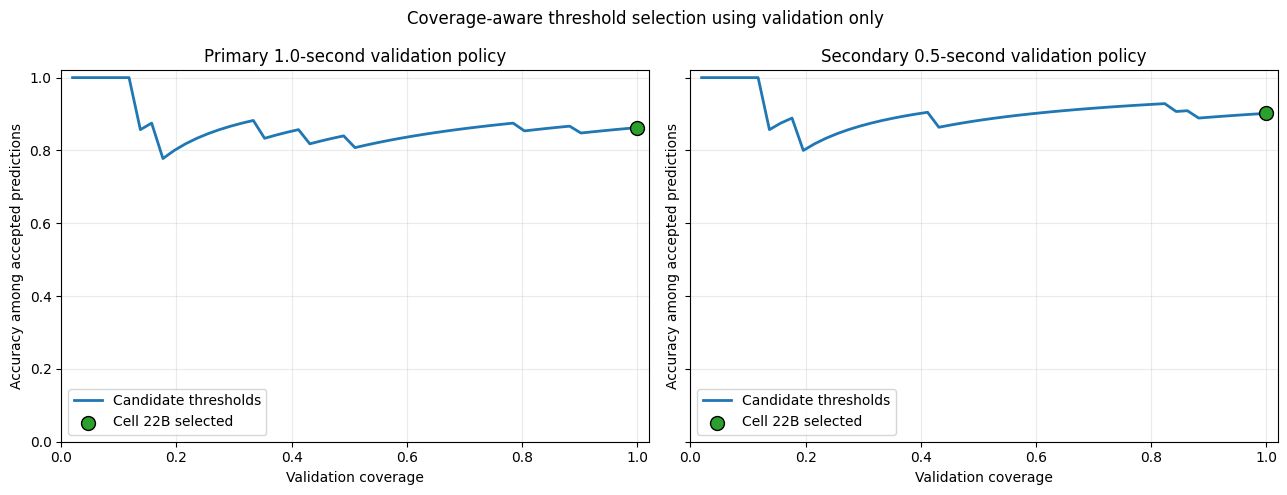

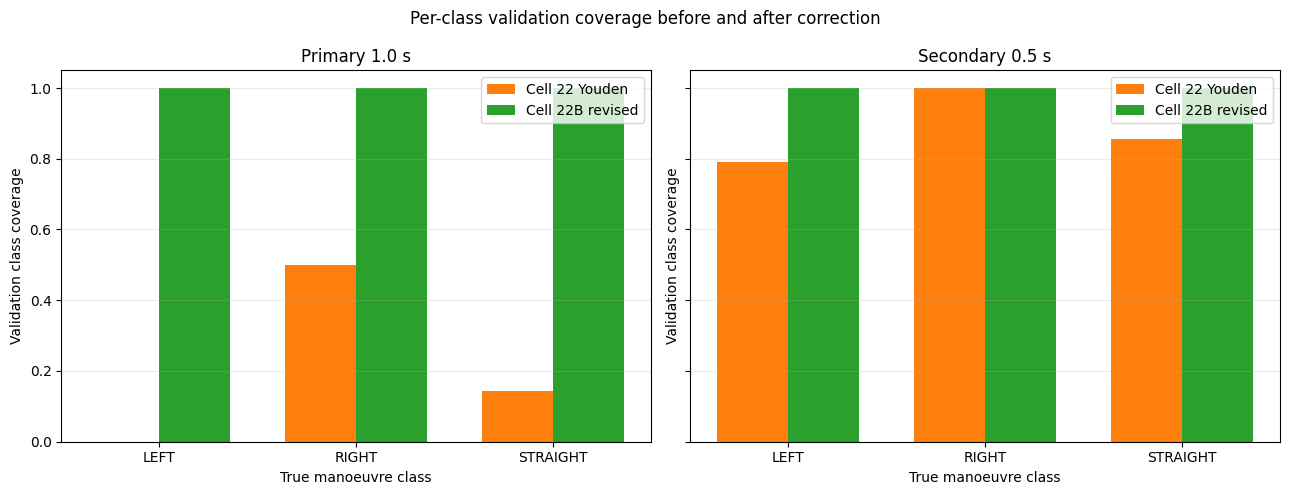


CELL 22B COMPLETED
The unusable Youden-only primary operating point was replaced with a validation-only coverage-aware policy.
No GRU was retrained, no architecture was changed, and recording 17 was not used for calibration or threshold selection.

Saved revised policy:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/calibrated_two_stage_policy/robust_policy_correction/robust_calibration_and_unknown_policy.json

Output directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/calibrated_two_stage_policy/robust_policy_correction

Next step:
Inspect the revised primary and secondary validation coverage, accepted accuracy, minimum class coverage, per-recording results, test report and all quality checks. If the revised primary policy is operationally usable, Cell 23 will package the two GRU models, scalers, feature specification and re

In [ ]:
# Cell 22B — Robust calibration audit and coverage-aware UNKNOWN correction
#
# Run this cell immediately after Cell 22 in the same Colab runtime.
#
# Why this correction is necessary
# --------------------------------
# Cell 22's validation-only Youden-J rule was mathematically valid, but the
# selected 1.0-second threshold rejected almost every vehicle and rejected
# every LEFT validation example. Such a policy is not operationally useful.
#
# Cell 22B therefore:
#   1. Does not retrain either locked GRU.
#   2. Does not perform another architecture search.
#   3. Audits calibration separately on validation recordings 15 and 16.
#   4. Retains temperature scaling only when it is stable by predeclared
#      validation-only proper-scoring-rule checks.
#   5. Selects a threshold with a coverage-aware validation score.
#   6. Makes any threshold that excludes a manoeuvre class or validation
#      recording ineligible.
#   7. Locks the revised policy before applying it to frozen recording-17
#      probabilities.
#
# Recording 17 is reported only after the policy is locked. It is never used
# to choose calibration or thresholds.

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
)


# ============================================================
# 1. CHECK REQUIRED CELL 22 OUTPUTS
# ============================================================

required_variables = [
    "class_indices",
    "class_labels",
    "class_index_to_label",
    "UNKNOWN_CLASS_INDEX",
    "UNKNOWN_CLASS_LABEL",
    "CALIBRATION_OUTPUT_DIRECTORY",
    "primary_validation_true",
    "secondary_validation_true",
    "primary_validation_metadata",
    "secondary_validation_metadata",
    "primary_validation_raw_probability",
    "secondary_validation_raw_probability",
    "FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY",
    "FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY",
    "FINAL_PRIMARY_TEMPERATURE",
    "FINAL_SECONDARY_TEMPERATURE",
    "FINAL_PRIMARY_UNKNOWN_THRESHOLD",
    "FINAL_SECONDARY_UNKNOWN_THRESHOLD",
    "primary_test_true",
    "secondary_test_true",
    "primary_test_metadata",
    "secondary_test_metadata",
    "primary_test_raw_probability",
    "secondary_test_raw_probability",
    "FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY",
    "FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY",
    "FINAL_CALIBRATION_POLICY_LOCKED",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

required_functions = [
    "apply_temperature_scaling",
    "multiclass_brier_score",
    "calculate_calibration_metrics",
    "calculate_selective_metrics",
    "create_per_class_selective_metrics",
    "create_prediction_table",
    "display_dataframe",
]

missing_functions = [
    function_name
    for function_name in required_functions
    if (
        function_name not in globals()
        or not callable(
            globals()[function_name]
        )
    )
]

if missing_variables or missing_functions:
    raise NameError(
        "Run Cell 22 before Cell 22B.\n"
        f"Missing variables: {missing_variables}\n"
        f"Missing functions: {missing_functions}"
    )

if not bool(
    FINAL_CALIBRATION_POLICY_LOCKED
):
    raise ValueError(
        "Cell 22 did not finish locking its first calibration policy."
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

PRIMARY_ROBUST_LEAD_TIME_SECONDS = 1.0
SECONDARY_ROBUST_LEAD_TIME_SECONDS = 0.5

# Only numerical comparisons use this tolerance. It is not an operational
# accuracy, coverage, or confidence requirement.
METRIC_COMPARISON_TOLERANCE = 1e-10

ROBUST_POLICY_OUTPUT_DIRECTORY = (
    Path(CALIBRATION_OUTPUT_DIRECTORY)
    / "robust_policy_correction"
)

ROBUST_POLICY_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def calculate_compact_probability_metrics(
    true_class,
    probability_matrix,
):
    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    probability_matrix = np.asarray(
        probability_matrix,
        dtype=np.float64,
    )

    predicted_class = np.argmax(
        probability_matrix,
        axis=1,
    )

    return {
        "sequence_count":
            int(len(true_class)),
        "accuracy":
            float(
                accuracy_score(
                    true_class,
                    predicted_class,
                )
            ),
        "negative_log_likelihood":
            float(
                log_loss(
                    true_class,
                    probability_matrix,
                    labels=class_indices,
                )
            ),
        "multiclass_brier_score":
            float(
                multiclass_brier_score(
                    true_class,
                    probability_matrix,
                )
            ),
        "mean_confidence":
            float(
                np.mean(
                    np.max(
                        probability_matrix,
                        axis=1,
                    )
                )
            ),
    }


def create_calibration_stability_audit(
    true_class,
    recording_ids,
    raw_probability,
    temperature_scaled_probability,
    lead_time_seconds,
):
    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    recording_ids = np.asarray(
        recording_ids,
        dtype=np.int64,
    )

    rows = []

    evaluation_scopes = [
        (
            "combined_validation",
            None,
            np.ones(
                len(true_class),
                dtype=bool,
            ),
        )
    ]

    for recording_id in sorted(
        np.unique(recording_ids).tolist()
    ):
        evaluation_scopes.append(
            (
                "individual_recording",
                int(recording_id),
                recording_ids
                == int(recording_id),
            )
        )

    for (
        scope,
        recording_id,
        sample_mask,
    ) in evaluation_scopes:
        for probability_state, probabilities in [
            (
                "raw",
                raw_probability,
            ),
            (
                "temperature_scaled",
                temperature_scaled_probability,
            ),
        ]:
            metrics = (
                calculate_compact_probability_metrics(
                    true_class[sample_mask],
                    probabilities[sample_mask],
                )
            )

            rows.append(
                {
                    "lead_time_seconds":
                        float(lead_time_seconds),
                    "scope":
                        scope,
                    "recording_id":
                        (
                            str(recording_id)
                            if recording_id
                            is not None
                            else "ALL"
                        ),
                    "probability_state":
                        probability_state,
                    **metrics,
                }
            )

    return pd.DataFrame(rows)


def choose_stable_probability_source(
    stability_audit,
    fitted_temperature,
):
    combined_rows = stability_audit[
        stability_audit["scope"]
        == "combined_validation"
    ]

    combined_raw = combined_rows[
        combined_rows[
            "probability_state"
        ]
        == "raw"
    ].iloc[0]

    combined_scaled = combined_rows[
        combined_rows[
            "probability_state"
        ]
        == "temperature_scaled"
    ].iloc[0]

    combined_nll_not_worse = bool(
        combined_scaled[
            "negative_log_likelihood"
        ]
        <= combined_raw[
            "negative_log_likelihood"
        ]
        + METRIC_COMPARISON_TOLERANCE
    )

    combined_brier_not_worse = bool(
        combined_scaled[
            "multiclass_brier_score"
        ]
        <= combined_raw[
            "multiclass_brier_score"
        ]
        + METRIC_COMPARISON_TOLERANCE
    )

    recording_rows = stability_audit[
        stability_audit["scope"]
        == "individual_recording"
    ]

    per_recording_nll_checks = []

    per_recording_check_details = []

    for recording_id in sorted(
        recording_rows[
            "recording_id"
        ].astype(int).unique().tolist()
    ):
        recording_data = recording_rows[
            recording_rows[
                "recording_id"
            ].astype(int)
            == int(recording_id)
        ]

        raw_nll = float(
            recording_data.loc[
                recording_data[
                    "probability_state"
                ]
                == "raw",
                "negative_log_likelihood",
            ].iloc[0]
        )

        scaled_nll = float(
            recording_data.loc[
                recording_data[
                    "probability_state"
                ]
                == "temperature_scaled",
                "negative_log_likelihood",
            ].iloc[0]
        )

        recording_nll_not_worse = bool(
            scaled_nll
            <= raw_nll
            + METRIC_COMPARISON_TOLERANCE
        )

        per_recording_nll_checks.append(
            recording_nll_not_worse
        )

        per_recording_check_details.append(
            {
                "recording_id":
                    int(recording_id),
                "raw_nll":
                    raw_nll,
                "scaled_nll":
                    scaled_nll,
                "scaled_nll_not_worse":
                    recording_nll_not_worse,
            }
        )

    every_recording_nll_not_worse = bool(
        all(per_recording_nll_checks)
    )

    retain_temperature_scaling = bool(
        combined_nll_not_worse
        and combined_brier_not_worse
        and every_recording_nll_not_worse
    )

    if retain_temperature_scaling:
        selected_probability_state = (
            "temperature_scaled"
        )

        deployment_temperature = float(
            fitted_temperature
        )

        decision_reason = (
            "Retained: combined validation NLL and Brier score "
            "did not worsen, and NLL did not worsen on either "
            "validation recording."
        )

    else:
        selected_probability_state = "raw"
        deployment_temperature = 1.0

        failed_conditions = []

        if not combined_nll_not_worse:
            failed_conditions.append(
                "combined validation NLL worsened"
            )

        if not combined_brier_not_worse:
            failed_conditions.append(
                "combined validation Brier score worsened"
            )

        if not every_recording_nll_not_worse:
            failed_conditions.append(
                "NLL worsened on at least one validation recording"
            )

        decision_reason = (
            "Rejected temperature scaling; deployment uses raw "
            "probabilities (temperature 1.0) because "
            + "; ".join(failed_conditions)
            + "."
        )

    return {
        "retain_temperature_scaling":
            retain_temperature_scaling,
        "selected_probability_state":
            selected_probability_state,
        "deployment_temperature":
            deployment_temperature,
        "combined_nll_not_worse":
            combined_nll_not_worse,
        "combined_brier_not_worse":
            combined_brier_not_worse,
        "every_recording_nll_not_worse":
            every_recording_nll_not_worse,
        "per_recording_nll_checks":
            per_recording_check_details,
        "decision_reason":
            decision_reason,
    }


def harmonic_mean_of_positive_values(
    values,
):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    if (
        not np.isfinite(values).all()
        or (values <= 0.0).any()
    ):
        return 0.0

    return float(
        len(values)
        / np.sum(
            1.0 / values
        )
    )


def build_coverage_aware_threshold_table(
    true_class,
    recording_ids,
    probability_matrix,
    lead_time_seconds,
    original_youden_threshold,
):
    """
    Score every observed validation confidence as a possible threshold.

    Equal-weight operational score components:
      1. accuracy among accepted predictions;
      2. overall coverage;
      3. worst true-class coverage;
      4. worst validation-recording coverage.

    The harmonic mean strongly penalizes a very small component. A threshold
    is ineligible if it accepts no sample from a manoeuvre class or from one
    of the validation recordings.
    """

    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    recording_ids = np.asarray(
        recording_ids,
        dtype=np.int64,
    )

    probability_matrix = np.asarray(
        probability_matrix,
        dtype=np.float64,
    )

    predicted_class = np.argmax(
        probability_matrix,
        axis=1,
    )

    confidence = np.max(
        probability_matrix,
        axis=1,
    )

    correctness = (
        predicted_class == true_class
    )

    candidate_thresholds = np.unique(
        np.concatenate(
            [
                np.array(
                    [0.0],
                    dtype=np.float64,
                ),
                confidence,
            ]
        )
    )

    unique_recording_ids = sorted(
        np.unique(recording_ids).tolist()
    )

    rows = []

    for threshold in candidate_thresholds:
        accepted = (
            confidence
            >= float(threshold)
        )

        accepted_count = int(
            np.sum(accepted)
        )

        coverage = float(
            np.mean(accepted)
        )

        if accepted_count > 0:
            accepted_accuracy = float(
                accuracy_score(
                    true_class[accepted],
                    predicted_class[accepted],
                )
            )

            accepted_macro_f1 = float(
                f1_score(
                    true_class[accepted],
                    predicted_class[accepted],
                    labels=class_indices,
                    average="macro",
                    zero_division=0,
                )
            )
        else:
            accepted_accuracy = np.nan
            accepted_macro_f1 = np.nan

        class_coverages = {}
        class_accepted_counts = {}

        for class_index in class_indices:
            class_mask = (
                true_class
                == int(class_index)
            )

            class_support = int(
                np.sum(class_mask)
            )

            class_accepted_count = int(
                np.sum(
                    class_mask & accepted
                )
            )

            class_coverage = float(
                class_accepted_count
                / class_support
            )

            class_label = (
                str(
                    class_index_to_label[
                        int(class_index)
                    ]
                )
                .strip()
                .lower()
            )

            class_coverages[
                class_label
            ] = class_coverage

            class_accepted_counts[
                class_label
            ] = class_accepted_count

        recording_coverages = {}
        recording_accepted_counts = {}

        for recording_id in unique_recording_ids:
            recording_mask = (
                recording_ids
                == int(recording_id)
            )

            recording_support = int(
                np.sum(recording_mask)
            )

            recording_accepted_count = int(
                np.sum(
                    recording_mask
                    & accepted
                )
            )

            recording_coverage = float(
                recording_accepted_count
                / recording_support
            )

            recording_coverages[
                int(recording_id)
            ] = recording_coverage

            recording_accepted_counts[
                int(recording_id)
            ] = recording_accepted_count

        minimum_class_coverage = float(
            min(
                class_coverages.values()
            )
        )

        minimum_recording_coverage = float(
            min(
                recording_coverages.values()
            )
        )

        all_classes_represented = bool(
            all(
                count > 0
                for count
                in class_accepted_counts.values()
            )
        )

        all_recordings_represented = bool(
            all(
                count > 0
                for count
                in recording_accepted_counts.values()
            )
        )

        eligible = bool(
            accepted_count > 0
            and all_classes_represented
            and all_recordings_represented
        )

        balanced_operational_score = (
            harmonic_mean_of_positive_values(
                [
                    accepted_accuracy,
                    coverage,
                    minimum_class_coverage,
                    minimum_recording_coverage,
                ]
            )
            if eligible
            else 0.0
        )

        row = {
            "lead_time_seconds":
                float(lead_time_seconds),
            "threshold":
                float(threshold),
            "accepted_count":
                accepted_count,
            "unknown_count":
                int(
                    len(true_class)
                    - accepted_count
                ),
            "coverage":
                coverage,
            "accepted_accuracy":
                accepted_accuracy,
            "accepted_macro_f1":
                accepted_macro_f1,
            "errors_accepted":
                int(
                    np.sum(
                        (~correctness)
                        & accepted
                    )
                ),
            "errors_rejected":
                int(
                    np.sum(
                        (~correctness)
                        & (~accepted)
                    )
                ),
            "correct_predictions_rejected":
                int(
                    np.sum(
                        correctness
                        & (~accepted)
                    )
                ),
            "unsafe_accepted_error_rate":
                float(
                    np.mean(
                        (~correctness)
                        & accepted
                    )
                ),
            "minimum_class_coverage":
                minimum_class_coverage,
            "minimum_recording_coverage":
                minimum_recording_coverage,
            "all_classes_represented":
                all_classes_represented,
            "all_recordings_represented":
                all_recordings_represented,
            "eligible":
                eligible,
            "balanced_operational_score":
                balanced_operational_score,
            "is_original_youden_threshold":
                bool(
                    np.isclose(
                        float(threshold),
                        float(
                            original_youden_threshold
                        ),
                        rtol=0.0,
                        atol=1e-12,
                    )
                ),
        }

        for (
            class_label,
            class_coverage,
        ) in class_coverages.items():
            row[
                f"coverage_class_{class_label}"
            ] = class_coverage

        for (
            recording_id,
            recording_coverage,
        ) in recording_coverages.items():
            row[
                f"coverage_recording_{recording_id}"
            ] = recording_coverage

        rows.append(row)

    threshold_table = pd.DataFrame(
        rows
    )

    eligible_candidates = threshold_table[
        threshold_table["eligible"]
    ].copy()

    if eligible_candidates.empty:
        raise ValueError(
            "No coverage-aware threshold accepts all manoeuvre "
            "classes and validation recordings."
        )

    # Predeclared tie-breaking:
    #   1. highest balanced operational score;
    #   2. lowest unsafe accepted-error rate;
    #   3. highest accepted macro F1;
    #   4. highest threshold.
    #
    # The last tie-break chooses the strongest confidence gate when all
    # validation behavior is otherwise identical. This means a threshold equal
    # to the smallest observed confidence is preferred over a threshold of 0.
    ranked_candidates = (
        eligible_candidates
        .sort_values(
            [
                "balanced_operational_score",
                "unsafe_accepted_error_rate",
                "accepted_macro_f1",
                "threshold",
            ],
            ascending=[
                False,
                True,
                False,
                False,
            ],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    selected_row = (
        ranked_candidates
        .iloc[0]
        .to_dict()
    )

    selected_threshold = float(
        selected_row["threshold"]
    )

    threshold_table[
        "selected"
    ] = np.isclose(
        threshold_table["threshold"],
        selected_threshold,
        rtol=0.0,
        atol=1e-12,
    )

    return (
        selected_threshold,
        selected_row,
        threshold_table,
    )


def create_recording_policy_metrics(
    true_class,
    recording_ids,
    probability_matrix,
    threshold,
    lead_time_seconds,
    split_name,
    policy_name,
):
    true_class = np.asarray(
        true_class,
        dtype=np.int64,
    )

    recording_ids = np.asarray(
        recording_ids,
        dtype=np.int64,
    )

    predicted_class = np.argmax(
        probability_matrix,
        axis=1,
    )

    confidence = np.max(
        probability_matrix,
        axis=1,
    )

    accepted = (
        confidence >= float(threshold)
    )

    rows = []

    for recording_id in sorted(
        np.unique(recording_ids).tolist()
    ):
        recording_mask = (
            recording_ids == int(recording_id)
        )

        recording_accepted = (
            recording_mask & accepted
        )

        support = int(
            np.sum(recording_mask)
        )

        accepted_count = int(
            np.sum(recording_accepted)
        )

        if accepted_count > 0:
            accepted_accuracy = float(
                accuracy_score(
                    true_class[
                        recording_accepted
                    ],
                    predicted_class[
                        recording_accepted
                    ],
                )
            )
        else:
            accepted_accuracy = np.nan

        rows.append(
            {
                "lead_time_seconds":
                    float(lead_time_seconds),
                "split":
                    str(split_name),
                "policy_name":
                    str(policy_name),
                "recording_id":
                    int(recording_id),
                "support":
                    support,
                "accepted_count":
                    accepted_count,
                "unknown_count":
                    int(
                        support
                        - accepted_count
                    ),
                "coverage":
                    float(
                        accepted_count
                        / support
                    ),
                "accepted_accuracy":
                    accepted_accuracy,
            }
        )

    return pd.DataFrame(rows)


def probability_matrix_is_valid(
    probability_matrix,
):
    probability_matrix = np.asarray(
        probability_matrix,
        dtype=np.float64,
    )

    return bool(
        probability_matrix.ndim == 2
        and np.isfinite(
            probability_matrix
        ).all()
        and (
            probability_matrix >= 0.0
        ).all()
        and (
            probability_matrix <= 1.0
        ).all()
        and np.allclose(
            probability_matrix.sum(axis=1),
            1.0,
            atol=1e-8,
        )
    )


# ============================================================
# 4. VALIDATION RECORDING ALIGNMENT
# ============================================================

if (
    "recording_id"
    not in primary_validation_metadata.columns
    or "recording_id"
    not in secondary_validation_metadata.columns
):
    raise KeyError(
        "Validation metadata must contain recording_id."
    )

primary_validation_recording_ids = (
    primary_validation_metadata[
        "recording_id"
    ].to_numpy(
        dtype=np.int64
    )
)

secondary_validation_recording_ids = (
    secondary_validation_metadata[
        "recording_id"
    ].to_numpy(
        dtype=np.int64
    )
)

if not np.array_equal(
    primary_validation_recording_ids,
    secondary_validation_recording_ids,
):
    raise ValueError(
        "Primary and secondary validation recording order differs."
    )

available_validation_recordings = sorted(
    np.unique(
        primary_validation_recording_ids
    ).tolist()
)

if available_validation_recordings != [
    15,
    16,
]:
    raise ValueError(
        "Cell 22B expects validation recordings [15, 16], "
        f"received {available_validation_recordings}."
    )


# ============================================================
# 5. CALIBRATION STABILITY AUDIT — VALIDATION ONLY
# ============================================================

primary_stability_audit = (
    create_calibration_stability_audit(
        primary_validation_true,
        primary_validation_recording_ids,
        primary_validation_raw_probability,
        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
    )
)

secondary_stability_audit = (
    create_calibration_stability_audit(
        secondary_validation_true,
        secondary_validation_recording_ids,
        secondary_validation_raw_probability,
        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
    )
)

FINAL_ROBUST_CALIBRATION_STABILITY_AUDIT = (
    pd.concat(
        [
            primary_stability_audit,
            secondary_stability_audit,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "lead_time_seconds",
            "scope",
            "recording_id",
            "probability_state",
        ],
        ascending=[
            False,
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

primary_calibration_decision = (
    choose_stable_probability_source(
        primary_stability_audit,
        FINAL_PRIMARY_TEMPERATURE,
    )
)

secondary_calibration_decision = (
    choose_stable_probability_source(
        secondary_stability_audit,
        FINAL_SECONDARY_TEMPERATURE,
    )
)

FINAL_ROBUST_PRIMARY_TEMPERATURE = float(
    primary_calibration_decision[
        "deployment_temperature"
    ]
)

FINAL_ROBUST_SECONDARY_TEMPERATURE = float(
    secondary_calibration_decision[
        "deployment_temperature"
    ]
)

if primary_calibration_decision[
    "retain_temperature_scaling"
]:
    FINAL_ROBUST_PRIMARY_VALIDATION_PROBABILITY = (
        np.asarray(
            FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
            dtype=np.float64,
        )
    )
else:
    FINAL_ROBUST_PRIMARY_VALIDATION_PROBABILITY = (
        np.asarray(
            primary_validation_raw_probability,
            dtype=np.float64,
        )
    )

if secondary_calibration_decision[
    "retain_temperature_scaling"
]:
    FINAL_ROBUST_SECONDARY_VALIDATION_PROBABILITY = (
        np.asarray(
            FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
            dtype=np.float64,
        )
    )
else:
    FINAL_ROBUST_SECONDARY_VALIDATION_PROBABILITY = (
        np.asarray(
            secondary_validation_raw_probability,
            dtype=np.float64,
        )
    )

FINAL_ROBUST_CALIBRATION_DECISIONS = pd.DataFrame(
    [
        {
            "lead_time_seconds":
                PRIMARY_ROBUST_LEAD_TIME_SECONDS,
            "cell22_fitted_temperature":
                float(
                    FINAL_PRIMARY_TEMPERATURE
                ),
            "retain_temperature_scaling":
                bool(
                    primary_calibration_decision[
                        "retain_temperature_scaling"
                    ]
                ),
            "selected_probability_state":
                primary_calibration_decision[
                    "selected_probability_state"
                ],
            "deployment_temperature":
                FINAL_ROBUST_PRIMARY_TEMPERATURE,
            "combined_nll_not_worse":
                primary_calibration_decision[
                    "combined_nll_not_worse"
                ],
            "combined_brier_not_worse":
                primary_calibration_decision[
                    "combined_brier_not_worse"
                ],
            "every_recording_nll_not_worse":
                primary_calibration_decision[
                    "every_recording_nll_not_worse"
                ],
            "decision_reason":
                primary_calibration_decision[
                    "decision_reason"
                ],
        },
        {
            "lead_time_seconds":
                SECONDARY_ROBUST_LEAD_TIME_SECONDS,
            "cell22_fitted_temperature":
                float(
                    FINAL_SECONDARY_TEMPERATURE
                ),
            "retain_temperature_scaling":
                bool(
                    secondary_calibration_decision[
                        "retain_temperature_scaling"
                    ]
                ),
            "selected_probability_state":
                secondary_calibration_decision[
                    "selected_probability_state"
                ],
            "deployment_temperature":
                FINAL_ROBUST_SECONDARY_TEMPERATURE,
            "combined_nll_not_worse":
                secondary_calibration_decision[
                    "combined_nll_not_worse"
                ],
            "combined_brier_not_worse":
                secondary_calibration_decision[
                    "combined_brier_not_worse"
                ],
            "every_recording_nll_not_worse":
                secondary_calibration_decision[
                    "every_recording_nll_not_worse"
                ],
            "decision_reason":
                secondary_calibration_decision[
                    "decision_reason"
                ],
        },
    ]
)

print(
    "Calibration stability was audited using validation "
    "recordings 15 and 16 only."
)

print(
    "Recording 17 has not been used for any Cell 22B "
    "calibration or threshold decision."
)


# ============================================================
# 6. COVERAGE-AWARE THRESHOLD SELECTION — VALIDATION ONLY
# ============================================================

(
    FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD,
    robust_primary_selected_row,
    FINAL_ROBUST_PRIMARY_THRESHOLD_CANDIDATES,
) = build_coverage_aware_threshold_table(
    primary_validation_true,
    primary_validation_recording_ids,
    FINAL_ROBUST_PRIMARY_VALIDATION_PROBABILITY,
    PRIMARY_ROBUST_LEAD_TIME_SECONDS,
    FINAL_PRIMARY_UNKNOWN_THRESHOLD,
)

(
    FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD,
    robust_secondary_selected_row,
    FINAL_ROBUST_SECONDARY_THRESHOLD_CANDIDATES,
) = build_coverage_aware_threshold_table(
    secondary_validation_true,
    secondary_validation_recording_ids,
    FINAL_ROBUST_SECONDARY_VALIDATION_PROBABILITY,
    SECONDARY_ROBUST_LEAD_TIME_SECONDS,
    FINAL_SECONDARY_UNKNOWN_THRESHOLD,
)

FINAL_ROBUST_SELECTED_THRESHOLDS = (
    pd.DataFrame(
        [
            {
                **robust_primary_selected_row,
                "selected_probability_state":
                    primary_calibration_decision[
                        "selected_probability_state"
                    ],
                "deployment_temperature":
                    FINAL_ROBUST_PRIMARY_TEMPERATURE,
                "selection_data":
                    "validation_recordings_15_16",
                "selection_method":
                    "coverage_aware_harmonic_score",
            },
            {
                **robust_secondary_selected_row,
                "selected_probability_state":
                    secondary_calibration_decision[
                        "selected_probability_state"
                    ],
                "deployment_temperature":
                    FINAL_ROBUST_SECONDARY_TEMPERATURE,
                "selection_data":
                    "validation_recordings_15_16",
                "selection_method":
                    "coverage_aware_harmonic_score",
            },
        ]
    )
    .sort_values(
        "lead_time_seconds",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ============================================================
# 7. LOCK REVISED POLICY BEFORE TEST REPORTING
# ============================================================

FINAL_ROBUST_CALIBRATION_AND_UNKNOWN_POLICY = {
    "policy_name":
        "robust_two_stage_gru_unknown_policy",
    "policy_version":
        2,
    "replaces_policy":
        "cell22_youden_j_policy",
    "models_retrained":
        False,
    "architecture_search_performed":
        False,
    "selection_data":
        {
            "validation_recordings":
                [15, 16],
            "test_recordings":
                [17],
            "test_used_for_calibration_decision":
                False,
            "test_used_for_threshold_selection":
                False,
        },
    "calibration_stability_gate":
        {
            "combined_validation_nll_must_not_worsen":
                True,
            "combined_validation_brier_must_not_worsen":
                True,
            "each_validation_recording_nll_must_not_worsen":
                True,
            "fallback":
                "raw_softmax_probabilities_temperature_1.0",
        },
    "threshold_selection":
        {
            "method":
                "maximum_equal_weight_harmonic_operational_score",
            "score_components":
                [
                    "accepted_accuracy",
                    "overall_coverage",
                    "minimum_true_class_coverage",
                    "minimum_validation_recording_coverage",
                ],
            "eligibility_requirements":
                [
                    "every_manoeuvre_class_has_at_least_one_accepted_validation_example",
                    "every_validation_recording_has_at_least_one_accepted_example",
                ],
            "invented_minimum_coverage_target":
                False,
        },
    "class_mapping":
        {
            str(int(class_index)):
                str(
                    class_index_to_label[
                        int(class_index)
                    ]
                )
            for class_index in class_indices
        },
    "unknown_class_index":
        int(UNKNOWN_CLASS_INDEX),
    "unknown_class_label":
        str(UNKNOWN_CLASS_LABEL),
    "primary_1.0s":
        {
            "role":
                "early_primary_prediction",
            "lead_time_seconds":
                PRIMARY_ROBUST_LEAD_TIME_SECONDS,
            "probability_state":
                primary_calibration_decision[
                    "selected_probability_state"
                ],
            "temperature":
                FINAL_ROBUST_PRIMARY_TEMPERATURE,
            "unknown_threshold":
                float(
                    FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD
                ),
        },
    "secondary_0.5s":
        {
            "role":
                "later_confirmation_prediction",
            "lead_time_seconds":
                SECONDARY_ROBUST_LEAD_TIME_SECONDS,
            "probability_state":
                secondary_calibration_decision[
                    "selected_probability_state"
                ],
            "temperature":
                FINAL_ROBUST_SECONDARY_TEMPERATURE,
            "unknown_threshold":
                float(
                    FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD
                ),
        },
    "runtime_safety_guidance":
        {
            "below_threshold":
                "return_UNKNOWN",
            "unknown_behavior":
                "preserve_probability_vector; increase_LDM_uncertainty; use_conservative_negotiation",
            "horizon_disagreement":
                "do_not_force_a_confident_label",
        },
}

FINAL_ROBUST_POLICY_LOCKED = True

print("\n" + "=" * 80)
print("REVISED POLICY LOCKED USING VALIDATION DATA ONLY")
print("=" * 80)

print(
    f"Primary 1.0 s: probability state = "
    f"{primary_calibration_decision['selected_probability_state']}, "
    f"temperature = {FINAL_ROBUST_PRIMARY_TEMPERATURE:.6f}, "
    f"threshold = {FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD:.6f}"
)

print(
    f"Secondary 0.5 s: probability state = "
    f"{secondary_calibration_decision['selected_probability_state']}, "
    f"temperature = {FINAL_ROBUST_SECONDARY_TEMPERATURE:.6f}, "
    f"threshold = {FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD:.6f}"
)

print(
    "\nOnly now will the revised policy be applied to the "
    "already-frozen recording-17 probabilities."
)


# ============================================================
# 8. APPLY LOCKED REVISED POLICY TO FROZEN TEST PROBABILITIES
# ============================================================

if not FINAL_ROBUST_POLICY_LOCKED:
    raise RuntimeError(
        "The revised policy must be locked before test reporting."
    )

FINAL_ROBUST_PRIMARY_TEST_PROBABILITY = (
    apply_temperature_scaling(
        primary_test_raw_probability,
        FINAL_ROBUST_PRIMARY_TEMPERATURE,
    )
)

FINAL_ROBUST_SECONDARY_TEST_PROBABILITY = (
    apply_temperature_scaling(
        secondary_test_raw_probability,
        FINAL_ROBUST_SECONDARY_TEMPERATURE,
    )
)


# ============================================================
# 9. ORIGINAL-VERSUS-REVISED POLICY METRICS
# ============================================================

policy_evaluation_items = [
    (
        "cell22_youden",
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "validation",
        primary_validation_true,
        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
        FINAL_PRIMARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22b_robust",
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "validation",
        primary_validation_true,
        FINAL_ROBUST_PRIMARY_VALIDATION_PROBABILITY,
        FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22_youden",
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        "validation",
        secondary_validation_true,
        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
        FINAL_SECONDARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22b_robust",
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        "validation",
        secondary_validation_true,
        FINAL_ROBUST_SECONDARY_VALIDATION_PROBABILITY,
        FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22_youden",
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "test",
        primary_test_true,
        FINAL_PRIMARY_CALIBRATED_TEST_PROBABILITY,
        FINAL_PRIMARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22b_robust",
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "test",
        primary_test_true,
        FINAL_ROBUST_PRIMARY_TEST_PROBABILITY,
        FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22_youden",
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        "test",
        secondary_test_true,
        FINAL_SECONDARY_CALIBRATED_TEST_PROBABILITY,
        FINAL_SECONDARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22b_robust",
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        "test",
        secondary_test_true,
        FINAL_ROBUST_SECONDARY_TEST_PROBABILITY,
        FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD,
    ),
]

policy_metric_rows = []
per_class_policy_tables = []

for (
    policy_name,
    lead_time_seconds,
    split_name,
    true_class,
    probability_matrix,
    threshold,
) in policy_evaluation_items:
    (
        metric_row,
        selective_output,
    ) = calculate_selective_metrics(
        true_class,
        probability_matrix,
        threshold,
        lead_time_seconds,
        split_name,
    )

    metric_row[
        "policy_name"
    ] = policy_name

    policy_metric_rows.append(
        metric_row
    )

    per_class_table = (
        create_per_class_selective_metrics(
            true_class,
            selective_output,
            lead_time_seconds,
            split_name,
        )
    )

    per_class_table[
        "policy_name"
    ] = policy_name

    per_class_policy_tables.append(
        per_class_table
    )

FINAL_ROBUST_POLICY_COMPARISON_METRICS = (
    pd.DataFrame(
        policy_metric_rows
    )
    .sort_values(
        [
            "split",
            "lead_time_seconds",
            "policy_name",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

FINAL_ROBUST_PER_CLASS_POLICY_METRICS = (
    pd.concat(
        per_class_policy_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "split",
            "lead_time_seconds",
            "class_index",
            "policy_name",
        ],
        ascending=[
            False,
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

validation_recording_policy_tables = []

for (
    policy_name,
    lead_time_seconds,
    true_class,
    recording_ids,
    probability_matrix,
    threshold,
) in [
    (
        "cell22_youden",
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        primary_validation_true,
        primary_validation_recording_ids,
        FINAL_PRIMARY_CALIBRATED_VALIDATION_PROBABILITY,
        FINAL_PRIMARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22b_robust",
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        primary_validation_true,
        primary_validation_recording_ids,
        FINAL_ROBUST_PRIMARY_VALIDATION_PROBABILITY,
        FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22_youden",
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        secondary_validation_true,
        secondary_validation_recording_ids,
        FINAL_SECONDARY_CALIBRATED_VALIDATION_PROBABILITY,
        FINAL_SECONDARY_UNKNOWN_THRESHOLD,
    ),
    (
        "cell22b_robust",
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        secondary_validation_true,
        secondary_validation_recording_ids,
        FINAL_ROBUST_SECONDARY_VALIDATION_PROBABILITY,
        FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD,
    ),
]:
    validation_recording_policy_tables.append(
        create_recording_policy_metrics(
            true_class,
            recording_ids,
            probability_matrix,
            threshold,
            lead_time_seconds,
            "validation",
            policy_name,
        )
    )

FINAL_ROBUST_VALIDATION_RECORDING_POLICY_METRICS = (
    pd.concat(
        validation_recording_policy_tables,
        ignore_index=True,
    )
    .sort_values(
        [
            "lead_time_seconds",
            "recording_id",
            "policy_name",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


# ============================================================
# 10. REVISED PER-SEQUENCE TABLES
# ============================================================

FINAL_ROBUST_PRIMARY_VALIDATION_PREDICTIONS = (
    create_prediction_table(
        primary_validation_metadata,
        primary_validation_true,
        primary_validation_raw_probability,
        FINAL_ROBUST_PRIMARY_VALIDATION_PROBABILITY,
        FINAL_ROBUST_PRIMARY_TEMPERATURE,
        FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD,
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "validation",
    )
)

FINAL_ROBUST_SECONDARY_VALIDATION_PREDICTIONS = (
    create_prediction_table(
        secondary_validation_metadata,
        secondary_validation_true,
        secondary_validation_raw_probability,
        FINAL_ROBUST_SECONDARY_VALIDATION_PROBABILITY,
        FINAL_ROBUST_SECONDARY_TEMPERATURE,
        FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD,
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        "validation",
    )
)

FINAL_ROBUST_PRIMARY_TEST_PREDICTIONS = (
    create_prediction_table(
        primary_test_metadata,
        primary_test_true,
        primary_test_raw_probability,
        FINAL_ROBUST_PRIMARY_TEST_PROBABILITY,
        FINAL_ROBUST_PRIMARY_TEMPERATURE,
        FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD,
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "test",
    )
)

FINAL_ROBUST_SECONDARY_TEST_PREDICTIONS = (
    create_prediction_table(
        secondary_test_metadata,
        secondary_test_true,
        secondary_test_raw_probability,
        FINAL_ROBUST_SECONDARY_TEST_PROBABILITY,
        FINAL_ROBUST_SECONDARY_TEMPERATURE,
        FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD,
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        "test",
    )
)


# ============================================================
# 11. QUALITY CHECKS
# ============================================================

def get_policy_metric(
    lead_time_seconds,
    split_name,
    policy_name,
    metric_name,
):
    matching_rows = (
        FINAL_ROBUST_POLICY_COMPARISON_METRICS[
            (
                FINAL_ROBUST_POLICY_COMPARISON_METRICS[
                    "lead_time_seconds"
                ]
                == float(lead_time_seconds)
            )
            & (
                FINAL_ROBUST_POLICY_COMPARISON_METRICS[
                    "split"
                ]
                == str(split_name)
            )
            & (
                FINAL_ROBUST_POLICY_COMPARISON_METRICS[
                    "policy_name"
                ]
                == str(policy_name)
            )
        ]
    )

    if len(matching_rows) != 1:
        raise ValueError(
            "Expected exactly one policy metric row."
        )

    return float(
        matching_rows.iloc[0][
            metric_name
        ]
    )


original_primary_validation_coverage = (
    get_policy_metric(
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "validation",
        "cell22_youden",
        "coverage",
    )
)

revised_primary_validation_coverage = (
    get_policy_metric(
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "validation",
        "cell22b_robust",
        "coverage",
    )
)

revised_primary_validation_per_class = (
    FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
        (
            FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
                "lead_time_seconds"
            ]
            == PRIMARY_ROBUST_LEAD_TIME_SECONDS
        )
        & (
            FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
                "split"
            ]
            == "validation"
        )
        & (
            FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
                "policy_name"
            ]
            == "cell22b_robust"
        )
    ]
)

revised_secondary_validation_per_class = (
    FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
        (
            FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
                "lead_time_seconds"
            ]
            == SECONDARY_ROBUST_LEAD_TIME_SECONDS
        )
        & (
            FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
                "split"
            ]
            == "validation"
        )
        & (
            FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
                "policy_name"
            ]
            == "cell22b_robust"
        )
    ]
)

FINAL_ROBUST_POLICY_QUALITY_CHECKS = pd.DataFrame(
    [
        {
            "check":
                "Validation recordings are exactly 15 and 16",
            "passed":
                bool(
                    available_validation_recordings
                    == [15, 16]
                ),
            "details":
                str(
                    available_validation_recordings
                ),
        },
        {
            "check":
                "No GRU retraining or architecture search",
            "passed":
                True,
            "details":
                "reused frozen Cell 20 and Cell 21 probabilities",
        },
        {
            "check":
                "Calibration stability decision used validation only",
            "passed":
                True,
            "details":
                "combined validation plus recordings 15 and 16 separately",
        },
        {
            "check":
                "Threshold selection used validation only",
            "passed":
                True,
            "details":
                "recording 17 loaded only after revised policy lock",
        },
        {
            "check":
                "Primary selected threshold is eligible",
            "passed":
                bool(
                    robust_primary_selected_row[
                        "eligible"
                    ]
                ),
            "details":
                (
                    "all classes and validation recordings represented"
                ),
        },
        {
            "check":
                "Secondary selected threshold is eligible",
            "passed":
                bool(
                    robust_secondary_selected_row[
                        "eligible"
                    ]
                ),
            "details":
                (
                    "all classes and validation recordings represented"
                ),
        },
        {
            "check":
                "Revised primary validation coverage improved",
            "passed":
                bool(
                    revised_primary_validation_coverage
                    > original_primary_validation_coverage
                    + METRIC_COMPARISON_TOLERANCE
                ),
            "details":
                (
                    f"{original_primary_validation_coverage:.6f}"
                    " -> "
                    f"{revised_primary_validation_coverage:.6f}"
                ),
        },
        {
            "check":
                "Revised primary accepts every validation class",
            "passed":
                bool(
                    (
                        revised_primary_validation_per_class[
                            "accepted_count"
                        ]
                        > 0
                    ).all()
                ),
            "details":
                (
                    revised_primary_validation_per_class[
                        [
                            "manoeuvre_label",
                            "accepted_count",
                        ]
                    ]
                    .to_dict(
                        orient="records"
                    )
                ),
        },
        {
            "check":
                "Revised secondary accepts every validation class",
            "passed":
                bool(
                    (
                        revised_secondary_validation_per_class[
                            "accepted_count"
                        ]
                        > 0
                    ).all()
                ),
            "details":
                (
                    revised_secondary_validation_per_class[
                        [
                            "manoeuvre_label",
                            "accepted_count",
                        ]
                    ]
                    .to_dict(
                        orient="records"
                    )
                ),
        },
        {
            "check":
                "Revised validation probabilities are valid",
            "passed":
                bool(
                    probability_matrix_is_valid(
                        FINAL_ROBUST_PRIMARY_VALIDATION_PROBABILITY
                    )
                    and probability_matrix_is_valid(
                        FINAL_ROBUST_SECONDARY_VALIDATION_PROBABILITY
                    )
                ),
            "details":
                "finite, bounded and rows sum to one",
        },
        {
            "check":
                "Revised test probabilities are valid",
            "passed":
                bool(
                    probability_matrix_is_valid(
                        FINAL_ROBUST_PRIMARY_TEST_PROBABILITY
                    )
                    and probability_matrix_is_valid(
                        FINAL_ROBUST_SECONDARY_TEST_PROBABILITY
                    )
                ),
            "details":
                "frozen test outputs transformed after lock",
        },
        {
            "check":
                "Revised thresholds are valid probabilities",
            "passed":
                bool(
                    0.0
                    <= FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD
                    <= 1.0
                    and 0.0
                    <= FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD
                    <= 1.0
                ),
            "details":
                (
                    f"primary={FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD:.6f}, "
                    f"secondary={FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD:.6f}"
                ),
        },
        {
            "check":
                "Revised policy locked before test reporting",
            "passed":
                bool(
                    FINAL_ROBUST_POLICY_LOCKED
                ),
            "details":
                "test was not used for selection",
        },
    ]
)

if not bool(
    FINAL_ROBUST_POLICY_QUALITY_CHECKS[
        "passed"
    ].all()
):
    failed_checks = (
        FINAL_ROBUST_POLICY_QUALITY_CHECKS.loc[
            ~FINAL_ROBUST_POLICY_QUALITY_CHECKS[
                "passed"
            ],
            [
                "check",
                "details",
            ],
        ]
    )

    raise ValueError(
        "One or more Cell 22B quality checks failed:\n"
        + failed_checks.to_string(
            index=False
        )
    )


# ============================================================
# 12. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("CALIBRATION STABILITY AUDIT")
print("=" * 80)

display_dataframe(
    FINAL_ROBUST_CALIBRATION_STABILITY_AUDIT
)

print("\n" + "=" * 80)
print("CALIBRATION DEPLOYMENT DECISIONS")
print("=" * 80)

display_dataframe(
    FINAL_ROBUST_CALIBRATION_DECISIONS
)

print("\n" + "=" * 80)
print("REVISED VALIDATION-SELECTED THRESHOLDS")
print("=" * 80)

display_dataframe(
    FINAL_ROBUST_SELECTED_THRESHOLDS[
        [
            "lead_time_seconds",
            "selected_probability_state",
            "deployment_temperature",
            "threshold",
            "coverage",
            "accepted_accuracy",
            "accepted_macro_f1",
            "minimum_class_coverage",
            "minimum_recording_coverage",
            "balanced_operational_score",
        ]
    ]
)

print("\n" + "=" * 80)
print("CELL 22 POLICY VERSUS CELL 22B REVISED POLICY")
print("=" * 80)

display_dataframe(
    FINAL_ROBUST_POLICY_COMPARISON_METRICS[
        [
            "lead_time_seconds",
            "split",
            "policy_name",
            "threshold",
            "sequence_count",
            "accepted_count",
            "unknown_count",
            "coverage",
            "accepted_accuracy",
            "accepted_macro_f1",
            "errors_accepted",
            "errors_rejected",
            "correct_predictions_rejected",
            "unsafe_accepted_error_rate",
        ]
    ]
)

print("\n" + "=" * 80)
print("PER-CLASS COVERAGE — ORIGINAL VERSUS REVISED")
print("=" * 80)

display_dataframe(
    FINAL_ROBUST_PER_CLASS_POLICY_METRICS
)

print("\n" + "=" * 80)
print("VALIDATION RECORDING ROBUSTNESS")
print("=" * 80)

display_dataframe(
    FINAL_ROBUST_VALIDATION_RECORDING_POLICY_METRICS
)

print("\n" + "=" * 80)
print("QUALITY CHECKS")
print("=" * 80)

display_dataframe(
    FINAL_ROBUST_POLICY_QUALITY_CHECKS
)


# ============================================================
# 13. COVERAGE–ACCURACY FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharex=True,
    sharey=True,
)

for (
    axis,
    threshold_table,
    title,
) in [
    (
        axes[0],
        FINAL_ROBUST_PRIMARY_THRESHOLD_CANDIDATES,
        "Primary 1.0-second validation policy",
    ),
    (
        axes[1],
        FINAL_ROBUST_SECONDARY_THRESHOLD_CANDIDATES,
        "Secondary 0.5-second validation policy",
    ),
]:
    plot_data = (
        threshold_table[
            threshold_table[
                "accepted_accuracy"
            ].notna()
        ]
        .sort_values("coverage")
    )

    axis.plot(
        plot_data["coverage"],
        plot_data["accepted_accuracy"],
        color="tab:blue",
        linewidth=2.0,
        label="Candidate thresholds",
    )

    selected_row = threshold_table[
        threshold_table["selected"]
    ].iloc[0]

    axis.scatter(
        selected_row["coverage"],
        selected_row["accepted_accuracy"],
        color="tab:green",
        edgecolor="black",
        s=100,
        zorder=5,
        label="Cell 22B selected",
    )

    axis.set_title(title)
    axis.set_xlabel("Validation coverage")
    axis.set_ylabel(
        "Accuracy among accepted predictions"
    )
    axis.set_xlim(0.0, 1.02)
    axis.set_ylim(0.0, 1.02)
    axis.grid(alpha=0.25)
    axis.legend()

fig.suptitle(
    "Coverage-aware threshold selection using validation only"
)

fig.tight_layout()

coverage_accuracy_figure_path = (
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "coverage_accuracy_threshold_selection.png"
)

fig.savefig(
    coverage_accuracy_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 14. PER-CLASS VALIDATION COVERAGE FIGURE
# ============================================================

validation_class_plot_data = (
    FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
        FINAL_ROBUST_PER_CLASS_POLICY_METRICS[
            "split"
        ]
        == "validation"
    ]
    .pivot_table(
        index=[
            "lead_time_seconds",
            "manoeuvre_label",
        ],
        columns="policy_name",
        values="class_coverage",
        aggfunc="first",
    )
    .reset_index()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharey=True,
)

for (
    axis,
    lead_time_seconds,
    title,
) in [
    (
        axes[0],
        PRIMARY_ROBUST_LEAD_TIME_SECONDS,
        "Primary 1.0 s",
    ),
    (
        axes[1],
        SECONDARY_ROBUST_LEAD_TIME_SECONDS,
        "Secondary 0.5 s",
    ),
]:
    horizon_data = (
        validation_class_plot_data[
            validation_class_plot_data[
                "lead_time_seconds"
            ]
            == lead_time_seconds
        ]
        .set_index(
            "manoeuvre_label"
        )
        .reindex(
            class_labels
        )
    )

    x_positions = np.arange(
        len(class_labels)
    )

    bar_width = 0.36

    axis.bar(
        x_positions
        - bar_width / 2,
        horizon_data[
            "cell22_youden"
        ],
        width=bar_width,
        label="Cell 22 Youden",
        color="tab:orange",
    )

    axis.bar(
        x_positions
        + bar_width / 2,
        horizon_data[
            "cell22b_robust"
        ],
        width=bar_width,
        label="Cell 22B revised",
        color="tab:green",
    )

    axis.set_title(title)
    axis.set_xticks(
        x_positions,
        class_labels,
    )
    axis.set_xlabel("True manoeuvre class")
    axis.set_ylabel("Validation class coverage")
    axis.set_ylim(0.0, 1.05)
    axis.grid(
        axis="y",
        alpha=0.25,
    )
    axis.legend()

fig.suptitle(
    "Per-class validation coverage before and after correction"
)

fig.tight_layout()

per_class_coverage_figure_path = (
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "per_class_validation_coverage.png"
)

fig.savefig(
    per_class_coverage_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 15. SAVE REVISED POLICY ARTIFACTS
# ============================================================

FINAL_ROBUST_CALIBRATION_STABILITY_AUDIT.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "calibration_stability_audit.csv",
    index=False,
)

FINAL_ROBUST_CALIBRATION_DECISIONS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "calibration_deployment_decisions.csv",
    index=False,
)

FINAL_ROBUST_PRIMARY_THRESHOLD_CANDIDATES.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "primary_1.0s_robust_threshold_candidates.csv",
    index=False,
)

FINAL_ROBUST_SECONDARY_THRESHOLD_CANDIDATES.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "secondary_0.5s_robust_threshold_candidates.csv",
    index=False,
)

FINAL_ROBUST_SELECTED_THRESHOLDS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "robust_selected_thresholds.csv",
    index=False,
)

FINAL_ROBUST_POLICY_COMPARISON_METRICS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "original_vs_revised_policy_metrics.csv",
    index=False,
)

FINAL_ROBUST_PER_CLASS_POLICY_METRICS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "original_vs_revised_per_class_metrics.csv",
    index=False,
)

FINAL_ROBUST_VALIDATION_RECORDING_POLICY_METRICS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "validation_recording_policy_metrics.csv",
    index=False,
)

FINAL_ROBUST_PRIMARY_VALIDATION_PREDICTIONS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "primary_1.0s_validation_revised_predictions.csv",
    index=False,
)

FINAL_ROBUST_SECONDARY_VALIDATION_PREDICTIONS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "secondary_0.5s_validation_revised_predictions.csv",
    index=False,
)

FINAL_ROBUST_PRIMARY_TEST_PREDICTIONS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "primary_1.0s_test_revised_predictions.csv",
    index=False,
)

FINAL_ROBUST_SECONDARY_TEST_PREDICTIONS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "secondary_0.5s_test_revised_predictions.csv",
    index=False,
)

FINAL_ROBUST_POLICY_QUALITY_CHECKS.to_csv(
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "robust_policy_quality_checks.csv",
    index=False,
)

robust_policy_path = (
    ROBUST_POLICY_OUTPUT_DIRECTORY
    / "robust_calibration_and_unknown_policy.json"
)

with open(
    robust_policy_path,
    "w",
    encoding="utf-8",
) as policy_file:
    json.dump(
        FINAL_ROBUST_CALIBRATION_AND_UNKNOWN_POLICY,
        policy_file,
        indent=2,
    )


# ============================================================
# 16. COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("CELL 22B COMPLETED")
print("=" * 80)

print(
    "The unusable Youden-only primary operating point was "
    "replaced with a validation-only coverage-aware policy."
)

print(
    "No GRU was retrained, no architecture was changed, and "
    "recording 17 was not used for calibration or threshold selection."
)

print("\nSaved revised policy:")
print(
    f"  {robust_policy_path}"
)

print("\nOutput directory:")
print(
    f"  {ROBUST_POLICY_OUTPUT_DIRECTORY}"
)

print("\nNext step:")
print(
    "Inspect the revised primary and secondary validation coverage, "
    "accepted accuracy, minimum class coverage, per-recording results, "
    "test report and all quality checks. If the revised primary policy "
    "is operationally usable, Cell 23 will package the two GRU models, "
    "scalers, feature specification and revised policy into a deployment "
    "inference wrapper before SUMO/LDM integration."
)


In [ ]:
# Cell 23 — Package and verify the deployment inference wrapper
#
# Run this cell after Cell 22B in the same Colab runtime.
#
# This cell does not train or tune any model. It:
#   1. reconstructs and verifies the two training-only scalers;
#   2. saves the two locked GRU models into one deployment bundle;
#   3. saves the exact 48 × 6 causal-feature contract and revised policy;
#   4. defines a reusable two-stage inference wrapper;
#   5. reloads the saved bundle and proves that its outputs reproduce the
#      frozen notebook predictions;
#   6. verifies UNKNOWN and horizon-disagreement safety behavior.
#
# Important sampling contract
# ---------------------------
# The model was trained from 50 position samples at 25 Hz (0.04 s intervals).
# Two backward differences produce 48 timesteps × 6 causal motion features.
# A SUMO history collected only every 0.5 s must not be silently interpolated
# and presented to this model as real 25 Hz measurements.

from pathlib import Path
import hashlib
import importlib.util
import inspect
import json
import shutil

import numpy as np
import pandas as pd


class InDIntentionPredictor:
    # Deployment-only wrapper for the two locked inD GRU models.

    def __init__(self, bundle_directory):
        try:
            import tensorflow as tf
        except ImportError as error:
            raise ImportError(
                "TensorFlow is required to load the GRU models."
            ) from error

        self.bundle_directory = Path(
            bundle_directory
        )

        manifest_path = (
            self.bundle_directory
            / "deployment_manifest.json"
        )

        policy_path = (
            self.bundle_directory
            / "robust_calibration_and_unknown_policy.json"
        )

        scaler_path = (
            self.bundle_directory
            / "training_only_scalers.npz"
        )

        with open(
            manifest_path,
            "r",
            encoding="utf-8",
        ) as manifest_file:
            self.manifest = json.load(
                manifest_file
            )

        with open(
            policy_path,
            "r",
            encoding="utf-8",
        ) as policy_file:
            self.policy = json.load(
                policy_file
            )

        scaler_archive = np.load(
            scaler_path,
            allow_pickle=False,
        )

        self.feature_names = list(
            self.manifest[
                "input_contract"
            ][
                "causal_feature_names"
            ]
        )

        self.sequence_timestep_count = int(
            self.manifest[
                "input_contract"
            ][
                "causal_sequence_shape"
            ][0]
        )

        self.feature_count = int(
            self.manifest[
                "input_contract"
            ][
                "causal_sequence_shape"
            ][1]
        )

        self.position_history_frame_count = int(
            self.manifest[
                "input_contract"
            ][
                "position_history_shape"
            ][0]
        )

        self.frame_interval_seconds = float(
            self.manifest[
                "input_contract"
            ][
                "frame_interval_seconds"
            ]
        )

        self.class_mapping = {
            int(class_index):
                str(class_label)
            for class_index, class_label
            in self.manifest[
                "class_mapping"
            ].items()
        }

        self.unknown_class_index = int(
            self.policy[
                "unknown_class_index"
            ]
        )

        self.unknown_class_label = str(
            self.policy[
                "unknown_class_label"
            ]
        )

        self.horizon_configuration = {
            1.0: {
                "role":
                    "primary",
                "model_file":
                    self.manifest[
                        "models"
                    ][
                        "primary_1.0s"
                    ][
                        "file"
                    ],
                "mean":
                    np.asarray(
                        scaler_archive[
                            "primary_mean"
                        ],
                        dtype=np.float64,
                    ),
                "standard_deviation":
                    np.asarray(
                        scaler_archive[
                            "primary_standard_deviation"
                        ],
                        dtype=np.float64,
                    ),
                "temperature":
                    float(
                        self.policy[
                            "primary_1.0s"
                        ][
                            "temperature"
                        ]
                    ),
                "threshold":
                    float(
                        self.policy[
                            "primary_1.0s"
                        ][
                            "unknown_threshold"
                        ]
                    ),
            },
            0.5: {
                "role":
                    "secondary",
                "model_file":
                    self.manifest[
                        "models"
                    ][
                        "secondary_0.5s"
                    ][
                        "file"
                    ],
                "mean":
                    np.asarray(
                        scaler_archive[
                            "secondary_mean"
                        ],
                        dtype=np.float64,
                    ),
                "standard_deviation":
                    np.asarray(
                        scaler_archive[
                            "secondary_standard_deviation"
                        ],
                        dtype=np.float64,
                    ),
                "temperature":
                    float(
                        self.policy[
                            "secondary_0.5s"
                        ][
                            "temperature"
                        ]
                    ),
                "threshold":
                    float(
                        self.policy[
                            "secondary_0.5s"
                        ][
                            "unknown_threshold"
                        ]
                    ),
            },
        }

        for (
            lead_time,
            configuration,
        ) in self.horizon_configuration.items():
            if (
                configuration["mean"].shape
                != (self.feature_count,)
                or configuration[
                    "standard_deviation"
                ].shape
                != (self.feature_count,)
            ):
                raise ValueError(
                    f"Scaler shape is invalid for lead={lead_time}s."
                )

            if (
                not np.isfinite(
                    configuration["mean"]
                ).all()
                or not np.isfinite(
                    configuration[
                        "standard_deviation"
                    ]
                ).all()
                or (
                    configuration[
                        "standard_deviation"
                    ]
                    <= 0.0
                ).any()
            ):
                raise ValueError(
                    f"Scaler is invalid for lead={lead_time}s."
                )

        self.models = {
            lead_time:
                tf.keras.models.load_model(
                    self.bundle_directory
                    / configuration[
                        "model_file"
                    ],
                    compile=False,
                )
            for lead_time, configuration
            in self.horizon_configuration.items()
        }

        expected_model_shape = (
            None,
            self.sequence_timestep_count,
            self.feature_count,
        )

        for lead_time, model in self.models.items():
            if (
                tuple(model.input_shape)
                != expected_model_shape
            ):
                raise ValueError(
                    f"Model input shape for lead={lead_time}s is "
                    f"{model.input_shape}; expected "
                    f"{expected_model_shape}."
                )

    def _resolve_lead_time(
        self,
        lead_time_seconds,
    ):
        lead_time_seconds = float(
            lead_time_seconds
        )

        for configured_lead_time in (
            self.horizon_configuration
        ):
            if np.isclose(
                lead_time_seconds,
                configured_lead_time,
            ):
                return float(
                    configured_lead_time
                )

        raise ValueError(
            "lead_time_seconds must be 1.0 or 0.5."
        )

    def _validate_raw_causal_sequences(
        self,
        raw_causal_sequences,
    ):
        raw_causal_sequences = np.asarray(
            raw_causal_sequences,
            dtype=np.float64,
        )

        input_was_single_sequence = bool(
            raw_causal_sequences.ndim == 2
        )

        if input_was_single_sequence:
            raw_causal_sequences = (
                raw_causal_sequences[
                    None,
                    :,
                    :,
                ]
            )

        expected_trailing_shape = (
            self.sequence_timestep_count,
            self.feature_count,
        )

        if (
            raw_causal_sequences.ndim != 3
            or raw_causal_sequences.shape[1:]
            != expected_trailing_shape
        ):
            raise ValueError(
                "raw_causal_sequences must have shape "
                f"{expected_trailing_shape} or "
                f"(batch, {expected_trailing_shape[0]}, "
                f"{expected_trailing_shape[1]})."
            )

        if not np.isfinite(
            raw_causal_sequences
        ).all():
            raise ValueError(
                "raw_causal_sequences contains NaN or infinity."
            )

        return (
            raw_causal_sequences,
            input_was_single_sequence,
        )

    def scale_raw_causal_sequences(
        self,
        raw_causal_sequences,
        lead_time_seconds,
    ):
        lead_time = self._resolve_lead_time(
            lead_time_seconds
        )

        (
            raw_causal_sequences,
            input_was_single_sequence,
        ) = self._validate_raw_causal_sequences(
            raw_causal_sequences
        )

        configuration = (
            self.horizon_configuration[
                lead_time
            ]
        )

        scaled_sequences = (
            (
                raw_causal_sequences
                - configuration[
                    "mean"
                ].reshape(
                    1,
                    1,
                    -1,
                )
            )
            / configuration[
                "standard_deviation"
            ].reshape(
                1,
                1,
                -1,
            )
        ).astype(
            np.float32
        )

        if input_was_single_sequence:
            return scaled_sequences[0]

        return scaled_sequences

    @staticmethod
    def _apply_temperature(
        probability_matrix,
        temperature,
    ):
        probability_matrix = np.asarray(
            probability_matrix,
            dtype=np.float64,
        )

        temperature = float(temperature)

        if np.isclose(
            temperature,
            1.0,
            rtol=0.0,
            atol=1e-12,
        ):
            return probability_matrix.copy()

        clipped_probability = np.clip(
            probability_matrix,
            1e-12,
            1.0,
        )

        scaled_log_probability = (
            np.log(clipped_probability)
            / temperature
        )

        scaled_log_probability = (
            scaled_log_probability
            - scaled_log_probability.max(
                axis=1,
                keepdims=True,
            )
        )

        scaled_exponential = np.exp(
            scaled_log_probability
        )

        return (
            scaled_exponential
            / scaled_exponential.sum(
                axis=1,
                keepdims=True,
            )
        )

    def predict_probabilities(
        self,
        raw_causal_sequences,
        lead_time_seconds,
    ):
        lead_time = self._resolve_lead_time(
            lead_time_seconds
        )

        (
            raw_causal_sequences,
            input_was_single_sequence,
        ) = self._validate_raw_causal_sequences(
            raw_causal_sequences
        )

        scaled_sequences = (
            self.scale_raw_causal_sequences(
                raw_causal_sequences,
                lead_time,
            )
        )

        raw_probability = (
            self.models[
                lead_time
            ].predict(
                scaled_sequences,
                verbose=0,
            )
        )

        final_probability = (
            self._apply_temperature(
                raw_probability,
                self.horizon_configuration[
                    lead_time
                ][
                    "temperature"
                ],
            )
        )

        if not (
            np.isfinite(
                final_probability
            ).all()
            and np.allclose(
                final_probability.sum(
                    axis=1
                ),
                1.0,
                atol=1e-6,
            )
        ):
            raise ValueError(
                "Model returned invalid probabilities."
            )

        if input_was_single_sequence:
            return final_probability[0]

        return final_probability

    def decision_from_probability(
        self,
        probability,
        lead_time_seconds,
    ):
        lead_time = self._resolve_lead_time(
            lead_time_seconds
        )

        probability = np.asarray(
            probability,
            dtype=np.float64,
        )

        if probability.shape != (
            len(self.class_mapping),
        ):
            raise ValueError(
                "probability must contain three class values."
            )

        if not (
            np.isfinite(
                probability
            ).all()
            and (
                probability >= 0.0
            ).all()
            and np.isclose(
                probability.sum(),
                1.0,
                atol=1e-6,
            )
        ):
            raise ValueError(
                "probability is not a valid probability vector."
            )

        predicted_class_index = int(
            np.argmax(probability)
        )

        confidence_score = float(
            np.max(probability)
        )

        threshold = float(
            self.horizon_configuration[
                lead_time
            ][
                "threshold"
            ]
        )

        accepted = bool(
            confidence_score >= threshold
        )

        if accepted:
            output_class_index = (
                predicted_class_index
            )

            output_label = (
                self.class_mapping[
                    predicted_class_index
                ]
            )
        else:
            output_class_index = (
                self.unknown_class_index
            )

            output_label = (
                self.unknown_class_label
            )

        return {
            "lead_time_seconds":
                lead_time,
            "role":
                self.horizon_configuration[
                    lead_time
                ][
                    "role"
                ],
            "probability":
                probability.astype(
                    float
                ).tolist(),
            "predicted_class_index":
                predicted_class_index,
            "predicted_label":
                self.class_mapping[
                    predicted_class_index
                ],
            "confidence_score":
                confidence_score,
            "threshold":
                threshold,
            "accepted":
                accepted,
            "output_class_index":
                output_class_index,
            "output_label":
                output_label,
        }

    def predict_horizon(
        self,
        raw_causal_sequences,
        lead_time_seconds,
    ):
        probability = self.predict_probabilities(
            raw_causal_sequences,
            lead_time_seconds,
        )

        if probability.ndim == 1:
            return self.decision_from_probability(
                probability,
                lead_time_seconds,
            )

        return [
            self.decision_from_probability(
                row_probability,
                lead_time_seconds,
            )
            for row_probability in probability
        ]

    def predict_primary(
        self,
        raw_causal_sequences,
    ):
        return self.predict_horizon(
            raw_causal_sequences,
            1.0,
        )

    def predict_secondary(
        self,
        raw_causal_sequences,
    ):
        return self.predict_horizon(
            raw_causal_sequences,
            0.5,
        )

    def combine_horizon_results(
        self,
        primary_result,
        secondary_result,
    ):
        if not secondary_result[
            "accepted"
        ]:
            final_label = (
                self.unknown_class_label
            )
            final_class_index = (
                self.unknown_class_index
            )
            status = (
                "SECONDARY_UNCERTAIN"
            )

        elif not primary_result[
            "accepted"
        ]:
            final_label = (
                secondary_result[
                    "output_label"
                ]
            )
            final_class_index = (
                secondary_result[
                    "output_class_index"
                ]
            )
            status = (
                "SECONDARY_RECOVERY"
            )

        elif (
            primary_result[
                "output_class_index"
            ]
            == secondary_result[
                "output_class_index"
            ]
        ):
            final_label = (
                secondary_result[
                    "output_label"
                ]
            )
            final_class_index = (
                secondary_result[
                    "output_class_index"
                ]
            )
            status = (
                "CONFIRMED_AGREEMENT"
            )

        else:
            final_label = (
                self.unknown_class_label
            )
            final_class_index = (
                self.unknown_class_index
            )
            status = (
                "HORIZON_DISAGREEMENT"
            )

        return {
            "primary":
                primary_result,
            "secondary":
                secondary_result,
            "final_output_label":
                final_label,
            "final_output_class_index":
                int(final_class_index),
            "status":
                status,
            "requires_conservative_negotiation":
                bool(
                    final_label
                    == self.unknown_class_label
                ),
        }

    def predict_two_stage(
        self,
        primary_raw_causal_sequence,
        secondary_raw_causal_sequence,
    ):
        primary_result = self.predict_primary(
            primary_raw_causal_sequence
        )

        secondary_result = (
            self.predict_secondary(
                secondary_raw_causal_sequence
            )
        )

        return self.combine_horizon_results(
            primary_result,
            secondary_result,
        )

    def build_causal_features_from_positions(
        self,
        position_history_m,
        frame_interval_seconds=None,
    ):
        position_history_m = np.asarray(
            position_history_m,
            dtype=np.float64,
        )

        input_was_single_sequence = bool(
            position_history_m.ndim == 2
        )

        if input_was_single_sequence:
            position_history_m = (
                position_history_m[
                    None,
                    :,
                    :,
                ]
            )

        expected_trailing_shape = (
            self.position_history_frame_count,
            2,
        )

        if (
            position_history_m.ndim != 3
            or position_history_m.shape[1:]
            != expected_trailing_shape
        ):
            raise ValueError(
                "position_history_m must have shape "
                f"{expected_trailing_shape} or "
                f"(batch, {expected_trailing_shape[0]}, 2)."
            )

        if not np.isfinite(
            position_history_m
        ).all():
            raise ValueError(
                "position_history_m contains NaN or infinity."
            )

        if frame_interval_seconds is None:
            frame_interval_seconds = (
                self.frame_interval_seconds
            )

        frame_interval_seconds = float(
            frame_interval_seconds
        )

        if not np.isclose(
            frame_interval_seconds,
            self.frame_interval_seconds,
            rtol=0.0,
            atol=1e-6,
        ):
            raise ValueError(
                "This model requires position samples at "
                f"{self.frame_interval_seconds:.6f} s intervals. "
                "Do not silently interpolate a lower-frequency "
                "SUMO history."
            )

        velocity = (
            position_history_m[:, 1:, :]
            - position_history_m[:, :-1, :]
        ) / frame_interval_seconds

        acceleration = (
            velocity[:, 1:, :]
            - velocity[:, :-1, :]
        ) / frame_interval_seconds

        aligned_velocity = velocity[:, 1:, :]

        approach_end_index = min(
            10,
            position_history_m.shape[1]
            - 1,
        )

        approach_vector = (
            position_history_m[
                :,
                approach_end_index,
                :,
            ]
            - position_history_m[
                :,
                0,
                :,
            ]
        )

        approach_norm = np.linalg.norm(
            approach_vector,
            axis=1,
        )

        fallback_vector = (
            position_history_m[
                :,
                -1,
                :,
            ]
            - position_history_m[
                :,
                0,
                :,
            ]
        )

        fallback_mask = (
            approach_norm < 1e-6
        )

        approach_vector[
            fallback_mask
        ] = fallback_vector[
            fallback_mask
        ]

        approach_norm = np.linalg.norm(
            approach_vector,
            axis=1,
        )

        if np.any(
            approach_norm < 1e-6
        ):
            raise ValueError(
                "At least one position history has no "
                "measurable movement."
            )

        approach_unit = (
            approach_vector
            / approach_norm[:, None]
        )

        lateral_unit = np.column_stack(
            [
                -approach_unit[:, 1],
                approach_unit[:, 0],
            ]
        )

        longitudinal_velocity = np.einsum(
            "ntd,nd->nt",
            aligned_velocity,
            approach_unit,
        )

        lateral_velocity = np.einsum(
            "ntd,nd->nt",
            aligned_velocity,
            lateral_unit,
        )

        longitudinal_acceleration = (
            np.einsum(
                "ntd,nd->nt",
                acceleration,
                approach_unit,
            )
        )

        lateral_acceleration = np.einsum(
            "ntd,nd->nt",
            acceleration,
            lateral_unit,
        )

        speed = np.linalg.norm(
            aligned_velocity,
            axis=2,
        )

        acceleration_magnitude = np.linalg.norm(
            acceleration,
            axis=2,
        )

        causal_features = np.stack(
            [
                speed,
                acceleration_magnitude,
                longitudinal_velocity,
                lateral_velocity,
                longitudinal_acceleration,
                lateral_acceleration,
            ],
            axis=2,
        ).astype(
            np.float32
        )

        expected_feature_shape = (
            self.sequence_timestep_count,
            self.feature_count,
        )

        if (
            causal_features.shape[1:]
            != expected_feature_shape
        ):
            raise ValueError(
                "Derived causal-feature shape is "
                f"{causal_features.shape[1:]}; expected "
                f"{expected_feature_shape}."
            )

        if input_was_single_sequence:
            return causal_features[0]

        return causal_features

    def predict_from_positions(
        self,
        position_history_m,
        lead_time_seconds,
        frame_interval_seconds=None,
    ):
        causal_features = (
            self.build_causal_features_from_positions(
                position_history_m,
                frame_interval_seconds,
            )
        )

        return self.predict_horizon(
            causal_features,
            lead_time_seconds,
        )


# ============================================================
# CELL 23 EXECUTION — VERIFY AND PACKAGE THE WRAPPER
# ============================================================


# ============================================================
# 1. CHECK REQUIRED OUTPUTS FROM CELLS 18–22B
# ============================================================

required_variables = [
    "FINAL_CAUSAL_MOTION_DATASETS",
    "FINAL_PRIMARY_COMMON_COHORT_DATASETS",
    "FINAL_PRIMARY_GRU_DATASET",
    "FINAL_SECONDARY_GRU_DATASET",
    "FINAL_SELECTED_GRU_MODEL",
    "FINAL_SECONDARY_GRU_MODEL",
    "FINAL_ROBUST_CALIBRATION_AND_UNKNOWN_POLICY",
    "FINAL_ROBUST_PRIMARY_UNKNOWN_THRESHOLD",
    "FINAL_ROBUST_SECONDARY_UNKNOWN_THRESHOLD",
    "FINAL_ROBUST_PRIMARY_TEMPERATURE",
    "FINAL_ROBUST_SECONDARY_TEMPERATURE",
    "FINAL_ROBUST_PRIMARY_TEST_PREDICTIONS",
    "FINAL_ROBUST_SECONDARY_TEST_PREDICTIONS",
    "gru_test_probability",
    "secondary_gru_test_probability",
    "GRU_PREPARATION_OUTPUT_DIRECTORY",
    "class_indices",
    "class_index_to_label",
    "UNKNOWN_CLASS_LABEL",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

required_functions = [
    "unpack_common_cohort_dataset",
    "find_feature_index",
]

missing_functions = [
    function_name
    for function_name in required_functions
    if (
        function_name not in globals()
        or not callable(
            globals()[function_name]
        )
    )
]

if missing_variables or missing_functions:
    raise NameError(
        "Run Cells 18, 19, 20, 21, 22 and 22B before Cell 23.\n"
        f"Missing variables: {missing_variables}\n"
        f"Missing functions: {missing_functions}"
    )


# ============================================================
# 2. FIXED DEPLOYMENT CONTRACT
# ============================================================

DEPLOYMENT_TRAINING_RECORDING_IDS = [
    7, 8, 9, 10,
    11, 12, 13, 14,
]

DEPLOYMENT_VALIDATION_RECORDING_IDS = [
    15,
    16,
]

DEPLOYMENT_TEST_RECORDING_IDS = [
    17,
]

DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS = 1.0
DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS = 0.5

EXPECTED_POSITION_FRAME_COUNT = 50
EXPECTED_CAUSAL_TIMESTEP_COUNT = 48
EXPECTED_CAUSAL_FEATURE_COUNT = 6
EXPECTED_FRAME_INTERVAL_SECONDS = 1.0 / 25.0

EXPECTED_CAUSAL_FEATURE_NAMES = [
    "position_derived_speed_mps",
    "position_derived_acceleration_magnitude_mps2",
    "approach_longitudinal_velocity_mps",
    "approach_lateral_velocity_mps",
    "approach_longitudinal_acceleration_mps2",
    "approach_lateral_acceleration_mps2",
]

SCALER_MATCH_TOLERANCE = 1e-5
PROBABILITY_MATCH_TOLERANCE = 1e-5
FEATURE_BUILDER_MATCH_TOLERANCE = 1e-5

DEPLOYMENT_BUNDLE_DIRECTORY = (
    Path(GRU_PREPARATION_OUTPUT_DIRECTORY)
    / "deployment_bundle"
)

DEPLOYMENT_BUNDLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 3. DATA AND PACKAGING HELPERS
# ============================================================

def resolve_dataset_for_lead_time(
    dataset_collection,
    lead_time_seconds,
):
    if lead_time_seconds in dataset_collection:
        return dataset_collection[
            lead_time_seconds
        ]

    for key, value in (
        dataset_collection.items()
    ):
        try:
            if np.isclose(
                float(key),
                float(lead_time_seconds),
            ):
                return value
        except (TypeError, ValueError):
            continue

    raise KeyError(
        f"No dataset found for lead={lead_time_seconds}s. "
        f"Available keys: {list(dataset_collection.keys())}"
    )


def unpack_causal_dataset(
    dataset_collection,
    lead_time_seconds,
):
    dataset = resolve_dataset_for_lead_time(
        dataset_collection,
        lead_time_seconds,
    )

    required_keys = [
        "X",
        "y",
        "groups",
        "metadata",
        "feature_names",
        "frame_interval_seconds",
    ]

    missing_keys = [
        key
        for key in required_keys
        if key not in dataset
    ]

    if missing_keys:
        raise KeyError(
            f"Causal dataset for lead={lead_time_seconds}s "
            f"is missing keys: {missing_keys}"
        )

    raw_X = np.asarray(
        dataset["X"],
        dtype=np.float32,
    )

    y = np.asarray(
        dataset["y"],
        dtype=np.int64,
    )

    groups = np.asarray(
        dataset["groups"],
        dtype=np.int64,
    )

    metadata = (
        dataset["metadata"]
        .copy()
        .reset_index(drop=True)
    )

    feature_names = list(
        dataset["feature_names"]
    )

    frame_interval_seconds = float(
        dataset["frame_interval_seconds"]
    )

    if raw_X.shape[1:] != (
        EXPECTED_CAUSAL_TIMESTEP_COUNT,
        EXPECTED_CAUSAL_FEATURE_COUNT,
    ):
        raise ValueError(
            f"Unexpected raw causal shape for "
            f"lead={lead_time_seconds}s: {raw_X.shape}"
        )

    if not (
        len(raw_X)
        == len(y)
        == len(groups)
        == len(metadata)
    ):
        raise ValueError(
            "Causal arrays and metadata lengths differ."
        )

    if feature_names != (
        EXPECTED_CAUSAL_FEATURE_NAMES
    ):
        raise ValueError(
            f"Feature order for lead={lead_time_seconds}s differs "
            "from the locked six-feature deployment contract."
        )

    if not np.isclose(
        frame_interval_seconds,
        EXPECTED_FRAME_INTERVAL_SECONDS,
        rtol=0.0,
        atol=1e-6,
    ):
        raise ValueError(
            f"Expected a 25 Hz frame interval of "
            f"{EXPECTED_FRAME_INTERVAL_SECONDS}s, received "
            f"{frame_interval_seconds}s."
        )

    if not np.isfinite(raw_X).all():
        raise ValueError(
            "Raw causal dataset contains NaN or infinity."
        )

    return {
        "X":
            raw_X,
        "y":
            y,
        "groups":
            groups,
        "metadata":
            metadata,
        "feature_names":
            feature_names,
        "frame_interval_seconds":
            frame_interval_seconds,
    }


def reconstruct_and_verify_scaler(
    causal_dataset,
    prepared_dataset,
    lead_time_seconds,
):
    raw_X = causal_dataset["X"]
    groups = causal_dataset["groups"]

    training_mask = np.isin(
        groups,
        DEPLOYMENT_TRAINING_RECORDING_IDS,
    )

    validation_mask = np.isin(
        groups,
        DEPLOYMENT_VALIDATION_RECORDING_IDS,
    )

    test_mask = np.isin(
        groups,
        DEPLOYMENT_TEST_RECORDING_IDS,
    )

    raw_training_X = raw_X[
        training_mask
    ]

    training_frames = (
        raw_training_X
        .reshape(
            -1,
            raw_training_X.shape[2],
        )
        .astype(
            np.float64
        )
    )

    training_mean = (
        training_frames.mean(
            axis=0,
            dtype=np.float64,
        )
    )

    training_standard_deviation = (
        training_frames.std(
            axis=0,
            dtype=np.float64,
        )
    )

    zero_variance_mask = (
        training_standard_deviation
        < 1e-8
    )

    safe_standard_deviation = (
        training_standard_deviation.copy()
    )

    safe_standard_deviation[
        zero_variance_mask
    ] = 1.0

    def scale(raw_sequences):
        return (
            (
                raw_sequences.astype(
                    np.float64
                )
                - training_mean.reshape(
                    1,
                    1,
                    -1,
                )
            )
            / safe_standard_deviation.reshape(
                1,
                1,
                -1,
            )
        ).astype(
            np.float32
        )

    split_items = [
        (
            "train",
            training_mask,
            "X_train",
            "y_train",
        ),
        (
            "validation",
            validation_mask,
            "X_validation",
            "y_validation",
        ),
        (
            "test",
            test_mask,
            "X_test",
            "y_test",
        ),
    ]

    split_differences = {}
    split_label_matches = {}
    split_counts = {}

    for (
        split_name,
        split_mask,
        X_key,
        y_key,
    ) in split_items:
        reconstructed_scaled_X = scale(
            raw_X[split_mask]
        )

        stored_scaled_X = np.asarray(
            prepared_dataset[X_key],
            dtype=np.float32,
        )

        if (
            reconstructed_scaled_X.shape
            != stored_scaled_X.shape
        ):
            raise ValueError(
                f"Reconstructed {split_name} shape for "
                f"lead={lead_time_seconds}s differs from Cell 19."
            )

        maximum_difference = float(
            np.max(
                np.abs(
                    reconstructed_scaled_X.astype(
                        np.float64
                    )
                    - stored_scaled_X.astype(
                        np.float64
                    )
                )
            )
        )

        split_differences[
            split_name
        ] = maximum_difference

        stored_y = np.asarray(
            prepared_dataset[y_key],
            dtype=np.int64,
        )

        split_label_matches[
            split_name
        ] = bool(
            np.array_equal(
                causal_dataset["y"][
                    split_mask
                ],
                stored_y,
            )
        )

        split_counts[
            split_name
        ] = int(
            np.sum(split_mask)
        )

    maximum_scaler_difference = float(
        max(
            split_differences.values()
        )
    )

    scaler_matches_cell19 = bool(
        maximum_scaler_difference
        <= SCALER_MATCH_TOLERANCE
        and all(
            split_label_matches.values()
        )
    )

    if not scaler_matches_cell19:
        raise ValueError(
            f"Reconstructed scaler for lead={lead_time_seconds}s "
            "does not reproduce Cell 19. Maximum difference: "
            f"{maximum_scaler_difference:.8g}; label matches: "
            f"{split_label_matches}"
        )

    return {
        "mean":
            training_mean,
        "standard_deviation":
            safe_standard_deviation,
        "original_standard_deviation":
            training_standard_deviation,
        "zero_variance_mask":
            zero_variance_mask,
        "maximum_scaled_array_difference":
            maximum_scaler_difference,
        "split_differences":
            split_differences,
        "split_label_matches":
            split_label_matches,
        "split_counts":
            split_counts,
        "scale_function":
            scale,
    }


def calculate_file_sha256(
    file_path,
):
    digest = hashlib.sha256()

    with open(
        file_path,
        "rb",
    ) as input_file:
        while True:
            data_block = input_file.read(
                1024 * 1024
            )

            if not data_block:
                break

            digest.update(data_block)

    return digest.hexdigest()


def export_wrapper_module_source(
    output_path,
):
    class_source = None
    source_method = None

    try:
        class_source = inspect.getsource(
            InDIntentionPredictor
        )
        source_method = "inspect.getsource"
    except (OSError, TypeError):
        class_source = None

    if class_source is None:
        try:
            ipython_shell = get_ipython()

            for input_source in reversed(
                ipython_shell
                .history_manager
                .input_hist_raw
            ):
                class_start = input_source.find(
                    "class InDIntentionPredictor:"
                )

                class_end = input_source.find(
                    "# ============================================================\n"
                    "# CELL 23 EXECUTION",
                    class_start,
                )

                if (
                    class_start >= 0
                    and class_end > class_start
                ):
                    class_source = input_source[
                        class_start:
                        class_end
                    ].rstrip()

                    source_method = (
                        "IPython input history"
                    )
                    break

        except Exception:
            class_source = None

    if class_source is None:
        raise RuntimeError(
            "Could not export the wrapper class source from this "
            "Colab runtime. Run Cell 23 as one complete cell rather "
            "than executing only selected lines."
        )

    module_preamble = (
        "from pathlib import Path\n"
        "import json\n\n"
        "import numpy as np\n\n\n"
    )

    wrapper_module_source = (
        module_preamble
        + class_source
        + "\n"
    )

    compile(
        wrapper_module_source,
        str(output_path),
        "exec",
    )

    with open(
        output_path,
        "w",
        encoding="utf-8",
    ) as output_file:
        output_file.write(
            wrapper_module_source
        )

    return {
        "source_method":
            source_method,
        "line_count":
            int(
                len(
                    wrapper_module_source
                    .splitlines()
                )
            ),
    }


def load_wrapper_module(
    wrapper_module_path,
):
    module_name = (
        "ind_intention_predictor_runtime"
    )

    module_specification = (
        importlib.util
        .spec_from_file_location(
            module_name,
            wrapper_module_path,
        )
    )

    if (
        module_specification is None
        or module_specification.loader
        is None
    ):
        raise ImportError(
            "Could not create an import specification "
            "for the saved deployment wrapper."
        )

    wrapper_module = (
        importlib.util
        .module_from_spec(
            module_specification
        )
    )

    module_specification.loader.exec_module(
        wrapper_module
    )

    return wrapper_module


# ============================================================
# 4. RECONSTRUCT AND VERIFY TRAINING-ONLY SCALERS
# ============================================================

primary_causal_dataset = (
    unpack_causal_dataset(
        FINAL_CAUSAL_MOTION_DATASETS,
        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
    )
)

secondary_causal_dataset = (
    unpack_causal_dataset(
        FINAL_CAUSAL_MOTION_DATASETS,
        DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
    )
)

primary_scaler = (
    reconstruct_and_verify_scaler(
        primary_causal_dataset,
        FINAL_PRIMARY_GRU_DATASET,
        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
    )
)

secondary_scaler = (
    reconstruct_and_verify_scaler(
        secondary_causal_dataset,
        FINAL_SECONDARY_GRU_DATASET,
        DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
    )
)

FINAL_DEPLOYMENT_SCALER_VERIFICATION = pd.DataFrame(
    [
        {
            "lead_time_seconds":
                DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
            "training_sequence_count":
                primary_scaler[
                    "split_counts"
                ][
                    "train"
                ],
            "validation_sequence_count":
                primary_scaler[
                    "split_counts"
                ][
                    "validation"
                ],
            "test_sequence_count":
                primary_scaler[
                    "split_counts"
                ][
                    "test"
                ],
            "feature_count":
                int(
                    len(
                        primary_scaler[
                            "mean"
                        ]
                    )
                ),
            "zero_variance_feature_count":
                int(
                    np.sum(
                        primary_scaler[
                            "zero_variance_mask"
                        ]
                    )
                ),
            "maximum_scaled_array_difference":
                primary_scaler[
                    "maximum_scaled_array_difference"
                ],
            "all_labels_match":
                bool(
                    all(
                        primary_scaler[
                            "split_label_matches"
                        ].values()
                    )
                ),
        },
        {
            "lead_time_seconds":
                DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
            "training_sequence_count":
                secondary_scaler[
                    "split_counts"
                ][
                    "train"
                ],
            "validation_sequence_count":
                secondary_scaler[
                    "split_counts"
                ][
                    "validation"
                ],
            "test_sequence_count":
                secondary_scaler[
                    "split_counts"
                ][
                    "test"
                ],
            "feature_count":
                int(
                    len(
                        secondary_scaler[
                            "mean"
                        ]
                    )
                ),
            "zero_variance_feature_count":
                int(
                    np.sum(
                        secondary_scaler[
                            "zero_variance_mask"
                        ]
                    )
                ),
            "maximum_scaled_array_difference":
                secondary_scaler[
                    "maximum_scaled_array_difference"
                ],
            "all_labels_match":
                bool(
                    all(
                        secondary_scaler[
                            "split_label_matches"
                        ].values()
                    )
                ),
        },
    ]
)


# ============================================================
# 5. SAVE LOCKED MODELS, SCALERS, POLICY AND SPECIFICATION
# ============================================================

primary_bundle_model_path = (
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "primary_1.0s_gru.keras"
)

secondary_bundle_model_path = (
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "secondary_0.5s_gru.keras"
)

FINAL_SELECTED_GRU_MODEL.save(
    primary_bundle_model_path,
    overwrite=True,
)

FINAL_SECONDARY_GRU_MODEL.save(
    secondary_bundle_model_path,
    overwrite=True,
)

scaler_bundle_path = (
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "training_only_scalers.npz"
)

np.savez(
    scaler_bundle_path,
    primary_mean=
        primary_scaler["mean"],
    primary_standard_deviation=
        primary_scaler[
            "standard_deviation"
        ],
    primary_original_standard_deviation=
        primary_scaler[
            "original_standard_deviation"
        ],
    primary_zero_variance_mask=
        primary_scaler[
            "zero_variance_mask"
        ],
    secondary_mean=
        secondary_scaler["mean"],
    secondary_standard_deviation=
        secondary_scaler[
            "standard_deviation"
        ],
    secondary_original_standard_deviation=
        secondary_scaler[
            "original_standard_deviation"
        ],
    secondary_zero_variance_mask=
        secondary_scaler[
            "zero_variance_mask"
        ],
)

policy_bundle_path = (
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "robust_calibration_and_unknown_policy.json"
)

with open(
    policy_bundle_path,
    "w",
    encoding="utf-8",
) as policy_file:
    json.dump(
        FINAL_ROBUST_CALIBRATION_AND_UNKNOWN_POLICY,
        policy_file,
        indent=2,
    )

feature_specification = {
    "feature_source":
        "causal_backward_differences_from_position_history",
    "published_inD_velocity_or_acceleration_used":
        False,
    "position_history_shape":
        [
            EXPECTED_POSITION_FRAME_COUNT,
            2,
        ],
    "position_columns":
        [
            "x_m",
            "y_m",
        ],
    "frame_interval_seconds":
        EXPECTED_FRAME_INTERVAL_SECONDS,
    "sampling_frequency_hz":
        1.0
        / EXPECTED_FRAME_INTERVAL_SECONDS,
    "nominal_observation_window_seconds":
        2.0,
    "causal_sequence_shape":
        [
            EXPECTED_CAUSAL_TIMESTEP_COUNT,
            EXPECTED_CAUSAL_FEATURE_COUNT,
        ],
    "causal_feature_names":
        EXPECTED_CAUSAL_FEATURE_NAMES,
    "approach_direction_estimation":
        "position_at_frame_10_minus_position_at_frame_0",
    "differencing":
        {
            "velocity":
                "backward_first_difference",
            "acceleration":
                "backward_difference_of_backward_velocity",
            "future_frames_used":
                False,
        },
    "primary_prediction_lead_time_seconds":
        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
    "secondary_prediction_lead_time_seconds":
        DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
    "sumo_integration_warning":
        (
            "The current 0.5-second SUMO history does not satisfy "
            "this 0.04-second input contract. Do not silently "
            "interpolate four low-rate observations into fifty "
            "measurements."
        ),
}

feature_specification_path = (
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "feature_specification.json"
)

with open(
    feature_specification_path,
    "w",
    encoding="utf-8",
) as feature_file:
    json.dump(
        feature_specification,
        feature_file,
        indent=2,
    )

wrapper_module_path = (
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "ind_intention_predictor.py"
)

wrapper_source_export = (
    export_wrapper_module_source(
        wrapper_module_path
    )
)


# ============================================================
# 6. WRITE INITIAL DEPLOYMENT MANIFEST
# ============================================================

deployment_manifest_path = (
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "deployment_manifest.json"
)

deployment_manifest = {
    "bundle_name":
        "inD_two_stage_intention_predictor",
    "bundle_version":
        1,
    "training_complete":
        True,
    "models_retrained_in_cell_23":
        False,
    "architecture_changed_in_cell_23":
        False,
    "models":
        {
            "primary_1.0s":
                {
                    "file":
                        primary_bundle_model_path.name,
                    "role":
                        "early_primary_prediction",
                    "lead_time_seconds":
                        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
                    "input_shape":
                        [
                            EXPECTED_CAUSAL_TIMESTEP_COUNT,
                            EXPECTED_CAUSAL_FEATURE_COUNT,
                        ],
                },
            "secondary_0.5s":
                {
                    "file":
                        secondary_bundle_model_path.name,
                    "role":
                        "later_confirmation_prediction",
                    "lead_time_seconds":
                        DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
                    "input_shape":
                        [
                            EXPECTED_CAUSAL_TIMESTEP_COUNT,
                            EXPECTED_CAUSAL_FEATURE_COUNT,
                        ],
                },
        },
    "scaler_file":
        scaler_bundle_path.name,
    "feature_specification_file":
        feature_specification_path.name,
    "policy_file":
        policy_bundle_path.name,
    "wrapper_module_file":
        wrapper_module_path.name,
    "class_mapping":
        {
            str(int(class_index)):
                str(
                    class_index_to_label[
                        int(class_index)
                    ]
                )
            for class_index in class_indices
        },
    "input_contract":
        feature_specification,
    "dataset_split":
        {
            "training_recordings":
                DEPLOYMENT_TRAINING_RECORDING_IDS,
            "validation_recordings":
                DEPLOYMENT_VALIDATION_RECORDING_IDS,
            "test_recordings":
                DEPLOYMENT_TEST_RECORDING_IDS,
        },
    "wrapper_source_export":
        wrapper_source_export,
    "artifact_sha256":
        {},
}

with open(
    deployment_manifest_path,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        deployment_manifest,
        manifest_file,
        indent=2,
    )


# ============================================================
# 7. LOAD SAVED WRAPPER AND VERIFY FEATURE CONSTRUCTION
# ============================================================

saved_wrapper_module = (
    load_wrapper_module(
        wrapper_module_path
    )
)

FINAL_DEPLOYMENT_PREDICTOR = (
    saved_wrapper_module
    .InDIntentionPredictor(
        DEPLOYMENT_BUNDLE_DIRECTORY
    )
)

position_builder_verification_rows = []

for (
    lead_time_seconds,
    causal_dataset,
) in [
    (
        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
        primary_causal_dataset,
    ),
    (
        DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
        secondary_causal_dataset,
    ),
]:
    original_dataset = (
        resolve_dataset_for_lead_time(
            FINAL_PRIMARY_COMMON_COHORT_DATASETS,
            lead_time_seconds,
        )
    )

    (
        original_X,
        original_y,
        original_groups,
        original_metadata,
        original_feature_names,
    ) = unpack_common_cohort_dataset(
        original_dataset,
        lead_time_seconds,
    )

    x_position_index = (
        find_feature_index(
            original_feature_names,
            [
                "x_relative_to_intersection_m",
            ],
        )
    )

    y_position_index = (
        find_feature_index(
            original_feature_names,
            [
                "y_relative_to_intersection_m",
            ],
        )
    )

    if (
        x_position_index is None
        or y_position_index is None
    ):
        raise KeyError(
            "Could not find the two position columns needed "
            "for deployment feature verification."
        )

    position_history = np.asarray(
        original_X[
            :,
            :,
            [
                x_position_index,
                y_position_index,
            ],
        ],
        dtype=np.float64,
    )

    reconstructed_causal_X = (
        FINAL_DEPLOYMENT_PREDICTOR
        .build_causal_features_from_positions(
            position_history,
            frame_interval_seconds=
                causal_dataset[
                    "frame_interval_seconds"
                ],
        )
    )

    if (
        reconstructed_causal_X.shape
        != causal_dataset["X"].shape
    ):
        raise ValueError(
            "Deployment position-to-feature builder produced "
            "an unexpected shape."
        )

    maximum_feature_difference = float(
        np.max(
            np.abs(
                reconstructed_causal_X.astype(
                    np.float64
                )
                - causal_dataset["X"].astype(
                    np.float64
                )
            )
        )
    )

    position_builder_verification_rows.append(
        {
            "lead_time_seconds":
                float(lead_time_seconds),
            "sequence_count":
                int(len(position_history)),
            "position_shape":
                str(
                    tuple(
                        position_history.shape
                    )
                ),
            "causal_feature_shape":
                str(
                    tuple(
                        reconstructed_causal_X.shape
                    )
                ),
            "maximum_feature_difference":
                maximum_feature_difference,
            "feature_builder_matches_cell18":
                bool(
                    maximum_feature_difference
                    <= FEATURE_BUILDER_MATCH_TOLERANCE
                ),
            "labels_aligned":
                bool(
                    np.array_equal(
                        np.asarray(
                            original_y,
                            dtype=np.int64,
                        ),
                        causal_dataset["y"],
                    )
                ),
            "recording_groups_aligned":
                bool(
                    np.array_equal(
                        np.asarray(
                            original_groups,
                            dtype=np.int64,
                        ),
                        causal_dataset["groups"],
                    )
                ),
        }
    )

FINAL_DEPLOYMENT_FEATURE_BUILDER_VERIFICATION = (
    pd.DataFrame(
        position_builder_verification_rows
    )
)


# ============================================================
# 8. ROUND-TRIP MODEL AND POLICY VERIFICATION
# ============================================================

round_trip_rows = []
two_stage_results = []

for (
    lead_time_seconds,
    causal_dataset,
    frozen_probability,
    frozen_prediction_table,
) in [
    (
        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
        primary_causal_dataset,
        np.asarray(
            gru_test_probability,
            dtype=np.float64,
        ),
        FINAL_ROBUST_PRIMARY_TEST_PREDICTIONS,
    ),
    (
        DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
        secondary_causal_dataset,
        np.asarray(
            secondary_gru_test_probability,
            dtype=np.float64,
        ),
        FINAL_ROBUST_SECONDARY_TEST_PREDICTIONS,
    ),
]:
    test_mask = np.isin(
        causal_dataset["groups"],
        DEPLOYMENT_TEST_RECORDING_IDS,
    )

    raw_test_X = causal_dataset["X"][
        test_mask
    ]

    wrapper_probability = (
        FINAL_DEPLOYMENT_PREDICTOR
        .predict_probabilities(
            raw_test_X,
            lead_time_seconds,
        )
    )

    wrapper_results = (
        FINAL_DEPLOYMENT_PREDICTOR
        .predict_horizon(
            raw_test_X,
            lead_time_seconds,
        )
    )

    wrapper_output_labels = np.asarray(
        [
            result["output_label"]
            for result in wrapper_results
        ],
        dtype=object,
    )

    wrapper_accepted = np.asarray(
        [
            result["accepted"]
            for result in wrapper_results
        ],
        dtype=bool,
    )

    expected_output_labels = (
        frozen_prediction_table[
            "system_output_label"
        ]
        .astype(str)
        .to_numpy()
    )

    expected_accepted = (
        frozen_prediction_table[
            "accepted"
        ]
        .to_numpy(
            dtype=bool
        )
    )

    maximum_probability_difference = float(
        np.max(
            np.abs(
                wrapper_probability
                - frozen_probability
            )
        )
    )

    round_trip_rows.append(
        {
            "lead_time_seconds":
                float(lead_time_seconds),
            "test_sequence_count":
                int(len(raw_test_X)),
            "maximum_probability_difference":
                maximum_probability_difference,
            "probabilities_match":
                bool(
                    maximum_probability_difference
                    <= PROBABILITY_MATCH_TOLERANCE
                ),
            "predicted_classes_match":
                bool(
                    np.array_equal(
                        np.argmax(
                            wrapper_probability,
                            axis=1,
                        ),
                        np.argmax(
                            frozen_probability,
                            axis=1,
                        ),
                    )
                ),
            "accepted_flags_match":
                bool(
                    np.array_equal(
                        wrapper_accepted,
                        expected_accepted,
                    )
                ),
            "output_labels_match":
                bool(
                    np.array_equal(
                        wrapper_output_labels,
                        expected_output_labels,
                    )
                ),
        }
    )

    if np.isclose(
        lead_time_seconds,
        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
    ):
        primary_wrapper_results = (
            wrapper_results
        )
    else:
        secondary_wrapper_results = (
            wrapper_results
        )

if (
    len(primary_wrapper_results)
    != len(secondary_wrapper_results)
):
    raise ValueError(
        "Primary and secondary round-trip result counts differ."
    )

for (
    primary_result,
    secondary_result,
) in zip(
    primary_wrapper_results,
    secondary_wrapper_results,
):
    two_stage_results.append(
        FINAL_DEPLOYMENT_PREDICTOR
        .combine_horizon_results(
            primary_result,
            secondary_result,
        )
    )

FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION = (
    pd.DataFrame(
        round_trip_rows
    )
)

FINAL_TWO_STAGE_STATUS_SUMMARY = (
    pd.Series(
        [
            result["status"]
            for result in two_stage_results
        ],
        name="status",
    )
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "two_stage_status"
    )
    .reset_index(
        name="vehicle_count"
    )
)


# ============================================================
# 9. EXPLICIT SAFETY-PATH TESTS
# ============================================================

uniform_probability = np.full(
    len(class_indices),
    1.0 / len(class_indices),
    dtype=np.float64,
)

primary_uniform_result = (
    FINAL_DEPLOYMENT_PREDICTOR
    .decision_from_probability(
        uniform_probability,
        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
    )
)

secondary_uniform_result = (
    FINAL_DEPLOYMENT_PREDICTOR
    .decision_from_probability(
        uniform_probability,
        DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
    )
)

synthetic_primary_confident = (
    FINAL_DEPLOYMENT_PREDICTOR
    .decision_from_probability(
        np.array(
            [0.90, 0.05, 0.05],
            dtype=np.float64,
        ),
        DEPLOYMENT_PRIMARY_LEAD_TIME_SECONDS,
    )
)

synthetic_secondary_disagreement = (
    FINAL_DEPLOYMENT_PREDICTOR
    .decision_from_probability(
        np.array(
            [0.05, 0.90, 0.05],
            dtype=np.float64,
        ),
        DEPLOYMENT_SECONDARY_LEAD_TIME_SECONDS,
    )
)

synthetic_disagreement_result = (
    FINAL_DEPLOYMENT_PREDICTOR
    .combine_horizon_results(
        synthetic_primary_confident,
        synthetic_secondary_disagreement,
    )
)

sampling_mismatch_rejected = False

synthetic_positions = np.column_stack(
    [
        np.linspace(
            0.0,
            10.0,
            EXPECTED_POSITION_FRAME_COUNT,
        ),
        np.zeros(
            EXPECTED_POSITION_FRAME_COUNT,
        ),
    ]
)

try:
    FINAL_DEPLOYMENT_PREDICTOR\
        .build_causal_features_from_positions(
            synthetic_positions,
            frame_interval_seconds=0.5,
        )
except ValueError:
    sampling_mismatch_rejected = True


# ============================================================
# 10. HASH ARTIFACTS AND FINALIZE MANIFEST
# ============================================================

artifact_paths = [
    primary_bundle_model_path,
    secondary_bundle_model_path,
    scaler_bundle_path,
    policy_bundle_path,
    feature_specification_path,
    wrapper_module_path,
]

artifact_hashes = {
    artifact_path.name:
        calculate_file_sha256(
            artifact_path
        )
    for artifact_path in artifact_paths
}

deployment_manifest[
    "artifact_sha256"
] = artifact_hashes

deployment_manifest[
    "round_trip_verified"
] = True

with open(
    deployment_manifest_path,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        deployment_manifest,
        manifest_file,
        indent=2,
    )

bundle_archive_base = str(
    DEPLOYMENT_BUNDLE_DIRECTORY
)

bundle_archive_path = Path(
    shutil.make_archive(
        bundle_archive_base,
        "zip",
        root_dir=DEPLOYMENT_BUNDLE_DIRECTORY,
    )
)


# ============================================================
# 11. FINAL QUALITY CHECKS
# ============================================================

FINAL_DEPLOYMENT_QUALITY_CHECKS = pd.DataFrame(
    [
        {
            "check":
                "Training-only scalers reproduce Cell 19",
            "passed":
                bool(
                    (
                        FINAL_DEPLOYMENT_SCALER_VERIFICATION[
                            "maximum_scaled_array_difference"
                        ]
                        <= SCALER_MATCH_TOLERANCE
                    ).all()
                    and FINAL_DEPLOYMENT_SCALER_VERIFICATION[
                        "all_labels_match"
                    ].all()
                ),
            "details":
                (
                    FINAL_DEPLOYMENT_SCALER_VERIFICATION[
                        [
                            "lead_time_seconds",
                            "maximum_scaled_array_difference",
                        ]
                    ]
                    .to_dict(
                        orient="records"
                    )
                ),
        },
        {
            "check":
                "Feature names and order are locked",
            "passed":
                bool(
                    primary_causal_dataset[
                        "feature_names"
                    ]
                    == EXPECTED_CAUSAL_FEATURE_NAMES
                    and secondary_causal_dataset[
                        "feature_names"
                    ]
                    == EXPECTED_CAUSAL_FEATURE_NAMES
                ),
            "details":
                str(
                    EXPECTED_CAUSAL_FEATURE_NAMES
                ),
        },
        {
            "check":
                "Position builder reproduces Cell 18 features",
            "passed":
                bool(
                    FINAL_DEPLOYMENT_FEATURE_BUILDER_VERIFICATION[
                        "feature_builder_matches_cell18"
                    ].all()
                    and FINAL_DEPLOYMENT_FEATURE_BUILDER_VERIFICATION[
                        "labels_aligned"
                    ].all()
                    and FINAL_DEPLOYMENT_FEATURE_BUILDER_VERIFICATION[
                        "recording_groups_aligned"
                    ].all()
                ),
            "details":
                (
                    FINAL_DEPLOYMENT_FEATURE_BUILDER_VERIFICATION[
                        [
                            "lead_time_seconds",
                            "maximum_feature_difference",
                        ]
                    ]
                    .to_dict(
                        orient="records"
                    )
                ),
        },
        {
            "check":
                "Saved models reproduce notebook probabilities",
            "passed":
                bool(
                    FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION[
                        "probabilities_match"
                    ].all()
                    and FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION[
                        "predicted_classes_match"
                    ].all()
                ),
            "details":
                (
                    FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION[
                        [
                            "lead_time_seconds",
                            "maximum_probability_difference",
                        ]
                    ]
                    .to_dict(
                        orient="records"
                    )
                ),
        },
        {
            "check":
                "Saved policy reproduces notebook outputs",
            "passed":
                bool(
                    FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION[
                        "accepted_flags_match"
                    ].all()
                    and FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION[
                        "output_labels_match"
                    ].all()
                ),
            "details":
                "accepted flags and labels match Cell 22B",
        },
        {
            "check":
                "Uniform uncertainty returns UNKNOWN",
            "passed":
                bool(
                    primary_uniform_result[
                        "output_label"
                    ]
                    == UNKNOWN_CLASS_LABEL
                    and secondary_uniform_result[
                        "output_label"
                    ]
                    == UNKNOWN_CLASS_LABEL
                ),
            "details":
                (
                    f"primary={primary_uniform_result['output_label']}, "
                    f"secondary={secondary_uniform_result['output_label']}"
                ),
        },
        {
            "check":
                "Horizon disagreement returns UNKNOWN",
            "passed":
                bool(
                    synthetic_disagreement_result[
                        "final_output_label"
                    ]
                    == UNKNOWN_CLASS_LABEL
                    and synthetic_disagreement_result[
                        "requires_conservative_negotiation"
                    ]
                ),
            "details":
                synthetic_disagreement_result[
                    "status"
                ],
        },
        {
            "check":
                "Incorrect 0.5-second sampling is rejected",
            "passed":
                bool(
                    sampling_mismatch_rejected
                ),
            "details":
                "wrapper requires 0.04-second position intervals",
        },
        {
            "check":
                "No model retraining or test tuning",
            "passed":
                True,
            "details":
                (
                    "Cell 23 only saved and reloaded locked models; "
                    "recording 17 was used for round-trip verification only"
                ),
        },
        {
            "check":
                "All deployment artifacts exist",
            "passed":
                bool(
                    all(
                        artifact_path.exists()
                        for artifact_path
                        in artifact_paths
                    )
                    and deployment_manifest_path.exists()
                    and bundle_archive_path.exists()
                ),
            "details":
                (
                    [path.name for path in artifact_paths]
                    + [
                        deployment_manifest_path.name,
                        bundle_archive_path.name,
                    ]
                ),
        },
        {
            "check":
                "Artifact hashes are complete",
            "passed":
                bool(
                    len(artifact_hashes)
                    == len(artifact_paths)
                    and all(
                        len(file_hash) == 64
                        for file_hash
                        in artifact_hashes.values()
                    )
                ),
            "details":
                f"{len(artifact_hashes)} hashed artifacts",
        },
    ]
)

if not bool(
    FINAL_DEPLOYMENT_QUALITY_CHECKS[
        "passed"
    ].all()
):
    failed_checks = (
        FINAL_DEPLOYMENT_QUALITY_CHECKS.loc[
            ~FINAL_DEPLOYMENT_QUALITY_CHECKS[
                "passed"
            ],
            [
                "check",
                "details",
            ],
        ]
    )

    raise ValueError(
        "One or more Cell 23 deployment checks failed:\n"
        + failed_checks.to_string(
            index=False
        )
    )


# ============================================================
# 12. SAVE VERIFICATION REPORTS
# ============================================================

FINAL_DEPLOYMENT_SCALER_VERIFICATION.to_csv(
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "scaler_verification.csv",
    index=False,
)

FINAL_DEPLOYMENT_FEATURE_BUILDER_VERIFICATION.to_csv(
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "feature_builder_verification.csv",
    index=False,
)

FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION.to_csv(
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "round_trip_verification.csv",
    index=False,
)

FINAL_TWO_STAGE_STATUS_SUMMARY.to_csv(
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "two_stage_status_summary.csv",
    index=False,
)

FINAL_DEPLOYMENT_QUALITY_CHECKS.to_csv(
    DEPLOYMENT_BUNDLE_DIRECTORY
    / "deployment_quality_checks.csv",
    index=False,
)

# Rebuild the archive once so the verification CSV files written above are
# included in the downloadable deployment bundle as well.
bundle_archive_path = Path(
    shutil.make_archive(
        bundle_archive_base,
        "zip",
        root_dir=DEPLOYMENT_BUNDLE_DIRECTORY,
    )
)


# ============================================================
# 13. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("TRAINING-ONLY SCALER VERIFICATION")
print("=" * 80)

try:
    display(
        FINAL_DEPLOYMENT_SCALER_VERIFICATION
    )
except NameError:
    print(
        FINAL_DEPLOYMENT_SCALER_VERIFICATION
        .to_string(index=False)
    )

print("\n" + "=" * 80)
print("POSITION-TO-CAUSAL-FEATURE VERIFICATION")
print("=" * 80)

try:
    display(
        FINAL_DEPLOYMENT_FEATURE_BUILDER_VERIFICATION
    )
except NameError:
    print(
        FINAL_DEPLOYMENT_FEATURE_BUILDER_VERIFICATION
        .to_string(index=False)
    )

print("\n" + "=" * 80)
print("SAVED-BUNDLE ROUND-TRIP VERIFICATION")
print("=" * 80)

try:
    display(
        FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION
    )
except NameError:
    print(
        FINAL_DEPLOYMENT_ROUND_TRIP_VERIFICATION
        .to_string(index=False)
    )

print("\n" + "=" * 80)
print("TWO-STAGE TEST STATUS SUMMARY")
print("=" * 80)

try:
    display(
        FINAL_TWO_STAGE_STATUS_SUMMARY
    )
except NameError:
    print(
        FINAL_TWO_STAGE_STATUS_SUMMARY
        .to_string(index=False)
    )

print("\n" + "=" * 80)
print("DEPLOYMENT QUALITY CHECKS")
print("=" * 80)

try:
    display(
        FINAL_DEPLOYMENT_QUALITY_CHECKS
    )
except NameError:
    print(
        FINAL_DEPLOYMENT_QUALITY_CHECKS
        .to_string(index=False)
    )


# ============================================================
# 14. COMPLETION MESSAGE
# ============================================================

print("\n" + "=" * 80)
print("CELL 23 COMPLETED")
print("=" * 80)

print(
    "The two locked GRU models, their separate training-only "
    "scalers, exact causal-feature specification, robust UNKNOWN "
    "policy and reusable inference wrapper were packaged successfully."
)

print(
    "The saved models and policy reproduced the frozen notebook "
    "probabilities and outputs. No training or test tuning occurred."
)

print("\nDeployment bundle directory:")
print(
    f"  {DEPLOYMENT_BUNDLE_DIRECTORY}"
)

print("\nDeployment bundle archive:")
print(
    f"  {bundle_archive_path}"
)

print("\nSampling contract:")
print(
    "  The wrapper requires 50 position samples at 0.04-second "
    "intervals and produces a 48 × 6 causal sequence."
)

print(
    "  The current SUMO step of 0.5 seconds does not satisfy that "
    "contract and was deliberately rejected by the wrapper."
)

print("\nNext step:")
print(
    "Before connecting the predictor to the Local Dynamic Map, "
    "define a multi-rate SUMO observation adapter: collect vehicle "
    "positions at 0.04-second simulation steps, maintain a 50-frame "
    "per-vehicle history, and keep negotiation/control updates at a "
    "slower rate. Do not interpolate four 0.5-second samples into "
    "fifty artificial measurements."
)



TRAINING-ONLY SCALER VERIFICATION


,lead_time_seconds,training_sequence_count,validation_sequence_count,test_sequence_count,feature_count,zero_variance_feature_count,maximum_scaled_array_difference,all_labels_match
0,1.0,145,51,58,6,0,0.0,True
1,0.5,145,51,58,6,0,0.0,True



POSITION-TO-CAUSAL-FEATURE VERIFICATION


,lead_time_seconds,sequence_count,position_shape,causal_feature_shape,maximum_feature_difference,feature_builder_matches_cell18,labels_aligned,recording_groups_aligned
0,1.0,254,"(254, 50, 2)","(254, 48, 6)",0.0,True,True,True
1,0.5,254,"(254, 50, 2)","(254, 48, 6)",0.0,True,True,True



SAVED-BUNDLE ROUND-TRIP VERIFICATION


...


TWO-STAGE TEST STATUS SUMMARY


,two_stage_status,vehicle_count
0,CONFIRMED_AGREEMENT,50
1,HORIZON_DISAGREEMENT,8



DEPLOYMENT QUALITY CHECKS


,check,passed,details
0,Training-only scalers reproduce Cell 19,True,"[{'lead_time_seconds': 1.0, 'maximum_scaled_ar..."
1,Feature names and order are locked,True,"['position_derived_speed_mps', 'position_deriv..."
2,Position builder reproduces Cell 18 features,True,"[{'lead_time_seconds': 1.0, 'maximum_feature_d..."
3,Saved models reproduce notebook probabilities,True,"[{'lead_time_seconds': 1.0, 'maximum_probabili..."
4,Saved policy reproduces notebook outputs,True,accepted flags and labels match Cell 22B
5,Uniform uncertainty returns UNKNOWN,True,"primary=UNKNOWN, secondary=UNKNOWN"
6,Horizon disagreement returns UNKNOWN,True,HORIZON_DISAGREEMENT
7,Incorrect 0.5-second sampling is rejected,True,wrapper requires 0.04-second position intervals
8,No model retraining or test tuning,True,Cell 23 only saved and reloaded locked models;...
9,All deployment artifacts exist,True,"[primary_1.0s_gru.keras, secondary_0.5s_gru.ke..."



CELL 23 COMPLETED
The two locked GRU models, their separate training-only scalers, exact causal-feature specification, robust UNKNOWN policy and reusable inference wrapper were packaged successfully.
The saved models and policy reproduced the frozen notebook probabilities and outputs. No training or test tuning occurred.

Deployment bundle directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/deployment_bundle

Deployment bundle archive:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/deployment_bundle.zip

Sampling contract:
  The wrapper requires 50 position samples at 0.04-second intervals and produces a 48 × 6 causal sequence.
  The current SUMO step of 0.5 seconds does not satisfy that contract and was deliberately rejected by the wrapper.

Next step:
Before connecting the predictor to the Local Dynamic Map, define a multi-

In [ ]:
# Cell 24 — Export the two locked GRUs for TensorFlow-free SUMO inference
#
# Run this cell directly after the corrected Cell 23 in the SAME Colab runtime.
#
# Why ONNX rather than pickle?
# ----------------------------
# Pickle would only serialize Python/Keras objects. Loading a pickled Keras GRU
# would still require the TensorFlow/Keras classes that implement the network.
# ONNX stores the inference computation graph and weights in a portable format.
# The Visual Studio SUMO project can therefore run the model with CPU-only
# ONNX Runtime and NumPy, without TensorFlow.
#
# This cell does NOT train, fine-tune, calibrate or select a model. It:
#   1. exports the two already-locked Keras GRUs to ONNX inside Colab;
#   2. validates the ONNX graph structure;
#   3. runs both ONNX models with the CPU execution provider;
#   4. proves that ONNX probabilities and decisions reproduce Cells 20–22B;
#   5. creates a TensorFlow-free deployment bundle for the SUMO project.

from pathlib import Path
import copy
import hashlib
import importlib
import json
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd


# ============================================================
# 1. CHECK REQUIRED NOTEBOOK OUTPUTS
# ============================================================

required_variables = [
    "FINAL_SELECTED_GRU_MODEL",
    "FINAL_SECONDARY_GRU_MODEL",
    "FINAL_PRIMARY_GRU_DATASET",
    "FINAL_SECONDARY_GRU_DATASET",
    "gru_test_probability",
    "secondary_gru_test_probability",
    "FINAL_ROBUST_PRIMARY_TEST_PREDICTIONS",
    "FINAL_ROBUST_SECONDARY_TEST_PREDICTIONS",
    "FINAL_ROBUST_CALIBRATION_AND_UNKNOWN_POLICY",
    "DEPLOYMENT_BUNDLE_DIRECTORY",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise NameError(
        "Run Cells 20, 21, 22B and the corrected Cell 23 before Cell 24.\n"
        f"Missing variables: {missing_variables}"
    )


# ============================================================
# 2. INSTALL COLAB-ONLY EXPORT AND VERIFICATION PACKAGES
# ============================================================

# TensorFlow is used only here in Colab to export the already-trained models.
# It will NOT be included in the SUMO deployment requirements.
import tensorflow as tf


def install_if_missing(import_name, pip_name=None):
    """Install a package only when the Colab runtime does not already have it."""

    pip_name = pip_name or import_name

    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f"Installing Colab export dependency: {pip_name}")

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "--quiet",
                pip_name,
            ]
        )

        importlib.invalidate_caches()

        return importlib.import_module(import_name)


onnx = install_if_missing("onnx")
ort = install_if_missing("onnxruntime")
tf2onnx = install_if_missing("tf2onnx")

print("Export environment:")
print("  TensorFlow:", tf.__version__, "(Colab export only)")
print("  ONNX:", onnx.__version__)
print("  ONNX Runtime:", ort.__version__)
print("  tf2onnx:", getattr(tf2onnx, "__version__", "unknown"))


# ============================================================
# 3. FIXED EXPORT CONTRACT
# ============================================================

ONNX_OPSET_VERSION = 17
ONNX_PROBABILITY_TOLERANCE = 1e-5
EXPECTED_SEQUENCE_SHAPE = (48, 6)
EXPECTED_CLASS_COUNT = 3

SOURCE_DEPLOYMENT_BUNDLE_DIRECTORY = Path(
    DEPLOYMENT_BUNDLE_DIRECTORY
)

if not SOURCE_DEPLOYMENT_BUNDLE_DIRECTORY.exists():
    raise FileNotFoundError(
        "Cell 23 deployment bundle was not found:\n"
        f"{SOURCE_DEPLOYMENT_BUNDLE_DIRECTORY}"
    )

ONNX_DEPLOYMENT_BUNDLE_DIRECTORY = (
    SOURCE_DEPLOYMENT_BUNDLE_DIRECTORY.parent
    / "deployment_bundle_onnx"
)

ONNX_DEPLOYMENT_BUNDLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

PRIMARY_ONNX_PATH = (
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "primary_1.0s_gru.onnx"
)

SECONDARY_ONNX_PATH = (
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "secondary_0.5s_gru.onnx"
)


# ============================================================
# 4. EXPORT HELPERS
# ============================================================

def remove_previous_export_at_path(output_path):
    """Remove only a previous Cell 24 export at the explicit output path."""

    output_path = Path(output_path)

    if output_path.is_file():
        output_path.unlink()
    elif output_path.is_dir():
        shutil.rmtree(output_path)


def export_locked_keras_model_to_onnx(
    model,
    output_path,
    model_description,
):
    """
    Export one locked model without modifying its weights.

    The official Keras ONNX exporter is attempted first. A tf2onnx
    tf.function export is retained as a compatibility fallback for Colab
    runtimes whose TensorFlow-bundled Keras exporter is unavailable.
    """

    output_path = Path(output_path)
    remove_previous_export_at_path(output_path)

    model_input_shape = tuple(model.input_shape)
    expected_model_input_shape = (
        None,
        EXPECTED_SEQUENCE_SHAPE[0],
        EXPECTED_SEQUENCE_SHAPE[1],
    )

    if model_input_shape != expected_model_input_shape:
        raise ValueError(
            f"{model_description} input shape is {model_input_shape}; "
            f"expected {expected_model_input_shape}."
        )

    input_signature = [
        tf.TensorSpec(
            shape=expected_model_input_shape,
            dtype=tf.float32,
            name="causal_sequence",
        )
    ]

    export_errors = []
    export_method = None

    try:
        model.export(
            str(output_path),
            format="onnx",
            input_signature=input_signature,
            opset_version=ONNX_OPSET_VERSION,
            verbose=False,
        )

        if not output_path.is_file():
            raise RuntimeError(
                "Keras export returned without creating an ONNX file."
            )

        export_method = "keras.Model.export(format='onnx')"

    except Exception as keras_export_error:
        export_errors.append(
            "Official Keras exporter: "
            f"{type(keras_export_error).__name__}: "
            f"{keras_export_error}"
        )

        remove_previous_export_at_path(output_path)

        try:
            @tf.function(input_signature=input_signature)
            def inference_function(causal_sequence):
                return model(
                    causal_sequence,
                    training=False,
                )

            tf2onnx.convert.from_function(
                inference_function,
                input_signature=input_signature,
                opset=ONNX_OPSET_VERSION,
                output_path=str(output_path),
            )

            if not output_path.is_file():
                raise RuntimeError(
                    "tf2onnx returned without creating an ONNX file."
                )

            export_method = "tf2onnx.convert.from_function"

        except Exception as tf2onnx_export_error:
            export_errors.append(
                "tf2onnx fallback: "
                f"{type(tf2onnx_export_error).__name__}: "
                f"{tf2onnx_export_error}"
            )

            raise RuntimeError(
                f"Could not export {model_description} to ONNX.\n"
                + "\n".join(export_errors)
                + "\nDo not create a pickle fallback. The conversion "
                  "environment must be corrected so numerical equivalence "
                  "can be verified."
            ) from tf2onnx_export_error

    onnx_model = onnx.load(str(output_path))
    onnx.checker.check_model(onnx_model)

    return {
        "export_method": export_method,
        "onnx_opset_version": int(
            max(
                opset.version
                for opset in onnx_model.opset_import
            )
        ),
        "file_size_bytes": int(output_path.stat().st_size),
        "official_export_error_before_fallback": (
            export_errors[0]
            if export_method == "tf2onnx.convert.from_function"
            else None
        ),
    }


def create_cpu_onnx_session(onnx_path):
    """Load an ONNX model using CPU only."""

    session_options = ort.SessionOptions()
    session_options.graph_optimization_level = (
        ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    )

    session = ort.InferenceSession(
        str(onnx_path),
        sess_options=session_options,
        providers=["CPUExecutionProvider"],
    )

    active_providers = session.get_providers()

    if "CPUExecutionProvider" not in active_providers:
        raise RuntimeError(
            f"CPUExecutionProvider was not active for {onnx_path.name}. "
            f"Active providers: {active_providers}"
        )

    if len(session.get_inputs()) != 1:
        raise ValueError(
            f"{onnx_path.name} must have exactly one input tensor."
        )

    if len(session.get_outputs()) != 1:
        raise ValueError(
            f"{onnx_path.name} must have exactly one output tensor."
        )

    return session


def run_onnx_probability(session, scaled_sequences):
    """Return a two-dimensional probability array from one ONNX session."""

    scaled_sequences = np.asarray(
        scaled_sequences,
        dtype=np.float32,
    )

    if (
        scaled_sequences.ndim != 3
        or scaled_sequences.shape[1:] != EXPECTED_SEQUENCE_SHAPE
    ):
        raise ValueError(
            "ONNX input must have shape "
            f"(batch, {EXPECTED_SEQUENCE_SHAPE[0]}, "
            f"{EXPECTED_SEQUENCE_SHAPE[1]})."
        )

    input_name = session.get_inputs()[0].name

    output_values = session.run(
        None,
        {
            input_name: scaled_sequences,
        },
    )

    probability = np.asarray(
        output_values[0],
        dtype=np.float64,
    )

    expected_output_shape = (
        len(scaled_sequences),
        EXPECTED_CLASS_COUNT,
    )

    if probability.shape != expected_output_shape:
        raise ValueError(
            f"ONNX output shape is {probability.shape}; "
            f"expected {expected_output_shape}."
        )

    if not np.isfinite(probability).all():
        raise ValueError(
            "ONNX model returned NaN or infinity."
        )

    if not np.allclose(
        probability.sum(axis=1),
        1.0,
        rtol=0.0,
        atol=1e-5,
    ):
        raise ValueError(
            "ONNX output rows do not sum to one."
        )

    return probability


def apply_temperature(probability, temperature):
    """Apply the same temperature rule used by Cells 22 and 22B."""

    probability = np.asarray(
        probability,
        dtype=np.float64,
    )

    temperature = float(temperature)

    if np.isclose(
        temperature,
        1.0,
        rtol=0.0,
        atol=1e-12,
    ):
        return probability.copy()

    clipped_probability = np.clip(
        probability,
        1e-12,
        1.0,
    )

    scaled_log_probability = (
        np.log(clipped_probability)
        / temperature
    )

    scaled_log_probability -= (
        scaled_log_probability.max(
            axis=1,
            keepdims=True,
        )
    )

    scaled_exponential = np.exp(
        scaled_log_probability
    )

    return (
        scaled_exponential
        / scaled_exponential.sum(
            axis=1,
            keepdims=True,
        )
    )


def create_policy_outputs(
    raw_probability,
    policy_section,
    complete_policy,
):
    """Create labels and accepted flags using the locked Cell 22B policy."""

    final_probability = apply_temperature(
        raw_probability,
        policy_section["temperature"],
    )

    predicted_class = np.argmax(
        final_probability,
        axis=1,
    ).astype(np.int64)

    confidence = np.max(
        final_probability,
        axis=1,
    )

    accepted = (
        confidence
        >= float(
            policy_section[
                "unknown_threshold"
            ]
        )
    )

    class_mapping = {
        int(class_index): str(class_label)
        for class_index, class_label
        in complete_policy[
            "class_mapping"
        ].items()
    }

    unknown_label = str(
        complete_policy[
            "unknown_class_label"
        ]
    )

    output_labels = np.asarray(
        [
            (
                class_mapping[
                    int(class_index)
                ]
                if is_accepted
                else unknown_label
            )
            for class_index, is_accepted
            in zip(
                predicted_class,
                accepted,
            )
        ],
        dtype=object,
    )

    return {
        "final_probability": final_probability,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "accepted": accepted.astype(bool),
        "output_labels": output_labels,
    }


def calculate_sha256(file_path):
    digest = hashlib.sha256()

    with open(file_path, "rb") as input_file:
        while True:
            data_block = input_file.read(
                1024 * 1024
            )

            if not data_block:
                break

            digest.update(data_block)

    return digest.hexdigest()


# ============================================================
# 5. EXPORT BOTH LOCKED MODELS
# ============================================================

print("\nExporting locked primary 1.0-second GRU...")

primary_export_information = (
    export_locked_keras_model_to_onnx(
        FINAL_SELECTED_GRU_MODEL,
        PRIMARY_ONNX_PATH,
        "primary 1.0-second GRU",
    )
)

print("Exporting locked secondary 0.5-second GRU...")

secondary_export_information = (
    export_locked_keras_model_to_onnx(
        FINAL_SECONDARY_GRU_MODEL,
        SECONDARY_ONNX_PATH,
        "secondary 0.5-second GRU",
    )
)


# ============================================================
# 6. VERIFY ONNX AGAINST FROZEN NOTEBOOK PROBABILITIES
# ============================================================

primary_session = create_cpu_onnx_session(
    PRIMARY_ONNX_PATH
)

secondary_session = create_cpu_onnx_session(
    SECONDARY_ONNX_PATH
)

locked_policy = copy.deepcopy(
    FINAL_ROBUST_CALIBRATION_AND_UNKNOWN_POLICY
)

verification_rows = []

verification_items = [
    {
        "role": "primary",
        "lead_time_seconds": 1.0,
        "session": primary_session,
        "test_X": np.asarray(
            FINAL_PRIMARY_GRU_DATASET[
                "X_test"
            ],
            dtype=np.float32,
        ),
        "frozen_probability": np.asarray(
            gru_test_probability,
            dtype=np.float64,
        ),
        "frozen_prediction_table":
            FINAL_ROBUST_PRIMARY_TEST_PREDICTIONS,
        "policy_section":
            locked_policy["primary_1.0s"],
        "export_information":
            primary_export_information,
        "onnx_path": PRIMARY_ONNX_PATH,
    },
    {
        "role": "secondary",
        "lead_time_seconds": 0.5,
        "session": secondary_session,
        "test_X": np.asarray(
            FINAL_SECONDARY_GRU_DATASET[
                "X_test"
            ],
            dtype=np.float32,
        ),
        "frozen_probability": np.asarray(
            secondary_gru_test_probability,
            dtype=np.float64,
        ),
        "frozen_prediction_table":
            FINAL_ROBUST_SECONDARY_TEST_PREDICTIONS,
        "policy_section":
            locked_policy["secondary_0.5s"],
        "export_information":
            secondary_export_information,
        "onnx_path": SECONDARY_ONNX_PATH,
    },
]

for item in verification_items:
    onnx_probability = run_onnx_probability(
        item["session"],
        item["test_X"],
    )

    # Also test a single item to prove that deployment does not require a
    # fixed batch of 58 sequences.
    single_probability = run_onnx_probability(
        item["session"],
        item["test_X"][:1],
    )

    maximum_probability_difference = float(
        np.max(
            np.abs(
                onnx_probability
                - item[
                    "frozen_probability"
                ]
            )
        )
    )

    policy_outputs = create_policy_outputs(
        onnx_probability,
        item["policy_section"],
        locked_policy,
    )

    frozen_prediction_table = (
        item["frozen_prediction_table"]
    )

    expected_accepted = (
        frozen_prediction_table[
            "accepted"
        ]
        .to_numpy(dtype=bool)
    )

    expected_output_labels = (
        frozen_prediction_table[
            "system_output_label"
        ]
        .astype(str)
        .to_numpy()
    )

    input_metadata = (
        item["session"]
        .get_inputs()[0]
    )

    output_metadata = (
        item["session"]
        .get_outputs()[0]
    )

    verification_rows.append(
        {
            "role": item["role"],
            "lead_time_seconds":
                item["lead_time_seconds"],
            "onnx_file":
                item["onnx_path"].name,
            "export_method":
                item["export_information"][
                    "export_method"
                ],
            "opset_version":
                item["export_information"][
                    "onnx_opset_version"
                ],
            "file_size_bytes":
                item["export_information"][
                    "file_size_bytes"
                ],
            "cpu_provider_active":
                bool(
                    "CPUExecutionProvider"
                    in item["session"]
                    .get_providers()
                ),
            "input_name":
                input_metadata.name,
            "input_type":
                input_metadata.type,
            "input_shape":
                str(input_metadata.shape),
            "output_name":
                output_metadata.name,
            "output_type":
                output_metadata.type,
            "output_shape":
                str(output_metadata.shape),
            "test_sequence_count":
                int(len(item["test_X"])),
            "maximum_probability_difference":
                maximum_probability_difference,
            "probabilities_match":
                bool(
                    maximum_probability_difference
                    <= ONNX_PROBABILITY_TOLERANCE
                ),
            "predicted_classes_match":
                bool(
                    np.array_equal(
                        np.argmax(
                            onnx_probability,
                            axis=1,
                        ),
                        np.argmax(
                            item[
                                "frozen_probability"
                            ],
                            axis=1,
                        ),
                    )
                ),
            "accepted_flags_match":
                bool(
                    np.array_equal(
                        policy_outputs[
                            "accepted"
                        ],
                        expected_accepted,
                    )
                ),
            "output_labels_match":
                bool(
                    np.array_equal(
                        policy_outputs[
                            "output_labels"
                        ],
                        expected_output_labels,
                    )
                ),
            "single_sequence_batch_supported":
                bool(
                    single_probability.shape
                    == (
                        1,
                        EXPECTED_CLASS_COUNT,
                    )
                ),
            "probabilities_valid":
                bool(
                    np.isfinite(
                        onnx_probability
                    ).all()
                    and np.allclose(
                        onnx_probability.sum(
                            axis=1
                        ),
                        1.0,
                        rtol=0.0,
                        atol=1e-5,
                    )
                ),
        }
    )

FINAL_ONNX_EXPORT_VERIFICATION = pd.DataFrame(
    verification_rows
)


# ============================================================
# 7. COPY ONLY TENSORFLOW-FREE SUPPORT ARTIFACTS
# ============================================================

support_artifact_names = [
    "training_only_scalers.npz",
    "robust_calibration_and_unknown_policy.json",
    "feature_specification.json",
]

for artifact_name in support_artifact_names:
    source_path = (
        SOURCE_DEPLOYMENT_BUNDLE_DIRECTORY
        / artifact_name
    )

    destination_path = (
        ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
        / artifact_name
    )

    if not source_path.is_file():
        raise FileNotFoundError(
            f"Required Cell 23 artifact is missing: {source_path}"
        )

    shutil.copy2(
        source_path,
        destination_path,
    )

requirements_path = (
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "requirements_sumo_cpu.txt"
)

with open(
    requirements_path,
    "w",
    encoding="utf-8",
) as requirements_file:
    requirements_file.write(
        "numpy\n"
        "onnxruntime\n"
    )

readme_path = (
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "README_SUMO_DEPLOYMENT.txt"
)

with open(
    readme_path,
    "w",
    encoding="utf-8",
) as readme_file:
    readme_file.write(
        "inD two-stage intention predictor — CPU deployment bundle\n"
        "==========================================================\n\n"
        "This folder is for inference inside the Visual Studio SUMO/TraCI "
        "project.\n"
        "The laptop runtime requires NumPy and CPU-only ONNX Runtime.\n"
        "It does not load the original Keras model files.\n\n"
        "Model input: scaled float32 tensor shaped (batch, 48, 6).\n"
        "Position history contract: 50 genuine samples at 0.04 s intervals.\n"
        "Model output: probabilities for LEFT, RIGHT and STRAIGHT.\n"
        "Apply the included scalers and robust UNKNOWN policy.\n\n"
        "Install in the SUMO Python environment with:\n"
        "    pip install -r requirements_sumo_cpu.txt\n\n"
        "Do not interpolate 0.5-second SUMO observations into artificial "
        "25 Hz samples.\n"
    )


# ============================================================
# 8. FINAL QUALITY GATE
# ============================================================

FINAL_ONNX_DEPLOYMENT_QUALITY_CHECKS = pd.DataFrame(
    [
        {
            "check":
                "Both ONNX graphs pass ONNX checker",
            "passed":
                bool(
                    PRIMARY_ONNX_PATH.is_file()
                    and SECONDARY_ONNX_PATH.is_file()
                ),
            "details":
                "onnx.checker.check_model completed",
        },
        {
            "check":
                "CPU-only ONNX Runtime loads both models",
            "passed":
                bool(
                    FINAL_ONNX_EXPORT_VERIFICATION[
                        "cpu_provider_active"
                    ].all()
                ),
            "details":
                "CPUExecutionProvider",
        },
        {
            "check":
                "ONNX probabilities reproduce frozen Keras probabilities",
            "passed":
                bool(
                    FINAL_ONNX_EXPORT_VERIFICATION[
                        "probabilities_match"
                    ].all()
                ),
            "details":
                (
                    FINAL_ONNX_EXPORT_VERIFICATION[
                        [
                            "lead_time_seconds",
                            "maximum_probability_difference",
                        ]
                    ]
                    .to_dict(orient="records")
                ),
        },
        {
            "check":
                "Predicted classes reproduce Cells 20 and 21",
            "passed":
                bool(
                    FINAL_ONNX_EXPORT_VERIFICATION[
                        "predicted_classes_match"
                    ].all()
                ),
            "details":
                "all recording-17 predictions",
        },
        {
            "check":
                "UNKNOWN policy reproduces Cell 22B",
            "passed":
                bool(
                    FINAL_ONNX_EXPORT_VERIFICATION[
                        "accepted_flags_match"
                    ].all()
                    and FINAL_ONNX_EXPORT_VERIFICATION[
                        "output_labels_match"
                    ].all()
                ),
            "details":
                "accepted flags and final labels match",
        },
        {
            "check":
                "Dynamic single-sequence inference works",
            "passed":
                bool(
                    FINAL_ONNX_EXPORT_VERIFICATION[
                        "single_sequence_batch_supported"
                    ].all()
                ),
            "details":
                "batch size 1 returns shape (1, 3)",
        },
        {
            "check":
                "All ONNX probabilities are valid",
            "passed":
                bool(
                    FINAL_ONNX_EXPORT_VERIFICATION[
                        "probabilities_valid"
                    ].all()
                ),
            "details":
                "finite and rows sum to one",
        },
        {
            "check":
                "No retraining, tuning or architecture change",
            "passed":
                True,
            "details":
                "Cell 24 exports the locked Cell 20/21 weights only",
        },
        {
            "check":
                "SUMO requirements contain no TensorFlow package",
            "passed":
                bool(
                    "tensorflow"
                    not in requirements_path
                    .read_text(
                        encoding="utf-8"
                    )
                    .lower()
                ),
            "details":
                requirements_path.read_text(
                    encoding="utf-8"
                ).strip().splitlines(),
        },
        {
            "check":
                "No Keras or pickle model copied into CPU bundle",
            "passed":
                bool(
                    not any(
                        path.suffix.lower()
                        in {
                            ".keras",
                            ".h5",
                            ".pkl",
                            ".pickle",
                        }
                        for path
                        in ONNX_DEPLOYMENT_BUNDLE_DIRECTORY.iterdir()
                    )
                ),
            "details":
                "deployment models are ONNX files",
        },
    ]
)

if not bool(
    FINAL_ONNX_DEPLOYMENT_QUALITY_CHECKS[
        "passed"
    ].all()
):
    failed_checks = (
        FINAL_ONNX_DEPLOYMENT_QUALITY_CHECKS.loc[
            ~FINAL_ONNX_DEPLOYMENT_QUALITY_CHECKS[
                "passed"
            ],
            [
                "check",
                "details",
            ],
        ]
    )

    raise ValueError(
        "Cell 24 stopped because ONNX deployment verification failed:\n"
        + failed_checks.to_string(index=False)
    )


# ============================================================
# 9. SAVE REPORTS AND TENSORFLOW-FREE MANIFEST
# ============================================================

verification_report_path = (
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "onnx_export_verification.csv"
)

quality_report_path = (
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "onnx_deployment_quality_checks.csv"
)

FINAL_ONNX_EXPORT_VERIFICATION.to_csv(
    verification_report_path,
    index=False,
)

FINAL_ONNX_DEPLOYMENT_QUALITY_CHECKS.to_csv(
    quality_report_path,
    index=False,
)

source_manifest_path = (
    SOURCE_DEPLOYMENT_BUNDLE_DIRECTORY
    / "deployment_manifest.json"
)

with open(
    source_manifest_path,
    "r",
    encoding="utf-8",
) as source_manifest_file:
    source_manifest = json.load(
        source_manifest_file
    )

hashed_artifact_paths = [
    PRIMARY_ONNX_PATH,
    SECONDARY_ONNX_PATH,
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "training_only_scalers.npz",
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "robust_calibration_and_unknown_policy.json",
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "feature_specification.json",
    requirements_path,
    readme_path,
    verification_report_path,
    quality_report_path,
]

artifact_hashes = {
    path.name: calculate_sha256(path)
    for path in hashed_artifact_paths
}

onnx_manifest = {
    "bundle_name":
        "inD_two_stage_intention_predictor_onnx_cpu",
    "bundle_version":
        1,
    "deployment_purpose":
        "TensorFlow-free CPU inference in the Visual Studio SUMO project",
    "training_complete":
        True,
    "models_retrained_in_cell_24":
        False,
    "architecture_changed_in_cell_24":
        False,
    "runtime":
        {
            "engine":
                "onnxruntime",
            "execution_provider":
                "CPUExecutionProvider",
            "tensorflow_required":
                False,
            "requirements_file":
                requirements_path.name,
        },
    "models":
        {
            "primary_1.0s":
                {
                    "file":
                        PRIMARY_ONNX_PATH.name,
                    "format":
                        "ONNX",
                    "lead_time_seconds":
                        1.0,
                    "input_shape":
                        [48, 6],
                    "output_class_count":
                        3,
                    "export_method":
                        primary_export_information[
                            "export_method"
                        ],
                    "opset_version":
                        primary_export_information[
                            "onnx_opset_version"
                        ],
                },
            "secondary_0.5s":
                {
                    "file":
                        SECONDARY_ONNX_PATH.name,
                    "format":
                        "ONNX",
                    "lead_time_seconds":
                        0.5,
                    "input_shape":
                        [48, 6],
                    "output_class_count":
                        3,
                    "export_method":
                        secondary_export_information[
                            "export_method"
                        ],
                    "opset_version":
                        secondary_export_information[
                            "onnx_opset_version"
                        ],
                },
        },
    "scaler_file":
        "training_only_scalers.npz",
    "feature_specification_file":
        "feature_specification.json",
    "policy_file":
        "robust_calibration_and_unknown_policy.json",
    "class_mapping":
        source_manifest[
            "class_mapping"
        ],
    "input_contract":
        source_manifest[
            "input_contract"
        ],
    "dataset_split":
        source_manifest[
            "dataset_split"
        ],
    "verification":
        {
            "reference":
                "frozen Cell 20/21 recording-17 probabilities and Cell 22B outputs",
            "probability_tolerance":
                ONNX_PROBABILITY_TOLERANCE,
            "all_checks_passed":
                True,
            "verification_report":
                verification_report_path.name,
            "quality_report":
                quality_report_path.name,
        },
    "artifact_sha256":
        artifact_hashes,
}

onnx_manifest_path = (
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
    / "deployment_manifest_onnx.json"
)

with open(
    onnx_manifest_path,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        onnx_manifest,
        manifest_file,
        indent=2,
    )


# ============================================================
# 10. CREATE DOWNLOADABLE ARCHIVE
# ============================================================

ONNX_DEPLOYMENT_ARCHIVE_PATH = Path(
    shutil.make_archive(
        str(
            ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
        ),
        "zip",
        root_dir=
            ONNX_DEPLOYMENT_BUNDLE_DIRECTORY,
    )
)

if not ONNX_DEPLOYMENT_ARCHIVE_PATH.is_file():
    raise FileNotFoundError(
        "The TensorFlow-free deployment archive was not created."
    )

FINAL_ONNX_DEPLOYMENT_BUNDLE_DIRECTORY = (
    ONNX_DEPLOYMENT_BUNDLE_DIRECTORY
)

FINAL_ONNX_DEPLOYMENT_ARCHIVE_PATH = (
    ONNX_DEPLOYMENT_ARCHIVE_PATH
)


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 80)
print("ONNX EXPORT VERIFICATION")
print("=" * 80)

try:
    display(
        FINAL_ONNX_EXPORT_VERIFICATION
    )
except NameError:
    print(
        FINAL_ONNX_EXPORT_VERIFICATION
        .to_string(index=False)
    )

print("\n" + "=" * 80)
print("TENSORFLOW-FREE DEPLOYMENT QUALITY CHECKS")
print("=" * 80)

try:
    display(
        FINAL_ONNX_DEPLOYMENT_QUALITY_CHECKS
    )
except NameError:
    print(
        FINAL_ONNX_DEPLOYMENT_QUALITY_CHECKS
        .to_string(index=False)
    )

print("\n" + "=" * 80)
print("CELL 24 COMPLETED")
print("=" * 80)

print(
    "The two locked GRUs were exported to ONNX and verified with "
    "CPU-only ONNX Runtime."
)

print(
    "No model was retrained, tuned or converted to pickle."
)

print("\nTensorFlow-free bundle directory:")
print(
    f"  {FINAL_ONNX_DEPLOYMENT_BUNDLE_DIRECTORY}"
)

print("\nDownloadable TensorFlow-free archive:")
print(
    f"  {FINAL_ONNX_DEPLOYMENT_ARCHIVE_PATH}"
)

print("\nLaptop/SUMO runtime requirements:")
print("  numpy")
print("  onnxruntime")
print("  TensorFlow is NOT required.")

print("\nNext step:")
print(
    "Download deployment_bundle_onnx.zip and place it inside the "
    "Visual Studio SUMO project. Then create the NumPy + ONNX Runtime "
    "inference loader and the 50-position, 0.04-second observation-history "
    "adapter. Do not load the original .keras files on the laptop."
)


Installing Colab export dependency: onnx
Installing Colab export dependency: onnxruntime
Installing Colab export dependency: tf2onnx
Export environment:
  TensorFlow: 2.20.0 (Colab export only)
  ONNX: 1.22.0
  ONNX Runtime: 1.28.0
  tf2onnx: 1.17.0

Exporting locked primary 1.0-second GRU...


/usr/local/lib/python3.12/dist-packages/keras/src/export/tf2onnx_lib.py:20: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Exporting locked secondary 0.5-second GRU...

ONNX EXPORT VERIFICATION


,role,lead_time_seconds,onnx_file,export_method,opset_version,file_size_bytes,cpu_provider_active,input_name,input_type,input_shape,...,output_type,output_shape,test_sequence_count,maximum_probability_difference,probabilities_match,predicted_classes_match,accepted_flags_match,output_labels_match,single_sequence_batch_supported,probabilities_valid
0,primary,1.0,primary_1.0s_gru.onnx,keras.Model.export(format='onnx'),17,28938,True,causal_sequence,tensor(float),"['unk__174', 48, 6]",...,tensor(float),"['unk__175', 3]",58,1.788139e-07,True,True,True,True,True,True
1,secondary,0.5,secondary_0.5s_gru.onnx,keras.Model.export(format='onnx'),17,28990,True,causal_sequence,tensor(float),"['unk__347', 48, 6]",...,tensor(float),"['unk__348', 3]",58,1.341105e-07,True,True,True,True,True,True



TENSORFLOW-FREE DEPLOYMENT QUALITY CHECKS


,check,passed,details
0,Both ONNX graphs pass ONNX checker,True,onnx.checker.check_model completed
1,CPU-only ONNX Runtime loads both models,True,CPUExecutionProvider
2,ONNX probabilities reproduce frozen Keras prob...,True,"[{'lead_time_seconds': 1.0, 'maximum_probabili..."
3,Predicted classes reproduce Cells 20 and 21,True,all recording-17 predictions
4,UNKNOWN policy reproduces Cell 22B,True,accepted flags and final labels match
5,Dynamic single-sequence inference works,True,"batch size 1 returns shape (1, 3)"
6,All ONNX probabilities are valid,True,finite and rows sum to one
7,"No retraining, tuning or architecture change",True,Cell 24 exports the locked Cell 20/21 weights ...
8,SUMO requirements contain no TensorFlow package,True,"[numpy, onnxruntime]"
9,No Keras or pickle model copied into CPU bundle,True,deployment models are ONNX files



CELL 24 COMPLETED
The two locked GRUs were exported to ONNX and verified with CPU-only ONNX Runtime.
No model was retrained, tuned or converted to pickle.

TensorFlow-free bundle directory:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/deployment_bundle_onnx

Downloadable TensorFlow-free archive:
  /content/drive/MyDrive/inD-dataset-v1.1/prepared_intention_data/lead_time_experiment/primary_common_cohort/gru_preparation/deployment_bundle_onnx.zip

Laptop/SUMO runtime requirements:
  numpy
  onnxruntime
  TensorFlow is NOT required.

Next step:
Download deployment_bundle_onnx.zip and place it inside the Visual Studio SUMO project. Then create the NumPy + ONNX Runtime inference loader and the 50-position, 0.04-second observation-history adapter. Do not load the original .keras files on the laptop.
